In [1]:
# ============================================================
# CELL 1 — SETUP, REPRODUCIBILITY & ENVIRONMENT
# ============================================================
# Run in Jupyter or Google Colab.
# Install the recorded CatBoost version before saving
# the environment record.
# Other project dependencies must already be installed.

%pip -q install catboost==1.2.10

import os
import sys
import random
import platform
import subprocess
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Preserve the original assignment.
# This does not reset the hash seed of an already-running kernel.
os.environ["PYTHONHASHSEED"] = str(SEED)


# ------------------------------------------------------------
# 2. METHODOLOGICAL ROLE LOCK
# ------------------------------------------------------------

STAGE_A_ROLE = (
    "Indicator-based conditional one-step CO2 prediction "
    "and primary SHAP explanation"
)

STAGE_B_ROLE = (
    "Indicator-based six-year recursive operational/scenario projection"
)

BENCHMARK_ROLE = (
    "Univariate benchmark only; not the study main scientific model"
)

STAGE_A_WINNER = None
STAGE_B_WINNER = None


# ------------------------------------------------------------
# 3. DATA LOCATION — LOCAL OR UPLOADED FILE ONLY
# ------------------------------------------------------------

DATA_FILENAME = "south asia co2 dataset.csv"

# Optional: set CO2_DATA_FILE to the exact dataset path.
data_override = os.environ.get("CO2_DATA_FILE")

if data_override:
    DATA_FILE = Path(data_override).expanduser().absolute()

    if not DATA_FILE.is_file():
        raise FileNotFoundError(
            f"Dataset file not found: {DATA_FILE}"
        )

    matches = [DATA_FILE]

else:
    # Check the current working folder and its data/ folder.
    repository_root = Path.cwd()

    dataset_candidates = (
        repository_root / "data" / DATA_FILENAME,
        repository_root / DATA_FILENAME,
    )

    matches = [
        path for path in dataset_candidates
        if path.is_file()
    ]

    if not matches:
        raise FileNotFoundError(
            f"'{DATA_FILENAME}' not found in the repository root or data/. "
            "Run from the repository root, or set CO2_DATA_FILE to its path."
        )

if len(matches) > 1:
    print("Multiple copies found:")

    for path in matches:
        print(" -", path)

    raise RuntimeError(
        "More than one copy of the dataset exists. "
        "Keep one copy or rename the intended file uniquely."
    )

DATA_FILE = matches[0]
PROJECT_DIR = DATA_FILE.parent


# ------------------------------------------------------------
# 4. OUTPUT DIRECTORIES
# ------------------------------------------------------------

OUTPUT_DIR = PROJECT_DIR / "study_final_confirmatory_outputs"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
FORECAST_DIR = OUTPUT_DIR / "forecasts"

for folder in (
    OUTPUT_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    FORECAST_DIR,
):
    folder.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 5. SOFTWARE / REPRODUCIBILITY RECORD
# ------------------------------------------------------------

def package_version(package_name):
    """Return the installed version without changing packages."""
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "not installed"


software = {
    "Python": platform.python_version(),
    "NumPy": package_version("numpy"),
    "Pandas": package_version("pandas"),
    "Scikit-learn": package_version("scikit-learn"),
    "SciPy": package_version("scipy"),
    "XGBoost": package_version("xgboost"),
    "LightGBM": package_version("lightgbm"),
    "CatBoost": package_version("catboost"),
    "SHAP": package_version("shap"),
    "Statsmodels": package_version("statsmodels"),
    "Matplotlib": package_version("matplotlib"),
}

environment_record = pd.DataFrame(
    [
        {"Component": key, "Version": value}
        for key, value in software.items()
    ]
)

extra_rows = pd.DataFrame(
    [
        {
            "Component": "Platform",
            "Version": platform.platform(),
        },
        {
            "Component": "CPU count",
            "Version": str(os.cpu_count()),
        },
        {
            "Component": "Random seed",
            "Version": str(SEED),
        },
        {
            "Component": "Dataset",
            "Version": DATA_FILE.name,
        },
    ]
)

environment_record = pd.concat(
    [environment_record, extra_rows],
    ignore_index=True,
)

environment_record.to_csv(
    TABLES_DIR / "environment_and_reproducibility.csv",
    index=False,
)

# Save the complete installed-package snapshot.
requirements = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True,
    text=True,
    check=True,
).stdout

(OUTPUT_DIR / "requirements_snapshot.txt").write_text(
    requirements
)


# ------------------------------------------------------------
# 6. REPORT
# ------------------------------------------------------------

print("=" * 68)
print("CELL 1 — SETUP COMPLETE")
print("=" * 68)

print(f"Seed        : {SEED}")
print(f"Project     : {PROJECT_DIR}")
print(f"Dataset     : {DATA_FILE.name}")
print(f"Outputs     : {OUTPUT_DIR}")

print("\nMethodological roles:")
print(f"Stage A     : {STAGE_A_ROLE}")
print(f"Stage B     : {STAGE_B_ROLE}")
print(f"Benchmarks  : {BENCHMARK_ROLE}")

print("\nSaved:")
print("✓ environment_and_reproducibility.csv")
print("✓ requirements_snapshot.txt")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00
CELL 1 — SETUP COMPLETE
Seed        : 42
Project     : /content
Dataset     : south asia co2 dataset.csv
Outputs     : /content/study_final_confirmatory_outputs

Methodological roles:
Stage A     : Indicator-based conditional one-step CO2 prediction and primary SHAP explanation
Stage B     : Indicator-based six-year recursive operational/scenario projection
Benchmarks  : Univariate benchmark only; not the study main scientific model

Saved:
✓ environment_and_reproducibility.csv
✓ requirements_snapshot.txt


In [2]:
# ============================================================
# CELL 2 — DATA LOADING & RAW AUDIT
# ============================================================
# Run Cell 1 first: it defines np, pd, DATA_FILE and TABLES_DIR.
# No imputation, value correction or row removal.
# The original year conversion and row sorting are retained.

# Use notebook tables when available; otherwise print them.
try:
    from IPython.display import display
except ImportError:
    display = print

df_raw = pd.read_csv(DATA_FILE)

# 1. Check required columns
REQUIRED_COLS = [
    "country",
    "year",
    "co2_per_capita",
    "energy_per_capita",
    "oil_energy_per_capita",
    "coal_cons_per_capita",
    "gas_energy_per_capita",
    "renewables_share_energy",
    "gdp_per_capita",
    "Avg_Temperature_C",
    "Annual_Rainfall_mm",
    "population",
]

missing_cols = [c for c in REQUIRED_COLS if c not in df_raw.columns]
assert not missing_cols, f"Missing required columns: {missing_cols}"

AUDIT_VARS = [c for c in REQUIRED_COLS if c not in ("country", "year")]

# 2. Prepare row order and check duplicate country-year pairs
# These operations affect the in-memory table, not the source CSV.
df_raw["year"] = pd.to_numeric(df_raw["year"], errors="raise").astype(int)
df_raw = df_raw.sort_values(["country", "year"]).reset_index(drop=True)

n_duplicates = df_raw.duplicated(subset=["country", "year"]).sum()
assert n_duplicates == 0, (
    f"Duplicate country-year rows found: {n_duplicates}"
)

countries = sorted(df_raw["country"].dropna().unique())
year_min = int(df_raw["year"].min())
year_max = int(df_raw["year"].max())

# 3. Check whether every country has a row for every year
# Row completeness does not imply that every variable is observed.
full_years = list(range(year_min, year_max + 1))
expected_rows = len(countries) * len(full_years)

expected_index = pd.MultiIndex.from_product(
    [countries, full_years],
    names=["country", "year"],
)
observed_index = pd.MultiIndex.from_frame(df_raw[["country", "year"]])
absent_rows = expected_index.difference(observed_index)

panel_structure = pd.DataFrame([{
    "Countries": len(countries),
    "Year_Range": f"{year_min}-{year_max}",
    "Years": len(full_years),
    "Expected_Rows": expected_rows,
    "Observed_Rows": len(df_raw),
    "Absent_Country_Year_Rows": len(absent_rows),
    "Row_Complete_Panel": len(absent_rows) == 0,
}])

# 4. Count missing values across the whole panel
missing_by_variable = (
    df_raw[AUDIT_VARS]
    .isna()
    .sum()
    .rename("Missing_Count")
    .to_frame()
)
missing_by_variable["Missing_Percent"] = (
    missing_by_variable["Missing_Count"] / len(df_raw) * 100
).round(3)

# 5. Count missing values separately for each country
missing_by_country = (
    df_raw.groupby("country")[AUDIT_VARS]
    .apply(lambda g: g.isna().sum())
)
missing_pct_by_country = (
    df_raw.groupby("country")[AUDIT_VARS]
    .apply(lambda g: (g.isna().mean() * 100).round(2))
)

# 6. Find the first non-missing year for each country and variable
first_observed_rows = []

for country in countries:
    sub = df_raw[df_raw["country"] == country]
    row = {"country": country}

    for var in AUDIT_VARS:
        observed_years = sub.loc[sub[var].notna(), "year"]
        row[var] = (
            int(observed_years.min())
            if len(observed_years) > 0
            else np.nan
        )

    first_observed_rows.append(row)

first_observed_year = pd.DataFrame(first_observed_rows).set_index("country")

# 7. Count zeros separately from missing values
# A zero is reported here, not automatically treated as an error.
zero_count = (df_raw[AUDIT_VARS] == 0).sum()
zero_audit = pd.DataFrame({
    "Zero_Count": zero_count,
    "Zero_Percent": (zero_count / len(df_raw) * 100).round(3),
})

# 8. Summarize ranges and count negative values
# Keep the original sample standard deviation and rounding.
range_audit = (
    df_raw[AUDIT_VARS]
    .agg(["min", "max", "mean", "std"])
    .T
    .rename(columns=str.capitalize)
    .round(4)
)
range_audit["Negative_Count"] = (df_raw[AUDIT_VARS] < 0).sum()

# 9. Save the seven audit tables using the original filenames
# Re-running this cell overwrites these audit files, not the dataset.
panel_structure.to_csv(
    TABLES_DIR / "raw_panel_structure.csv", index=False
)
missing_by_variable.to_csv(
    TABLES_DIR / "raw_missingness_by_variable.csv"
)
missing_by_country.to_csv(
    TABLES_DIR / "raw_missingness_by_country.csv"
)
missing_pct_by_country.to_csv(
    TABLES_DIR / "raw_missingness_percent_by_country.csv"
)
first_observed_year.to_csv(
    TABLES_DIR / "raw_first_observed_year.csv"
)
zero_audit.to_csv(TABLES_DIR / "raw_zero_audit.csv")
range_audit.to_csv(TABLES_DIR / "raw_range_audit.csv")

# 10. Display the original audit report
print("=" * 70)
print("CELL 2 — RAW DATA AUDIT")
print("=" * 70)

print(f"Rows       : {len(df_raw)}")
print(f"Countries  : {len(countries)}")
print(f"Years      : {year_min}-{year_max}")
print(f"Duplicates : {n_duplicates}")

print("\nCountries:")
print(", ".join(countries))

print("\nPanel structure:")
display(panel_structure)

if len(absent_rows) > 0:
    print("\nAbsent country-year combinations:")
    display(pd.DataFrame(list(absent_rows), columns=["country", "year"]))

print("\nMissingness by variable:")
display(missing_by_variable)

flagged_vars = missing_by_variable[
    missing_by_variable["Missing_Count"] > 0
].index.tolist()

if flagged_vars:
    print("\nMissing counts by country:")
    display(missing_by_country[flagged_vars])

    print("\nMissing percentages by country:")
    display(missing_pct_by_country[flagged_vars])
else:
    print("\n✓ No missing values in required variables.")

print("\nFirst observed year per country and variable:")
display(first_observed_year)

print("\nZero audit:")
zero_flagged = zero_audit[zero_audit["Zero_Count"] > 0]

if len(zero_flagged) > 0:
    display(zero_flagged)
else:
    print("✓ No zero values found.")

print("\nRange audit:")
display(range_audit)

print("\nSaved:")
print("✓ raw_panel_structure.csv")
print("✓ raw_missingness_by_variable.csv")
print("✓ raw_missingness_by_country.csv")
print("✓ raw_missingness_percent_by_country.csv")
print("✓ raw_first_observed_year.csv")
print("✓ raw_zero_audit.csv")
print("✓ raw_range_audit.csv")

print("\n✓ No imputation, cleaning, or row removal performed.")

CELL 2 — RAW DATA AUDIT
Rows       : 440
Countries  : 8
Years      : 1970-2024
Duplicates : 0

Countries:
Bangladesh, India, Indonesia, Malaysia, Pakistan, Sri Lanka, Thailand, Vietnam

Panel structure:


,Countries,Year_Range,Years,Expected_Rows,Observed_Rows,Absent_Country_Year_Rows,Row_Complete_Panel
0,8,1970-2024,55,440,440,0,True



Missingness by variable:


,Missing_Count,Missing_Percent
co2_per_capita,0,0.000
energy_per_capita,0,0.000
oil_energy_per_capita,0,0.000
coal_cons_per_capita,0,0.000
gas_energy_per_capita,0,0.000
renewables_share_energy,1,0.227
gdp_per_capita,0,0.000
Avg_Temperature_C,0,0.000
Annual_Rainfall_mm,0,0.000
population,0,0.000



Missing counts by country:


...


Zero audit:


,Zero_Count,Zero_Percent
energy_per_capita,1,0.227
oil_energy_per_capita,1,0.227
coal_cons_per_capita,10,2.273
gas_energy_per_capita,78,17.727



Range audit:


,Min,Max,Mean,Std,Negative_Count
co2_per_capita,4.890000e-02,8.303500e+00,1.486000e+00,1.765800e+00,0
energy_per_capita,0.000000e+00,3.906873e+04,6.559170e+03,8.295710e+03,0
oil_energy_per_capita,0.000000e+00,1.425089e+04,3.033904e+03,3.494126e+03,0
coal_cons_per_capita,0.000000e+00,8.500898e+03,1.152557e+03,1.665812e+03,0
gas_energy_per_capita,0.000000e+00,1.579602e+04,1.887297e+03,3.411706e+03,0
renewables_share_energy,5.130000e-01,3.140300e+01,8.836900e+00,6.887700e+00,0
gdp_per_capita,7.776086e+02,2.685818e+04,5.778540e+03,5.031697e+03,0
Avg_Temperature_C,2.020000e+01,2.786000e+01,2.526140e+01,1.764000e+00,0
Annual_Rainfall_mm,1.808700e+02,3.568850e+03,1.808452e+03,8.323825e+02,0
population,1.017880e+07,1.450936e+09,2.057751e+08,3.236322e+08,0



Saved:
✓ raw_panel_structure.csv
✓ raw_missingness_by_variable.csv
✓ raw_missingness_by_country.csv
✓ raw_missingness_percent_by_country.csv
✓ raw_first_observed_year.csv
✓ raw_zero_audit.csv
✓ raw_range_audit.csv

✓ No imputation, cleaning, or row removal performed.


In [3]:
# ============================================================
# CELL 3 — DATA QUALITY, UNIT COHERENCE & IMPUTATION POLICY
# ============================================================
# Run Cells 1 and 2 first.
# Audit data quality and document the original handling policy.
# No imputation, modelling features or row removal in this cell.

df = df_raw.copy(deep=True)

FOSSIL_VARS = [
    "oil_energy_per_capita",
    "coal_cons_per_capita",
    "gas_energy_per_capita",
]

# 1. Report zero or negative values that cannot be logged
# Missing values are reported separately in Section 6.
STRICT_POSITIVE_REQUIRED = [
    "co2_per_capita",
    "gdp_per_capita",
    "energy_per_capita",
    "population",
]

nonpositive_rows = []

for var in STRICT_POSITIVE_REQUIRED:
    bad = df.loc[df[var] <= 0, ["country", "year", var]].copy()

    for _, row in bad.iterrows():
        nonpositive_rows.append({
            "Variable": var,
            "country": row["country"],
            "year": int(row["year"]),
            "Value": float(row[var]),
            "Reason": "log-based transformation requires value > 0",
        })

nonpositive_audit = pd.DataFrame(
    nonpositive_rows,
    columns=["Variable", "country", "year", "Value", "Reason"],
)

# 2. Document the fossil-fuel zero policy
# Retain observed zeros. The later log1p transformation permits zero.
fossil_zero_policy = pd.DataFrame([
    {
        "Variable": var,
        "Zero_Count": int((df[var] == 0).sum()),
        "Zero_Percent": round((df[var] == 0).mean() * 100, 3),
        "Treatment": "retain observed zero",
        "Later_Transform": "log1p (zero-tolerant)",
    }
    for var in FOSSIL_VARS
])

# 3. Compare fossil-energy components with total energy
# Use positive-total rows for this check only; df keeps every row.
# This consistency check does not independently verify source units.
# Fossil share need not equal 100 minus renewable share:
# total energy may also include nuclear or other energy sources.
energy_check = df.loc[
    df["energy_per_capita"] > 0,
    ["country", "year", "energy_per_capita"] + FOSSIL_VARS,
].copy()

energy_check["fossil_sum_per_capita"] = energy_check[FOSSIL_VARS].sum(axis=1)

energy_check["fossil_share_of_total_pct"] = (
    energy_check["fossil_sum_per_capita"]
    / energy_check["energy_per_capita"]
    * 100
)

energy_check["residual_energy_per_capita"] = (
    energy_check["energy_per_capita"]
    - energy_check["fossil_sum_per_capita"]
)

# Retain the original tolerance for numerical rounding.
ENERGY_TOLERANCE = 1e-8

energy_check["fossil_exceeds_total"] = (
    energy_check["residual_energy_per_capita"] < -ENERGY_TOLERANCE
)

energy_coherence_by_country = (
    energy_check.groupby("country")
    .agg(
        Mean_Fossil_Share_Pct=("fossil_share_of_total_pct", "mean"),
        Max_Fossil_Share_Pct=("fossil_share_of_total_pct", "max"),
        Min_Residual_Energy=("residual_energy_per_capita", "min"),
        Fossil_Exceeds_Total_Count=("fossil_exceeds_total", "sum"),
    )
    .round(3)
)

# 4. Summarize the supplied energy-series scales
energy_scale_audit = (
    df[["energy_per_capita"] + FOSSIL_VARS]
    .agg(["min", "max", "mean", "median"])
    .T
    .round(3)
)
energy_scale_audit["Dataset_Unit_Status"] = "per-capita series as supplied"

# 5. Apply the original renewable-share scale rule
# This is a heuristic based on the observed maximum, not a bounds test.
# dropna affects this audit Series only, not df.
renewable_obs = df["renewables_share_energy"].dropna()

renewables_scale = pd.DataFrame([{
    "Observed_Min": round(float(renewable_obs.min()), 4),
    "Observed_Max": round(float(renewable_obs.max()), 4),
    "Observed_Mean": round(float(renewable_obs.mean()), 4),
    "Detected_Scale": (
        "percent (0-100)"
        if renewable_obs.max() > 1
        else "proportion (0-1)"
    ),
    "Later_Physical_Bounds": (
        "[0, 100]"
        if renewable_obs.max() > 1
        else "[0, 1]"
    ),
}])

# 6. Locate missing values by country, year and variable
missing_detail = df[REQUIRED_COLS].isna().stack()

missing_detail = (
    missing_detail[missing_detail]
    .reset_index()
    .rename(columns={
        "level_0": "row_index",
        "level_1": "Variable",
        0: "Missing",
    })
)

if len(missing_detail) > 0:
    missing_detail = missing_detail.merge(
        df[["country", "year"]],
        left_on="row_index",
        right_index=True,
        how="left",
    )

    missing_detail = (
        missing_detail[["country", "year", "Variable"]]
        .sort_values(["country", "year", "Variable"])
        .reset_index(drop=True)
    )

# 7. Record the original no-imputation policy
# This table documents the policy; later cells implement transformations.
imputation_policy = pd.DataFrame([
    {
        "Issue": "Missing raw values",
        "Policy": "no statistical imputation",
        "Values_Imputed": 0,
        "Reason": (
            "avoids introducing unverifiable values and "
            "prevents temporal leakage"
        ),
    },
    {
        "Issue": "Observed fossil-fuel zeros",
        "Policy": "retain as zero",
        "Values_Imputed": 0,
        "Reason": (
            "zero is preserved and later handled safely by log1p"
        ),
    },
    {
        "Issue": "Non-positive value needed for log transform",
        "Policy": "derived feature becomes unavailable",
        "Values_Imputed": 0,
        "Reason": (
            "raw observation remains unchanged; affected modelling "
            "row/transition is excluded transparently"
        ),
    },
    {
        "Issue": "Missing renewable-share observation",
        "Policy": "do not fill",
        "Values_Imputed": 0,
        "Reason": (
            "difference-based renewable feature remains unavailable "
            "until consecutive observed values exist"
        ),
    },
])

# 8. Save the seven tables using the original filenames
# Re-running overwrites these audit files, not the source dataset.
nonpositive_audit.to_csv(
    TABLES_DIR / "nonpositive_value_audit.csv", index=False
)
fossil_zero_policy.to_csv(
    TABLES_DIR / "fossil_zero_policy.csv", index=False
)
energy_coherence_by_country.to_csv(
    TABLES_DIR / "energy_component_coherence_by_country.csv"
)
energy_scale_audit.to_csv(TABLES_DIR / "energy_scale_audit.csv")
renewables_scale.to_csv(
    TABLES_DIR / "renewables_scale_check.csv", index=False
)
missing_detail.to_csv(
    TABLES_DIR / "missing_value_detail.csv", index=False
)
imputation_policy.to_csv(
    TABLES_DIR / "imputation_policy.csv", index=False
)

# 9. Display the original report
print("=" * 72)
print("CELL 3 — DATA QUALITY, UNIT COHERENCE & IMPUTATION POLICY")
print("=" * 72)

print("\nEnergy-series scale audit:")
display(energy_scale_audit)

print("\nEnergy-component coherence by country:")
display(energy_coherence_by_country)

n_energy_violations = int(energy_check["fossil_exceeds_total"].sum())
print(
    f"\nFossil-sum > total-energy violations: "
    f"{n_energy_violations}"
)

print("\nRenewable-share scale:")
display(renewables_scale)

print("\nFossil-fuel zero policy:")
display(fossil_zero_policy)

print("\nNon-positive values affecting log transformations:")
if len(nonpositive_audit) > 0:
    display(nonpositive_audit)
else:
    print("✓ None")

print("\nRaw missing-value locations:")
if len(missing_detail) > 0:
    display(missing_detail)
else:
    print("✓ None")

print("\nLocked imputation policy:")
display(imputation_policy)

print("\n✓ Working dataframe `df` created from raw data")
print("✓ Raw values remain unchanged")
print("✓ No imputation or row removal performed")
print("✓ Feature engineering remains deferred to Cell 5")

CELL 3 — DATA QUALITY, UNIT COHERENCE & IMPUTATION POLICY

Energy-series scale audit:


,min,max,mean,median,Dataset_Unit_Status
energy_per_capita,0.0,39068.727,6559.170,3264.990,per-capita series as supplied
oil_energy_per_capita,0.0,14250.886,3033.904,1546.802,per-capita series as supplied
coal_cons_per_capita,0.0,8500.898,1152.557,472.095,per-capita series as supplied
gas_energy_per_capita,0.0,15796.016,1887.297,598.450,per-capita series as supplied



Energy-component coherence by country:


,Mean_Fossil_Share_Pct,Max_Fossil_Share_Pct,Min_Residual_Energy,Fossil_Exceeds_Total_Count
country,,,,
Bangladesh,97.501,99.456,7.223,0
India,90.241,93.296,171.678,0
Indonesia,95.740,98.859,23.203,0
Malaysia,95.371,97.822,188.932,0
Pakistan,85.132,94.750,143.569,0
Sri Lanka,79.874,90.587,157.507,0
Thailand,95.096,98.391,82.459,0
Vietnam,84.871,98.498,27.347,0



Fossil-sum > total-energy violations: 0

Renewable-share scale:


...


Raw missing-value locations:


,country,year,Variable
0,Bangladesh,1970,renewables_share_energy



Locked imputation policy:


,Issue,Policy,Values_Imputed,Reason
0,Missing raw values,no statistical imputation,0,avoids introducing unverifiable values and pre...
1,Observed fossil-fuel zeros,retain as zero,0,zero is preserved and later handled safely by ...
2,Non-positive value needed for log transform,derived feature becomes unavailable,0,raw observation remains unchanged; affected mo...
3,Missing renewable-share observation,do not fill,0,difference-based renewable feature remains una...



✓ Working dataframe `df` created from raw data
✓ Raw values remain unchanged
✓ No imputation or row removal performed
✓ Feature engineering remains deferred to Cell 5


In [4]:
# ============================================================
# CELL 4 — DESCRIPTIVE STATISTICS
# ============================================================
# Run Cells 1–3 first.
# Descriptive context only: no model, feature or tuning selection.
# Keep numeric results separate from formatted display copies.

# 1. Preserve the original variable labels and unit metadata
VAR_META = {
    "co2_per_capita": {
        "label": "CO2 emissions per capita",
        "unit": "t CO2/person",
    },
    "energy_per_capita": {
        "label": "Primary energy consumption per capita",
        "unit": "kWh/person",
    },
    "oil_energy_per_capita": {
        "label": "Oil consumption per capita",
        "unit": "kWh/person",
    },
    "coal_cons_per_capita": {
        "label": "Coal consumption per capita",
        "unit": "kWh/person",
    },
    "gas_energy_per_capita": {
        "label": "Gas consumption per capita",
        "unit": "kWh/person",
    },
    "renewables_share_energy": {
        "label": "Renewables share of primary energy",
        "unit": "%",
    },
    "gdp_per_capita": {
        "label": "GDP per capita",
        "unit": "international-$ (2011 prices)/person",
    },
    "Avg_Temperature_C": {
        "label": "Mean annual temperature",
        "unit": "°C",
    },
    "Annual_Rainfall_mm": {
        "label": "Annual rainfall",
        "unit": "mm",
    },
    "population": {
        "label": "Population",
        "unit": "persons",
    },
}

DESCRIPTIVE_VARS = list(VAR_META.keys())

# 2. Summarize each variable across the full panel
# Exclude missing values from this summary only, not from df.
# SD uses the original sample definition: ddof=1.
rows = []

for var in DESCRIPTIVE_VARS:
    s = df[var].dropna()

    rows.append({
        "Variable": VAR_META[var]["label"],
        "Unit": VAR_META[var]["unit"],
        "N": int(s.size),
        "Mean": s.mean(),
        "SD": s.std(ddof=1),
        "Min": s.min(),
        "Q1": s.quantile(0.25),
        "Median": s.median(),
        "Q3": s.quantile(0.75),
        "Max": s.max(),
    })

descriptive_pooled = pd.DataFrame(rows)

# 3. Summarize CO2 per capita separately for each country
# Retain the original row count, endpoints and growth formulas.
target_by_country = (
    df.sort_values(["country", "year"])
    .groupby("country")["co2_per_capita"]
    .agg(
        N="size",
        Mean="mean",
        SD="std",
        Min="min",
        Max="max",
        First="first",
        Last="last",
    )
)

years_elapsed = int(df["year"].max() - df["year"].min())

target_by_country["Total_Growth_Pct"] = (
    (target_by_country["Last"] / target_by_country["First"] - 1) * 100
)

target_by_country["Annualised_Growth_Pct"] = (
    (
        (target_by_country["Last"] / target_by_country["First"])
        ** (1 / years_elapsed)
        - 1
    ) * 100
)

# 4. Split total variation into between- and within-country parts
# Weight each country mean by its observed count for that variable.
decomp_rows = []

for var in DESCRIPTIVE_VARS:
    sub = df[["country", var]].dropna()

    grand_mean = sub[var].mean()
    country_means = sub.groupby("country")[var].mean()
    country_counts = sub.groupby("country")[var].size()

    ss_total = ((sub[var] - grand_mean) ** 2).sum()
    ss_between = (
        country_counts * (country_means - grand_mean) ** 2
    ).sum()
    ss_within = ss_total - ss_between

    decomp_rows.append({
        "Variable": VAR_META[var]["label"],
        "Between_Country_Pct": (
            ss_between / ss_total * 100
            if ss_total > 0 else np.nan
        ),
        "Within_Country_Pct": (
            ss_within / ss_total * 100
            if ss_total > 0 else np.nan
        ),
    })

variance_decomposition = (
    pd.DataFrame(decomp_rows)
    .sort_values("Between_Country_Pct", ascending=False)
    .reset_index(drop=True)
)

target_between_pct = float(
    variance_decomposition.loc[
        variance_decomposition["Variable"]
        == VAR_META["co2_per_capita"]["label"],
        "Between_Country_Pct",
    ].iloc[0]
)

# 5. Illustrate full-sample country-mean R2
# These means use the full dataset, so this is NOT a forecast benchmark.
country_mean_full = (
    df.groupby("country")["co2_per_capita"].transform("mean")
)
grand_mean_full = df["co2_per_capita"].mean()

ss_res = ((df["co2_per_capita"] - country_mean_full) ** 2).sum()
ss_tot = ((df["co2_per_capita"] - grand_mean_full) ** 2).sum()

descriptive_country_mean_r2 = 1 - ss_res / ss_tot

# 6. Compare the original two periods for descriptive context only
period_vars = [
    "co2_per_capita",
    "energy_per_capita",
    "renewables_share_energy",
    "gdp_per_capita",
    "Avg_Temperature_C",
]

period_rows = []

for period, start, end in [
    ("1970-2013", 1970, 2013),
    ("2014-2024", 2014, 2024),
]:
    sub = df[df["year"].between(start, end)]

    for var in period_vars:
        period_rows.append({
            "Period": period,
            "Variable": VAR_META[var]["label"],
            "Unit": VAR_META[var]["unit"],
            "Mean": sub[var].mean(),
            "SD": sub[var].std(ddof=1),
        })

period_comparison = pd.DataFrame(period_rows)

# 7. Save numeric tables without applying display rounding
# Re-running overwrites these four output files, not the dataset.
descriptive_pooled.to_csv(
    TABLES_DIR / "table_4_1_descriptive_statistics.csv", index=False
)
target_by_country.to_csv(TABLES_DIR / "target_summary_by_country.csv")
variance_decomposition.to_csv(
    TABLES_DIR / "variance_decomposition_between_within.csv", index=False
)
period_comparison.to_csv(
    TABLES_DIR / "period_comparison_descriptive.csv", index=False
)

# 8. Format display copies only; keep the numeric tables unchanged
desc_display = descriptive_pooled.copy()

STAT_COLS = [
    "Mean", "SD", "Min", "Q1",
    "Median", "Q3", "Max",
]

# Allow formatted text in these display columns without dtype warnings.
desc_display[STAT_COLS] = desc_display[STAT_COLS].astype("object")

for idx in desc_display.index:
    var_name = desc_display.loc[idx, "Variable"]
    dp = (
        3
        if var_name == VAR_META["co2_per_capita"]["label"]
        else 2
    )

    for col in STAT_COLS:
        value = desc_display.loc[idx, col]
        desc_display.loc[idx, col] = f"{value:,.{dp}f}"

target_display = target_by_country.copy()

for col in ["Mean", "SD", "Min", "Max", "First", "Last"]:
    target_display[col] = target_display[col].map(lambda x: f"{x:,.3f}")

for col in ["Total_Growth_Pct", "Annualised_Growth_Pct"]:
    target_display[col] = target_display[col].map(lambda x: f"{x:,.2f}")

variance_display = variance_decomposition.copy()

for col in ["Between_Country_Pct", "Within_Country_Pct"]:
    variance_display[col] = variance_display[col].map(lambda x: f"{x:,.2f}")

period_display = period_comparison.copy()
period_display["Mean"] = period_display["Mean"].map(lambda x: f"{x:,.2f}")
period_display["SD"] = period_display["SD"].map(lambda x: f"{x:,.2f}")

# 9. Display the original report
print("=" * 74)
print("CELL 4 — DESCRIPTIVE STATISTICS")
print("=" * 74)

print("\n[Table 4.1] POOLED DESCRIPTIVE STATISTICS, 1970–2024")
display(desc_display)

print("\nCO2 PER CAPITA BY COUNTRY")
print("Unit: t CO2/person")
display(target_display)

print("\nBETWEEN- VS WITHIN-COUNTRY VARIANCE")
display(variance_display)

print(
    f"\nCO2 per capita: {target_between_pct:.2f}% "
    "of total variation is attributable to "
    "between-country level differences."
)

print(
    "Table 4.1 note: Between-country percentage = "
    "100 × SS_between / SS_total, where SS_between = "
    "Σ_c n_c(ȳ_c − ȳ)² and SS_total = "
    "Σ_i(y_i − ȳ)²."
)

print(
    f"Full-sample country-mean descriptive R2: "
    f"{descriptive_country_mean_r2:.4f}"
)

print(
    "This value is descriptive only and is NOT "
    "a forecasting benchmark."
)

print(
    "It illustrates why pooled R2 can appear high "
    "without demonstrating within-country temporal skill."
)

print("\nPERIOD COMPARISON — CONTEXT ONLY")
display(period_display)

print("\nSaved:")
print("✓ Four descriptive tables saved at full numeric precision")
print("✓ CO2 descriptive values displayed to 3 decimals")
print("✓ Other descriptive values displayed to 2 decimals")
print("✓ Scientific notation removed from notebook display")
print("✓ No model selection or tuning performed")

CELL 4 — DESCRIPTIVE STATISTICS

[Table 4.1] POOLED DESCRIPTIVE STATISTICS, 1970–2024


,Variable,Unit,N,Mean,SD,Min,Q1,Median,Q3,Max
0,CO2 emissions per capita,t CO2/person,440,1.486,1.766,0.049,0.392,0.734,1.882,8.303
1,Primary energy consumption per capita,kWh/person,440,"6,559.17","8,295.71",0.00,"1,764.23","3,264.99","7,027.65","39,068.73"
2,Oil consumption per capita,kWh/person,440,"3,033.90","3,494.13",0.00,822.01,"1,546.80","3,134.40","14,250.89"
3,Coal consumption per capita,kWh/person,440,"1,152.56","1,665.81",0.00,58.82,472.10,"1,625.78","8,500.90"
4,Gas consumption per capita,kWh/person,440,"1,887.30","3,411.71",0.00,50.09,598.45,"1,664.31","15,796.02"
5,Renewables share of primary energy,%,439,8.84,6.89,0.51,3.39,6.75,12.73,31.40
6,GDP per capita,international-$ (2011 prices)/person,440,"5,778.54","5,031.70",777.61,"2,331.55","4,098.32","7,538.04","26,858.18"
7,Mean annual temperature,°C,440,25.26,1.76,20.20,24.72,25.70,26.38,27.86
8,Annual rainfall,mm,440,"1,808.45",832.38,180.87,"1,298.24","1,767.52","2,510.93","3,568.85"
9,Population,persons,440,"205,775,087.53","323,632,240.84","10,178,802.00","35,855,225.75","82,229,454.50","177,561,975.75","1,450,935,785.00"



CO2 PER CAPITA BY COUNTRY
Unit: t CO2/person


,N,Mean,SD,Min,Max,First,Last,Total_Growth_Pct,Annualised_Growth_Pct
country,,,,,,,,,
Bangladesh,55,0.244,0.181,0.049,0.624,0.055,0.624,"1,033.22",4.60
India,55,0.976,0.553,0.333,2.201,0.333,2.201,561.13,3.56
Indonesia,55,1.296,0.701,0.309,2.865,0.309,2.865,825.84,4.21
Malaysia,55,4.836,2.395,1.433,8.303,1.433,8.162,469.59,3.27
Pakistan,55,0.608,0.190,0.297,1.017,0.341,0.716,109.97,1.38
Sri Lanka,55,0.481,0.258,0.202,1.020,0.292,0.901,208.25,2.11
Thailand,55,2.317,1.286,0.427,4.039,0.427,3.736,774.42,4.10
Vietnam,55,1.129,1.035,0.271,3.697,0.679,3.673,440.73,3.17



BETWEEN- VS WITHIN-COUNTRY VARIANCE


,Variable,Between_Country_Pct,Within_Country_Pct
0,Mean annual temperature,95.04,4.96
1,Annual rainfall,94.22,5.78
2,Population,89.55,10.45
3,Oil consumption per capita,78.64,21.36
4,Renewables share of primary energy,67.41,32.59
5,CO2 emissions per capita,62.93,37.07
6,Primary energy consumption per capita,60.88,39.12
7,Gas consumption per capita,57.78,42.22
8,GDP per capita,48.15,51.85
9,Coal consumption per capita,28.41,71.59



CO2 per capita: 62.93% of total variation is attributable to between-country level differences.
Table 4.1 note: Between-country percentage = 100 × SS_between / SS_total, where SS_between = Σ_c n_c(ȳ_c − ȳ)² and SS_total = Σ_i(y_i − ȳ)².
Full-sample country-mean descriptive R2: 0.6293
This value is descriptive only and is NOT a forecasting benchmark.
It illustrates why pooled R2 can appear high without demonstrating within-country temporal skill.

PERIOD COMPARISON — CONTEXT ONLY


,Period,Variable,Unit,Mean,SD
0,1970-2013,CO2 emissions per capita,t CO2/person,1.20,1.48
1,1970-2013,Primary energy consumption per capita,kWh/person,"5,250.28","6,933.53"
2,1970-2013,Renewables share of primary energy,%,8.62,7.01
3,1970-2013,GDP per capita,international-$ (2011 prices)/person,"4,533.12","3,791.50"
4,1970-2013,Mean annual temperature,°C,25.16,1.77
5,2014-2024,CO2 emissions per capita,t CO2/person,2.65,2.28
6,2014-2024,Primary energy consumption per capita,kWh/person,"11,794.74","10,892.52"
7,2014-2024,Renewables share of primary energy,%,9.69,6.34
8,2014-2024,GDP per capita,international-$ (2011 prices)/person,"10,760.21","6,195.05"
9,2014-2024,Mean annual temperature,°C,25.65,1.69



Saved:
✓ Four descriptive tables saved at full numeric precision
✓ CO2 descriptive values displayed to 3 decimals
✓ Other descriptive values displayed to 2 decimals
✓ Scientific notation removed from notebook display
✓ No model selection or tuning performed


In [5]:
# ============================================================
# CELL 5 — TARGET, BASE FEATURES & TEMPORAL DESIGN LOCK
# ============================================================
# Run Cells 1–4 first, before Cell 9 creates temperature_anomaly.
# Build the original target and base predictors, then split by year.
# No imputation or changes to the original raw-variable columns.
# temperature_anomaly is constructed using training-only baselines
# in Cell 9, not here. PRIMARY_FEATURES includes it by design.

# 1. Lock the original development and held-out periods
PANEL_START = int(df["year"].min())
TRAIN_START = 1971
TRAIN_END = 2013
TEST_START = 2014
TEST_END = 2024

assert TRAIN_START == PANEL_START + 1
assert TEST_START == TRAIN_END + 1

df = df.sort_values(["country", "year"]).reset_index(drop=True)
g = df.groupby("country")

# 2. Build the target: within-country change in log CO2 per capita
# The first year has no previous observation for differencing.
TARGET = "delta_log_co2"
df[TARGET] = g["co2_per_capita"].transform(lambda s: np.log(s).diff())

# 3. Build the original energy and economic predictors
# log1p allows observed fossil-fuel zeros without replacing them.
df["energy_intensity"] = df["energy_per_capita"] / df["gdp_per_capita"]

with np.errstate(divide="ignore", invalid="ignore"):
    df["energy_intensity_growth"] = g["energy_intensity"].transform(
        lambda s: np.log(s).diff()
    )

for fuel in [
    "oil_energy_per_capita",
    "coal_cons_per_capita",
    "gas_energy_per_capita",
]:
    df[f"{fuel}_growth"] = g[fuel].transform(lambda s: np.log1p(s).diff())

df["renewables_share_change"] = g["renewables_share_energy"].diff()
df["gdp_per_capita_growth"] = g["gdp_per_capita"].transform(
    lambda s: np.log(s).diff()
)

# 4. Build temperature change; defer the baseline-dependent anomaly
df["temp_change"] = g["Avg_Temperature_C"].diff()

assert "temperature_anomaly" not in df.columns, (
    "temperature_anomaly must not exist before Cell 9"
)

# 5. Add the previous year's CO2 level within each country
df["co2_lag1"] = g["co2_per_capita"].shift(1)

# 6. Preserve the original predictor lists and their order
PRIMARY_FEATURES = [
    "energy_intensity_growth",
    "oil_energy_per_capita_growth",
    "coal_cons_per_capita_growth",
    "gas_energy_per_capita_growth",
    "renewables_share_change",
    "gdp_per_capita_growth",
    "temperature_anomaly",  # constructed fold-wise in Cell 9
    "temp_change",
    "co2_lag1",
]

NON_LAG_FEATURES = [f for f in PRIMARY_FEATURES if f != "co2_lag1"]

FOSSIL_GROWTH_FEATURES = [
    "oil_energy_per_capita_growth",
    "coal_cons_per_capita_growth",
    "gas_energy_per_capita_growth",
]

DEFERRED_FEATURES = ["temperature_anomaly"]

# Check sample availability using the target and eight built predictors.
# Raw temperature completeness is required for the deferred design.
AVAILABILITY_COLS = [
    c for c in [TARGET] + PRIMARY_FEATURES
    if c not in DEFERRED_FEATURES
]
MODEL_COLS = [TARGET] + PRIMARY_FEATURES

assert len(PRIMARY_FEATURES) == 9
assert len(NON_LAG_FEATURES) == 8
assert len(AVAILABILITY_COLS) == 9
assert df["Avg_Temperature_C"].notna().all(), (
    "Raw temperature must be complete for the deferred-anomaly design"
)

# 7. Audit infinities before excluding unavailable modelling rows
# Bangladesh 1970 energy is zero: its 1971 log-growth becomes infinite.
# dropna does not remove infinity, so retain the original conversion to NaN.
inf_mask = np.isinf(df[AVAILABILITY_COLS].to_numpy(dtype=float))
infinite_count = int(inf_mask.sum())

inf_locations = []

for col in AVAILABILITY_COLS:
    mask = np.isinf(df[col].to_numpy(dtype=float))

    for _, r in df.loc[mask, ["country", "year", col]].iterrows():
        inf_locations.append({
            "Variable": col,
            "country": r["country"],
            "year": int(r["year"]),
            "Value": r[col],
            "Cause": "log transform of a zero-valued input",
        })

infinite_audit = pd.DataFrame(inf_locations)

df[AVAILABILITY_COLS] = df[AVAILABILITY_COLS].replace(
    [np.inf, -np.inf], np.nan
)

assert not np.isinf(df[AVAILABILITY_COLS].to_numpy(dtype=float)).any()

# 8. Create separate development and held-out modelling samples
# Drop unavailable rows from these copies only; df keeps every row.
train_df = (
    df[df["year"].between(TRAIN_START, TRAIN_END)]
    .dropna(subset=AVAILABILITY_COLS)
    .copy()
    .reset_index(drop=True)
)

test_df = (
    df[df["year"].between(TEST_START, TEST_END)]
    .dropna(subset=AVAILABILITY_COLS)
    .copy()
    .reset_index(drop=True)
)

assert train_df["year"].max() <= TRAIN_END
assert test_df["year"].min() >= TEST_START
assert not set(train_df["year"]) & set(test_df["year"])

# 9. Explain every excluded modelling row
n_countries = df["country"].nunique()
expected_train = n_countries * (TRAIN_END - TRAIN_START + 1)
expected_test = n_countries * (TEST_END - TEST_START + 1)

exclusion_rows = []

for lo, hi, sample in [
    (TRAIN_START, TRAIN_END, "Development"),
    (TEST_START, TEST_END, "Held-out"),
]:
    window = df[df["year"].between(lo, hi)]
    excluded = window[window[AVAILABILITY_COLS].isna().any(axis=1)]

    for _, r in excluded.iterrows():
        reasons = [c for c in AVAILABILITY_COLS if pd.isna(r[c])]
        exclusion_rows.append({
            "Sample": sample,
            "country": r["country"],
            "year": int(r["year"]),
            "Unavailable_Inputs": ", ".join(reasons),
        })

exclusion_audit = pd.DataFrame(exclusion_rows)

sample_accounting = pd.DataFrame([
    {
        "Sample": "Development (train)",
        "Period": f"{TRAIN_START}-{TRAIN_END}",
        "Expected_Rows": expected_train,
        "Complete_Rows": len(train_df),
        "Excluded_Rows": expected_train - len(train_df),
    },
    {
        "Sample": "Held-out (test)",
        "Period": f"{TEST_START}-{TEST_END}",
        "Expected_Rows": expected_test,
        "Complete_Rows": len(test_df),
        "Excluded_Rows": expected_test - len(test_df),
    },
])

coverage_by_country = pd.concat([
    train_df.groupby("country")["year"].agg(
        Train_N="size", Train_First="min", Train_Last="max"
    ),
    test_df.groupby("country")["year"].agg(
        Test_N="size", Test_First="min", Test_Last="max"
    ),
], axis=1)

# 10. Preserve the original feature-definition table
feature_definitions = pd.DataFrame([
    {
        "Feature": "energy_intensity_growth",
        "Definition": "Δ log(energy per capita / GDP per capita)",
        "Role": "Energy-economic",
        "Constructed": "Cell 5",
    },
    {
        "Feature": "oil_energy_per_capita_growth",
        "Definition": "Δ log1p(oil consumption per capita)",
        "Role": "Energy consumption",
        "Constructed": "Cell 5",
    },
    {
        "Feature": "coal_cons_per_capita_growth",
        "Definition": "Δ log1p(coal consumption per capita)",
        "Role": "Energy consumption",
        "Constructed": "Cell 5",
    },
    {
        "Feature": "gas_energy_per_capita_growth",
        "Definition": "Δ log1p(gas consumption per capita)",
        "Role": "Energy consumption",
        "Constructed": "Cell 5",
    },
    {
        "Feature": "renewables_share_change",
        "Definition": "Δ renewables share of primary energy (pp)",
        "Role": "Energy structure",
        "Constructed": "Cell 5",
    },
    {
        "Feature": "gdp_per_capita_growth",
        "Definition": "Δ log(GDP per capita)",
        "Role": "Economic",
        "Constructed": "Cell 5",
    },
    {
        "Feature": "temperature_anomaly",
        "Definition": (
            "Mean annual temperature minus country baseline; "
            "baseline uses only the training years of the "
            "fold or sample in which it is applied"
        ),
        "Role": "Climate",
        "Constructed": "Cell 9 (fold-specific)",
    },
    {
        "Feature": "temp_change",
        "Definition": "Δ mean annual temperature (°C)",
        "Role": "Climate",
        "Constructed": "Cell 5",
    },
    {
        "Feature": "co2_lag1",
        "Definition": "CO2 per capita, previous year (t/person)",
        "Role": "Autoregressive state",
        "Constructed": "Cell 5",
    },
])

# 11. Save the original tables and conditional audit files
# Re-running overwrites saved files with these names.
feature_definitions.to_csv(
    TABLES_DIR / "table_3_1_feature_definitions.csv", index=False
)
sample_accounting.to_csv(
    TABLES_DIR / "modelling_sample_accounting.csv", index=False
)
coverage_by_country.to_csv(TABLES_DIR / "modelling_coverage_by_country.csv")

if len(exclusion_audit):
    exclusion_audit.to_csv(TABLES_DIR / "excluded_row_audit.csv", index=False)

if len(infinite_audit):
    infinite_audit.to_csv(TABLES_DIR / "non_finite_value_audit.csv", index=False)

# 12. Display the original report
print("=" * 74)
print("CELL 5 — TARGET, BASE FEATURES & TEMPORAL DESIGN LOCK")
print("=" * 74)

print(f"\nTarget             : {TARGET}")
print(f"Locked predictors  : {len(PRIMARY_FEATURES)}")
print(f"  built in Cell 5  : {len(PRIMARY_FEATURES) - len(DEFERRED_FEATURES)}")
print(f"  deferred to Cell 9: {', '.join(DEFERRED_FEATURES)}")
print(f"Development period : {TRAIN_START}-{TRAIN_END}")
print(f"Held-out period    : {TEST_START}-{TEST_END}")
print(f"{PANEL_START} is consumed by first differencing.")

print("\n[Table 3.1] FEATURE DEFINITIONS")
display(feature_definitions)

print("NON-FINITE GUARD")
print(f"Infinite values found and converted to NaN: {infinite_count}")
if len(infinite_audit):
    display(infinite_audit)
    print("Treated as unavailable, not imputed.\n")

print("SAMPLE ACCOUNTING")
display(sample_accounting)

if len(exclusion_audit):
    print("Excluded rows and the reason for each:")
    display(exclusion_audit)
else:
    print("No rows excluded.\n")

print("COVERAGE BY COUNTRY")
display(coverage_by_country)

print("\nObjects created in this cell:")
print("  df, train_df, test_df")
print("  TARGET, PRIMARY_FEATURES, NON_LAG_FEATURES,")
print("  FOSSIL_GROWTH_FEATURES, DEFERRED_FEATURES,")
print("  AVAILABILITY_COLS, MODEL_COLS,")
print("  TRAIN_START, TRAIN_END, TEST_START, TEST_END,")
print("  feature_definitions")

print("\n✓ 9-predictor specification locked")
print("✓ temperature_anomaly deferred to fold-wise construction (Cell 9)")
print("✓ Infinities converted to NaN before row accounting")
print("✓ No imputation; every excluded row documented")

CELL 5 — TARGET, BASE FEATURES & TEMPORAL DESIGN LOCK

Target             : delta_log_co2
Locked predictors  : 9
  built in Cell 5  : 8
  deferred to Cell 9: temperature_anomaly
Development period : 1971-2013
Held-out period    : 2014-2024
1970 is consumed by first differencing.

[Table 3.1] FEATURE DEFINITIONS


,Feature,Definition,Role,Constructed
0,energy_intensity_growth,Δ log(energy per capita / GDP per capita),Energy-economic,Cell 5
1,oil_energy_per_capita_growth,Δ log1p(oil consumption per capita),Energy consumption,Cell 5
2,coal_cons_per_capita_growth,Δ log1p(coal consumption per capita),Energy consumption,Cell 5
3,gas_energy_per_capita_growth,Δ log1p(gas consumption per capita),Energy consumption,Cell 5
4,renewables_share_change,Δ renewables share of primary energy (pp),Energy structure,Cell 5
5,gdp_per_capita_growth,Δ log(GDP per capita),Economic,Cell 5
6,temperature_anomaly,Mean annual temperature minus country baseline...,Climate,Cell 9 (fold-specific)
7,temp_change,Δ mean annual temperature (°C),Climate,Cell 5
8,co2_lag1,"CO2 per capita, previous year (t/person)",Autoregressive state,Cell 5


NON-FINITE GUARD
Infinite values found and converted to NaN: 1


,Variable,country,year,Value,Cause
0,energy_intensity_growth,Bangladesh,1971,inf,log transform of a zero-valued input


Treated as unavailable, not imputed.

SAMPLE ACCOUNTING


...

Excluded rows and the reason for each:


,Sample,country,year,Unavailable_Inputs
0,Development,Bangladesh,1971,"energy_intensity_growth, renewables_share_change"


COVERAGE BY COUNTRY


,Train_N,Train_First,Train_Last,Test_N,Test_First,Test_Last
country,,,,,,
Bangladesh,42,1972,2013,11,2014,2024
India,43,1971,2013,11,2014,2024
Indonesia,43,1971,2013,11,2014,2024
Malaysia,43,1971,2013,11,2014,2024
Pakistan,43,1971,2013,11,2014,2024
Sri Lanka,43,1971,2013,11,2014,2024
Thailand,43,1971,2013,11,2014,2024
Vietnam,43,1971,2013,11,2014,2024



Objects created in this cell:
  df, train_df, test_df
  TARGET, PRIMARY_FEATURES, NON_LAG_FEATURES,
  FOSSIL_GROWTH_FEATURES, DEFERRED_FEATURES,
  AVAILABILITY_COLS, MODEL_COLS,
  TRAIN_START, TRAIN_END, TEST_START, TEST_END,
  feature_definitions

✓ 9-predictor specification locked
✓ temperature_anomaly deferred to fold-wise construction (Cell 9)
✓ Infinities converted to NaN before row accounting
✓ No imputation; every excluded row documented


In [6]:
# ============================================================
# CELL 6 — SENSITIVITY & CLIMATE DIAGNOSTICS
# ============================================================
# Run Cells 1–5 first.
# Climate correlations use the locked development sample only.
# Population growth is sensitivity-only; primary predictors stay fixed.

from scipy.stats import pearsonr
from scipy.stats import t as stats_t

# 1. Build population growth for later sensitivity analysis
# Add it to df, not to the locked train_df or test_df copies here.
with np.errstate(divide="ignore", invalid="ignore"):
    df["population_growth"] = (
        df.groupby("country")["population"]
        .transform(lambda s: np.log(s).diff())
    )

df["population_growth"] = df["population_growth"].replace(
    [np.inf, -np.inf], np.nan
)

POPULATION_SENSITIVITY_FEATURES = PRIMARY_FEATURES + ["population_growth"]
assert len(POPULATION_SENSITIVITY_FEATURES) == 10

# Align availability checks by country-year keys, not row position.
pop_lookup = df.set_index(["country", "year"])["population_growth"]
train_keys = pd.MultiIndex.from_frame(train_df[["country", "year"]])
test_keys = pd.MultiIndex.from_frame(test_df[["country", "year"]])

pop_available_train = int(pop_lookup.reindex(train_keys).notna().sum())
pop_available_test = int(pop_lookup.reindex(test_keys).notna().sum())

# 2. Copy the original development-only climate diagnostic sample
CLIMATE_DIAGNOSTIC_VARS = [
    "Avg_Temperature_C",
    "Annual_Rainfall_mm",
]

climate_diag = train_df[
    [
        "country",
        "year",
        TARGET,
        "co2_per_capita",
        "Avg_Temperature_C",
        "Annual_Rainfall_mm",
    ]
].copy()

assert len(climate_diag) == len(train_df)
assert climate_diag["year"].max() <= TRAIN_END
assert climate_diag[CLIMATE_DIAGNOSTIC_VARS].notna().all().all()

# 3. Subtract each country's development-sample mean
# Store demeaned values in the diagnostic copy only.
DEMEAN_VARS = [
    TARGET,
    "co2_per_capita",
    "Avg_Temperature_C",
    "Annual_Rainfall_mm",
]

for var in DEMEAN_VARS:
    climate_diag[f"{var}_within"] = (
        climate_diag[var]
        - climate_diag.groupby("country")[var].transform("mean")
    )

# 4. Compare pooled and country-demeaned Pearson correlations
# Keep the original pairs, p-values and change-in-absolute-r formula.
CORRELATION_PAIRS = [
    (
        "co2_per_capita",
        "Annual_Rainfall_mm",
        "CO2 per capita vs annual rainfall",
    ),
    (
        "co2_per_capita",
        "Avg_Temperature_C",
        "CO2 per capita vs mean temperature",
    ),
    (
        "Avg_Temperature_C",
        "Annual_Rainfall_mm",
        "Mean temperature vs annual rainfall",
    ),
    (
        TARGET,
        "Avg_Temperature_C",
        "Delta-log CO2 vs mean temperature",
    ),
    (
        TARGET,
        "Annual_Rainfall_mm",
        "Delta-log CO2 vs annual rainfall",
    ),
]

corr_rows = []

for x, y, label in CORRELATION_PAIRS:
    r_pooled, p_pooled = pearsonr(climate_diag[x], climate_diag[y])
    r_within, p_within = pearsonr(
        climate_diag[f"{x}_within"],
        climate_diag[f"{y}_within"],
    )

    # pearsonr assumes df = n - 2. The within-country series have already had
    # eight country means removed, so eight further degrees of freedom are
    # consumed. The correct reference is n - g - 1 = 343 - 8 - 1 = 334.
    # This matches the degrees of freedom reported in Supplementary S7.3.
    df_within = len(climate_diag) - climate_diag["country"].nunique() - 1
    t_within = r_within * np.sqrt(df_within / (1.0 - r_within ** 2))
    p_within = 2.0 * stats_t.sf(abs(t_within), df_within)

    corr_rows.append({
        "Relationship": label,
        "N": len(climate_diag),
        "Pooled_r": r_pooled,
        "Pooled_p": p_pooled,
        "Within_r": r_within,
        "Within_p": p_within,
        "Within_df": df_within,
        "Change_in_Abs_r": abs(r_within) - abs(r_pooled),
    })

climate_correlations = pd.DataFrame(corr_rows)

# 5. Report country-specific correlations with the delta-log target
# Coefficients only; no country-specific p-values or significance claims.
per_country_rows = []

for country, sub in climate_diag.groupby("country"):
    temp_r = pearsonr(sub[TARGET], sub["Avg_Temperature_C"])[0]
    rain_r = pearsonr(sub[TARGET], sub["Annual_Rainfall_mm"])[0]

    per_country_rows.append({
        "country": country,
        "N": len(sub),
        "Temperature_r": temp_r,
        "Rainfall_r": rain_r,
    })

per_country_climate = pd.DataFrame(per_country_rows).set_index("country")

# 6. Document the original primary, sensitivity and diagnostic roles
variable_roles = pd.DataFrame(
    [
        {
            "Variable": feature,
            "Role": "Primary predictor",
            "Used_In": "Stage A and Stage B",
        }
        for feature in PRIMARY_FEATURES
    ]
    + [
        {
            "Variable": "population_growth",
            "Role": "Sensitivity only",
            "Used_In": "Later population sensitivity analysis",
        },
        {
            "Variable": "Annual_Rainfall_mm",
            "Role": "Diagnostic only",
            "Used_In": "Cell 6 climate diagnostic",
        },
    ]
)

# 7. Save numeric tables without display rounding
# Re-running overwrites these three output files, not the source dataset.
climate_correlations.to_csv(
    TABLES_DIR / "climate_pooled_vs_within_correlations.csv", index=False
)
per_country_climate.to_csv(
    TABLES_DIR / "climate_correlations_by_country.csv"
)
variable_roles.to_csv(
    TABLES_DIR / "variable_modelling_roles.csv", index=False
)

# 8. Display the original report and four-decimal correlation tables
print("=" * 76)
print("CELL 6 — SENSITIVITY & CLIMATE DIAGNOSTICS")
print("=" * 76)

print(
    f"\nDiagnostic sample : {len(climate_diag)} rows "
    f"({TRAIN_START}-{TRAIN_END})"
)

print(
    f"Population growth available — "
    f"development: {pop_available_train}, "
    f"held-out: {pop_available_test}"
)

print("\n[C13] POOLED vs COUNTRY-DEMEANED CORRELATIONS")
print(
    "Demeaning removes persistent country-level differences "
    "and retains within-country variation over time."
)

display(
    climate_correlations.style.format({
        "Pooled_r": "{:.4f}",
        "Pooled_p": "{:.4f}",
        "Within_r": "{:.4f}",
        "Within_p": "{:.4f}",
        "Change_in_Abs_r": "{:.4f}",
    })
)

print(
    "\nPER-COUNTRY CORRELATIONS WITH DELTA-LOG CO2 "
    "(descriptive only)"
)

display(
    per_country_climate.style.format({
        "Temperature_r": "{:.4f}",
        "Rainfall_r": "{:.4f}",
    })
)

print("\nVARIABLE ROLE REGISTER")
display(variable_roles)

print("\n✓ Locked 343-row development sample used")
print("✓ Held-out outcomes not used in climate diagnostics")
print("✓ Population remains sensitivity-only")
print("✓ Rainfall remains diagnostic-only")
print("✓ No predictor added, removed or reweighted")
print("✓ No causal interpretation implied")

CELL 6 — SENSITIVITY & CLIMATE DIAGNOSTICS

Diagnostic sample : 343 rows (1971-2013)
Population growth available — development: 343, held-out: 88

[C13] POOLED vs COUNTRY-DEMEANED CORRELATIONS
Demeaning removes persistent country-level differences and retains within-country variation over time.


,Relationship,N,Pooled_r,Pooled_p,Within_r,Within_p,Within_df,Change_in_Abs_r
0,CO2 per capita vs annual rainfall,343,0.4312,0.0000,0.2663,0.0000,334,-0.1649
1,CO2 per capita vs mean temperature,343,0.2791,0.0000,0.3970,0.0000,334,0.1179
2,Mean temperature vs annual rainfall,343,0.6650,0.0000,-0.0589,0.2815,334,-0.6061
3,Delta-log CO2 vs mean temperature,343,0.1070,0.0478,0.1234,0.0237,334,0.0164
4,Delta-log CO2 vs annual rainfall,343,0.0775,0.1522,-0.0405,0.4594,334,-0.0370



PER-COUNTRY CORRELATIONS WITH DELTA-LOG CO2 (descriptive only)


,N,Temperature_r,Rainfall_r
country,,,
Bangladesh,42,0.2570,0.0381
India,43,0.0993,0.0704
Indonesia,43,-0.2731,-0.0464
Malaysia,43,-0.0560,-0.1840
Pakistan,43,-0.0216,0.0703
Sri Lanka,43,0.3206,-0.0200
Thailand,43,-0.0012,-0.1730
Vietnam,43,0.4145,0.0880



VARIABLE ROLE REGISTER


,Variable,Role,Used_In
0,energy_intensity_growth,Primary predictor,Stage A and Stage B
1,oil_energy_per_capita_growth,Primary predictor,Stage A and Stage B
2,coal_cons_per_capita_growth,Primary predictor,Stage A and Stage B
3,gas_energy_per_capita_growth,Primary predictor,Stage A and Stage B
4,renewables_share_change,Primary predictor,Stage A and Stage B
5,gdp_per_capita_growth,Primary predictor,Stage A and Stage B
6,temperature_anomaly,Primary predictor,Stage A and Stage B
7,temp_change,Primary predictor,Stage A and Stage B
8,co2_lag1,Primary predictor,Stage A and Stage B
9,population_growth,Sensitivity only,Later population sensitivity analysis



✓ Locked 343-row development sample used
✓ Held-out outcomes not used in climate diagnostics
✓ Population remains sensitivity-only
✓ Rainfall remains diagnostic-only
✓ No predictor added, removed or reweighted
✓ No causal interpretation implied


In [7]:
# ============================================================
# CELL 7 — STAGE-A BLOCKED ROLLING-ORIGIN CV DESIGN
# ============================================================
# Run Cells 1–6 first.
# Define chronological folds for conditional one-step prediction.
# Training expands; each validation block covers five years.
# No model fitting, data transformation or metric calculation here.

# 1. Build the original five-year validation blocks
STAGE_A_VAL_BLOCK = 5
STAGE_A_FIRST_VAL_START = 1989

stage_a_folds = []
val_start = STAGE_A_FIRST_VAL_START
fold_id = 1

while val_start + STAGE_A_VAL_BLOCK - 1 <= TRAIN_END:
    val_end = val_start + STAGE_A_VAL_BLOCK - 1

    stage_a_folds.append({
        "Fold": fold_id,
        "Train_Start": TRAIN_START,
        "Train_End": val_start - 1,
        "Val_Start": val_start,
        "Val_End": val_end,
    })

    val_start = val_end + 1
    fold_id += 1

stage_a_folds = pd.DataFrame(stage_a_folds)
N_STAGE_A_FOLDS = len(stage_a_folds)

# 2. Count available rows and countries in each fold
# Use the locked development sample, not the full panel.
fold_rows = []

for _, f in stage_a_folds.iterrows():
    tr = train_df[
        train_df["year"].between(f["Train_Start"], f["Train_End"])
    ]
    va = train_df[
        train_df["year"].between(f["Val_Start"], f["Val_End"])
    ]

    fold_rows.append({
        "Fold": int(f["Fold"]),
        "Train_Period": f"{f['Train_Start']}-{f['Train_End']}",
        "Val_Period": f"{f['Val_Start']}-{f['Val_End']}",
        "Train_Rows": len(tr),
        "Val_Rows": len(va),
        "Train_Countries": tr["country"].nunique(),
        "Val_Countries": va["country"].nunique(),
    })

stage_a_fold_design = pd.DataFrame(fold_rows)

# 3. Preserve the original temporal and sample-size checks
# These check fold boundaries; later cells handle preprocessing.
for _, f in stage_a_folds.iterrows():
    assert f["Train_Start"] >= TRAIN_START
    assert f["Val_End"] <= TRAIN_END
    assert f["Train_End"] < f["Val_Start"]
    assert f["Val_End"] < TEST_START

val_years = []

for _, f in stage_a_folds.iterrows():
    val_years.extend(range(int(f["Val_Start"]), int(f["Val_End"]) + 1))

assert len(val_years) == len(set(val_years)), "validation blocks overlap"
assert val_years == sorted(val_years), "validation blocks not chronological"
assert stage_a_folds["Train_End"].is_monotonic_increasing

# Retain the study-specific checks: eight countries, five folds.
assert (stage_a_fold_design["Val_Countries"] == 8).all()
assert (stage_a_fold_design["Train_Countries"] == 8).all()
assert N_STAGE_A_FOLDS == 5
assert (stage_a_fold_design["Val_Rows"] == 40).all()

# 4. Document the original Stage-A design and selection criterion
stage_a_design_register = pd.DataFrame([
    {
        "Property": "Stage",
        "Value": "A — conditional one-step prediction",
    },
    {
        "Property": "Task",
        "Value": "predict delta-log CO2 given observed indicators",
    },
    {
        "Property": "Folds",
        "Value": N_STAGE_A_FOLDS,
    },
    {
        "Property": "Validation block length",
        "Value": f"{STAGE_A_VAL_BLOCK} years",
    },
    {
        "Property": "Training window",
        "Value": "expanding",
    },
    {
        "Property": "Validation years covered",
        "Value": f"{min(val_years)}-{max(val_years)}",
    },
    {
        "Property": "Shuffling",
        "Value": "none",
    },
    {
        "Property": "Held-out period",
        "Value": f"{TEST_START}-{TEST_END}, excluded",
    },
    {
        "Property": "Selection criterion",
        "Value": "one-step Macro-MASE (defined Cell 8, applied Cell 11)",
    },
])

# 5. Save the two design tables using the original filenames
# Re-running overwrites these output files, not the source dataset.
stage_a_fold_design.to_csv(
    TABLES_DIR / "stage_a_cv_fold_design.csv", index=False
)
stage_a_design_register.to_csv(
    TABLES_DIR / "stage_a_design_register.csv", index=False
)

# 6. Display the original report
print("=" * 76)
print("CELL 7 — STAGE-A BLOCKED ROLLING-ORIGIN CV DESIGN")
print("=" * 76)

print("\nSTAGE A — conditional one-step CO2 prediction")
print("Predicts delta-log CO2 for year t using indicators observed")
print("at year t and CO2 observed at year t-1. This is the")
print("title-aligned prediction task, not multi-year forecasting.")

print(f"\nFOLD STRUCTURE ({N_STAGE_A_FOLDS} folds)")
display(stage_a_fold_design)

print("DESIGN REGISTER")
display(stage_a_design_register)

print("LEAKAGE CHECKS")
print(f"✓ All fold years within {TRAIN_START}-{TRAIN_END}")
print("✓ Training window expands forward in time")
print("✓ Training strictly precedes validation in every fold")
print("✓ Validation blocks contiguous, non-overlapping, chronological")
print("✓ All 8 countries present in every training and validation block")
print(f"✓ Held-out {TEST_START}-{TEST_END} excluded by construction")
print(f"✓ Validation coverage: {min(val_years)}-{max(val_years)}")

print("\nObjects created in this cell:")
print("  stage_a_folds, stage_a_fold_design, stage_a_design_register,")
print("  N_STAGE_A_FOLDS, STAGE_A_VAL_BLOCK")

print("\n✓ Design only — no model fitted, no metric computed")

CELL 7 — STAGE-A BLOCKED ROLLING-ORIGIN CV DESIGN

STAGE A — conditional one-step CO2 prediction
Predicts delta-log CO2 for year t using indicators observed
at year t and CO2 observed at year t-1. This is the
title-aligned prediction task, not multi-year forecasting.

FOLD STRUCTURE (5 folds)


,Fold,Train_Period,Val_Period,Train_Rows,Val_Rows,Train_Countries,Val_Countries
0,1,1971-1988,1989-1993,143,40,8,8
1,2,1971-1993,1994-1998,183,40,8,8
2,3,1971-1998,1999-2003,223,40,8,8
3,4,1971-2003,2004-2008,263,40,8,8
4,5,1971-2008,2009-2013,303,40,8,8


DESIGN REGISTER


,Property,Value
0,Stage,A — conditional one-step prediction
1,Task,predict delta-log CO2 given observed indicators
2,Folds,5
3,Validation block length,5 years
4,Training window,expanding
5,Validation years covered,1989-2013
6,Shuffling,none
7,Held-out period,"2014-2024, excluded"
8,Selection criterion,"one-step Macro-MASE (defined Cell 8, applied C..."


LEAKAGE CHECKS
✓ All fold years within 1971-2013
✓ Training window expands forward in time
✓ Training strictly precedes validation in every fold
✓ Validation blocks contiguous, non-overlapping, chronological
✓ All 8 countries present in every training and validation block
✓ Held-out 2014-2024 excluded by construction
✓ Validation coverage: 1989-2013

Objects created in this cell:
  stage_a_folds, stage_a_fold_design, stage_a_design_register,
  N_STAGE_A_FOLDS, STAGE_A_VAL_BLOCK

✓ Design only — no model fitted, no metric computed


In [8]:
# ============================================================
# CELL 8 — COUNTRY-NORMALIZED MASE SCORING RULE
# ============================================================
# Run Cells 1–7 first.
# Preserve the original scoring functions for Stage A and Stage B.
# Each country uses its own training-history scaling denominator.
# Macro-MASE gives equal weight to each country's MASE.

# 1. Calculate country-specific scaling denominators
# Use observed CO2 history in df, not only predictor-complete rows.
def compute_mase_denominators(cutoff_year, panel=None):
    """Return each country's mean absolute CO2 change and its year audit.

    Use history from TRAIN_START - 1 through cutoff_year, inclusive.
    If panel is omitted, use the notebook's working dataframe df.
    """
    panel = df if panel is None else panel

    # Include 1970 to retain the first observed annual change in 1971.
    window = (
        panel.loc[
            panel["year"].between(TRAIN_START - 1, cutoff_year),
            ["country", "year", "co2_per_capita"],
        ]
        .sort_values(["country", "year"])
        .copy()
    )

    denominators = {}
    audit_rows = []

    for country, sub in window.groupby("country"):
        sub = sub.sort_values("year").copy()
        sub["abs_change"] = sub["co2_per_capita"].diff().abs()
        change_rows = sub.dropna(subset=["abs_change"]).copy()

        assert len(change_rows) > 0, (
            f"No usable CO2-change history for {country}"
        )

        denominator = float(change_rows["abs_change"].mean())

        assert np.isfinite(denominator), (
            f"Non-finite MASE denominator for {country}"
        )
        assert denominator > 0, (
            f"Zero/non-positive MASE denominator for {country}"
        )
        assert int(change_rows["year"].max()) <= cutoff_year, (
            f"{country} denominator used year beyond cutoff"
        )

        denominators[country] = denominator
        audit_rows.append({
            "country": country,
            "Cutoff_Year": int(cutoff_year),
            "N_Changes": len(change_rows),
            "First_Year_Used": int(change_rows["year"].min()),
            "Last_Year_Used": int(change_rows["year"].max()),
            "MASE_Denominator": denominator,
        })

    denominators = pd.Series(
        denominators, name="MASE_Denominator"
    ).sort_index()
    audit = pd.DataFrame(audit_rows).sort_values("country").reset_index(drop=True)

    # Retain the original check against the notebook's country count.
    assert len(denominators) == df["country"].nunique()

    return denominators, audit


# 2. Reconstruct CO2 levels from delta-log predictions
def reconstruct_co2_level(previous_co2, predicted_delta_log):
    """Return previous CO2 level multiplied by exp(predicted log change)."""
    previous_co2 = np.asarray(previous_co2, dtype=float)
    predicted_delta_log = np.asarray(predicted_delta_log, dtype=float)

    return previous_co2 * np.exp(predicted_delta_log)


# 3. Calculate country-specific MAE and MASE on the CO2 level scale
def country_mase(
    frame,
    denominators,
    actual_col="actual_co2",
    pred_col="pred_co2",
):
    """Return each country's row count, MAE, denominator and MASE."""
    rows = []

    for country, sub in frame.groupby("country"):
        if country not in denominators.index:
            raise KeyError(f"No MASE denominator available for {country}")

        mae = float((sub[actual_col] - sub[pred_col]).abs().mean())
        denominator = float(denominators.loc[country])

        rows.append({
            "country": country,
            "N": len(sub),
            "MAE": mae,
            "Denominator": denominator,
            "MASE": mae / denominator,
        })

    return pd.DataFrame(rows).set_index("country").sort_index()


# 4. Give every country equal weight in the primary metric
def macro_mase(
    frame,
    denominators,
    actual_col="actual_co2",
    pred_col="pred_co2",
):
    """Return the unweighted mean of country-specific MASE values."""
    per_country = country_mase(frame, denominators, actual_col, pred_col)

    return float(per_country["MASE"].mean())


# 5. Return the original primary and secondary evaluation metrics
def evaluation_metrics(
    frame,
    denominators,
    actual_col="actual_co2",
    pred_col="pred_co2",
):
    """Return Macro-MASE, country summaries and pooled level-scale errors."""
    per_country = country_mase(frame, denominators, actual_col, pred_col)

    actual = frame[actual_col].astype(float)
    pred = frame[pred_col].astype(float)
    error = actual - pred

    assert (actual > 0).all(), (
        "MAPE requires positive actual CO2 values."
    )

    return {
        "Macro_MASE": float(per_country["MASE"].mean()),
        "Median_Country_MASE": float(per_country["MASE"].median()),
        "Worst_Country_MASE": float(per_country["MASE"].max()),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "MAE": float(np.mean(np.abs(error))),
        "MAPE_Percent": float(np.mean(np.abs(error) / actual) * 100),
        "N": int(len(frame)),
    }


# 6. Build Stage-A denominators using each fold's training cutoff
STAGE_A_DENOMINATORS = {}
stage_a_denominator_audits = []

for _, fold_info in stage_a_folds.iterrows():
    fold = int(fold_info["Fold"])
    train_cutoff = int(fold_info["Train_End"])
    val_start = int(fold_info["Val_Start"])
    val_end = int(fold_info["Val_End"])

    denoms, audit = compute_mase_denominators(cutoff_year=train_cutoff)
    STAGE_A_DENOMINATORS[fold] = denoms

    audit.insert(0, "Fold", fold)
    audit["Validation_Period"] = f"{val_start}-{val_end}"

    assert audit["Last_Year_Used"].max() < val_start, (
        f"Fold {fold} MASE denominator leaks into validation."
    )
    assert (audit["Cutoff_Year"] == train_cutoff).all()

    stage_a_denominator_audits.append(audit)

stage_a_denominator_audit = pd.concat(
    stage_a_denominator_audits, ignore_index=True
)

# 7. Build final held-out scaling from development history only
DEVELOPMENT_DENOMINATORS, development_denominator_audit = (
    compute_mase_denominators(cutoff_year=TRAIN_END)
)

assert development_denominator_audit["Last_Year_Used"].max() <= TRAIN_END
assert development_denominator_audit["Last_Year_Used"].max() < TEST_START

# 8. Preserve the original denominator integrity checks
assert len(STAGE_A_DENOMINATORS) == N_STAGE_A_FOLDS
assert (stage_a_denominator_audit["MASE_Denominator"] > 0).all()
assert (development_denominator_audit["MASE_Denominator"] > 0).all()
assert stage_a_denominator_audit["Last_Year_Used"].max() <= TRAIN_END
assert not stage_a_denominator_audit["Last_Year_Used"].ge(TEST_START).any()

# 9. Combine fold-specific and full-development denominators
denominator_summary = (
    stage_a_denominator_audit
    .pivot(index="country", columns="Fold", values="MASE_Denominator")
    .sort_index()
)
denominator_summary.columns = [
    f"Fold_{int(col)}" for col in denominator_summary.columns
]
denominator_summary["Full_Development"] = DEVELOPMENT_DENOMINATORS

# 10. Save numeric tables without applying display rounding
# Re-running overwrites these three output files, not the dataset.
stage_a_denominator_audit.to_csv(
    TABLES_DIR / "stage_a_mase_denominator_audit.csv", index=False
)
development_denominator_audit.to_csv(
    TABLES_DIR / "development_mase_denominator_audit.csv", index=False
)
denominator_summary.to_csv(TABLES_DIR / "mase_denominators_summary.csv")

# 11. Display the original report
print("=" * 78)
print("CELL 8 — COUNTRY-NORMALIZED MASE SCORING RULE")
print("=" * 78)

print(
    "\nPrimary metric    : Macro-MASE "
    "(unweighted mean of country-level MASE)"
)
print(
    "Secondary metrics : pooled RMSE, MAE and MAPE "
    "on reconstructed CO2 levels"
)
print(
    "Scaling           : mean absolute one-year CO2 change "
    "from training history only"
)
print("Interpretation    : lower Macro-MASE is better.")
print(
    "                    MASE < 1 means model MAE is below "
    "the training-series one-step naive scaling error."
)
print(
    "                    Actual out-of-sample persistence skill "
    "will be evaluated separately."
)

print("\nMASE DENOMINATORS (t CO2/person)")
print(
    "Each fold uses only CO2 history available by "
    "that fold's training cutoff."
)
display(denominator_summary.round(5))

print("\nSTAGE-A DENOMINATOR AUDIT — FOLD 1")
fold1_audit = (
    stage_a_denominator_audit[stage_a_denominator_audit["Fold"] == 1]
    .set_index("country")
    [[
        "Cutoff_Year",
        "Validation_Period",
        "N_Changes",
        "First_Year_Used",
        "Last_Year_Used",
        "MASE_Denominator",
    ]]
)
display(fold1_audit.style.format({"MASE_Denominator": "{:.5f}"}))

print("\nLEAKAGE VERIFICATION")

for _, fold_info in stage_a_folds.iterrows():
    fold = int(fold_info["Fold"])
    val_start = int(fold_info["Val_Start"])
    sub = stage_a_denominator_audit[stage_a_denominator_audit["Fold"] == fold]

    print(
        f"Fold {fold}: denominator changes end at "
        f"{int(sub['Last_Year_Used'].max())}; "
        f"validation starts {val_start}  ✓"
    )

print(
    f"Full development: denominator changes end at "
    f"{int(development_denominator_audit['Last_Year_Used'].max())}; "
    f"held-out starts {TEST_START}  ✓"
)

print("\nObjects created:")
print("  compute_mase_denominators()")
print("  reconstruct_co2_level()")
print("  country_mase()")
print("  macro_mase()")
print("  evaluation_metrics()")
print("  STAGE_A_DENOMINATORS")
print("  DEVELOPMENT_DENOMINATORS")
print("  stage_a_denominator_audit")
print("  development_denominator_audit")
print("  denominator_summary")

print("\n✓ Fold-specific training-only scaling locked")
print("✓ No validation or held-out year enters any denominator")
print("✓ Country-normalized Macro-MASE ready for model selection")
print("✓ Numerical files saved at full precision")

CELL 8 — COUNTRY-NORMALIZED MASE SCORING RULE

Primary metric    : Macro-MASE (unweighted mean of country-level MASE)
Secondary metrics : pooled RMSE, MAE and MAPE on reconstructed CO2 levels
Scaling           : mean absolute one-year CO2 change from training history only
Interpretation    : lower Macro-MASE is better.
                    MASE < 1 means model MAE is below the training-series one-step naive scaling error.
                    Actual out-of-sample persistence skill will be evaluated separately.

MASE DENOMINATORS (t CO2/person)
Each fold uses only CO2 history available by that fold's training cutoff.


,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Full_Development
country,,,,,,
Bangladesh,0.00534,0.00493,0.00579,0.00668,0.00753,0.00923
India,0.01483,0.01770,0.01902,0.01933,0.02408,0.02839
Indonesia,0.03091,0.04165,0.04988,0.06039,0.06023,0.06792
Malaysia,0.13628,0.19057,0.22606,0.25627,0.25763,0.25888
Pakistan,0.01707,0.01865,0.01994,0.01802,0.01962,0.01916
Sri Lanka,0.02601,0.02495,0.02483,0.02531,0.02480,0.02720
Thailand,0.05298,0.08390,0.11354,0.10866,0.10556,0.10407
Vietnam,0.04287,0.04114,0.04477,0.04815,0.05157,0.05849



STAGE-A DENOMINATOR AUDIT — FOLD 1


,Cutoff_Year,Validation_Period,N_Changes,First_Year_Used,Last_Year_Used,MASE_Denominator
country,,,,,,
Bangladesh,1988,1989-1993,18,1971,1988,0.00534
India,1988,1989-1993,18,1971,1988,0.01483
Indonesia,1988,1989-1993,18,1971,1988,0.03091
Malaysia,1988,1989-1993,18,1971,1988,0.13628
Pakistan,1988,1989-1993,18,1971,1988,0.01707
Sri Lanka,1988,1989-1993,18,1971,1988,0.02601
Thailand,1988,1989-1993,18,1971,1988,0.05298
Vietnam,1988,1989-1993,18,1971,1988,0.04287



LEAKAGE VERIFICATION
Fold 1: denominator changes end at 1988; validation starts 1989  ✓
Fold 2: denominator changes end at 1993; validation starts 1994  ✓
Fold 3: denominator changes end at 1998; validation starts 1999  ✓
Fold 4: denominator changes end at 2003; validation starts 2004  ✓
Fold 5: denominator changes end at 2008; validation starts 2009  ✓
Full development: denominator changes end at 2013; held-out starts 2014  ✓

Objects created:
  compute_mase_denominators()
  reconstruct_co2_level()
  country_mase()
  macro_mase()
  evaluation_metrics()
  STAGE_A_DENOMINATORS
  DEVELOPMENT_DENOMINATORS
  stage_a_denominator_audit
  development_denominator_audit
  denominator_summary

✓ Fold-specific training-only scaling locked
✓ No validation or held-out year enters any denominator
✓ Country-normalized Macro-MASE ready for model selection
✓ Numerical files saved at full precision


In [9]:
# ============================================================
# CELL 9 — LEAKAGE-SAFE TEMPERATURE ANOMALY
# ============================================================
# Run after Cells 1–8.
# Each fold uses its own training-only country temperature mean.
# A separate diagnostic measures the effect of using future data.
# No model fitting, tuning or changes to the base dataframes.


# ------------------------------------------------------------
# 1. COUNTRY TEMPERATURE BASELINE
# ------------------------------------------------------------
def compute_temperature_baseline(training_frame, cutoff_year):
    """Return country temperature means and an audit of training rows.

    The caller supplies the exact modelling training sample.
    The cutoff check rejects future rows; it does not filter them.
    """
    window = training_frame.sort_values(["country", "year"]).copy()

    assert len(window) > 0
    assert window["year"].max() <= cutoff_year
    assert window["Avg_Temperature_C"].notna().all()

    baseline = (
        window.groupby("country")["Avg_Temperature_C"].mean().sort_index()
    )
    assert len(baseline) == 8
    assert baseline.notna().all()

    audit = (
        window.groupby("country")
        .agg(
            N_Training_Rows=("year", "size"),
            First_Year_Used=("year", "min"),
            Last_Year_Used=("year", "max"),
            Baseline_Temperature_C=("Avg_Temperature_C", "mean"),
        )
        .reset_index()
    )
    audit["Cutoff_Year"] = int(cutoff_year)
    assert (audit["Last_Year_Used"] <= cutoff_year).all()

    return baseline, audit


# ------------------------------------------------------------
# 2. ATTACH ANOMALY TO A COPY
# ------------------------------------------------------------
def attach_temperature_anomaly(frame, baseline):
    """Return a copy with observed temperature minus country baseline."""
    out = frame.copy()
    missing_countries = set(out["country"].unique()) - set(baseline.index)
    assert not missing_countries, (
        f"Missing temperature baseline for: {missing_countries}"
    )

    out["temperature_anomaly"] = (
        out["Avg_Temperature_C"] - out["country"].map(baseline)
    )
    assert out["temperature_anomaly"].notna().all()
    assert np.isfinite(out["temperature_anomaly"].to_numpy(dtype=float)).all()

    return out


# ------------------------------------------------------------
# 3. KEEP BASE DATAFRAMES FREE OF A GLOBAL ANOMALY
# ------------------------------------------------------------
assert "temperature_anomaly" not in df.columns
assert "temperature_anomaly" not in train_df.columns
assert "temperature_anomaly" not in test_df.columns


# ------------------------------------------------------------
# 4. BUILD TRAINING AND VALIDATION COPIES FOR EACH FOLD
# ------------------------------------------------------------
STAGE_A_TEMP_BASELINES = {}
STAGE_A_FOLD_DATA = {}
fold_audits = []

for _, fold_info in stage_a_folds.iterrows():
    fold = int(fold_info["Fold"])
    train_start = int(fold_info["Train_Start"])
    train_end = int(fold_info["Train_End"])
    val_start = int(fold_info["Val_Start"])
    val_end = int(fold_info["Val_End"])

    # Use the exact modelling rows available in this fold.
    fold_train_raw = (
        train_df[train_df["year"].between(train_start, train_end)]
        .copy()
        .reset_index(drop=True)
    )
    fold_val_raw = (
        train_df[train_df["year"].between(val_start, val_end)]
        .copy()
        .reset_index(drop=True)
    )

    baseline, audit = compute_temperature_baseline(
        training_frame=fold_train_raw, cutoff_year=train_end
    )

    # Apply the same training baseline to both copies.
    fold_train = attach_temperature_anomaly(fold_train_raw, baseline)
    fold_val = attach_temperature_anomaly(fold_val_raw, baseline)

    assert fold_train["year"].max() < fold_val["year"].min()
    assert int(fold_train["year"].max()) == train_end
    assert int(fold_val["year"].min()) == val_start
    assert int(fold_val["year"].max()) == val_end
    assert len(fold_val) == 40
    assert set(PRIMARY_FEATURES).issubset(fold_train.columns)
    assert set(PRIMARY_FEATURES).issubset(fold_val.columns)
    assert not fold_train[PRIMARY_FEATURES].isna().any().any()
    assert not fold_val[PRIMARY_FEATURES].isna().any().any()

    STAGE_A_TEMP_BASELINES[fold] = baseline
    STAGE_A_FOLD_DATA[fold] = {"train": fold_train, "val": fold_val}

    audit.insert(0, "Fold", fold)
    audit["Validation_Period"] = f"{val_start}-{val_end}"
    assert audit["Last_Year_Used"].max() < val_start, (
        f"Fold {fold} temperature baseline leaks into validation."
    )
    fold_audits.append(audit)

stage_a_temp_baseline_audit = pd.concat(fold_audits, ignore_index=True)


# ------------------------------------------------------------
# 5. FULL-DEVELOPMENT BASELINE AND FINAL EVALUATION COPIES
# ------------------------------------------------------------
# Fit the baseline on the locked 343-row development sample.
# Apply it to development and held-out copies, not base frames.
(
    DEVELOPMENT_TEMP_BASELINE,
    development_temp_baseline_audit,
) = compute_temperature_baseline(
    training_frame=train_df, cutoff_year=TRAIN_END
)

stage_a_full_train = attach_temperature_anomaly(
    train_df, DEVELOPMENT_TEMP_BASELINE
)
stage_a_holdout = attach_temperature_anomaly(
    test_df, DEVELOPMENT_TEMP_BASELINE
)


# ------------------------------------------------------------
# 6. CHECK FINAL EVALUATION COPIES
# ------------------------------------------------------------
assert development_temp_baseline_audit["Last_Year_Used"].max() <= TRAIN_END
assert development_temp_baseline_audit["Last_Year_Used"].max() < TEST_START
assert len(stage_a_full_train) == 343
assert len(stage_a_holdout) == 88
assert not stage_a_full_train[PRIMARY_FEATURES].isna().any().any()
assert not stage_a_holdout[PRIMARY_FEATURES].isna().any().any()


# ------------------------------------------------------------
# 7. BASELINE SUMMARY BY COUNTRY
# ------------------------------------------------------------
temperature_baseline_summary = (
    stage_a_temp_baseline_audit.pivot(
        index="country", columns="Fold", values="Baseline_Temperature_C"
    )
    .sort_index()
)
temperature_baseline_summary.columns = [
    f"Fold_{int(col)}" for col in temperature_baseline_summary.columns
]
temperature_baseline_summary["Full_Development"] = DEVELOPMENT_TEMP_BASELINE


# ------------------------------------------------------------
# 8. DIAGNOSTIC: WHAT IF EARLIER FOLDS USED THE 2013 BASELINE?
# ------------------------------------------------------------
# These hypothetical anomalies exist only in diagnostic copies.
# STAGE_A_FOLD_DATA keeps the training-only anomalies.
anomaly_comparison_rows = []

for _, fold_info in stage_a_folds.iterrows():
    fold = int(fold_info["Fold"])
    train_end = int(fold_info["Train_End"])
    val_start = int(fold_info["Val_Start"])
    val_end = int(fold_info["Val_End"])

    safe_baseline = STAGE_A_TEMP_BASELINES[fold]
    validation_frame = STAGE_A_FOLD_DATA[fold]["val"].copy()

    validation_frame["Future_Aware_Anomaly"] = (
        validation_frame["Avg_Temperature_C"]
        - validation_frame["country"].map(DEVELOPMENT_TEMP_BASELINE)
    )
    validation_frame["Safe_minus_FutureAware"] = (
        validation_frame["temperature_anomaly"]
        - validation_frame["Future_Aware_Anomaly"]
    )

    for country, sub in validation_frame.groupby("country"):
        fold_value = float(safe_baseline.loc[country])
        development_value = float(DEVELOPMENT_TEMP_BASELINE.loc[country])

        # Count development modelling rows after this fold's cutoff.
        future_rows = int(
            train_df[
                (train_df["country"] == country)
                & (train_df["year"] > train_end)
                & (train_df["year"] <= TRAIN_END)
            ].shape[0]
        )

        anomaly_comparison_rows.append({
            "Fold": fold,
            "Train_End": train_end,
            "Validation_Period": f"{val_start}-{val_end}",
            "country": country,
            "Fold_Training_Baseline_C": fold_value,
            "Full_Development_Baseline_C": development_value,
            "Development_minus_Fold_Baseline_C": development_value - fold_value,
            "Abs_Baseline_Shift_C": abs(development_value - fold_value),
            "Mean_Safe_Validation_Anomaly_C": float(
                sub["temperature_anomaly"].mean()
            ),
            "Mean_FutureAware_Validation_Anomaly_C": float(
                sub["Future_Aware_Anomaly"].mean()
            ),
            "Mean_Abs_Validation_Anomaly_Difference_C": float(
                np.mean(np.abs(sub["Safe_minus_FutureAware"]))
            ),
            "Max_Abs_Validation_Anomaly_Difference_C": float(
                np.max(np.abs(sub["Safe_minus_FutureAware"]))
            ),
            "Future_Development_Rows_Included": future_rows,
        })

anomaly_comparison = pd.DataFrame(anomaly_comparison_rows)
assert len(anomaly_comparison) == N_STAGE_A_FOLDS * 8


# ------------------------------------------------------------
# 9. SUMMARIZE THE DIAGNOSTIC BY FOLD
# ------------------------------------------------------------
anomaly_comparison_summary = (
    anomaly_comparison.groupby(
        ["Fold", "Train_End", "Validation_Period"], as_index=False
    )
    .agg(
        Mean_Abs_Baseline_Shift_C=("Abs_Baseline_Shift_C", "mean"),
        Max_Abs_Baseline_Shift_C=("Abs_Baseline_Shift_C", "max"),
        Mean_Abs_Validation_Anomaly_Difference_C=(
            "Mean_Abs_Validation_Anomaly_Difference_C", "mean"
        ),
        Max_Abs_Validation_Anomaly_Difference_C=(
            "Max_Abs_Validation_Anomaly_Difference_C", "max"
        ),
        Min_Future_Development_Rows=("Future_Development_Rows_Included", "min"),
        Max_Future_Development_Rows=("Future_Development_Rows_Included", "max"),
    )
)


# ------------------------------------------------------------
# 10. VERIFY THE ANOMALY-DIFFERENCE IDENTITY
# ------------------------------------------------------------
# (T - fold baseline) - (T - development baseline)
# equals development baseline - fold baseline.
diagnostic_identity_error = np.abs(
    anomaly_comparison["Abs_Baseline_Shift_C"]
    - anomaly_comparison["Mean_Abs_Validation_Anomaly_Difference_C"]
).max()
assert diagnostic_identity_error < 1e-12


# ------------------------------------------------------------
# 11. CHECK ALL FOLD BASELINES
# ------------------------------------------------------------
assert len(STAGE_A_TEMP_BASELINES) == N_STAGE_A_FOLDS
assert len(STAGE_A_FOLD_DATA) == N_STAGE_A_FOLDS
assert (
    stage_a_temp_baseline_audit["Last_Year_Used"]
    <= stage_a_temp_baseline_audit["Cutoff_Year"]
).all()
assert not stage_a_temp_baseline_audit["Last_Year_Used"].ge(TEST_START).any()


# ------------------------------------------------------------
# 12. SAVE TABLES AT FULL NUMERIC PRECISION
# ------------------------------------------------------------
stage_a_temp_baseline_audit.to_csv(
    TABLES_DIR / "stage_a_temperature_baseline_audit.csv", index=False
)
development_temp_baseline_audit.to_csv(
    TABLES_DIR / "development_temperature_baseline_audit.csv", index=False
)
temperature_baseline_summary.to_csv(
    TABLES_DIR / "temperature_baselines_summary.csv"
)
anomaly_comparison.to_csv(
    TABLES_DIR / "appendix_temperature_anomaly_future_aware_comparison.csv",
    index=False,
)
anomaly_comparison_summary.to_csv(
    TABLES_DIR / "appendix_temperature_anomaly_leakage_summary.csv",
    index=False,
)


# ------------------------------------------------------------
# 13. REPORT — ORIGINAL OUTPUT TEXT AND FORMATTING PRESERVED
# ------------------------------------------------------------
print("=" * 78)
print("CELL 9 — FOLD-SPECIFIC LEAKAGE-SAFE TEMPERATURE ANOMALY")
print("=" * 78)

print(
    "\nDefinition: temperature_anomaly = "
    "observed temperature - country training-sample mean"
)
print(
    "Each Stage-A fold uses only the modelling rows "
    "available in that fold's training sample."
)

print("\nTEMPERATURE BASELINES (°C)")
display(temperature_baseline_summary.round(3))

print("\nFOLD SAMPLE & LEAKAGE AUDIT")
for _, fold_info in stage_a_folds.iterrows():
    fold = int(fold_info["Fold"])
    val_start = int(fold_info["Val_Start"])
    tr = STAGE_A_FOLD_DATA[fold]["train"]
    va = STAGE_A_FOLD_DATA[fold]["val"]
    audit = stage_a_temp_baseline_audit[
        stage_a_temp_baseline_audit["Fold"] == fold
    ]

    print(
        f"Fold {fold}: "
        f"train={len(tr)}, val={len(va)} | "
        f"baseline ends "
        f"{int(audit['Last_Year_Used'].max())}, "
        f"validation starts {val_start}  ✓"
    )

print(
    f"\nFull development: "
    f"train={len(stage_a_full_train)}, "
    f"held-out={len(stage_a_holdout)}"
)
print(
    f"Baseline ends "
    f"{int(development_temp_baseline_audit['Last_Year_Used'].max())}; "
    f"held-out starts {TEST_START}  ✓"
)

print("\nNUMERIC FUTURE-AWARE BASELINE AUDIT")
display(
    anomaly_comparison_summary.style.format({
        "Mean_Abs_Baseline_Shift_C": "{:.4f}",
        "Max_Abs_Baseline_Shift_C": "{:.4f}",
        "Mean_Abs_Validation_Anomaly_Difference_C": "{:.4f}",
        "Max_Abs_Validation_Anomaly_Difference_C": "{:.4f}",
    })
)

print("\nDIAGNOSTIC INTERPRETATION")
print(
    "  The full-development baseline is valid for the "
    "2014-2024 held-out evaluation because it ends in 2013."
)
print(
    "  It would be future-aware if used inside earlier "
    "Stage-A CV folds."
)
print(
    "  The audit above quantifies how much each fold's "
    "validation anomaly values would shift under that "
    "incorrect future-aware construction."
)
print(
    "  Future-aware anomalies are diagnostic only and are "
    "never supplied to any fitted model."
)

print("\nObjects created:")
print("  compute_temperature_baseline()")
print("  attach_temperature_anomaly()")
print("  STAGE_A_TEMP_BASELINES")
print("  STAGE_A_FOLD_DATA")
print("  DEVELOPMENT_TEMP_BASELINE")
print("  stage_a_full_train")
print("  stage_a_holdout")
print("  stage_a_temp_baseline_audit")
print("  temperature_baseline_summary")
print("  anomaly_comparison")
print("  anomaly_comparison_summary")

print("\n✓ Temperature baselines use exact modelling training rows")
print("✓ No validation or held-out year enters any fold baseline")
print("✓ All 9 primary predictors are complete per fold")
print(
    "✓ Full-development baseline is used only for the "
    "post-2013 held-out construction"
)
print("✓ Future-aware comparison is diagnostic only")
print("✓ No model fitted or tuned")
print(
    "\nOUTPUTS: "
    "temperature baseline construction → Methodology | "
    "future-aware baseline/anomaly diagnostic → Appendix | "
    "fold modelling objects → Notebook only"
)

CELL 9 — FOLD-SPECIFIC LEAKAGE-SAFE TEMPERATURE ANOMALY

Definition: temperature_anomaly = observed temperature - country training-sample mean
Each Stage-A fold uses only the modelling rows available in that fold's training sample.

TEMPERATURE BASELINES (°C)


,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Full_Development
country,,,,,,
Bangladesh,25.519,25.497,25.522,25.556,25.604,25.634
India,24.513,24.520,24.544,24.606,24.650,24.702
Indonesia,25.589,25.630,25.681,25.716,25.734,25.765
Malaysia,25.837,25.894,25.971,26.030,26.057,26.095
Pakistan,20.750,20.769,20.782,20.901,20.984,21.070
Sri Lanka,26.748,26.786,26.854,26.901,26.928,26.977
Thailand,26.354,26.474,26.542,26.553,26.564,26.595
Vietnam,24.332,24.403,24.458,24.491,24.512,24.537



FOLD SAMPLE & LEAKAGE AUDIT
Fold 1: train=143, val=40 | baseline ends 1988, validation starts 1989  ✓
Fold 2: train=183, val=40 | baseline ends 1993, validation starts 1994  ✓
Fold 3: train=223, val=40 | baseline ends 1998, validation starts 1999  ✓
Fold 4: train=263, val=40 | baseline ends 2003, validation starts 2004  ✓
Fold 5: train=303, val=40 | baseline ends 2008, validation starts 2009  ✓

Full development: train=343, held-out=88
Baseline ends 2013; held-out starts 2014  ✓

NUMERIC FUTURE-AWARE BASELINE AUDIT


,Fold,Train_End,Validation_Period,Mean_Abs_Baseline_Shift_C,Max_Abs_Baseline_Shift_C,Mean_Abs_Validation_Anomaly_Difference_C,Max_Abs_Validation_Anomaly_Difference_C,Min_Future_Development_Rows,Max_Future_Development_Rows
0,1,1988,1989-1993,0.2168,0.3205,0.2168,0.3205,25,25
1,2,1993,1994-1998,0.1754,0.3018,0.1754,0.3018,20,20
2,3,1998,1999-2003,0.1275,0.2880,0.1275,0.2880,15,15
3,4,2003,2004-2008,0.0778,0.1696,0.0778,0.1696,10,10
4,5,2008,2009-2013,0.0428,0.0865,0.0428,0.0865,5,5



DIAGNOSTIC INTERPRETATION
  The full-development baseline is valid for the 2014-2024 held-out evaluation because it ends in 2013.
  It would be future-aware if used inside earlier Stage-A CV folds.
  The audit above quantifies how much each fold's validation anomaly values would shift under that incorrect future-aware construction.
  Future-aware anomalies are diagnostic only and are never supplied to any fitted model.

Objects created:
  compute_temperature_baseline()
  attach_temperature_anomaly()
  STAGE_A_TEMP_BASELINES
  STAGE_A_FOLD_DATA
  DEVELOPMENT_TEMP_BASELINE
  stage_a_full_train
  stage_a_holdout
  stage_a_temp_baseline_audit
  temperature_baseline_summary
  anomaly_comparison
  anomaly_comparison_summary

✓ Temperature baselines use exact modelling training rows
✓ No validation or held-out year enters any fold baseline
✓ All 9 primary predictors are complete per fold
✓ Full-development baseline is used only for the post-2013 held-out construction
✓ Future-aware compariso

In [10]:
# ============================================================
# CELL 10 — ALGORITHMS & EQUAL TUNING BUDGET
# ============================================================
# Run after Cells 1–9 with the project dependencies installed.
# Define four algorithms and 50 unique configurations per model.
# Preserve search spaces, sampling order, seeds and model settings.
# This cell constructs models but does not train them.

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterSampler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import json


# ------------------------------------------------------------
# 1. ALGORITHMS AND TUNING BUDGET
# ------------------------------------------------------------
N_CONFIGS = 50
TUNING_SEED = SEED

MODEL_NAMES = [
    "Random Forest",
    "XGBoost",
    "LightGBM",
    "CatBoost",
]
N_ALGORITHMS = len(MODEL_NAMES)

assert N_ALGORITHMS == 4
assert N_STAGE_A_FOLDS == 5


# ------------------------------------------------------------
# 2. PRE-SPECIFIED SEARCH SPACES — ORIGINAL VALUES AND ORDER
# ------------------------------------------------------------
PARAM_SPACES = {
    "Random Forest": {
        "n_estimators": [200, 400, 600, 800],
        "max_depth": [2, 3, 4, 5, 6, None],
        "min_samples_leaf": [2, 3, 5, 8, 12],
        "min_samples_split": [2, 5, 10, 20],
        "max_features": [0.4, 0.6, 0.8, 1.0],
    },
    "XGBoost": {
        "n_estimators": [200, 400, 600, 800],
        "max_depth": [2, 3, 4, 5, 6],
        "learning_rate": [0.01, 0.03, 0.05, 0.10],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [1, 3, 5, 10],
        "reg_lambda": [0.1, 1.0, 5.0, 10.0],
    },
    "LightGBM": {
        "n_estimators": [200, 400, 600, 800],
        "num_leaves": [4, 7, 15, 31],
        "learning_rate": [0.01, 0.03, 0.05, 0.10],
        "min_child_samples": [3, 5, 10, 20],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_lambda": [0.1, 1.0, 5.0, 10.0],
    },
    "CatBoost": {
        "iterations": [200, 400, 600, 800],
        "depth": [2, 3, 4, 5, 6],
        "learning_rate": [0.01, 0.03, 0.05, 0.10],
        "l2_leaf_reg": [1.0, 3.0, 5.0, 10.0],
        "subsample": [0.6, 0.8, 1.0],
    },
}
assert set(PARAM_SPACES) == set(MODEL_NAMES)


# ------------------------------------------------------------
# 3. CHECK THE NUMBER OF POSSIBLE CONFIGURATIONS
# ------------------------------------------------------------
def parameter_space_size(space):
    """Return the number of combinations in a finite parameter grid."""
    return int(np.prod([len(values) for values in space.values()]))


for name in MODEL_NAMES:
    assert parameter_space_size(PARAM_SPACES[name]) >= N_CONFIGS


# ------------------------------------------------------------
# 4. SAMPLE EXACTLY 50 UNIQUE CONFIGURATIONS PER MODEL
# ------------------------------------------------------------
# Finite lists let ParameterSampler sample without replacement.
MODEL_CONFIGS = {}

for name in MODEL_NAMES:
    sampled = list(
        ParameterSampler(
            PARAM_SPACES[name], n_iter=N_CONFIGS, random_state=TUNING_SEED
        )
    )

    # Convert NumPy scalars to standard Python values for JSON output.
    cleaned = []
    for config in sampled:
        clean_config = {}
        for key, value in config.items():
            if isinstance(value, np.generic):
                value = value.item()
            clean_config[key] = value
        cleaned.append(clean_config)

    config_keys = [
        json.dumps(cfg, sort_keys=True, default=str) for cfg in cleaned
    ]
    assert len(cleaned) == N_CONFIGS
    assert len(set(config_keys)) == N_CONFIGS, (
        f"Duplicate configurations detected for {name}"
    )
    MODEL_CONFIGS[name] = cleaned


# ------------------------------------------------------------
# 5. MODEL FACTORY — RETURN AN UNFITTED MODEL
# ------------------------------------------------------------
def build_model(name, params):
    """Construct an unfitted model without changing the input parameters."""
    params = params.copy()

    if name == "Random Forest":
        return RandomForestRegressor(
            random_state=SEED, n_jobs=-1, **params
        )

    if name == "XGBoost":
        return XGBRegressor(
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1,
            tree_method="hist",
            verbosity=0,
            **params,
        )

    if name == "LightGBM":
        return LGBMRegressor(
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
            # Keep row subsampling active when subsample is below 1.
            subsample_freq=1,
            **params,
        )

    if name == "CatBoost":
        return CatBoostRegressor(
            random_seed=SEED,
            verbose=False,
            allow_writing_files=False,
            # Preserve the original subsampling interpretation.
            bootstrap_type="Bernoulli",
            **params,
        )

    raise ValueError(f"Unknown model: {name}")


# ------------------------------------------------------------
# 6. CONSTRUCTION-ONLY SMOKE TEST — NO FIT CALLS
# ------------------------------------------------------------
for name in MODEL_NAMES:
    model = build_model(name, MODEL_CONFIGS[name][0])
    assert hasattr(model, "fit")
    assert hasattr(model, "predict")


# ------------------------------------------------------------
# 7. RECORD ALL SAMPLED CONFIGURATIONS
# ------------------------------------------------------------
configuration_rows = []

for name in MODEL_NAMES:
    for config_id, config in enumerate(MODEL_CONFIGS[name], start=1):
        configuration_rows.append({
            "Model": name,
            "Config_ID": config_id,
            "Parameters": json.dumps(config, sort_keys=True, default=str),
        })

sampled_configuration_register = pd.DataFrame(configuration_rows)
assert len(sampled_configuration_register) == N_ALGORITHMS * N_CONFIGS
assert (
    sampled_configuration_register.groupby("Model")
    .size()
    .eq(N_CONFIGS)
    .all()
)


# ------------------------------------------------------------
# 8. RECORD THE EQUAL TUNING BUDGET
# ------------------------------------------------------------
tuning_budget = pd.DataFrame([
    {
        "Model": name,
        "Configurations": N_CONFIGS,
        "CV_Folds": N_STAGE_A_FOLDS,
        "Planned_Model_Fits": N_CONFIGS * N_STAGE_A_FOLDS,
        "Hyperparameters_Searched": len(PARAM_SPACES[name]),
        "Discrete_Search_Space_Size": parameter_space_size(PARAM_SPACES[name]),
    }
    for name in MODEL_NAMES
])
PLANNED_FITS = int(tuning_budget["Planned_Model_Fits"].sum())

assert (tuning_budget["Configurations"] == N_CONFIGS).all()
assert (tuning_budget["Planned_Model_Fits"] == 250).all()
assert PLANNED_FITS == 1000


# ------------------------------------------------------------
# 9. RECORD THE SEARCH SPACE FOR EACH HYPERPARAMETER
# ------------------------------------------------------------
search_space_register = pd.DataFrame([
    {
        "Model": name,
        "Hyperparameter": parameter,
        "Values_Searched": ", ".join(str(v) for v in values),
        "N_Values": len(values),
    }
    for name in MODEL_NAMES
    for parameter, values in PARAM_SPACES[name].items()
])


# ------------------------------------------------------------
# 10. SAVE — ORIGINAL CSV FILENAMES PRESERVED
# ------------------------------------------------------------
tuning_budget.to_csv(
    TABLES_DIR / "stage_a_tuning_budget.csv", index=False
)
search_space_register.to_csv(
    TABLES_DIR / "stage_a_search_space_register.csv", index=False
)
sampled_configuration_register.to_csv(
    TABLES_DIR / "stage_a_sampled_configurations.csv", index=False
)


# ------------------------------------------------------------
# 11. REPORT — ORIGINAL TEXT AND DISPLAY ORDER PRESERVED
# ------------------------------------------------------------
print("=" * 78)
print("CELL 10 — ALGORITHMS & EQUAL TUNING BUDGET")
print("=" * 78)

print(f"\nAlgorithms           : {N_ALGORITHMS}")
print(f"Configurations/model : {N_CONFIGS}")
print(f"Stage-A CV folds     : {N_STAGE_A_FOLDS}")
print(f"Planned fits/model   : {N_CONFIGS * N_STAGE_A_FOLDS}")
print(f"Total planned fits   : {PLANNED_FITS}")

print("\nTUNING BUDGET")
display(tuning_budget)

print("\nCONFIGURATION CHECK")
for name in MODEL_NAMES:
    print(f"✓ {name}: {len(MODEL_CONFIGS[name])} unique configurations")

print("\nSEARCH SPACE")
display(search_space_register)

print("\nFIRST LOCKED CONFIGURATION PER MODEL")
for name in MODEL_NAMES:
    print(f"{name}: {MODEL_CONFIGS[name][0]}")

print("\nSELECTION RULE — APPLIED IN CELL 11")
print("Primary   : mean Stage-A CV Macro-MASE")
print("Secondary : CV RMSE and MAE")
print("Held-out  : 2014-2024 remains untouched")

print("\nObjects created:")
print("  MODEL_NAMES")
print("  PARAM_SPACES")
print("  MODEL_CONFIGS")
print("  build_model()")
print("  tuning_budget")
print("  search_space_register")
print("  sampled_configuration_register")

print("\n✓ Four algorithms locked")
print("✓ Exactly 50 UNIQUE configurations per algorithm")
print("✓ Exactly 250 planned CV fits per algorithm")
print("✓ Equal 1000-fit Stage-A tuning budget")
print("✓ Search spaces fixed before evaluation")
print("✓ No model fitted in this cell")

CELL 10 — ALGORITHMS & EQUAL TUNING BUDGET

Algorithms           : 4
Configurations/model : 50
Stage-A CV folds     : 5
Planned fits/model   : 250
Total planned fits   : 1000

TUNING BUDGET


,Model,Configurations,CV_Folds,Planned_Model_Fits,Hyperparameters_Searched,Discrete_Search_Space_Size
0,Random Forest,50,5,250,5,1920
1,XGBoost,50,5,250,7,11520
2,LightGBM,50,5,250,7,9216
3,CatBoost,50,5,250,5,960



CONFIGURATION CHECK
✓ Random Forest: 50 unique configurations
✓ XGBoost: 50 unique configurations
✓ LightGBM: 50 unique configurations
✓ CatBoost: 50 unique configurations

SEARCH SPACE


,Model,Hyperparameter,Values_Searched,N_Values
0,Random Forest,n_estimators,"200, 400, 600, 800",4
1,Random Forest,max_depth,"2, 3, 4, 5, 6, None",6
2,Random Forest,min_samples_leaf,"2, 3, 5, 8, 12",5
3,Random Forest,min_samples_split,"2, 5, 10, 20",4
4,Random Forest,max_features,"0.4, 0.6, 0.8, 1.0",4
5,XGBoost,n_estimators,"200, 400, 600, 800",4
6,XGBoost,max_depth,"2, 3, 4, 5, 6",5
7,XGBoost,learning_rate,"0.01, 0.03, 0.05, 0.1",4
8,XGBoost,subsample,"0.6, 0.8, 1.0",3
9,XGBoost,colsample_bytree,"0.6, 0.8, 1.0",3



FIRST LOCKED CONFIGURATION PER MODEL
Random Forest: {'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 0.4, 'max_depth': 5}
XGBoost: {'subsample': 0.8, 'reg_lambda': 10.0, 'n_estimators': 400, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
LightGBM: {'subsample': 0.8, 'reg_lambda': 10.0, 'num_leaves': 7, 'n_estimators': 800, 'min_child_samples': 5, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
CatBoost: {'subsample': 1.0, 'learning_rate': 0.05, 'l2_leaf_reg': 3.0, 'iterations': 400, 'depth': 6}

SELECTION RULE — APPLIED IN CELL 11
Primary   : mean Stage-A CV Macro-MASE
Secondary : CV RMSE and MAE
Held-out  : 2014-2024 remains untouched

Objects created:
  MODEL_NAMES
  PARAM_SPACES
  MODEL_CONFIGS
  build_model()
  tuning_budget
  search_space_register
  sampled_configuration_register

✓ Four algorithms locked
✓ Exactly 50 UNIQUE configurations per algorithm
✓ Exactly 250 planned CV fits per algorithm
✓ Equal 

In [11]:
# ============================================================
# CELL 11 — STAGE-A TUNING & WINNER SELECTION
# ============================================================
# Run after Cells 1–10.
# Evaluate 50 configurations per algorithm on five fixed folds.
# Primary criterion: mean fold-level Macro-MASE.
# Tie-breaks: pooled OOF RMSE, pooled OOF MAE, then Config_ID.
# Held-out outcomes are not used. Original settings are unchanged.
# Running this cell again repeats all 1,000 training fits.

import time


# ------------------------------------------------------------
# 1. SCORE ONE CONFIGURATION ACROSS ALL FIVE FOLDS
# ------------------------------------------------------------
def score_stage_a_configuration(model_name, params):
    """Return configuration-level summary and fold-level CV metrics."""
    fold_records = []
    oof_predictions = []

    for fold in range(1, N_STAGE_A_FOLDS + 1):
        fold_train = STAGE_A_FOLD_DATA[fold]["train"].copy()
        fold_val = STAGE_A_FOLD_DATA[fold]["val"].copy()
        fold_info = stage_a_folds[stage_a_folds["Fold"] == fold].iloc[0]

        train_end = int(fold_info["Train_End"])
        val_start = int(fold_info["Val_Start"])
        val_end = int(fold_info["Val_End"])

        # Verify chronological separation and exclusion of held-out years.
        assert int(fold_train["year"].max()) == train_end
        assert int(fold_val["year"].min()) == val_start
        assert int(fold_val["year"].max()) == val_end
        assert train_end < val_start
        assert val_end <= TRAIN_END
        assert val_end < TEST_START
        assert len(fold_val) == 40

        # Preserve predictor order and float conversion.
        X_train = fold_train[PRIMARY_FEATURES].astype(float).copy()
        y_train = fold_train[TARGET].astype(float).copy()
        X_val = fold_val[PRIMARY_FEATURES].astype(float).copy()

        assert np.isfinite(X_train.to_numpy()).all()
        assert np.isfinite(y_train.to_numpy()).all()
        assert np.isfinite(X_val.to_numpy()).all()

        model = build_model(model_name, params)
        model.fit(X_train, y_train)

        pred_delta = np.asarray(model.predict(X_val), dtype=float)
        assert len(pred_delta) == len(fold_val)
        assert np.isfinite(pred_delta).all()

        # Convert delta-log predictions back to original CO2 units.
        pred_co2 = reconstruct_co2_level(
            previous_co2=fold_val["co2_lag1"].to_numpy(),
            predicted_delta_log=pred_delta,
        )
        assert np.isfinite(pred_co2).all()
        assert (pred_co2 > 0).all()

        scored = pd.DataFrame({
            "country": fold_val["country"].to_numpy(),
            "year": fold_val["year"].to_numpy(),
            "actual_co2": fold_val["co2_per_capita"].to_numpy(dtype=float),
            "pred_co2": pred_co2,
            "actual_delta_log": fold_val[TARGET].to_numpy(dtype=float),
            "pred_delta_log": pred_delta,
            "Fold": fold,
        })

        metrics = evaluation_metrics(
            frame=scored,
            denominators=STAGE_A_DENOMINATORS[fold],
            actual_col="actual_co2",
            pred_col="pred_co2",
        )
        fold_records.append({
            "Fold": fold,
            "Train_End": train_end,
            "Val_Start": val_start,
            "Val_End": val_end,
            "Macro_MASE": metrics["Macro_MASE"],
            "Worst_Country_MASE": metrics["Worst_Country_MASE"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "MAPE_Percent": metrics["MAPE_Percent"],
            "N": metrics["N"],
        })
        oof_predictions.append(scored)

    # --------------------------------------------------------
    # 2. CONFIGURATION-LEVEL SUMMARY
    # --------------------------------------------------------
    per_fold = pd.DataFrame(fold_records)
    oof = pd.concat(oof_predictions, ignore_index=True)

    assert len(oof) == 200
    assert int(oof["year"].min()) == 1989
    assert int(oof["year"].max()) == TRAIN_END
    assert not oof["year"].ge(TEST_START).any()

    # Primary: average the five fold-specific Macro-MASE scores.
    mean_macro_mase = float(per_fold["Macro_MASE"].mean())

    # Secondary: pool all 200 OOF errors, not the fold-level metrics.
    oof_error = oof["actual_co2"] - oof["pred_co2"]
    pooled_oof_rmse = float(np.sqrt(np.mean(oof_error ** 2)))
    pooled_oof_mae = float(np.mean(np.abs(oof_error)))

    assert (oof["actual_co2"] > 0).all()
    pooled_oof_mape = float(
        np.mean(np.abs(oof_error) / oof["actual_co2"]) * 100
    )

    summary = {
        "Mean_CV_Macro_MASE": mean_macro_mase,
        "SD_CV_Macro_MASE": float(per_fold["Macro_MASE"].std(ddof=1)),
        "Min_Fold_Macro_MASE": float(per_fold["Macro_MASE"].min()),
        "Max_Fold_Macro_MASE": float(per_fold["Macro_MASE"].max()),
        "Mean_Worst_Country_MASE": float(per_fold["Worst_Country_MASE"].mean()),
        "Pooled_OOF_RMSE": pooled_oof_rmse,
        "Pooled_OOF_MAE": pooled_oof_mae,
        "Pooled_OOF_MAPE_Percent": pooled_oof_mape,
        "OOF_Rows": len(oof),
    }
    return summary, per_fold


# ------------------------------------------------------------
# 3. RUN ALL 1,000 MODEL FITS
# ------------------------------------------------------------
stage_a_search_rows = []
stage_a_fold_detail = []
stage_a_timing = {}

print("=" * 78)
print("CELL 11 — STAGE-A TUNING & WINNER SELECTION")
print("=" * 78)
print(
    f"\n{N_ALGORITHMS} algorithms × {N_CONFIGS} configurations × "
    f"{N_STAGE_A_FOLDS} folds = {PLANNED_FITS} fits"
)
print(
    f"Held-out {TEST_START}-{TEST_END} "
    "is excluded from model selection.\n"
)

for model_name in MODEL_NAMES:
    print(f"▶ Tuning {model_name}")
    started = time.time()

    for config_id, params in enumerate(MODEL_CONFIGS[model_name], start=1):
        summary, per_fold = score_stage_a_configuration(model_name, params)

        stage_a_search_rows.append({
            "Model": model_name,
            "Config_ID": config_id,
            **summary,
            "Parameters": json.dumps(params, sort_keys=True, default=str),
        })
        per_fold.insert(0, "Config_ID", config_id)
        per_fold.insert(0, "Model", model_name)
        stage_a_fold_detail.append(per_fold)

        if config_id % 10 == 0:
            print(f"   {config_id:>2}/{N_CONFIGS} configurations complete")

    elapsed_minutes = (time.time() - started) / 60
    stage_a_timing[model_name] = elapsed_minutes
    print(f"✓ {model_name} complete ({elapsed_minutes:.2f} min)\n")


# ------------------------------------------------------------
# 4. COMBINE RESULTS
# ------------------------------------------------------------
stage_a_search_results = pd.DataFrame(stage_a_search_rows)
stage_a_fold_detail = pd.concat(stage_a_fold_detail, ignore_index=True)


# ------------------------------------------------------------
# 5. COMPLETENESS AND TEMPORAL CHECKS
# ------------------------------------------------------------
assert len(stage_a_search_results) == N_ALGORITHMS * N_CONFIGS
assert len(stage_a_search_results) == 200
assert len(stage_a_fold_detail) == N_ALGORITHMS * N_CONFIGS * N_STAGE_A_FOLDS
assert len(stage_a_fold_detail) == 1000
assert stage_a_search_results["Mean_CV_Macro_MASE"].notna().all()
assert stage_a_search_results["Pooled_OOF_RMSE"].notna().all()
assert (stage_a_search_results["OOF_Rows"] == 200).all()
assert stage_a_fold_detail["Val_End"].max() == TRAIN_END
assert stage_a_fold_detail["Val_End"].max() < TEST_START


# ------------------------------------------------------------
# 6. WITHIN-ALGORITHM SELECTION RULE
# ------------------------------------------------------------
CONFIG_SELECTION_COLUMNS = [
    "Mean_CV_Macro_MASE",
    "Pooled_OOF_RMSE",
    "Pooled_OOF_MAE",
    "Config_ID",
]


# ------------------------------------------------------------
# 7. BEST CONFIGURATION PER ALGORITHM
# ------------------------------------------------------------
best_rows = []
STAGE_A_BEST_CONFIGS = {}

for model_name in MODEL_NAMES:
    model_results = (
        stage_a_search_results[stage_a_search_results["Model"] == model_name]
        .sort_values(CONFIG_SELECTION_COLUMNS, ascending=True)
        .reset_index(drop=True)
    )
    best = model_results.iloc[0].copy()
    best_rows.append(best)
    best_config_id = int(best["Config_ID"])
    STAGE_A_BEST_CONFIGS[model_name] = (
        MODEL_CONFIGS[model_name][best_config_id - 1].copy()
    )

stage_a_best_per_model = pd.DataFrame(best_rows)


# ------------------------------------------------------------
# 8. WINNER ACROSS ALGORITHMS
# ------------------------------------------------------------
# Model order is the final tie-break after MASE, RMSE and MAE.
MODEL_ORDER = {name: i for i, name in enumerate(MODEL_NAMES)}
stage_a_best_per_model["_Model_Order"] = (
    stage_a_best_per_model["Model"].map(MODEL_ORDER)
)
stage_a_best_per_model = (
    stage_a_best_per_model.sort_values(
        [
            "Mean_CV_Macro_MASE", "Pooled_OOF_RMSE",
            "Pooled_OOF_MAE", "_Model_Order",
        ],
        ascending=True,
    )
    .reset_index(drop=True)
)

winner_row = stage_a_best_per_model.iloc[0]
STAGE_A_WINNER = str(winner_row["Model"])
STAGE_A_WINNER_CONFIG_ID = int(winner_row["Config_ID"])
STAGE_A_SELECTED_CONFIG_ID = STAGE_A_WINNER_CONFIG_ID
STAGE_A_WINNER_PARAMS = STAGE_A_BEST_CONFIGS[STAGE_A_WINNER].copy()
STAGE_A_WINNER_CV_MASE = float(winner_row["Mean_CV_Macro_MASE"])


# ------------------------------------------------------------
# 9. PARAMETER CONSISTENCY CHECK
# ------------------------------------------------------------
assert (
    json.dumps(STAGE_A_WINNER_PARAMS, sort_keys=True, default=str)
    == winner_row["Parameters"]
)


# ------------------------------------------------------------
# 10. CRITERION SENSITIVITY — DOES NOT CHANGE THE WINNER
# ------------------------------------------------------------
criterion_comparison = stage_a_best_per_model[
    [
        "Model", "Config_ID", "Mean_CV_Macro_MASE",
        "Pooled_OOF_RMSE", "Pooled_OOF_MAE",
    ]
].copy()
criterion_comparison["Rank_Macro_MASE"] = (
    criterion_comparison["Mean_CV_Macro_MASE"].rank(method="min").astype(int)
)
criterion_comparison["Rank_Pooled_OOF_RMSE"] = (
    criterion_comparison["Pooled_OOF_RMSE"].rank(method="min").astype(int)
)
rmse_would_pick = str(
    criterion_comparison.loc[
        criterion_comparison["Pooled_OOF_RMSE"].idxmin(), "Model"
    ]
)


# ------------------------------------------------------------
# 11. WINNER PERFORMANCE BY FOLD
# ------------------------------------------------------------
winner_folds = (
    stage_a_fold_detail[
        (stage_a_fold_detail["Model"] == STAGE_A_WINNER)
        & (stage_a_fold_detail["Config_ID"] == STAGE_A_WINNER_CONFIG_ID)
    ]
    .copy()
    .reset_index(drop=True)
)
assert len(winner_folds) == N_STAGE_A_FOLDS


# ------------------------------------------------------------
# 12. SELECTED HYPERPARAMETERS TABLE
# ------------------------------------------------------------
selected_hyperparameters = pd.DataFrame([
    {
        "Model": row["Model"],
        "Config_ID": int(row["Config_ID"]),
        "Mean_CV_Macro_MASE": row["Mean_CV_Macro_MASE"],
        "Pooled_OOF_RMSE": row["Pooled_OOF_RMSE"],
        "Pooled_OOF_MAE": row["Pooled_OOF_MAE"],
        **MODEL_CONFIGS[row["Model"]][int(row["Config_ID"]) - 1],
    }
    for _, row in stage_a_best_per_model.iterrows()
])


# ------------------------------------------------------------
# 13. WINNER SELECTION REGISTER
# ------------------------------------------------------------
stage_a_selection_register = pd.DataFrame([{
    "Stage": "A",
    "Task": "Conditional one-step CO2 prediction",
    "Winner": STAGE_A_WINNER,
    "Selected_Config_ID": STAGE_A_WINNER_CONFIG_ID,
    "Primary_Criterion": "Mean blocked-CV Macro-MASE",
    "Tie_Break_1": "Pooled OOF RMSE",
    "Tie_Break_2": "Pooled OOF MAE",
    "Mean_CV_Macro_MASE": float(winner_row["Mean_CV_Macro_MASE"]),
    "Pooled_OOF_RMSE": float(winner_row["Pooled_OOF_RMSE"]),
    "Pooled_OOF_MAE": float(winner_row["Pooled_OOF_MAE"]),
    "Parameters": json.dumps(STAGE_A_WINNER_PARAMS, sort_keys=True, default=str),
    "Max_Year_Used_For_Selection": int(stage_a_fold_detail["Val_End"].max()),
    "Heldout_Used": False,
}])


# ------------------------------------------------------------
# 14. REMOVE THE INTERNAL SORT COLUMN BEFORE SAVING
# ------------------------------------------------------------
stage_a_best_per_model = stage_a_best_per_model.drop(columns=["_Model_Order"])


# ------------------------------------------------------------
# 15. SAVE — FULL PRECISION AND ORIGINAL FILENAMES
# ------------------------------------------------------------
stage_a_search_results.to_csv(
    TABLES_DIR / "stage_a_full_search_results.csv", index=False
)
stage_a_fold_detail.to_csv(
    TABLES_DIR / "stage_a_search_fold_detail.csv", index=False
)
stage_a_best_per_model.to_csv(
    TABLES_DIR / "stage_a_best_configuration_per_model.csv", index=False
)
selected_hyperparameters.to_csv(
    TABLES_DIR / "appendix_stage_a_selected_hyperparameters.csv", index=False
)
winner_folds.to_csv(
    TABLES_DIR / "stage_a_winner_fold_performance.csv", index=False
)
criterion_comparison.to_csv(
    TABLES_DIR / "stage_a_criterion_sensitivity.csv", index=False
)
stage_a_selection_register.to_csv(
    TABLES_DIR / "stage_a_winner_selection.csv", index=False
)


# ------------------------------------------------------------
# 16. REPORT — ORIGINAL OUTPUT TEXT AND FORMATTING
# ------------------------------------------------------------
print("\n" + "=" * 78)
print("STAGE-A CV RESULTS")
print("=" * 78)
print("\nBEST CONFIGURATION PER ALGORITHM (ranked by Macro-MASE)")
display(
    stage_a_best_per_model[
        [
            "Model", "Config_ID", "Mean_CV_Macro_MASE", "SD_CV_Macro_MASE",
            "Min_Fold_Macro_MASE", "Max_Fold_Macro_MASE",
            "Mean_Worst_Country_MASE", "Pooled_OOF_RMSE", "Pooled_OOF_MAE",
        ]
    ].style.format({
        "Mean_CV_Macro_MASE": "{:.4f}",
        "SD_CV_Macro_MASE": "{:.4f}",
        "Min_Fold_Macro_MASE": "{:.4f}",
        "Max_Fold_Macro_MASE": "{:.4f}",
        "Mean_Worst_Country_MASE": "{:.4f}",
        "Pooled_OOF_RMSE": "{:.4f}",
        "Pooled_OOF_MAE": "{:.4f}",
    })
)

print("\nCRITERION SENSITIVITY — TRANSPARENCY ONLY")
display(
    criterion_comparison.style.format({
        "Mean_CV_Macro_MASE": "{:.4f}",
        "Pooled_OOF_RMSE": "{:.4f}",
        "Pooled_OOF_MAE": "{:.4f}",
    })
)
if rmse_would_pick != STAGE_A_WINNER:
    print(f"Pooled OOF RMSE would rank {rmse_would_pick} first.")
    print(
        f"Pre-specified Macro-MASE selects {STAGE_A_WINNER}; "
        "the Macro-MASE selection remains fixed."
    )
else:
    print(
        f"Macro-MASE and pooled OOF RMSE both rank {STAGE_A_WINNER} first."
    )

print("\n" + "=" * 78)
print(f"STAGE_A_WINNER = {STAGE_A_WINNER}")
print("=" * 78)
print(f"Config ID       : {STAGE_A_WINNER_CONFIG_ID}")
print(f"Mean Macro-MASE : {STAGE_A_WINNER_CV_MASE:.4f}")
print(f"Pooled OOF RMSE : {winner_row['Pooled_OOF_RMSE']:.4f}")
print(f"Pooled OOF MAE  : {winner_row['Pooled_OOF_MAE']:.4f}")
print(f"Role            : {STAGE_A_ROLE}")

print("\nSelected hyperparameters:")
print(json.dumps(STAGE_A_WINNER_PARAMS, indent=2, sort_keys=True, default=str))

print("\nWINNER PERFORMANCE BY FOLD")
display(
    winner_folds[
        [
            "Fold", "Train_End", "Val_Start", "Val_End",
            "Macro_MASE", "Worst_Country_MASE", "RMSE", "MAE",
        ]
    ].style.format({
        "Macro_MASE": "{:.4f}",
        "Worst_Country_MASE": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}",
    })
)

print("\nTUNING TIME")
for model_name, minutes in stage_a_timing.items():
    print(f"  {model_name}: {minutes:.2f} min")
print(f"  Total: {sum(stage_a_timing.values()):.2f} min")

print("\nINTEGRITY")
print(f"✓ {len(stage_a_search_results)} configurations evaluated")
print(f"✓ {len(stage_a_fold_detail)} fold-level fits recorded")
print("✓ Each configuration scored on 200 out-of-fold validation rows")
print("✓ Pooled OOF RMSE/MAE computed from all 200 validation predictions")
print(f"✓ Maximum year used for selection: {stage_a_fold_detail['Val_End'].max()}")
print(f"✓ Held-out {TEST_START}-{TEST_END} not used for tuning or selection")
print("✓ Winner selected by pre-specified Mean CV Macro-MASE")
print("✓ Deterministic tie-break rule locked")
print("✓ Stage-A winner will not change after held-out evaluation")

print("\nObjects created:")
print("  score_stage_a_configuration()")
print("  stage_a_search_results")
print("  stage_a_fold_detail")
print("  stage_a_best_per_model")
print("  STAGE_A_BEST_CONFIGS")
print("  STAGE_A_WINNER")
print("  STAGE_A_WINNER_CONFIG_ID")
print("  STAGE_A_SELECTED_CONFIG_ID")
print("  STAGE_A_WINNER_PARAMS")
print("  STAGE_A_WINNER_CV_MASE")
print("  winner_folds")
print("  criterion_comparison")
print("  selected_hyperparameters")
print("  stage_a_selection_register")


CELL 11 — STAGE-A TUNING & WINNER SELECTION

4 algorithms × 50 configurations × 5 folds = 1000 fits
Held-out 2014-2024 is excluded from model selection.

▶ Tuning Random Forest
   10/50 configurations complete
   20/50 configurations complete
   30/50 configurations complete
   40/50 configurations complete
   50/50 configurations complete
✓ Random Forest complete (5.69 min)

▶ Tuning XGBoost
   10/50 configurations complete
   20/50 configurations complete
   30/50 configurations complete
   40/50 configurations complete
   50/50 configurations complete
✓ XGBoost complete (1.43 min)

▶ Tuning LightGBM
   10/50 configurations complete
   20/50 configurations complete
   30/50 configurations complete
   40/50 configurations complete
   50/50 configurations complete
✓ LightGBM complete (0.73 min)

▶ Tuning CatBoost
   10/50 configurations complete
   20/50 configurations complete
   30/50 configurations complete
   40/50 configurations complete
   50/50 configurations complete
✓ CatBoost

,Model,Config_ID,Mean_CV_Macro_MASE,SD_CV_Macro_MASE,Min_Fold_Macro_MASE,Max_Fold_Macro_MASE,Mean_Worst_Country_MASE,Pooled_OOF_RMSE,Pooled_OOF_MAE
0,CatBoost,15,1.1071,0.1974,0.9409,1.4112,1.9624,0.1494,0.0697
1,Random Forest,10,1.1184,0.1689,0.9695,1.3500,1.8564,0.1383,0.0689
2,XGBoost,35,1.1611,0.1530,1.0393,1.3353,1.9329,0.1407,0.0691
3,LightGBM,7,1.1727,0.1937,0.9447,1.4089,1.9232,0.1434,0.0707



CRITERION SENSITIVITY — TRANSPARENCY ONLY


,Model,Config_ID,Mean_CV_Macro_MASE,Pooled_OOF_RMSE,Pooled_OOF_MAE,Rank_Macro_MASE,Rank_Pooled_OOF_RMSE
0,CatBoost,15,1.1071,0.1494,0.0697,1,4
1,Random Forest,10,1.1184,0.1383,0.0689,2,1
2,XGBoost,35,1.1611,0.1407,0.0691,3,2
3,LightGBM,7,1.1727,0.1434,0.0707,4,3


Pooled OOF RMSE would rank Random Forest first.
Pre-specified Macro-MASE selects CatBoost; the Macro-MASE selection remains fixed.

STAGE_A_WINNER = CatBoost
Config ID       : 15
Mean Macro-MASE : 1.1071
Pooled OOF RMSE : 0.1494
Pooled OOF MAE  : 0.0697
Role            : Indicator-based conditional one-step CO2 prediction and primary SHAP explanation

Selected hyperparameters:
{
  "depth": 5,
  "iterations": 200,
  "l2_leaf_reg": 1.0,
  "learning_rate": 0.05,
  "subsample": 0.6
}

WINNER PERFORMANCE BY FOLD


,Fold,Train_End,Val_Start,Val_End,Macro_MASE,Worst_Country_MASE,RMSE,MAE
0,1,1988,1989,1993,1.1856,1.8192,0.1347,0.0575
1,2,1993,1994,1998,1.4112,2.6740,0.2055,0.1029
2,3,1998,1999,2003,0.9409,1.9542,0.1200,0.0591
3,4,2003,2004,2008,1.0545,1.8068,0.1421,0.0707
4,5,2008,2009,2013,0.9432,1.5577,0.1290,0.0581



TUNING TIME
  Random Forest: 5.69 min
  XGBoost: 1.43 min
  LightGBM: 0.73 min
  CatBoost: 2.69 min
  Total: 10.54 min

INTEGRITY
✓ 200 configurations evaluated
✓ 1000 fold-level fits recorded
✓ Each configuration scored on 200 out-of-fold validation rows
✓ Pooled OOF RMSE/MAE computed from all 200 validation predictions
✓ Maximum year used for selection: 2013
✓ Held-out 2014-2024 not used for tuning or selection
✓ Winner selected by pre-specified Mean CV Macro-MASE
✓ Deterministic tie-break rule locked
✓ Stage-A winner will not change after held-out evaluation

Objects created:
  score_stage_a_configuration()
  stage_a_search_results
  stage_a_fold_detail
  stage_a_best_per_model
  STAGE_A_BEST_CONFIGS
  STAGE_A_WINNER
  STAGE_A_WINNER_CONFIG_ID
  STAGE_A_SELECTED_CONFIG_ID
  STAGE_A_WINNER_PARAMS
  STAGE_A_WINNER_CV_MASE
  winner_folds
  criterion_comparison
  selected_hyperparameters
  stage_a_selection_register


In [12]:
# ============================================================
# CELL 12 — STAGE-A HYPERPARAMETER APPENDIX TABLE
# ============================================================
# Run after Cell 11 has completed tuning and winner selection.
# Report selected parameters, search coverage and the winner lock.
# No model fitting, re-selection or held-out evaluation occurs here.
# Original calculations, checks, filenames and displays are preserved.


# ------------------------------------------------------------
# 1. SELECTED CONFIGURATION PER ALGORITHM — LONG FORMAT
# ------------------------------------------------------------
selected_rows = []

for _, row in stage_a_best_per_model.iterrows():
    model_name = row["Model"]
    config_id = int(row["Config_ID"])

    # Configuration IDs start at 1; list indices start at 0.
    params = MODEL_CONFIGS[model_name][config_id - 1]

    for parameter, values in PARAM_SPACES[model_name].items():
        selected_rows.append({
            "Model": model_name,
            "Config_ID": config_id,
            "Hyperparameter": parameter,
            "Values_Searched": ", ".join(str(v) for v in values),
            "Selected_Value": params[parameter],
            "Is_Stage_A_Winner": model_name == STAGE_A_WINNER,
        })

# Keep the original dtype: selected None values may display as NaN.
stage_a_hyperparameter_appendix = pd.DataFrame(selected_rows)


# ------------------------------------------------------------
# 2. ALGORITHM-LEVEL SUMMARY
# ------------------------------------------------------------
stage_a_algorithm_summary = pd.DataFrame([
    {
        "Model": row["Model"],
        "Role": (
            "Stage-A winner; primary predictive and SHAP model"
            if row["Model"] == STAGE_A_WINNER
            else "Compared algorithm"
        ),
        "Config_ID": int(row["Config_ID"]),
        "Mean_CV_Macro_MASE": float(row["Mean_CV_Macro_MASE"]),
        "SD_CV_Macro_MASE": float(row["SD_CV_Macro_MASE"]),
        "Pooled_OOF_RMSE": float(row["Pooled_OOF_RMSE"]),
        "Pooled_OOF_MAE": float(row["Pooled_OOF_MAE"]),
        "Selected_Configuration": json.dumps(
            MODEL_CONFIGS[row["Model"]][int(row["Config_ID"]) - 1],
            sort_keys=True,
            default=str,
        ),
    }
    for _, row in stage_a_best_per_model.iterrows()
])


# ------------------------------------------------------------
# 3. SEARCH-SPACE COVERAGE
# ------------------------------------------------------------
# Equal numbers of configurations do not imply equal grid coverage.
search_coverage = pd.DataFrame([
    {
        "Model": model_name,
        "Discrete_Space_Size": parameter_space_size(PARAM_SPACES[model_name]),
        "Configurations_Evaluated": N_CONFIGS,
        "Coverage_Percent": (
            N_CONFIGS / parameter_space_size(PARAM_SPACES[model_name]) * 100
        ),
    }
    for model_name in MODEL_NAMES
])
search_coverage = (
    search_coverage.sort_values("Coverage_Percent", ascending=False)
    .reset_index(drop=True)
)
assert (search_coverage["Configurations_Evaluated"] == N_CONFIGS).all()


# ------------------------------------------------------------
# 4. DESCRIPTIVE ALGORITHM SEPARATION
# ------------------------------------------------------------
# This spread-versus-SD comparison is not an equivalence test.
best_mase = float(stage_a_best_per_model["Mean_CV_Macro_MASE"].min())
worst_mase = float(stage_a_best_per_model["Mean_CV_Macro_MASE"].max())
absolute_spread = worst_mase - best_mase
spread_percent = float(absolute_spread / best_mase * 100)
mean_across_fold_sd = float(stage_a_best_per_model["SD_CV_Macro_MASE"].mean())
spread_smaller_than_typical_fold_variation = absolute_spread < mean_across_fold_sd

separation_note = pd.DataFrame([{
    "Best_Mean_CV_Macro_MASE": best_mase,
    "Worst_Mean_CV_Macro_MASE": worst_mase,
    "Absolute_Spread": absolute_spread,
    "Spread_Percent": spread_percent,
    "Mean_Across_Fold_SD": mean_across_fold_sd,
    "Spread_Smaller_Than_Typical_Fold_Variation": (
        spread_smaller_than_typical_fold_variation
    ),
    "Interpretation": (
        "Descriptive comparison only; not a statistical equivalence test."
    ),
}])


# ------------------------------------------------------------
# 5. STAGE-A WINNER LOCK REGISTER
# ------------------------------------------------------------
# Report the winner already selected in Cell 11; do not select again.
stage_a_winner_lock = pd.DataFrame([{
    "Stage": "A",
    "Task": "Conditional one-step CO2 prediction",
    "Winner": STAGE_A_WINNER,
    "Config_ID": STAGE_A_WINNER_CONFIG_ID,
    "Mean_CV_Macro_MASE": STAGE_A_WINNER_CV_MASE,
    "Selection_Criterion": "Mean blocked-CV Macro-MASE",
    "Tie_Break_1": "Pooled OOF RMSE",
    "Tie_Break_2": "Pooled OOF MAE",
    "Selection_Data_End": TRAIN_END,
    "Heldout_Period": f"{TEST_START}-{TEST_END}",
    "Heldout_Used_For_Selection": False,
    "Winner_Frozen_Before_Heldout": True,
}])


# ------------------------------------------------------------
# 6. ORIGINAL INTEGRITY CHECKS
# ------------------------------------------------------------
assert len(stage_a_algorithm_summary) == N_ALGORITHMS
assert stage_a_algorithm_summary["Model"].nunique() == N_ALGORITHMS
assert (
    stage_a_hyperparameter_appendix["Is_Stage_A_Winner"]
    .groupby(stage_a_hyperparameter_appendix["Model"])
    .first()
    .sum()
    == 1
)
assert stage_a_winner_lock.iloc[0]["Winner"] == STAGE_A_WINNER
assert stage_a_winner_lock.iloc[0]["Heldout_Used_For_Selection"] == False
assert stage_a_winner_lock.iloc[0]["Winner_Frozen_Before_Heldout"] == True

# Preserve the original study-result check; this does not choose a winner.
assert STAGE_A_WINNER == "CatBoost"


# ------------------------------------------------------------
# 7. SAVE — FULL PRECISION AND ORIGINAL FILENAMES
# ------------------------------------------------------------
stage_a_hyperparameter_appendix.to_csv(
    TABLES_DIR / "appendix_stage_a_hyperparameter_table.csv", index=False
)
stage_a_algorithm_summary.to_csv(
    TABLES_DIR / "stage_a_algorithm_summary.csv", index=False
)
search_coverage.to_csv(
    TABLES_DIR / "stage_a_search_coverage.csv", index=False
)
separation_note.to_csv(
    TABLES_DIR / "stage_a_algorithm_separation.csv", index=False
)
stage_a_winner_lock.to_csv(
    TABLES_DIR / "stage_a_winner_lock.csv", index=False
)


# ------------------------------------------------------------
# 8. REPORT — ORIGINAL TEXT AND DISPLAY FORMATTING
# ------------------------------------------------------------
print("=" * 78)
print("CELL 12 — STAGE-A HYPERPARAMETER APPENDIX")
print("=" * 78)

print("\nALGORITHM SUMMARY")
display(
    stage_a_algorithm_summary[
        [
            "Model", "Role", "Config_ID", "Mean_CV_Macro_MASE",
            "SD_CV_Macro_MASE", "Pooled_OOF_RMSE", "Pooled_OOF_MAE",
        ]
    ].style.format({
        # Six decimals to match Supplementary Table S10(a) exactly.
        "Mean_CV_Macro_MASE": "{:.6f}",
        "SD_CV_Macro_MASE": "{:.6f}",
        "Pooled_OOF_RMSE": "{:.6f}",
        "Pooled_OOF_MAE": "{:.6f}",
    })
)

print("\nAPPENDIX TABLE — SEARCH SPACE AND SELECTED VALUE")
for model_name in MODEL_NAMES:
    marker = "  [Stage-A winner]" if model_name == STAGE_A_WINNER else ""
    print(f"\n{model_name}{marker}")
    display(
        stage_a_hyperparameter_appendix[
            stage_a_hyperparameter_appendix["Model"] == model_name
        ][["Hyperparameter", "Values_Searched", "Selected_Value"]]
        .reset_index(drop=True)
    )

print("\nSEARCH-SPACE COVERAGE")
print("Each algorithm received the same 50-configuration budget.")
print(
    "Because the discrete spaces differ in size, the percentage "
    "of each space explored is not equal."
)
display(search_coverage.style.format({"Coverage_Percent": "{:.2f}%"}))

print("\nDESCRIPTIVE ALGORITHM SEPARATION")
display(
    separation_note[
        [
            "Best_Mean_CV_Macro_MASE", "Worst_Mean_CV_Macro_MASE",
            "Absolute_Spread", "Spread_Percent", "Mean_Across_Fold_SD",
            "Spread_Smaller_Than_Typical_Fold_Variation",
        ]
    ].style.format({
        "Best_Mean_CV_Macro_MASE": "{:.4f}",
        "Worst_Mean_CV_Macro_MASE": "{:.4f}",
        "Absolute_Spread": "{:.4f}",
        "Spread_Percent": "{:.2f}%",
        "Mean_Across_Fold_SD": "{:.4f}",
    })
)

print(f"\nBest-to-worst Macro-MASE spread: {spread_percent:.2f}%")
print(
    f"Typical across-fold SD "
    f"(mean across selected configurations): {mean_across_fold_sd:.4f}"
)

if spread_smaller_than_typical_fold_variation:
    print("\nThe observed between-algorithm spread is smaller than")
    print("the typical across-fold variability of the selected")
    print("configurations.")
    print(f"{STAGE_A_WINNER} was selected by the pre-specified")
    print("criterion, but the result should not be described as")
    print("a decisive algorithmic advantage.")
else:
    print("\nThe observed between-algorithm spread exceeds the")
    print("typical across-fold variability of the selected")
    print("configurations.")

print(
    "\nImportant: this comparison is descriptive only and is "
    "not a formal statistical equivalence test."
)

print("\nWINNER LOCK")
print(f"Stage-A winner : {STAGE_A_WINNER}")
print(f"Config ID      : {STAGE_A_WINNER_CONFIG_ID}")
print(f"CV Macro-MASE  : {STAGE_A_WINNER_CV_MASE:.4f}")
print(f"Selection data : through {TRAIN_END}")
print(f"Held-out       : {TEST_START}-{TEST_END}, not used")

print("\nObjects created:")
print("  stage_a_hyperparameter_appendix")
print("  stage_a_algorithm_summary")
print("  search_coverage")
print("  separation_note")
print("  stage_a_winner_lock")

print("\n✓ Reporting only — no model fitted")
print("✓ No model re-selected")
print("✓ Equal tuning budget documented")
print("✓ Unequal search-space coverage documented")
print("✓ Algorithm separation interpreted descriptively only")
print(f"✓ STAGE_A_WINNER remains {STAGE_A_WINNER}")
print("✓ Winner remains frozen before held-out evaluation")

CELL 12 — STAGE-A HYPERPARAMETER APPENDIX

ALGORITHM SUMMARY


,Model,Role,Config_ID,Mean_CV_Macro_MASE,SD_CV_Macro_MASE,Pooled_OOF_RMSE,Pooled_OOF_MAE
0,CatBoost,Stage-A winner; primary predictive and SHAP model,15,1.107077,0.197388,0.149424,0.069675
1,Random Forest,Compared algorithm,10,1.118386,0.168930,0.138320,0.068944
2,XGBoost,Compared algorithm,35,1.161090,0.153042,0.140727,0.069148
3,LightGBM,Compared algorithm,7,1.172691,0.193721,0.143398,0.070739



APPENDIX TABLE — SEARCH SPACE AND SELECTED VALUE

Random Forest


,Hyperparameter,Values_Searched,Selected_Value
0,n_estimators,"200, 400, 600, 800",400.0
1,max_depth,"2, 3, 4, 5, 6, None",NaN
2,min_samples_leaf,"2, 3, 5, 8, 12",12.0
3,min_samples_split,"2, 5, 10, 20",10.0
4,max_features,"0.4, 0.6, 0.8, 1.0",0.4



XGBoost


...


SEARCH-SPACE COVERAGE
Each algorithm received the same 50-configuration budget.
Because the discrete spaces differ in size, the percentage of each space explored is not equal.


,Model,Discrete_Space_Size,Configurations_Evaluated,Coverage_Percent
0,CatBoost,960,50,5.21%
1,Random Forest,1920,50,2.60%
2,LightGBM,9216,50,0.54%
3,XGBoost,11520,50,0.43%



DESCRIPTIVE ALGORITHM SEPARATION


,Best_Mean_CV_Macro_MASE,Worst_Mean_CV_Macro_MASE,Absolute_Spread,Spread_Percent,Mean_Across_Fold_SD,Spread_Smaller_Than_Typical_Fold_Variation
0,1.1071,1.1727,0.0656,5.93%,0.1783,True



Best-to-worst Macro-MASE spread: 5.93%
Typical across-fold SD (mean across selected configurations): 0.1783

The observed between-algorithm spread is smaller than
the typical across-fold variability of the selected
configurations.
CatBoost was selected by the pre-specified
criterion, but the result should not be described as
a decisive algorithmic advantage.

Important: this comparison is descriptive only and is not a formal statistical equivalence test.

WINNER LOCK
Stage-A winner : CatBoost
Config ID      : 15
CV Macro-MASE  : 1.1071
Selection data : through 2013
Held-out       : 2014-2024, not used

Objects created:
  stage_a_hyperparameter_appendix
  stage_a_algorithm_summary
  search_coverage
  separation_note
  stage_a_winner_lock

✓ Reporting only — no model fitted
✓ No model re-selected
✓ Equal tuning budget documented
✓ Unequal search-space coverage documented
✓ Algorithm separation interpreted descriptively only
✓ STAGE_A_WINNER remains CatBoost
✓ Winner remains frozen befor

In [13]:
# ============================================================
# CELL 13 — STAGE-A HELD-OUT EVALUATION (2014–2024)
# ============================================================
# Run after Cells 1–12, with statsmodels installed.
# Fit the pre-selected models on development data only.
# Evaluate one-step predictions using observed indicators and CO2 lag.
# This is not a recursive forecast; the CV winner is not re-selected.
# Calculations, variable names, model settings and outputs are preserved.

import statsmodels.api as sm


# 1. Check and snapshot the winner selected in Cell 11
assert STAGE_A_WINNER is not None
assert STAGE_A_WINNER_CONFIG_ID is not None
assert stage_a_selection_register.iloc[0]["Heldout_Used"] == False
assert int(stage_a_selection_register.iloc[0]["Max_Year_Used_For_Selection"]) <= TRAIN_END

FROZEN_STAGE_A_WINNER = STAGE_A_WINNER
FROZEN_STAGE_A_CONFIG_ID = STAGE_A_WINNER_CONFIG_ID
FROZEN_STAGE_A_PARAMS = STAGE_A_WINNER_PARAMS.copy()


# 2. Prepare development and held-out model matrices
# Cell 9 already attached the training-only temperature anomaly.
assert len(stage_a_full_train) == 343
assert len(stage_a_holdout) == 88
assert int(stage_a_holdout["year"].min()) == TEST_START
assert int(stage_a_holdout["year"].max()) == TEST_END
assert stage_a_holdout["country"].nunique() == 8
assert "co2_lag1" in PRIMARY_FEATURES

X_dev = stage_a_full_train[PRIMARY_FEATURES].astype(float).copy()
y_dev = stage_a_full_train[TARGET].astype(float).copy()
X_test = stage_a_holdout[PRIMARY_FEATURES].astype(float).copy()

assert np.isfinite(X_dev.to_numpy()).all()
assert np.isfinite(X_test.to_numpy()).all()
assert np.isfinite(y_dev.to_numpy()).all()


# 3. Convert delta-log predictions into a common scoring frame
def build_scored_frame(pred_delta_log):
    """Reconstruct CO2 levels using observed lag and attach held-out labels."""
    pred_delta_log = np.asarray(pred_delta_log, dtype=float)
    assert len(pred_delta_log) == len(stage_a_holdout)
    assert np.isfinite(pred_delta_log).all()

    pred_co2 = reconstruct_co2_level(
        previous_co2=stage_a_holdout["co2_lag1"].to_numpy(dtype=float),
        predicted_delta_log=pred_delta_log,
    )
    assert np.isfinite(pred_co2).all()
    assert (pred_co2 > 0).all()

    scored = pd.DataFrame({
        "country": stage_a_holdout["country"].to_numpy(),
        "year": stage_a_holdout["year"].to_numpy(),
        "actual_co2": stage_a_holdout["co2_per_capita"].to_numpy(dtype=float),
        "pred_co2": pred_co2,
        "actual_delta_log": stage_a_holdout[TARGET].to_numpy(dtype=float),
        "pred_delta_log": pred_delta_log,
    })
    assert len(scored) == 88
    return scored


# 4. Fit and evaluate the four pre-selected ML configurations
STAGE_A_HOLDOUT_PREDICTIONS = {}
STAGE_A_FITTED_MODELS = {}
results_rows = []

for model_name in MODEL_NAMES:
    params = STAGE_A_BEST_CONFIGS[model_name].copy()
    model = build_model(model_name, params)
    model.fit(X_dev, y_dev)
    pred_delta = model.predict(X_test)
    scored = build_scored_frame(pred_delta)

    STAGE_A_FITTED_MODELS[model_name] = model
    STAGE_A_HOLDOUT_PREDICTIONS[model_name] = scored
    metrics = evaluation_metrics(
        frame=scored,
        denominators=DEVELOPMENT_DENOMINATORS,
        actual_col="actual_co2",
        pred_col="pred_co2",
    )
    results_rows.append({
        "Method": model_name,
        "Type": "Indicator-based ML",
        "Role": (
            "Stage-A winner (frozen)"
            if model_name == FROZEN_STAGE_A_WINNER
            else "Compared algorithm"
        ),
        "Macro_MASE": metrics["Macro_MASE"],
        "Median_Country_MASE": metrics["Median_Country_MASE"],
        "Worst_Country_MASE": metrics["Worst_Country_MASE"],
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "MAPE_Percent": metrics["MAPE_Percent"],
        "N": metrics["N"],
    })


# 5. Panel OLS: same predictors plus country fixed effects
# The first alphabetical country is the omitted reference group.
FE_COUNTRIES = sorted(df["country"].unique())
FE_REFERENCE = FE_COUNTRIES[0]


def build_fe_matrix(frame):
    """Return primary predictors, seven country dummies and an intercept."""
    X = frame[PRIMARY_FEATURES].astype(float).copy()
    for country in FE_COUNTRIES[1:]:
        X[f"FE_{country}"] = (
            (frame["country"] == country).astype(float).to_numpy()
        )
    X = sm.add_constant(X, has_constant="add")
    assert np.isfinite(X.to_numpy(dtype=float)).all()
    return X


X_fe_dev = build_fe_matrix(stage_a_full_train)
X_fe_test = build_fe_matrix(stage_a_holdout)
assert list(X_fe_dev.columns) == list(X_fe_test.columns)

fe_model = sm.OLS(
    y_dev.to_numpy(dtype=float), X_fe_dev.to_numpy(dtype=float)
).fit()
fe_pred_delta = fe_model.predict(X_fe_test.to_numpy(dtype=float))
fe_scored = build_scored_frame(fe_pred_delta)

# Preserve this internal key: later cells refer to "Panel OLS-FE".
STAGE_A_HOLDOUT_PREDICTIONS["Panel OLS-FE"] = fe_scored
fe_metrics = evaluation_metrics(
    frame=fe_scored,
    denominators=DEVELOPMENT_DENOMINATORS,
    actual_col="actual_co2",
    pred_col="pred_co2",
)
results_rows.append({
    "Method": "Panel OLS-FE",
    "Type": "Indicator-based linear",
    "Role": "Benchmark",
    "Macro_MASE": fe_metrics["Macro_MASE"],
    "Median_Country_MASE": fe_metrics["Median_Country_MASE"],
    "Worst_Country_MASE": fe_metrics["Worst_Country_MASE"],
    "RMSE": fe_metrics["RMSE"],
    "MAE": fe_metrics["MAE"],
    "MAPE_Percent": fe_metrics["MAPE_Percent"],
    "N": fe_metrics["N"],
})


# 6. Persistence benchmark: predict the observed previous CO2 level
persistence_pred_delta = np.zeros(len(stage_a_holdout), dtype=float)
persistence_scored = build_scored_frame(persistence_pred_delta)
assert np.allclose(
    persistence_scored["pred_co2"].to_numpy(dtype=float),
    stage_a_holdout["co2_lag1"].to_numpy(dtype=float),
)
STAGE_A_HOLDOUT_PREDICTIONS["Persistence"] = persistence_scored
pers_metrics = evaluation_metrics(
    frame=persistence_scored,
    denominators=DEVELOPMENT_DENOMINATORS,
    actual_col="actual_co2",
    pred_col="pred_co2",
)
results_rows.append({
    "Method": "Persistence",
    "Type": "Univariate benchmark",
    "Role": "Reference",
    "Macro_MASE": pers_metrics["Macro_MASE"],
    "Median_Country_MASE": pers_metrics["Median_Country_MASE"],
    "Worst_Country_MASE": pers_metrics["Worst_Country_MASE"],
    "RMSE": pers_metrics["RMSE"],
    "MAE": pers_metrics["MAE"],
    "MAPE_Percent": pers_metrics["MAPE_Percent"],
    "N": pers_metrics["N"],
})


# 7. Internal results table: ranking does not change the frozen winner
stage_a_holdout_results = (
    pd.DataFrame(results_rows)
    .sort_values(["Macro_MASE", "RMSE", "MAE"], ascending=True)
    .reset_index(drop=True)
)
assert (stage_a_holdout_results["N"] == 88).all()
winner_row_ho = stage_a_holdout_results[
    stage_a_holdout_results["Method"] == FROZEN_STAGE_A_WINNER
].iloc[0]
best_on_holdout = str(stage_a_holdout_results.iloc[0]["Method"])


# 8. Reporting labels: clarify roles without changing internal IDs
stage_a_holdout_reporting = stage_a_holdout_results.copy()
stage_a_holdout_reporting["Display_Method"] = stage_a_holdout_reporting["Method"]
stage_a_holdout_reporting.loc[
    stage_a_holdout_reporting["Method"] == "Panel OLS-FE", "Display_Method"
] = "Panel OLS-FE (conditional one-step)"

stage_a_holdout_reporting["Evaluation_Role"] = (
    stage_a_holdout_reporting["Method"].apply(
        lambda method: (
            "Primary Stage-A conditional ML"
            if method == FROZEN_STAGE_A_WINNER
            else (
                "Stage-A conditional ML comparator"
                if method in MODEL_NAMES
                else (
                    "Conditional one-step linear benchmark"
                    if method == "Panel OLS-FE"
                    else "One-step univariate reference"
                )
            )
        )
    )
)
stage_a_holdout_reporting["Information_Set"] = (
    stage_a_holdout_reporting["Method"].apply(
        lambda method: (
            "Observed CO2(t-1) only"
            if method == "Persistence"
            else "Observed year-t indicators + observed CO2(t-1)"
        )
    )
)


# 9. Compare development-CV and held-out ranks for ML models only
cv_ranks = (
    stage_a_best_per_model[["Model", "Mean_CV_Macro_MASE"]]
    .rename(columns={"Model": "Method"})
    .copy()
)
cv_ranks["CV_Rank"] = (
    cv_ranks["Mean_CV_Macro_MASE"].rank(method="min").astype(int)
)
ml_holdout = stage_a_holdout_results[
    stage_a_holdout_results["Type"] == "Indicator-based ML"
][["Method", "Macro_MASE"]].copy()
ml_holdout["Holdout_Rank"] = (
    ml_holdout["Macro_MASE"].rank(method="min").astype(int)
)
rank_stability = (
    cv_ranks.merge(ml_holdout, on="Method", how="inner")
    .rename(columns={"Macro_MASE": "Holdout_Macro_MASE"})
    .sort_values("CV_Rank")
    .reset_index(drop=True)
)
assert len(rank_stability) == N_ALGORITHMS


# 10. Document which information each method uses
stage_a_cell13_role = pd.DataFrame([
    {
        "Benchmark": "Stage-A ML models",
        "Task": "Conditional one-step",
        "Year_t_Drivers": "Observed",
        "CO2_Lag": "Observed CO2(t-1)",
        "Recursive": False,
    },
    {
        "Benchmark": "Panel OLS-FE (Cell 13)",
        "Task": "Conditional one-step",
        "Year_t_Drivers": "Observed",
        "CO2_Lag": "Observed CO2(t-1)",
        "Recursive": False,
    },
    {
        "Benchmark": "Persistence (Cell 13)",
        "Task": "One-step reference",
        "Year_t_Drivers": "Not used",
        "CO2_Lag": "Observed CO2(t-1)",
        "Recursive": False,
    },
])


# 11. Confirm that held-out evaluation did not change selection
assert STAGE_A_WINNER == FROZEN_STAGE_A_WINNER
assert STAGE_A_WINNER_CONFIG_ID == FROZEN_STAGE_A_CONFIG_ID
assert STAGE_A_WINNER_PARAMS == FROZEN_STAGE_A_PARAMS


# 12. Save the same five CSV files at full numeric precision
stage_a_holdout_results.to_csv(
    TABLES_DIR / "table_4_2_stage_a_holdout_results.csv", index=False
)
stage_a_holdout_reporting.to_csv(
    TABLES_DIR / "table_4_2_stage_a_holdout_results_reporting.csv", index=False
)
rank_stability.to_csv(
    TABLES_DIR / "stage_a_cv_vs_holdout_rank.csv", index=False
)
stage_a_cell13_role.to_csv(
    TABLES_DIR / "stage_a_cell13_information_set_register.csv", index=False
)
stage_a_holdout_predictions = pd.concat(
    [frame.assign(Method=method) for method, frame in STAGE_A_HOLDOUT_PREDICTIONS.items()],
    ignore_index=True,
)
stage_a_holdout_predictions.to_csv(
    TABLES_DIR / "stage_a_holdout_predictions.csv", index=False
)


# 13. Report: preserve the original output text and display formats
print("=" * 78)
print("CELL 13 — STAGE-A HELD-OUT EVALUATION (2014-2024)")
print("=" * 78)
print(
    f"\nFrozen Stage-A winner : {FROZEN_STAGE_A_WINNER} "
    f"(Config {FROZEN_STAGE_A_CONFIG_ID})"
)
print(f"Selected on           : development CV only, years <= {TRAIN_END}")
print("Task                  : conditional one-step prediction")
print("Information set       : observed year-t indicators + observed CO2(t-1)")
print("Recursion             : NO — observed lag is used at every held-out year")
print(f"Held-out observations : {len(stage_a_holdout)} (8 countries × 11 years)")
print(f"MASE scaling          : training-history annual CO2 changes through {TRAIN_END}")

print("\nIMPORTANT BENCHMARK DISTINCTION")
print("  Cell 13 Panel OLS-FE = conditional one-step benchmark")
print("    observed year-t indicators + observed CO2(t-1)")
print("  Later operational Panel OLS-FE = recursive benchmark")
print("    projected drivers + recursively predicted CO2 lag")
print(
    "  These are different forecasting tasks and must not be "
    "interpreted as the same benchmark."
)

print("\n[Table 4.2] HELD-OUT CONDITIONAL ONE-STEP PERFORMANCE")
display(
    stage_a_holdout_reporting[
        [
            "Display_Method", "Evaluation_Role", "Macro_MASE",
            "Median_Country_MASE", "Worst_Country_MASE", "RMSE", "MAE",
            "MAPE_Percent",
        ]
    ].style.format({
        "Macro_MASE": "{:.4f}",
        "Median_Country_MASE": "{:.4f}",
        "Worst_Country_MASE": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}",
        "MAPE_Percent": "{:.2f}",
    })
)
print("\nINFORMATION-SET REGISTER")
display(stage_a_cell13_role)

print("\nCV RANK VS HELD-OUT RANK (ML models only)")
display(
    rank_stability.style.format({
        "Mean_CV_Macro_MASE": "{:.4f}",
        "Holdout_Macro_MASE": "{:.4f}",
    })
)

print("\nINTEGRITY STATEMENT")
print(f"  Frozen winner held-out Macro-MASE : {winner_row_ho['Macro_MASE']:.4f}")
print(f"  Lowest held-out Macro-MASE method : {best_on_holdout}")

if best_on_holdout != FROZEN_STAGE_A_WINNER:
    print("\n  The frozen Stage-A winner is not the lowest-error held-out method.")
    print("  This difference is reported transparently, but no model is switched.")
    print(
        f"  {FROZEN_STAGE_A_WINNER} remains the primary Stage-A ML model "
        "because it was selected before the held-out period was examined."
    )
else:
    print("\n  The frozen Stage-A winner also has the lowest held-out Macro-MASE.")
    print(
        "  Held-out ranking is consistent with the development-CV selection; "
        "no new selection decision is made."
    )

print("\n  ✓ Cell 13 is a conditional one-step evaluation")
print("  ✓ Indicator models use observed year-t predictors")
print("  ✓ Reconstruction uses observed CO2(t-1), not a recursive lag")
print("  ✓ Panel OLS-FE internal ID remains unchanged for downstream cells")
print("  ✓ Panel OLS-FE display label explicitly identifies the conditional one-step role")
print("  ✓ No model/configuration revised here")
print("  ✓ No selection criterion revised here")
print("  ✓ Held-out data used for evaluation only")
print("  ✓ Frozen Stage-A winner remains unchanged")

print("\nObjects created:")
print("  stage_a_holdout_results")
print("  stage_a_holdout_reporting")
print("  stage_a_cell13_role")
print("  rank_stability")
print("  stage_a_holdout_predictions")
print("  STAGE_A_HOLDOUT_PREDICTIONS")
print("  STAGE_A_FITTED_MODELS")
print("  FROZEN_STAGE_A_WINNER")
print("  FROZEN_STAGE_A_CONFIG_ID")
print("  FROZEN_STAGE_A_PARAMS")
print("  build_scored_frame()")
print("  build_fe_matrix()")
print("  fe_model")
print(
    "\nOUTPUTS: "
    "Table 4.2 conditional one-step held-out performance → Main text | "
    "CV-vs-held-out rank + information-set register → Appendix | "
    "prediction-level CSV → Notebook only"
)

CELL 13 — STAGE-A HELD-OUT EVALUATION (2014-2024)

Frozen Stage-A winner : CatBoost (Config 15)
Selected on           : development CV only, years <= 2013
Task                  : conditional one-step prediction
Information set       : observed year-t indicators + observed CO2(t-1)
Recursion             : NO — observed lag is used at every held-out year
Held-out observations : 88 (8 countries × 11 years)
MASE scaling          : training-history annual CO2 changes through 2013

IMPORTANT BENCHMARK DISTINCTION
  Cell 13 Panel OLS-FE = conditional one-step benchmark
    observed year-t indicators + observed CO2(t-1)
  Later operational Panel OLS-FE = recursive benchmark
    projected drivers + recursively predicted CO2 lag
  These are different forecasting tasks and must not be interpreted as the same benchmark.

[Table 4.2] HELD-OUT CONDITIONAL ONE-STEP PERFORMANCE


,Display_Method,Evaluation_Role,Macro_MASE,Median_Country_MASE,Worst_Country_MASE,RMSE,MAE,MAPE_Percent
0,Panel OLS-FE (conditional one-step),Conditional one-step linear benchmark,1.4242,1.1219,2.9405,0.1215,0.0764,3.28
1,LightGBM,Stage-A conditional ML comparator,1.7352,1.5952,3.0423,0.1596,0.0945,3.98
2,CatBoost,Primary Stage-A conditional ML,1.7484,1.5966,3.1956,0.1465,0.0925,4.01
3,XGBoost,Stage-A conditional ML comparator,1.7871,1.6510,2.9425,0.1564,0.0946,4.07
4,Random Forest,Stage-A conditional ML comparator,1.7986,1.6134,3.2216,0.1569,0.0957,4.14
5,Persistence,One-step univariate reference,2.5797,2.3578,4.7299,0.1887,0.1259,5.79



INFORMATION-SET REGISTER


,Benchmark,Task,Year_t_Drivers,CO2_Lag,Recursive
0,Stage-A ML models,Conditional one-step,Observed,Observed CO2(t-1),False
1,Panel OLS-FE (Cell 13),Conditional one-step,Observed,Observed CO2(t-1),False
2,Persistence (Cell 13),One-step reference,Not used,Observed CO2(t-1),False



CV RANK VS HELD-OUT RANK (ML models only)


,Method,Mean_CV_Macro_MASE,CV_Rank,Holdout_Macro_MASE,Holdout_Rank
0,CatBoost,1.1071,1,1.7484,2
1,Random Forest,1.1184,2,1.7986,4
2,XGBoost,1.1611,3,1.7871,3
3,LightGBM,1.1727,4,1.7352,1



INTEGRITY STATEMENT
  Frozen winner held-out Macro-MASE : 1.7484
  Lowest held-out Macro-MASE method : Panel OLS-FE

  The frozen Stage-A winner is not the lowest-error held-out method.
  This difference is reported transparently, but no model is switched.
  CatBoost remains the primary Stage-A ML model because it was selected before the held-out period was examined.

  ✓ Cell 13 is a conditional one-step evaluation
  ✓ Indicator models use observed year-t predictors
  ✓ Reconstruction uses observed CO2(t-1), not a recursive lag
  ✓ Panel OLS-FE internal ID remains unchanged for downstream cells
  ✓ Panel OLS-FE display label explicitly identifies the conditional one-step role
  ✓ No model/configuration revised here
  ✓ No selection criterion revised here
  ✓ Held-out data used for evaluation only
  ✓ Frozen Stage-A winner remains unchanged

Objects created:
  stage_a_holdout_results
  stage_a_holdout_reporting
  stage_a_cell13_role
  rank_stability
  stage_a_holdout_predictions
  STA

In [14]:
# ============================================================
# CELL 14 — PERSISTENCE SKILL, COUNTRY METRICS AND R2
# ============================================================
# Run after Cell 13.
# Reuse its predictions; do not fit or select any model.
# Keep formulas, method order, filenames and display formats unchanged.


# 1. Check that all held-out prediction frames are available
METHOD_ORDER = stage_a_holdout_results["Method"].tolist()
assert "Persistence" in METHOD_ORDER
assert FROZEN_STAGE_A_WINNER in METHOD_ORDER
assert set(METHOD_ORDER) == set(STAGE_A_HOLDOUT_PREDICTIONS.keys())

for method in METHOD_ORDER:
    scored = STAGE_A_HOLDOUT_PREDICTIONS[method]
    assert len(scored) == 88
    assert int(scored["year"].min()) == TEST_START
    assert int(scored["year"].max()) == TEST_END
    assert np.isfinite(
        scored[["actual_co2", "pred_co2"]].to_numpy(dtype=float)
    ).all()


# 2. Persistence reference errors and Macro-MASE
persistence = STAGE_A_HOLDOUT_PREDICTIONS["Persistence"]
pers_error = persistence["actual_co2"] - persistence["pred_co2"]
pers_mse = float(np.mean(pers_error ** 2))
pers_rmse = float(np.sqrt(pers_mse))
pers_macro_mase = float(macro_mase(persistence, DEVELOPMENT_DENOMINATORS))


# 3. Skill relative to persistence: positive values mean improvement
skill_rows = []

for method in METHOD_ORDER:
    scored = STAGE_A_HOLDOUT_PREDICTIONS[method]
    error = scored["actual_co2"] - scored["pred_co2"]
    mse = float(np.mean(error ** 2))
    rmse = float(np.sqrt(mse))
    mmase = float(macro_mase(scored, DEVELOPMENT_DENOMINATORS))

    skill_rows.append({
        "Method": method,
        "Macro_MASE": mmase,
        "MASE_Improvement_Percent": (pers_macro_mase - mmase) / pers_macro_mase * 100,
        "RMSE": rmse,
        "RMSE_Improvement_Percent": (pers_rmse - rmse) / pers_rmse * 100,
        "MSE_Skill_Score": 1 - mse / pers_mse,
    })

stage_a_skill = pd.DataFrame(skill_rows)


# 4. Held-out metrics for each country separately
def per_country_metrics(scored, method):
    """Return MASE, RMSE, MAE and MAPE for each country."""
    rows = []
    for country, sub in scored.groupby("country"):
        error = sub["actual_co2"] - sub["pred_co2"]
        denominator = float(DEVELOPMENT_DENOMINATORS.loc[country])
        assert denominator > 0

        rows.append({
            "Method": method,
            "country": country,
            "N": len(sub),
            "MASE": float(error.abs().mean() / denominator),
            "RMSE": float(np.sqrt(np.mean(error ** 2))),
            "MAE": float(error.abs().mean()),
            "MAPE_Percent": float(np.mean(error.abs() / sub["actual_co2"]) * 100),
        })
    return pd.DataFrame(rows)


stage_a_country_metrics = pd.concat(
    [
        per_country_metrics(STAGE_A_HOLDOUT_PREDICTIONS[method], method)
        for method in METHOD_ORDER
    ],
    ignore_index=True,
)
assert (stage_a_country_metrics["N"] == 11).all()


# 5. Pooled R2 and within-country R2
def pooled_r2(scored):
    """Return R2 using variation around the overall held-out mean."""
    actual = scored["actual_co2"].to_numpy(dtype=float)
    pred = scored["pred_co2"].to_numpy(dtype=float)
    ss_res = float(np.sum((actual - pred) ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    assert ss_tot > 0
    return float(1 - ss_res / ss_tot)


def within_country_r2(scored):
    """Return 1 - SSE / within-country SST.

    SST uses each country's held-out actual mean. Predictions are
    not re-centered; their original errors remain fully penalised.
    """
    d = scored.copy()
    country_actual_mean = d.groupby("country")["actual_co2"].transform("mean")
    ss_res = float(np.sum((d["actual_co2"] - d["pred_co2"]) ** 2))
    ss_tot_within = float(np.sum((d["actual_co2"] - country_actual_mean) ** 2))
    assert ss_tot_within > 0
    return float(1 - ss_res / ss_tot_within)


r2_rows = []
for method in METHOD_ORDER:
    scored = STAGE_A_HOLDOUT_PREDICTIONS[method]
    r2_rows.append({
        "Method": method,
        "Pooled_R2": pooled_r2(scored),
        "Within_Country_R2": within_country_r2(scored),
    })
stage_a_r2 = pd.DataFrame(r2_rows)


# 6. Combine skill, R2 and the original model roles
stage_a_skill_summary = (
    stage_a_skill.merge(stage_a_r2, on="Method")
    .merge(stage_a_holdout_results[["Method", "Role"]], on="Method")
    [[
        "Method", "Role", "Macro_MASE", "MASE_Improvement_Percent",
        "MSE_Skill_Score", "Pooled_R2", "Within_Country_R2",
    ]]
    .sort_values("Macro_MASE")
    .reset_index(drop=True)
)


# 7. Country-by-method MASE table and winner's hardest/easiest country
country_mase_wide = (
    stage_a_country_metrics.pivot(index="country", columns="Method", values="MASE")
    .reindex(columns=METHOD_ORDER)
)
frozen_country_mase = country_mase_wide[FROZEN_STAGE_A_WINNER]
hardest_country = str(frozen_country_mase.idxmax())
easiest_country = str(frozen_country_mase.idxmin())


# 8. Summary row for the frozen CV winner
winner_skill = stage_a_skill_summary[
    stage_a_skill_summary["Method"] == FROZEN_STAGE_A_WINNER
].iloc[0]


# 9. Save the same three CSV files at full numeric precision
stage_a_skill_summary.to_csv(
    TABLES_DIR / "table_4_2_support_stage_a_skill_and_r2.csv", index=False
)
stage_a_country_metrics.to_csv(
    TABLES_DIR / "appendix_stage_a_country_metrics.csv", index=False
)
country_mase_wide.to_csv(
    TABLES_DIR / "appendix_stage_a_country_mase.csv"
)


# 10. Report: preserve the original output text and display formats
print("=" * 78)
print("CELL 14 — SKILL VS PERSISTENCE, PER-COUNTRY METRICS, R2")
print("=" * 78)
print(
    f"\nReference baseline : Persistence "
    f"(Macro-MASE {pers_macro_mase:.4f}, RMSE {pers_rmse:.4f})"
)
print("Positive skill/improvement means better held-out performance than persistence.")

print("\n[Table 4.2 support] HELD-OUT SKILL AND VARIANCE EXPLAINED")
display(
    stage_a_skill_summary.style.format({
        "Macro_MASE": "{:.4f}",
        "MASE_Improvement_Percent": "{:.2f}%",
        "MSE_Skill_Score": "{:.4f}",
        "Pooled_R2": "{:.4f}",
        "Within_Country_R2": "{:.4f}",
    })
)

print("\nPER-COUNTRY MASE BY METHOD (appendix)")
display(country_mase_wide.style.format("{:.3f}"))

print(f"\nPER-COUNTRY DETAIL — {FROZEN_STAGE_A_WINNER}")
display(
    stage_a_country_metrics[
        stage_a_country_metrics["Method"] == FROZEN_STAGE_A_WINNER
    ]
    .set_index("country")
    [["N", "MASE", "RMSE", "MAE", "MAPE_Percent"]]
    .sort_values("MASE")
    .style.format({
        "MASE": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}",
        "MAPE_Percent": "{:.2f}",
    })
)

print("\nFROZEN-WINNER SUMMARY")
print(
    f"  {FROZEN_STAGE_A_WINNER} improves on persistence by "
    f"{winner_skill['MASE_Improvement_Percent']:.1f}% in Macro-MASE"
)
print(f"  MSE skill score     : {winner_skill['MSE_Skill_Score']:.4f}")
print(f"  Within-country R2   : {winner_skill['Within_Country_R2']:.4f}")
print(f"  Pooled R2           : {winner_skill['Pooled_R2']:.4f}")
print(f"  Hardest country     : {hardest_country}")
print(f"  Easiest country     : {easiest_country}")

print("\nINTERPRETATION NOTE")
print(
    "  Pooled R2 can be strongly influenced by persistent "
    "between-country CO2 level differences."
)
print(
    "  Within-country R2 uses only within-country variation in its denominator "
    "and is therefore more informative about temporal predictive performance."
)
print(
    "  Negative within-country R2 values, if observed, are "
    "retained and reported rather than truncated."
)

print("\n✓ Existing Cell-13 predictions used only")
print("✓ No model fitted or re-selected")
print("✓ Persistence skill quantified directly")
print("✓ Per-country errors retained")
print("✓ Within-country R2 computed from original prediction errors")
print(
    "\nOUTPUTS: "
    "Table 4.2 supporting skill and R2 → Main text | "
    "per-country MASE/detail → Appendix | "
    "intermediate skill calculations → Notebook only"
)

CELL 14 — SKILL VS PERSISTENCE, PER-COUNTRY METRICS, R2

Reference baseline : Persistence (Macro-MASE 2.5797, RMSE 0.1887)
Positive skill/improvement means better held-out performance than persistence.

[Table 4.2 support] HELD-OUT SKILL AND VARIANCE EXPLAINED


,Method,Role,Macro_MASE,MASE_Improvement_Percent,MSE_Skill_Score,Pooled_R2,Within_Country_R2
0,Panel OLS-FE,Benchmark,1.4242,44.79%,0.5852,0.9971,0.7934
1,LightGBM,Compared algorithm,1.7352,32.74%,0.2847,0.9950,0.6437
2,CatBoost,Stage-A winner (frozen),1.7484,32.22%,0.3969,0.9958,0.6996
3,XGBoost,Compared algorithm,1.7871,30.73%,0.3131,0.9952,0.6579
4,Random Forest,Compared algorithm,1.7986,30.28%,0.3087,0.9952,0.6557
5,Persistence,Reference,2.5797,0.00%,0.0000,0.9931,0.5020



PER-COUNTRY MASE BY METHOD (appendix)


Method,Panel OLS-FE,LightGBM,CatBoost,XGBoost,Random Forest,Persistence
country,,,,,,
Bangladesh,1.720,2.164,2.011,2.578,2.183,2.149
India,0.693,0.955,1.012,1.009,1.212,3.145
Indonesia,0.818,1.135,1.323,1.361,1.178,1.840
Malaysia,0.858,1.074,0.996,1.017,1.089,1.017
Pakistan,2.941,2.820,3.196,2.766,3.222,4.440
Sri Lanka,1.386,2.055,1.870,1.941,2.015,2.566
Thailand,0.656,0.636,0.509,0.682,0.634,0.750
Vietnam,2.321,3.042,3.070,2.943,2.857,4.730



PER-COUNTRY DETAIL — CatBoost


,N,MASE,RMSE,MAE,MAPE_Percent
country,,,,,
Thailand,11,0.5089,0.0683,0.0530,1.38
Malaysia,11,0.9959,0.2855,0.2578,3.28
India,11,1.0123,0.0333,0.0287,1.59
Indonesia,11,1.3233,0.1209,0.0899,3.75
Sri Lanka,11,1.8698,0.0609,0.0509,5.63
Bangladesh,11,2.0107,0.0218,0.0186,3.35
Vietnam,11,3.0704,0.2458,0.1796,5.74
Pakistan,11,3.1956,0.0722,0.0612,7.33



FROZEN-WINNER SUMMARY
  CatBoost improves on persistence by 32.2% in Macro-MASE
  MSE skill score     : 0.3969
  Within-country R2   : 0.6996
  Pooled R2           : 0.9958
  Hardest country     : Pakistan
  Easiest country     : Thailand

INTERPRETATION NOTE
  Pooled R2 can be strongly influenced by persistent between-country CO2 level differences.
  Within-country R2 uses only within-country variation in its denominator and is therefore more informative about temporal predictive performance.
  Negative within-country R2 values, if observed, are retained and reported rather than truncated.

✓ Existing Cell-13 predictions used only
✓ No model fitted or re-selected
✓ Persistence skill quantified directly
✓ Per-country errors retained
✓ Within-country R2 computed from original prediction errors

OUTPUTS: Table 4.2 supporting skill and R2 → Main text | per-country MASE/detail → Appendix | intermediate skill calculations → Notebook only


Panel OLS-FE: calculated=1.4242, published=1.4242, difference=0.000000
LightGBM: calculated=1.7352, published=1.7352, difference=0.000000
CatBoost: calculated=1.7484, published=1.7484, difference=0.000000
XGBoost: calculated=1.7871, published=1.7871, difference=0.000000
Random Forest: calculated=1.7986, published=1.7986, difference=0.000000
Persistence: calculated=2.5797, published=2.5797, difference=0.000000

All Macro-MASE checks passed.

CatBoost per-country MASE:


Method,CatBoost
country,
Thailand,0.508890
Malaysia,0.995940
India,1.012317
Indonesia,1.323324
Sri Lanka,1.869843
Bangladesh,2.010738
Vietnam,3.070426
Pakistan,3.195601


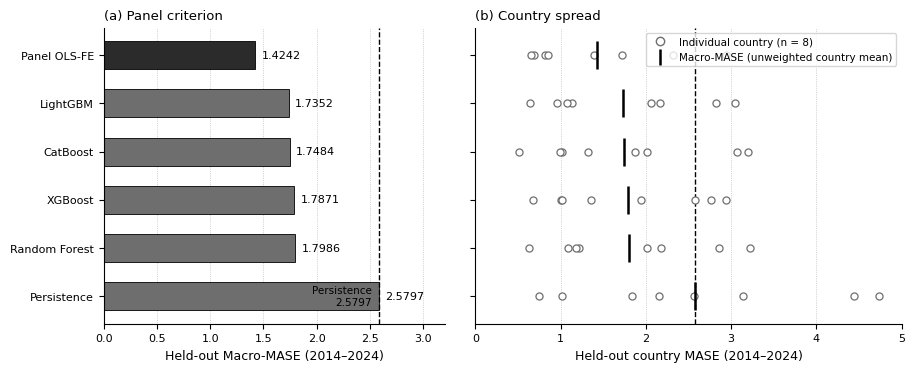


Figure 2 successfully created.


In [15]:
# ============================================================
# FIGURE 2 — STAGE-A MACRO-MASE AND COUNTRY SPREAD
# ============================================================
# Run after Cell 14. Reuse its outputs without changing results.
# Save to the project figure folder, not a Colab-specific path.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1. Read the existing metrics and order methods by Macro-MASE
summary = stage_a_skill_summary.set_index("Method")
country_data = country_mase_wide.apply(pd.to_numeric)
methods = summary["Macro_MASE"].sort_values().index.tolist()
country_data = country_data[methods]

# Do not overwrite the macro_mase() scoring function.
macro_mase_values = summary.loc[methods, "Macro_MASE"]
calculated_means = country_data.mean(axis=0)


# 2. Check that country means reproduce the reported Macro-MASE
for method in methods:
    difference = abs(calculated_means[method] - macro_mase_values[method])
    print(
        f"{method}: calculated={calculated_means[method]:.4f}, "
        f"published={macro_mase_values[method]:.4f}, "
        f"difference={difference:.6f}"
    )
    assert difference <= 0.0006

print("\nAll Macro-MASE checks passed.")
print("\nCatBoost per-country MASE:")
display(country_data[["CatBoost"]].sort_values("CatBoost"))


# 3. Create the original two-panel layout
y = np.arange(len(methods))
persistence_ref = float(summary.loc["Persistence", "Macro_MASE"])

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(9.5, 4.0), sharey=True,
    gridspec_kw={"width_ratios": [1.0, 1.25], "wspace": 0.08},
)
dark_grey = "#2b2b2b"
mid_grey = "#6e6e6e"


# 4. Panel (a): panel-level Macro-MASE
for i, method in enumerate(methods):
    value = float(macro_mase_values[method])
    colour = dark_grey if method == "Panel OLS-FE" else mid_grey

    ax1.barh(
        i, value, height=0.58, color=colour,
        edgecolor="black", linewidth=0.6,
    )
    ax1.text(value + 0.06, i, f"{value:.4f}", va="center", fontsize=8)

ax1.axvline(persistence_ref, color="black", linestyle="--", linewidth=1.0)
ax1.text(
    persistence_ref - 0.06, len(methods) - 1.0,
    f"Persistence\n{persistence_ref:.4f}",
    ha="right", va="center", fontsize=7.5,
)
ax1.set_yticks(y)
ax1.set_yticklabels(methods, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlim(0, 3.2)
ax1.set_xlabel("Held-out Macro-MASE (2014–2024)", fontsize=9)
ax1.set_title("(a) Panel criterion", loc="left", fontsize=9.5)
ax1.grid(axis="x", linestyle=":", linewidth=0.5)
ax1.set_axisbelow(True)


# 5. Panel (b): individual-country MASE and its unweighted mean
for i, method in enumerate(methods):
    values = country_data[method].dropna().to_numpy(dtype=float)

    ax2.scatter(
        values, np.full(len(values), i), s=26,
        facecolors="white", edgecolors=mid_grey,
        linewidths=0.9, zorder=3,
    )
    ax2.scatter(
        [macro_mase_values[method]], [i], marker="|", s=420,
        color="black", linewidths=1.8, zorder=4,
    )

ax2.axvline(persistence_ref, color="black", linestyle="--", linewidth=1.0)
ax2.set_xlim(0, 5.0)
ax2.set_xlabel("Held-out country MASE (2014–2024)", fontsize=9)
ax2.set_title("(b) Country spread", loc="left", fontsize=9.5)
ax2.grid(axis="x", linestyle=":", linewidth=0.5)
ax2.set_axisbelow(True)
ax2.tick_params(axis="y", labelleft=False)


# 6. Legend and final formatting
legend_items = [
    plt.Line2D(
        [], [], marker="o", linestyle="none",
        markerfacecolor="white", markeredgecolor=mid_grey,
        markersize=6, label="Individual country (n = 8)",
    ),
    plt.Line2D(
        [], [], marker="|", linestyle="none", color="black",
        markersize=11, markeredgewidth=1.8,
        label="Macro-MASE (unweighted country mean)",
    ),
]
ax2.legend(
    handles=legend_items, fontsize=7.5,
    loc="upper right", frameon=True,
)

for ax in (ax1, ax2):
    ax.tick_params(labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.subplots_adjust(left=0.145, right=0.985, top=0.90, bottom=0.16)


# 7. Save the same PNG and PDF filenames in FIGURES_DIR
fig.savefig(
    FIGURES_DIR / "figure2_stage_a_comparison.png",
    dpi=400, bbox_inches="tight", facecolor="white",
)
fig.savefig(
    FIGURES_DIR / "figure2_stage_a_comparison.pdf",
    bbox_inches="tight", facecolor="white",
)

plt.show()
print("\nFigure 2 successfully created.")

**Cell 15 — historical HAC/Holm sensitivity.** Its `p = 0.0061` and “main Table 4.3” label predate article Table 2 and Supplement §S8. Use Cell 38 (Driscoll–Kraay `p = 0.0047`).


In [16]:
# ============================================================
# CELL 15 — DM-STYLE HAC LOSS TESTS + HOLM CORRECTION
# ============================================================
# Run after Cell 14, with statsmodels installed.
# Compare annual country-normalized losses, using 11 held-out years.
# Primary: HAC(1). Sensitivity: HAC(0) and HAC(2).
# Keep small-sample correction, t-based inference and six-test Holm families.
# This is a DM-style HAC comparison, not an exact textbook DM test.
# No predictive model is trained or re-selected.

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests


# 1. Average country-normalized absolute errors within each year
yearly_loss_rows = []

for method in METHOD_ORDER:
    scored = STAGE_A_HOLDOUT_PREDICTIONS[method].copy()
    denominators = scored["country"].map(DEVELOPMENT_DENOMINATORS).astype(float)
    assert denominators.notna().all()
    assert (denominators > 0).all()

    scored["Scaled_Absolute_Error"] = (
        (scored["actual_co2"] - scored["pred_co2"]).abs() / denominators
    )
    yearly = (
        scored.groupby("year")
        .agg(
            N_Countries=("country", "nunique"),
            Yearly_Normalized_Loss=("Scaled_Absolute_Error", "mean"),
        )
        .reset_index()
    )
    assert len(yearly) == 11
    assert (yearly["N_Countries"] == 8).all()
    assert int(yearly["year"].min()) == TEST_START
    assert int(yearly["year"].max()) == TEST_END

    # For this balanced panel, the mean annual loss equals Macro-MASE.
    method_macro_mase = macro_mase(scored, DEVELOPMENT_DENOMINATORS)
    assert np.isclose(
        yearly["Yearly_Normalized_Loss"].mean(), method_macro_mase,
        rtol=1e-10, atol=1e-12,
    )
    yearly["Method"] = method
    yearly_loss_rows.append(yearly)

stage_a_yearly_losses = pd.concat(yearly_loss_rows, ignore_index=True)


# 2. Test the mean annual loss difference with HAC standard errors
def hac_loss_difference_test(method, reference, maxlags=1):
    """Compare method loss minus reference loss using constant-only OLS.

    Negative differences favour the method; positive ones favour the
    reference. Keep HAC correction and two-sided t-based inference.
    """
    method_loss = (
        stage_a_yearly_losses[stage_a_yearly_losses["Method"] == method]
        [["year", "Yearly_Normalized_Loss"]]
        .rename(columns={"Yearly_Normalized_Loss": "Method_Loss"})
    )
    reference_loss = (
        stage_a_yearly_losses[stage_a_yearly_losses["Method"] == reference]
        [["year", "Yearly_Normalized_Loss"]]
        .rename(columns={"Yearly_Normalized_Loss": "Reference_Loss"})
    )
    comparison = (
        method_loss.merge(
            reference_loss, on="year", how="inner", validate="one_to_one"
        )
        .sort_values("year")
        .reset_index(drop=True)
    )
    assert len(comparison) == 11
    comparison["Loss_Difference"] = (
        comparison["Method_Loss"] - comparison["Reference_Loss"]
    )
    d = comparison["Loss_Difference"].to_numpy(dtype=float)
    assert np.isfinite(d).all()

    X = np.ones((len(d), 1), dtype=float)
    fit = sm.OLS(d, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": int(maxlags), "use_correction": True},
        use_t=True,
    )
    mean_diff = float(fit.params[0])
    hac_se = float(fit.bse[0])
    statistic = float(fit.tvalues[0])
    p_value = float(fit.pvalues[0])
    ci = fit.conf_int(alpha=0.05)[0]

    return {
        "Method": method,
        "Reference": reference,
        "Comparison": f"{method} vs {reference}",
        "N_Years": len(d),
        "HAC_Lag": int(maxlags),
        "Method_Mean_Loss": float(comparison["Method_Loss"].mean()),
        "Reference_Mean_Loss": float(comparison["Reference_Loss"].mean()),
        "Mean_Loss_Difference": mean_diff,
        "HAC_SE": hac_se,
        "HAC_t": statistic,
        "P_Value_Two_Sided": p_value,
        "CI95_Lower": float(ci[0]),
        "CI95_Upper": float(ci[1]),
    }


# 3. Keep the original six-comparison family
comparisons = [(method, "Persistence") for method in METHOD_ORDER if method != "Persistence"]
comparisons.append((FROZEN_STAGE_A_WINNER, "Panel OLS-FE"))
assert len(comparisons) == len(set(comparisons))
assert len(comparisons) == 6


# 4. Primary HAC(1) tests
dm_rows = [
    hac_loss_difference_test(method=method, reference=reference, maxlags=1)
    for method, reference in comparisons
]
stage_a_dm_hac = pd.DataFrame(dm_rows)


# 5. Holm correction across the six primary tests
reject, adjusted_p, _, _ = multipletests(
    stage_a_dm_hac["P_Value_Two_Sided"].to_numpy(dtype=float),
    alpha=0.05, method="holm",
)
stage_a_dm_hac["Holm_Adjusted_P"] = adjusted_p
stage_a_dm_hac["Reject_5pct_After_Holm"] = reject
stage_a_dm_hac["Lower_Loss_Method"] = np.where(
    stage_a_dm_hac["Mean_Loss_Difference"] < 0,
    stage_a_dm_hac["Method"], stage_a_dm_hac["Reference"],
)


# 5B. Apply Holm separately to the same six tests at each HAC lag
hac_sensitivity_tables = []

for hac_lag in [0, 1, 2]:
    lag_rows = [
        hac_loss_difference_test(method=method, reference=reference, maxlags=hac_lag)
        for method, reference in comparisons
    ]
    lag_table = pd.DataFrame(lag_rows)
    lag_reject, lag_adjusted_p, _, _ = multipletests(
        lag_table["P_Value_Two_Sided"].to_numpy(dtype=float),
        alpha=0.05, method="holm",
    )
    lag_table["Holm_Adjusted_P"] = lag_adjusted_p
    lag_table["Reject_5pct_After_Holm"] = lag_reject
    hac_sensitivity_tables.append(lag_table)

stage_a_dm_hac_sensitivity = pd.concat(hac_sensitivity_tables, ignore_index=True)
assert len(stage_a_dm_hac_sensitivity) == 18


# 5C. Confirm that sensitivity HAC(1) reproduces the primary decisions
_lag1_p_check = (
    stage_a_dm_hac_sensitivity[stage_a_dm_hac_sensitivity["HAC_Lag"] == 1]
    .set_index("Comparison")["Holm_Adjusted_P"]
)
_main_p_check = stage_a_dm_hac.set_index("Comparison")["Holm_Adjusted_P"]
assert np.allclose(
    _lag1_p_check.reindex(_main_p_check.index).to_numpy(dtype=float),
    _main_p_check.to_numpy(dtype=float),
)

_lag1_reject_check = (
    stage_a_dm_hac_sensitivity[stage_a_dm_hac_sensitivity["HAC_Lag"] == 1]
    .set_index("Comparison")["Reject_5pct_After_Holm"]
)
_main_reject_check = stage_a_dm_hac.set_index("Comparison")["Reject_5pct_After_Holm"]
assert np.array_equal(
    _lag1_reject_check.reindex(_main_reject_check.index).to_numpy(dtype=bool),
    _main_reject_check.to_numpy(dtype=bool),
)


# 5D. Compare Holm decisions across lags 0, 1 and 2
holm_wide = (
    stage_a_dm_hac_sensitivity
    .pivot(index="Comparison", columns="HAC_Lag", values="Holm_Adjusted_P")
    .rename(columns={0: "HAC0_Holm_P", 1: "HAC1_Holm_P", 2: "HAC2_Holm_P"})
)
reject_wide = (
    stage_a_dm_hac_sensitivity
    .pivot(index="Comparison", columns="HAC_Lag", values="Reject_5pct_After_Holm")
    .rename(columns={0: "HAC0_Reject", 1: "HAC1_Reject", 2: "HAC2_Reject"})
)
stage_a_dm_hac_robustness = (
    stage_a_dm_hac[["Comparison", "Mean_Loss_Difference"]]
    .set_index("Comparison")
    .join(holm_wide)
    .join(reject_wide)
    .reset_index()
)
stage_a_dm_hac_robustness["Decision_Stable_0_1_2"] = (
    (stage_a_dm_hac_robustness["HAC0_Reject"] == stage_a_dm_hac_robustness["HAC1_Reject"])
    & (stage_a_dm_hac_robustness["HAC1_Reject"] == stage_a_dm_hac_robustness["HAC2_Reject"])
)
N_STABLE_DECISIONS = int(stage_a_dm_hac_robustness["Decision_Stable_0_1_2"].sum())


# 6. Preserve the original numerical reproduction checks
EXPECTED_MEAN_DIFFERENCES = {
    "Panel OLS-FE vs Persistence": -1.1554,
    "LightGBM vs Persistence": -0.8445,
    "CatBoost vs Persistence": -0.8313,
    "XGBoost vs Persistence": -0.7926,
    "Random Forest vs Persistence": -0.7810,
    "CatBoost vs Panel OLS-FE": 0.3242,
}
reproduction_rows = []

for comparison_name, expected_value in EXPECTED_MEAN_DIFFERENCES.items():
    observed_value = float(
        stage_a_dm_hac.loc[
            stage_a_dm_hac["Comparison"] == comparison_name, "Mean_Loss_Difference"
        ].iloc[0]
    )
    reproduction_rows.append({
        "Comparison": comparison_name,
        "Expected_Mean_Difference": expected_value,
        "Observed_Mean_Difference": observed_value,
        "Difference": observed_value - expected_value,
    })

stage_a_dm_hac_reproduction = pd.DataFrame(reproduction_rows)
assert (stage_a_dm_hac_reproduction["Difference"].abs() < 5e-4).all()


# 7. Confirm that held-out testing did not change the CV winner
assert STAGE_A_WINNER == FROZEN_STAGE_A_WINNER
assert STAGE_A_WINNER_CONFIG_ID == FROZEN_STAGE_A_CONFIG_ID
assert stage_a_selection_register.iloc[0]["Heldout_Used"] == False


# 8. Format small p-values for display only
def format_p_value(p):
    """Display p < 0.001 as '<.001'; otherwise use four decimals."""
    p = float(p)
    if p < 0.001:
        return "<.001"
    return f"{p:.4f}"


stage_a_dm_hac_main = stage_a_dm_hac[[
    "Method", "Reference", "N_Years", "HAC_Lag", "Mean_Loss_Difference",
    "HAC_t", "P_Value_Two_Sided", "Holm_Adjusted_P", "Reject_5pct_After_Holm",
]].copy()
stage_a_dm_hac_display = stage_a_dm_hac_main.copy()
stage_a_dm_hac_display["Display_Reference"] = (
    stage_a_dm_hac_display["Reference"].replace({
        "Panel OLS-FE": "Panel OLS-FE (conditional one-step)",
    })
)
stage_a_dm_hac_display["Raw_P"] = stage_a_dm_hac_display["P_Value_Two_Sided"].map(format_p_value)
stage_a_dm_hac_display["Holm_P"] = stage_a_dm_hac_display["Holm_Adjusted_P"].map(format_p_value)


# 9. Save the same five CSV files at full numeric precision
stage_a_yearly_losses.to_csv(TABLES_DIR / "stage_a_yearly_normalized_losses.csv", index=False)
stage_a_dm_hac.to_csv(TABLES_DIR / "table_4_3_stage_a_dm_hac.csv", index=False)
stage_a_dm_hac_sensitivity.to_csv(
    TABLES_DIR / "appendix_stage_a_dm_hac_lag_sensitivity.csv", index=False
)
stage_a_dm_hac_robustness.to_csv(
    TABLES_DIR / "appendix_stage_a_dm_hac_lag_robustness.csv", index=False
)
stage_a_dm_hac_reproduction.to_csv(
    TABLES_DIR / "stage_a_dm_hac_reproduction_check.csv", index=False
)


# 10. Report with the original text, order and table formats
print("=" * 78)
print("CELL 15 — DM-STYLE HAC LOSS TESTS + HOLM CORRECTION")
print("=" * 78)

print("\nTEST DESIGN")
print("  Loss function : country-normalized absolute error")
print("  Time unit     : calendar year after averaging across 8 countries")
print("  Test sample   : 2014-2024 (N = 11 annual loss differentials)")
print("  Primary HAC   : lag 1")
print("  Sensitivity   : HAC lags 0 and 2")
print("  Small-sample correction : enabled")
print(f"  P-values      : two-sided; Holm correction across {len(comparisons)} comparisons")

print("\n[Table 4.3] DM-STYLE HAC COMPARISONS — PRIMARY HAC(1)")
display(
    stage_a_dm_hac_display[[
        "Method", "Display_Reference", "N_Years", "Mean_Loss_Difference",
        "HAC_t", "Raw_P", "Holm_P", "Reject_5pct_After_Holm",
    ]].style.format({"Mean_Loss_Difference": "{:+.4f}", "HAC_t": "{:+.3f}"})
)

print("\nINTERPRETATION KEY")
print("  Mean loss difference < 0 : Method has lower normalized loss")
print("  Mean loss difference > 0 : Reference has lower normalized loss")
print(
    "  Holm-adjusted p < 0.05    : evidence of a loss difference "
    "after multiplicity correction"
)

print("\nHAC LAG SENSITIVITY — HOLM-ADJUSTED P-VALUES")
_robustness_display = stage_a_dm_hac_robustness.copy()
for _col in ["HAC0_Holm_P", "HAC1_Holm_P", "HAC2_Holm_P"]:
    _robustness_display[_col] = _robustness_display[_col].map(format_p_value)

display(
    _robustness_display[[
        "Comparison", "Mean_Loss_Difference", "HAC0_Holm_P",
        "HAC1_Holm_P", "HAC2_Holm_P", "Decision_Stable_0_1_2",
    ]].style.format({"Mean_Loss_Difference": "{:+.4f}"})
)
print(
    f"  Decisions stable across lags 0, 1 and 2: "
    f"{N_STABLE_DECISIONS} of {len(stage_a_dm_hac_robustness)}"
)
print(
    "  HAC(1) is the primary specification; lags 0 and 2 are "
    "reported as sensitivity checks only."
)


# 11. Keep the frozen winner's two key comparisons
catboost_vs_persistence = stage_a_dm_hac[
    (stage_a_dm_hac["Method"] == FROZEN_STAGE_A_WINNER)
    & (stage_a_dm_hac["Reference"] == "Persistence")
].iloc[0]
catboost_vs_ols = stage_a_dm_hac[
    (stage_a_dm_hac["Method"] == FROZEN_STAGE_A_WINNER)
    & (stage_a_dm_hac["Reference"] == "Panel OLS-FE")
].iloc[0]

print(f"\nFROZEN {FROZEN_STAGE_A_WINNER.upper()} — KEY COMPARISONS")
print(
    f"  vs Persistence: mean loss difference "
    f"{catboost_vs_persistence['Mean_Loss_Difference']:+.4f}, "
    f"Holm p={format_p_value(catboost_vs_persistence['Holm_Adjusted_P'])}"
)
print(
    "  vs Panel OLS-FE (conditional one-step): mean loss difference "
    f"{catboost_vs_ols['Mean_Loss_Difference']:+.4f}, "
    f"Holm p={format_p_value(catboost_vs_ols['Holm_Adjusted_P'])}"
)

print("\nREPRODUCTION CHECK")
display(
    stage_a_dm_hac_reproduction.style.format({
        "Expected_Mean_Difference": "{:+.4f}",
        "Observed_Mean_Difference": "{:+.4f}",
        "Difference": "{:+.6f}",
    })
)

print("\nSMALL-SAMPLE CAUTION")
print("  The test uses only 11 annual observations.")
print(
    "  HAC lag 1 is the parsimonious primary specification "
    "given this sample size."
)
print(
    "  Lags 0 and 2 are reported as sensitivity checks: the "
    "underlying forecast errors are one-step and non-overlapping, "
    "but the loss differential series can still carry serial dependence."
)
print(
    "  Non-rejection is not interpreted as evidence that methods are equivalent."
)
print(
    "  This is a DM-style HAC loss comparison, not an exact "
    "textbook Diebold-Mariano test."
)

print("\nBENCHMARK CLARIFICATION")
print("  Panel OLS-FE here is the CONDITIONAL ONE-STEP benchmark from Cell 13.")
print(
    "  The later operational Panel OLS-FE benchmark uses "
    "projected drivers and a recursive CO2 lag, and answers a "
    "different forecasting question."
)

print("\nSTAGE-A INTEGRITY")
print(f"  Frozen winner : {FROZEN_STAGE_A_WINNER} (Config {FROZEN_STAGE_A_CONFIG_ID})")
print("  ✓ Held-out results did not trigger model switching")
print("  ✓ No hyperparameter was changed")
print("  ✓ No selection criterion was changed")
print("  ✓ Stage-A winner remains fixed for SHAP")
print("  ✓ HAC(1) sensitivity-table results reproduce the main table")

print("\nObjects created:")
print("  stage_a_yearly_losses")
print("  stage_a_dm_hac")
print("  stage_a_dm_hac_main")
print("  stage_a_dm_hac_display")
print("  stage_a_dm_hac_sensitivity")
print("  stage_a_dm_hac_robustness")
print("  stage_a_dm_hac_reproduction")
print("  hac_loss_difference_test()")
print("  format_p_value()")
print(
    "\nOUTPUTS: "
    "Table 4.3 DM-style HAC comparisons (lag 1) → Main text | "
    "HAC lag 0/1/2 robustness + year-level normalized losses "
    "→ Appendix | "
    "reproduction check + integrity statement → Notebook only"
)


CELL 15 — DM-STYLE HAC LOSS TESTS + HOLM CORRECTION

TEST DESIGN
  Loss function : country-normalized absolute error
  Time unit     : calendar year after averaging across 8 countries
  Test sample   : 2014-2024 (N = 11 annual loss differentials)
  Primary HAC   : lag 1
  Sensitivity   : HAC lags 0 and 2
  Small-sample correction : enabled
  P-values      : two-sided; Holm correction across 6 comparisons

[Table 4.3] DM-STYLE HAC COMPARISONS — PRIMARY HAC(1)


,Method,Display_Reference,N_Years,Mean_Loss_Difference,HAC_t,Raw_P,Holm_P,Reject_5pct_After_Holm
0,Panel OLS-FE,Persistence,11,-1.1554,-7.080,<.001,<.001,True
1,LightGBM,Persistence,11,-0.8445,-6.514,<.001,<.001,True
2,CatBoost,Persistence,11,-0.8313,-7.587,<.001,<.001,True
3,XGBoost,Persistence,11,-0.7926,-5.453,<.001,<.001,True
4,Random Forest,Persistence,11,-0.7810,-7.568,<.001,<.001,True
5,CatBoost,Panel OLS-FE (conditional one-step),11,+0.3242,+3.467,0.0061,0.0061,True



INTERPRETATION KEY
  Mean loss difference < 0 : Method has lower normalized loss
  Mean loss difference > 0 : Reference has lower normalized loss
  Holm-adjusted p < 0.05    : evidence of a loss difference after multiplicity correction

HAC LAG SENSITIVITY — HOLM-ADJUSTED P-VALUES


,Comparison,Mean_Loss_Difference,HAC0_Holm_P,HAC1_Holm_P,HAC2_Holm_P,Decision_Stable_0_1_2
0,Panel OLS-FE vs Persistence,-1.1554,<.001,<.001,<.001,True
1,LightGBM vs Persistence,-0.8445,<.001,<.001,<.001,True
2,CatBoost vs Persistence,-0.8313,<.001,<.001,<.001,True
3,XGBoost vs Persistence,-0.7926,0.0020,<.001,<.001,True
4,Random Forest vs Persistence,-0.7810,<.001,<.001,<.001,True
5,CatBoost vs Panel OLS-FE,+0.3242,0.0213,0.0061,0.0015,True


  Decisions stable across lags 0, 1 and 2: 6 of 6
  HAC(1) is the primary specification; lags 0 and 2 are reported as sensitivity checks only.

FROZEN CATBOOST — KEY COMPARISONS
  vs Persistence: mean loss difference -0.8313, Holm p=<.001
  vs Panel OLS-FE (conditional one-step): mean loss difference +0.3242, Holm p=0.0061

REPRODUCTION CHECK


,Comparison,Expected_Mean_Difference,Observed_Mean_Difference,Difference
0,Panel OLS-FE vs Persistence,-1.1554,-1.1554,-0.000042
1,LightGBM vs Persistence,-0.8445,-0.8445,+0.000021
2,CatBoost vs Persistence,-0.8313,-0.8313,+0.000020
3,XGBoost vs Persistence,-0.7926,-0.7926,-0.000009
4,Random Forest vs Persistence,-0.7810,-0.7810,-0.000029
5,CatBoost vs Panel OLS-FE,+0.3242,+0.3242,-0.000039



SMALL-SAMPLE CAUTION
  The test uses only 11 annual observations.
  HAC lag 1 is the parsimonious primary specification given this sample size.
  Lags 0 and 2 are reported as sensitivity checks: the underlying forecast errors are one-step and non-overlapping, but the loss differential series can still carry serial dependence.
  Non-rejection is not interpreted as evidence that methods are equivalent.
  This is a DM-style HAC loss comparison, not an exact textbook Diebold-Mariano test.

BENCHMARK CLARIFICATION
  Panel OLS-FE here is the CONDITIONAL ONE-STEP benchmark from Cell 13.
  The later operational Panel OLS-FE benchmark uses projected drivers and a recursive CO2 lag, and answers a different forecasting question.

STAGE-A INTEGRITY
  Frozen winner : CatBoost (Config 15)
  ✓ Held-out results did not trigger model switching
  ✓ No hyperparameter was changed
  ✓ No selection criterion was changed
  ✓ Stage-A winner remains fixed for SHAP
  ✓ HAC(1) sensitivity-table results reproduc

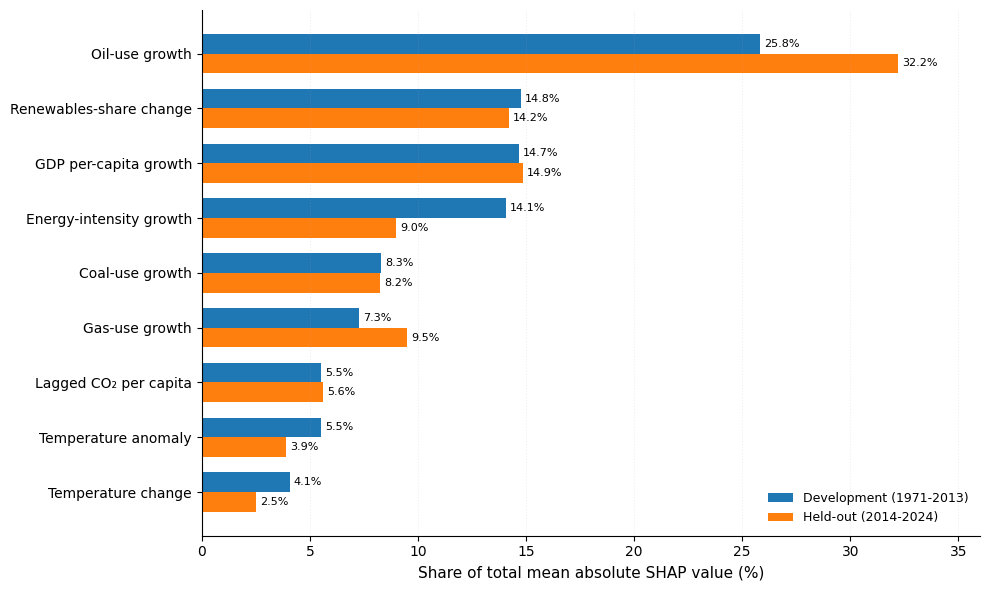

CELL 16 — SHAP GLOBAL EXPLAINABILITY & STABILITY

Model explained : CatBoost (Config 15)
Selected by     : development CV only, years <= 2013
Primary SHAP    : development sample
Held-out SHAP   : stability check only
SHAP scale      : contribution to predicted delta-log CO2

[Table 4.4] GLOBAL SHAP IMPORTANCE


,Display_Feature,Group,Percent_Dev,Rank_Dev,Percent_Test,Rank_Test,Rank_Shift
0,Oil-use growth,Energy consumption,25.82%,1,32.22%,1,0
1,Renewables-share change,Energy structure,14.78%,2,14.22%,3,1
2,GDP per-capita growth,Economic,14.66%,3,14.86%,2,-1
3,Energy-intensity growth,Energy-economic,14.05%,4,8.99%,5,1
4,Coal-use growth,Energy consumption,8.31%,5,8.24%,6,1
5,Gas-use growth,Energy consumption,7.28%,6,9.48%,4,-2
6,Lagged CO₂ per capita,Autoregressive state,5.52%,7,5.60%,7,0
7,Temperature anomaly,Climate,5.51%,8,3.90%,8,0
8,Temperature change,Climate,4.07%,9,2.49%,9,0



TRAIN–HELDOUT RANK STABILITY
  Spearman rho       : 0.9333
  p-value            : 0.0002
  Largest rank shift : 2
  Importance rankings show high concordance between development and held-out periods.

IMPORTANCE BY INDICATOR GROUP


,Percent_Dev,Percent_Test
Group,,
Energy consumption,41.41%,49.94%
Energy structure,14.78%,14.22%
Economic,14.66%,14.86%
Energy-economic,14.05%,8.99%
Climate,9.58%,6.40%
Autoregressive state,5.52%,5.60%



TOP-3 DEVELOPMENT SHAP FEATURES
  1. Oil-use growth
  2. Renewables-share change
  3. GDP per-capita growth

ADDITIVITY AUDIT
  Development max error : 4.44e-16
  Held-out max error    : 1.67e-16

INTERPRETATION NOTE
  SHAP describes how the fitted CatBoost model uses the predictors.
  It does not identify causal effects on CO2 emissions.
  Correlated predictors can share attribution, so individual feature importance should be interpreted alongside grouped results.

✓ Development sample is the primary explanation basis
✓ Held-out SHAP used only as a stability check
✓ Top-3 features selected from development ranking only
✓ Development bars shown above held-out bars
✓ Percentage labels shown directly on Figure 4.2
✓ No model or feature selection used held-out SHAP
✓ SHAP interpreted as predictive, not causal

OUTPUTS: Table 4.4 SHAP importance/stability → Main text | Figure 4.2 global SHAP importance → Main text | group importance → Main text/Appendix | raw SHAP arrays/additivity audit 

In [17]:
# ============================================================
# CELL 16 — SHAP GLOBAL EXPLAINABILITY & STABILITY
# ============================================================
# Run after Cells 13–15, with SHAP installed.
# Explain the frozen Stage-A CatBoost model on the delta-log CO2 scale.
# Development SHAP is primary; held-out SHAP checks stability only.
# Select the top three explanatory features from development SHAP only.
# SHAP describes predictive behaviour, not causal effects.
# Keep calculations, labels, figure settings and output filenames unchanged.

import shap
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# 1. Check the frozen model and prepare the same feature matrices
assert STAGE_A_WINNER == FROZEN_STAGE_A_WINNER
assert FROZEN_STAGE_A_WINNER == "CatBoost"
SHAP_MODEL_NAME = FROZEN_STAGE_A_WINNER
shap_model = STAGE_A_FITTED_MODELS[SHAP_MODEL_NAME]

X_shap_dev = stage_a_full_train[PRIMARY_FEATURES].astype(float).copy()
X_shap_test = stage_a_holdout[PRIMARY_FEATURES].astype(float).copy()
assert len(X_shap_dev) == 343
assert len(X_shap_test) == 88
assert np.isfinite(X_shap_dev.to_numpy()).all()
assert np.isfinite(X_shap_test.to_numpy()).all()


# 2. Compute SHAP values without refitting the model
explainer = shap.TreeExplainer(shap_model)
shap_dev = np.asarray(explainer.shap_values(X_shap_dev), dtype=float)
shap_test = np.asarray(explainer.shap_values(X_shap_test), dtype=float)
assert shap_dev.shape == X_shap_dev.shape
assert shap_test.shape == X_shap_test.shape
assert np.isfinite(shap_dev).all()
assert np.isfinite(shap_test).all()


# 3. Verify that base value + SHAP contributions reconstruct predictions
base_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])
dev_prediction = np.asarray(shap_model.predict(X_shap_dev), dtype=float)
test_prediction = np.asarray(shap_model.predict(X_shap_test), dtype=float)
dev_reconstruction = base_value + shap_dev.sum(axis=1)
test_reconstruction = base_value + shap_test.sum(axis=1)
dev_additivity_error = float(np.max(np.abs(dev_prediction - dev_reconstruction)))
test_additivity_error = float(np.max(np.abs(test_prediction - test_reconstruction)))
assert dev_additivity_error < 1e-4
assert test_additivity_error < 1e-4


# 4. Calculate global importance and feature ranks
def importance_table(shap_values, label):
    """Return each feature's mean absolute SHAP value and percentage share."""
    mean_abs = np.mean(np.abs(shap_values), axis=0)
    return pd.DataFrame({
        "Feature": PRIMARY_FEATURES,
        f"Mean_Abs_SHAP_{label}": mean_abs,
        f"Percent_{label}": mean_abs / mean_abs.sum() * 100,
    })


shap_importance = importance_table(shap_dev, "Dev").merge(
    importance_table(shap_test, "Test"), on="Feature"
)
shap_importance["Rank_Dev"] = (
    shap_importance["Mean_Abs_SHAP_Dev"].rank(ascending=False, method="min").astype(int)
)
shap_importance["Rank_Test"] = (
    shap_importance["Mean_Abs_SHAP_Test"].rank(ascending=False, method="min").astype(int)
)
shap_importance["Rank_Shift"] = shap_importance["Rank_Test"] - shap_importance["Rank_Dev"]
shap_importance = shap_importance.sort_values("Rank_Dev").reset_index(drop=True)


# 5. Compare development and held-out feature rankings
rank_corr, rank_p = spearmanr(shap_importance["Rank_Dev"], shap_importance["Rank_Test"])
rank_corr = float(rank_corr)
rank_p = float(rank_p)
max_rank_shift = int(shap_importance["Rank_Shift"].abs().max())


# 6. Aggregate percentage shares within the original feature groups
FEATURE_GROUPS = {
    "energy_intensity_growth": "Energy-economic",
    "oil_energy_per_capita_growth": "Energy consumption",
    "coal_cons_per_capita_growth": "Energy consumption",
    "gas_energy_per_capita_growth": "Energy consumption",
    "renewables_share_change": "Energy structure",
    "gdp_per_capita_growth": "Economic",
    "temperature_anomaly": "Climate",
    "temp_change": "Climate",
    "co2_lag1": "Autoregressive state",
}
shap_importance["Group"] = shap_importance["Feature"].map(FEATURE_GROUPS)
assert shap_importance["Group"].notna().all()
shap_group_importance = (
    shap_importance.groupby("Group")[["Percent_Dev", "Percent_Test"]]
    .sum()
    .sort_values("Percent_Dev", ascending=False)
)


# 7. Choose the top three from development importance, never held-out ranks
SHAP_TOP3_FEATURES = shap_importance.sort_values("Rank_Dev")["Feature"].head(3).tolist()
assert len(SHAP_TOP3_FEATURES) == 3


# 8. Keep the original human-readable feature labels
SHAP_FEATURE_LABELS = {
    "energy_intensity_growth": "Energy-intensity growth",
    "oil_energy_per_capita_growth": "Oil-use growth",
    "coal_cons_per_capita_growth": "Coal-use growth",
    "gas_energy_per_capita_growth": "Gas-use growth",
    "renewables_share_change": "Renewables-share change",
    "gdp_per_capita_growth": "GDP per-capita growth",
    "temperature_anomaly": "Temperature anomaly",
    "temp_change": "Temperature change",
    "co2_lag1": "Lagged CO₂ per capita",
}
shap_importance["Display_Feature"] = shap_importance["Feature"].map(SHAP_FEATURE_LABELS)
assert shap_importance["Display_Feature"].notna().all()


# 9. Figure 4.2: development bar above held-out bar in each pair
plot_df = shap_importance.sort_values("Percent_Dev", ascending=True).copy()
y = np.arange(len(plot_df))
bar_height = 0.36
fig, ax = plt.subplots(figsize=(10, 6))

bars_dev = ax.barh(
    y + bar_height / 2, plot_df["Percent_Dev"], height=bar_height,
    label=f"Development ({TRAIN_START}-{TRAIN_END})",
)
bars_test = ax.barh(
    y - bar_height / 2, plot_df["Percent_Test"], height=bar_height,
    label=f"Held-out ({TEST_START}-{TEST_END})",
)
ax.bar_label(
    bars_dev, labels=[f"{value:.1f}%" for value in plot_df["Percent_Dev"]],
    padding=3, fontsize=8,
)
ax.bar_label(
    bars_test, labels=[f"{value:.1f}%" for value in plot_df["Percent_Test"]],
    padding=3, fontsize=8,
)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["Display_Feature"], fontsize=10)
ax.set_xlabel("Share of total mean absolute SHAP value (%)", fontsize=11)
ax.set_xlim(0, 36)
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.20, linestyle=":")
fig.tight_layout()

SHAP_IMPORTANCE_PNG = FIGURES_DIR / "fig_4_2_shap_global_importance.png"
SHAP_IMPORTANCE_PDF = FIGURES_DIR / "fig_4_2_shap_global_importance.pdf"
fig.savefig(SHAP_IMPORTANCE_PNG, dpi=300, bbox_inches="tight")
fig.savefig(SHAP_IMPORTANCE_PDF, bbox_inches="tight")
plt.show()


# 10. Save full-precision importance, stability and raw SHAP values
shap_importance.to_csv(TABLES_DIR / "table_4_4_shap_importance.csv", index=False)
shap_group_importance.to_csv(TABLES_DIR / "shap_importance_by_group.csv")
shap_stability_summary = pd.DataFrame([{
    "Model": SHAP_MODEL_NAME,
    "Development_N": len(X_shap_dev),
    "Heldout_N": len(X_shap_test),
    "Spearman_Rank_Correlation": rank_corr,
    "Spearman_P_Value": rank_p,
    "Largest_Absolute_Rank_Shift": max_rank_shift,
    "Development_Max_Additivity_Error": dev_additivity_error,
    "Heldout_Max_Additivity_Error": test_additivity_error,
    "Top3_Selected_From": "Development SHAP ranking",
    "Top3_Features": ", ".join(SHAP_TOP3_FEATURES),
}])
shap_stability_summary.to_csv(TABLES_DIR / "shap_stability_summary.csv", index=False)
np.save(TABLES_DIR / "shap_values_development.npy", shap_dev)
np.save(TABLES_DIR / "shap_values_holdout.npy", shap_test)


# 11. Report with the original text and display formats
print("=" * 78)
print("CELL 16 — SHAP GLOBAL EXPLAINABILITY & STABILITY")
print("=" * 78)
print(f"\nModel explained : {SHAP_MODEL_NAME} (Config {FROZEN_STAGE_A_CONFIG_ID})")
print(f"Selected by     : development CV only, years <= {TRAIN_END}")
print("Primary SHAP    : development sample")
print("Held-out SHAP   : stability check only")
print("SHAP scale      : contribution to predicted delta-log CO2")

print("\n[Table 4.4] GLOBAL SHAP IMPORTANCE")
display(
    shap_importance[[
        "Display_Feature", "Group", "Percent_Dev", "Rank_Dev",
        "Percent_Test", "Rank_Test", "Rank_Shift",
    ]].style.format({"Percent_Dev": "{:.2f}%", "Percent_Test": "{:.2f}%"})
)

print("\nTRAIN–HELDOUT RANK STABILITY")
print(f"  Spearman rho       : {rank_corr:.4f}")
print(f"  p-value            : {rank_p:.4f}")
print(f"  Largest rank shift : {max_rank_shift}")
if rank_corr >= 0.8:
    print(
        "  Importance rankings show high concordance "
        "between development and held-out periods."
    )
elif rank_corr >= 0.5:
    print(
        "  Importance rankings show moderate concordance "
        "between development and held-out periods."
    )
else:
    print(
        "  Importance rankings show limited concordance "
        "between development and held-out periods."
    )

print("\nIMPORTANCE BY INDICATOR GROUP")
display(shap_group_importance.style.format("{:.2f}%"))
print("\nTOP-3 DEVELOPMENT SHAP FEATURES")
for rank, feature in enumerate(SHAP_TOP3_FEATURES, start=1):
    print(f"  {rank}. {SHAP_FEATURE_LABELS[feature]}")

print("\nADDITIVITY AUDIT")
print(f"  Development max error : {dev_additivity_error:.2e}")
print(f"  Held-out max error    : {test_additivity_error:.2e}")
print("\nINTERPRETATION NOTE")
print("  SHAP describes how the fitted CatBoost model uses the predictors.")
print("  It does not identify causal effects on CO2 emissions.")
print(
    "  Correlated predictors can share attribution, so "
    "individual feature importance should be interpreted alongside grouped results."
)
print("\n✓ Development sample is the primary explanation basis")
print("✓ Held-out SHAP used only as a stability check")
print("✓ Top-3 features selected from development ranking only")
print("✓ Development bars shown above held-out bars")
print("✓ Percentage labels shown directly on Figure 4.2")
print("✓ No model or feature selection used held-out SHAP")
print("✓ SHAP interpreted as predictive, not causal")
print(
    "\nOUTPUTS: "
    "Table 4.4 SHAP importance/stability → Main text | "
    "Figure 4.2 global SHAP importance → Main text | "
    "group importance → Main text/Appendix | "
    "raw SHAP arrays/additivity audit → Notebook only"
)


/tmp/ipykernel_3367/776386264.py:74: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


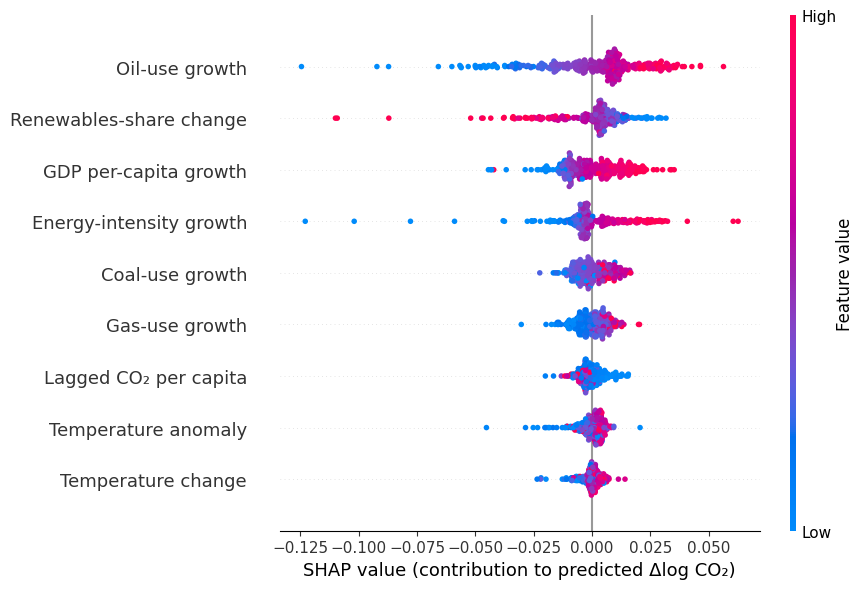

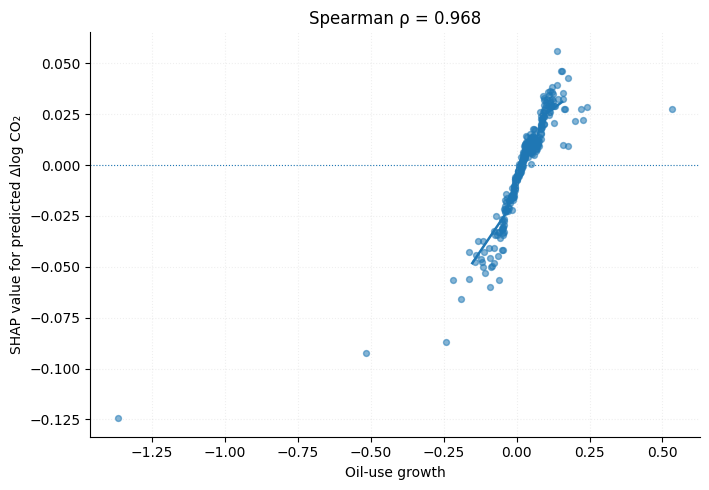

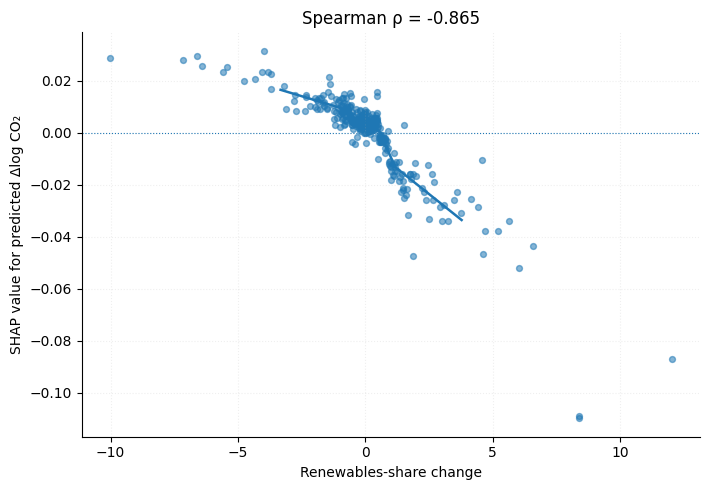

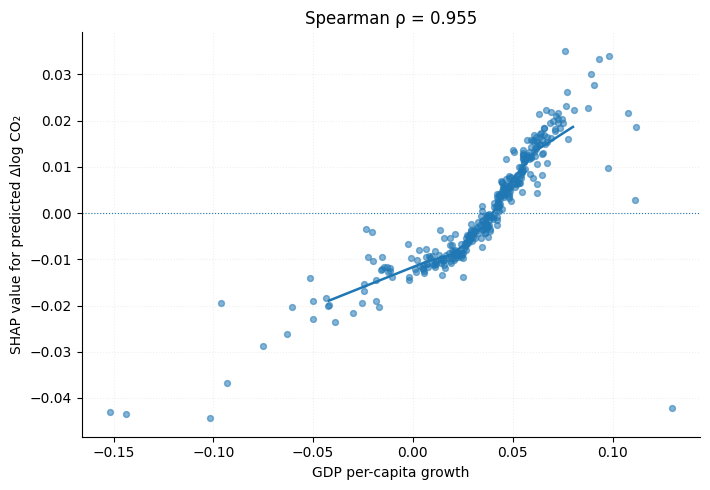

CELL 17 — SHAP DISTRIBUTION, DEPENDENCE & DIRECTION

Sample : development (343 observations)
Model  : CatBoost (frozen Stage-A winner)

DIRECTION SUMMARY


,Display_Feature,Group,Percent_Dev,Spearman_Feature_SHAP,UpperMinusLower_SHAP,Descriptive_Direction
0,Oil-use growth,Energy consumption,25.82%,0.968,0.05645,Positive-direction pattern
1,Renewables-share change,Energy structure,14.78%,-0.865,-0.03170,Negative-direction pattern
2,GDP per-capita growth,Economic,14.66%,0.955,0.02899,Positive-direction pattern
3,Energy-intensity growth,Energy-economic,14.05%,0.932,0.03191,Positive-direction pattern
4,Coal-use growth,Energy consumption,8.31%,0.835,0.01462,Positive-direction pattern
5,Gas-use growth,Energy consumption,7.28%,0.888,0.01255,Positive-direction pattern
6,Lagged CO₂ per capita,Autoregressive state,5.52%,-0.719,-0.00901,Negative-direction pattern
7,Temperature anomaly,Climate,5.51%,0.561,0.00764,Positive-direction pattern
8,Temperature change,Climate,4.07%,0.567,0.00680,Positive-direction pattern



TOP-3 DEVELOPMENT FEATURES
  1. Oil-use growth (25.8%): Positive-direction pattern (rho=0.968)
  2. Renewables-share change (14.8%): Negative-direction pattern (rho=-0.865)
  3. GDP per-capita growth (14.7%): Positive-direction pattern (rho=0.955)

INTERPRETATION NOTE
  Direction describes how the fitted model's SHAP contribution changes with the observed feature value.
  These patterns are predictive associations, not causal effects.
  Mixed/non-monotonic labels are retained where the two descriptive direction checks do not agree.
  Correlated predictors may share SHAP attribution.

✓ Development SHAP used for primary interpretation
✓ Held-out SHAP not reused for feature selection
✓ Beeswarm created for all 9 primary predictors
✓ Dependence plots restricted to development-ranked top 3
✓ Direction assessed using two descriptive checks
✓ No causal interpretation implied

OUTPUTS: Figure 4.3 SHAP beeswarm → Main text | top-3 dependence figures → Appendix | direction summary → Appendix/s

In [18]:
# ============================================================
# CELL 17 — SHAP DISTRIBUTION, DEPENDENCE & DIRECTION
# ============================================================
# Run after Cell 16. Use development SHAP only, not held-out SHAP.
# Plot all nine predictors and the development-ranked top three.
# Describe model behaviour using Spearman correlation and quartile means.
# These patterns are associations, not causal effects.
# Keep calculations, random-number use, figures and output names unchanged.

from scipy.stats import spearmanr


# 1. Check the frozen model, development sample and SHAP matrix
assert SHAP_MODEL_NAME == FROZEN_STAGE_A_WINNER
assert FROZEN_STAGE_A_WINNER == "CatBoost"
assert len(X_shap_dev) == 343
assert shap_dev.shape == (len(X_shap_dev), len(PRIMARY_FEATURES))
assert len(SHAP_TOP3_FEATURES) == 3
assert np.isfinite(shap_dev).all()


# 2. Describe direction using two checks: correlation and quartile means
direction_rows = []

for feature in PRIMARY_FEATURES:
    idx = PRIMARY_FEATURES.index(feature)
    values = X_shap_dev[feature].to_numpy(dtype=float)
    contributions = shap_dev[:, idx]
    rho, _ = spearmanr(values, contributions)

    q25 = float(np.quantile(values, 0.25))
    q75 = float(np.quantile(values, 0.75))
    lower_mask = values <= q25
    upper_mask = values >= q75
    lower_mean_shap = float(np.mean(contributions[lower_mask]))
    upper_mean_shap = float(np.mean(contributions[upper_mask]))
    upper_minus_lower = upper_mean_shap - lower_mean_shap

    if rho > 0 and upper_minus_lower > 0:
        direction = "Positive-direction pattern"
    elif rho < 0 and upper_minus_lower < 0:
        direction = "Negative-direction pattern"
    else:
        direction = "Mixed / non-monotonic pattern"

    share = float(shap_importance.loc[
        shap_importance["Feature"] == feature, "Percent_Dev"
    ].iloc[0])
    direction_rows.append({
        "Feature": feature,
        "Display_Feature": SHAP_FEATURE_LABELS[feature],
        "Group": FEATURE_GROUPS[feature],
        "Percent_Dev": share,
        "Spearman_Feature_SHAP": float(rho),
        "Lower_Quartile_Mean_SHAP": lower_mean_shap,
        "Upper_Quartile_Mean_SHAP": upper_mean_shap,
        "UpperMinusLower_SHAP": upper_minus_lower,
        "Descriptive_Direction": direction,
    })

shap_direction = (
    pd.DataFrame(direction_rows)
    .sort_values("Percent_Dev", ascending=False)
    .reset_index(drop=True)
)


# 3. Figure 4.3: development SHAP beeswarm for all primary predictors
display_names = [SHAP_FEATURE_LABELS[feature] for feature in PRIMARY_FEATURES]
X_display = X_shap_dev.copy()
X_display.columns = display_names

plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_dev, X_display, show=False,
    max_display=len(PRIMARY_FEATURES), plot_size=None,
)
ax = plt.gca()
ax.set_xlabel("SHAP value (contribution to predicted Δlog CO₂)")
fig = plt.gcf()
fig.tight_layout()

SHAP_BEESWARM_PNG = FIGURES_DIR / "fig_4_3_shap_beeswarm.png"
SHAP_BEESWARM_PDF = FIGURES_DIR / "fig_4_3_shap_beeswarm.pdf"
fig.savefig(SHAP_BEESWARM_PNG, dpi=300, bbox_inches="tight")
fig.savefig(SHAP_BEESWARM_PDF, bbox_inches="tight")
plt.show()


# 4. Separate dependence plots for the development-ranked top three
dependence_file_rows = []

for rank, feature in enumerate(SHAP_TOP3_FEATURES, start=1):
    idx = PRIMARY_FEATURES.index(feature)
    values = X_shap_dev[feature].to_numpy(dtype=float)
    contributions = shap_dev[:, idx]
    label = SHAP_FEATURE_LABELS[feature]
    rho_value = float(shap_direction.loc[
        shap_direction["Feature"] == feature, "Spearman_Feature_SHAP"
    ].iloc[0])

    fig, ax = plt.subplots(figsize=(7.2, 5))
    ax.scatter(values, contributions, s=18, alpha=0.55)
    ax.axhline(0, linewidth=0.8, linestyle=":")

    # Keep the original quantile bins; drop duplicate bin edges.
    bins = pd.qcut(values, q=10, duplicates="drop")
    binned = (
        pd.DataFrame({"Feature_Value": values, "SHAP_Value": contributions, "Bin": bins})
        .groupby("Bin", observed=True)
        .agg(
            Feature_Value=("Feature_Value", "mean"),
            SHAP_Value=("SHAP_Value", "mean"),
        )
    )
    ax.plot(binned["Feature_Value"], binned["SHAP_Value"], linewidth=1.8)
    ax.set_xlabel(label)
    ax.set_ylabel("SHAP value for predicted Δlog CO₂")
    ax.set_title(f"Spearman ρ = {rho_value:.3f}")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2, linestyle=":")
    fig.tight_layout()

    safe_name = feature.replace(" ", "_")
    png_path = FIGURES_DIR / f"appendix_shap_dependence_{rank}_{safe_name}.png"
    pdf_path = FIGURES_DIR / f"appendix_shap_dependence_{rank}_{safe_name}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    dependence_file_rows.append({
        "Rank": rank,
        "Feature": feature,
        "Display_Feature": label,
        "PNG_File": str(png_path),
        "PDF_File": str(pdf_path),
    })

shap_dependence_files = pd.DataFrame(dependence_file_rows)


# 5. Save the original direction summary and dependence file register
shap_direction.to_csv(TABLES_DIR / "appendix_shap_direction_summary.csv", index=False)
shap_dependence_files.to_csv(TABLES_DIR / "appendix_shap_dependence_file_register.csv", index=False)


# 6. Report with the original text and display formatting
print("=" * 78)
print("CELL 17 — SHAP DISTRIBUTION, DEPENDENCE & DIRECTION")
print("=" * 78)
print(f"\nSample : development ({len(X_shap_dev)} observations)")
print(f"Model  : {SHAP_MODEL_NAME} (frozen Stage-A winner)")

print("\nDIRECTION SUMMARY")
display(
    shap_direction[[
        "Display_Feature", "Group", "Percent_Dev", "Spearman_Feature_SHAP",
        "UpperMinusLower_SHAP", "Descriptive_Direction",
    ]].style.format({
        "Percent_Dev": "{:.2f}%",
        "Spearman_Feature_SHAP": "{:.3f}",
        "UpperMinusLower_SHAP": "{:.5f}",
    })
)

print("\nTOP-3 DEVELOPMENT FEATURES")
for rank, feature in enumerate(SHAP_TOP3_FEATURES, start=1):
    row = shap_direction[shap_direction["Feature"] == feature].iloc[0]
    print(
        f"  {rank}. {SHAP_FEATURE_LABELS[feature]} "
        f"({row['Percent_Dev']:.1f}%): {row['Descriptive_Direction']} "
        f"(rho={row['Spearman_Feature_SHAP']:.3f})"
    )

print("\nINTERPRETATION NOTE")
print(
    "  Direction describes how the fitted model's SHAP "
    "contribution changes with the observed feature value."
)
print("  These patterns are predictive associations, not causal effects.")
print(
    "  Mixed/non-monotonic labels are retained where the "
    "two descriptive direction checks do not agree."
)
print("  Correlated predictors may share SHAP attribution.")
print("\n✓ Development SHAP used for primary interpretation")
print("✓ Held-out SHAP not reused for feature selection")
print("✓ Beeswarm created for all 9 primary predictors")
print("✓ Dependence plots restricted to development-ranked top 3")
print("✓ Direction assessed using two descriptive checks")
print("✓ No causal interpretation implied")
print(
    "\nOUTPUTS: "
    "Figure 4.3 SHAP beeswarm → Main text | "
    "top-3 dependence figures → Appendix | "
    "direction summary → Appendix/supporting text | "
    "no additional main-text table"
)


In [19]:
# ============================================================
# CELL 18 — STAGE-B RECURSIVE DESIGN LOCK
# ============================================================
# Run after Cell 17, using the helpers from Cells 8 and 9.
# Lock the secondary six-year operational forecasting design only.
# Later cells project raw drivers, rebuild features and update CO2 recursively.
# No driver or CO2 model is trained here; Stage-B winner stays unset.
# Keep folds, driver specifications, baselines and output names unchanged.


# 1. Lock four six-year outer folds inside the development period
STAGE_B_HORIZON = 6
stage_b_folds = pd.DataFrame([
    {"Fold": 1, "Train_End": 1989, "Forecast_Start": 1990, "Forecast_End": 1995},
    {"Fold": 2, "Train_End": 1995, "Forecast_Start": 1996, "Forecast_End": 2001},
    {"Fold": 3, "Train_End": 2001, "Forecast_Start": 2002, "Forecast_End": 2007},
    {"Fold": 4, "Train_End": 2007, "Forecast_Start": 2008, "Forecast_End": 2013},
])
N_STAGE_B_FOLDS = len(stage_b_folds)
assert N_STAGE_B_FOLDS == 4


# 2. Confirm chronological folds and held-out exclusion
for _, f in stage_b_folds.iterrows():
    train_end = int(f["Train_End"])
    forecast_start = int(f["Forecast_Start"])
    forecast_end = int(f["Forecast_End"])
    assert forecast_start == train_end + 1
    assert forecast_end - forecast_start + 1 == STAGE_B_HORIZON
    assert forecast_end <= TRAIN_END
    assert forecast_end < TEST_START

assert stage_b_folds["Train_End"].is_monotonic_increasing


# 3. Project these raw driver levels before rebuilding engineered features
STAGE_B_DRIVER_LEVELS = [
    "energy_per_capita",
    "oil_energy_per_capita",
    "coal_cons_per_capita",
    "gas_energy_per_capita",
    "renewables_share_energy",
    "gdp_per_capita",
    "Avg_Temperature_C",
]
assert len(STAGE_B_DRIVER_LEVELS) == 7


# 4. Keep the original driver transformations and physical bounds
STAGE_B_DRIVER_SPEC = {
    "energy_per_capita": {
        "Transform": "log1p", "Lower_Bound": 0.0, "Upper_Bound": None,
    },
    "oil_energy_per_capita": {
        "Transform": "log1p", "Lower_Bound": 0.0, "Upper_Bound": None,
    },
    "coal_cons_per_capita": {
        "Transform": "log1p", "Lower_Bound": 0.0, "Upper_Bound": None,
    },
    "gas_energy_per_capita": {
        "Transform": "log1p", "Lower_Bound": 0.0, "Upper_Bound": None,
    },
    "renewables_share_energy": {
        "Transform": "level", "Lower_Bound": 0.0, "Upper_Bound": 100.0,
    },
    "gdp_per_capita": {
        "Transform": "log1p", "Lower_Bound": 0.0, "Upper_Bound": None,
    },
    "Avg_Temperature_C": {
        "Transform": "level", "Lower_Bound": None, "Upper_Bound": None,
    },
}
assert set(STAGE_B_DRIVER_SPEC) == set(STAGE_B_DRIVER_LEVELS)

stage_b_driver_register = pd.DataFrame([
    {
        "Driver": driver,
        "Transform": STAGE_B_DRIVER_SPEC[driver]["Transform"],
        "Lower_Bound": STAGE_B_DRIVER_SPEC[driver]["Lower_Bound"],
        "Upper_Bound": STAGE_B_DRIVER_SPEC[driver]["Upper_Bound"],
    }
    for driver in STAGE_B_DRIVER_LEVELS
])


# 5. Lock candidate methods; selection happens in Cell 19
RECENT_WINDOWS = [5, 10, 15]
STAGE_B_DRIVER_CANDIDATES = [
    {"Method": "Persistence", "Recent_Window": None},
    {"Method": "Drift", "Recent_Window": None},
    {"Method": "Holt_Damped", "Recent_Window": None},
    {"Method": "Recent_Trend_5", "Recent_Window": 5},
    {"Method": "Recent_Trend_10", "Recent_Window": 10},
    {"Method": "Recent_Trend_15", "Recent_Window": 15},
]
stage_b_driver_candidate_register = pd.DataFrame(STAGE_B_DRIVER_CANDIDATES)
assert stage_b_driver_candidate_register["Method"].nunique() == 6
assert set(
    stage_b_driver_candidate_register["Recent_Window"].dropna().astype(int)
) == set(RECENT_WINDOWS)


# 6. Build fold training copies and training-only temperature baselines
STAGE_B_FOLD_DATA = {}
STAGE_B_TEMP_BASELINES = {}
fold_rows = []
temp_audits = []

for _, f in stage_b_folds.iterrows():
    fold = int(f["Fold"])
    train_end = int(f["Train_End"])
    forecast_start = int(f["Forecast_Start"])
    forecast_end = int(f["Forecast_End"])

    fold_train_raw = (
        train_df[train_df["year"] <= train_end].copy().reset_index(drop=True)
    )
    fold_truth = (
        df[df["year"].between(forecast_start, forecast_end)]
        [["country", "year", "co2_per_capita"]]
        .copy()
        .reset_index(drop=True)
    )
    assert len(fold_truth) == 8 * STAGE_B_HORIZON

    baseline, audit = compute_temperature_baseline(
        training_frame=fold_train_raw, cutoff_year=train_end
    )
    fold_train = attach_temperature_anomaly(fold_train_raw, baseline)
    assert not fold_train[PRIMARY_FEATURES].isna().any().any()
    assert int(fold_train["year"].max()) == train_end
    assert int(fold_truth["year"].min()) == forecast_start
    assert int(fold_truth["year"].max()) == forecast_end

    STAGE_B_FOLD_DATA[fold] = {"train": fold_train, "truth": fold_truth}
    STAGE_B_TEMP_BASELINES[fold] = baseline
    audit.insert(0, "Fold", fold)
    audit["Forecast_Period"] = f"{forecast_start}-{forecast_end}"
    temp_audits.append(audit)

    fold_rows.append({
        "Fold": fold,
        "Train_Period": f"{int(fold_train['year'].min())}-{train_end}",
        "Train_Rows": len(fold_train),
        "Forecast_Period": f"{forecast_start}-{forecast_end}",
        "Forecast_Rows": len(fold_truth),
        "Horizon_Years": STAGE_B_HORIZON,
    })

stage_b_fold_design = pd.DataFrame(fold_rows)
stage_b_temperature_baseline_audit = pd.concat(temp_audits, ignore_index=True)


# 7. Calculate each fold's MASE scaling from pre-origin CO2 history
STAGE_B_DENOMINATORS = {}
denominator_audits = []

for _, f in stage_b_folds.iterrows():
    fold = int(f["Fold"])
    train_end = int(f["Train_End"])
    forecast_start = int(f["Forecast_Start"])
    denoms, audit = compute_mase_denominators(cutoff_year=train_end)
    assert audit["Last_Year_Used"].max() < forecast_start

    STAGE_B_DENOMINATORS[fold] = denoms
    audit.insert(0, "Fold", fold)
    audit["Forecast_Start"] = forecast_start
    denominator_audits.append(audit)

stage_b_denominator_audit = pd.concat(denominator_audits, ignore_index=True)
stage_b_denominator_summary = (
    stage_b_denominator_audit
    .pivot(index="country", columns="Fold", values="MASE_Denominator")
    .sort_index()
)
stage_b_denominator_summary.columns = [
    f"Fold_{int(col)}" for col in stage_b_denominator_summary.columns
]


# 8. Document the distinct Stage-A and Stage-B tasks
stage_separation = pd.DataFrame([
    {"Property": "Task", "Stage_A": "conditional one-step prediction",
     "Stage_B": "six-year recursive forecasting"},
    {"Property": "Indicators at prediction time", "Stage_A": "observed",
     "Stage_B": "projected"},
    {"Property": "co2_lag1", "Stage_A": "observed",
     "Stage_B": "own previous prediction"},
    {"Property": "CV design", "Stage_A": f"{N_STAGE_A_FOLDS} blocked folds",
     "Stage_B": f"{N_STAGE_B_FOLDS} six-year outer folds"},
    {"Property": "Selection criterion", "Stage_A": "one-step Macro-MASE",
     "Stage_B": "six-year recursive Macro-MASE"},
    {"Property": "Winner", "Stage_A": f"{FROZEN_STAGE_A_WINNER} (frozen)",
     "Stage_B": "not yet selected"},
    {"Property": "Study role", "Stage_A": "primary, title-aligned",
     "Stage_B": "secondary, operational"},
])


# 9. Keep the original global integrity checks
assert len(STAGE_B_FOLD_DATA) == N_STAGE_B_FOLDS
assert len(STAGE_B_TEMP_BASELINES) == N_STAGE_B_FOLDS
assert len(STAGE_B_DENOMINATORS) == N_STAGE_B_FOLDS
assert int(stage_b_folds["Forecast_End"].max()) == TRAIN_END
assert int(stage_b_folds["Forecast_End"].max()) < TEST_START
assert not stage_b_temperature_baseline_audit["Last_Year_Used"].ge(TEST_START).any()
assert not stage_b_denominator_audit["Last_Year_Used"].ge(TEST_START).any()
assert STAGE_A_WINNER is not None
assert STAGE_B_WINNER is None


# 10. Save the original seven CSV files
stage_b_fold_design.to_csv(TABLES_DIR / "stage_b_outer_fold_design.csv", index=False)
stage_b_driver_register.to_csv(TABLES_DIR / "stage_b_driver_register.csv", index=False)
stage_b_driver_candidate_register.to_csv(
    TABLES_DIR / "stage_b_driver_candidate_methods.csv", index=False
)
stage_b_temperature_baseline_audit.to_csv(
    TABLES_DIR / "stage_b_temperature_baseline_audit.csv", index=False
)
stage_b_denominator_audit.to_csv(
    TABLES_DIR / "stage_b_mase_denominator_audit.csv", index=False
)
stage_b_denominator_summary.to_csv(TABLES_DIR / "stage_b_mase_denominator_summary.csv")
stage_separation.to_csv(TABLES_DIR / "stage_a_vs_stage_b_separation.csv", index=False)


# 11. Report with the original text, order and display formats
print("=" * 78)
print("CELL 18 — STAGE-B RECURSIVE DESIGN LOCK")
print("=" * 78)
print("\nStage B role : secondary operational recursive forecasting")
print(f"Horizon      : {STAGE_B_HORIZON} years")
print(f"Outer folds  : {N_STAGE_B_FOLDS}")
print(f"Raw drivers  : {len(STAGE_B_DRIVER_LEVELS)}")
print(f"Candidates   : {len(STAGE_B_DRIVER_CANDIDATES)} per driver")
print("Held-out     : 2014-2024 remains untouched")

print("\nSTAGE-B OUTER FOLDS")
display(stage_b_fold_design)
print("\nRAW DRIVER REGISTER")
display(stage_b_driver_register)
print("\nLOCKED DRIVER CANDIDATES")
display(stage_b_driver_candidate_register)
print("\nSTAGE-B MASE DENOMINATORS")
display(stage_b_denominator_summary.style.format("{:.5f}"))

print("\nLEAKAGE VERIFICATION")
for _, f in stage_b_folds.iterrows():
    fold = int(f["Fold"])
    forecast_start = int(f["Forecast_Start"])
    temp_end = int(
        stage_b_temperature_baseline_audit[
            stage_b_temperature_baseline_audit["Fold"] == fold
        ]["Last_Year_Used"].max()
    )
    mase_end = int(
        stage_b_denominator_audit[
            stage_b_denominator_audit["Fold"] == fold
        ]["Last_Year_Used"].max()
    )
    print(
        f"  Fold {fold}: temperature baseline ends {temp_end}, "
        f"MASE scaling ends {mase_end}, forecast starts {forecast_start}  ✓"
    )

print("\nDESIGN NOTES")
print("  ✓ Positive scale drivers will be projected in log1p space")
print("  ✓ Raw driver levels will be projected before feature rebuilding")
print("  ✓ co2_lag1 will be updated recursively from predicted CO2")
print("  ✓ Recent-trend windows locked at 5, 10 and 15 years")
print("  ✓ Driver-method selection occurs only in Cell 19")
print("  ✓ No driver model fitted in this cell")
print("  ✓ No CO2 model fitted in this cell")
print("  ✓ No 2014-2024 observation used")
print("  ✓ Stage-B winner remains unset")
print(
    "\nOUTPUTS: "
    "Stage-A vs Stage-B separation → Main text methodology | "
    "fold/driver design → Appendix | "
    "temperature and MASE audits → Notebook/Appendix"
)


CELL 18 — STAGE-B RECURSIVE DESIGN LOCK

Stage B role : secondary operational recursive forecasting
Horizon      : 6 years
Outer folds  : 4
Raw drivers  : 7
Candidates   : 6 per driver
Held-out     : 2014-2024 remains untouched

STAGE-B OUTER FOLDS


,Fold,Train_Period,Train_Rows,Forecast_Period,Forecast_Rows,Horizon_Years
0,1,1971-1989,151,1990-1995,48,6
1,2,1971-1995,199,1996-2001,48,6
2,3,1971-2001,247,2002-2007,48,6
3,4,1971-2007,295,2008-2013,48,6



RAW DRIVER REGISTER


,Driver,Transform,Lower_Bound,Upper_Bound
0,energy_per_capita,log1p,0.0,NaN
1,oil_energy_per_capita,log1p,0.0,NaN
2,coal_cons_per_capita,log1p,0.0,NaN
3,gas_energy_per_capita,log1p,0.0,NaN
4,renewables_share_energy,level,0.0,100.0
5,gdp_per_capita,log1p,0.0,NaN
6,Avg_Temperature_C,level,NaN,NaN



LOCKED DRIVER CANDIDATES


,Method,Recent_Window
0,Persistence,NaN
1,Drift,NaN
2,Holt_Damped,NaN
3,Recent_Trend_5,5.0
4,Recent_Trend_10,10.0
5,Recent_Trend_15,15.0



STAGE-B MASE DENOMINATORS


,Fold_1,Fold_2,Fold_3,Fold_4
country,,,,
Bangladesh,0.00524,0.00596,0.00678,0.00733
India,0.01641,0.01859,0.01967,0.02301
Indonesia,0.03033,0.03857,0.05858,0.05879
Malaysia,0.14701,0.21709,0.24628,0.25119
Pakistan,0.01655,0.01941,0.01867,0.01951
Sri Lanka,0.02479,0.02443,0.02592,0.02511
Thailand,0.05992,0.09628,0.10795,0.10779
Vietnam,0.04567,0.04142,0.04516,0.04948



LEAKAGE VERIFICATION
  Fold 1: temperature baseline ends 1989, MASE scaling ends 1989, forecast starts 1990  ✓
  Fold 2: temperature baseline ends 1995, MASE scaling ends 1995, forecast starts 1996  ✓
  Fold 3: temperature baseline ends 2001, MASE scaling ends 2001, forecast starts 2002  ✓
  Fold 4: temperature baseline ends 2007, MASE scaling ends 2007, forecast starts 2008  ✓

DESIGN NOTES
  ✓ Positive scale drivers will be projected in log1p space
  ✓ Raw driver levels will be projected before feature rebuilding
  ✓ co2_lag1 will be updated recursively from predicted CO2
  ✓ Recent-trend windows locked at 5, 10 and 15 years
  ✓ Driver-method selection occurs only in Cell 19
  ✓ No driver model fitted in this cell
  ✓ No CO2 model fitted in this cell
  ✓ No 2014-2024 observation used
  ✓ Stage-B winner remains unset

OUTPUTS: Stage-A vs Stage-B separation → Main text methodology | fold/driver design → Appendix | temperature and MASE audits → Notebook/Appendix


In [20]:
# ============================================================
# CELL 19 — NESTED DRIVER-METHOD SELECTION
# ============================================================
# Run after Cell 18. Select a forecasting method per country and raw driver.
# Each outer fold uses only inner target windows ending by its cutoff.
# Freeze a separate full-development map using data through 2013.
# Keep scoring, candidate order, bounds, fallbacks and exports unchanged.
# Driver forecasting methods are fitted here, but no CO2 model is fitted.
# Stage-B winner remains unset; held-out 2014–2024 data are not used.

import time
import warnings

from statsmodels.tsa.holtwinters import Holt
from sklearn.linear_model import LinearRegression


# 1. Use fixed inner origins with non-overlapping six-year target windows
DRIVER_INNER_ORIGIN_GRID = [1977, 1983, 1989, 1995, 2001, 2007]
FULL_DEVELOPMENT_DRIVER_CUTOFF = TRAIN_END
assert FULL_DEVELOPMENT_DRIVER_CUTOFF == 2013
assert all(origin < TEST_START for origin in DRIVER_INNER_ORIGIN_GRID)


def eligible_driver_inner_origins(cutoff_year):
    """Return origins whose complete six-year target window ends by the cutoff."""
    origins = [
        origin for origin in DRIVER_INNER_ORIGIN_GRID
        if origin + STAGE_B_HORIZON <= cutoff_year
    ]
    assert len(origins) > 0
    assert max(origin + STAGE_B_HORIZON for origin in origins) <= cutoff_year
    return origins


assert eligible_driver_inner_origins(1989) == [1977, 1983]
assert eligible_driver_inner_origins(1995) == [1977, 1983, 1989]
assert eligible_driver_inner_origins(2001) == [1977, 1983, 1989, 1995]
assert eligible_driver_inner_origins(2007) == [1977, 1983, 1989, 1995, 2001]
assert eligible_driver_inner_origins(2013) == DRIVER_INNER_ORIGIN_GRID


# 2. Transform drivers using the Cell-18 specification
def driver_forward_transform(values, driver):
    """Convert raw driver values to the locked projection space."""
    values = np.asarray(values, dtype=float)
    assert np.isfinite(values).all()
    transform = STAGE_B_DRIVER_SPEC[driver]["Transform"]

    if transform == "log1p":
        assert (values >= 0).all()
        return np.log1p(values)
    if transform == "level":
        return values.copy()
    raise ValueError(f"Unknown transform for {driver}: {transform}")


def driver_inverse_transform(values, driver):
    """Convert projections to raw levels and apply the original driver bounds."""
    values = np.asarray(values, dtype=float)
    assert np.isfinite(values).all()
    spec = STAGE_B_DRIVER_SPEC[driver]
    transform = spec["Transform"]

    if transform == "log1p":
        with np.errstate(over="ignore", invalid="ignore"):
            raw = np.expm1(values)
    elif transform == "level":
        raw = values.copy()
    else:
        raise ValueError(f"Unknown transform for {driver}: {transform}")

    if not np.isfinite(raw).all():
        raise FloatingPointError(f"Non-finite inverse projection for {driver}")

    lower = spec["Lower_Bound"]
    upper = spec["Upper_Bound"]
    if lower is not None:
        raw = np.maximum(raw, lower)
    if upper is not None:
        raw = np.minimum(raw, upper)
    assert np.isfinite(raw).all()
    return raw


# 3. Forecast one driver; retain the original safeguards and audit fields
def forecast_driver(history_values, driver, horizon, method_name):
    """Return raw-level forecasts and fallback/window details for one series."""
    history_values = np.asarray(history_values, dtype=float)
    assert len(history_values) >= 3
    assert np.isfinite(history_values).all()
    z = driver_forward_transform(history_values, driver)
    n = len(z)
    fallback_used = False
    fallback_reason = ""
    effective_window = np.nan

    if method_name == "Persistence":
        pred_z = np.repeat(z[-1], horizon)

    elif method_name == "Drift":
        slope = (z[-1] - z[0]) / (n - 1)
        pred_z = z[-1] + slope * np.arange(1, horizon + 1)

    elif method_name == "Holt_Damped":
        if np.allclose(z, z[0]):
            pred_z = np.repeat(z[-1], horizon)
            fallback_used = True
            fallback_reason = "constant_series"
        else:
            try:
                with warnings.catch_warnings():
                    # Keep the original warning suppression local to Holt fitting.
                    warnings.simplefilter("ignore")
                    fit = Holt(
                        z, damped_trend=True, initialization_method="estimated"
                    ).fit(optimized=True)
                pred_z = np.asarray(fit.forecast(horizon), dtype=float)
                if not np.isfinite(pred_z).all():
                    raise FloatingPointError("non-finite Holt forecast")
            except Exception as exc:
                pred_z = np.repeat(z[-1], horizon)
                fallback_used = True
                fallback_reason = "holt_failure:" + type(exc).__name__

    elif method_name.startswith("Recent_Trend_"):
        requested_window = int(method_name.split("_")[-1])
        effective_window = min(requested_window, n)
        recent = z[-int(effective_window):]
        x_train = np.arange(len(recent), dtype=float).reshape(-1, 1)
        x_future = np.arange(
            len(recent), len(recent) + horizon, dtype=float
        ).reshape(-1, 1)
        trend_model = LinearRegression().fit(x_train, recent)
        pred_z = np.asarray(trend_model.predict(x_future), dtype=float)

    else:
        raise ValueError(f"Unknown driver method: {method_name}")

    pred_z = np.asarray(pred_z, dtype=float)
    assert len(pred_z) == horizon
    if not np.isfinite(pred_z).all():
        pred_z = np.repeat(z[-1], horizon)
        fallback_used = True
        fallback_reason = "nonfinite_projection"

    try:
        forecast_raw = driver_inverse_transform(pred_z, driver)
    except FloatingPointError:
        # Fall back to the last observed value if inverse transformation fails.
        pred_z = np.repeat(z[-1], horizon)
        forecast_raw = driver_inverse_transform(pred_z, driver)
        fallback_used = True
        fallback_reason = "inverse_transform_failure"

    return forecast_raw, {
        "Fallback_Used": bool(fallback_used),
        "Fallback_Reason": fallback_reason,
        "Effective_Recent_Window": effective_window,
    }


# 4. Cache scores because outer folds reuse the same inner origins
DRIVER_SCORE_CACHE = {}


def score_driver_candidate_at_origin(country, driver, origin, method_name):
    """Score a six-year forecast: projection-space MAE selects; raw MAE audits."""
    cache_key = (country, driver, int(origin), method_name)
    if cache_key in DRIVER_SCORE_CACHE:
        return DRIVER_SCORE_CACHE[cache_key].copy()

    country_data = (
        df[df["country"] == country].sort_values("year").copy()
    )
    # Use observed raw history through the origin, without filling missing values.
    history = (
        country_data[country_data["year"] <= origin][driver]
        .dropna()
        .to_numpy(dtype=float)
    )
    actual_frame = (
        country_data[
            country_data["year"].between(origin + 1, origin + STAGE_B_HORIZON)
        ][["year", driver]].copy()
    )
    assert len(history) >= 3
    assert len(actual_frame) == STAGE_B_HORIZON
    assert actual_frame[driver].notna().all()
    assert int(actual_frame["year"].min()) == origin + 1
    assert int(actual_frame["year"].max()) == origin + STAGE_B_HORIZON

    actual_raw = actual_frame[driver].to_numpy(dtype=float)
    pred_raw, audit = forecast_driver(
        history_values=history,
        driver=driver,
        horizon=STAGE_B_HORIZON,
        method_name=method_name,
    )
    # Score after inverse transformation and bounds, as in the original code.
    actual_projection = driver_forward_transform(actual_raw, driver)
    pred_projection = driver_forward_transform(pred_raw, driver)
    projection_mae = float(np.mean(np.abs(actual_projection - pred_projection)))
    raw_level_mae = float(np.mean(np.abs(actual_raw - pred_raw)))
    result = {
        "Projection_Space_MAE": projection_mae,
        "Raw_Level_MAE": raw_level_mae,
        "History_N": len(history),
        "Target_Start": int(origin + 1),
        "Target_End": int(origin + STAGE_B_HORIZON),
        "Fallback_Used": audit["Fallback_Used"],
        "Fallback_Reason": audit["Fallback_Reason"],
        "Effective_Recent_Window": audit["Effective_Recent_Window"],
    }
    DRIVER_SCORE_CACHE[cache_key] = result.copy()
    return result


# 5. Preserve the Cell-18 candidate order for deterministic tie-breaking
STAGE_B_DRIVER_METHOD_ORDER = {
    method: order for order, method in enumerate(
        stage_b_driver_candidate_register["Method"].tolist()
    )
}


# 6. Select one method per country-driver pair using eligible inner origins
def select_driver_methods_for_cutoff(selection_set, cutoff_year):
    """Return origin scores, candidate summaries, selected methods and audit."""
    eligible_origins = eligible_driver_inner_origins(cutoff_year)
    detail_rows = []

    for country in sorted(df["country"].unique()):
        for driver in STAGE_B_DRIVER_LEVELS:
            for method_name in stage_b_driver_candidate_register["Method"].tolist():
                for origin in eligible_origins:
                    score = score_driver_candidate_at_origin(
                        country=country,
                        driver=driver,
                        origin=origin,
                        method_name=method_name,
                    )
                    assert score["Target_End"] <= cutoff_year
                    detail_rows.append({
                        "Selection_Set": selection_set,
                        "Cutoff_Year": int(cutoff_year),
                        "country": country,
                        "Driver": driver,
                        "Method": method_name,
                        "Inner_Origin": int(origin),
                        **score,
                    })

    detail = pd.DataFrame(detail_rows)
    candidate_summary = (
        detail.groupby(
            ["Selection_Set", "Cutoff_Year", "country", "Driver", "Method"],
            as_index=False,
        )
        .agg(
            Mean_Projection_Space_MAE=("Projection_Space_MAE", "mean"),
            Median_Projection_Space_MAE=("Projection_Space_MAE", "median"),
            Mean_Raw_Level_MAE=("Raw_Level_MAE", "mean"),
            N_Inner_Origins=("Inner_Origin", "nunique"),
            Fallback_Count=("Fallback_Used", "sum"),
        )
    )
    candidate_counts = (
        candidate_summary.groupby(["country", "Driver"])["Method"].nunique()
    )
    assert (candidate_counts == len(STAGE_B_DRIVER_CANDIDATES)).all()
    candidate_summary["_Method_Order"] = (
        candidate_summary["Method"].map(STAGE_B_DRIVER_METHOD_ORDER)
    )

    selected_rows = []
    for (country, driver), sub in candidate_summary.groupby(["country", "Driver"]):
        ranked = (
            sub.sort_values(
                ["Mean_Projection_Space_MAE", "Median_Projection_Space_MAE",
                 "_Method_Order"],
                ascending=True,
            )
            .reset_index(drop=True)
        )
        best = ranked.iloc[0]
        selected_rows.append({
            "Selection_Set": selection_set,
            "Cutoff_Year": int(cutoff_year),
            "country": country,
            "Driver": driver,
            "Selected_Method": best["Method"],
            "Mean_Projection_Space_MAE": float(best["Mean_Projection_Space_MAE"]),
            "Median_Projection_Space_MAE": float(best["Median_Projection_Space_MAE"]),
            "Mean_Raw_Level_MAE": float(best["Mean_Raw_Level_MAE"]),
            "N_Inner_Origins": int(best["N_Inner_Origins"]),
            "Fallback_Count": int(best["Fallback_Count"]),
        })

    selected = pd.DataFrame(selected_rows)
    assert len(selected) == 8 * len(STAGE_B_DRIVER_LEVELS)
    assert len(selected) == 56
    candidate_summary = candidate_summary.drop(columns=["_Method_Order"])
    audit = {
        "Selection_Set": selection_set,
        "Cutoff_Year": int(cutoff_year),
        "Eligible_Inner_Origins": ", ".join(str(origin) for origin in eligible_origins),
        "N_Inner_Origins": len(eligible_origins),
        "Latest_Inner_Target_End": max(
            origin + STAGE_B_HORIZON for origin in eligible_origins
        ),
    }
    return detail, candidate_summary, selected, audit


# 7. Select methods separately inside each outer fold
outer_detail_frames = []
outer_candidate_frames = []
outer_selected_frames = []
inner_audit_rows = []

print("=" * 78)
print("CELL 19 — NESTED DRIVER-METHOD SELECTION")
print("=" * 78)
started = time.time()

for _, fold_info in stage_b_folds.iterrows():
    fold = int(fold_info["Fold"])
    cutoff = int(fold_info["Train_End"])
    selection_set = f"Outer_Fold_{fold}"
    print(f"\n▶ {selection_set}: cutoff {cutoff}")
    detail, candidate_summary, selected, audit = select_driver_methods_for_cutoff(
        selection_set=selection_set, cutoff_year=cutoff
    )
    detail["Outer_Fold"] = fold
    candidate_summary["Outer_Fold"] = fold
    selected["Outer_Fold"] = fold
    outer_detail_frames.append(detail)
    outer_candidate_frames.append(candidate_summary)
    outer_selected_frames.append(selected)
    audit["Outer_Fold"] = fold
    inner_audit_rows.append(audit)
    print(f"  Inner origins: {audit['Eligible_Inner_Origins']}")
    print("  56 country-driver methods selected ✓")


# 8. Freeze a separate 2013 map, not the final outer fold's 2007 map
print(f"\n▶ Full_Development: cutoff {FULL_DEVELOPMENT_DRIVER_CUTOFF}")
(
    full_detail,
    full_candidate_summary,
    FULL_DEVELOPMENT_DRIVER_SELECTION,
    full_audit,
) = select_driver_methods_for_cutoff(
    selection_set="Full_Development", cutoff_year=FULL_DEVELOPMENT_DRIVER_CUTOFF
)
full_audit["Outer_Fold"] = np.nan
inner_audit_rows.append(full_audit)
print(f"  Inner origins: {full_audit['Eligible_Inner_Origins']}")
print("  56 full-development country-driver methods selected ✓")


# 9. Combine outer-fold scores, selections and audits
stage_b_driver_inner_scores = pd.concat(outer_detail_frames, ignore_index=True)
stage_b_driver_candidate_scores = pd.concat(outer_candidate_frames, ignore_index=True)
stage_b_driver_method_map = pd.concat(outer_selected_frames, ignore_index=True)
stage_b_inner_origin_audit = pd.DataFrame(inner_audit_rows)


# 10. Build lookup objects consumed by later cells
STAGE_B_DRIVER_METHOD_MAP = {}
for fold in range(1, N_STAGE_B_FOLDS + 1):
    fold_data = stage_b_driver_method_map[
        stage_b_driver_method_map["Outer_Fold"] == fold
    ]
    STAGE_B_DRIVER_METHOD_MAP[fold] = {}
    for country in sorted(df["country"].unique()):
        country_data = fold_data[fold_data["country"] == country]
        STAGE_B_DRIVER_METHOD_MAP[fold][country] = dict(zip(
            country_data["Driver"], country_data["Selected_Method"],
        ))
        assert len(STAGE_B_DRIVER_METHOD_MAP[fold][country]) == 7

FULL_DEVELOPMENT_DRIVER_METHOD_MAP = {}
for country in sorted(df["country"].unique()):
    country_data = FULL_DEVELOPMENT_DRIVER_SELECTION[
        FULL_DEVELOPMENT_DRIVER_SELECTION["country"] == country
    ]
    FULL_DEVELOPMENT_DRIVER_METHOD_MAP[country] = dict(zip(
        country_data["Driver"], country_data["Selected_Method"],
    ))
    assert len(FULL_DEVELOPMENT_DRIVER_METHOD_MAP[country]) == 7

FINAL_DRIVER_SELECTION = (
    FULL_DEVELOPMENT_DRIVER_SELECTION.set_index(["country", "Driver"])
    ["Selected_Method"]
)
FINAL_DRIVER_METHOD_MAP = FULL_DEVELOPMENT_DRIVER_SELECTION.pivot(
    index="country", columns="Driver", values="Selected_Method"
)


# 11. Summarise how often each method was selected
stage_b_method_frequency = (
    stage_b_driver_method_map.groupby(["Outer_Fold", "Selected_Method"])
    .size().rename("N_Country_Driver_Series").reset_index()
)
full_development_method_frequency = (
    FULL_DEVELOPMENT_DRIVER_SELECTION["Selected_Method"]
    .value_counts().rename_axis("Selected_Method")
    .reset_index(name="N_Country_Driver_Series")
)
full_development_method_frequency["Percent"] = (
    full_development_method_frequency["N_Country_Driver_Series"]
    / len(FULL_DEVELOPMENT_DRIVER_SELECTION) * 100
)
stage_b_method_by_driver = (
    FULL_DEVELOPMENT_DRIVER_SELECTION.groupby(["Driver", "Selected_Method"])
    .size().rename("Selections").reset_index()
    .sort_values(["Driver", "Selections"], ascending=[True, False])
)


# 12. Audit unique cached evaluations and Holt fallbacks
driver_score_cache_table = pd.DataFrame([
    {
        "country": key[0],
        "Driver": key[1],
        "Inner_Origin": key[2],
        "Method": key[3],
        **value,
    }
    for key, value in DRIVER_SCORE_CACHE.items()
])
holt_cache = driver_score_cache_table[
    driver_score_cache_table["Method"] == "Holt_Damped"
]
total_holt_fallbacks = int(holt_cache["Fallback_Used"].sum())


# 13. Retain integrity checks before writing results
assert len(stage_b_driver_method_map) == N_STAGE_B_FOLDS * 8 * 7
assert len(stage_b_driver_method_map) == 224
assert len(FULL_DEVELOPMENT_DRIVER_SELECTION) == 56
assert len(STAGE_B_DRIVER_METHOD_MAP) == N_STAGE_B_FOLDS
assert len(FULL_DEVELOPMENT_DRIVER_METHOD_MAP) == 8
assert (
    stage_b_inner_origin_audit["Latest_Inner_Target_End"]
    <= stage_b_inner_origin_audit["Cutoff_Year"]
).all()
assert full_audit["Latest_Inner_Target_End"] == TRAIN_END
assert full_detail["Target_End"].max() == TRAIN_END
assert not (full_detail["Target_End"] >= TEST_START).any()
assert not (stage_b_driver_inner_scores["Target_End"] >= TEST_START).any()
assert STAGE_B_WINNER is None
elapsed_minutes = (time.time() - started) / 60


# 14. Save the original nine CSV files at full precision
stage_b_driver_inner_scores.to_csv(
    TABLES_DIR / "stage_b_driver_inner_origin_scores.csv", index=False
)
stage_b_driver_candidate_scores.to_csv(
    TABLES_DIR / "stage_b_driver_candidate_scores.csv", index=False
)
stage_b_driver_method_map.to_csv(
    TABLES_DIR / "stage_b_outer_driver_method_map.csv", index=False
)
FULL_DEVELOPMENT_DRIVER_SELECTION.to_csv(
    TABLES_DIR / "stage_b_full_development_driver_selection.csv", index=False
)
stage_b_inner_origin_audit.to_csv(
    TABLES_DIR / "stage_b_inner_origin_audit.csv", index=False
)
stage_b_method_frequency.to_csv(
    TABLES_DIR / "stage_b_outer_method_frequency.csv", index=False
)
full_development_method_frequency.to_csv(
    TABLES_DIR / "stage_b_full_development_method_frequency.csv", index=False
)
FINAL_DRIVER_METHOD_MAP.to_csv(
    TABLES_DIR / "appendix_stage_b_final_driver_method_map.csv"
)
driver_score_cache_table.to_csv(
    TABLES_DIR / "stage_b_unique_driver_forecast_scores.csv", index=False
)


# 15. Keep the original printed report and table formatting
print("\n" + "=" * 78)
print("NESTED DRIVER SELECTION COMPLETE")
print("=" * 78)
print(f"\nRuntime: {elapsed_minutes:.2f} min")

print("\nINNER-ORIGIN AUDIT")
display(stage_b_inner_origin_audit[
    ["Selection_Set", "Cutoff_Year", "Eligible_Inner_Origins",
     "N_Inner_Origins", "Latest_Inner_Target_End"]
])
print("\nOUTER-FOLD METHOD FREQUENCY")
display(stage_b_method_frequency)
print("\nFULL-DEVELOPMENT METHOD FREQUENCY")
display(full_development_method_frequency.style.format({"Percent": "{:.1f}%"}))
print("\nFULL-DEVELOPMENT METHOD SELECTION BY DRIVER")
display(stage_b_method_by_driver)
print("\nFINAL FULL-DEVELOPMENT METHOD MAP")
display(FINAL_DRIVER_METHOD_MAP)

print("\nHOLT FALLBACK AUDIT")
print(f"  Unique Holt evaluations : {len(holt_cache)}")
print(f"  Fallback events         : {total_holt_fallbacks}")
if total_holt_fallbacks > 0:
    fallback_summary = (
        holt_cache[holt_cache["Fallback_Used"]]["Fallback_Reason"].value_counts()
    )
    display(fallback_summary.rename("Count").to_frame())

print("\nLEAKAGE VERIFICATION")
for _, row in stage_b_inner_origin_audit.iterrows():
    print(
        f"  {row['Selection_Set']}: "
        f"latest inner target ends "
        f"{int(row['Latest_Inner_Target_End'])}; "
        f"selection cutoff "
        f"{int(row['Cutoff_Year'])}  ✓"
    )

print("\nDESIGN CHECKS")
print("  ✓ Fixed non-overlapping inner-origin grid used")
print("  ✓ Selection performed separately by country × driver")
print("  ✓ Candidate pool fixed in Cell 18")
print("  ✓ Positive scale drivers projected in log1p space")
print("  ✓ Raw driver histories taken from df with no imputation")
print("  ✓ Outer-fold maps use only pre-origin evidence")
print("  ✓ Separate full-development map uses evidence only through 2013")
print("  ✓ Fold-4 <=2007 map is NOT treated as the final driver map")
print("  ✓ No 2014-2024 observation used")
print("  ✓ No CO2 model fitted")
print("  ✓ Stage-B winner remains unset")

print("\nObjects created:")
print("  forecast_driver()")
print("  DRIVER_INNER_ORIGIN_GRID")
print("  STAGE_B_DRIVER_METHOD_MAP")
print("  FULL_DEVELOPMENT_DRIVER_SELECTION")
print("  FULL_DEVELOPMENT_DRIVER_METHOD_MAP")
print("  FINAL_DRIVER_SELECTION")
print("  FINAL_DRIVER_METHOD_MAP")
print("  stage_b_driver_method_map")
print("  stage_b_inner_origin_audit")
print("  driver_score_cache_table")
print(
    "\nOUTPUTS: "
    "full-development driver method map → Appendix | "
    "inner-origin audit + method frequencies → Appendix/Notebook | "
    "full candidate scores → Notebook only | "
    "no main-text Stage-B result yet"
)


CELL 19 — NESTED DRIVER-METHOD SELECTION

▶ Outer_Fold_1: cutoff 1989
  Inner origins: 1977, 1983
  56 country-driver methods selected ✓

▶ Outer_Fold_2: cutoff 1995
  Inner origins: 1977, 1983, 1989
  56 country-driver methods selected ✓

▶ Outer_Fold_3: cutoff 2001
  Inner origins: 1977, 1983, 1989, 1995
  56 country-driver methods selected ✓

▶ Outer_Fold_4: cutoff 2007
  Inner origins: 1977, 1983, 1989, 1995, 2001
  56 country-driver methods selected ✓

▶ Full_Development: cutoff 2013
  Inner origins: 1977, 1983, 1989, 1995, 2001, 2007
  56 full-development country-driver methods selected ✓

NESTED DRIVER SELECTION COMPLETE

Runtime: 0.44 min

INNER-ORIGIN AUDIT


,Selection_Set,Cutoff_Year,Eligible_Inner_Origins,N_Inner_Origins,Latest_Inner_Target_End
0,Outer_Fold_1,1989,"1977, 1983",2,1989
1,Outer_Fold_2,1995,"1977, 1983, 1989",3,1995
2,Outer_Fold_3,2001,"1977, 1983, 1989, 1995",4,2001
3,Outer_Fold_4,2007,"1977, 1983, 1989, 1995, 2001",5,2007
4,Full_Development,2013,"1977, 1983, 1989, 1995, 2001, 2007",6,2013



OUTER-FOLD METHOD FREQUENCY


,Outer_Fold,Selected_Method,N_Country_Driver_Series
0,1,Drift,8
1,1,Holt_Damped,8
2,1,Persistence,16
3,1,Recent_Trend_10,3
4,1,Recent_Trend_15,6
5,1,Recent_Trend_5,15
6,2,Drift,14
7,2,Holt_Damped,8
8,2,Persistence,13
9,2,Recent_Trend_10,2



FULL-DEVELOPMENT METHOD FREQUENCY


...


FINAL FULL-DEVELOPMENT METHOD MAP


Driver,Avg_Temperature_C,coal_cons_per_capita,energy_per_capita,gas_energy_per_capita,gdp_per_capita,oil_energy_per_capita,renewables_share_energy
country,,,,,,,
Bangladesh,Persistence,Persistence,Recent_Trend_5,Recent_Trend_5,Recent_Trend_5,Recent_Trend_5,Recent_Trend_10
India,Holt_Damped,Drift,Drift,Recent_Trend_5,Recent_Trend_10,Drift,Drift
Indonesia,Recent_Trend_15,Drift,Drift,Persistence,Drift,Recent_Trend_5,Persistence
Malaysia,Recent_Trend_15,Holt_Damped,Recent_Trend_5,Holt_Damped,Drift,Persistence,Persistence
Pakistan,Recent_Trend_15,Persistence,Holt_Damped,Drift,Drift,Recent_Trend_5,Persistence
Sri Lanka,Holt_Damped,Persistence,Drift,Persistence,Drift,Persistence,Persistence
Thailand,Persistence,Recent_Trend_10,Drift,Persistence,Drift,Persistence,Drift
Vietnam,Persistence,Persistence,Persistence,Recent_Trend_10,Recent_Trend_5,Persistence,Recent_Trend_5



HOLT FALLBACK AUDIT
  Unique Holt evaluations : 336
  Fallback events         : 8


,Count
Fallback_Reason,
constant_series,8



LEAKAGE VERIFICATION
  Outer_Fold_1: latest inner target ends 1989; selection cutoff 1989  ✓
  Outer_Fold_2: latest inner target ends 1995; selection cutoff 1995  ✓
  Outer_Fold_3: latest inner target ends 2001; selection cutoff 2001  ✓
  Outer_Fold_4: latest inner target ends 2007; selection cutoff 2007  ✓
  Full_Development: latest inner target ends 2013; selection cutoff 2013  ✓

DESIGN CHECKS
  ✓ Fixed non-overlapping inner-origin grid used
  ✓ Selection performed separately by country × driver
  ✓ Candidate pool fixed in Cell 18
  ✓ Positive scale drivers projected in log1p space
  ✓ Raw driver histories taken from df with no imputation
  ✓ Outer-fold maps use only pre-origin evidence
  ✓ Separate full-development map uses evidence only through 2013
  ✓ Fold-4 <=2007 map is NOT treated as the final driver map
  ✓ No 2014-2024 observation used
  ✓ No CO2 model fitted
  ✓ Stage-B winner remains unset

Objects created:
  forecast_driver()
  DRIVER_INNER_ORIGIN_GRID
  STAGE_B_DRIVER_

In [21]:
# ============================================================
# CELL 20 — STAGE-B RECURSIVE MODEL TUNING & WINNER
# ============================================================
# Run after Cell 19, with the locked configurations from Cell 10.
# Project seven drivers using each outer fold's selected driver methods.
# Rebuild eight non-lag predictors; update co2_lag1 from predicted CO2.
# Select by mean recursive Macro-MASE across four development folds.
# Preserve the original RMSE, MAE, configuration-ID and model-order ties.
# This cell runs 800 tuning fits plus four winner audit fits.
# No held-out 2014–2024 data are used; the Stage-A winner stays unchanged.

import time
import json


# 1. Check design and winner state before doing any fitting
assert STAGE_B_WINNER is None
assert STAGE_B_HORIZON == 6
assert N_STAGE_B_FOLDS == 4
assert len(MODEL_NAMES) == 4
assert N_CONFIGS == 50
assert len(STAGE_B_DRIVER_METHOD_MAP) == N_STAGE_B_FOLDS
assert int(stage_b_folds["Forecast_End"].max()) == TRAIN_END
assert int(stage_b_folds["Forecast_End"].max()) < TEST_START

NON_LAG_FEATURES = [
    feature for feature in PRIMARY_FEATURES if feature != "co2_lag1"
]
assert len(NON_LAG_FEATURES) == 8
STAGE_B_PLANNED_FITS = len(MODEL_NAMES) * N_CONFIGS * N_STAGE_B_FOLDS
assert STAGE_B_PLANNED_FITS == 800


# 2. Copy the exact Cell-10 configurations without resampling
STAGE_B_LOCKED_CONFIGS = {}
for model_name in MODEL_NAMES:
    configs = MODEL_CONFIGS[model_name]
    if isinstance(configs, pd.DataFrame):
        configs = configs.to_dict(orient="records")
    configs = list(configs)
    assert len(configs) == N_CONFIGS
    STAGE_B_LOCKED_CONFIGS[model_name] = [dict(config) for config in configs]


# 3. Build projected non-lag features once per outer fold
STAGE_B_PROJECTED_FEATURES = {}
STAGE_B_ORIGIN_CO2 = {}
projection_audit_rows = []


def build_stage_b_projected_features(fold):
    """Project raw drivers from the fold origin and rebuild non-lag features."""
    info = stage_b_folds[stage_b_folds["Fold"] == fold].iloc[0]
    origin = int(info["Train_End"])
    forecast_start = int(info["Forecast_Start"])
    forecast_end = int(info["Forecast_End"])

    # Recover the original fold baseline from its training anomalies.
    fold_train = STAGE_B_FOLD_DATA[fold]["train"].copy()
    baseline_map = (
        fold_train.assign(
            _baseline=(
                fold_train["Avg_Temperature_C"] - fold_train["temperature_anomaly"]
            )
        )
        .groupby("country")["_baseline"].mean().to_dict()
    )
    all_feature_rows = []

    for country in sorted(df["country"].unique()):
        sub = df[df["country"] == country].sort_values("year").copy()
        origin_row = sub[sub["year"] == origin]
        assert len(origin_row) == 1
        origin_row = origin_row.iloc[0]
        panel = pd.DataFrame({
            "year": [origin] + list(range(forecast_start, forecast_end + 1))
        })

        for driver in STAGE_B_DRIVER_LEVELS:
            history = (
                sub[sub["year"] <= origin][driver].dropna().to_numpy(dtype=float)
            )
            assert len(history) >= 3
            observed_origin = float(origin_row[driver])
            assert np.isfinite(observed_origin)
            method_name = STAGE_B_DRIVER_METHOD_MAP[fold][country][driver]
            projected, audit = forecast_driver(
                history_values=history,
                driver=driver,
                horizon=STAGE_B_HORIZON,
                method_name=method_name,
            )
            assert len(projected) == STAGE_B_HORIZON
            assert np.isfinite(projected).all()
            panel[driver] = np.concatenate([[observed_origin], projected])
            projection_audit_rows.append({
                "Fold": fold,
                "country": country,
                "Driver": driver,
                "Method": method_name,
                "Fallback_Used": audit["Fallback_Used"],
                "Fallback_Reason": audit["Fallback_Reason"],
            })

        # Keep strict positivity: do not replace zero projections with a floor.
        assert (panel["energy_per_capita"] > 0).all(), (
            f"Fold {fold}, {country}: "
            "projected energy_per_capita reached zero"
        )
        assert (panel["gdp_per_capita"] > 0).all(), (
            f"Fold {fold}, {country}: "
            "projected gdp_per_capita reached zero"
        )
        energy_intensity = panel["energy_per_capita"] / panel["gdp_per_capita"]
        assert (energy_intensity > 0).all()

        features = pd.DataFrame({
            "country": country,
            "year": panel["year"],
            "energy_intensity_growth": np.log(energy_intensity).diff(),
            "oil_energy_per_capita_growth": np.log1p(
                panel["oil_energy_per_capita"]
            ).diff(),
            "coal_cons_per_capita_growth": np.log1p(
                panel["coal_cons_per_capita"]
            ).diff(),
            "gas_energy_per_capita_growth": np.log1p(
                panel["gas_energy_per_capita"]
            ).diff(),
            "renewables_share_change": panel["renewables_share_energy"].diff(),
            "gdp_per_capita_growth": np.log(panel["gdp_per_capita"]).diff(),
            "temperature_anomaly": (
                panel["Avg_Temperature_C"] - float(baseline_map[country])
            ),
            "temp_change": panel["Avg_Temperature_C"].diff(),
        })
        # The origin supplies previous raw levels, not a forecast feature row.
        features = features[features["year"] > origin].copy().reset_index(drop=True)
        assert len(features) == STAGE_B_HORIZON
        assert not features[NON_LAG_FEATURES].isna().any().any()
        assert np.isfinite(features[NON_LAG_FEATURES].to_numpy()).all()
        all_feature_rows.append(features)

    projected_features = (
        pd.concat(all_feature_rows, ignore_index=True)
        .sort_values(["year", "country"]).reset_index(drop=True)
    )
    assert len(projected_features) == 8 * STAGE_B_HORIZON
    assert int(projected_features["year"].min()) == forecast_start
    assert int(projected_features["year"].max()) == forecast_end
    origin_co2 = (
        df[df["year"] == origin].set_index("country")["co2_per_capita"].astype(float)
    )
    assert len(origin_co2) == 8
    assert (origin_co2 > 0).all()
    return projected_features, origin_co2


print("=" * 78)
print("CELL 20 — STAGE-B RECURSIVE MODEL TUNING")
print("=" * 78)
print("\nProjecting fold-specific drivers " "and rebuilding features ...")

for fold in range(1, N_STAGE_B_FOLDS + 1):
    features, origin_co2 = build_stage_b_projected_features(fold)
    STAGE_B_PROJECTED_FEATURES[fold] = features
    STAGE_B_ORIGIN_CO2[fold] = origin_co2
    info = stage_b_folds[stage_b_folds["Fold"] == fold].iloc[0]
    print(
        f"  Fold {fold} "
        f"(origin {int(info['Train_End'])}): "
        f"{len(features)} feature rows ✓"
    )
stage_b_driver_projection_audit = pd.DataFrame(projection_audit_rows)


# 4. Forecast six years, feeding each prediction into the next year's CO2 lag
def recursive_stage_b_forecast(model, fold):
    """Return six-year recursive forecasts; reject invalid levels, never clip."""
    features = STAGE_B_PROJECTED_FEATURES[fold]
    countries = sorted(features["country"].unique())
    current_co2 = (
        STAGE_B_ORIGIN_CO2[fold].reindex(countries).to_numpy(dtype=float)
    )
    forecast_years = sorted(features["year"].unique())
    records = []

    for horizon, year in enumerate(forecast_years, start=1):
        block = (
            features[features["year"] == year].set_index("country").reindex(countries)
        )
        X = block[NON_LAG_FEATURES].copy()
        X["co2_lag1"] = current_co2
        X = X[PRIMARY_FEATURES].astype(float)
        assert np.isfinite(X.to_numpy()).all()
        delta = np.asarray(model.predict(X), dtype=float).reshape(-1)
        if not np.isfinite(delta).all():
            raise FloatingPointError("Non-finite delta-log CO2 prediction")

        with np.errstate(over="ignore", under="ignore", invalid="ignore"):
            predicted_co2 = current_co2 * np.exp(delta)
        if not np.isfinite(predicted_co2).all() or not (predicted_co2 > 0).all():
            raise FloatingPointError("Invalid recursive CO2 level forecast")

        for country, predicted, predicted_delta, lag_co2 in zip(
            countries, predicted_co2, delta, current_co2
        ):
            records.append({
                "country": country,
                "year": int(year),
                "Horizon": horizon,
                "Input_CO2_Lag": float(lag_co2),
                "Predicted_Delta_Log_CO2": float(predicted_delta),
                "Predicted_CO2": float(predicted),
            })
        current_co2 = predicted_co2

    output = pd.DataFrame(records)
    assert len(output) == 8 * STAGE_B_HORIZON
    return output


# 5. Read the original fold- and country-specific MASE denominator
def get_stage_b_denom(fold, country):
    """Read a positive MASE denominator from a dict, Series or DataFrame."""
    obj = STAGE_B_DENOMINATORS[fold]
    if isinstance(obj, dict):
        value = obj[country]
    elif isinstance(obj, pd.Series):
        value = obj.loc[country]
    elif isinstance(obj, pd.DataFrame):
        if "country" in obj.columns and "MASE_Denominator" in obj.columns:
            value = obj.loc[obj["country"] == country, "MASE_Denominator"].iloc[0]
        else:
            value = obj.loc[country, "MASE_Denominator"]
    else:
        raise TypeError("Unsupported Stage-B denominator object")
    value = float(value)
    assert np.isfinite(value)
    assert value > 0
    return value


# 6. Score CO2 levels on one outer fold without changing the predictions
def evaluate_stage_b_predictions(predictions, fold):
    """Return level errors, unweighted country MASE and the scored rows."""
    truth = STAGE_B_FOLD_DATA[fold]["truth"].rename(
        columns={"co2_per_capita": "Actual_CO2"}
    )
    scored = (
        truth.merge(
            predictions, on=["country", "year"], how="inner", validate="one_to_one"
        )
        .sort_values(["country", "year"]).reset_index(drop=True)
    )
    assert len(scored) == 8 * STAGE_B_HORIZON
    error = scored["Predicted_CO2"] - scored["Actual_CO2"]
    country_rows = []
    for country, sub in scored.groupby("country"):
        mae_country = float(np.mean(np.abs(sub["Predicted_CO2"] - sub["Actual_CO2"])))
        denom = get_stage_b_denom(fold, country)
        country_rows.append({"country": country, "MASE": mae_country / denom})
    country_mase = pd.DataFrame(country_rows)
    return {
        "Macro_MASE": float(country_mase["MASE"].mean()),
        "Worst_Country_MASE": float(country_mase["MASE"].max()),
        "RMSE": float(np.sqrt(np.mean(np.square(error)))),
        "MAE": float(np.mean(np.abs(error))),
        "MAPE": float(np.mean(np.abs(error / scored["Actual_CO2"])) * 100),
        "Country_MASE": country_mase,
        "Scored": scored,
    }


# 7. Fit one configuration on four folds and collect recursive selection losses
def score_stage_b_configuration(model_name, params):
    """Score a configuration; any recursive numeric failure gives infinite loss."""
    fold_rows = []
    pooled_actual = []
    pooled_predicted = []
    numeric_failures = 0

    for fold in range(1, N_STAGE_B_FOLDS + 1):
        fold_train = STAGE_B_FOLD_DATA[fold]["train"]
        model = build_model(model_name, dict(params))
        model.fit(
            fold_train[PRIMARY_FEATURES].astype(float), fold_train[TARGET].astype(float)
        )
        try:
            predictions = recursive_stage_b_forecast(model, fold)
            metrics = evaluate_stage_b_predictions(predictions, fold)
            fold_rows.append({
                "Fold": fold,
                "Macro_MASE": metrics["Macro_MASE"],
                "Worst_Country_MASE": metrics["Worst_Country_MASE"],
                "RMSE": metrics["RMSE"],
                "MAE": metrics["MAE"],
                "MAPE": metrics["MAPE"],
                "Numeric_Failure": False,
            })
            pooled_actual.extend(metrics["Scored"]["Actual_CO2"].tolist())
            pooled_predicted.extend(metrics["Scored"]["Predicted_CO2"].tolist())
        except FloatingPointError:
            numeric_failures += 1
            fold_rows.append({
                "Fold": fold,
                "Macro_MASE": np.inf,
                "Worst_Country_MASE": np.inf,
                "RMSE": np.inf,
                "MAE": np.inf,
                "MAPE": np.inf,
                "Numeric_Failure": True,
            })

    per_fold = pd.DataFrame(fold_rows)
    if numeric_failures > 0:
        pooled_rmse = np.inf
        pooled_mae = np.inf
        pooled_mape = np.inf
    else:
        pooled_actual = np.asarray(pooled_actual, dtype=float)
        pooled_predicted = np.asarray(pooled_predicted, dtype=float)
        pooled_error = pooled_predicted - pooled_actual
        pooled_rmse = float(np.sqrt(np.mean(np.square(pooled_error))))
        pooled_mae = float(np.mean(np.abs(pooled_error)))
        pooled_mape = float(np.mean(np.abs(pooled_error / pooled_actual)) * 100)

    summary = {
        "Mean_CV_Macro_MASE": float(per_fold["Macro_MASE"].mean()),
        "SD_CV_Macro_MASE": float(per_fold["Macro_MASE"].std(ddof=1)),
        "Min_Fold_Macro_MASE": float(per_fold["Macro_MASE"].min()),
        "Max_Fold_Macro_MASE": float(per_fold["Macro_MASE"].max()),
        "Mean_Worst_Country_MASE": float(per_fold["Worst_Country_MASE"].mean()),
        "Pooled_RMSE": pooled_rmse,
        "Pooled_MAE": pooled_mae,
        "Pooled_MAPE": pooled_mape,
        "Numeric_Failure_Folds": int(numeric_failures),
    }
    return summary, per_fold


# 8. Run the original 4 × 50 × 4 tuning budget
stage_b_rows = []
stage_b_fold_rows = []
STAGE_B_CONFIG_LOOKUP = {}
fit_counter = 0
stage_b_timing = {}

print(
    f"\n{len(MODEL_NAMES)} algorithms × "
    f"{N_CONFIGS} configurations × "
    f"{N_STAGE_B_FOLDS} folds "
    f"= {STAGE_B_PLANNED_FITS} fits"
)
print("Primary criterion: " "mean six-year recursive Macro-MASE")

for model_name in MODEL_NAMES:
    print(f"\n▶ Tuning {model_name}")
    model_started = time.time()
    for config_id, params in enumerate(STAGE_B_LOCKED_CONFIGS[model_name], start=1):
        STAGE_B_CONFIG_LOOKUP[(model_name, config_id)] = dict(params)
        summary, per_fold = score_stage_b_configuration(model_name, params)
        fit_counter += N_STAGE_B_FOLDS
        stage_b_rows.append({
            "Model": model_name,
            "Config_ID": config_id,
            **summary,
            "Parameters": json.dumps(params, sort_keys=True, default=str),
        })
        per_fold.insert(0, "Config_ID", config_id)
        per_fold.insert(0, "Model", model_name)
        stage_b_fold_rows.append(per_fold)
        if config_id % 10 == 0:
            print(f"  {config_id:>2}/{N_CONFIGS} complete")
    stage_b_timing[model_name] = (time.time() - model_started) / 60
    print(f"✓ {model_name} complete " f"({stage_b_timing[model_name]:.2f} min)")

stage_b_search_results = pd.DataFrame(stage_b_rows)
stage_b_fold_detail = pd.concat(stage_b_fold_rows, ignore_index=True)
assert fit_counter == STAGE_B_PLANNED_FITS
assert len(stage_b_search_results) == len(MODEL_NAMES) * N_CONFIGS
assert len(stage_b_search_results) == 200


# 9. Rank configurations separately within each algorithm
MODEL_ORDER_STAGE_B = {
    model_name: order for order, model_name in enumerate(MODEL_NAMES)
}
best_rows = []
for model_name in MODEL_NAMES:
    ranked = (
        stage_b_search_results[stage_b_search_results["Model"] == model_name]
        .sort_values(["Mean_CV_Macro_MASE", "Pooled_RMSE", "Pooled_MAE", "Config_ID"])
        .reset_index(drop=True)
    )
    best_rows.append(ranked.iloc[0])
stage_b_best_by_model = pd.DataFrame(best_rows).reset_index(drop=True)
stage_b_best_by_model["Macro_MASE_Rank"] = (
    stage_b_best_by_model["Mean_CV_Macro_MASE"]
    .rank(ascending=True, method="min").astype(int)
)
stage_b_best_by_model["Pooled_RMSE_Rank"] = (
    stage_b_best_by_model["Pooled_RMSE"]
    .rank(ascending=True, method="min").astype(int)
)
stage_b_best_by_model["_Model_Order"] = (
    stage_b_best_by_model["Model"].map(MODEL_ORDER_STAGE_B)
)


# 10. Freeze the separate Stage-B winner using the original tie-break order
overall_ranked = (
    stage_b_best_by_model.sort_values(
        ["Mean_CV_Macro_MASE", "Pooled_RMSE", "Pooled_MAE", "Config_ID", "_Model_Order"]
    )
    .reset_index(drop=True)
)
winner = overall_ranked.iloc[0]
STAGE_B_WINNER = str(winner["Model"])
STAGE_B_WINNER_CONFIG_ID = int(winner["Config_ID"])
STAGE_B_WINNER_PARAMS = dict(
    STAGE_B_CONFIG_LOOKUP[(STAGE_B_WINNER, STAGE_B_WINNER_CONFIG_ID)]
)
STAGE_B_WINNER_CV_MASE = float(winner["Mean_CV_Macro_MASE"])
STAGE_B_SELECTION_CRITERION = (
    "Mean six-year recursive Macro-MASE " "across four pre-2014 outer folds"
)
stage_b_best_by_model = (
    stage_b_best_by_model.drop(columns=["_Model_Order"])
    .sort_values("Macro_MASE_Rank").reset_index(drop=True)
)
assert STAGE_A_WINNER == FROZEN_STAGE_A_WINNER


# 11. Refit the selected winner for four audit forecasts, outside the tuning budget
winner_prediction_frames = []
winner_fold_rows = []
for _, fold_info in stage_b_folds.iterrows():
    fold = int(fold_info["Fold"])
    fold_train = STAGE_B_FOLD_DATA[fold]["train"]
    winner_model = build_model(STAGE_B_WINNER, dict(STAGE_B_WINNER_PARAMS))
    winner_model.fit(
        fold_train[PRIMARY_FEATURES].astype(float), fold_train[TARGET].astype(float)
    )
    predictions = recursive_stage_b_forecast(winner_model, fold)
    metrics = evaluate_stage_b_predictions(predictions, fold)
    scored = metrics["Scored"].copy()
    scored.insert(0, "Fold", fold)
    winner_prediction_frames.append(scored)
    winner_fold_rows.append({
        "Fold": fold,
        "Train_End": int(fold_info["Train_End"]),
        "Forecast_Start": int(fold_info["Forecast_Start"]),
        "Forecast_End": int(fold_info["Forecast_End"]),
        "Macro_MASE": metrics["Macro_MASE"],
        "Worst_Country_MASE": metrics["Worst_Country_MASE"],
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "MAPE": metrics["MAPE"],
    })
STAGE_B_WINNER_CV_PREDICTIONS = pd.concat(winner_prediction_frames, ignore_index=True)
stage_b_winner_fold_results = pd.DataFrame(winner_fold_rows)


# 12. Record the winner and its pre-2014 selection boundary
stage_b_winner_lock = pd.DataFrame([
    {
        "Stage": "B",
        "Role": "Secondary operational recursive forecasting",
        "Winner": STAGE_B_WINNER,
        "Config_ID": STAGE_B_WINNER_CONFIG_ID,
        "Selection_Criterion": STAGE_B_SELECTION_CRITERION,
        "Mean_CV_Macro_MASE": STAGE_B_WINNER_CV_MASE,
        "Pooled_RMSE": float(winner["Pooled_RMSE"]),
        "Pooled_MAE": float(winner["Pooled_MAE"]),
        "Last_Selection_Year": TRAIN_END,
        "Heldout_Used": False,
    }
])


# 13. Save the original seven CSV files without rounding the stored numbers
stage_b_search_results.to_csv(
    TABLES_DIR / "stage_b_full_search_results.csv", index=False
)
stage_b_fold_detail.to_csv(
    TABLES_DIR / "stage_b_search_fold_detail.csv", index=False
)
stage_b_best_by_model.to_csv(
    TABLES_DIR / "table_4_5_stage_b_model_selection.csv", index=False
)
stage_b_winner_fold_results.to_csv(
    TABLES_DIR / "stage_b_winner_outer_fold_results.csv", index=False
)
STAGE_B_WINNER_CV_PREDICTIONS.to_csv(
    TABLES_DIR / "stage_b_winner_outer_fold_predictions.csv", index=False
)
stage_b_winner_lock.to_csv(
    TABLES_DIR / "stage_b_winner_lock.csv", index=False
)
stage_b_driver_projection_audit.to_csv(
    TABLES_DIR / "stage_b_outer_driver_projection_audit.csv", index=False
)


# 14. Preserve the original printed report and display precision
print("\n" + "=" * 78)
print("STAGE-B MODEL SELECTION COMPLETE")
print("=" * 78)
print(f"\nTuning fits : {fit_counter}")
print("Audit fits  : 4")
print("Held-out    : 2014-2024 untouched")

print("\n[Table 4.5] BEST CONFIGURATION PER ALGORITHM")
display(stage_b_best_by_model[
    ["Model", "Config_ID", "Mean_CV_Macro_MASE", "SD_CV_Macro_MASE",
     "Min_Fold_Macro_MASE", "Max_Fold_Macro_MASE", "Mean_Worst_Country_MASE",
     "Pooled_RMSE", "Pooled_MAE", "Macro_MASE_Rank", "Pooled_RMSE_Rank",
     "Numeric_Failure_Folds"]
].style.format({
    "Mean_CV_Macro_MASE": "{:.4f}",
    "SD_CV_Macro_MASE": "{:.4f}",
    "Min_Fold_Macro_MASE": "{:.4f}",
    "Max_Fold_Macro_MASE": "{:.4f}",
    "Mean_Worst_Country_MASE": "{:.4f}",
    "Pooled_RMSE": "{:.4f}",
    "Pooled_MAE": "{:.4f}",
}))

print("\nSTAGE-B WINNER")
print(f"  Model     : {STAGE_B_WINNER}")
print(f"  Config ID : {STAGE_B_WINNER_CONFIG_ID}")
print(f"  Macro-MASE: {STAGE_B_WINNER_CV_MASE:.4f}")
print(f"  Criterion : {STAGE_B_SELECTION_CRITERION}")
print("  Parameters:")
for key, value in STAGE_B_WINNER_PARAMS.items():
    print(f"    {key}: {value}")

print("\nWINNER OUTER-FOLD RESULTS")
display(stage_b_winner_fold_results.style.format({
    "Macro_MASE": "{:.4f}",
    "Worst_Country_MASE": "{:.4f}",
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}",
    "MAPE": "{:.2f}%",
}))

print("\nNUMERIC / DRIVER AUDIT")
print(
    "  Search configurations with any numeric failure: "
    f"{int((stage_b_search_results['Numeric_Failure_Folds'] > 0).sum())}"
)
print(
    "  Outer driver projection fallbacks: "
    f"{int(stage_b_driver_projection_audit['Fallback_Used'].sum())}"
)

print("\nDESIGN CHECKS")
print("  ✓ Same 50 locked configurations per algorithm as Stage A")
print("  ✓ Equal Stage-B tuning budget: 800 model fits")
print("  ✓ Fold-specific Cell-19 driver maps used")
print("  ✓ Raw projected drivers rebuilt into Stage-A predictors")
print("  ✓ co2_lag1 recursively updated from own predicted CO2")
print("  ✓ No arbitrary clipping of model CO2-growth predictions")
print("  ✓ Recursive numeric failures, if any, receive infinite loss")
print("  ✓ Full-development driver map not used in outer-fold tuning")
print("  ✓ 2014-2024 held-out observations untouched")
print("  ✓ Stage-A winner remains unchanged")
print("  ✓ Separate Stage-B winner now frozen")
print(
    "\nOUTPUTS: "
    "Table 4.5 Stage-B model selection → Main text | "
    "winner outer-fold results → Appendix/Main-text support | "
    "all configuration scores + audits → Notebook/Appendix"
)


CELL 20 — STAGE-B RECURSIVE MODEL TUNING

Projecting fold-specific drivers and rebuilding features ...
  Fold 1 (origin 1989): 48 feature rows ✓
  Fold 2 (origin 1995): 48 feature rows ✓
  Fold 3 (origin 2001): 48 feature rows ✓
  Fold 4 (origin 2007): 48 feature rows ✓

4 algorithms × 50 configurations × 4 folds = 800 fits
Primary criterion: mean six-year recursive Macro-MASE

▶ Tuning Random Forest
  10/50 complete
  20/50 complete
  30/50 complete
  40/50 complete
  50/50 complete
✓ Random Forest complete (6.06 min)

▶ Tuning XGBoost
  10/50 complete
  20/50 complete
  30/50 complete
  40/50 complete
  50/50 complete
✓ XGBoost complete (1.17 min)

▶ Tuning LightGBM
  10/50 complete
  20/50 complete
  30/50 complete
  40/50 complete
  50/50 complete
✓ LightGBM complete (0.61 min)

▶ Tuning CatBoost
  10/50 complete
  20/50 complete
  30/50 complete
  40/50 complete
  50/50 complete
✓ CatBoost complete (2.13 min)

STAGE-B MODEL SELECTION COMPLETE

Tuning fits : 800
Audit fits  : 4
Hel

,Model,Config_ID,Mean_CV_Macro_MASE,SD_CV_Macro_MASE,Min_Fold_Macro_MASE,Max_Fold_Macro_MASE,Mean_Worst_Country_MASE,Pooled_RMSE,Pooled_MAE,Macro_MASE_Rank,Pooled_RMSE_Rank,Numeric_Failure_Folds
0,CatBoost,13,3.1247,0.7900,2.0338,3.7808,7.3393,0.3867,0.1989,1,1,0
1,Random Forest,35,3.1321,0.9136,1.9525,4.1229,7.2393,0.3925,0.1991,2,2,0
2,LightGBM,16,3.2064,1.0044,2.1926,4.3569,7.9848,0.4308,0.2052,3,4,0
3,XGBoost,40,3.2574,0.9842,2.0588,4.2823,7.7296,0.4167,0.2086,4,3,0



STAGE-B WINNER
  Model     : CatBoost
  Config ID : 13
  Macro-MASE: 3.1247
  Criterion : Mean six-year recursive Macro-MASE across four pre-2014 outer folds
  Parameters:
    subsample: 1.0
    learning_rate: 0.01
    l2_leaf_reg: 5.0
    iterations: 200
    depth: 3

WINNER OUTER-FOLD RESULTS


,Fold,Train_End,Forecast_Start,Forecast_End,Macro_MASE,Worst_Country_MASE,RMSE,MAE,MAPE
0,1,1989,1990,1995,3.6225,9.4061,0.4695,0.2350,13.45%
1,2,1995,1996,2001,3.7808,5.7253,0.5256,0.2751,15.17%
2,3,2001,2002,2007,2.0338,4.6915,0.1971,0.1220,6.92%
3,4,2007,2008,2013,3.0617,9.5341,0.2505,0.1635,8.62%



NUMERIC / DRIVER AUDIT
  Search configurations with any numeric failure: 0
  Outer driver projection fallbacks: 0

DESIGN CHECKS
  ✓ Same 50 locked configurations per algorithm as Stage A
  ✓ Equal Stage-B tuning budget: 800 model fits
  ✓ Fold-specific Cell-19 driver maps used
  ✓ Raw projected drivers rebuilt into Stage-A predictors
  ✓ co2_lag1 recursively updated from own predicted CO2
  ✓ No arbitrary clipping of model CO2-growth predictions
  ✓ Recursive numeric failures, if any, receive infinite loss
  ✓ Full-development driver map not used in outer-fold tuning
  ✓ 2014-2024 held-out observations untouched
  ✓ Stage-A winner remains unchanged
  ✓ Separate Stage-B winner now frozen

OUTPUTS: Table 4.5 Stage-B model selection → Main text | winner outer-fold results → Appendix/Main-text support | all configuration scores + audits → Notebook/Appendix


In [22]:
# ============================================================
# CELL 21 — FULL-PIPELINE HELD-OUT OPERATIONAL BACKTEST
# ============================================================
# Run after Cell 20. Refit its frozen Stage-B winner on development data.
# Forecast from end-2013 using projected drivers and recursive CO2 lags.
# Keep 2014–2024 as primary and 2014–2019 as a six-year diagnostic.
# Driver methods, temperature baseline and MASE scaling use development only.
# Observed held-out CO2 is used for evaluation, never for forecast inputs.
# Preserve formulas, feature order, saved filenames and report formatting.


# 1. Check the design and snapshot the already-selected Stage-B winner
assert STAGE_B_WINNER is not None
assert STAGE_A_WINNER == FROZEN_STAGE_A_WINNER
assert TRAIN_END == 2013
assert TEST_START == 2014
assert TEST_END == 2024
assert len(FULL_DEVELOPMENT_DRIVER_METHOD_MAP) == 8

FROZEN_STAGE_B_WINNER = STAGE_B_WINNER
FROZEN_STAGE_B_CONFIG_ID = STAGE_B_WINNER_CONFIG_ID
FROZEN_STAGE_B_PARAMS = dict(STAGE_B_WINNER_PARAMS)
HOLDOUT_ORIGIN = TRAIN_END
HOLDOUT_START = TEST_START
HOLDOUT_END = TEST_END
HOLDOUT_HORIZON = HOLDOUT_END - HOLDOUT_ORIGIN
MATCHED_HORIZON_END = TEST_START + STAGE_B_HORIZON - 1
assert HOLDOUT_HORIZON == 11
assert MATCHED_HORIZON_END == 2019

NON_LAG_FEATURES = [
    feature for feature in PRIMARY_FEATURES if feature != "co2_lag1"
]
assert len(NON_LAG_FEATURES) == 8


# 2. Recover the baseline from the exact development modelling rows
HOLDOUT_TEMP_BASELINE = (
    stage_a_full_train.assign(
        _Temperature_Baseline=(
            stage_a_full_train["Avg_Temperature_C"]
            - stage_a_full_train["temperature_anomaly"]
        )
    )
    .groupby("country")["_Temperature_Baseline"].mean().to_dict()
)
assert len(HOLDOUT_TEMP_BASELINE) == 8


# 3. Project seven raw drivers using the frozen full-development method map
def project_holdout_drivers():
    """Return origin-plus-forecast driver panels and their projection audit."""
    panel_frames = []
    audit_rows = []
    for country in sorted(df["country"].unique()):
        sub = df[df["country"] == country].sort_values("year").copy()
        origin_row = sub[sub["year"] == HOLDOUT_ORIGIN]
        assert len(origin_row) == 1
        origin_row = origin_row.iloc[0]
        panel = pd.DataFrame({
            "country": country,
            "year": [HOLDOUT_ORIGIN] + list(range(HOLDOUT_START, HOLDOUT_END + 1)),
        })

        for driver in STAGE_B_DRIVER_LEVELS:
            history = (
                sub[sub["year"] <= HOLDOUT_ORIGIN][driver]
                .dropna().to_numpy(dtype=float)
            )
            method_name = FULL_DEVELOPMENT_DRIVER_METHOD_MAP[country][driver]
            projected, audit = forecast_driver(
                history_values=history,
                driver=driver,
                horizon=HOLDOUT_HORIZON,
                method_name=method_name,
            )
            assert len(projected) == HOLDOUT_HORIZON
            assert np.isfinite(projected).all()
            panel[driver] = np.concatenate([[float(origin_row[driver])], projected])
            audit_rows.append({
                "country": country,
                "Driver": driver,
                "Method": method_name,
                "Origin_Year": HOLDOUT_ORIGIN,
                "Projection_End": HOLDOUT_END,
                "Fallback_Used": audit["Fallback_Used"],
                "Fallback_Reason": audit["Fallback_Reason"],
            })

        # Preserve strict positivity without silently flooring projected values.
        assert (panel["energy_per_capita"] > 0).all()
        assert (panel["gdp_per_capita"] > 0).all()
        panel_frames.append(panel)

    return pd.concat(panel_frames, ignore_index=True), pd.DataFrame(audit_rows)


STAGE_B_HOLDOUT_DRIVER_PANEL, stage_b_holdout_driver_audit = project_holdout_drivers()
assert len(STAGE_B_HOLDOUT_DRIVER_PANEL) == 8 * (HOLDOUT_HORIZON + 1)


# 4. Rebuild the eight non-lag predictors from projected raw driver levels
feature_frames = []
for country in sorted(df["country"].unique()):
    panel = (
        STAGE_B_HOLDOUT_DRIVER_PANEL[
            STAGE_B_HOLDOUT_DRIVER_PANEL["country"] == country
        ]
        .sort_values("year").reset_index(drop=True)
    )
    energy_intensity = panel["energy_per_capita"] / panel["gdp_per_capita"]
    assert (energy_intensity > 0).all()
    features = pd.DataFrame({
        "country": country,
        "year": panel["year"],
        "energy_intensity_growth": np.log(energy_intensity).diff(),
        "oil_energy_per_capita_growth": np.log1p(
            panel["oil_energy_per_capita"]
        ).diff(),
        "coal_cons_per_capita_growth": np.log1p(
            panel["coal_cons_per_capita"]
        ).diff(),
        "gas_energy_per_capita_growth": np.log1p(
            panel["gas_energy_per_capita"]
        ).diff(),
        "renewables_share_change": panel["renewables_share_energy"].diff(),
        "gdp_per_capita_growth": np.log(panel["gdp_per_capita"]).diff(),
        "temperature_anomaly": (
            panel["Avg_Temperature_C"] - float(HOLDOUT_TEMP_BASELINE[country])
        ),
        "temp_change": panel["Avg_Temperature_C"].diff(),
    })
    features = (
        features[features["year"] > HOLDOUT_ORIGIN].copy().reset_index(drop=True)
    )
    assert len(features) == HOLDOUT_HORIZON
    assert np.isfinite(features[NON_LAG_FEATURES].to_numpy()).all()
    feature_frames.append(features)

STAGE_B_HOLDOUT_FEATURES = (
    pd.concat(feature_frames, ignore_index=True)
    .sort_values(["year", "country"]).reset_index(drop=True)
)
assert len(STAGE_B_HOLDOUT_FEATURES) == 8 * HOLDOUT_HORIZON


# 5. Fit the frozen winner once on full development data; do not retune
stage_b_holdout_model = build_model(FROZEN_STAGE_B_WINNER, dict(FROZEN_STAGE_B_PARAMS))
stage_b_holdout_model.fit(
    stage_a_full_train[PRIMARY_FEATURES].astype(float),
    stage_a_full_train[TARGET].astype(float),
)


# 6. Roll out eleven years using only the model's own predicted CO2 lags
def recursive_holdout_rollout(model):
    """Return recursive held-out predictions; reject invalid forecasts, not clip."""
    countries = sorted(STAGE_B_HOLDOUT_FEATURES["country"].unique())
    current_co2 = (
        df[df["year"] == HOLDOUT_ORIGIN].set_index("country")["co2_per_capita"]
        .reindex(countries).astype(float).to_numpy()
    )
    records = []
    for horizon, year in enumerate(
        sorted(STAGE_B_HOLDOUT_FEATURES["year"].unique()), start=1
    ):
        block = (
            STAGE_B_HOLDOUT_FEATURES[STAGE_B_HOLDOUT_FEATURES["year"] == year]
            .set_index("country").reindex(countries)
        )
        X = block[NON_LAG_FEATURES].copy()
        X["co2_lag1"] = current_co2
        X = X[PRIMARY_FEATURES].astype(float)
        delta = np.asarray(model.predict(X), dtype=float).reshape(-1)
        if not np.isfinite(delta).all():
            raise FloatingPointError("Non-finite held-out delta-log forecast")

        with np.errstate(over="ignore", invalid="ignore"):
            predicted_co2 = current_co2 * np.exp(delta)
        if not np.isfinite(predicted_co2).all() or not (predicted_co2 > 0).all():
            raise FloatingPointError("Invalid recursive held-out CO2 forecast")

        for country, prediction, pred_delta, lag_value in zip(
            countries, predicted_co2, delta, current_co2
        ):
            records.append({
                "country": country,
                "year": int(year),
                "Horizon": int(horizon),
                "Input_CO2_Lag": float(lag_value),
                "Predicted_Delta_Log_CO2": float(pred_delta),
                "Predicted_CO2": float(prediction),
            })
        current_co2 = predicted_co2
    return pd.DataFrame(records)


stage_b_holdout_predictions = recursive_holdout_rollout(stage_b_holdout_model)
assert len(stage_b_holdout_predictions) == 8 * HOLDOUT_HORIZON


# 7. Forecast persistence from the same fixed 2013 origin
origin_co2 = (
    df[df["year"] == HOLDOUT_ORIGIN].set_index("country")["co2_per_capita"].astype(float)
)
stage_b_persistence_predictions = pd.DataFrame([
    {
        "country": country,
        "year": year,
        "Horizon": year - HOLDOUT_ORIGIN,
        "Predicted_CO2": float(origin_co2[country]),
    }
    for country in sorted(df["country"].unique())
    for year in range(HOLDOUT_START, HOLDOUT_END + 1)
])


# 8. Read MASE scaling frozen on development observations
def development_mase_denom(country):
    """Read a positive development denominator from a dict, Series or DataFrame."""
    obj = DEVELOPMENT_DENOMINATORS
    if isinstance(obj, dict):
        value = obj[country]
    elif isinstance(obj, pd.Series):
        value = obj.loc[country]
    elif isinstance(obj, pd.DataFrame):
        if "country" in obj.columns and "MASE_Denominator" in obj.columns:
            value = obj.loc[obj["country"] == country, "MASE_Denominator"].iloc[0]
        else:
            value = obj.loc[country, "MASE_Denominator"]
    else:
        raise TypeError("Unsupported DEVELOPMENT_DENOMINATORS object")
    value = float(value)
    assert np.isfinite(value)
    assert value > 0
    return value


# 9. Retrieve observed held-out CO2 only after forecasts have been generated
holdout_truth = (
    df[df["year"].between(HOLDOUT_START, HOLDOUT_END)]
    [["country", "year", "co2_per_capita"]]
    .rename(columns={"co2_per_capita": "Actual_CO2"}).copy()
)
assert len(holdout_truth) == 8 * HOLDOUT_HORIZON


# 10. Score a method/window using the original level-error and R2 definitions
def score_operational_window(predictions, method_label, year_end, window_role):
    """Return window metrics; within-country R2 keeps prediction errors unchanged."""
    scored = (
        predictions.merge(
            holdout_truth, on=["country", "year"], how="inner", validate="one_to_one"
        )
        .query("year <= @year_end").copy().reset_index(drop=True)
    )
    error = scored["Predicted_CO2"] - scored["Actual_CO2"]
    country_mase = []
    for country, sub in scored.groupby("country"):
        country_mae = float(np.mean(np.abs(sub["Predicted_CO2"] - sub["Actual_CO2"])))
        country_mase.append(country_mae / development_mase_denom(country))

    ss_res = float(np.sum(np.square(error)))
    ss_tot_pooled = float(np.sum(np.square(
        scored["Actual_CO2"] - scored["Actual_CO2"].mean()
    )))
    pooled_r2 = 1 - ss_res / ss_tot_pooled
    country_mean = scored.groupby("country")["Actual_CO2"].transform("mean")
    ss_tot_within = float(np.sum(np.square(scored["Actual_CO2"] - country_mean)))
    within_r2 = 1 - ss_res / ss_tot_within

    return {
        "Method": method_label,
        "Window": f"{HOLDOUT_START}-{year_end}",
        "Window_Role": window_role,
        "Macro_MASE": float(np.mean(country_mase)),
        "Median_Country_MASE": float(np.median(country_mase)),
        "Worst_Country_MASE": float(np.max(country_mase)),
        "RMSE": float(np.sqrt(np.mean(np.square(error)))),
        "MAE": float(np.mean(np.abs(error))),
        "MAPE": float(np.mean(np.abs(error / scored["Actual_CO2"])) * 100),
        "Pooled_R2": float(pooled_r2),
        "Within_Country_R2": float(within_r2),
        "N": len(scored),
    }


# 11. Keep full-window results first, then the matched six-year diagnostic
WINNER_LABEL = f"{FROZEN_STAGE_B_WINNER} recursive pipeline"
PERSISTENCE_LABEL = "Persistence (2013 origin)"
result_rows = []
for predictions, label in [
    (stage_b_holdout_predictions, WINNER_LABEL),
    (stage_b_persistence_predictions, PERSISTENCE_LABEL),
]:
    result_rows.append(score_operational_window(
        predictions=predictions,
        method_label=label,
        year_end=HOLDOUT_END,
        window_role="Primary full-pipeline held-out",
    ))

for predictions, label in [
    (stage_b_holdout_predictions, WINNER_LABEL),
    (stage_b_persistence_predictions, PERSISTENCE_LABEL),
]:
    result_rows.append(score_operational_window(
        predictions=predictions,
        method_label=label,
        year_end=MATCHED_HORIZON_END,
        window_role="Matched six-year diagnostic",
    ))
stage_b_holdout_results = pd.DataFrame(result_rows)


# 12. Compare the frozen pipeline with persistence separately in each window
skill_rows = []
for window in stage_b_holdout_results["Window"].unique():
    sub = (
        stage_b_holdout_results[stage_b_holdout_results["Window"] == window]
        .set_index("Method")
    )
    model_row = sub.loc[WINNER_LABEL]
    persistence_row = sub.loc[PERSISTENCE_LABEL]
    skill_rows.append({
        "Window": window,
        "Window_Role": model_row["Window_Role"],
        "Model_Macro_MASE": float(model_row["Macro_MASE"]),
        "Persistence_Macro_MASE": float(persistence_row["Macro_MASE"]),
        "MASE_Improvement_Percent": float(
            (persistence_row["Macro_MASE"] - model_row["Macro_MASE"])
            / persistence_row["Macro_MASE"] * 100
        ),
        "MSE_Skill_Score": float(
            1 - (model_row["RMSE"] ** 2 / persistence_row["RMSE"] ** 2)
        ),
    })
stage_b_holdout_skill = pd.DataFrame(skill_rows)


# 13. Summarise the frozen winner's full-window errors by country
winner_scored_full = stage_b_holdout_predictions.merge(
    holdout_truth, on=["country", "year"], validate="one_to_one"
)
country_rows = []
for country, sub in winner_scored_full.groupby("country"):
    error = sub["Predicted_CO2"] - sub["Actual_CO2"]
    mae = float(np.mean(np.abs(error)))
    country_rows.append({
        "country": country,
        "MASE": mae / development_mase_denom(country),
        "RMSE": float(np.sqrt(np.mean(np.square(error)))),
        "MAE": mae,
        "MAPE": float(np.mean(np.abs(error / sub["Actual_CO2"])) * 100),
    })
stage_b_holdout_country_detail = (
    pd.DataFrame(country_rows).sort_values("MASE", ascending=False).reset_index(drop=True)
)


# 14. Record the forecast origin and frozen selection boundaries
stage_b_holdout_integrity = pd.DataFrame([{
    "Forecast_Origin": HOLDOUT_ORIGIN,
    "Primary_Window": f"{HOLDOUT_START}-{HOLDOUT_END}",
    "Matched_Horizon_Window": f"{HOLDOUT_START}-{MATCHED_HORIZON_END}",
    "Driver_Method_Cutoff": FULL_DEVELOPMENT_DRIVER_CUTOFF,
    "ML_Selection_Max_Year": TRAIN_END,
    "Observed_Future_Drivers_Used": False,
    "Observed_Future_CO2_Lag_Used": False,
    "Heldout_Used_For_Selection": False,
    "Frozen_Stage_B_Winner": FROZEN_STAGE_B_WINNER,
    "Frozen_Config_ID": FROZEN_STAGE_B_CONFIG_ID,
}])


# 15. Save all nine original CSV files at full numeric precision
STAGE_B_HOLDOUT_DRIVER_PANEL.to_csv(
    TABLES_DIR / "stage_b_holdout_projected_driver_panel.csv", index=False
)
STAGE_B_HOLDOUT_FEATURES.to_csv(
    TABLES_DIR / "stage_b_holdout_projected_features.csv", index=False
)
stage_b_holdout_driver_audit.to_csv(
    TABLES_DIR / "stage_b_holdout_driver_projection_audit.csv", index=False
)
stage_b_holdout_results.to_csv(
    TABLES_DIR / "table_4_6_support_stage_b_holdout_backtest.csv", index=False
)
stage_b_holdout_skill.to_csv(
    TABLES_DIR / "stage_b_holdout_skill.csv", index=False
)
stage_b_holdout_country_detail.to_csv(
    TABLES_DIR / "appendix_stage_b_holdout_country_detail.csv", index=False
)
stage_b_holdout_predictions.to_csv(
    TABLES_DIR / "stage_b_holdout_predictions.csv", index=False
)
stage_b_persistence_predictions.to_csv(
    TABLES_DIR / "stage_b_holdout_persistence_predictions.csv", index=False
)
stage_b_holdout_integrity.to_csv(
    TABLES_DIR / "stage_b_holdout_integrity_audit.csv", index=False
)


# 16. Preserve the original printed report and table display precision
print("=" * 78)
print("CELL 21 — FULL-PIPELINE HELD-OUT OPERATIONAL BACKTEST")
print("=" * 78)
print(f"\nForecast origin : {HOLDOUT_ORIGIN}")
print(f"Primary window  : {HOLDOUT_START}-{HOLDOUT_END}")
print(f"Matched window  : {HOLDOUT_START}-{MATCHED_HORIZON_END}")
print(f"Frozen model    : {FROZEN_STAGE_B_WINNER} (Config {FROZEN_STAGE_B_CONFIG_ID})")
print("Future drivers  : projected only")
print("Future CO2 lag  : recursive predictions only")

print("\n[Table 4.6 support] HELD-OUT OPERATIONAL BACKTEST")
display(stage_b_holdout_results[
    ["Method", "Window", "Window_Role", "Macro_MASE", "Median_Country_MASE",
     "Worst_Country_MASE", "RMSE", "MAE", "MAPE", "Pooled_R2", "Within_Country_R2", "N"]
].style.format({
    "Macro_MASE": "{:.4f}",
    "Median_Country_MASE": "{:.4f}",
    "Worst_Country_MASE": "{:.4f}",
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}",
    "MAPE": "{:.2f}%",
    "Pooled_R2": "{:.4f}",
    "Within_Country_R2": "{:.4f}",
}))

print("\nSKILL VS PERSISTENCE")
display(stage_b_holdout_skill.style.format({
    "Model_Macro_MASE": "{:.4f}",
    "Persistence_Macro_MASE": "{:.4f}",
    "MASE_Improvement_Percent": "{:.2f}%",
    "MSE_Skill_Score": "{:.4f}",
}))

print("\nFULL-WINDOW COUNTRY DETAIL — FROZEN WINNER")
display(stage_b_holdout_country_detail.style.format({
    "MASE": "{:.3f}",
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}",
    "MAPE": "{:.2f}%",
}))

print("\nDRIVER PROJECTION AUDIT")
print(f"  Country-driver series : {len(stage_b_holdout_driver_audit)}")
print(f"  Projection fallbacks  : {int(stage_b_holdout_driver_audit['Fallback_Used'].sum())}")

print("\nINTEGRITY")
print("  ✓ Full 2014-2024 backtest retained as primary result")
print("  ✓ 2014-2019 retained only as matched-horizon diagnostic")
print("  ✓ Driver methods frozen using evidence through 2013")
print("  ✓ Stage-B winner/config frozen before held-out evaluation")
print("  ✓ Temperature baseline based on development data only")
print("  ✓ MASE denominators based on development data only")
print("  ✓ No observed future indicator supplied")
print("  ✓ No observed future CO2 supplied as recursive lag")
print("  ✓ Persistence uses the identical 2013 forecast origin")
print("  ✓ No held-out model reselection performed")

print("\nINTERPRETATION NOTE")
print(
    "  The 2014-2024 result evaluates the complete operational "
    "forecasting system requested for the held-out backtest."
)
print(
    "  The 2014-2019 result is a secondary horizon-matched "
    "diagnostic because Stage-B model selection used six-year folds."
)
print(
    "\nOUTPUTS: "
    "Table 4.6 supporting full-pipeline backtest + persistence skill → Main text | "
    "full-window country detail → Appendix/Main-text support | "
    "projected drivers + integrity audit → Appendix/Notebook | "
    "horizon decomposition deferred to Cell 22"
)


CELL 21 — FULL-PIPELINE HELD-OUT OPERATIONAL BACKTEST

Forecast origin : 2013
Primary window  : 2014-2024
Matched window  : 2014-2019
Frozen model    : CatBoost (Config 13)
Future drivers  : projected only
Future CO2 lag  : recursive predictions only

[Table 4.6 support] HELD-OUT OPERATIONAL BACKTEST


,Method,Window,Window_Role,Macro_MASE,Median_Country_MASE,Worst_Country_MASE,RMSE,MAE,MAPE,Pooled_R2,Within_Country_R2,N
0,CatBoost recursive pipeline,2014-2024,Primary full-pipeline held-out,6.9169,5.6132,17.7041,0.8815,0.5241,15.65%,0.8484,-9.8729,88
1,Persistence (2013 origin),2014-2024,Primary full-pipeline held-out,9.0128,7.8698,21.7637,0.5688,0.3597,18.13%,0.9369,-3.5276,88
2,CatBoost recursive pipeline,2014-2019,Matched six-year diagnostic,4.3902,3.4109,12.2907,0.5372,0.3179,10.95%,0.9432,-5.1641,48
3,Persistence (2013 origin),2014-2019,Matched six-year diagnostic,6.8924,7.1177,14.5876,0.4140,0.2842,15.32%,0.9662,-2.6614,48



SKILL VS PERSISTENCE


,Window,Window_Role,Model_Macro_MASE,Persistence_Macro_MASE,MASE_Improvement_Percent,MSE_Skill_Score
0,2014-2024,Primary full-pipeline held-out,6.9169,9.0128,23.25%,-1.4015
1,2014-2019,Matched six-year diagnostic,4.3902,6.8924,36.30%,-0.6835



FULL-WINDOW COUNTRY DETAIL — FROZEN WINNER


,country,MASE,RMSE,MAE,MAPE
0,Vietnam,17.704,1.1440,1.0355,33.09%
1,Thailand,6.974,0.9119,0.7258,19.16%
2,Malaysia,6.944,1.9834,1.7977,22.73%
3,India,6.031,0.2223,0.1712,8.84%
4,Pakistan,5.195,0.1180,0.0995,11.64%
5,Bangladesh,4.938,0.0623,0.0456,7.78%
6,Sri Lanka,4.786,0.1547,0.1302,14.04%
7,Indonesia,2.762,0.2247,0.1876,7.93%



DRIVER PROJECTION AUDIT
  Country-driver series : 56
  Projection fallbacks  : 0

INTEGRITY
  ✓ Full 2014-2024 backtest retained as primary result
  ✓ 2014-2019 retained only as matched-horizon diagnostic
  ✓ Driver methods frozen using evidence through 2013
  ✓ Stage-B winner/config frozen before held-out evaluation
  ✓ Temperature baseline based on development data only
  ✓ MASE denominators based on development data only
  ✓ No observed future indicator supplied
  ✓ No observed future CO2 supplied as recursive lag
  ✓ Persistence uses the identical 2013 forecast origin
  ✓ No held-out model reselection performed

INTERPRETATION NOTE
  The 2014-2024 result evaluates the complete operational forecasting system requested for the held-out backtest.
  The 2014-2019 result is a secondary horizon-matched diagnostic because Stage-B model selection used six-year folds.

OUTPUTS: Table 4.6 supporting full-pipeline backtest + persistence skill → Main text | full-window country detail → Append

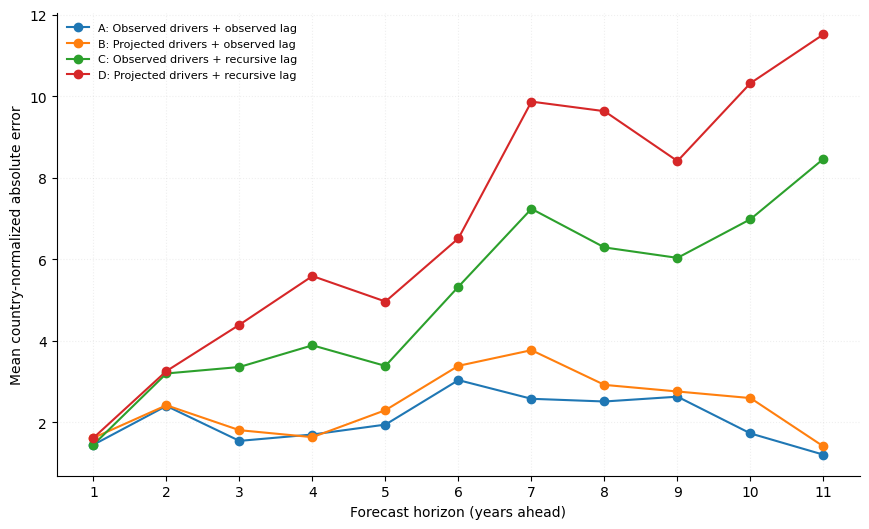

CELL 22 — STAGE-B A/B/C/D ERROR DECOMPOSITION

Frozen model : CatBoost (Config 13)

A = observed drivers + observed lag (conditional diagnostic)
B = projected drivers + observed lag
C = observed drivers + recursive predicted lag
D = projected drivers + recursive predicted lag (actual operational pipeline)

[Table 4.7] A/B/C/D DIAGNOSTIC RESULTS


,Scenario,Scenario_Label,Window,Macro_MASE,Worst_Country_MASE,RMSE,MAE,MAPE,Within_Country_R2
0,A,Observed drivers + observed lag,2014-2024,2.0680,3.9299,0.1735,0.1124,4.83%,0.5787
1,A,Observed drivers + observed lag,2014-2019,2.0148,3.6622,0.1652,0.1051,4.86%,0.4167
2,B,Projected drivers + observed lag,2014-2024,2.4210,4.6476,0.2043,0.1255,5.62%,0.4160
3,B,Projected drivers + observed lag,2014-2019,2.1958,4.4099,0.1909,0.1155,5.30%,0.2214
4,C,Observed drivers + recursive lag,2014-2024,5.0568,13.3740,0.6296,0.3852,11.88%,-4.5473
5,C,Observed drivers + recursive lag,2014-2019,3.4357,8.6328,0.3709,0.2354,8.67%,-1.9387
6,D,Projected drivers + recursive lag,2014-2024,6.9169,17.7041,0.8815,0.5241,15.65%,-9.8729
7,D,Projected drivers + recursive lag,2014-2019,4.3902,12.2907,0.5372,0.3179,10.95%,-5.1641



MACRO-MASE DECOMPOSITION CONTRASTS


,Window,A_Conditional_Diagnostic,B_ProjectedDrivers_ObservedLag,C_ObservedDrivers_RecursiveLag,D_FullPipeline,Driver_Projection_Contrast_B_minus_A,Recursive_Lag_Contrast_C_minus_A,Interaction_Contrast,Total_Operational_Gap_D_minus_A
0,2014-2024,2.0680,2.4210,5.0568,6.9169,+0.3530,+2.9887,+1.5071,+4.8489
1,2014-2019,2.0148,2.1958,3.4357,4.3902,+0.1810,+1.4209,+0.7735,+2.3754



COUNTRY-LEVEL DECOMPOSITION — FULL 2014-2024 WINDOW


Scenario,country,A,B,C,D,Driver_Contrast_B_minus_A,Recursion_Contrast_C_minus_A,Interaction,Total_Gap_D_minus_A
0,Vietnam,3.429,4.005,13.374,17.704,+0.576,+9.945,+3.754,+14.275
1,Thailand,1.210,1.232,6.840,6.974,+0.022,+5.630,+0.112,+5.764
2,Malaysia,1.086,1.115,4.222,6.944,+0.029,+3.136,+2.693,+5.858
3,India,1.615,2.027,2.873,6.031,+0.412,+1.258,+2.746,+4.416
4,Pakistan,3.930,4.648,3.624,5.195,+0.718,-0.305,+0.853,+1.265
5,Bangladesh,1.723,2.111,1.878,4.938,+0.388,+0.155,+2.673,+3.215
6,Sri Lanka,2.122,2.474,4.736,4.786,+0.352,+2.613,-0.301,+2.664
7,Indonesia,1.429,1.756,2.907,2.762,+0.327,+1.478,-0.472,+1.333



SCENARIO D — FULL-PIPELINE ERROR BY HORIZON


,Horizon,Year,Mean_Error,MAE,RMSE,Macro_Normalized_AE
0,1,2014,0.0020,0.0984,0.1418,1.6201
1,2,2015,0.0466,0.2346,0.3988,3.2585
2,3,2016,0.0829,0.3200,0.5229,4.3948
3,4,2017,0.1243,0.3846,0.5927,5.5892
4,5,2018,0.1126,0.3768,0.5797,4.9642
5,6,2019,0.0480,0.4933,0.7691,6.5146
6,7,2020,0.2410,0.7305,1.0632,9.8668
7,8,2021,0.3459,0.7122,1.0145,9.6321
8,9,2022,0.3771,0.6866,1.0634,8.4088
9,10,2023,0.4936,0.8399,1.2998,10.3201



INTEGRITY
  ✓ Scenario D reproduces Cell 21 (max difference = 0.00e+00)
  ✓ Same frozen Stage-B model used in A/B/C/D
  ✓ A/B/C are diagnostic oracle scenarios only
  ✓ Scenario A is not reported as the Stage-A model result
  ✓ D is the actual operational pipeline
  ✓ No model/configuration/driver method reselected

INTERPRETATION NOTE
  B-A is the predictive contrast associated with replacing observed drivers by projected drivers while retaining observed CO2 lags.
  C-A is the predictive contrast associated with replacing observed CO2 lags by recursive model feedback while retaining observed drivers.
  D-B-C+A is the non-additive interaction between driver projection and recursive feedback.
  Because an interaction term is present, B-A and C-A are not reported as percentage shares of the total gap.
  All contrasts are predictive diagnostics, not causal effects.

OUTPUTS: Table 4.7 A/B/C/D decomposition → Main text | country decomposition + normalized horizon diagnostic → Appendix | s

In [23]:
# ============================================================
# CELL 22 — STAGE-B A/B/C/D ERROR DECOMPOSITION
# ============================================================
# Run after Cell 21. Use its same fitted, frozen Stage-B model throughout.
# A: observed drivers + observed lag; B: projected drivers + observed lag.
# C: observed drivers + recursive lag; D: projected drivers + recursive lag.
# A/B/C are oracle diagnostics, not deployable forecasts or Stage-A results.
# D must reproduce Cell 21. Contrasts are predictive, not causal attribution.
# Preserve formulas, feature order, exports, graph and display formatting.
# No model, configuration or driver method is reselected or fitted here.

import matplotlib.pyplot as plt


# 1. Check frozen model identity and the eleven-year held-out design
assert FROZEN_STAGE_B_WINNER == STAGE_B_WINNER
assert FROZEN_STAGE_B_CONFIG_ID == STAGE_B_WINNER_CONFIG_ID
assert HOLDOUT_ORIGIN == 2013
assert HOLDOUT_START == 2014
assert HOLDOUT_END == 2024
assert HOLDOUT_HORIZON == 11
assert MATCHED_HORIZON_END == 2019
assert len(stage_b_holdout_predictions) == 88
assert len(stage_a_holdout) == 88
NON_LAG_FEATURES = [
    feature for feature in PRIMARY_FEATURES if feature != "co2_lag1"
]
assert len(NON_LAG_FEATURES) == 8


# 2. Keep separate observed/projected driver features and observed CO2 lags
OBSERVED_NONLAG_FEATURES = (
    stage_a_holdout[["country", "year"] + NON_LAG_FEATURES]
    .copy().sort_values(["year", "country"]).reset_index(drop=True)
)
PROJECTED_NONLAG_FEATURES = (
    STAGE_B_HOLDOUT_FEATURES[["country", "year"] + NON_LAG_FEATURES]
    .copy().sort_values(["year", "country"]).reset_index(drop=True)
)
OBSERVED_CO2_LAGS = stage_a_holdout[["country", "year", "co2_lag1"]].copy()
assert len(OBSERVED_NONLAG_FEATURES) == 88
assert len(PROJECTED_NONLAG_FEATURES) == 88
assert len(OBSERVED_CO2_LAGS) == 88
assert np.isfinite(OBSERVED_NONLAG_FEATURES[NON_LAG_FEATURES].to_numpy()).all()
assert np.isfinite(PROJECTED_NONLAG_FEATURES[NON_LAG_FEATURES].to_numpy()).all()


# 3. Run one scenario with the specified driver panel and lag source
def run_abcd_scenario(nonlag_features, lag_mode, scenario, scenario_label):
    """Return eleven-year predictions using observed or recursively predicted lags."""
    assert lag_mode in ["observed", "recursive"]
    countries = sorted(nonlag_features["country"].unique())
    current_recursive_co2 = (
        df[df["year"] == HOLDOUT_ORIGIN].set_index("country")["co2_per_capita"]
        .reindex(countries).astype(float).to_numpy()
    )
    records = []

    for horizon, year in enumerate(sorted(nonlag_features["year"].unique()), start=1):
        block = (
            nonlag_features[nonlag_features["year"] == year]
            .set_index("country").reindex(countries)
        )
        if lag_mode == "observed":
            lag_values = (
                OBSERVED_CO2_LAGS[OBSERVED_CO2_LAGS["year"] == year]
                .set_index("country")["co2_lag1"]
                .reindex(countries).astype(float).to_numpy()
            )
        else:
            lag_values = current_recursive_co2

        X = block[NON_LAG_FEATURES].copy()
        X["co2_lag1"] = lag_values
        X = X[PRIMARY_FEATURES].astype(float)
        assert np.isfinite(X.to_numpy()).all()
        delta = np.asarray(stage_b_holdout_model.predict(X), dtype=float).reshape(-1)
        if not np.isfinite(delta).all():
            raise FloatingPointError(
                f"Scenario {scenario}: " "non-finite delta-log prediction"
            )

        with np.errstate(over="ignore", invalid="ignore"):
            predicted_co2 = lag_values * np.exp(delta)
        if not np.isfinite(predicted_co2).all() or not (predicted_co2 > 0).all():
            raise FloatingPointError(f"Scenario {scenario}: " "invalid CO2 prediction")

        for country, prediction, pred_delta, lag_value in zip(
            countries, predicted_co2, delta, lag_values
        ):
            records.append({
                "Scenario": scenario,
                "Scenario_Label": scenario_label,
                "country": country,
                "year": int(year),
                "Horizon": int(horizon),
                "Input_CO2_Lag": float(lag_value),
                "Predicted_Delta_Log_CO2": float(pred_delta),
                "Predicted_CO2": float(prediction),
            })
        if lag_mode == "recursive":
            current_recursive_co2 = predicted_co2

    output = pd.DataFrame(records)
    assert len(output) == 88
    return output


# 4. Use the same fitted model in all four scenarios
scenario_labels = {
    "A": "Observed drivers + observed lag",
    "B": "Projected drivers + observed lag",
    "C": "Observed drivers + recursive lag",
    "D": "Projected drivers + recursive lag",
}
scenario_a = run_abcd_scenario(
    nonlag_features=OBSERVED_NONLAG_FEATURES,
    lag_mode="observed", scenario="A", scenario_label=scenario_labels["A"],
)
scenario_b = run_abcd_scenario(
    nonlag_features=PROJECTED_NONLAG_FEATURES,
    lag_mode="observed", scenario="B", scenario_label=scenario_labels["B"],
)
scenario_c = run_abcd_scenario(
    nonlag_features=OBSERVED_NONLAG_FEATURES,
    lag_mode="recursive", scenario="C", scenario_label=scenario_labels["C"],
)
scenario_d = run_abcd_scenario(
    nonlag_features=PROJECTED_NONLAG_FEATURES,
    lag_mode="recursive", scenario="D", scenario_label=scenario_labels["D"],
)
scenario_frames = {"A": scenario_a, "B": scenario_b, "C": scenario_c, "D": scenario_d}
STAGE_B_ABCD_PREDICTIONS = pd.concat(list(scenario_frames.values()), ignore_index=True)


# 5. Verify that D reproduces the operational predictions from Cell 21
d_check = scenario_d[["country", "year", "Predicted_CO2"]].merge(
    stage_b_holdout_predictions[["country", "year", "Predicted_CO2"]],
    on=["country", "year"], suffixes=("_Cell22", "_Cell21"), validate="one_to_one",
)
max_d_difference = float(np.max(np.abs(
    d_check["Predicted_CO2_Cell22"] - d_check["Predicted_CO2_Cell21"]
)))
assert max_d_difference < 1e-10


# 6. Score a scenario/window without recentering predictions or clipping R2
def score_abcd_window(predictions, year_end):
    """Return level-error metrics, country-normalised MASE and within-country R2."""
    scored = (
        predictions.merge(
            holdout_truth, on=["country", "year"], how="inner", validate="one_to_one"
        )
        .query("year <= @year_end").copy().reset_index(drop=True)
    )
    error = scored["Predicted_CO2"] - scored["Actual_CO2"]
    country_mase = []
    for country, sub in scored.groupby("country"):
        country_mae = float(np.mean(np.abs(sub["Predicted_CO2"] - sub["Actual_CO2"])))
        country_mase.append(country_mae / development_mase_denom(country))
    country_mean = scored.groupby("country")["Actual_CO2"].transform("mean")
    ss_res = float(np.sum(np.square(error)))
    ss_tot_within = float(np.sum(np.square(scored["Actual_CO2"] - country_mean)))
    within_r2 = 1 - ss_res / ss_tot_within
    return {
        "Macro_MASE": float(np.mean(country_mase)),
        "Worst_Country_MASE": float(np.max(country_mase)),
        "RMSE": float(np.sqrt(np.mean(np.square(error)))),
        "MAE": float(np.mean(np.abs(error))),
        "MAPE": float(np.mean(np.abs(error / scored["Actual_CO2"])) * 100),
        "Within_Country_R2": float(within_r2),
        "N": len(scored),
    }


# 7. Preserve scenario order and both full/matched windows in Table 4.7
abcd_rows = []
for scenario, predictions in scenario_frames.items():
    for year_end, window_role in [
        (HOLDOUT_END, "Primary full window"),
        (MATCHED_HORIZON_END, "Matched six-year window"),
    ]:
        metrics = score_abcd_window(predictions, year_end)
        abcd_rows.append({
            "Scenario": scenario,
            "Scenario_Label": scenario_labels[scenario],
            "Window": f"{HOLDOUT_START}-{year_end}",
            "Window_Role": window_role,
            **metrics,
        })
stage_b_abcd_results = pd.DataFrame(abcd_rows)


# 8. Compute signed predictive contrasts, not percentage or causal shares
contrast_rows = []
for window in stage_b_abcd_results["Window"].unique():
    sub = stage_b_abcd_results[stage_b_abcd_results["Window"] == window].set_index("Scenario")
    A = float(sub.loc["A", "Macro_MASE"])
    B = float(sub.loc["B", "Macro_MASE"])
    C = float(sub.loc["C", "Macro_MASE"])
    D = float(sub.loc["D", "Macro_MASE"])
    driver_contrast = B - A
    recursion_contrast = C - A
    interaction = D - B - C + A
    total_gap = D - A
    assert np.isclose(total_gap, driver_contrast + recursion_contrast + interaction)
    contrast_rows.append({
        "Window": window,
        "A_Conditional_Diagnostic": A,
        "B_ProjectedDrivers_ObservedLag": B,
        "C_ObservedDrivers_RecursiveLag": C,
        "D_FullPipeline": D,
        "Driver_Projection_Contrast_B_minus_A": driver_contrast,
        "Recursive_Lag_Contrast_C_minus_A": recursion_contrast,
        "Interaction_Contrast": interaction,
        "Total_Operational_Gap_D_minus_A": total_gap,
    })
stage_b_abcd_contrasts = pd.DataFrame(contrast_rows)


# 9. Apply the same decomposition to country MASE over the full window
country_rows = []
for scenario, predictions in scenario_frames.items():
    scored = predictions.merge(holdout_truth, on=["country", "year"], validate="one_to_one")
    for country, sub in scored.groupby("country"):
        mae = float(np.mean(np.abs(sub["Predicted_CO2"] - sub["Actual_CO2"])))
        country_rows.append({
            "country": country, "Scenario": scenario,
            "MASE": mae / development_mase_denom(country),
        })
country_wide = (
    pd.DataFrame(country_rows).pivot(index="country", columns="Scenario", values="MASE")
    .reset_index()
)
country_wide["Driver_Contrast_B_minus_A"] = country_wide["B"] - country_wide["A"]
country_wide["Recursion_Contrast_C_minus_A"] = country_wide["C"] - country_wide["A"]
country_wide["Interaction"] = country_wide["D"] - country_wide["B"] - country_wide["C"] + country_wide["A"]
country_wide["Total_Gap_D_minus_A"] = country_wide["D"] - country_wide["A"]
stage_b_abcd_country_contrasts = (
    country_wide.sort_values("D", ascending=False).reset_index(drop=True)
)


# 10. Summarise error at each horizon, including country-normalised error
horizon_frames = []
for scenario, predictions in scenario_frames.items():
    scored = predictions.merge(
        holdout_truth, on=["country", "year"], how="inner", validate="one_to_one"
    ).copy()
    scored["Error"] = scored["Predicted_CO2"] - scored["Actual_CO2"]
    scored["Abs_Error"] = np.abs(scored["Error"])
    scored["Normalized_Abs_Error"] = [
        abs_error / development_mase_denom(country)
        for abs_error, country in zip(scored["Abs_Error"], scored["country"])
    ]
    horizon = scored.groupby("Horizon", as_index=False).agg(
        Year=("year", "first"),
        Mean_Error=("Error", "mean"),
        MAE=("Abs_Error", "mean"),
        RMSE=("Error", lambda x: float(np.sqrt(np.mean(np.square(x))))),
        Macro_Normalized_AE=("Normalized_Abs_Error", "mean"),
    )
    horizon.insert(0, "Scenario_Label", scenario_labels[scenario])
    horizon.insert(0, "Scenario", scenario)
    horizon_frames.append(horizon)
stage_b_abcd_horizon = pd.concat(horizon_frames, ignore_index=True)
stage_b_full_pipeline_horizon = (
    stage_b_abcd_horizon[stage_b_abcd_horizon["Scenario"] == "D"]
    .copy().reset_index(drop=True)
)


# 11. Keep the original appendix horizon figure and PNG/PDF export settings
fig, ax = plt.subplots(figsize=(8.8, 5.4))
for scenario in ["A", "B", "C", "D"]:
    sub = stage_b_abcd_horizon[stage_b_abcd_horizon["Scenario"] == scenario]
    ax.plot(
        sub["Horizon"], sub["Macro_Normalized_AE"], marker="o", linewidth=1.5,
        label=f"{scenario}: {scenario_labels[scenario]}",
    )
ax.set_xlabel("Forecast horizon (years ahead)")
ax.set_ylabel("Mean country-normalized absolute error")
ax.set_xticks(range(1, HOLDOUT_HORIZON + 1))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.2, linestyle=":")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
ABCD_HORIZON_PNG = FIGURES_DIR / "appendix_stage_b_abcd_horizon.png"
ABCD_HORIZON_PDF = FIGURES_DIR / "appendix_stage_b_abcd_horizon.pdf"
fig.savefig(ABCD_HORIZON_PNG, dpi=300, bbox_inches="tight")
fig.savefig(ABCD_HORIZON_PDF, bbox_inches="tight")
plt.show()


# 12. Save all five original CSV files at full numeric precision
stage_b_abcd_results.to_csv(
    TABLES_DIR / "table_4_7_stage_b_abcd_decomposition.csv", index=False
)
stage_b_abcd_contrasts.to_csv(TABLES_DIR / "stage_b_abcd_contrasts.csv", index=False)
stage_b_abcd_country_contrasts.to_csv(
    TABLES_DIR / "appendix_stage_b_abcd_country_contrasts.csv", index=False
)
stage_b_abcd_horizon.to_csv(TABLES_DIR / "stage_b_abcd_horizon_detail.csv", index=False)
STAGE_B_ABCD_PREDICTIONS.to_csv(TABLES_DIR / "stage_b_abcd_predictions.csv", index=False)


# 13. Preserve the original report text, signs and decimal formatting
print("=" * 78)
print("CELL 22 — STAGE-B A/B/C/D ERROR DECOMPOSITION")
print("=" * 78)
print(f"\nFrozen model : {FROZEN_STAGE_B_WINNER} (Config {FROZEN_STAGE_B_CONFIG_ID})")
print("\nA = observed drivers + observed lag " "(conditional diagnostic)")
print("B = projected drivers + observed lag")
print("C = observed drivers + recursive predicted lag")
print("D = projected drivers + recursive predicted lag " "(actual operational pipeline)")

print("\n[Table 4.7] A/B/C/D DIAGNOSTIC RESULTS")
display(stage_b_abcd_results[
    ["Scenario", "Scenario_Label", "Window", "Macro_MASE", "Worst_Country_MASE",
     "RMSE", "MAE", "MAPE", "Within_Country_R2"]
].style.format({
    "Macro_MASE": "{:.4f}",
    "Worst_Country_MASE": "{:.4f}",
    "RMSE": "{:.4f}",
    "MAE": "{:.4f}",
    "MAPE": "{:.2f}%",
    "Within_Country_R2": "{:.4f}",
}))

print("\nMACRO-MASE DECOMPOSITION CONTRASTS")
display(stage_b_abcd_contrasts.style.format({
    "A_Conditional_Diagnostic": "{:.4f}",
    "B_ProjectedDrivers_ObservedLag": "{:.4f}",
    "C_ObservedDrivers_RecursiveLag": "{:.4f}",
    "D_FullPipeline": "{:.4f}",
    "Driver_Projection_Contrast_B_minus_A": "{:+.4f}",
    "Recursive_Lag_Contrast_C_minus_A": "{:+.4f}",
    "Interaction_Contrast": "{:+.4f}",
    "Total_Operational_Gap_D_minus_A": "{:+.4f}",
}))

print("\nCOUNTRY-LEVEL DECOMPOSITION — FULL 2014-2024 WINDOW")
display(stage_b_abcd_country_contrasts[
    ["country", "A", "B", "C", "D", "Driver_Contrast_B_minus_A",
     "Recursion_Contrast_C_minus_A", "Interaction", "Total_Gap_D_minus_A"]
].style.format({
    "A": "{:.3f}", "B": "{:.3f}", "C": "{:.3f}", "D": "{:.3f}",
    "Driver_Contrast_B_minus_A": "{:+.3f}",
    "Recursion_Contrast_C_minus_A": "{:+.3f}",
    "Interaction": "{:+.3f}",
    "Total_Gap_D_minus_A": "{:+.3f}",
}))

print("\nSCENARIO D — FULL-PIPELINE ERROR BY HORIZON")
display(stage_b_full_pipeline_horizon[
    ["Horizon", "Year", "Mean_Error", "MAE", "RMSE", "Macro_Normalized_AE"]
].style.format({
    "Mean_Error": "{:.4f}", "MAE": "{:.4f}",
    "RMSE": "{:.4f}", "Macro_Normalized_AE": "{:.4f}",
}))

print("\nINTEGRITY")
print(
    f"  ✓ Scenario D reproduces Cell 21 "
    f"(max difference = {max_d_difference:.2e})"
)
print("  ✓ Same frozen Stage-B model used in A/B/C/D")
print("  ✓ A/B/C are diagnostic oracle scenarios only")
print("  ✓ Scenario A is not reported as the Stage-A model result")
print("  ✓ D is the actual operational pipeline")
print("  ✓ No model/configuration/driver method reselected")

print("\nINTERPRETATION NOTE")
print(
    "  B-A is the predictive contrast associated with replacing "
    "observed drivers by projected drivers while retaining "
    "observed CO2 lags."
)
print(
    "  C-A is the predictive contrast associated with replacing "
    "observed CO2 lags by recursive model feedback while "
    "retaining observed drivers."
)
print(
    "  D-B-C+A is the non-additive interaction between "
    "driver projection and recursive feedback."
)
print(
    "  Because an interaction term is present, B-A and C-A are "
    "not reported as percentage shares of the total gap."
)
print("  All contrasts are predictive diagnostics, not causal effects.")
print(
    "\nOUTPUTS: "
    "Table 4.7 A/B/C/D decomposition → Main text | "
    "country decomposition + normalized horizon diagnostic → Appendix | "
    "scenario predictions → Notebook only"
)


/tmp/ipykernel_3367/1100501971.py:145: RuntimeWarning: Mean of empty slice
  "Driver_Scaled_MAE": float(np.nanmean(scaled_error)),


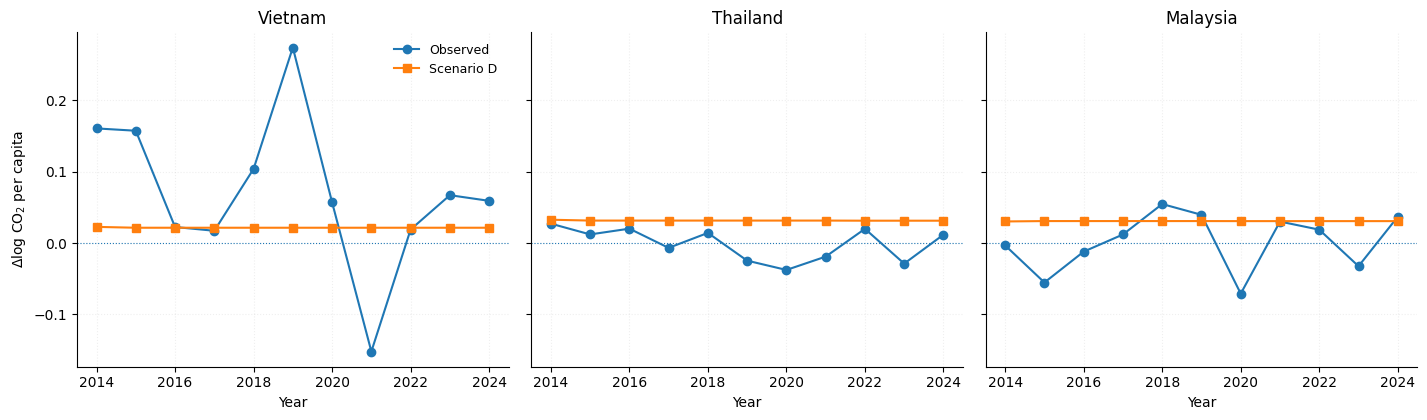

CELL 23 — DRIVER QUALITY, RANGE EXPOSURE & YEAR MECHANISM

[Table 4.8] DRIVER FORECAST QUALITY


,Driver,Mean_Projection_Space_MAE,Mean_Driver_Scaled_MAE,Median_Driver_Scaled_MAE,Worst_Driver_Scaled_MAE,Worst_Country,Persistence_Selections,Flat_Projection_Series,Flat_Last3_Series,Bound_Hit_Rows
0,renewables_share_energy,4.2444,3.731,2.942,8.420,Vietnam,4,4,4,0
1,coal_cons_per_capita,0.5156,2.813,2.008,7.551,Pakistan,4,4,4,0
2,oil_energy_per_capita,0.1850,2.570,2.176,5.943,Indonesia,4,4,4,0
3,energy_per_capita,0.1581,2.488,2.505,4.903,Vietnam,1,1,1,0
4,gdp_per_capita,0.0590,1.402,1.250,2.653,Thailand,0,0,0,0
5,gas_energy_per_capita,0.1452,1.253,0.838,3.257,Pakistan,3,3,3,11
6,Avg_Temperature_C,0.3134,1.186,1.118,1.859,Bangladesh,3,3,3,0



DRIVER QUALITY BY COUNTRY


,country,Mean_Driver_Scaled_MAE,Median_Driver_Scaled_MAE,Worst_Driver_Scaled_MAE
0,Vietnam,3.649,2.539,8.420
1,Indonesia,2.739,1.471,6.886
2,Pakistan,2.592,1.853,7.551
3,Sri Lanka,2.275,2.395,3.100
4,Thailand,2.084,1.871,4.543
5,Malaysia,2.026,1.674,5.186
6,India,1.342,1.326,2.713
7,Bangladesh,1.086,0.614,2.145



WORST COUNTRY-DRIVER SERIES


...


Malaysia


,year,Horizon,Input_CO2_Lag,Predicted_CO2,Actual_CO2,Error_Percent,Predicted_Delta_Log_CO2,Actual_Delta_Log_CO2,Mean_Driver_Scaled_AE,N_Features_Out_Of_Range,OOR__co2_lag1
0,2014,1,8.0092,8.2560,7.9832,+3.42%,+0.0303,-0.0032,0.349,1,1
1,2015,2,8.2560,8.5149,7.5543,+12.72%,+0.0309,-0.0552,0.921,1,1
2,2016,3,8.5149,8.7821,7.4645,+17.65%,+0.0309,-0.0120,1.184,1,1
3,2017,4,8.7821,9.0576,7.5553,+19.88%,+0.0309,+0.0121,1.450,1,1
4,2018,5,9.0576,9.3417,7.9805,+17.06%,+0.0309,+0.0548,1.630,1,1
5,2019,6,9.3417,9.6348,8.3035,+16.03%,+0.0309,+0.0397,1.873,1,1
6,2020,7,9.6348,9.9363,7.7357,+28.45%,+0.0308,-0.0708,2.983,1,1
7,2021,8,9.9363,10.2473,7.9730,+28.53%,+0.0308,+0.0302,3.146,1,1
8,2022,9,10.2473,10.5680,8.1245,+30.08%,+0.0308,+0.0188,2.521,1,1
9,2023,10,10.5680,10.8987,7.8658,+38.56%,+0.0308,-0.0324,2.996,1,1



COUNTRY DRIVER QUALITY VS CO2 ERROR


,country,Mean_Driver_Scaled_MAE,Worst_Driver_Scaled_MAE,A,B,C,Full_Pipeline_CO2_MASE,Driver_Contrast_B_minus_A,Recursion_Contrast_C_minus_A,Interaction,Total_Gap_D_minus_A
0,Vietnam,3.649,8.420,3.429151,4.005081,13.374008,17.704,+0.576,+9.945,+3.754,+14.275
1,Thailand,2.084,4.543,1.210017,1.232288,6.840449,6.974,+0.022,+5.630,+0.112,+5.764
2,Malaysia,2.026,5.186,1.086025,1.115468,4.221941,6.944,+0.029,+3.136,+2.693,+5.858
3,India,1.342,2.713,1.614789,2.026779,2.873257,6.031,+0.412,+1.258,+2.746,+4.416
4,Pakistan,2.592,7.551,3.929883,4.647563,3.624433,5.195,+0.718,-0.305,+0.853,+1.265
5,Bangladesh,1.086,2.145,1.723059,2.110599,1.877765,4.938,+0.388,+0.155,+2.673,+3.215
6,Sri Lanka,2.275,3.100,2.122342,2.474423,4.735550,4.786,+0.352,+2.613,-0.301,+2.664
7,Indonesia,2.739,6.886,1.429050,1.756146,2.906796,2.762,+0.327,+1.478,-0.472,+1.333



INTEGRITY / INTERPRETATION
  ✓ Observed 2014-2024 drivers used only for diagnostic scoring
  ✓ Frozen Cell-19 driver methods unchanged
  ✓ Frozen Cell-20 Stage-B model unchanged
  ✓ Driver scaling uses only pre-2014 history
  ✓ Positive scale drivers assessed in log1p projection space
  ✓ Model input range uses GLOBAL development feature coverage
  ✓ Year is not a model predictor
  ✓ Year/horizon behaviour must operate through input paths and recursive CO2 state
  ✓ Range exposure and low output dispersion are diagnostics of extrapolation/compression risk, not proof of saturation

OUTPUTS: Table 4.8 driver forecast quality → Main text/compact support | range exposure + A-vs-D dispersion + year mechanism → Appendix | worst-country traces + observation-level driver errors → Notebook/Appendix


In [24]:
# ============================================================
# CELL 23 — DRIVER QUALITY, RANGE EXPOSURE & YEAR MECHANISM
# ============================================================
# Run after Cell 22. Diagnose driver errors, flat/bounded paths, exact
# Scenario-D feature ranges, A-vs-D growth dispersion and yearly mechanisms.
# Preserve transformations, formulas, sorting, rounding and saved filenames.
# Driver errors use held-out observations; scaling uses pre-2014 history only.
# Range exposure/compression are risk diagnostics, not proof of saturation.
# Nothing is fitted, reselected or changed in the forecasting pipeline here.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1. Check the held-out panel and keep year out of the model predictors
assert HOLDOUT_ORIGIN == 2013
assert HOLDOUT_START == 2014
assert HOLDOUT_END == 2024
assert HOLDOUT_HORIZON == 11
assert len(STAGE_B_HOLDOUT_DRIVER_PANEL) == 8 * 12
assert len(stage_b_holdout_predictions) == 88
assert len(scenario_a) == 88
assert len(scenario_d) == 88
assert len(stage_b_abcd_country_contrasts) == 8
assert "year" not in PRIMARY_FEATURES

SCALE_LOG1P_DRIVERS = [
    "energy_per_capita", "oil_energy_per_capita", "coal_cons_per_capita",
    "gas_energy_per_capita", "gdp_per_capita",
]
LEVEL_DRIVERS = ["renewables_share_energy", "Avg_Temperature_C"]
assert set(SCALE_LOG1P_DRIVERS + LEVEL_DRIVERS) == set(STAGE_B_DRIVER_LEVELS)


# 2. Use the same driver projection spaces as Cell 19
def driver_diagnostic_transform(values, driver):
    """Use log1p for scale drivers and unchanged levels for share/temperature."""
    values = np.asarray(values, dtype=float)
    if driver in SCALE_LOG1P_DRIVERS:
        assert (values >= 0).all()
        return np.log1p(values)
    return values.copy()


# 3. Compare projected and observed raw drivers over 2014–2024
projected_long = (
    STAGE_B_HOLDOUT_DRIVER_PANEL[
        STAGE_B_HOLDOUT_DRIVER_PANEL["year"].between(HOLDOUT_START, HOLDOUT_END)
    ]
    .melt(
        id_vars=["country", "year"], value_vars=STAGE_B_DRIVER_LEVELS,
        var_name="Driver", value_name="Projected_Value",
    )
)
actual_long = (
    df[df["year"].between(HOLDOUT_START, HOLDOUT_END)]
    [["country", "year"] + STAGE_B_DRIVER_LEVELS]
    .melt(
        id_vars=["country", "year"], value_vars=STAGE_B_DRIVER_LEVELS,
        var_name="Driver", value_name="Actual_Value",
    )
)
driver_holdout_detail = projected_long.merge(
    actual_long, on=["country", "year", "Driver"], how="inner", validate="one_to_one"
)
assert len(driver_holdout_detail) == 8 * HOLDOUT_HORIZON * len(STAGE_B_DRIVER_LEVELS)
assert not driver_holdout_detail[["Projected_Value", "Actual_Value"]].isna().any().any()


# 4. Attach each country-driver's frozen forecasting method
method_rows = []
for country in sorted(df["country"].unique()):
    for driver in STAGE_B_DRIVER_LEVELS:
        method_rows.append({
            "country": country, "Driver": driver,
            "Selected_Method": FULL_DEVELOPMENT_DRIVER_METHOD_MAP[country][driver],
        })
driver_method_table = pd.DataFrame(method_rows)
driver_holdout_detail = driver_holdout_detail.merge(
    driver_method_table, on=["country", "Driver"], validate="many_to_one"
)


# 5. Scale driver errors using historical changes in that driver's projection space
# This is a MASE-like driver diagnostic, not the CO2 MASE denominator.
driver_denom_rows = []
for country in sorted(df["country"].unique()):
    history_frame = df[
        (df["country"] == country) & (df["year"] <= HOLDOUT_ORIGIN)
    ].sort_values("year")
    for driver in STAGE_B_DRIVER_LEVELS:
        history = history_frame[driver].dropna().to_numpy(dtype=float)
        transformed = driver_diagnostic_transform(history, driver)
        changes = np.abs(np.diff(transformed))
        denominator = float(np.mean(changes))
        if not np.isfinite(denominator) or denominator <= 0:
            denominator = np.nan
        driver_denom_rows.append({
            "country": country, "Driver": driver,
            "Driver_Scale_Denominator": denominator,
            "History_N": len(transformed),
        })
driver_scale_denominators = pd.DataFrame(driver_denom_rows)
driver_holdout_detail = driver_holdout_detail.merge(
    driver_scale_denominators, on=["country", "Driver"], validate="many_to_one"
)


# 6. Compute raw, projection-space and scaled observation-level errors
driver_holdout_detail["Raw_Error"] = (
    driver_holdout_detail["Projected_Value"] - driver_holdout_detail["Actual_Value"]
)
driver_holdout_detail["Raw_Abs_Error"] = np.abs(driver_holdout_detail["Raw_Error"])
projection_error_frames = []
for driver, sub in driver_holdout_detail.groupby("Driver", sort=False):
    projected_t = driver_diagnostic_transform(sub["Projected_Value"].to_numpy(), driver)
    actual_t = driver_diagnostic_transform(sub["Actual_Value"].to_numpy(), driver)
    temp = sub[["country", "year", "Driver"]].copy()
    temp["Projection_Space_Error"] = projected_t - actual_t
    projection_error_frames.append(temp)
projection_space_errors = pd.concat(projection_error_frames, ignore_index=True)
driver_holdout_detail = driver_holdout_detail.merge(
    projection_space_errors, on=["country", "year", "Driver"], validate="one_to_one"
)
driver_holdout_detail["Projection_Space_Abs_Error"] = np.abs(
    driver_holdout_detail["Projection_Space_Error"]
)
driver_holdout_detail["Driver_Scaled_Abs_Error"] = (
    driver_holdout_detail["Projection_Space_Abs_Error"]
    / driver_holdout_detail["Driver_Scale_Denominator"]
)


# 7. Summarise quality separately for every country-driver series
series_quality_rows = []
for (country, driver), sub in driver_holdout_detail.groupby(["country", "Driver"]):
    raw_error = sub["Raw_Error"].to_numpy(dtype=float)
    projection_error = sub["Projection_Space_Error"].to_numpy(dtype=float)
    scaled_error = sub["Driver_Scaled_Abs_Error"].to_numpy(dtype=float)
    series_quality_rows.append({
        "country": country, "Driver": driver,
        "Selected_Method": sub["Selected_Method"].iloc[0],
        "Projection_Space_MAE": float(np.mean(np.abs(projection_error))),
        "Driver_Scaled_MAE": float(np.nanmean(scaled_error)),
        "Raw_MAE": float(np.mean(np.abs(raw_error))),
        "Raw_RMSE": float(np.sqrt(np.mean(np.square(raw_error)))),
        "Raw_Bias": float(np.mean(raw_error)),
    })
stage_b_driver_series_quality = pd.DataFrame(series_quality_rows)


# 8. Audit flat paths and hits on the existing projection bounds
LOWER_BOUNDS = {
    "energy_per_capita": 0.0, "oil_energy_per_capita": 0.0,
    "coal_cons_per_capita": 0.0, "gas_energy_per_capita": 0.0,
    "gdp_per_capita": 0.0, "renewables_share_energy": 0.0,
}
UPPER_BOUNDS = {"renewables_share_energy": 100.0}
path_rows = []
for (country, driver), sub in driver_holdout_detail.groupby(["country", "Driver"]):
    projected = sub.sort_values("year")["Projected_Value"].to_numpy(dtype=float)
    lower = LOWER_BOUNDS.get(driver)
    upper = UPPER_BOUNDS.get(driver)
    lower_hits = (
        0 if lower is None
        else int(np.isclose(projected, lower, atol=1e-10, rtol=0).sum())
    )
    upper_hits = (
        0 if upper is None
        else int(np.isclose(projected, upper, atol=1e-10, rtol=0).sum())
    )
    path_rows.append({
        "country": country, "Driver": driver,
        "Selected_Method": sub["Selected_Method"].iloc[0],
        "Projected_Min": float(projected.min()),
        "Projected_Max": float(projected.max()),
        "Projected_Range": float(np.ptp(projected)),
        "Flat_Full_Path": bool(np.ptp(projected) <= 1e-10),
        "Flat_Last_3_Years": bool(np.ptp(projected[-3:]) <= 1e-10),
        "Lower_Bound_Hits": lower_hits,
        "Upper_Bound_Hits": upper_hits,
        "Total_Bound_Hits": lower_hits + upper_hits,
    })
stage_b_driver_path_audit = pd.DataFrame(path_rows)


# 9. Preserve the country-averaged driver quality summary for Table 4.8
driver_summary_rows = []
for driver in STAGE_B_DRIVER_LEVELS:
    quality = stage_b_driver_series_quality[
        stage_b_driver_series_quality["Driver"] == driver
    ].copy()
    path = stage_b_driver_path_audit[stage_b_driver_path_audit["Driver"] == driver]
    valid = quality.dropna(subset=["Driver_Scaled_MAE"])
    if len(valid) > 0:
        worst_row = valid.sort_values("Driver_Scaled_MAE", ascending=False).iloc[0]
        mean_scaled = float(valid["Driver_Scaled_MAE"].mean())
        median_scaled = float(valid["Driver_Scaled_MAE"].median())
        worst_scaled = float(valid["Driver_Scaled_MAE"].max())
        worst_country = worst_row["country"]
    else:
        mean_scaled = np.nan
        median_scaled = np.nan
        worst_scaled = np.nan
        worst_country = None
    driver_summary_rows.append({
        "Driver": driver,
        "Mean_Projection_Space_MAE": float(quality["Projection_Space_MAE"].mean()),
        "Mean_Driver_Scaled_MAE": mean_scaled,
        "Median_Driver_Scaled_MAE": median_scaled,
        "Worst_Driver_Scaled_MAE": worst_scaled,
        "Worst_Country": worst_country,
        "Persistence_Selections": int((quality["Selected_Method"] == "Persistence").sum()),
        "Flat_Projection_Series": int(path["Flat_Full_Path"].sum()),
        "Flat_Last3_Series": int(path["Flat_Last_3_Years"].sum()),
        "Bound_Hit_Rows": int(path["Total_Bound_Hits"].sum()),
    })
stage_b_driver_quality_summary = (
    pd.DataFrame(driver_summary_rows)
    .sort_values("Mean_Driver_Scaled_MAE", ascending=False).reset_index(drop=True)
)


# 10. Summarise driver quality by country and retain the twelve worst series
stage_b_driver_quality_by_country = (
    stage_b_driver_series_quality.groupby("country", as_index=False).agg(
        Mean_Driver_Scaled_MAE=("Driver_Scaled_MAE", "mean"),
        Median_Driver_Scaled_MAE=("Driver_Scaled_MAE", "median"),
        Worst_Driver_Scaled_MAE=("Driver_Scaled_MAE", "max"),
    )
    .sort_values("Mean_Driver_Scaled_MAE", ascending=False).reset_index(drop=True)
)
stage_b_worst_driver_series = (
    stage_b_driver_series_quality.sort_values("Driver_Scaled_MAE", ascending=False)
    .head(12).reset_index(drop=True)
)


# 11. Recover the exact Scenario-D model inputs, including recursive CO2 lags
stage_b_d_input_panel = STAGE_B_HOLDOUT_FEATURES.merge(
    stage_b_holdout_predictions[["country", "year", "Input_CO2_Lag"]],
    on=["country", "year"], validate="one_to_one",
)
stage_b_d_input_panel["co2_lag1"] = stage_b_d_input_panel["Input_CO2_Lag"]


# 12. Compare each input with its GLOBAL development training range
# Do not substitute country-specific ranges or clip the supplied feature values.
feature_range_rows = []
stage_b_feature_range_row_audit = stage_b_d_input_panel[["country", "year"]].copy()
for feature in PRIMARY_FEATURES:
    train_min = float(stage_a_full_train[feature].min())
    train_max = float(stage_a_full_train[feature].max())
    values = stage_b_d_input_panel[feature].to_numpy(dtype=float)
    below = values < train_min
    above = values > train_max
    outside = below | above
    stage_b_feature_range_row_audit[f"OOR__{feature}"] = outside.astype(int)
    train_range = train_max - train_min
    if train_range > 0:
        excursion = np.zeros(len(values), dtype=float)
        excursion[below] = (train_min - values[below]) / train_range
        excursion[above] = (values[above] - train_max) / train_range
        max_excursion = float(excursion.max())
    else:
        max_excursion = np.nan
    feature_range_rows.append({
        "Feature": feature,
        "Train_Min": train_min,
        "Train_Max": train_max,
        "Below_Train_Min_N": int(below.sum()),
        "Above_Train_Max_N": int(above.sum()),
        "Out_Of_Range_N": int(outside.sum()),
        "Out_Of_Range_Percent": float(outside.mean() * 100),
        "Max_Train_Range_Excursion": max_excursion,
    })
stage_b_feature_range_audit = (
    pd.DataFrame(feature_range_rows)
    .sort_values(["Out_Of_Range_Percent", "Max_Train_Range_Excursion"], ascending=False)
    .reset_index(drop=True)
)
oor_columns = [
    column for column in stage_b_feature_range_row_audit.columns
    if column.startswith("OOR__")
]
stage_b_feature_range_row_audit["N_Features_Out_Of_Range"] = (
    stage_b_feature_range_row_audit[oor_columns].sum(axis=1)
)


# 13. Compare growth-output dispersion in A and D; this is not proof of saturation
actual_delta = stage_a_holdout[["country", "year", TARGET]].rename(
    columns={TARGET: "Actual_Delta_Log_CO2"}
)
a_growth = scenario_a[["country", "year", "Predicted_Delta_Log_CO2"]].rename(
    columns={"Predicted_Delta_Log_CO2": "Predicted_Delta_A"}
)
d_growth = scenario_d[
    ["country", "year", "Predicted_Delta_Log_CO2", "Input_CO2_Lag"]
].rename(columns={"Predicted_Delta_Log_CO2": "Predicted_Delta_D"})
dispersion_source = (
    actual_delta.merge(a_growth, on=["country", "year"], validate="one_to_one")
    .merge(d_growth, on=["country", "year"], validate="one_to_one")
)
dispersion_rows = []
for country, sub in dispersion_source.groupby("country"):
    actual_values = sub["Actual_Delta_Log_CO2"].to_numpy(dtype=float)
    a_values = sub["Predicted_Delta_A"].to_numpy(dtype=float)
    d_values = sub["Predicted_Delta_D"].to_numpy(dtype=float)
    sd_actual = float(np.std(actual_values, ddof=1))
    sd_a = float(np.std(a_values, ddof=1))
    sd_d = float(np.std(d_values, ddof=1))
    dispersion_rows.append({
        "country": country,
        "Mean_Actual_Delta": float(actual_values.mean()),
        "Mean_Predicted_Delta_A": float(a_values.mean()),
        "Mean_Predicted_Delta_D": float(d_values.mean()),
        "SD_Actual_Delta": sd_actual,
        "SD_Predicted_Delta_A": sd_a,
        "SD_Predicted_Delta_D": sd_d,
        "Dispersion_Ratio_A": sd_a / sd_actual if sd_actual > 0 else np.nan,
        "Dispersion_Ratio_D": sd_d / sd_actual if sd_actual > 0 else np.nan,
        "D_to_A_Predicted_SD_Ratio": sd_d / sd_a if sd_a > 0 else np.nan,
        "Distinct_Delta_A_6dp": int(len(np.unique(np.round(a_values, 6)))),
        "Distinct_Delta_D_6dp": int(len(np.unique(np.round(d_values, 6)))),
    })
stage_b_output_dispersion = (
    pd.DataFrame(dispersion_rows).sort_values("Dispersion_Ratio_D").reset_index(drop=True)
)
mean_dispersion_a = float(stage_b_output_dispersion["Dispersion_Ratio_A"].mean())
mean_dispersion_d = float(stage_b_output_dispersion["Dispersion_Ratio_D"].mean())


# 14. Summarise input-range exposure by year
feature_range_by_year = stage_b_feature_range_row_audit.groupby("year", as_index=False).agg(
    Mean_Features_Out_Of_Range=("N_Features_Out_Of_Range", "mean"),
    Max_Features_Out_Of_Range=("N_Features_Out_Of_Range", "max"),
)


# 15. Summarise scaled driver errors for each country-year
driver_country_year_error = driver_holdout_detail.groupby(
    ["country", "year"], as_index=False
).agg(
    Mean_Driver_Scaled_AE=("Driver_Scaled_Abs_Error", "mean"),
    Median_Driver_Scaled_AE=("Driver_Scaled_Abs_Error", "median"),
)


# 16. Trace the three largest country-level recursive-lag contrasts from Cell 22
worst_countries = stage_b_abcd_country_contrasts.nlargest(
    3, "Recursion_Contrast_C_minus_A"
)["country"].tolist()
mechanism = (
    scenario_d.merge(holdout_truth, on=["country", "year"], validate="one_to_one")
    .merge(actual_delta, on=["country", "year"], validate="one_to_one")
    .merge(driver_country_year_error, on=["country", "year"], validate="one_to_one")
    .merge(
        stage_b_feature_range_row_audit[
            ["country", "year", "N_Features_Out_Of_Range", "OOR__co2_lag1"]
        ],
        on=["country", "year"], validate="one_to_one",
    )
)
mechanism["CO2_Error"] = mechanism["Predicted_CO2"] - mechanism["Actual_CO2"]
mechanism["Error_Percent"] = mechanism["CO2_Error"] / mechanism["Actual_CO2"] * 100
mechanism["Delta_Error"] = (
    mechanism["Predicted_Delta_Log_CO2"] - mechanism["Actual_Delta_Log_CO2"]
)
worst_country_mechanism = (
    mechanism[mechanism["country"].isin(worst_countries)]
    .sort_values(["country", "year"]).reset_index(drop=True)
)


# 17. Aggregate the same mechanism across countries at each year/horizon
stage_b_year_mechanism = mechanism.groupby(["Horizon", "year"], as_index=False).agg(
    Mean_Input_CO2_Lag=("Input_CO2_Lag", "mean"),
    Mean_Predicted_Delta_Log=("Predicted_Delta_Log_CO2", "mean"),
    Mean_Actual_Delta_Log=("Actual_Delta_Log_CO2", "mean"),
    Mean_Delta_Error=("Delta_Error", "mean"),
    Mean_CO2_Error=("CO2_Error", "mean"),
    CO2_MAE=("CO2_Error", lambda x: float(np.mean(np.abs(x)))),
    Mean_Driver_Scaled_AE=("Mean_Driver_Scaled_AE", "mean"),
    Mean_Features_Out_Of_Range=("N_Features_Out_Of_Range", "mean"),
    Countries_With_Lag_OOR=("OOR__co2_lag1", "sum"),
)


# 18. Join country driver quality with its CO2 diagnostic decomposition
country_driver_quality = stage_b_driver_series_quality.groupby("country", as_index=False).agg(
    Mean_Driver_Scaled_MAE=("Driver_Scaled_MAE", "mean"),
    Worst_Driver_Scaled_MAE=("Driver_Scaled_MAE", "max"),
)
stage_b_country_driver_vs_co2 = (
    country_driver_quality.merge(
        stage_b_abcd_country_contrasts[
            ["country", "A", "B", "C", "D", "Driver_Contrast_B_minus_A",
             "Recursion_Contrast_C_minus_A", "Interaction", "Total_Gap_D_minus_A"]
        ],
        on="country", validate="one_to_one",
    )
    .rename(columns={"D": "Full_Pipeline_CO2_MASE"})
    .sort_values("Full_Pipeline_CO2_MASE", ascending=False).reset_index(drop=True)
)


# 19. Preserve the three-country appendix growth-mechanism figure
fig, axes = plt.subplots(
    1, len(worst_countries), figsize=(4.8 * len(worst_countries), 4.3), sharey=True
)
axes = np.atleast_1d(axes)
for ax, country in zip(axes, worst_countries):
    sub = worst_country_mechanism[worst_country_mechanism["country"] == country]
    ax.plot(sub["year"], sub["Actual_Delta_Log_CO2"], marker="o", linewidth=1.5, label="Observed")
    ax.plot(sub["year"], sub["Predicted_Delta_Log_CO2"], marker="s", linewidth=1.5, label="Scenario D")
    ax.axhline(0, linewidth=0.8, linestyle=":")
    ax.set_title(country)
    ax.set_xlabel("Year")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.2, linestyle=":")
axes[0].set_ylabel(r"$\Delta$log CO$_2$ per capita")
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()
MECHANISM_PNG = FIGURES_DIR / "appendix_recursive_output_mechanism.png"
MECHANISM_PDF = FIGURES_DIR / "appendix_recursive_output_mechanism.pdf"
fig.savefig(MECHANISM_PNG, dpi=300, bbox_inches="tight")
fig.savefig(MECHANISM_PDF, bbox_inches="tight")
plt.show()


# 20. Save all ten original CSV files without rounding stored values
driver_holdout_detail.to_csv(TABLES_DIR / "stage_b_driver_holdout_detail.csv", index=False)
stage_b_driver_series_quality.to_csv(TABLES_DIR / "stage_b_driver_series_quality.csv", index=False)
stage_b_driver_quality_summary.to_csv(TABLES_DIR / "table_4_8_driver_forecast_quality.csv", index=False)
stage_b_driver_quality_by_country.to_csv(TABLES_DIR / "stage_b_driver_quality_by_country.csv", index=False)
stage_b_driver_path_audit.to_csv(TABLES_DIR / "stage_b_driver_path_bound_audit.csv", index=False)
stage_b_feature_range_audit.to_csv(TABLES_DIR / "stage_b_feature_range_exposure.csv", index=False)
stage_b_output_dispersion.to_csv(TABLES_DIR / "stage_b_output_dispersion_A_vs_D.csv", index=False)
stage_b_year_mechanism.to_csv(TABLES_DIR / "stage_b_year_mechanism.csv", index=False)
worst_country_mechanism.to_csv(TABLES_DIR / "appendix_worst_country_recursive_mechanism.csv", index=False)
stage_b_country_driver_vs_co2.to_csv(TABLES_DIR / "stage_b_country_driver_vs_co2.csv", index=False)


# 21. Preserve the original report text and display precision
print("=" * 78)
print("CELL 23 — DRIVER QUALITY, RANGE EXPOSURE & YEAR MECHANISM")
print("=" * 78)

print("\n[Table 4.8] DRIVER FORECAST QUALITY")
display(stage_b_driver_quality_summary[
    ["Driver", "Mean_Projection_Space_MAE", "Mean_Driver_Scaled_MAE",
     "Median_Driver_Scaled_MAE", "Worst_Driver_Scaled_MAE", "Worst_Country",
     "Persistence_Selections", "Flat_Projection_Series", "Flat_Last3_Series", "Bound_Hit_Rows"]
].style.format({
    "Mean_Projection_Space_MAE": "{:.4f}",
    "Mean_Driver_Scaled_MAE": "{:.3f}",
    "Median_Driver_Scaled_MAE": "{:.3f}",
    "Worst_Driver_Scaled_MAE": "{:.3f}",
}))

print("\nDRIVER QUALITY BY COUNTRY")
display(stage_b_driver_quality_by_country.style.format({
    "Mean_Driver_Scaled_MAE": "{:.3f}",
    "Median_Driver_Scaled_MAE": "{:.3f}",
    "Worst_Driver_Scaled_MAE": "{:.3f}",
}))

print("\nWORST COUNTRY-DRIVER SERIES")
display(stage_b_worst_driver_series[
    ["country", "Driver", "Selected_Method", "Projection_Space_MAE",
     "Driver_Scaled_MAE", "Raw_MAE", "Raw_Bias"]
].style.format({
    "Projection_Space_MAE": "{:.4f}", "Driver_Scaled_MAE": "{:.3f}",
    "Raw_MAE": "{:.3f}", "Raw_Bias": "{:+.3f}",
}))

print("\nDRIVER PATH / BOUND AUDIT")
print(
    "  Full-path flat series : "
    f"{int(stage_b_driver_path_audit['Flat_Full_Path'].sum())}"
    f" / {len(stage_b_driver_path_audit)}"
)
print(
    "  Flat in final 3 years : "
    f"{int(stage_b_driver_path_audit['Flat_Last_3_Years'].sum())}"
    f" / {len(stage_b_driver_path_audit)}"
)
print("  Total bound-hit rows  : " f"{int(stage_b_driver_path_audit['Total_Bound_Hits'].sum())}")

print("\nTREE INPUT RANGE-EXPOSURE AUDIT")
display(stage_b_feature_range_audit[
    ["Feature", "Train_Min", "Train_Max", "Below_Train_Min_N", "Above_Train_Max_N",
     "Out_Of_Range_N", "Out_Of_Range_Percent", "Max_Train_Range_Excursion"]
].style.format({
    "Train_Min": "{:.4f}", "Train_Max": "{:.4f}",
    "Out_Of_Range_Percent": "{:.1f}%", "Max_Train_Range_Excursion": "{:.3f}",
}))

print("\nOUTPUT-DISPERSION DIAGNOSTIC — A VS D")
display(stage_b_output_dispersion[
    ["country", "SD_Actual_Delta", "SD_Predicted_Delta_A", "SD_Predicted_Delta_D",
     "Dispersion_Ratio_A", "Dispersion_Ratio_D", "D_to_A_Predicted_SD_Ratio",
     "Distinct_Delta_A_6dp", "Distinct_Delta_D_6dp"]
].style.format({
    "SD_Actual_Delta": "{:.4f}", "SD_Predicted_Delta_A": "{:.4f}",
    "SD_Predicted_Delta_D": "{:.4f}", "Dispersion_Ratio_A": "{:.3f}",
    "Dispersion_Ratio_D": "{:.3f}", "D_to_A_Predicted_SD_Ratio": "{:.3f}",
}))
print(f"\nMean dispersion ratio — Scenario A : {mean_dispersion_a:.3f}")
print(f"Mean dispersion ratio — Scenario D : {mean_dispersion_d:.3f}")

print("\nYEAR / HORIZON MECHANISM")
display(stage_b_year_mechanism.style.format({
    "Mean_Input_CO2_Lag": "{:.4f}", "Mean_Predicted_Delta_Log": "{:+.4f}",
    "Mean_Actual_Delta_Log": "{:+.4f}", "Mean_Delta_Error": "{:+.4f}",
    "Mean_CO2_Error": "{:+.4f}", "CO2_MAE": "{:.4f}",
    "Mean_Driver_Scaled_AE": "{:.3f}", "Mean_Features_Out_Of_Range": "{:.2f}",
    "Countries_With_Lag_OOR": "{:.0f}",
}))

print("\nWORST RECURSION-CONTRAST COUNTRIES")
print("  " + ", ".join(worst_countries))
for country in worst_countries:
    print(f"\n{country}")
    display(worst_country_mechanism[worst_country_mechanism["country"] == country][
        ["year", "Horizon", "Input_CO2_Lag", "Predicted_CO2", "Actual_CO2", "Error_Percent",
         "Predicted_Delta_Log_CO2", "Actual_Delta_Log_CO2", "Mean_Driver_Scaled_AE",
         "N_Features_Out_Of_Range", "OOR__co2_lag1"]
    ].style.format({
        "Input_CO2_Lag": "{:.4f}", "Predicted_CO2": "{:.4f}", "Actual_CO2": "{:.4f}",
        "Error_Percent": "{:+.2f}%", "Predicted_Delta_Log_CO2": "{:+.4f}",
        "Actual_Delta_Log_CO2": "{:+.4f}", "Mean_Driver_Scaled_AE": "{:.3f}",
    }))

print("\nCOUNTRY DRIVER QUALITY VS CO2 ERROR")
display(stage_b_country_driver_vs_co2.style.format({
    "Mean_Driver_Scaled_MAE": "{:.3f}", "Worst_Driver_Scaled_MAE": "{:.3f}",
    "Full_Pipeline_CO2_MASE": "{:.3f}", "Driver_Contrast_B_minus_A": "{:+.3f}",
    "Recursion_Contrast_C_minus_A": "{:+.3f}", "Interaction": "{:+.3f}",
    "Total_Gap_D_minus_A": "{:+.3f}",
}))

print("\nINTEGRITY / INTERPRETATION")
print("  ✓ Observed 2014-2024 drivers used only for diagnostic scoring")
print("  ✓ Frozen Cell-19 driver methods unchanged")
print("  ✓ Frozen Cell-20 Stage-B model unchanged")
print("  ✓ Driver scaling uses only pre-2014 history")
print("  ✓ Positive scale drivers assessed in log1p projection space")
print("  ✓ Model input range uses GLOBAL development feature coverage")
print("  ✓ Year is not a model predictor")
print("  ✓ Year/horizon behaviour must operate through input paths " "and recursive CO2 state")
print(
    "  ✓ Range exposure and low output dispersion are diagnostics "
    "of extrapolation/compression risk, not proof of saturation"
)
print(
    "\nOUTPUTS: "
    "Table 4.8 driver forecast quality → Main text/compact support | "
    "range exposure + A-vs-D dispersion + year mechanism → Appendix | "
    "worst-country traces + observation-level driver errors → Notebook/Appendix"
)


In [25]:
# ============================================================
# CELL 24 — CLASSICAL + LINEAR OPERATIONAL BENCHMARKS
# ============================================================
# Run after Cells 1–23, with the project dependencies installed.
# Select comparator identities using four pre-2014 six-year CV folds.
# Evaluate 2014–2024 (primary) and 2014–2019 (matched diagnostic).
# Preserve candidate order, convergence rules, audits and no clipping.
# Recent-Trend benchmarks remain reserved for Cell 29.

import warnings

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing


# ------------------------------------------------------------
# 1. INTEGRITY AND METHOD IDENTITIES
# ------------------------------------------------------------
assert HOLDOUT_ORIGIN == 2013
assert HOLDOUT_START == 2014
assert HOLDOUT_END == 2024
assert HOLDOUT_HORIZON == 11
assert N_STAGE_B_FOLDS == 4
assert FROZEN_STAGE_B_WINNER == STAGE_B_WINNER
assert FROZEN_STAGE_B_CONFIG_ID == STAGE_B_WINNER_CONFIG_ID
assert len(STAGE_B_PROJECTED_FEATURES) == 4
assert len(STAGE_B_HOLDOUT_FEATURES) == 88

CLASSICAL_UNIVARIATE_BENCHMARKS = [
    "Persistence", "Country_Mean", "Country_Trend", "ARIMA", "ETS",
]
PANEL_FE_LABEL = "Panel OLS-FE"
STAGE_B_LABEL = f"{FROZEN_STAGE_B_WINNER} recursive pipeline"
CELL24_COMPARATOR_METHODS = (
    CLASSICAL_UNIVARIATE_BENCHMARKS + [PANEL_FE_LABEL]
)


# ------------------------------------------------------------
# 2. LOCKED CANDIDATES AND AUDITS
# ------------------------------------------------------------
ARIMA_ORDERS = [
    (0, 1, 0), (1, 1, 0), (0, 1, 1),
    (1, 1, 1), (2, 1, 0), (0, 1, 2),
]
ETS_SPECS = [
    {"trend": None, "damped_trend": False, "name": "No_Trend"},
    {"trend": "add", "damped_trend": False, "name": "Additive_Trend"},
    {"trend": "add", "damped_trend": True, "name": "Damped_Additive_Trend"},
]

# Reset both audits when this cell is rerun.
baseline_fit_audit_rows = []
candidate_issue_rows = []


# ------------------------------------------------------------
# 3. CONVERGENCE HELPER
# ------------------------------------------------------------
def fit_converged(fit):
    """Read reported convergence; retain the original unknown-status rule."""
    ret = getattr(fit, "mle_retvals", None)
    if ret is None:
        return True
    if isinstance(ret, dict):
        if "converged" in ret:
            return bool(ret["converged"])
        if "success" in ret:
            return bool(ret["success"])
        return True
    if hasattr(ret, "converged"):
        return bool(ret.converged)
    if hasattr(ret, "success"):
        return bool(ret.success)
    return True


# ------------------------------------------------------------
# 4. CLASSICAL FORECASTS — TRAINING-ONLY AIC SELECTION
# ------------------------------------------------------------
def forecast_classical_baseline(
    history, horizon, method, country, origin, evaluation_set,
):
    """Forecast levels and audit rejected candidates or persistence fallback."""
    y = np.asarray(history, dtype=float)
    assert len(y) >= 10
    assert np.isfinite(y).all()
    assert (y > 0).all()

    fallback_used = False
    fallback_reason = ""
    selected_spec = ""
    selected_converged = np.nan

    if method == "Persistence":
        pred = np.repeat(y[-1], horizon)
        selected_spec = "Last observed value"

    elif method == "Country_Mean":
        pred = np.repeat(y.mean(), horizon)
        selected_spec = "Historical level mean"

    elif method == "Country_Trend":
        x = np.arange(len(y)).reshape(-1, 1)
        model = LinearRegression().fit(x, y)
        pred = model.predict(
            np.arange(len(y), len(y) + horizon).reshape(-1, 1)
        )
        selected_spec = "OLS linear time trend"

    elif method == "ARIMA":
        valid_candidates = []
        for order in ARIMA_ORDERS:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    fit = ARIMA(
                        y, order=order,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit()

                converged = fit_converged(fit)
                candidate_pred = np.asarray(fit.forecast(horizon), dtype=float)
                aic = float(fit.aic)
                finite_positive = (
                    len(candidate_pred) == horizon
                    and np.isfinite(candidate_pred).all()
                    and (candidate_pred > 0).all()
                    and np.isfinite(aic)
                )

                if not converged:
                    candidate_issue_rows.append({
                        "Evaluation_Set": evaluation_set,
                        "Origin": origin,
                        "country": country,
                        "Method": "ARIMA",
                        "Candidate": str(order),
                        "Issue": "not_converged",
                    })
                elif not finite_positive:
                    candidate_issue_rows.append({
                        "Evaluation_Set": evaluation_set,
                        "Origin": origin,
                        "country": country,
                        "Method": "ARIMA",
                        "Candidate": str(order),
                        "Issue": "invalid_forecast_or_AIC",
                    })
                else:
                    valid_candidates.append({
                        "AIC": aic, "Order": order, "Forecast": candidate_pred,
                    })
            except Exception as exc:
                candidate_issue_rows.append({
                    "Evaluation_Set": evaluation_set,
                    "Origin": origin,
                    "country": country,
                    "Method": "ARIMA",
                    "Candidate": str(order),
                    "Issue": type(exc).__name__,
                })

        if len(valid_candidates) > 0:
            best = sorted(
                valid_candidates,
                key=lambda z: (z["AIC"], ARIMA_ORDERS.index(z["Order"])),
            )[0]
            pred = best["Forecast"]
            selected_spec = f"ARIMA{best['Order']}"
            selected_converged = True
        else:
            pred = np.repeat(y[-1], horizon)
            fallback_used = True
            fallback_reason = "no_valid_converged_ARIMA_candidate"
            selected_spec = "Persistence fallback"

    elif method == "ETS":
        valid_candidates = []
        ets_order = [spec["name"] for spec in ETS_SPECS]
        for spec in ETS_SPECS:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    fit = ExponentialSmoothing(
                        y,
                        trend=spec["trend"],
                        damped_trend=spec["damped_trend"],
                        seasonal=None,
                        initialization_method="estimated",
                    ).fit(optimized=True)

                converged = fit_converged(fit)
                candidate_pred = np.asarray(fit.forecast(horizon), dtype=float)
                aic = float(fit.aic)
                finite_positive = (
                    len(candidate_pred) == horizon
                    and np.isfinite(candidate_pred).all()
                    and (candidate_pred > 0).all()
                    and np.isfinite(aic)
                )

                if not converged:
                    candidate_issue_rows.append({
                        "Evaluation_Set": evaluation_set,
                        "Origin": origin,
                        "country": country,
                        "Method": "ETS",
                        "Candidate": spec["name"],
                        "Issue": "not_converged",
                    })
                elif not finite_positive:
                    candidate_issue_rows.append({
                        "Evaluation_Set": evaluation_set,
                        "Origin": origin,
                        "country": country,
                        "Method": "ETS",
                        "Candidate": spec["name"],
                        "Issue": "invalid_forecast_or_AIC",
                    })
                else:
                    valid_candidates.append({
                        "AIC": aic, "Spec": spec, "Forecast": candidate_pred,
                    })
            except Exception as exc:
                candidate_issue_rows.append({
                    "Evaluation_Set": evaluation_set,
                    "Origin": origin,
                    "country": country,
                    "Method": "ETS",
                    "Candidate": spec["name"],
                    "Issue": type(exc).__name__,
                })

        if len(valid_candidates) > 0:
            best = sorted(
                valid_candidates,
                key=lambda z: (z["AIC"], ets_order.index(z["Spec"]["name"])),
            )[0]
            pred = best["Forecast"]
            selected_spec = best["Spec"]["name"]
            selected_converged = True
        else:
            pred = np.repeat(y[-1], horizon)
            fallback_used = True
            fallback_reason = "no_valid_converged_ETS_candidate"
            selected_spec = "Persistence fallback"

    else:
        raise ValueError(f"Unknown benchmark: {method}")

    # Reject invalid paths instead of clipping individual forecast values.
    pred = np.asarray(pred, dtype=float)
    if (
        len(pred) != horizon
        or not np.isfinite(pred).all()
        or not (pred > 0).all()
    ):
        pred = np.repeat(y[-1], horizon)
        fallback_used = True
        fallback_reason = "invalid_nonpositive_or_nonfinite_forecast"
        selected_spec = "Persistence fallback"
        selected_converged = np.nan

    baseline_fit_audit_rows.append({
        "Evaluation_Set": evaluation_set,
        "Origin": origin,
        "country": country,
        "Method": method,
        "Selected_Spec": selected_spec,
        "Selected_Classical_Fit_Converged": selected_converged,
        "Fallback_Used": fallback_used,
        "Fallback_Reason": fallback_reason,
    })
    return pred


# ------------------------------------------------------------
# 5. FOLD-SPECIFIC MASE DENOMINATOR ACCESS
# ------------------------------------------------------------
def stage_b_cv_denom(fold, country):
    """Read a positive historical denominator from the supported containers."""
    obj = STAGE_B_DENOMINATORS[fold]
    if isinstance(obj, dict):
        value = obj[country]
    elif isinstance(obj, pd.Series):
        value = obj.loc[country]
    elif isinstance(obj, pd.DataFrame):
        if "country" in obj.columns and "MASE_Denominator" in obj.columns:
            value = obj.loc[
                obj["country"] == country, "MASE_Denominator"
            ].iloc[0]
        else:
            value = obj.loc[country, "MASE_Denominator"]
    else:
        raise TypeError("Unsupported STAGE_B_DENOMINATORS object")

    value = float(value)
    assert np.isfinite(value)
    assert value > 0
    return value


# ------------------------------------------------------------
# 6. FORECAST SCORING
# ------------------------------------------------------------
def score_forecast_frame(predictions, truth, denom_function):
    """Score levels; Macro-MASE is the unweighted mean of country MASEs."""
    scored = predictions.merge(
        truth, on=["country", "year"], how="inner", validate="one_to_one"
    ).reset_index(drop=True)
    assert len(scored) == len(predictions)

    error = scored["Predicted_CO2"] - scored["Actual_CO2"]
    country_rows = []
    for country, sub in scored.groupby("country"):
        country_mae = float(
            np.mean(np.abs(sub["Predicted_CO2"] - sub["Actual_CO2"]))
        )
        country_rows.append({
            "country": country,
            "MASE": country_mae / float(denom_function(country)),
        })
    country_mase = pd.DataFrame(country_rows)

    # Both R2 measures use the same SSE, without residual recentering.
    ss_res = float(np.sum(np.square(error)))
    pooled_mean = float(scored["Actual_CO2"].mean())
    pooled_sst = float(np.sum(np.square(scored["Actual_CO2"] - pooled_mean)))
    country_mean = scored.groupby("country")["Actual_CO2"].transform("mean")
    within_sst = float(np.sum(np.square(scored["Actual_CO2"] - country_mean)))

    return {
        "Macro_MASE": float(country_mase["MASE"].mean()),
        "Worst_Country_MASE": float(country_mase["MASE"].max()),
        "RMSE": float(np.sqrt(np.mean(np.square(error)))),
        "MAE": float(np.mean(np.abs(error))),
        "MAPE": float(np.mean(np.abs(error / scored["Actual_CO2"])) * 100),
        "Pooled_R2": float(1 - ss_res / pooled_sst),
        "Within_Country_R2": float(1 - ss_res / within_sst),
        "Country_MASE": country_mase,
        "Scored": scored,
    }


# ------------------------------------------------------------
# 7. PANEL OLS-FE DESIGN AND RECURSIVE FORECAST
# ------------------------------------------------------------
FE_COUNTRIES = sorted(df["country"].unique())


def build_fe_design(frame, design_columns=None):
    """Combine the original predictors with seven aligned country dummies."""
    base = frame[PRIMARY_FEATURES].astype(float).copy()
    categories = pd.Categorical(frame["country"], categories=FE_COUNTRIES)
    dummies = pd.get_dummies(
        categories, prefix="FE", drop_first=True, dtype=float
    )
    dummies.index = frame.index
    X = pd.concat([base, dummies], axis=1)
    if design_columns is not None:
        X = X.reindex(columns=design_columns, fill_value=0.0)
    assert np.isfinite(X.to_numpy()).all()
    return X


def fit_panel_ols_fe(train_frame):
    """Fit the linear delta-log model on the supplied training sample."""
    X = build_fe_design(train_frame)
    y = train_frame[TARGET].astype(float)
    model = LinearRegression()
    model.fit(X, y)
    return model, list(X.columns)


def recursive_panel_fe_forecast(
    model, design_columns, projected_features, origin_co2,
):
    """Use projected indicators and feed each predicted level into the next lag."""
    countries = sorted(projected_features["country"].unique())
    current_co2 = origin_co2.reindex(countries).astype(float).to_numpy()
    records = []

    for horizon, year in enumerate(
        sorted(projected_features["year"].unique()), start=1
    ):
        block = (
            projected_features[projected_features["year"] == year]
            .set_index("country").reindex(countries).reset_index()
        )
        block["co2_lag1"] = current_co2
        X = build_fe_design(block, design_columns=design_columns)
        delta = np.asarray(model.predict(X), dtype=float).reshape(-1)
        if not np.isfinite(delta).all():
            raise FloatingPointError("Panel OLS-FE produced non-finite prediction")

        with np.errstate(over="ignore", invalid="ignore"):
            predicted = current_co2 * np.exp(delta)
        if not np.isfinite(predicted).all() or not (predicted > 0).all():
            raise FloatingPointError("Panel OLS-FE recursive level invalid")

        for country, pred, pred_delta in zip(countries, predicted, delta):
            records.append({
                "country": country,
                "year": int(year),
                "Horizon": int(horizon),
                "Predicted_Delta_Log_CO2": float(pred_delta),
                "Predicted_CO2": float(pred),
            })
        current_co2 = predicted

    return pd.DataFrame(records)


# ------------------------------------------------------------
# 8. FOUR PRE-2014 SIX-YEAR CV FOLDS
# ------------------------------------------------------------
print("=" * 78)
print("CELL 24 — CLASSICAL + LINEAR OPERATIONAL BENCHMARKS")
print("=" * 78)
print("\nRunning strict-convergence pre-2014 CV ...")

cv_fold_rows = []
cv_scored_frames = []

for _, fold_info in stage_b_folds.iterrows():
    fold = int(fold_info["Fold"])
    origin = int(fold_info["Train_End"])
    forecast_start = int(fold_info["Forecast_Start"])
    forecast_end = int(fold_info["Forecast_End"])
    truth = STAGE_B_FOLD_DATA[fold]["truth"][
        ["country", "year", "co2_per_capita"]
    ].rename(columns={"co2_per_capita": "Actual_CO2"})

    for method in CLASSICAL_UNIVARIATE_BENCHMARKS:
        prediction_rows = []
        for country in FE_COUNTRIES:
            history = (
                df[(df["country"] == country) & (df["year"] <= origin)]
                .sort_values("year")["co2_per_capita"].dropna().to_numpy(float)
            )
            forecast = forecast_classical_baseline(
                history=history, horizon=STAGE_B_HORIZON, method=method,
                country=country, origin=origin, evaluation_set=f"CV_Fold_{fold}",
            )
            for h, pred in enumerate(forecast, start=1):
                prediction_rows.append({
                    "country": country, "year": origin + h,
                    "Horizon": h, "Predicted_CO2": float(pred),
                })

        predictions = pd.DataFrame(prediction_rows)
        assert len(predictions) == 48
        metrics = score_forecast_frame(
            predictions, truth, lambda c, f=fold: stage_b_cv_denom(f, c)
        )
        cv_fold_rows.append({
            "Method": method,
            "Type": "Classical univariate benchmark",
            "Fold": fold,
            "Origin": origin,
            "Forecast_Start": forecast_start,
            "Forecast_End": forecast_end,
            "Macro_MASE": metrics["Macro_MASE"],
            "Worst_Country_MASE": metrics["Worst_Country_MASE"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
        })
        scored = metrics["Scored"].copy()
        scored.insert(0, "Fold", fold)
        scored.insert(0, "Method", method)
        cv_scored_frames.append(scored)

    fe_train = STAGE_B_FOLD_DATA[fold]["train"]
    fe_model_cv, fe_columns_cv = fit_panel_ols_fe(fe_train)
    fe_predictions = recursive_panel_fe_forecast(
        model=fe_model_cv, design_columns=fe_columns_cv,
        projected_features=STAGE_B_PROJECTED_FEATURES[fold],
        origin_co2=STAGE_B_ORIGIN_CO2[fold],
    )
    fe_metrics = score_forecast_frame(
        fe_predictions, truth, lambda c, f=fold: stage_b_cv_denom(f, c)
    )
    cv_fold_rows.append({
        "Method": PANEL_FE_LABEL,
        "Type": "Indicator-based linear benchmark",
        "Fold": fold,
        "Origin": origin,
        "Forecast_Start": forecast_start,
        "Forecast_End": forecast_end,
        "Macro_MASE": fe_metrics["Macro_MASE"],
        "Worst_Country_MASE": fe_metrics["Worst_Country_MASE"],
        "RMSE": fe_metrics["RMSE"],
        "MAE": fe_metrics["MAE"],
    })
    fe_scored = fe_metrics["Scored"].copy()
    fe_scored.insert(0, "Fold", fold)
    fe_scored.insert(0, "Method", PANEL_FE_LABEL)
    cv_scored_frames.append(fe_scored)

benchmark_cv_fold_results = pd.DataFrame(cv_fold_rows)
benchmark_cv_predictions = pd.concat(cv_scored_frames, ignore_index=True)


# ------------------------------------------------------------
# 9. BENCHMARK CV SUMMARY
# ------------------------------------------------------------
cv_summary_rows = []
for method in CELL24_COMPARATOR_METHODS:
    fold_sub = benchmark_cv_fold_results[
        benchmark_cv_fold_results["Method"] == method
    ]
    pred_sub = benchmark_cv_predictions[
        benchmark_cv_predictions["Method"] == method
    ]
    error = pred_sub["Predicted_CO2"] - pred_sub["Actual_CO2"]
    country_mean = pred_sub.groupby("country")["Actual_CO2"].transform("mean")
    ss_res = float(np.sum(np.square(error)))
    ss_tot = float(np.sum(np.square(pred_sub["Actual_CO2"] - country_mean)))
    method_type = (
        "Classical univariate benchmark"
        if method in CLASSICAL_UNIVARIATE_BENCHMARKS
        else "Indicator-based linear benchmark"
    )
    cv_summary_rows.append({
        "Method": method,
        "Type": method_type,
        "Mean_CV_Macro_MASE": float(fold_sub["Macro_MASE"].mean()),
        "SD_CV_Macro_MASE": float(fold_sub["Macro_MASE"].std(ddof=1)),
        "Pooled_CV_RMSE": float(np.sqrt(np.mean(np.square(error)))),
        "Pooled_CV_MAE": float(np.mean(np.abs(error))),
        "CV_Within_Country_R2": float(1 - ss_res / ss_tot),
    })
benchmark_cv_summary = pd.DataFrame(cv_summary_rows)


# ------------------------------------------------------------
# 10. ADD THE ALREADY-FROZEN STAGE-B WINNER
# ------------------------------------------------------------
stage_b_cv_pred = STAGE_B_WINNER_CV_PREDICTIONS.copy()
stage_b_cv_error = stage_b_cv_pred["Predicted_CO2"] - stage_b_cv_pred["Actual_CO2"]
stage_b_cv_country_mean = (
    stage_b_cv_pred.groupby("country")["Actual_CO2"].transform("mean")
)
stage_b_cv_ss_res = float(np.sum(np.square(stage_b_cv_error)))
stage_b_cv_ss_tot = float(
    np.sum(np.square(stage_b_cv_pred["Actual_CO2"] - stage_b_cv_country_mean))
)
stage_b_cv_row = pd.DataFrame([{
    "Method": STAGE_B_LABEL,
    "Type": "Indicator-based ML (Stage B)",
    "Mean_CV_Macro_MASE": float(STAGE_B_WINNER_CV_MASE),
    "SD_CV_Macro_MASE": float(
        stage_b_winner_fold_results["Macro_MASE"].std(ddof=1)
    ),
    "Pooled_CV_RMSE": float(np.sqrt(np.mean(np.square(stage_b_cv_error)))),
    "Pooled_CV_MAE": float(np.mean(np.abs(stage_b_cv_error))),
    "CV_Within_Country_R2": float(1 - stage_b_cv_ss_res / stage_b_cv_ss_tot),
}])
all_cv_summary = pd.concat(
    [benchmark_cv_summary, stage_b_cv_row], ignore_index=True
)
persistence_cv_mase = float(all_cv_summary.loc[
    all_cv_summary["Method"] == "Persistence", "Mean_CV_Macro_MASE"
].iloc[0])
all_cv_summary["CV_MASE_Improvement_vs_Persistence"] = (
    (persistence_cv_mase - all_cv_summary["Mean_CV_Macro_MASE"])
    / persistence_cv_mase * 100
)
all_cv_summary["CV_Rank"] = (
    all_cv_summary["Mean_CV_Macro_MASE"]
    .rank(ascending=True, method="min").astype(int)
)


# ------------------------------------------------------------
# 11. FREEZE COMPARATOR IDENTITIES USING CV ONLY
# ------------------------------------------------------------
BEST_CLASSICAL_UNIVARIATE_BENCHMARK_CV = str(
    benchmark_cv_summary[
        benchmark_cv_summary["Type"] == "Classical univariate benchmark"
    ].sort_values([
        "Mean_CV_Macro_MASE", "Pooled_CV_RMSE", "Pooled_CV_MAE"
    ]).iloc[0]["Method"]
)
BEST_CELL24_COMPARATOR_CV = str(
    benchmark_cv_summary.sort_values([
        "Mean_CV_Macro_MASE", "Pooled_CV_RMSE", "Pooled_CV_MAE"
    ]).iloc[0]["Method"]
)
# Compatibility alias only; the comparator can be indicator-based OLS-FE.
BEST_CLASSICAL_COMPARATOR_CV = BEST_CELL24_COMPARATOR_CV

print("\nPre-2014 benchmark selection complete.")
print(f"  Best classical univariate : {BEST_CLASSICAL_UNIVARIATE_BENCHMARK_CV}")
print(f"  Best Cell-24 comparator   : {BEST_CELL24_COMPARATOR_CV}")


# ------------------------------------------------------------
# 12. FROZEN CLASSICAL HELD-OUT FORECASTS
# ------------------------------------------------------------
print("\nGenerating frozen 2014-2024 forecasts ...")
heldout_prediction_frames = []
for method in CLASSICAL_UNIVARIATE_BENCHMARKS:
    rows = []
    for country in FE_COUNTRIES:
        history = (
            df[(df["country"] == country) & (df["year"] <= HOLDOUT_ORIGIN)]
            .sort_values("year")["co2_per_capita"].dropna().to_numpy(float)
        )
        forecast = forecast_classical_baseline(
            history=history, horizon=HOLDOUT_HORIZON, method=method,
            country=country, origin=HOLDOUT_ORIGIN,
            evaluation_set="Heldout_2014_2024",
        )
        for h, pred in enumerate(forecast, start=1):
            rows.append({
                "Method": method,
                "Type": "Classical univariate benchmark",
                "country": country,
                "year": HOLDOUT_ORIGIN + h,
                "Horizon": h,
                "Predicted_CO2": float(pred),
            })
    heldout_prediction_frames.append(pd.DataFrame(rows))


# ------------------------------------------------------------
# 13. RECURSIVE HELD-OUT PANEL OLS-FE
# ------------------------------------------------------------
heldout_fe_model, heldout_fe_columns = fit_panel_ols_fe(stage_a_full_train)
heldout_origin_co2 = (
    df[df["year"] == HOLDOUT_ORIGIN]
    .set_index("country")["co2_per_capita"].astype(float)
)
heldout_fe_predictions = recursive_panel_fe_forecast(
    model=heldout_fe_model, design_columns=heldout_fe_columns,
    projected_features=STAGE_B_HOLDOUT_FEATURES,
    origin_co2=heldout_origin_co2,
)
heldout_fe_predictions.insert(0, "Type", "Indicator-based linear benchmark")
heldout_fe_predictions.insert(0, "Method", PANEL_FE_LABEL)
heldout_prediction_frames.append(heldout_fe_predictions)


# ------------------------------------------------------------
# 14. REUSE STAGE-B OPERATIONAL PREDICTIONS — NO ML REFIT
# ------------------------------------------------------------
stage_b_operational_predictions = stage_b_holdout_predictions.copy()
stage_b_operational_predictions.insert(0, "Type", "Indicator-based ML (Stage B)")
stage_b_operational_predictions.insert(0, "Method", STAGE_B_LABEL)
heldout_prediction_frames.append(stage_b_operational_predictions)
operational_predictions = pd.concat(heldout_prediction_frames, ignore_index=True)


# ------------------------------------------------------------
# 15. PERSISTENCE MUST REPRODUCE CELL 21
# ------------------------------------------------------------
persistence_check = operational_predictions[
    operational_predictions["Method"] == "Persistence"
][["country", "year", "Predicted_CO2"]].merge(
    stage_b_persistence_predictions[["country", "year", "Predicted_CO2"]],
    on=["country", "year"], suffixes=("_Cell24", "_Cell21"),
    validate="one_to_one",
)
max_persistence_difference = float(np.max(np.abs(
    persistence_check["Predicted_CO2_Cell24"]
    - persistence_check["Predicted_CO2_Cell21"]
)))
assert max_persistence_difference < 1e-12


# ------------------------------------------------------------
# 16. HELD-OUT SCORING — TWO WINDOWS
# ------------------------------------------------------------
heldout_result_rows = []
heldout_country_frames = []
for year_end, window_role in [
    (HOLDOUT_END, "Primary full 11-year window"),
    (MATCHED_HORIZON_END, "Matched six-year diagnostic"),
]:
    truth_window = holdout_truth[holdout_truth["year"] <= year_end]
    for method in operational_predictions["Method"].unique():
        pred = operational_predictions[
            (operational_predictions["Method"] == method)
            & (operational_predictions["year"] <= year_end)
        ].copy()
        metrics = score_forecast_frame(
            pred[["country", "year", "Predicted_CO2"]],
            truth_window, development_mase_denom,
        )
        method_type = pred["Type"].iloc[0]
        heldout_result_rows.append({
            "Method": method,
            "Type": method_type,
            "Window": f"{HOLDOUT_START}-{year_end}",
            "Window_Role": window_role,
            "Macro_MASE": metrics["Macro_MASE"],
            "Worst_Country_MASE": metrics["Worst_Country_MASE"],
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "MAPE": metrics["MAPE"],
            "Pooled_R2": metrics["Pooled_R2"],
            "Within_Country_R2": metrics["Within_Country_R2"],
        })
        country_table = metrics["Country_MASE"].copy()
        country_table.insert(0, "Window", f"{HOLDOUT_START}-{year_end}")
        country_table.insert(0, "Method", method)
        heldout_country_frames.append(country_table)

operational_comparison = pd.DataFrame(heldout_result_rows)
operational_country_results = pd.concat(
    heldout_country_frames, ignore_index=True
)


# ------------------------------------------------------------
# 17. SKILL VS PERSISTENCE, WITHIN EACH WINDOW
# ------------------------------------------------------------
skill_frames = []
for window, sub in operational_comparison.groupby("Window"):
    ref = sub[sub["Method"] == "Persistence"].iloc[0]
    temp = sub.copy()
    temp["MASE_Improvement_Percent"] = (
        (ref["Macro_MASE"] - temp["Macro_MASE"]) / ref["Macro_MASE"] * 100
    )
    temp["MSE_Skill_Score"] = 1 - temp["RMSE"] ** 2 / ref["RMSE"] ** 2
    skill_frames.append(temp)
operational_comparison = pd.concat(skill_frames, ignore_index=True)


# ------------------------------------------------------------
# 18. PRIMARY TABLE — HELD-OUT RANKING IS DESCRIPTIVE ONLY
# ------------------------------------------------------------
primary = operational_comparison[
    operational_comparison["Window"] == f"{HOLDOUT_START}-{HOLDOUT_END}"
].copy()
primary = primary.merge(
    all_cv_summary[[
        "Method", "Mean_CV_Macro_MASE",
        "CV_MASE_Improvement_vs_Persistence", "CV_Rank",
    ]],
    on="Method", how="left", validate="one_to_one",
)
primary["Heldout_Rank"] = (
    primary["Macro_MASE"].rank(ascending=True, method="min").astype(int)
)
primary = primary.sort_values("Heldout_Rank").reset_index(drop=True)

LOWEST_HELDOUT_CELL24_COMPARATOR_DESCRIPTIVE = str(
    primary[primary["Method"].isin(CELL24_COMPARATOR_METHODS)]
    .sort_values("Macro_MASE").iloc[0]["Method"]
)


# ------------------------------------------------------------
# 19. CV-SELECTED COMPARATOR VS STAGE B — COUNTRY DETAIL
# ------------------------------------------------------------
selected_country = operational_country_results[
    (operational_country_results["Window"] == f"{HOLDOUT_START}-{HOLDOUT_END}")
    & (operational_country_results["Method"] == BEST_CELL24_COMPARATOR_CV)
][["country", "MASE"]].rename(columns={"MASE": "Selected_Comparator_MASE"})
stage_b_country = operational_country_results[
    (operational_country_results["Window"] == f"{HOLDOUT_START}-{HOLDOUT_END}")
    & (operational_country_results["Method"] == STAGE_B_LABEL)
][["country", "MASE"]].rename(columns={"MASE": "Stage_B_MASE"})
benchmark_country_detail = selected_country.merge(
    stage_b_country, on="country", validate="one_to_one"
)
benchmark_country_detail["StageB_minus_Comparator"] = (
    benchmark_country_detail["Stage_B_MASE"]
    - benchmark_country_detail["Selected_Comparator_MASE"]
)
benchmark_country_detail = benchmark_country_detail.sort_values(
    "StageB_minus_Comparator", ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 20. CONVERGENCE AND FALLBACK AUDITS
# ------------------------------------------------------------
baseline_fit_audit = pd.DataFrame(baseline_fit_audit_rows)
classical_candidate_issues = pd.DataFrame(candidate_issue_rows)
n_fallbacks = int(baseline_fit_audit["Fallback_Used"].sum())
n_selected_nonconverged = int((
    baseline_fit_audit["Selected_Classical_Fit_Converged"] == False
).sum())
assert n_selected_nonconverged == 0

if len(classical_candidate_issues) > 0:
    candidate_issue_summary = (
        classical_candidate_issues.groupby(["Method", "Issue"])
        .size().rename("Count").reset_index()
    )
else:
    candidate_issue_summary = pd.DataFrame(columns=["Method", "Issue", "Count"])


# ------------------------------------------------------------
# 21. METHOD ROLE REGISTER
# ------------------------------------------------------------
method_roles = pd.DataFrame([
    {
        "Method": FROZEN_STAGE_A_WINNER,
        "Uses_Indicators": True,
        "Role": "Primary conditional prediction and SHAP explanation (Stage A)",
    },
    {
        "Method": STAGE_B_LABEL,
        "Uses_Indicators": True,
        "Role": "Secondary recursive operational projection (Stage B)",
    },
    {
        "Method": PANEL_FE_LABEL,
        "Uses_Indicators": True,
        "Role": "Indicator-based linear operational benchmark",
    },
    {
        "Method": BEST_CLASSICAL_UNIVARIATE_BENCHMARK_CV,
        "Uses_Indicators": False,
        "Role": "Best classical univariate benchmark selected pre-2014",
    },
    {
        "Method": "Recent-Trend family",
        "Uses_Indicators": False,
        "Role": "Deferred to Cell 29; excluded from Cell-24 benchmark identity",
    },
])


# ------------------------------------------------------------
# 22. SAVE — ORIGINAL FILENAMES AND NUMERIC PRECISION
# ------------------------------------------------------------
benchmark_cv_fold_results.to_csv(
    TABLES_DIR / "benchmark_pre2014_cv_fold_results.csv", index=False
)
benchmark_cv_predictions.to_csv(
    TABLES_DIR / "benchmark_pre2014_cv_predictions.csv", index=False
)
all_cv_summary.to_csv(
    TABLES_DIR / "benchmark_pre2014_cv_summary.csv", index=False
)
operational_predictions.to_csv(
    TABLES_DIR / "operational_benchmark_predictions.csv", index=False
)
operational_comparison.to_csv(
    TABLES_DIR / "operational_benchmark_all_windows.csv", index=False
)
primary.to_csv(
    TABLES_DIR / "table_4_6_operational_benchmark_comparison.csv", index=False
)
benchmark_country_detail.to_csv(
    TABLES_DIR / "appendix_selected_cell24_comparator_vs_stage_b_country.csv",
    index=False,
)
baseline_fit_audit.to_csv(TABLES_DIR / "baseline_fit_audit.csv", index=False)
classical_candidate_issues.to_csv(
    TABLES_DIR / "classical_candidate_issue_audit.csv", index=False
)
method_roles.to_csv(TABLES_DIR / "method_role_register.csv", index=False)


# ------------------------------------------------------------
# 23. REPORT — ORIGINAL TEXT, PRECISION AND DISPLAY ORDER
# ------------------------------------------------------------
print("\nPRE-2014 SIX-YEAR CV SUMMARY")
display(
    all_cv_summary[[
        "Method", "Type", "Mean_CV_Macro_MASE", "SD_CV_Macro_MASE",
        "Pooled_CV_RMSE", "Pooled_CV_MAE", "CV_Within_Country_R2",
        "CV_MASE_Improvement_vs_Persistence", "CV_Rank",
    ]].sort_values("CV_Rank").style.format({
        "Mean_CV_Macro_MASE": "{:.4f}",
        "SD_CV_Macro_MASE": "{:.4f}",
        "Pooled_CV_RMSE": "{:.4f}",
        "Pooled_CV_MAE": "{:.4f}",
        "CV_Within_Country_R2": "{:.4f}",
        "CV_MASE_Improvement_vs_Persistence": "{:+.2f}%",
    })
)

print("\nFROZEN CELL-24 BENCHMARK IDENTITIES")
print(f"  Best classical univariate : {BEST_CLASSICAL_UNIVARIATE_BENCHMARK_CV}")
print(f"  Best Cell-24 comparator   : {BEST_CELL24_COMPARATOR_CV}")
print("  Recent-Trend family remains excluded until Cell 29.")

print("\n[Table 4.6] PRIMARY OPERATIONAL COMPARISON (2014-2024)")
display(
    primary[[
        "Method", "Type", "Mean_CV_Macro_MASE", "CV_Rank", "Macro_MASE",
        "Worst_Country_MASE", "RMSE", "MAE", "MAPE", "Within_Country_R2",
        "MASE_Improvement_Percent", "MSE_Skill_Score", "Heldout_Rank",
    ]].style.format({
        "Mean_CV_Macro_MASE": "{:.4f}",
        "Macro_MASE": "{:.4f}",
        "Worst_Country_MASE": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}",
        "MAPE": "{:.2f}%",
        "Within_Country_R2": "{:.4f}",
        "MASE_Improvement_Percent": "{:+.2f}%",
        "MSE_Skill_Score": "{:.4f}",
    })
)

print("\nMATCHED SIX-YEAR HELD-OUT WINDOW (2014-2019)")
display(
    operational_comparison[
        operational_comparison["Window"]
        == f"{HOLDOUT_START}-{MATCHED_HORIZON_END}"
    ][[
        "Method", "Macro_MASE", "RMSE", "MAE",
        "MASE_Improvement_Percent", "MSE_Skill_Score",
    ]].sort_values("Macro_MASE").style.format({
        "Macro_MASE": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}",
        "MASE_Improvement_Percent": "{:+.2f}%",
        "MSE_Skill_Score": "{:.4f}",
    })
)

print("\nCV SELECTION VS HELD-OUT DESCRIPTION")
print(f"  CV-selected Cell-24 comparator : {BEST_CELL24_COMPARATOR_CV}")
print(
    "  Lowest held-out Cell-24 comparator : "
    f"{LOWEST_HELDOUT_CELL24_COMPARATOR_DESCRIPTIVE}"
)
print("  Held-out ranking remains descriptive only.")

print(f"\nPER-COUNTRY: {BEST_CELL24_COMPARATOR_CV} VS STAGE B")
display(benchmark_country_detail.style.format({
    "Selected_Comparator_MASE": "{:.3f}",
    "Stage_B_MASE": "{:.3f}",
    "StageB_minus_Comparator": "{:+.3f}",
}))

print("\nSTRICT CLASSICAL MODEL AUDIT")
print(f"  Forecast-series fits audited : {len(baseline_fit_audit)}")
print(f"  Persistence fallbacks        : {n_fallbacks}")
print(f"  Selected non-converged fits  : {n_selected_nonconverged}")
print(f"  Candidate-level issues       : {len(classical_candidate_issues)}")
if len(candidate_issue_summary) > 0:
    display(candidate_issue_summary)

print("\nINTEGRITY")
print("  ✓ Benchmark identities selected using pre-2014 CV only")
print("  ✓ ARIMA/ETS candidate specification selected training-only")
print("  ✓ Non-converged ARIMA/ETS candidates are ineligible")
print("  ✓ No selected ARIMA/ETS fit is non-converged")
print("  ✓ No forecast clipping")
print("  ✓ No valid converged candidate -> audited persistence fallback")
print("  ✓ Panel OLS-FE uses projected drivers + recursive lag")
print("  ✓ Held-out ranking does not revise benchmark selection")
print(
    "  ✓ Persistence reproduces Cell 21 "
    f"(max difference = {max_persistence_difference:.2e})"
)
print("  ✓ Recent-Trend family remains reserved for Cell 29")
print(
    "\nOUTPUTS: "
    "Table 4.6 strict-convergence benchmark comparison → Main text | "
    "matched window + country detail + candidate/fallback audit → Appendix | "
    "prediction-level benchmark files → Notebook only"
)


CELL 24 — CLASSICAL + LINEAR OPERATIONAL BENCHMARKS

Running strict-convergence pre-2014 CV ...

Pre-2014 benchmark selection complete.
  Best classical univariate : ETS
  Best Cell-24 comparator   : ETS

Generating frozen 2014-2024 forecasts ...

PRE-2014 SIX-YEAR CV SUMMARY


,Method,Type,Mean_CV_Macro_MASE,SD_CV_Macro_MASE,Pooled_CV_RMSE,Pooled_CV_MAE,CV_Within_Country_R2,CV_MASE_Improvement_vs_Persistence,CV_Rank
6,CatBoost recursive pipeline,Indicator-based ML (Stage B),3.1247,0.7900,0.3867,0.1989,0.4849,+32.65%,1
4,ETS,Classical univariate benchmark,3.4294,0.8422,0.4731,0.2215,0.2291,+26.08%,2
3,ARIMA,Classical univariate benchmark,3.8630,1.0375,0.4446,0.2351,0.3191,+16.73%,3
5,Panel OLS-FE,Indicator-based linear benchmark,3.8865,1.6850,0.5924,0.2643,-0.2084,+16.23%,4
0,Persistence,Classical univariate benchmark,4.6393,1.0647,0.4039,0.2324,0.4381,+0.00%,5
2,Country_Trend,Classical univariate benchmark,5.1103,0.7008,0.4086,0.2450,0.4250,-10.15%,6
1,Country_Mean,Classical univariate benchmark,14.9767,3.2436,1.2690,0.8376,-4.5461,-222.82%,7



FROZEN CELL-24 BENCHMARK IDENTITIES
  Best classical univariate : ETS
  Best Cell-24 comparator   : ETS
  Recent-Trend family remains excluded until Cell 29.

[Table 4.6] PRIMARY OPERATIONAL COMPARISON (2014-2024)


,Method,Type,Mean_CV_Macro_MASE,CV_Rank,Macro_MASE,Worst_Country_MASE,RMSE,MAE,MAPE,Within_Country_R2,MASE_Improvement_Percent,MSE_Skill_Score,Heldout_Rank
0,ETS,Classical univariate benchmark,3.4294,2,5.9140,15.8564,0.5576,0.3587,13.68%,-3.3509,+34.38%,0.0390,1
1,CatBoost recursive pipeline,Indicator-based ML (Stage B),3.1247,1,6.9169,17.7041,0.8815,0.5241,15.65%,-9.8729,+23.25%,-1.4015,2
2,ARIMA,Classical univariate benchmark,3.8630,3,7.0784,18.0596,0.7202,0.4462,15.93%,-6.2591,+21.46%,-0.6033,3
3,Panel OLS-FE,Indicator-based linear benchmark,3.8865,4,7.8658,23.9026,0.8333,0.5120,17.20%,-8.7164,+12.73%,-1.1460,4
4,Persistence,Classical univariate benchmark,4.6393,5,9.0128,21.7637,0.5688,0.3597,18.13%,-3.5276,+0.00%,0.0000,5
5,Country_Trend,Classical univariate benchmark,5.1103,6,10.3108,25.9821,0.6793,0.4585,21.06%,-5.4567,-14.40%,-0.4261,6
6,Country_Mean,Classical univariate benchmark,14.9767,7,25.7519,41.6136,1.8515,1.4528,56.06%,-46.9712,-185.73%,-9.5953,7



MATCHED SIX-YEAR HELD-OUT WINDOW (2014-2019)


...


CV SELECTION VS HELD-OUT DESCRIPTION
  CV-selected Cell-24 comparator : ETS
  Lowest held-out Cell-24 comparator : ETS
  Held-out ranking remains descriptive only.

PER-COUNTRY: ETS VS STAGE B


,country,Selected_Comparator_MASE,Stage_B_MASE,StageB_minus_Comparator
0,India,2.200,6.031,+3.831
1,Malaysia,3.540,6.944,+3.404
2,Thailand,3.673,6.974,+3.301
3,Bangladesh,2.374,4.938,+2.564
4,Vietnam,15.856,17.704,+1.848
5,Indonesia,2.295,2.762,+0.467
6,Pakistan,8.603,5.195,-3.407
7,Sri Lanka,8.770,4.786,-3.984



STRICT CLASSICAL MODEL AUDIT
  Forecast-series fits audited : 200
  Persistence fallbacks        : 0
  Selected non-converged fits  : 0
  Candidate-level issues       : 29


,Method,Issue,Count
0,ARIMA,not_converged,29



INTEGRITY
  ✓ Benchmark identities selected using pre-2014 CV only
  ✓ ARIMA/ETS candidate specification selected training-only
  ✓ Non-converged ARIMA/ETS candidates are ineligible
  ✓ No selected ARIMA/ETS fit is non-converged
  ✓ No forecast clipping
  ✓ No valid converged candidate -> audited persistence fallback
  ✓ Panel OLS-FE uses projected drivers + recursive lag
  ✓ Held-out ranking does not revise benchmark selection
  ✓ Persistence reproduces Cell 21 (max difference = 0.00e+00)
  ✓ Recent-Trend family remains reserved for Cell 29

OUTPUTS: Table 4.6 strict-convergence benchmark comparison → Main text | matched window + country detail + candidate/fallback audit → Appendix | prediction-level benchmark files → Notebook only


In [26]:
# ============================================================
# CELL 25 — TARGETED FEATURE ABLATION
# ============================================================
# Run after Cells 1–24 with the original project dependencies.
# Panel A: keep Stage-A CatBoost Config 15 fixed for all four feature sets.
# Panel B: reuse the same 50 configs and five training-only CV folds.
# Held-out results are evaluation only; the primary model does not change.
# This tests predictive robustness, not causality or absence of endogeneity.

import time

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. INTEGRITY GATE
# ------------------------------------------------------------
assert STAGE_A_WINNER == "CatBoost"
assert TARGET == "delta_log_co2"
assert N_STAGE_A_FOLDS == 5
assert len(PRIMARY_FEATURES) == 9
assert len(stage_a_full_train) == 343
assert len(stage_a_holdout) == 88
assert "year" not in PRIMARY_FEATURES
assert "temperature_anomaly" in PRIMARY_FEATURES
assert "temperature_anomaly" in stage_a_full_train.columns
assert "temperature_anomaly" in stage_a_holdout.columns
assert len(MODEL_CONFIGS["CatBoost"]) == 50


# ------------------------------------------------------------
# 2. ORIGINAL FROZEN CONFIGURATION
# ------------------------------------------------------------
FROZEN_ABLATION_CONFIG_ID = 15
FROZEN_ABLATION_PARAMS = dict(
    MODEL_CONFIGS["CatBoost"][FROZEN_ABLATION_CONFIG_ID - 1]
)
assert int(FROZEN_ABLATION_PARAMS["depth"]) == 5
assert int(FROZEN_ABLATION_PARAMS["iterations"]) == 200
assert np.isclose(float(FROZEN_ABLATION_PARAMS["learning_rate"]), 0.05)
assert np.isclose(float(FROZEN_ABLATION_PARAMS["l2_leaf_reg"]), 1.0)
assert np.isclose(float(FROZEN_ABLATION_PARAMS["subsample"]), 0.6)


# ------------------------------------------------------------
# 3. FOUR FEATURE SPECIFICATIONS — ORIGINAL ORDER
# ------------------------------------------------------------
FOSSIL_GROWTH_FEATURES = [
    "oil_energy_per_capita_growth",
    "coal_cons_per_capita_growth",
    "gas_energy_per_capita_growth",
]
ABLATION_SPECS = {
    "S1_Full": {
        "Label": "Full 9-feature reference",
        "Removed": [],
    },
    "S2_No_Energy_Intensity": {
        "Label": "No energy-intensity growth",
        "Removed": ["energy_intensity_growth"],
    },
    "S3_No_Fossil_Growth": {
        "Label": "No oil/coal/gas per-capita growths",
        "Removed": FOSSIL_GROWTH_FEATURES,
    },
    "S4_No_Intensity_or_Fossil": {
        "Label": "No energy-intensity or fossil growths",
        "Removed": ["energy_intensity_growth"] + FOSSIL_GROWTH_FEATURES,
    },
}
for spec in ABLATION_SPECS.values():
    spec["Features"] = [
        feature for feature in PRIMARY_FEATURES if feature not in spec["Removed"]
    ]
    spec["N_Features"] = len(spec["Features"])

assert ABLATION_SPECS["S1_Full"]["N_Features"] == 9
assert ABLATION_SPECS["S2_No_Energy_Intensity"]["N_Features"] == 8
assert ABLATION_SPECS["S3_No_Fossil_Growth"]["N_Features"] == 6
assert ABLATION_SPECS["S4_No_Intensity_or_Fossil"]["N_Features"] == 5

SPEC_ORDER = [
    "S1_Full", "S2_No_Energy_Intensity",
    "S3_No_Fossil_Growth", "S4_No_Intensity_or_Fossil",
]


# ------------------------------------------------------------
# 4. OPTIONAL DEVELOPMENT SHAP CONTEXT — NOT A SELECTION INPUT
# ------------------------------------------------------------
if (
    "shap_importance" in globals()
    and "Feature" in shap_importance.columns
    and "Percent_Dev" in shap_importance.columns
):
    _shap_map = shap_importance.set_index("Feature")["Percent_Dev"]
    for spec_key, spec in ABLATION_SPECS.items():
        spec["SHAP_Percent_Removed"] = float(
            _shap_map.reindex(spec["Removed"]).fillna(0.0).sum()
        )
else:
    for spec in ABLATION_SPECS.values():
        spec["SHAP_Percent_Removed"] = np.nan


# ------------------------------------------------------------
# 5. HISTORICAL MASE DENOMINATOR ACCESS
# ------------------------------------------------------------
def ablation_denom_value(denominator_object, country):
    """Read a positive denominator, preserving the original column priority."""
    if isinstance(denominator_object, dict):
        value = denominator_object[country]
    elif isinstance(denominator_object, pd.Series):
        value = denominator_object.loc[country]
    elif isinstance(denominator_object, pd.DataFrame):
        temp = denominator_object.copy()
        if "country" in temp.columns:
            temp = temp[temp["country"] == country]
            assert len(temp) == 1
            candidate_columns = [
                "MASE_Denominator", "mase_denominator",
                "Denominator", "denominator",
            ]
            found = [
                column for column in candidate_columns if column in temp.columns
            ]
            if len(found) > 0:
                value = temp.iloc[0][found[0]]
            else:
                numeric_columns = [
                    column
                    for column in temp.select_dtypes(include=[np.number]).columns
                    if column != "year"
                ]
                assert len(numeric_columns) >= 1
                value = temp.iloc[0][numeric_columns[-1]]
        else:
            candidate_columns = [
                "MASE_Denominator", "mase_denominator",
                "Denominator", "denominator",
            ]
            found = [
                column for column in candidate_columns if column in temp.columns
            ]
            assert len(found) >= 1
            value = temp.loc[country, found[0]]
    else:
        raise TypeError("Unsupported MASE denominator object.")

    value = float(value)
    assert np.isfinite(value)
    assert value > 0
    return value


# ------------------------------------------------------------
# 6. CONDITIONAL ONE-STEP SCORING — NO CLIPPING
# ------------------------------------------------------------
def score_ablation_predictions(frame, pred_delta, mase_denominators):
    """Reconstruct levels using observed lags and score levels and log changes."""
    pred_delta = np.asarray(pred_delta, dtype=float).reshape(-1)
    assert len(pred_delta) == len(frame)
    assert np.isfinite(pred_delta).all()

    actual_delta = frame[TARGET].to_numpy(dtype=float)
    actual_co2 = frame["co2_per_capita"].to_numpy(dtype=float)
    pred_co2 = reconstruct_co2_level(
        frame["co2_lag1"].to_numpy(dtype=float), pred_delta
    )
    assert np.isfinite(pred_co2).all()
    assert (pred_co2 > 0).all()

    scored = pd.DataFrame({
        "country": frame["country"].to_numpy(),
        "year": frame["year"].to_numpy(),
        "Actual_CO2": actual_co2,
        "Predicted_CO2": pred_co2,
        "Actual_Delta_Log_CO2": actual_delta,
        "Predicted_Delta_Log_CO2": pred_delta,
    })
    level_error = scored["Predicted_CO2"] - scored["Actual_CO2"]
    delta_error = (
        scored["Predicted_Delta_Log_CO2"] - scored["Actual_Delta_Log_CO2"]
    )
    rmse = float(np.sqrt(np.mean(np.square(level_error))))
    mae = float(np.mean(np.abs(level_error)))
    delta_rmse = float(np.sqrt(np.mean(np.square(delta_error))))

    country_rows = []
    for country, sub in scored.groupby("country"):
        denominator = ablation_denom_value(mase_denominators, country)
        country_mae = float(
            np.mean(np.abs(sub["Predicted_CO2"] - sub["Actual_CO2"]))
        )
        country_rows.append({
            "country": country, "MASE": country_mae / denominator,
        })
    country_mase = pd.DataFrame(country_rows)
    macro_mase = float(country_mase["MASE"].mean())
    worst_country_mase = float(country_mase["MASE"].max())

    # Keep negative R2 values and the original, unrecentered prediction SSE.
    actual_country_mean = (
        scored.groupby("country")["Actual_CO2"].transform("mean")
    )
    ss_res = float(np.sum(np.square(level_error)))
    within_sst = float(
        np.sum(np.square(scored["Actual_CO2"] - actual_country_mean))
    )
    within_r2 = float(1 - ss_res / within_sst)

    return {
        "Macro_MASE": macro_mase,
        "Worst_Country_MASE": worst_country_mase,
        "RMSE": rmse,
        "MAE": mae,
        "Delta_Log_RMSE": delta_rmse,
        "Within_Country_R2": within_r2,
        "Country_MASE": country_mase,
        "Scored": scored,
    }


# ------------------------------------------------------------
# 7. ONE CONFIGURATION ACROSS ALL FIVE TRAINING-ONLY CV FOLDS
# ------------------------------------------------------------
def evaluate_ablation_config_cv(features, params):
    """Fit five models and return fold scores and 200 one-step OOF predictions."""
    fold_rows = []
    oof_frames = []
    for fold in range(1, N_STAGE_A_FOLDS + 1):
        fold_train = STAGE_A_FOLD_DATA[fold]["train"]
        fold_val = STAGE_A_FOLD_DATA[fold]["val"]
        assert not fold_train[features + [TARGET]].isna().any().any()
        assert not fold_val[features + [TARGET]].isna().any().any()

        model = build_model("CatBoost", dict(params))
        model.fit(
            fold_train[features].astype(float), fold_train[TARGET].astype(float)
        )
        pred_delta = model.predict(fold_val[features].astype(float))
        score = score_ablation_predictions(
            frame=fold_val, pred_delta=pred_delta,
            mase_denominators=STAGE_A_DENOMINATORS[fold],
        )
        fold_rows.append({
            "Fold": fold,
            "Macro_MASE": score["Macro_MASE"],
            "Worst_Country_MASE": score["Worst_Country_MASE"],
            "RMSE": score["RMSE"],
            "MAE": score["MAE"],
            "Delta_Log_RMSE": score["Delta_Log_RMSE"],
        })
        temp = score["Scored"].copy()
        temp.insert(0, "Fold", fold)
        oof_frames.append(temp)

    fold_table = pd.DataFrame(fold_rows)
    oof = pd.concat(oof_frames, ignore_index=True)
    assert len(oof) == 200
    pooled_error = oof["Predicted_CO2"] - oof["Actual_CO2"]
    pooled_oof_rmse = float(np.sqrt(np.mean(np.square(pooled_error))))
    pooled_oof_mae = float(np.mean(np.abs(pooled_error)))
    return {
        "Mean_CV_Macro_MASE": float(fold_table["Macro_MASE"].mean()),
        "SD_CV_Macro_MASE": float(fold_table["Macro_MASE"].std(ddof=1)),
        "Pooled_OOF_RMSE": pooled_oof_rmse,
        "Pooled_OOF_MAE": pooled_oof_mae,
        "Mean_CV_Delta_Log_RMSE": float(fold_table["Delta_Log_RMSE"].mean()),
        "Fold_Table": fold_table,
        "OOF": oof,
    }


# ------------------------------------------------------------
# 8. HELD-OUT EVALUATION — FIT ON DEVELOPMENT DATA ONLY
# ------------------------------------------------------------
def evaluate_ablation_heldout(features, params):
    """Fit on 343 development rows and evaluate 88 conditional predictions."""
    model = build_model("CatBoost", dict(params))
    model.fit(
        stage_a_full_train[features].astype(float),
        stage_a_full_train[TARGET].astype(float),
    )
    pred_delta = model.predict(stage_a_holdout[features].astype(float))
    return score_ablation_predictions(
        frame=stage_a_holdout, pred_delta=pred_delta,
        mase_denominators=DEVELOPMENT_DENOMINATORS,
    )


# ============================================================
# PANEL A — FROZEN CONFIG 15
# ============================================================
print("=" * 78)
print("CELL 25 — TARGETED FEATURE ABLATION")
print("=" * 78)
print("\nPANEL A — FROZEN CONFIG 15")
print("  Same selected Stage-A hyperparameters for all specifications.")
print("  No retuning.")

fixed_rows = []
fixed_fold_frames = []
fixed_country_frames = []
fixed_started = time.time()

for spec_key in SPEC_ORDER:
    spec = ABLATION_SPECS[spec_key]
    features = spec["Features"]
    print(f"▶ {spec_key}: {spec['N_Features']} features", flush=True)
    cv_result = evaluate_ablation_config_cv(
        features=features, params=FROZEN_ABLATION_PARAMS
    )
    heldout_result = evaluate_ablation_heldout(
        features=features, params=FROZEN_ABLATION_PARAMS
    )
    fixed_rows.append({
        "Specification": spec_key,
        "Label": spec["Label"],
        "N_Features": spec["N_Features"],
        "Removed_Features": (
            ", ".join(spec["Removed"]) if len(spec["Removed"]) > 0 else "none"
        ),
        "SHAP_Percent_Removed": spec["SHAP_Percent_Removed"],
        "Fixed_Config_ID": FROZEN_ABLATION_CONFIG_ID,
        "Fixed_CV_Macro_MASE": cv_result["Mean_CV_Macro_MASE"],
        "Fixed_CV_SD": cv_result["SD_CV_Macro_MASE"],
        "Fixed_CV_OOF_RMSE": cv_result["Pooled_OOF_RMSE"],
        "Fixed_Heldout_Macro_MASE": heldout_result["Macro_MASE"],
        "Fixed_Heldout_RMSE": heldout_result["RMSE"],
        "Fixed_Heldout_MAE": heldout_result["MAE"],
        "Fixed_Heldout_Delta_Log_RMSE": heldout_result["Delta_Log_RMSE"],
        "Fixed_Heldout_Within_R2": heldout_result["Within_Country_R2"],
    })
    fold_temp = cv_result["Fold_Table"].copy()
    fold_temp.insert(0, "Panel", "Fixed_Config_15")
    fold_temp.insert(1, "Specification", spec_key)
    fixed_fold_frames.append(fold_temp)
    country_temp = heldout_result["Country_MASE"].copy()
    country_temp.insert(0, "Panel", "Fixed_Config_15")
    country_temp.insert(1, "Specification", spec_key)
    fixed_country_frames.append(country_temp)

fixed_summary = pd.DataFrame(fixed_rows)
fixed_fold_results = pd.concat(fixed_fold_frames, ignore_index=True)
fixed_country_results = pd.concat(fixed_country_frames, ignore_index=True)
print(f"Panel A complete ({(time.time() - fixed_started) / 60:.2f} min).")


# ============================================================
# PANEL B — SAME 50 CONFIGS PER FEATURE SET
# ============================================================
print("\nPANEL B — EQUAL-BUDGET RETUNING")
print(
    "  50 existing CatBoost configurations × 5 folds "
    "for each feature specification."
)
print("  Selection criterion: Mean CV Macro-MASE.")
print("  Tie-breaks: pooled OOF RMSE, pooled OOF MAE, Config ID.")
print("  Held-out data are not used for configuration selection.\n")

retune_search_rows = []
retune_started = time.time()
for spec_key in SPEC_ORDER:
    spec = ABLATION_SPECS[spec_key]
    features = spec["Features"]
    print(f"▶ {spec_key}: {spec['N_Features']} features", flush=True)
    for config_id, params in enumerate(MODEL_CONFIGS["CatBoost"], start=1):
        cv_result = evaluate_ablation_config_cv(features=features, params=params)
        retune_search_rows.append({
            "Specification": spec_key,
            "Label": spec["Label"],
            "N_Features": spec["N_Features"],
            "Config_ID": config_id,
            "Mean_CV_Macro_MASE": cv_result["Mean_CV_Macro_MASE"],
            "SD_CV_Macro_MASE": cv_result["SD_CV_Macro_MASE"],
            "Pooled_OOF_RMSE": cv_result["Pooled_OOF_RMSE"],
            "Pooled_OOF_MAE": cv_result["Pooled_OOF_MAE"],
            "Mean_CV_Delta_Log_RMSE": cv_result["Mean_CV_Delta_Log_RMSE"],
        })
    print(f"  done ({(time.time() - retune_started) / 60:.2f} min elapsed)")

retune_search = pd.DataFrame(retune_search_rows)
assert len(retune_search) == len(ABLATION_SPECS) * 50


# ------------------------------------------------------------
# 9. SELECT RETUNED CONFIGS USING CV SCORES ONLY
# ------------------------------------------------------------
retuned_best_rows = []
for spec_key in SPEC_ORDER:
    sub = retune_search[
        retune_search["Specification"] == spec_key
    ].sort_values([
        "Mean_CV_Macro_MASE", "Pooled_OOF_RMSE", "Pooled_OOF_MAE", "Config_ID",
    ]).reset_index(drop=True)
    best = sub.iloc[0]
    retuned_best_rows.append({
        "Specification": spec_key,
        "Retuned_Config_ID": int(best["Config_ID"]),
        "Retuned_CV_Macro_MASE": float(best["Mean_CV_Macro_MASE"]),
        "Retuned_CV_SD": float(best["SD_CV_Macro_MASE"]),
        "Retuned_CV_OOF_RMSE": float(best["Pooled_OOF_RMSE"]),
        "Retuned_CV_OOF_MAE": float(best["Pooled_OOF_MAE"]),
    })
retuned_best = pd.DataFrame(retuned_best_rows)


# ------------------------------------------------------------
# 10. EVALUATE THE SELECTED RETUNED CONFIGS ON HELD-OUT DATA
# ------------------------------------------------------------
retuned_heldout_rows = []
retuned_country_frames = []
for spec_key in SPEC_ORDER:
    spec = ABLATION_SPECS[spec_key]
    selected_config_id = int(retuned_best.loc[
        retuned_best["Specification"] == spec_key, "Retuned_Config_ID"
    ].iloc[0])
    selected_params = dict(MODEL_CONFIGS["CatBoost"][selected_config_id - 1])
    heldout_result = evaluate_ablation_heldout(
        features=spec["Features"], params=selected_params
    )
    retuned_heldout_rows.append({
        "Specification": spec_key,
        "Retuned_Heldout_Macro_MASE": heldout_result["Macro_MASE"],
        "Retuned_Heldout_RMSE": heldout_result["RMSE"],
        "Retuned_Heldout_MAE": heldout_result["MAE"],
        "Retuned_Heldout_Delta_Log_RMSE": heldout_result["Delta_Log_RMSE"],
        "Retuned_Heldout_Within_R2": heldout_result["Within_Country_R2"],
    })
    country_temp = heldout_result["Country_MASE"].copy()
    country_temp.insert(0, "Panel", "Retuned")
    country_temp.insert(1, "Specification", spec_key)
    retuned_country_frames.append(country_temp)

retuned_heldout = pd.DataFrame(retuned_heldout_rows)
retuned_country_results = pd.concat(retuned_country_frames, ignore_index=True)


# ------------------------------------------------------------
# 11. MERGED MAIN SUMMARY — KEEP SPECIFICATION ORDER
# ------------------------------------------------------------
stage_a_ablation_summary = fixed_summary.merge(
    retuned_best, on="Specification", validate="one_to_one"
).merge(retuned_heldout, on="Specification", validate="one_to_one")
order_map = {spec: i for i, spec in enumerate(SPEC_ORDER)}
stage_a_ablation_summary["_Order"] = (
    stage_a_ablation_summary["Specification"].map(order_map)
)
stage_a_ablation_summary = (
    stage_a_ablation_summary.sort_values("_Order")
    .drop(columns="_Order").reset_index(drop=True)
)


# ------------------------------------------------------------
# 12. SIGNED CHANGES VERSUS THE FULL REFERENCE
# ------------------------------------------------------------
reference = stage_a_ablation_summary[
    stage_a_ablation_summary["Specification"] == "S1_Full"
].iloc[0]
stage_a_ablation_summary["Fixed_CV_Change_vs_Full"] = (
    stage_a_ablation_summary["Fixed_CV_Macro_MASE"]
    - float(reference["Fixed_CV_Macro_MASE"])
)
stage_a_ablation_summary["Retuned_CV_Change_vs_Full"] = (
    stage_a_ablation_summary["Retuned_CV_Macro_MASE"]
    - float(reference["Retuned_CV_Macro_MASE"])
)
stage_a_ablation_summary["Fixed_Heldout_Change_vs_Full"] = (
    stage_a_ablation_summary["Fixed_Heldout_Macro_MASE"]
    - float(reference["Fixed_Heldout_Macro_MASE"])
)
stage_a_ablation_summary["Retuned_Heldout_Change_vs_Full"] = (
    stage_a_ablation_summary["Retuned_Heldout_Macro_MASE"]
    - float(reference["Retuned_Heldout_Macro_MASE"])
)
# A positive gain means retuning reduced MASE relative to fixed Config 15.
stage_a_ablation_summary["CV_Retuning_Gain"] = (
    stage_a_ablation_summary["Fixed_CV_Macro_MASE"]
    - stage_a_ablation_summary["Retuned_CV_Macro_MASE"]
)
stage_a_ablation_summary["Heldout_Retuning_Gain"] = (
    stage_a_ablation_summary["Fixed_Heldout_Macro_MASE"]
    - stage_a_ablation_summary["Retuned_Heldout_Macro_MASE"]
)


# ------------------------------------------------------------
# 13. ORIGINAL REPRODUCTION CHECKS — DO NOT RELAX OR REMOVE
# ------------------------------------------------------------
fixed_s1_cv = float(reference["Fixed_CV_Macro_MASE"])
retuned_s1_cv = float(reference["Retuned_CV_Macro_MASE"])
fixed_s1_holdout = float(reference["Fixed_Heldout_Macro_MASE"])
retuned_s1_holdout = float(reference["Retuned_Heldout_Macro_MASE"])
retuned_s1_config = int(reference["Retuned_Config_ID"])

FIXED_CV_REPRO_PASS = bool(abs(fixed_s1_cv - 1.1071) < 5e-4)
RETUNED_CV_REPRO_PASS = bool(abs(retuned_s1_cv - 1.1071) < 5e-4)
FIXED_HELDOUT_REPRO_PASS = bool(abs(fixed_s1_holdout - 1.7484) < 5e-4)
RETUNED_HELDOUT_REPRO_PASS = bool(abs(retuned_s1_holdout - 1.7484) < 5e-4)
RETUNED_CONFIG_REPRO_PASS = retuned_s1_config == FROZEN_ABLATION_CONFIG_ID

assert FIXED_CV_REPRO_PASS
assert RETUNED_CV_REPRO_PASS
assert FIXED_HELDOUT_REPRO_PASS
assert RETUNED_HELDOUT_REPRO_PASS
assert RETUNED_CONFIG_REPRO_PASS


# ------------------------------------------------------------
# 14. COUNTRY-LEVEL APPENDIX RESULTS
# ------------------------------------------------------------
stage_a_ablation_country_results = pd.concat(
    [fixed_country_results, retuned_country_results], ignore_index=True
)


# ------------------------------------------------------------
# 15. SAVE — ORIGINAL FILENAMES AND NUMERIC PRECISION
# ------------------------------------------------------------
stage_a_ablation_summary.to_csv(
    TABLES_DIR / "table_4_9_stage_a_ablation_fixed_and_retuned.csv", index=False
)
fixed_fold_results.to_csv(
    TABLES_DIR / "appendix_stage_a_ablation_fixed_cv_folds.csv", index=False
)
retune_search.to_csv(
    TABLES_DIR / "appendix_stage_a_ablation_retuned_search.csv", index=False
)
stage_a_ablation_country_results.to_csv(
    TABLES_DIR / "appendix_stage_a_ablation_country_results.csv", index=False
)


# ------------------------------------------------------------
# 16. REPORT — ORIGINAL TEXT, SIGNED FORMATS AND DISPLAY ORDER
# ------------------------------------------------------------
print("\n[Table 4.9] TARGETED FEATURE ABLATION")
print("  Panel A = frozen Config 15")
print("  Panel B = equal-budget retuning using the same 50 CatBoost configs")
display(
    stage_a_ablation_summary[[
        "Label", "N_Features", "SHAP_Percent_Removed",
        "Fixed_CV_Macro_MASE", "Fixed_CV_Change_vs_Full",
        "Retuned_CV_Macro_MASE", "Retuned_CV_Change_vs_Full", "Retuned_Config_ID",
        "Fixed_Heldout_Macro_MASE", "Fixed_Heldout_Change_vs_Full",
        "Retuned_Heldout_Macro_MASE", "Retuned_Heldout_Change_vs_Full",
        "Heldout_Retuning_Gain",
    ]].style.format({
        "SHAP_Percent_Removed": "{:.2f}%",
        "Fixed_CV_Macro_MASE": "{:.4f}",
        "Fixed_CV_Change_vs_Full": "{:+.4f}",
        "Retuned_CV_Macro_MASE": "{:.4f}",
        "Retuned_CV_Change_vs_Full": "{:+.4f}",
        "Fixed_Heldout_Macro_MASE": "{:.4f}",
        "Fixed_Heldout_Change_vs_Full": "{:+.4f}",
        "Retuned_Heldout_Macro_MASE": "{:.4f}",
        "Retuned_Heldout_Change_vs_Full": "{:+.4f}",
        "Heldout_Retuning_Gain": "{:+.4f}",
    })
)

print("\nSUPPORTING HELD-OUT METRICS")
display(
    stage_a_ablation_summary[[
        "Label", "Fixed_Heldout_RMSE", "Retuned_Heldout_RMSE",
        "Fixed_Heldout_Delta_Log_RMSE", "Retuned_Heldout_Delta_Log_RMSE",
        "Fixed_Heldout_Within_R2", "Retuned_Heldout_Within_R2",
    ]].style.format({
        "Fixed_Heldout_RMSE": "{:.4f}",
        "Retuned_Heldout_RMSE": "{:.4f}",
        "Fixed_Heldout_Delta_Log_RMSE": "{:.4f}",
        "Retuned_Heldout_Delta_Log_RMSE": "{:.4f}",
        "Fixed_Heldout_Within_R2": "{:.4f}",
        "Retuned_Heldout_Within_R2": "{:.4f}",
    })
)

print("\nREFERENCE REPRODUCTION")
print(f"  Fixed S1 CV Macro-MASE      : {fixed_s1_cv:.4f}")
print(f"  Retuned S1 CV Macro-MASE    : {retuned_s1_cv:.4f}")
print(f"  Retuned S1 Config           : {retuned_s1_config}")
print(f"  Fixed S1 held-out Macro-MASE: {fixed_s1_holdout:.4f}")
print(f"  Retuned S1 held-out MASE    : {retuned_s1_holdout:.4f}")
print(f"  ✓ Fixed CV reproduction     : {FIXED_CV_REPRO_PASS}")
print(f"  ✓ Retuned CV reproduction   : {RETUNED_CV_REPRO_PASS}")
print(f"  ✓ Config-15 reproduction    : {RETUNED_CONFIG_REPRO_PASS}")
print(f"  ✓ Fixed held-out reproduction : {FIXED_HELDOUT_REPRO_PASS}")
print(f"  ✓ Retuned held-out reproduction: {RETUNED_HELDOUT_REPRO_PASS}")

print("\nINTERPRETATION GUARD")
print("  ✓ Panel A holds the selected Stage-A hyperparameters fixed")
print("  ✓ Panel B gives every feature set the same 50-config tuning budget")
print("  ✓ All retuned configurations are selected using pre-2014 CV only")
print("  ✓ Held-out results do not trigger model or feature-set switching")
print("  ✓ Stage-A primary model remains the full 9-feature Config 15")
print("  ✓ Energy-intensity growth represents the Energy/GDP channel")
print(
    "  ✓ Fossil-growth ablation addresses the shared per-capita "
    "denominator/accounting-overlap concern"
)
print(
    "  ✓ S4 is the conservative test without direct energy-consumption "
    "magnitude channels"
)
print("  ✓ SHAP percentages are descriptive context only")
print("  ✓ Ablation measures predictive dependence/robustness only")
print(
    "  ✓ It does not eliminate accounting overlap, prove absence of "
    "endogeneity, or establish causal effects"
)
print(
    "\nOUTPUTS: "
    "Table 4.9 fixed + retuned targeted ablation → Main text | "
    "fixed fold results + country sensitivity → Appendix | "
    "full 50-config retuning search + integrity audit → Notebook only"
)


CELL 25 — TARGETED FEATURE ABLATION

PANEL A — FROZEN CONFIG 15
  Same selected Stage-A hyperparameters for all specifications.
  No retuning.
▶ S1_Full: 9 features
▶ S2_No_Energy_Intensity: 8 features
▶ S3_No_Fossil_Growth: 6 features
▶ S4_No_Intensity_or_Fossil: 5 features
Panel A complete (0.09 min).

PANEL B — EQUAL-BUDGET RETUNING
  50 existing CatBoost configurations × 5 folds for each feature specification.
  Selection criterion: Mean CV Macro-MASE.
  Tie-breaks: pooled OOF RMSE, pooled OOF MAE, Config ID.
  Held-out data are not used for configuration selection.

▶ S1_Full: 9 features
  done (2.48 min elapsed)
▶ S2_No_Energy_Intensity: 8 features
  done (4.68 min elapsed)
▶ S3_No_Fossil_Growth: 6 features
  done (6.39 min elapsed)
▶ S4_No_Intensity_or_Fossil: 5 features
  done (7.91 min elapsed)

[Table 4.9] TARGETED FEATURE ABLATION
  Panel A = frozen Config 15
  Panel B = equal-budget retuning using the same 50 CatBoost configs


,Label,N_Features,SHAP_Percent_Removed,Fixed_CV_Macro_MASE,Fixed_CV_Change_vs_Full,Retuned_CV_Macro_MASE,Retuned_CV_Change_vs_Full,Retuned_Config_ID,Fixed_Heldout_Macro_MASE,Fixed_Heldout_Change_vs_Full,Retuned_Heldout_Macro_MASE,Retuned_Heldout_Change_vs_Full,Heldout_Retuning_Gain
0,Full 9-feature reference,9,0.00%,1.1071,+0.0000,1.1071,+0.0000,15,1.7484,+0.0000,1.7484,+0.0000,+0.0000
1,No energy-intensity growth,8,14.05%,1.1580,+0.0509,1.1257,+0.0186,10,1.7568,+0.0084,1.8287,+0.0803,-0.0719
2,No oil/coal/gas per-capita growths,6,41.41%,1.1589,+0.0518,1.1530,+0.0459,25,1.5119,-0.2365,1.5231,-0.2252,-0.0113
3,No energy-intensity or fossil growths,5,55.46%,1.3338,+0.2268,1.2631,+0.1560,11,1.8665,+0.1181,2.0418,+0.2935,-0.1754



SUPPORTING HELD-OUT METRICS


,Label,Fixed_Heldout_RMSE,Retuned_Heldout_RMSE,Fixed_Heldout_Delta_Log_RMSE,Retuned_Heldout_Delta_Log_RMSE,Fixed_Heldout_Within_R2,Retuned_Heldout_Within_R2
0,Full 9-feature reference,0.1465,0.1465,0.0553,0.0553,0.6996,0.6996
1,No energy-intensity growth,0.1606,0.1569,0.0569,0.0578,0.6390,0.6553
2,No oil/coal/gas per-capita growths,0.1336,0.1318,0.0513,0.0513,0.7502,0.7567
3,No energy-intensity or fossil growths,0.1532,0.1674,0.0596,0.0641,0.6717,0.6080



REFERENCE REPRODUCTION
  Fixed S1 CV Macro-MASE      : 1.1071
  Retuned S1 CV Macro-MASE    : 1.1071
  Retuned S1 Config           : 15
  Fixed S1 held-out Macro-MASE: 1.7484
  Retuned S1 held-out MASE    : 1.7484
  ✓ Fixed CV reproduction     : True
  ✓ Retuned CV reproduction   : True
  ✓ Config-15 reproduction    : True
  ✓ Fixed held-out reproduction : True
  ✓ Retuned held-out reproduction: True

INTERPRETATION GUARD
  ✓ Panel A holds the selected Stage-A hyperparameters fixed
  ✓ Panel B gives every feature set the same 50-config tuning budget
  ✓ All retuned configurations are selected using pre-2014 CV only
  ✓ Held-out results do not trigger model or feature-set switching
  ✓ Stage-A primary model remains the full 9-feature Config 15
  ✓ Energy-intensity growth represents the Energy/GDP channel
  ✓ Fossil-growth ablation addresses the shared per-capita denominator/accounting-overlap concern
  ✓ S4 is the conservative test without direct energy-consumption magnitude channels
 

In [27]:
# ============================================================
# CELL 26 — POPULATION SENSITIVITY
# ============================================================
# Run after Cells 1–25 with the original project dependencies.
# Compare nine primary predictors with the same predictors + population growth.
# Keep CatBoost Config 15, the five CV folds and the held-out sample fixed.
# No retuning, imputation, primary-feature changes or model re-selection.
# These results measure predictive sensitivity, not causal population effects.

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. INTEGRITY GATE
# ------------------------------------------------------------
assert STAGE_A_WINNER == "CatBoost"
assert TARGET == "delta_log_co2"
assert N_STAGE_A_FOLDS == 5
assert len(PRIMARY_FEATURES) == 9
assert "population_growth" in df.columns
assert "population_growth" not in PRIMARY_FEATURES
assert len(stage_a_full_train) == 343
assert len(stage_a_holdout) == 88


# ------------------------------------------------------------
# 2. ORIGINAL FROZEN CONFIG 15
# ------------------------------------------------------------
POP_CONFIG_ID = 15
POP_CONFIG_PARAMS = dict(MODEL_CONFIGS["CatBoost"][POP_CONFIG_ID - 1])
assert int(POP_CONFIG_PARAMS["depth"]) == 5
assert int(POP_CONFIG_PARAMS["iterations"]) == 200
assert np.isclose(float(POP_CONFIG_PARAMS["learning_rate"]), 0.05)
assert np.isclose(float(POP_CONFIG_PARAMS["l2_leaf_reg"]), 1.0)
assert np.isclose(float(POP_CONFIG_PARAMS["subsample"]), 0.6)


# ------------------------------------------------------------
# 3. ATTACH CELL-6 POPULATION GROWTH TO COPIES
# ------------------------------------------------------------
population_lookup = df[["country", "year", "population_growth"]].copy()
assert not population_lookup.duplicated(subset=["country", "year"]).any()


def attach_population_growth(frame):
    """Return a copy with finite population growth aligned by country-year."""
    if "population_growth" in frame.columns:
        out = frame.copy()
    else:
        out = frame.merge(
            population_lookup, on=["country", "year"],
            how="left", validate="one_to_one",
        )
    assert len(out) == len(frame)
    assert out["population_growth"].notna().all()
    assert np.isfinite(out["population_growth"].to_numpy(dtype=float)).all()
    return out


# ------------------------------------------------------------
# 4. TWO SPECIFICATIONS — PRESERVE PRIMARY FEATURE ORDER
# ------------------------------------------------------------
POPULATION_SPECS = {
    "P1_Primary": {
        "Label": "Primary 9-feature model",
        "Features": list(PRIMARY_FEATURES),
    },
    "P2_Plus_Population": {
        "Label": "Primary + population growth",
        "Features": list(PRIMARY_FEATURES) + ["population_growth"],
    },
}
assert len(POPULATION_SPECS["P1_Primary"]["Features"]) == 9
assert len(POPULATION_SPECS["P2_Plus_Population"]["Features"]) == 10


# ------------------------------------------------------------
# 5. HISTORICAL MASE DENOMINATOR ACCESS
# ------------------------------------------------------------
def population_denom_value(denominator_object, country):
    """Read a positive denominator using the original column priority."""
    if isinstance(denominator_object, dict):
        value = denominator_object[country]
    elif isinstance(denominator_object, pd.Series):
        value = denominator_object.loc[country]
    elif isinstance(denominator_object, pd.DataFrame):
        temp = denominator_object.copy()
        if "country" in temp.columns:
            temp = temp[temp["country"] == country]
            assert len(temp) == 1
            possible_columns = [
                "MASE_Denominator", "mase_denominator",
                "Denominator", "denominator",
            ]
            found = [col for col in possible_columns if col in temp.columns]
            assert len(found) >= 1
            value = temp.iloc[0][found[0]]
        else:
            possible_columns = [
                "MASE_Denominator", "mase_denominator",
                "Denominator", "denominator",
            ]
            found = [col for col in possible_columns if col in temp.columns]
            assert len(found) >= 1
            value = temp.loc[country, found[0]]
    else:
        raise TypeError("Unsupported MASE denominator object.")
    value = float(value)
    assert np.isfinite(value)
    assert value > 0
    return value


# ------------------------------------------------------------
# 6. CONDITIONAL ONE-STEP SCORING — OBSERVED CO2 LAG
# ------------------------------------------------------------
def score_population_model(frame, pred_delta, denominators):
    """Score reconstructed levels, log changes and country-normalized errors."""
    pred_delta = np.asarray(pred_delta, dtype=float).reshape(-1)
    assert len(pred_delta) == len(frame)
    assert np.isfinite(pred_delta).all()
    pred_co2 = reconstruct_co2_level(
        frame["co2_lag1"].to_numpy(dtype=float), pred_delta
    )
    assert np.isfinite(pred_co2).all()
    assert (pred_co2 > 0).all()

    scored = pd.DataFrame({
        "country": frame["country"].to_numpy(),
        "year": frame["year"].to_numpy(),
        "actual_co2": frame["co2_per_capita"].to_numpy(dtype=float),
        "pred_co2": pred_co2,
    })
    metrics = evaluation_metrics(scored, denominators)
    actual_delta = frame[TARGET].to_numpy(dtype=float)
    delta_rmse = float(np.sqrt(np.mean(np.square(pred_delta - actual_delta))))

    # Do not recenter prediction errors or clip negative within-country R2.
    country_mean = scored.groupby("country")["actual_co2"].transform("mean")
    ss_res = float(np.sum(np.square(scored["actual_co2"] - scored["pred_co2"])))
    ss_tot = float(np.sum(np.square(scored["actual_co2"] - country_mean)))
    within_r2 = float(1 - ss_res / ss_tot)

    country_rows = []
    for country, sub in scored.groupby("country"):
        denom = population_denom_value(denominators, country)
        country_mae = float(
            np.mean(np.abs(sub["actual_co2"] - sub["pred_co2"]))
        )
        country_rows.append({"country": country, "MASE": country_mae / denom})

    return {
        "Macro_MASE": float(metrics["Macro_MASE"]),
        "RMSE": float(metrics["RMSE"]),
        "MAE": float(metrics["MAE"]),
        "Delta_Log_RMSE": delta_rmse,
        "Within_Country_R2": within_r2,
        "Country_MASE": pd.DataFrame(country_rows),
    }


# ------------------------------------------------------------
# 7. FIVE DEVELOPMENT CV FOLDS PER SPECIFICATION
# ------------------------------------------------------------
population_cv_rows = []
for spec_key, spec in POPULATION_SPECS.items():
    features = spec["Features"]
    for fold in range(1, N_STAGE_A_FOLDS + 1):
        fold_train = attach_population_growth(STAGE_A_FOLD_DATA[fold]["train"])
        fold_val = attach_population_growth(STAGE_A_FOLD_DATA[fold]["val"])
        assert not fold_train[features + [TARGET]].isna().any().any()
        assert not fold_val[features + [TARGET]].isna().any().any()

        model = build_model("CatBoost", dict(POP_CONFIG_PARAMS))
        model.fit(
            fold_train[features].astype(float), fold_train[TARGET].astype(float)
        )
        pred_delta = model.predict(fold_val[features].astype(float))
        result = score_population_model(
            frame=fold_val, pred_delta=pred_delta,
            denominators=STAGE_A_DENOMINATORS[fold],
        )
        population_cv_rows.append({
            "Specification": spec_key,
            "Label": spec["Label"],
            "Fold": fold,
            "N_Features": len(features),
            "Macro_MASE": result["Macro_MASE"],
            "RMSE": result["RMSE"],
            "MAE": result["MAE"],
            "Delta_Log_RMSE": result["Delta_Log_RMSE"],
        })

population_sensitivity_cv_folds = pd.DataFrame(population_cv_rows)
population_sensitivity_cv = population_sensitivity_cv_folds.groupby(
    ["Specification", "Label", "N_Features"], as_index=False
).agg(
    Mean_CV_Macro_MASE=("Macro_MASE", "mean"),
    SD_CV_Macro_MASE=("Macro_MASE", "std"),
    Mean_CV_RMSE=("RMSE", "mean"),
)


# ------------------------------------------------------------
# 8. HELD-OUT SENSITIVITY — NO MODEL OR FEATURE-SET SELECTION
# ------------------------------------------------------------
population_full_train = attach_population_growth(stage_a_full_train)
population_holdout = attach_population_growth(stage_a_holdout)
population_heldout_rows = []
population_country_frames = []

for spec_key, spec in POPULATION_SPECS.items():
    features = spec["Features"]
    model = build_model("CatBoost", dict(POP_CONFIG_PARAMS))
    model.fit(
        population_full_train[features].astype(float),
        population_full_train[TARGET].astype(float),
    )
    pred_delta = model.predict(population_holdout[features].astype(float))
    result = score_population_model(
        frame=population_holdout, pred_delta=pred_delta,
        denominators=DEVELOPMENT_DENOMINATORS,
    )
    population_heldout_rows.append({
        "Specification": spec_key,
        "Heldout_Macro_MASE": result["Macro_MASE"],
        "Heldout_RMSE": result["RMSE"],
        "Heldout_MAE": result["MAE"],
        "Heldout_Delta_Log_RMSE": result["Delta_Log_RMSE"],
        "Heldout_Within_Country_R2": result["Within_Country_R2"],
    })
    country_temp = result["Country_MASE"].copy()
    country_temp.insert(0, "Specification", spec_key)
    population_country_frames.append(country_temp)

population_sensitivity_heldout = pd.DataFrame(population_heldout_rows)
population_sensitivity_country_long = pd.concat(
    population_country_frames, ignore_index=True
)


# ------------------------------------------------------------
# 9. SUMMARY — PRESERVE P1 THEN P2 ORDER AND SIGNED CHANGES
# ------------------------------------------------------------
population_sensitivity_summary = population_sensitivity_cv.merge(
    population_sensitivity_heldout, on="Specification", validate="one_to_one"
)
population_sensitivity_summary["_Order"] = (
    population_sensitivity_summary["Specification"].map({
        "P1_Primary": 0, "P2_Plus_Population": 1,
    })
)
population_sensitivity_summary = (
    population_sensitivity_summary.sort_values("_Order")
    .drop(columns="_Order").reset_index(drop=True)
)
reference = population_sensitivity_summary[
    population_sensitivity_summary["Specification"] == "P1_Primary"
].iloc[0]
population_sensitivity_summary["CV_Change_vs_Primary"] = (
    population_sensitivity_summary["Mean_CV_Macro_MASE"]
    - float(reference["Mean_CV_Macro_MASE"])
)
population_sensitivity_summary["Heldout_Change_vs_Primary"] = (
    population_sensitivity_summary["Heldout_Macro_MASE"]
    - float(reference["Heldout_Macro_MASE"])
)
population_sensitivity_summary["Heldout_RMSE_Change_vs_Primary"] = (
    population_sensitivity_summary["Heldout_RMSE"]
    - float(reference["Heldout_RMSE"])
)


# ------------------------------------------------------------
# 10. COUNTRY-LEVEL CHANGES — SORT BY ABSOLUTE CHANGE
# ------------------------------------------------------------
population_sensitivity_country = population_sensitivity_country_long.pivot(
    index="country", columns="Specification", values="MASE"
).reset_index()
population_sensitivity_country["Population_minus_Primary"] = (
    population_sensitivity_country["P2_Plus_Population"]
    - population_sensitivity_country["P1_Primary"]
)
population_sensitivity_country["Absolute_Change"] = (
    population_sensitivity_country["Population_minus_Primary"].abs()
)
population_sensitivity_country = population_sensitivity_country.sort_values(
    "Absolute_Change", ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 11. ORIGINAL REPRODUCTION AND SENSITIVITY-ONLY CHECKS
# ------------------------------------------------------------
reference_cv = float(reference["Mean_CV_Macro_MASE"])
reference_holdout = float(reference["Heldout_Macro_MASE"])
CV_REPRODUCTION_PASS = bool(abs(reference_cv - 1.1071) < 5e-4)
HELDOUT_REPRODUCTION_PASS = bool(abs(reference_holdout - 1.7484) < 5e-4)
assert CV_REPRODUCTION_PASS
assert HELDOUT_REPRODUCTION_PASS
assert "population_growth" not in PRIMARY_FEATURES


# ------------------------------------------------------------
# 12. SAVE — ORIGINAL FILENAMES AND NUMERIC PRECISION
# ------------------------------------------------------------
population_sensitivity_summary.to_csv(
    TABLES_DIR / "appendix_population_sensitivity_summary.csv", index=False
)
population_sensitivity_cv_folds.to_csv(
    TABLES_DIR / "appendix_population_sensitivity_cv_folds.csv", index=False
)
population_sensitivity_country.to_csv(
    TABLES_DIR / "appendix_population_sensitivity_by_country.csv", index=False
)


# ------------------------------------------------------------
# 13. REPORT — ORIGINAL TEXT, FORMATS AND DISPLAY ORDER
# ------------------------------------------------------------
print("=" * 78)
print("CELL 26 — POPULATION SENSITIVITY")
print("=" * 78)
print("\nDESIGN")
print("  P1 : original 9-feature Stage-A model")
print("  P2 : original 9 features + population growth")
print("  Model    : frozen CatBoost Config 15")
print("  Retuning : none")
print("  Role     : sensitivity only")

print("\nPOPULATION SENSITIVITY SUMMARY")
display(
    population_sensitivity_summary[[
        "Label", "N_Features", "Mean_CV_Macro_MASE", "SD_CV_Macro_MASE",
        "CV_Change_vs_Primary", "Heldout_Macro_MASE", "Heldout_Change_vs_Primary",
        "Heldout_RMSE", "Heldout_RMSE_Change_vs_Primary",
        "Heldout_Delta_Log_RMSE", "Heldout_Within_Country_R2",
    ]].style.format({
        "Mean_CV_Macro_MASE": "{:.4f}",
        "SD_CV_Macro_MASE": "{:.4f}",
        "CV_Change_vs_Primary": "{:+.4f}",
        "Heldout_Macro_MASE": "{:.4f}",
        "Heldout_Change_vs_Primary": "{:+.4f}",
        "Heldout_RMSE": "{:.4f}",
        "Heldout_RMSE_Change_vs_Primary": "{:+.4f}",
        "Heldout_Delta_Log_RMSE": "{:.4f}",
        "Heldout_Within_Country_R2": "{:.4f}",
    })
)

print("\nCOUNTRY-LEVEL CHANGE IN MASE")
display(
    population_sensitivity_country[[
        "country", "P1_Primary", "P2_Plus_Population", "Population_minus_Primary",
    ]].style.format({
        "P1_Primary": "{:.3f}",
        "P2_Plus_Population": "{:.3f}",
        "Population_minus_Primary": "{:+.3f}",
    })
)

print("\nREFERENCE REPRODUCTION")
print(f"  P1 CV Macro-MASE       : {reference_cv:.4f} (locked ≈ 1.1071)")
print(f"  P1 held-out Macro-MASE : {reference_holdout:.4f} (locked ≈ 1.7484)")
print(f"  ✓ CV reproduction       : {CV_REPRODUCTION_PASS}")
print(f"  ✓ Held-out reproduction : {HELDOUT_REPRODUCTION_PASS}")

print("\nINTERPRETATION GUARD")
print("  ✓ Population growth is sensitivity-only")
print("  ✓ Frozen Config 15 used for both specifications")
print("  ✓ No hyperparameter or feature-set re-selection")
print("  ✓ Held-out results cannot alter the Stage-A winner")
print("  ✓ PRIMARY_FEATURES remains the original 9-feature set")
print(
    "  ✓ Results measure predictive sensitivity only, "
    "not causal population effects"
)
print(
    "\nOUTPUTS: "
    "population sensitivity summary + country detail → Appendix | "
    "reference reproduction + integrity checks → Notebook only"
)


CELL 26 — POPULATION SENSITIVITY

DESIGN
  P1 : original 9-feature Stage-A model
  P2 : original 9 features + population growth
  Model    : frozen CatBoost Config 15
  Retuning : none
  Role     : sensitivity only

POPULATION SENSITIVITY SUMMARY


,Label,N_Features,Mean_CV_Macro_MASE,SD_CV_Macro_MASE,CV_Change_vs_Primary,Heldout_Macro_MASE,Heldout_Change_vs_Primary,Heldout_RMSE,Heldout_RMSE_Change_vs_Primary,Heldout_Delta_Log_RMSE,Heldout_Within_Country_R2
0,Primary 9-feature model,9,1.1071,0.1974,+0.0000,1.7484,+0.0000,0.1465,+0.0000,0.0553,0.6996
1,Primary + population growth,10,1.1345,0.1595,+0.0274,1.6208,-0.1276,0.1435,-0.0031,0.0531,0.7120



COUNTRY-LEVEL CHANGE IN MASE


Specification,country,P1_Primary,P2_Plus_Population,Population_minus_Primary
0,Vietnam,3.070,2.694,-0.377
1,Pakistan,3.196,2.990,-0.205
2,India,1.012,0.863,-0.149
3,Malaysia,0.996,0.910,-0.086
4,Bangladesh,2.011,1.929,-0.082
5,Indonesia,1.323,1.255,-0.068
6,Thailand,0.509,0.474,-0.035
7,Sri Lanka,1.870,1.851,-0.019



REFERENCE REPRODUCTION
  P1 CV Macro-MASE       : 1.1071 (locked ≈ 1.1071)
  P1 held-out Macro-MASE : 1.7484 (locked ≈ 1.7484)
  ✓ CV reproduction       : True
  ✓ Held-out reproduction : True

INTERPRETATION GUARD
  ✓ Population growth is sensitivity-only
  ✓ Frozen Config 15 used for both specifications
  ✓ No hyperparameter or feature-set re-selection
  ✓ Held-out results cannot alter the Stage-A winner
  ✓ PRIMARY_FEATURES remains the original 9-feature set
  ✓ Results measure predictive sensitivity only, not causal population effects

OUTPUTS: population sensitivity summary + country detail → Appendix | reference reproduction + integrity checks → Notebook only


In [28]:
# ============================================================
# CELL 27 — 2025–2030 SCENARIO-CONDITIONAL PROJECTION
# ============================================================
# Run after Cells 1–26 with the original project dependencies.
# Freeze the Stage-B algorithm, config, features and driver-method identities.
# After backtesting, refit on observations through 2024 for deployment only.
# Start the recursive six-year path from observed 2024 CO2.
# Report the model-implied 2024→2025 splice; do not adjust or clip the path.
# Point projections only; uncertainty is handled separately in Cell 28.

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. DEPLOYMENT DESIGN — NO RE-SELECTION
# ------------------------------------------------------------
PROJECTION_ORIGIN = 2024
PROJECTION_START = 2025
PROJECTION_END = 2030
PROJECTION_HORIZON = 6

assert PROJECTION_ORIGIN == TEST_END
assert PROJECTION_HORIZON == STAGE_B_HORIZON
assert PROJECTION_END == 2030
assert STAGE_B_WINNER == FROZEN_STAGE_B_WINNER
assert STAGE_B_WINNER_CONFIG_ID == FROZEN_STAGE_B_CONFIG_ID
assert len(FULL_DEVELOPMENT_DRIVER_METHOD_MAP) == 8
assert len(PRIMARY_FEATURES) == 9
assert "population_growth" not in PRIMARY_FEATURES

NON_LAG_FEATURES = [
    feature for feature in PRIMARY_FEATURES if feature != "co2_lag1"
]
assert len(NON_LAG_FEATURES) == 8


# ------------------------------------------------------------
# 2. POST-EVALUATION TRAINING SAMPLE THROUGH OBSERVED 2024
# ------------------------------------------------------------
# The held-out evaluation must be complete before this deployment refit.
deployment_raw = (
    pd.concat([train_df, test_df], ignore_index=True)
    .sort_values(["country", "year"]).reset_index(drop=True)
)
assert len(deployment_raw) == 431
assert int(deployment_raw["year"].max()) == PROJECTION_ORIGIN


# ------------------------------------------------------------
# 3. UPDATE TEMPERATURE BASELINE USING THE SAME TRAINING-ROW RULE
# ------------------------------------------------------------
(
    DEPLOYMENT_TEMP_BASELINE,
    deployment_temp_baseline_audit,
) = compute_temperature_baseline(
    training_frame=deployment_raw, cutoff_year=PROJECTION_ORIGIN
)
deployment_train = attach_temperature_anomaly(
    deployment_raw, DEPLOYMENT_TEMP_BASELINE
)
assert len(deployment_train) == 431
assert not deployment_train[PRIMARY_FEATURES + [TARGET]].isna().any().any()
assert np.isfinite(
    deployment_train[PRIMARY_FEATURES + [TARGET]].to_numpy(dtype=float)
).all()


# ------------------------------------------------------------
# 4. PROJECT SEVEN RAW DRIVERS USING FROZEN METHOD IDENTITIES
# ------------------------------------------------------------
projection_panel_frames = []
projection_driver_audit_rows = []

for country in sorted(df["country"].unique()):
    sub = df[df["country"] == country].sort_values("year").copy()
    origin_row = sub[sub["year"] == PROJECTION_ORIGIN]
    assert len(origin_row) == 1
    origin_row = origin_row.iloc[0]

    panel = pd.DataFrame({
        "country": country,
        "year": [PROJECTION_ORIGIN]
        + list(range(PROJECTION_START, PROJECTION_END + 1)),
    })
    for driver in STAGE_B_DRIVER_LEVELS:
        history = (
            sub.loc[sub["year"] <= PROJECTION_ORIGIN, driver]
            .dropna().to_numpy(dtype=float)
        )
        method_name = FULL_DEVELOPMENT_DRIVER_METHOD_MAP[country][driver]
        projected, audit = forecast_driver(
            history_values=history, driver=driver,
            horizon=PROJECTION_HORIZON, method_name=method_name,
        )
        projected = np.asarray(projected, dtype=float)
        assert len(projected) == PROJECTION_HORIZON
        assert np.isfinite(projected).all()

        panel[driver] = np.concatenate([
            [float(origin_row[driver])], projected,
        ])
        projection_driver_audit_rows.append({
            "country": country,
            "Driver": driver,
            "Method": method_name,
            "Origin_Year": PROJECTION_ORIGIN,
            "Origin_Value": float(origin_row[driver]),
            "Projected_2030": float(projected[-1]),
            "Fallback_Used": audit["Fallback_Used"],
            "Fallback_Reason": audit["Fallback_Reason"],
        })

    assert (panel["energy_per_capita"] > 0).all()
    assert (panel["gdp_per_capita"] > 0).all()
    projection_panel_frames.append(panel)

PROJECTION_DRIVER_PANEL = (
    pd.concat(projection_panel_frames, ignore_index=True)
    .sort_values(["country", "year"]).reset_index(drop=True)
)
projection_driver_audit = pd.DataFrame(projection_driver_audit_rows)
assert len(PROJECTION_DRIVER_PANEL) == 8 * (PROJECTION_HORIZON + 1)
assert len(projection_driver_audit) == 8 * len(STAGE_B_DRIVER_LEVELS)


# ------------------------------------------------------------
# 5. REBUILD EIGHT NON-LAG FEATURES — ORIGINAL FORMULAS
# ------------------------------------------------------------
feature_frames = []
for country in sorted(df["country"].unique()):
    panel = (
        PROJECTION_DRIVER_PANEL[PROJECTION_DRIVER_PANEL["country"] == country]
        .sort_values("year").reset_index(drop=True)
    )
    energy_intensity = panel["energy_per_capita"] / panel["gdp_per_capita"]
    assert (energy_intensity > 0).all()

    features = pd.DataFrame({
        "country": country,
        "year": panel["year"],
        "energy_intensity_growth": np.log(energy_intensity).diff(),
        "oil_energy_per_capita_growth": (
            np.log1p(panel["oil_energy_per_capita"]).diff()
        ),
        "coal_cons_per_capita_growth": (
            np.log1p(panel["coal_cons_per_capita"]).diff()
        ),
        "gas_energy_per_capita_growth": (
            np.log1p(panel["gas_energy_per_capita"]).diff()
        ),
        "renewables_share_change": panel["renewables_share_energy"].diff(),
        "gdp_per_capita_growth": np.log(panel["gdp_per_capita"]).diff(),
        "temperature_anomaly": (
            panel["Avg_Temperature_C"] - float(DEPLOYMENT_TEMP_BASELINE[country])
        ),
        "temp_change": panel["Avg_Temperature_C"].diff(),
    })
    features = features[
        features["year"] > PROJECTION_ORIGIN
    ].reset_index(drop=True)
    assert len(features) == PROJECTION_HORIZON
    assert np.isfinite(features[NON_LAG_FEATURES].to_numpy(dtype=float)).all()
    feature_frames.append(features)

PROJECTION_FEATURES = (
    pd.concat(feature_frames, ignore_index=True)
    .sort_values(["year", "country"]).reset_index(drop=True)
)
assert len(PROJECTION_FEATURES) == 8 * PROJECTION_HORIZON


# ------------------------------------------------------------
# 6. REFIT THE FROZEN STAGE-B MODEL ON 431 DEPLOYMENT ROWS
# ------------------------------------------------------------
projection_model = build_model(
    FROZEN_STAGE_B_WINNER, dict(FROZEN_STAGE_B_PARAMS)
)
projection_model.fit(
    deployment_train[PRIMARY_FEATURES].astype(float),
    deployment_train[TARGET].astype(float),
)


# ------------------------------------------------------------
# 7. RECURSIVE PROJECTION — OBSERVED 2024, THEN OWN PREDICTED LAGS
# ------------------------------------------------------------
countries = sorted(PROJECTION_FEATURES["country"].unique())
origin_co2_2024 = (
    df[df["year"] == PROJECTION_ORIGIN]
    .set_index("country")["co2_per_capita"].reindex(countries).astype(float)
)
assert origin_co2_2024.notna().all()
assert (origin_co2_2024 > 0).all()

current_co2 = origin_co2_2024.to_numpy(dtype=float)
projection_rows = []
for horizon, year in enumerate(
    sorted(PROJECTION_FEATURES["year"].unique()), start=1
):
    block = (
        PROJECTION_FEATURES[PROJECTION_FEATURES["year"] == year]
        .set_index("country").reindex(countries)
    )
    X = block[NON_LAG_FEATURES].copy()
    X["co2_lag1"] = current_co2
    X = X[PRIMARY_FEATURES].astype(float)
    assert np.isfinite(X.to_numpy()).all()

    delta = np.asarray(projection_model.predict(X), dtype=float).reshape(-1)
    assert np.isfinite(delta).all()
    predicted = current_co2 * np.exp(delta)
    assert np.isfinite(predicted).all()
    assert (predicted > 0).all()

    for country, value, d, lag in zip(countries, predicted, delta, current_co2):
        projection_rows.append({
            "country": country,
            "year": int(year),
            "Horizon": int(horizon),
            "Input_CO2_Lag": float(lag),
            "Projected_Delta_Log_CO2": float(d),
            "Projected_CO2": float(value),
        })
    current_co2 = predicted

STAGE_B_PROJECTION = pd.DataFrame(projection_rows)
assert len(STAGE_B_PROJECTION) == 8 * PROJECTION_HORIZON


# ------------------------------------------------------------
# 8. COUNTRY-BY-YEAR PROJECTION PATH
# ------------------------------------------------------------
projection_path = STAGE_B_PROJECTION.pivot(
    index="country", columns="year", values="Projected_CO2"
).reset_index()
projection_path.columns.name = None


# ------------------------------------------------------------
# 9. OBSERVED 2024 TO PROJECTED 2030 CHANGE
# ------------------------------------------------------------
observed_2024 = df[df["year"] == PROJECTION_ORIGIN][
    ["country", "co2_per_capita"]
].rename(columns={"co2_per_capita": "Observed_2024"})
projected_2030 = STAGE_B_PROJECTION[
    STAGE_B_PROJECTION["year"] == PROJECTION_END
][["country", "Projected_CO2"]].rename(columns={"Projected_CO2": "Projected_2030"})
projection_change_summary = observed_2024.merge(
    projected_2030, on="country", validate="one_to_one"
)
projection_change_summary["Absolute_Change"] = (
    projection_change_summary["Projected_2030"]
    - projection_change_summary["Observed_2024"]
)
projection_change_summary["Percent_Change"] = (
    projection_change_summary["Absolute_Change"]
    / projection_change_summary["Observed_2024"] * 100
)


# ------------------------------------------------------------
# 9B. MODEL-IMPLIED 2024→2025 SPLICE — NO POST-HOC ADJUSTMENT
# ------------------------------------------------------------
projected_2025 = STAGE_B_PROJECTION[
    STAGE_B_PROJECTION["year"] == PROJECTION_START
][["country", "Projected_CO2"]].rename(columns={"Projected_CO2": "Projected_2025"})
projection_splice = observed_2024.merge(
    projected_2025, on="country", validate="one_to_one"
)
projection_splice["Splice_Step_Percent"] = (
    (projection_splice["Projected_2025"] / projection_splice["Observed_2024"] - 1)
    * 100
)
projection_splice = projection_splice.sort_values(
    "Splice_Step_Percent", ascending=False
).reset_index(drop=True)
MAX_SPLICE_STEP = float(projection_splice["Splice_Step_Percent"].abs().max())


# ------------------------------------------------------------
# 10. COMPACT MAIN TABLE — OBSERVED ANCHOR, PATH AND SPLICE
# ------------------------------------------------------------
projection_main_table = observed_2024.merge(
    projection_path, on="country", validate="one_to_one"
).merge(
    projection_splice[["country", "Splice_Step_Percent"]],
    on="country", validate="one_to_one",
)
projection_main_table = projection_main_table[[
    "country", "Observed_2024", 2025, 2026, 2027, 2028, 2029, 2030,
    "Splice_Step_Percent",
]].sort_values("country").reset_index(drop=True)


# ------------------------------------------------------------
# 11. DRIVER FALLBACK COUNT
# ------------------------------------------------------------
N_DRIVER_FALLBACKS = int(projection_driver_audit["Fallback_Used"].sum())


# ------------------------------------------------------------
# 12. SAVE — ORIGINAL FILENAMES AND FULL NUMERIC PRECISION
# ------------------------------------------------------------
STAGE_B_PROJECTION.to_csv(
    TABLES_DIR / "stage_b_projection_2025_2030.csv", index=False
)
projection_main_table.to_csv(
    TABLES_DIR / "table_4_10_stage_b_projection_2025_2030.csv", index=False
)
projection_splice.to_csv(TABLES_DIR / "projection_splice_2024_2025.csv", index=False)
projection_change_summary.to_csv(
    TABLES_DIR / "stage_b_projection_2024_2030_change.csv", index=False
)
PROJECTION_DRIVER_PANEL.to_csv(
    TABLES_DIR / "appendix_projection_driver_paths_2025_2030.csv", index=False
)
projection_driver_audit.to_csv(
    TABLES_DIR / "appendix_projection_driver_audit.csv", index=False
)
deployment_temp_baseline_audit.to_csv(
    TABLES_DIR / "deployment_temperature_baseline_audit.csv", index=False
)


# ------------------------------------------------------------
# 13. REPORT — ORIGINAL TEXT, TWO-DECIMAL FORMATS AND DISPLAY ORDER
# ------------------------------------------------------------
print("=" * 78)
print("CELL 27 — 2025-2030 SCENARIO-CONDITIONAL PROJECTION")
print("=" * 78)
print("\nDEPLOYMENT DESIGN")
print(f"  Origin              : {PROJECTION_ORIGIN} observed")
print(
    f"  Projection horizon  : {PROJECTION_START}-{PROJECTION_END} "
    f"({PROJECTION_HORIZON} years)"
)
print(
    f"  Frozen model        : {FROZEN_STAGE_B_WINNER} "
    f"Config {FROZEN_STAGE_B_CONFIG_ID}"
)
print("  Driver methods      : frozen Cell-19 country-driver map")
print(f"  Model refitted on   : {TRAIN_START}-{PROJECTION_ORIGIN}")
print(f"  Training rows       : {len(deployment_train)}")
print("  Driver histories    : updated through observed 2024")
print("  Model re-selection  : none")

print("\n2024 OBSERVED + 2025-2030 PROJECTED CO2 PER CAPITA (t CO2/person)")
print("Splice_Step_Percent = model-implied 2024->2025 change")
print("\n[Table 4.10] SCENARIO-CONDITIONAL CO2 PROJECTIONS")
display(projection_main_table.style.format({
    "Observed_2024": "{:.2f}",
    2025: "{:.2f}",
    2026: "{:.2f}",
    2027: "{:.2f}",
    2028: "{:.2f}",
    2029: "{:.2f}",
    2030: "{:.2f}",
    "Splice_Step_Percent": "{:+.2f}%",
}))

print("\n[B2] HISTORICAL / PROJECTION SPLICE")
print(f"  Largest absolute 2024->2025 step: {MAX_SPLICE_STEP:.2f}%")
print("  The 2025 path is anchored to observed 2024 CO2.")
print(
    "  The reported splice is therefore the model-implied "
    "one-year growth step, not a post-hoc level adjustment."
)

print("\n2024 OBSERVED -> 2030 PROJECTED CHANGE")
display(projection_change_summary.style.format({
    "Observed_2024": "{:.2f}",
    "Projected_2030": "{:.2f}",
    "Absolute_Change": "{:+.2f}",
    "Percent_Change": "{:+.2f}%",
}))

print("\nDRIVER PROJECTION AUDIT")
print(f"  Country-driver series : {len(projection_driver_audit)}")
print(f"  Fallbacks used        : {N_DRIVER_FALLBACKS}")
if N_DRIVER_FALLBACKS > 0:
    display(projection_driver_audit[projection_driver_audit["Fallback_Used"]])

print("\nSTATUS OF THESE NUMBERS")
print("  These are scenario-conditional deployment projections.")
print(
    "  The 2025-2030 outcomes themselves cannot yet be observed "
    "and validated."
)
print(
    "  Their reliability should be interpreted in light of the "
    "held-out Stage-B operational backtest."
)
print("  Prediction intervals are added separately in Cell 28.")

print("\nINTEGRITY")
print("  ✓ Stage-B algorithm and configuration remain frozen")
print("  ✓ Driver-method identities remain frozen")
print(
    "  ✓ 2014-2024 observations used only after completion "
    "of held-out evaluation"
)
print(
    "  ✓ Model and driver histories updated through 2024 "
    "for deployment only"
)
print("  ✓ Projection starts from observed 2024 CO2")
print("  ✓ 2024->2025 splice reported explicitly for supplementary reporting")
print("  ✓ Projected drivers + recursive CO2 lag used")
print("  ✓ Population sensitivity not added to primary features")
print("  ✓ Display uses two decimals; saved CSV retains full precision")
print(
    "\nOUTPUTS: "
    "Table 4.10 projection + 2024-2025 splice step → Main text | "
    "2024-2030 change + driver paths/audit → Appendix | "
    "deployment integrity checks → Notebook only"
)


CELL 27 — 2025-2030 SCENARIO-CONDITIONAL PROJECTION

DEPLOYMENT DESIGN
  Origin              : 2024 observed
  Projection horizon  : 2025-2030 (6 years)
  Frozen model        : CatBoost Config 13
  Driver methods      : frozen Cell-19 country-driver map
  Model refitted on   : 1971-2024
  Training rows       : 431
  Driver histories    : updated through observed 2024
  Model re-selection  : none

2024 OBSERVED + 2025-2030 PROJECTED CO2 PER CAPITA (t CO2/person)
Splice_Step_Percent = model-implied 2024->2025 change

[Table 4.10] SCENARIO-CONDITIONAL CO2 PROJECTIONS


,country,Observed_2024,2025,2026,2027,2028,2029,2030,Splice_Step_Percent
0,Bangladesh,0.62,0.65,0.68,0.71,0.74,0.77,0.80,+4.93%
1,India,2.20,2.29,2.38,2.48,2.58,2.68,2.79,+3.99%
2,Indonesia,2.87,3.00,3.14,3.28,3.43,3.58,3.75,+4.67%
3,Malaysia,8.16,8.42,8.65,8.89,9.14,9.39,9.65,+3.12%
4,Pakistan,0.72,0.71,0.71,0.71,0.70,0.70,0.70,-0.22%
5,Sri Lanka,0.90,0.92,0.94,0.96,0.98,1.01,1.03,+2.18%
6,Thailand,3.74,3.83,3.93,4.02,4.12,4.22,4.32,+2.65%
7,Vietnam,3.67,3.72,3.79,3.87,3.94,4.02,4.09,+1.34%



[B2] HISTORICAL / PROJECTION SPLICE
  Largest absolute 2024->2025 step: 4.93%
  The 2025 path is anchored to observed 2024 CO2.
  The reported splice is therefore the model-implied one-year growth step, not a post-hoc level adjustment.

2024 OBSERVED -> 2030 PROJECTED CHANGE


,country,Observed_2024,Projected_2030,Absolute_Change,Percent_Change
0,Bangladesh,0.62,0.80,+0.17,+27.59%
1,India,2.20,2.79,+0.59,+26.68%
2,Indonesia,2.87,3.75,+0.88,+30.75%
3,Malaysia,8.16,9.65,+1.49,+18.20%
4,Pakistan,0.72,0.70,-0.02,-2.51%
5,Sri Lanka,0.90,1.03,+0.13,+14.07%
6,Thailand,3.74,4.32,+0.58,+15.58%
7,Vietnam,3.67,4.09,+0.42,+11.47%



DRIVER PROJECTION AUDIT
  Country-driver series : 56
  Fallbacks used        : 0

STATUS OF THESE NUMBERS
  These are scenario-conditional deployment projections.
  The 2025-2030 outcomes themselves cannot yet be observed and validated.
  Their reliability should be interpreted in light of the held-out Stage-B operational backtest.
  Prediction intervals are added separately in Cell 28.

INTEGRITY
  ✓ Stage-B algorithm and configuration remain frozen
  ✓ Driver-method identities remain frozen
  ✓ 2014-2024 observations used only after completion of held-out evaluation
  ✓ Model and driver histories updated through 2024 for deployment only
  ✓ Projection starts from observed 2024 CO2
  ✓ 2024->2025 splice reported explicitly for supplementary reporting
  ✓ Projected drivers + recursive CO2 lag used
  ✓ Population sensitivity not added to primary features
  ✓ Display uses two decimals; saved CSV retains full precision

OUTPUTS: Table 4.10 projection + 2024-2025 splice step → Main text |

In [29]:
# ============================================================
# CELL 28 — 80% / 95% EMPIRICAL INTERVALS + COVERAGE AUDIT
# ============================================================
# Run after Cell 27; reuse retained frozen-winner CV predictions from Cell 20.
# Calibrate signed log errors on four pre-2014 recursive six-year CV folds.
# Pool countries separately at each horizon: 32 errors per horizon.
# Use 2014–2019 only to audit coverage; never recalibrate on held-out outcomes.
# Apply the same frozen quantiles to Cell-27 point projections for 2025–2030.
# No model fits, new tuning, forced centering or forced widening in this cell.
# Empirical intervals do not provide exact probabilistic guarantees.

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. INTEGRITY GATE — ORIGINAL CONFIG-13 LOCK PRESERVED
# ------------------------------------------------------------
assert STAGE_B_WINNER == FROZEN_STAGE_B_WINNER
assert STAGE_B_WINNER_CONFIG_ID == FROZEN_STAGE_B_CONFIG_ID
assert FROZEN_STAGE_B_CONFIG_ID == 13

assert N_STAGE_B_FOLDS == 4
assert STAGE_B_HORIZON == 6
assert PROJECTION_HORIZON == 6
assert len(STAGE_B_PROJECTION) == 8 * PROJECTION_HORIZON
assert STAGE_B_PROJECTION["year"].min() == 2025
assert STAGE_B_PROJECTION["year"].max() == 2030


# ------------------------------------------------------------
# 2. RETAINED FROZEN-WINNER CV PREDICTIONS — NO RECOMPUTATION
# ------------------------------------------------------------
assert "STAGE_B_WINNER_CV_PREDICTIONS" in globals(), (
    "STAGE_B_WINNER_CV_PREDICTIONS missing — run the final Cell 20 first."
)
assert len(STAGE_B_WINNER_CV_PREDICTIONS) == (
    N_STAGE_B_FOLDS * 8 * STAGE_B_HORIZON
)
for _col in [
    "Fold", "country", "year", "Horizon", "Predicted_CO2", "Actual_CO2",
]:
    assert _col in STAGE_B_WINNER_CV_PREDICTIONS.columns, f"Missing column: {_col}"

assert (
    STAGE_B_WINNER_CV_PREDICTIONS[["Predicted_CO2", "Actual_CO2"]] > 0
).all().all()
assert int(STAGE_B_WINNER_CV_PREDICTIONS["year"].max()) <= TRAIN_END
assert STAGE_B_WINNER_CV_PREDICTIONS["Horizon"].between(
    1, STAGE_B_HORIZON,
).all()


# ------------------------------------------------------------
# 3. PRE-2014 RECURSIVE LOG-ERROR CALIBRATION
# ------------------------------------------------------------
# Log_Error = log(actual) - log(predicted).
# Applying an error quantile therefore multiplies the point by exp(quantile).
interval_calibration_errors = STAGE_B_WINNER_CV_PREDICTIONS.copy()
interval_calibration_errors["Log_Error"] = (
    np.log(interval_calibration_errors["Actual_CO2"].astype(float))
    - np.log(interval_calibration_errors["Predicted_CO2"].astype(float))
)
assert np.isfinite(
    interval_calibration_errors["Log_Error"].to_numpy(dtype=float)
).all()

calibration_counts = interval_calibration_errors.groupby("Horizon").size()
assert (calibration_counts == N_STAGE_B_FOLDS * 8).all()


# ------------------------------------------------------------
# 4. FROZEN HORIZON-SPECIFIC EMPIRICAL QUANTILES
# ------------------------------------------------------------
# Keep NumPy's original default quantile calculation and sample SD (ddof=1).
quantile_rows = []
for horizon in range(1, STAGE_B_HORIZON + 1):
    errors = interval_calibration_errors.loc[
        interval_calibration_errors["Horizon"] == horizon, "Log_Error",
    ].to_numpy(dtype=float)

    q025 = float(np.quantile(errors, 0.025))
    q10 = float(np.quantile(errors, 0.10))
    q50 = float(np.quantile(errors, 0.50))
    q90 = float(np.quantile(errors, 0.90))
    q975 = float(np.quantile(errors, 0.975))
    assert q025 <= q10 <= q50 <= q90 <= q975

    quantile_rows.append({
        "Horizon": horizon,
        "N_Calibration_Errors": len(errors),
        "Mean_Log_Error": float(np.mean(errors)),
        "SD_Log_Error": float(np.std(errors, ddof=1)),
        "Q_2_5": q025,
        "Q_10": q10,
        "Median_Log_Error": q50,
        "Q_90": q90,
        "Q_97_5": q975,
    })

stage_b_interval_quantiles = pd.DataFrame(quantile_rows)


# ------------------------------------------------------------
# 5. ATTACH FROZEN EMPIRICAL INTERVALS TO A COPY
# ------------------------------------------------------------
def attach_empirical_intervals(frame, point_column):
    out = frame.merge(
        stage_b_interval_quantiles[[
            "Horizon", "Q_2_5", "Q_10", "Q_90", "Q_97_5",
        ]],
        on="Horizon", how="left", validate="many_to_one",
    ).copy()

    out["Lower_80"] = out[point_column] * np.exp(out["Q_10"])
    out["Upper_80"] = out[point_column] * np.exp(out["Q_90"])
    out["Lower_95"] = out[point_column] * np.exp(out["Q_2_5"])
    out["Upper_95"] = out[point_column] * np.exp(out["Q_97_5"])

    assert (out["Lower_95"] <= out["Lower_80"]).all()
    assert (out["Lower_80"] <= out["Upper_80"]).all()
    assert (out["Upper_80"] <= out["Upper_95"]).all()
    assert (out[["Lower_80", "Upper_80", "Lower_95", "Upper_95"]] > 0).all().all()
    return out


# ------------------------------------------------------------
# 6. HELD-OUT COVERAGE AUDIT — 2014–2019 ONLY
# ------------------------------------------------------------
HELDOUT_INTERVAL_END = TEST_START + STAGE_B_HORIZON - 1
heldout_interval_base = stage_b_holdout_predictions[
    stage_b_holdout_predictions["Horizon"] <= STAGE_B_HORIZON
][["country", "year", "Horizon", "Predicted_CO2"]].copy()

heldout_truth_6yr = df[df["year"].between(
    TEST_START, HELDOUT_INTERVAL_END,
)][["country", "year", "co2_per_capita"]].rename(
    columns={"co2_per_capita": "Actual_CO2"}
)
heldout_interval_audit = heldout_interval_base.merge(
    heldout_truth_6yr, on=["country", "year"],
    how="inner", validate="one_to_one",
)
assert len(heldout_interval_audit) == 8 * STAGE_B_HORIZON
heldout_interval_audit = attach_empirical_intervals(
    heldout_interval_audit, "Predicted_CO2",
)

# Both interval endpoints count as covered, exactly as in the original cell.
heldout_interval_audit["Covered_80"] = (
    (heldout_interval_audit["Actual_CO2"] >= heldout_interval_audit["Lower_80"])
    & (heldout_interval_audit["Actual_CO2"] <= heldout_interval_audit["Upper_80"])
)
heldout_interval_audit["Covered_95"] = (
    (heldout_interval_audit["Actual_CO2"] >= heldout_interval_audit["Lower_95"])
    & (heldout_interval_audit["Actual_CO2"] <= heldout_interval_audit["Upper_95"])
)


# ------------------------------------------------------------
# 7. COVERAGE SUMMARIES — NO INTERVAL ADJUSTMENT
# ------------------------------------------------------------
coverage_overall = pd.DataFrame([
    {
        "Interval": "80% empirical PI",
        "Nominal_Coverage_Percent": 80.0,
        "Observed_Coverage_Percent": float(
            heldout_interval_audit["Covered_80"].mean() * 100
        ),
        "N": len(heldout_interval_audit),
    },
    {
        "Interval": "95% empirical PI",
        "Nominal_Coverage_Percent": 95.0,
        "Observed_Coverage_Percent": float(
            heldout_interval_audit["Covered_95"].mean() * 100
        ),
        "N": len(heldout_interval_audit),
    },
])

pi_coverage_by_country = (
    heldout_interval_audit.groupby("country", as_index=False)
    .agg(
        Coverage_80_Percent=("Covered_80", lambda x: float(x.mean() * 100)),
        Coverage_95_Percent=("Covered_95", lambda x: float(x.mean() * 100)),
        N=("year", "size"),
    )
    .sort_values(["Coverage_95_Percent", "Coverage_80_Percent"])
    .reset_index(drop=True)
)
coverage_by_horizon = (
    heldout_interval_audit.groupby("Horizon", as_index=False)
    .agg(
        Coverage_80_Percent=("Covered_80", lambda x: float(x.mean() * 100)),
        Coverage_95_Percent=("Covered_95", lambda x: float(x.mean() * 100)),
        N=("country", "size"),
    )
)
undercovered_95_countries = pi_coverage_by_country.loc[
    pi_coverage_by_country["Coverage_95_Percent"] < 95.0, "country",
].tolist()


# ------------------------------------------------------------
# 8. APPLY THE SAME FROZEN INTERVALS TO 2025–2030
# ------------------------------------------------------------
stage_b_projection_intervals = attach_empirical_intervals(
    STAGE_B_PROJECTION.copy(), "Projected_CO2",
)
assert len(stage_b_projection_intervals) == 8 * PROJECTION_HORIZON
projection_intervals_numeric = stage_b_projection_intervals[[
    "country", "year", "Horizon", "Lower_95", "Lower_80", "Projected_CO2",
    "Upper_80", "Upper_95",
]].sort_values(["country", "year"]).reset_index(drop=True)


# ------------------------------------------------------------
# 9. OBSERVED 2024 ANCHOR + UNCHANGED CELL-27 SPLICE
# ------------------------------------------------------------
interval_observed_2024 = df[df["year"] == PROJECTION_ORIGIN][
    ["country", "co2_per_capita"]
].rename(columns={"co2_per_capita": "Observed_2024"})
interval_projected_2025 = STAGE_B_PROJECTION[
    STAGE_B_PROJECTION["year"] == PROJECTION_START
][["country", "Projected_CO2"]].rename(columns={"Projected_CO2": "Projected_2025"})

interval_splice = interval_observed_2024.merge(
    interval_projected_2025, on="country", validate="one_to_one",
)
interval_splice["Splice_Step_Percent"] = (
    (interval_splice["Projected_2025"] / interval_splice["Observed_2024"] - 1)
    * 100
)
assert np.isclose(
    interval_splice["Splice_Step_Percent"].abs().max(),
    MAX_SPLICE_STEP, atol=1e-8,
)


# ------------------------------------------------------------
# 10. MAIN-TEXT DISPLAY TABLE — THREE LINES PER FUTURE-YEAR CELL
# ------------------------------------------------------------
# Show the point, 80% interval and 95% interval to two decimals.
# This formatting does not round the separate numeric interval output.
interval_display_long = projection_intervals_numeric.copy()
interval_display_long["Forecast_with_PI"] = interval_display_long.apply(
    lambda row: (
        f"{row['Projected_CO2']:.2f}\n"
        f"80% [{row['Lower_80']:.2f}–{row['Upper_80']:.2f}]\n"
        f"95% [{row['Lower_95']:.2f}–{row['Upper_95']:.2f}]"
    ),
    axis=1,
)
future_interval_wide = interval_display_long.pivot(
    index="country", columns="year", values="Forecast_with_PI",
).reset_index()
future_interval_wide.columns.name = None

projection_interval_main_table = (
    interval_observed_2024.merge(
        future_interval_wide, on="country", validate="one_to_one",
    ).merge(
        interval_splice[["country", "Splice_Step_Percent"]],
        on="country", validate="one_to_one",
    )
)
projection_interval_main_table = projection_interval_main_table[[
    "country", "Observed_2024", 2025, 2026, 2027, 2028, 2029, 2030,
    "Splice_Step_Percent",
]].sort_values("country").reset_index(drop=True)


# ------------------------------------------------------------
# 11. SAVE — EIGHT ORIGINAL CSV FILENAMES PRESERVED
# ------------------------------------------------------------
# Numeric CSVs retain full precision; the display CSV retains formatted text.
interval_calibration_errors.to_csv(
    TABLES_DIR / "appendix_stage_b_interval_calibration_errors.csv", index=False,
)
stage_b_interval_quantiles.to_csv(
    TABLES_DIR / "stage_b_interval_quantiles_pre2014.csv", index=False,
)
heldout_interval_audit.to_csv(
    TABLES_DIR / "appendix_stage_b_interval_heldout_audit.csv", index=False,
)
coverage_overall.to_csv(
    TABLES_DIR / "stage_b_interval_coverage_overall.csv", index=False,
)
pi_coverage_by_country.to_csv(
    TABLES_DIR / "appendix_stage_b_interval_coverage_by_country.csv", index=False,
)
coverage_by_horizon.to_csv(
    TABLES_DIR / "appendix_stage_b_interval_coverage_by_horizon.csv", index=False,
)
projection_intervals_numeric.to_csv(
    TABLES_DIR / "stage_b_projection_2025_2030_with_intervals.csv", index=False,
)
projection_interval_main_table.to_csv(
    TABLES_DIR / "table_stage_b_2025_2030_with_intervals_display.csv", index=False,
)


# ------------------------------------------------------------
# 12. REPORT — ORIGINAL WORDING, FORMATS AND DISPLAY ORDER
# ------------------------------------------------------------
print("=" * 78)
print("CELL 28 — 80% / 95% EMPIRICAL INTERVALS + COVERAGE AUDIT")
print("=" * 78)

print("\nCALIBRATION DESIGN")
print(
    "  Source      : Cell-20 frozen Stage-B winner "
    "recursive CV predictions"
)
print(f"  Model       : {FROZEN_STAGE_B_WINNER} Config {FROZEN_STAGE_B_CONFIG_ID}")
print("  Error scale : log(actual / predicted)")
print("  Structure   : horizon-specific, pooled across countries")
print(
    f"  N/horizon   : {N_STAGE_B_FOLDS * 8} "
    f"({N_STAGE_B_FOLDS} folds × 8 countries)"
)
print("  Levels      : 80% and 95% empirical PI")
print("  Additional model fits in Cell 28: 0")
print("  Heldout recalibration: NO")

print("\nHORIZON-SPECIFIC FROZEN QUANTILES")
display(stage_b_interval_quantiles[[
    "Horizon", "N_Calibration_Errors", "Mean_Log_Error", "SD_Log_Error",
    "Q_2_5", "Q_10", "Median_Log_Error", "Q_90", "Q_97_5",
]].style.format({
    "Mean_Log_Error": "{:+.4f}",
    "SD_Log_Error": "{:.4f}",
    "Q_2_5": "{:+.4f}",
    "Q_10": "{:+.4f}",
    "Median_Log_Error": "{:+.4f}",
    "Q_90": "{:+.4f}",
    "Q_97_5": "{:+.4f}",
}))

print(f"\nHELD-OUT COVERAGE AUDIT — {TEST_START}-{HELDOUT_INTERVAL_END}")
display(coverage_overall.style.format({
    "Nominal_Coverage_Percent": "{:.1f}%",
    "Observed_Coverage_Percent": "{:.1f}%",
}))

print("\nCOVERAGE BY COUNTRY")
print("  Six observations per country; percentages are descriptive.")
display(pi_coverage_by_country.style.format({
    "Coverage_80_Percent": "{:.1f}%",
    "Coverage_95_Percent": "{:.1f}%",
}))

print("\nCOVERAGE BY HORIZON")
print("  Eight observations per horizon; percentages are descriptive.")
display(coverage_by_horizon.style.format({
    "Coverage_80_Percent": "{:.1f}%",
    "Coverage_95_Percent": "{:.1f}%",
}))

if undercovered_95_countries:
    print("\n95% UNDER-COVERAGE OBSERVED FOR:")
    print("  " + ", ".join(undercovered_95_countries))
    print(
        "  Reported as observed; intervals are NOT "
        "widened using held-out outcomes."
    )
else:
    print("\nAll countries achieved 95% coverage in the six-year held-out audit.")

print(
    "\n2024 OBSERVED + 2025-2030 FORECASTS "
    "WITH EMPIRICAL PREDICTION INTERVALS"
)
print("Each future cell shows:")
print("  Point forecast")
print("  80% [lower–upper]")
print("  95% [lower–upper]")

clean_interval_style = (
    projection_interval_main_table.style.format({
        "Observed_2024": "{:.2f}",
        "Splice_Step_Percent": "{:+.2f}%",
    })
    .set_properties(
        subset=[2025, 2026, 2027, 2028, 2029, 2030],
        **{
            "white-space": "pre-line",
            "text-align": "center",
            "vertical-align": "middle",
            "min-width": "115px",
        }
    )
    .set_properties(
        subset=["country", "Observed_2024", "Splice_Step_Percent"],
        **{"vertical-align": "middle"},
    )
)
display(clean_interval_style)

print("\nINTERPRETATION GUARD")
print("  ✓ Exact frozen Cell-20 CV predictions reused")
print("  ✓ No additional model fitting or tuning in Cell 28")
print("  ✓ Interval calibration uses pre-2014 recursive errors only")
print("  ✓ 2014-2019 used only for out-of-sample coverage")
print("  ✓ Held-out results do not recalibrate intervals")
print("  ✓ Calibration is pooled across countries and horizon-specific")
print("  ✓ No monotonic widening with horizon is assumed")
print("  ✓ Calibration sample = 32 errors per horizon")
print("  ✓ Country coverage uses six observations and is descriptive")
print("  ✓ Empirical intervals are not exact probabilistic guarantees")
print("  ✓ Cell-27 point forecasts and B2 splice unchanged")
print("  ✓ Display reformatted only; numerical results unchanged")
print(
    "\nOUTPUTS: "
    "2024 observed + 2025-2030 forecasts with 80%/95% PI "
    "+ splice step → Main text | "
    "coverage by country/horizon + calibration quantiles → Appendix | "
    "calibration errors + prediction-level audit → Notebook only"
)


CELL 28 — 80% / 95% EMPIRICAL INTERVALS + COVERAGE AUDIT

CALIBRATION DESIGN
  Source      : Cell-20 frozen Stage-B winner recursive CV predictions
  Model       : CatBoost Config 13
  Error scale : log(actual / predicted)
  Structure   : horizon-specific, pooled across countries
  N/horizon   : 32 (4 folds × 8 countries)
  Levels      : 80% and 95% empirical PI
  Additional model fits in Cell 28: 0
  Heldout recalibration: NO

HORIZON-SPECIFIC FROZEN QUANTILES


,Horizon,N_Calibration_Errors,Mean_Log_Error,SD_Log_Error,Q_2_5,Q_10,Median_Log_Error,Q_90,Q_97_5
0,1,32,+0.0211,0.0723,-0.0919,-0.0671,+0.0195,+0.1143,+0.1736
1,2,32,+0.0323,0.1023,-0.0842,-0.0659,-0.0020,+0.1703,+0.2333
2,3,32,+0.0273,0.1449,-0.2076,-0.1148,+0.0014,+0.2450,+0.2861
3,4,32,+0.0268,0.1711,-0.2723,-0.1496,-0.0093,+0.2754,+0.3413
4,5,32,+0.0265,0.1901,-0.2912,-0.2101,-0.0069,+0.2959,+0.3695
5,6,32,+0.0290,0.2159,-0.3405,-0.1956,-0.0305,+0.3238,+0.4707



HELD-OUT COVERAGE AUDIT — 2014-2019


,Interval,Nominal_Coverage_Percent,Observed_Coverage_Percent,N
0,80% empirical PI,80.0%,72.9%,48
1,95% empirical PI,95.0%,91.7%,48



COVERAGE BY COUNTRY
  Six observations per country; percentages are descriptive.


...


COVERAGE BY HORIZON
  Eight observations per horizon; percentages are descriptive.


,Horizon,Coverage_80_Percent,Coverage_95_Percent,N
0,1,75.0%,100.0%,8
1,2,50.0%,75.0%,8
2,3,62.5%,87.5%,8
3,4,75.0%,100.0%,8
4,5,87.5%,100.0%,8
5,6,87.5%,87.5%,8



95% UNDER-COVERAGE OBSERVED FOR:
  Vietnam, Sri Lanka, Malaysia
  Reported as observed; intervals are NOT widened using held-out outcomes.

2024 OBSERVED + 2025-2030 FORECASTS WITH EMPIRICAL PREDICTION INTERVALS
Each future cell shows:
  Point forecast
  80% [lower–upper]
  95% [lower–upper]


,country,Observed_2024,2025,2026,2027,2028,2029,2030,Splice_Step_Percent
0,Bangladesh,0.62,0.65 80% [0.61–0.73] 95% [0.60–0.78],0.68 80% [0.64–0.81] 95% [0.63–0.86],0.71 80% [0.63–0.90] 95% [0.58–0.94],0.74 80% [0.63–0.97] 95% [0.56–1.04],0.77 80% [0.62–1.03] 95% [0.57–1.11],0.80 80% [0.65–1.10] 95% [0.57–1.27],+4.93%
1,India,2.20,2.29 80% [2.14–2.57] 95% [2.09–2.72],2.38 80% [2.23–2.82] 95% [2.19–3.01],2.48 80% [2.21–3.16] 95% [2.01–3.30],2.58 80% [2.22–3.39] 95% [1.96–3.62],2.68 80% [2.17–3.60] 95% [2.00–3.88],2.79 80% [2.29–3.85] 95% [1.98–4.46],+3.99%
2,Indonesia,2.87,3.00 80% [2.80–3.36] 95% [2.74–3.57],3.14 80% [2.94–3.72] 95% [2.88–3.96],3.28 80% [2.92–4.19] 95% [2.66–4.36],3.43 80% [2.95–4.51] 95% [2.61–4.82],3.58 80% [2.90–4.82] 95% [2.68–5.18],3.75 80% [3.08–5.18] 95% [2.67–6.00],+4.67%
3,Malaysia,8.16,8.42 80% [7.87–9.44] 95% [7.68–10.01],8.65 80% [8.10–10.26] 95% [7.95–10.92],8.89 80% [7.93–11.36] 95% [7.22–11.83],9.14 80% [7.87–12.03] 95% [6.96–12.85],9.39 80% [7.61–12.62] 95% [7.02–13.59],9.65 80% [7.93–13.34] 95% [6.86–15.45],+3.12%
4,Pakistan,0.72,0.71 80% [0.67–0.80] 95% [0.65–0.85],0.71 80% [0.67–0.84] 95% [0.65–0.90],0.71 80% [0.63–0.90] 95% [0.57–0.94],0.70 80% [0.61–0.93] 95% [0.54–0.99],0.70 80% [0.57–0.94] 95% [0.52–1.01],0.70 80% [0.57–0.96] 95% [0.50–1.12],-0.22%
5,Sri Lanka,0.90,0.92 80% [0.86–1.03] 95% [0.84–1.10],0.94 80% [0.88–1.12] 95% [0.87–1.19],0.96 80% [0.86–1.23] 95% [0.78–1.28],0.98 80% [0.85–1.30] 95% [0.75–1.38],1.01 80% [0.82–1.35] 95% [0.75–1.46],1.03 80% [0.85–1.42] 95% [0.73–1.65],+2.18%
6,Thailand,3.74,3.83 80% [3.59–4.30] 95% [3.50–4.56],3.93 80% [3.68–4.66] 95% [3.61–4.96],4.02 80% [3.59–5.14] 95% [3.27–5.35],4.12 80% [3.55–5.42] 95% [3.14–5.79],4.22 80% [3.42–5.67] 95% [3.15–6.10],4.32 80% [3.55–5.97] 95% [3.07–6.91],+2.65%
7,Vietnam,3.67,3.72 80% [3.48–4.17] 95% [3.40–4.43],3.79 80% [3.55–4.50] 95% [3.49–4.79],3.87 80% [3.45–4.94] 95% [3.14–5.15],3.94 80% [3.39–5.19] 95% [3.00–5.54],4.02 80% [3.26–5.40] 95% [3.00–5.81],4.09 80% [3.37–5.66] 95% [2.91–6.56],+1.34%



INTERPRETATION GUARD
  ✓ Exact frozen Cell-20 CV predictions reused
  ✓ No additional model fitting or tuning in Cell 28
  ✓ Interval calibration uses pre-2014 recursive errors only
  ✓ 2014-2019 used only for out-of-sample coverage
  ✓ Held-out results do not recalibrate intervals
  ✓ Calibration is pooled across countries and horizon-specific
  ✓ No monotonic widening with horizon is assumed
  ✓ Calibration sample = 32 errors per horizon
  ✓ Country coverage uses six observations and is descriptive
  ✓ Empirical intervals are not exact probabilistic guarantees
  ✓ Cell-27 point forecasts and B2 splice unchanged
  ✓ Display reformatted only; numerical results unchanged

OUTPUTS: 2024 observed + 2025-2030 forecasts with 80%/95% PI + splice step → Main text | coverage by country/horizon + calibration quantiles → Appendix | calibration errors + prediction-level audit → Notebook only


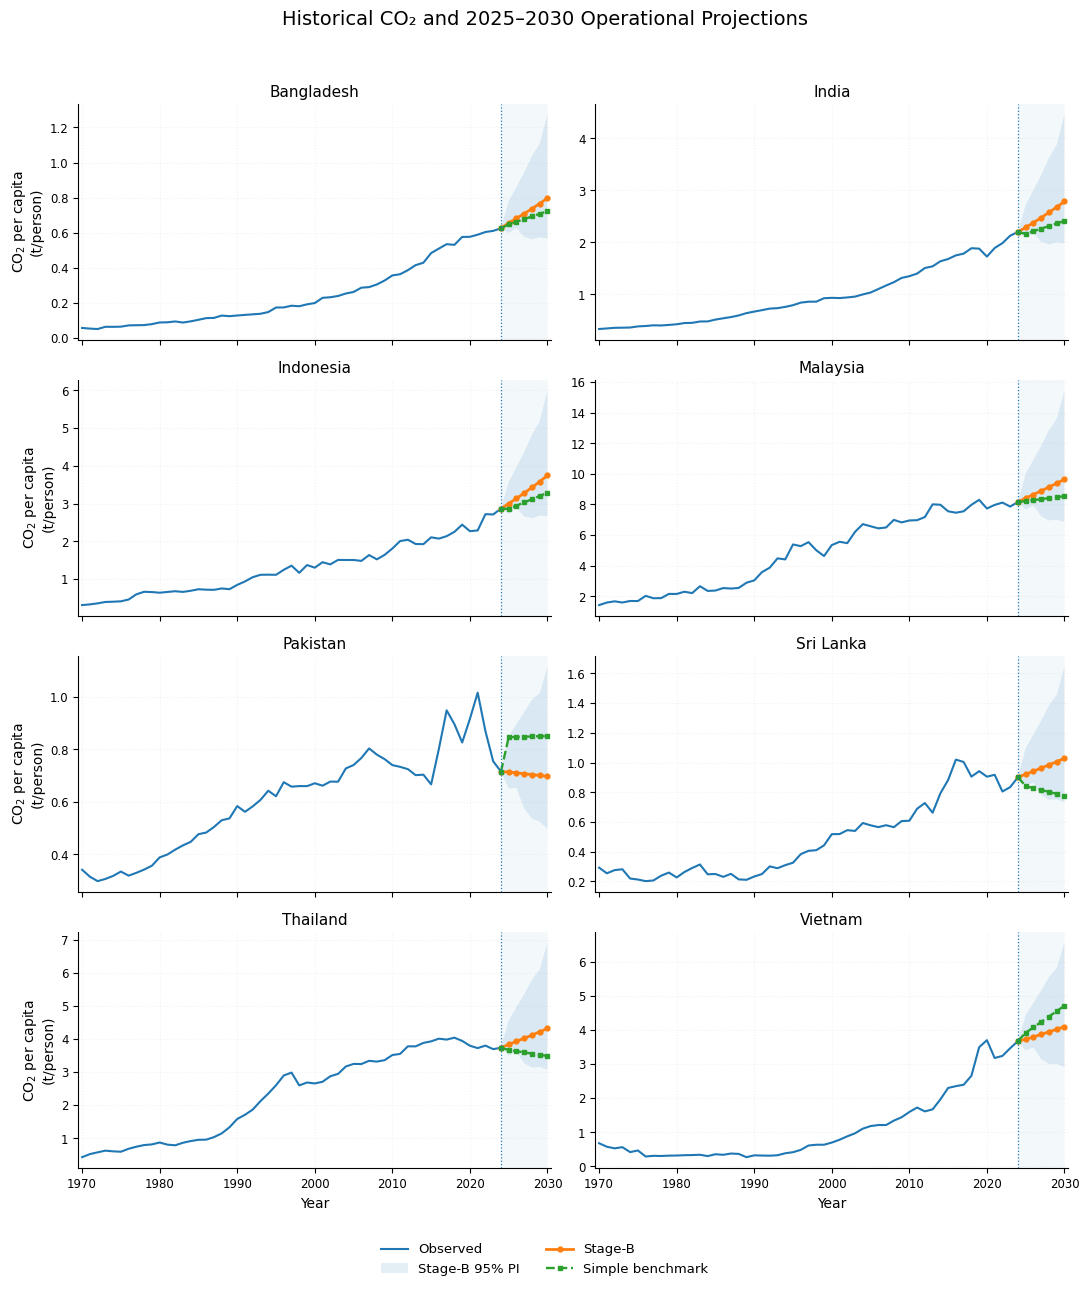

CELL 29 — RECENT-TREND COMPARATOR + BENCHMARK CLOSURE

RECENT-TREND WINDOW SELECTION — PRE-2014 CV ONLY


,Window,Method,Mean_CV_Macro_MASE,SD_CV_Macro_MASE,Pooled_CV_RMSE,Pooled_CV_MAE,Total_Fallbacks
0,10,Recent Trend (10y),3.1047,1.1728,0.3793,0.1878,0
1,5,Recent Trend (5y),3.3156,0.5364,0.4637,0.2353,0
2,15,Recent Trend (15y),3.3883,0.7146,0.3344,0.1804,0



Frozen Recent-Trend window : 10 years
Recent-Trend identity      : Recent Trend (10y)

PRE-2014 SIMPLE-BENCHMARK SELECTION


,Method,CV_Macro_MASE,CV_RMSE
0,Recent Trend (10y),3.1047,0.3793
1,ETS,3.4294,0.4731



BENCHMARK CLOSURE


,Method,Role,CV_Macro_MASE,Heldout_2014_2019_MASE,Heldout_2014_2024_MASE
2,Recent Trend (10y),Recent-Trend comparator,3.1047,3.8799,4.8118
3,CatBoost recursive pipeline,Indicator-based recursive Stage B,3.1247,4.3902,6.9169
1,ETS,Best Cell-24 classical univariate,3.4294,4.5466,5.9140
0,Persistence,Naive reference,4.6393,6.8924,9.0128



FINAL SIMPLE OPERATIONAL BENCHMARK
  Selection basis : pre-2014 CV Macro-MASE
  Frozen method    : Recent Trend (10y)
  Held-out ranking does NOT alter this identity.

HELD-OUT LEADER NOTE
  Cell-24 held-out leader : ETS
  Simple held-out leader  : Recent Trend (10y)
  These are descriptive results only.

2030 DESCRIPTIVE PROJECTION COMPARISON


,country,Observed_2024,Stage_B_2030,Lower_95,Upper_95,Simple_Benchmark_2030,Percent_Difference,Benchmark_Inside_StageB_95_PI
0,Bangladesh,0.62,0.80,0.57,1.27,0.72,+10.26%,True
1,India,2.20,2.79,1.98,4.46,2.41,+15.49%,True
2,Indonesia,2.87,3.75,2.67,6.00,3.29,+13.96%,True
3,Malaysia,8.16,9.65,6.86,15.45,8.54,+12.94%,True
4,Pakistan,0.72,0.70,0.50,1.12,0.85,-18.09%,True
5,Sri Lanka,0.90,1.03,0.73,1.65,0.78,+32.42%,True
6,Thailand,3.74,4.32,3.07,6.91,3.49,+23.86%,True
7,Vietnam,3.67,4.09,2.91,6.56,4.71,-13.00%,True



FUTURE PATH AGREEMENT — DESCRIPTIVE ONLY
  Benchmark inside Stage-B 95% PI : 47/48 (97.9%)
  Percent difference range        : -18.09% to +32.42%
  Largest absolute divergence     : 32.42%
  Median absolute divergence      : 10.50%
  PI inclusion is descriptive overlap only; not a significance/equivalence test.

FIGURE CHECK
  Observed history : 1970-2024
  Projection       : 2025-2030
  Layout           : 4 × 2 portrait

OUTPUTS: Stage-B versus simple-benchmark figure → Main text | Recent-Trend selection + benchmark closure + 2030 comparison → Appendix | full paths + overlap audit → Notebook only


In [30]:
# ============================================================
# CELL 29 — RECENT-TREND COMPARATOR + BENCHMARK CLOSURE
# ============================================================
# Run after Cell 28; reuse Stage-B fold data and Cell-24 benchmark results.
# Compare 5/10/15-year CO2-only trends using pre-2014 CV evidence only.
# Keep held-out rankings descriptive; they never select the final benchmark.
# Update the selected simple benchmark through observed 2024 for deployment.
# Compare its 2025–2030 path with Stage-B projections and empirical intervals.
# Retain the full observed 1970–2024 history in the original 4 × 2 figure.
# PI inclusion is descriptive overlap, not an equivalence/significance test.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression


# ------------------------------------------------------------
# 1. INTEGRITY GATE
# ------------------------------------------------------------
RECENT_WINDOWS = [5, 10, 15]
MATCHED_END = TEST_START + STAGE_B_HORIZON - 1
assert MATCHED_END == 2019
assert TRAIN_END == 2013
assert TEST_END == 2024
assert PROJECTION_ORIGIN == 2024
assert PROJECTION_START == 2025
assert PROJECTION_END == 2030
assert N_STAGE_B_FOLDS == 4
assert STAGE_B_HORIZON == 6
assert PROJECTION_HORIZON == 6

required_objects = [
    "stage_b_folds", "STAGE_B_FOLD_DATA", "STAGE_B_DENOMINATORS",
    "DEVELOPMENT_DENOMINATORS", "all_cv_summary", "operational_comparison",
    "operational_predictions", "BEST_CLASSICAL_UNIVARIATE_BENCHMARK_CV",
    "STAGE_B_LABEL", "stage_b_projection_intervals",
]
for _obj in required_objects:
    assert _obj in globals(), f"Missing object: {_obj}"
assert len(stage_b_projection_intervals) == 8 * PROJECTION_HORIZON


# ------------------------------------------------------------
# 2. DEVELOPMENT DENOMINATOR ACCESSOR — ORIGINAL CONTAINERS
# ------------------------------------------------------------
def development_denom(country):
    obj = DEVELOPMENT_DENOMINATORS
    if isinstance(obj, dict):
        value = obj[country]
    elif isinstance(obj, pd.Series):
        value = obj.loc[country]
    elif isinstance(obj, pd.DataFrame):
        if "country" in obj.columns and "MASE_Denominator" in obj.columns:
            value = obj.loc[
                obj["country"] == country, "MASE_Denominator",
            ].iloc[0]
        else:
            value = obj.loc[country, "MASE_Denominator"]
    else:
        raise TypeError("Unsupported DEVELOPMENT_DENOMINATORS object.")

    value = float(value)
    assert np.isfinite(value)
    assert value > 0
    return value


# ------------------------------------------------------------
# 3. STAGE-B FOLD BOUNDS — READ YEARS FROM TRUTH ROWS
# ------------------------------------------------------------
# Do not depend on Val_Start or Forecast_Start column names.
def get_stage_b_fold_bounds(fold):
    truth = STAGE_B_FOLD_DATA[fold]["truth"].copy()
    start = int(truth["year"].min())
    end = int(truth["year"].max())
    assert end - start + 1 == STAGE_B_HORIZON
    return start, end


# ------------------------------------------------------------
# 4. RECENT-TREND FORECAST — OLS ON RECENT CO2 LEVELS
# ------------------------------------------------------------
# Reject an invalid path as a whole and fall back to persistence; do not clip.
def forecast_recent_trend(history, horizon, window):
    y = np.asarray(history, dtype=float)
    assert len(y) >= window
    assert np.isfinite(y).all()
    assert (y > 0).all()
    recent = y[-window:]

    x_train = np.arange(window).reshape(-1, 1)
    model = LinearRegression().fit(x_train, recent)
    x_future = np.arange(window, window + horizon).reshape(-1, 1)
    pred = np.asarray(model.predict(x_future), dtype=float)
    fallback_used = False
    if (
        len(pred) != horizon
        or not np.isfinite(pred).all()
        or not (pred > 0).all()
    ):
        pred = np.repeat(y[-1], horizon)
        fallback_used = True
    return pred, fallback_used


# ------------------------------------------------------------
# 5. PRE-2014 RECENT-TREND CV — ORIGINAL LOOP AND ROW ORDER
# ------------------------------------------------------------
recent_cv_fold_rows = []
recent_cv_prediction_frames = []
for window in RECENT_WINDOWS:
    for _, fold_info in stage_b_folds.iterrows():
        fold = int(fold_info["Fold"])
        origin = int(fold_info["Train_End"])
        val_start, val_end = get_stage_b_fold_bounds(fold)
        assert origin < val_start
        assert val_end <= TRAIN_END

        fold_rows = []
        fold_fallbacks = 0
        for country in sorted(df["country"].unique()):
            history = (
                df[(df["country"] == country) & (df["year"] <= origin)]
                .sort_values("year")["co2_per_capita"]
                .dropna().to_numpy(dtype=float)
            )
            pred, fallback_used = forecast_recent_trend(
                history=history, horizon=STAGE_B_HORIZON, window=window,
            )
            fold_fallbacks += int(fallback_used)

            truth = STAGE_B_FOLD_DATA[fold]["truth"]
            truth = truth[truth["country"] == country][
                ["year", "co2_per_capita"]
            ].sort_values("year")
            assert len(truth) == STAGE_B_HORIZON

            for horizon, (year, prediction, actual) in enumerate(
                zip(truth["year"], pred, truth["co2_per_capita"]), start=1,
            ):
                fold_rows.append({
                    "Window": window,
                    "Fold": fold,
                    "country": country,
                    "year": int(year),
                    "Horizon": int(horizon),
                    "Predicted_CO2": float(prediction),
                    "Actual_CO2": float(actual),
                })

        fold_pred = pd.DataFrame(fold_rows)
        assert len(fold_pred) == 8 * STAGE_B_HORIZON
        country_mase_values = []
        for country, sub in fold_pred.groupby("country"):
            denom = stage_b_cv_denom(fold, country)
            country_mae = float(np.mean(np.abs(
                sub["Predicted_CO2"] - sub["Actual_CO2"]
            )))
            country_mase_values.append(country_mae / denom)

        error = fold_pred["Predicted_CO2"] - fold_pred["Actual_CO2"]
        recent_cv_fold_rows.append({
            "Window": window,
            "Fold": fold,
            "Train_End": origin,
            "Forecast_Start": val_start,
            "Forecast_End": val_end,
            "Macro_MASE": float(np.mean(country_mase_values)),
            "RMSE": float(np.sqrt(np.mean(np.square(error)))),
            "MAE": float(np.mean(np.abs(error))),
            "Fallbacks": int(fold_fallbacks),
        })
        recent_cv_prediction_frames.append(fold_pred)

recent_trend_cv_folds = pd.DataFrame(recent_cv_fold_rows)
recent_trend_cv_predictions = pd.concat(
    recent_cv_prediction_frames, ignore_index=True,
)


# ------------------------------------------------------------
# 6. RECENT-TREND WINDOW SELECTION — PRE-2014 EVIDENCE ONLY
# ------------------------------------------------------------
# Keep the original tie-breaks: Macro-MASE, RMSE, MAE, then smaller window.
recent_summary_rows = []
for window in RECENT_WINDOWS:
    fold_sub = recent_trend_cv_folds[
        recent_trend_cv_folds["Window"] == window
    ]
    pred_sub = recent_trend_cv_predictions[
        recent_trend_cv_predictions["Window"] == window
    ]
    error = pred_sub["Predicted_CO2"] - pred_sub["Actual_CO2"]
    recent_summary_rows.append({
        "Window": window,
        "Method": f"Recent Trend ({window}y)",
        "Mean_CV_Macro_MASE": float(fold_sub["Macro_MASE"].mean()),
        "SD_CV_Macro_MASE": float(fold_sub["Macro_MASE"].std(ddof=1)),
        "Pooled_CV_RMSE": float(np.sqrt(np.mean(np.square(error)))),
        "Pooled_CV_MAE": float(np.mean(np.abs(error))),
        "Total_Fallbacks": int(fold_sub["Fallbacks"].sum()),
    })

recent_trend_cv_summary = (
    pd.DataFrame(recent_summary_rows)
    .sort_values([
        "Mean_CV_Macro_MASE", "Pooled_CV_RMSE", "Pooled_CV_MAE", "Window",
    ])
    .reset_index(drop=True)
)
RECENT_TREND_WINNER_WINDOW = int(recent_trend_cv_summary.iloc[0]["Window"])
RECENT_TREND_LABEL = str(recent_trend_cv_summary.iloc[0]["Method"])


# ------------------------------------------------------------
# 7. FROZEN RECENT-TREND HELD-OUT FORECAST — NO WINDOW RE-SELECTION
# ------------------------------------------------------------
recent_holdout_rows = []
recent_holdout_fallbacks = 0
for country in sorted(df["country"].unique()):
    history = (
        df[(df["country"] == country) & (df["year"] <= TRAIN_END)]
        .sort_values("year")["co2_per_capita"].dropna().to_numpy(dtype=float)
    )
    pred, fallback_used = forecast_recent_trend(
        history=history, horizon=TEST_END - TRAIN_END,
        window=RECENT_TREND_WINNER_WINDOW,
    )
    recent_holdout_fallbacks += int(fallback_used)
    for horizon, (year, value) in enumerate(
        zip(range(TEST_START, TEST_END + 1), pred), start=1,
    ):
        recent_holdout_rows.append({
            "Method": RECENT_TREND_LABEL,
            "country": country,
            "year": int(year),
            "Horizon": int(horizon),
            "Predicted_CO2": float(value),
        })

recent_trend_holdout_predictions = pd.DataFrame(recent_holdout_rows)
assert len(recent_trend_holdout_predictions) == 88


# ------------------------------------------------------------
# 8. HELD-OUT SCORING — MATCHED SIX-YEAR AND FULL ELEVEN-YEAR WINDOWS
# ------------------------------------------------------------
def score_recent_heldout(year_end):
    predictions = recent_trend_holdout_predictions[
        recent_trend_holdout_predictions["year"] <= year_end
    ].copy()
    truth = df[df["year"].between(TEST_START, year_end)][
        ["country", "year", "co2_per_capita"]
    ].rename(columns={"co2_per_capita": "Actual_CO2"})
    return score_forecast_frame(
        predictions=predictions, truth=truth, denom_function=development_denom,
    )

recent_matched_metrics = score_recent_heldout(MATCHED_END)
recent_full_metrics = score_recent_heldout(TEST_END)


# ------------------------------------------------------------
# 9. CELL-24 RESULT ACCESSORS
# ------------------------------------------------------------
def existing_cv_row(method):
    row = all_cv_summary[all_cv_summary["Method"] == method]
    assert len(row) == 1
    return row.iloc[0]


def existing_operational_row(method, end_year):
    window = f"{TEST_START}-{end_year}"
    row = operational_comparison[
        (operational_comparison["Method"] == method)
        & (operational_comparison["Window"] == window)
    ]
    assert len(row) == 1
    return row.iloc[0]


# ------------------------------------------------------------
# 10. BENCHMARK CLOSURE — PRESERVE EACH METHOD'S SCIENTIFIC ROLE
# ------------------------------------------------------------
classical_name = BEST_CLASSICAL_UNIVARIATE_BENCHMARK_CV
classical_cv = existing_cv_row(classical_name)
classical_matched = existing_operational_row(classical_name, MATCHED_END)
classical_full = existing_operational_row(classical_name, TEST_END)
persistence_cv = existing_cv_row("Persistence")
persistence_matched = existing_operational_row("Persistence", MATCHED_END)
persistence_full = existing_operational_row("Persistence", TEST_END)
stage_b_cv = existing_cv_row(STAGE_B_LABEL)
stage_b_matched = existing_operational_row(STAGE_B_LABEL, MATCHED_END)
stage_b_full = existing_operational_row(STAGE_B_LABEL, TEST_END)

benchmark_closure = pd.DataFrame([
    {
        "Method": "Persistence",
        "Role": "Naive reference",
        "CV_Macro_MASE": float(persistence_cv["Mean_CV_Macro_MASE"]),
        "Heldout_2014_2019_MASE": float(persistence_matched["Macro_MASE"]),
        "Heldout_2014_2024_MASE": float(persistence_full["Macro_MASE"]),
    },
    {
        "Method": classical_name,
        "Role": "Best Cell-24 classical univariate",
        "CV_Macro_MASE": float(classical_cv["Mean_CV_Macro_MASE"]),
        "Heldout_2014_2019_MASE": float(classical_matched["Macro_MASE"]),
        "Heldout_2014_2024_MASE": float(classical_full["Macro_MASE"]),
    },
    {
        "Method": RECENT_TREND_LABEL,
        "Role": "Recent-Trend comparator",
        "CV_Macro_MASE": float(
            recent_trend_cv_summary.iloc[0]["Mean_CV_Macro_MASE"]
        ),
        "Heldout_2014_2019_MASE": float(recent_matched_metrics["Macro_MASE"]),
        "Heldout_2014_2024_MASE": float(recent_full_metrics["Macro_MASE"]),
    },
    {
        "Method": STAGE_B_LABEL,
        "Role": "Indicator-based recursive Stage B",
        "CV_Macro_MASE": float(stage_b_cv["Mean_CV_Macro_MASE"]),
        "Heldout_2014_2019_MASE": float(stage_b_matched["Macro_MASE"]),
        "Heldout_2014_2024_MASE": float(stage_b_full["Macro_MASE"]),
    },
])


# ------------------------------------------------------------
# 11. FINAL SIMPLE BENCHMARK — PRE-2014 CV ONLY
# ------------------------------------------------------------
# Compare the Cell-24 classical winner with the selected Recent-Trend window.
# Preserve tie-breaks: CV Macro-MASE, CV RMSE, then method name.
simple_selection = pd.DataFrame([
    {
        "Method": classical_name,
        "CV_Macro_MASE": float(classical_cv["Mean_CV_Macro_MASE"]),
        "CV_RMSE": float(classical_cv["Pooled_CV_RMSE"]),
    },
    {
        "Method": RECENT_TREND_LABEL,
        "CV_Macro_MASE": float(
            recent_trend_cv_summary.iloc[0]["Mean_CV_Macro_MASE"]
        ),
        "CV_RMSE": float(recent_trend_cv_summary.iloc[0]["Pooled_CV_RMSE"]),
    },
])
simple_selection = simple_selection.sort_values([
    "CV_Macro_MASE", "CV_RMSE", "Method",
]).reset_index(drop=True)
FINAL_SIMPLE_OPERATIONAL_BENCHMARK_CV = str(simple_selection.iloc[0]["Method"])


# ------------------------------------------------------------
# 12. HELD-OUT LEADER NOTE — DESCRIPTIVE, NOT A SELECTION RULE
# ------------------------------------------------------------
if "LOWEST_HELDOUT_CELL24_COMPARATOR_DESCRIPTIVE" in globals():
    CELL24_HELDOUT_LOWEST_DESCRIPTIVE = str(
        LOWEST_HELDOUT_CELL24_COMPARATOR_DESCRIPTIVE
    )
else:
    cell24_full = operational_comparison[
        (operational_comparison["Window"] == f"{TEST_START}-{TEST_END}")
        & (operational_comparison["Method"] != STAGE_B_LABEL)
    ].sort_values("Macro_MASE")
    CELL24_HELDOUT_LOWEST_DESCRIPTIVE = str(cell24_full.iloc[0]["Method"])

simple_heldout_rows = benchmark_closure[
    benchmark_closure["Method"] != STAGE_B_LABEL
].sort_values("Heldout_2014_2024_MASE").reset_index(drop=True)
HELDOUT_LOWEST_SIMPLE_DESCRIPTIVE = str(simple_heldout_rows.iloc[0]["Method"])
heldout_lowest_note = (
    "Held-out rankings are descriptive only. "
    f"Cell-24 held-out leader: {CELL24_HELDOUT_LOWEST_DESCRIPTIVE}. "
    f"Lowest simple held-out result after adding Recent-Trend: "
    f"{HELDOUT_LOWEST_SIMPLE_DESCRIPTIVE}. "
    f"Final simple benchmark remains {FINAL_SIMPLE_OPERATIONAL_BENCHMARK_CV}, "
    "selected from pre-2014 CV."
)


# ------------------------------------------------------------
# 13. CLASSICAL DEPLOYMENT WRAPPER — ORIGINAL CALL COMPATIBILITY
# ------------------------------------------------------------
def project_frozen_classical(history, horizon, method, country, origin):
    history = np.asarray(history, dtype=float)
    if "forecast_classical_baseline" in globals():
        projected = forecast_classical_baseline(
            history=history, horizon=horizon, method=method, country=country,
            origin=origin, evaluation_set="Cell29_2025_2030_projection",
        )
    elif "forecast_co2_benchmark" in globals():
        try:
            projected = forecast_co2_benchmark(
                history_values=history, horizon=horizon, method_name=method,
            )
        except TypeError:
            projected = forecast_co2_benchmark(history, horizon, method, country)
        if isinstance(projected, tuple):
            projected = projected[0]
    else:
        raise NameError("No classical benchmark forecast function found.")

    projected = np.asarray(projected, dtype=float)
    assert len(projected) == horizon
    assert np.isfinite(projected).all()
    assert (projected > 0).all()
    return projected


# ------------------------------------------------------------
# 14. DEPLOY THE SELECTED SIMPLE BENCHMARK — HISTORY THROUGH 2024
# ------------------------------------------------------------
benchmark_projection_rows = []
benchmark_projection_fallbacks = 0
for country in sorted(df["country"].unique()):
    history = (
        df[(df["country"] == country) & (df["year"] <= PROJECTION_ORIGIN)]
        .sort_values("year")["co2_per_capita"].dropna().to_numpy(dtype=float)
    )
    if FINAL_SIMPLE_OPERATIONAL_BENCHMARK_CV == RECENT_TREND_LABEL:
        projected, fallback_used = forecast_recent_trend(
            history=history, horizon=PROJECTION_HORIZON,
            window=RECENT_TREND_WINNER_WINDOW,
        )
        benchmark_projection_fallbacks += int(fallback_used)
    else:
        projected = project_frozen_classical(
            history=history, horizon=PROJECTION_HORIZON,
            method=FINAL_SIMPLE_OPERATIONAL_BENCHMARK_CV, country=country,
            origin=PROJECTION_ORIGIN,
        )
    for horizon, (year, value) in enumerate(
        zip(range(PROJECTION_START, PROJECTION_END + 1), projected), start=1,
    ):
        benchmark_projection_rows.append({
            "country": country,
            "year": int(year),
            "Horizon": int(horizon),
            "Benchmark_CO2": float(value),
        })

BENCHMARK_PROJECTION = pd.DataFrame(benchmark_projection_rows)
assert len(BENCHMARK_PROJECTION) == 8 * PROJECTION_HORIZON


# ------------------------------------------------------------
# 15. STAGE-B VS SIMPLE BENCHMARK — UNCHANGED DIFFERENCE FORMULAS
# ------------------------------------------------------------
projection_benchmark_comparison = stage_b_projection_intervals[[
    "country", "year", "Horizon", "Projected_CO2", "Lower_95", "Upper_95",
]].merge(
    BENCHMARK_PROJECTION, on=["country", "year", "Horizon"],
    validate="one_to_one",
)
projection_benchmark_comparison["Difference"] = (
    projection_benchmark_comparison["Projected_CO2"]
    - projection_benchmark_comparison["Benchmark_CO2"]
)
projection_benchmark_comparison["Percent_Difference"] = (
    projection_benchmark_comparison["Difference"]
    / projection_benchmark_comparison["Benchmark_CO2"] * 100
)
projection_benchmark_comparison["Benchmark_Inside_StageB_95_PI"] = (
    (projection_benchmark_comparison["Benchmark_CO2"]
     >= projection_benchmark_comparison["Lower_95"])
    & (projection_benchmark_comparison["Benchmark_CO2"]
       <= projection_benchmark_comparison["Upper_95"])
)


# ------------------------------------------------------------
# 16. 2030 SUMMARY + DESCRIPTIVE FULL-PATH OVERLAP
# ------------------------------------------------------------
observed_2024_benchmark = df[df["year"] == PROJECTION_ORIGIN][
    ["country", "co2_per_capita"]
].rename(columns={"co2_per_capita": "Observed_2024"})
comparison_2030 = (
    projection_benchmark_comparison[
        projection_benchmark_comparison["year"] == PROJECTION_END
    ]
    .merge(observed_2024_benchmark, on="country", validate="one_to_one")
    [[
        "country", "Observed_2024", "Projected_CO2", "Lower_95", "Upper_95",
        "Benchmark_CO2", "Percent_Difference", "Benchmark_Inside_StageB_95_PI",
    ]]
    .rename(columns={
        "Projected_CO2": "Stage_B_2030",
        "Benchmark_CO2": "Simple_Benchmark_2030",
    })
    .sort_values("country").reset_index(drop=True)
)
n_inside = int(projection_benchmark_comparison["Benchmark_Inside_StageB_95_PI"].sum())
n_total = len(projection_benchmark_comparison)
inside_percent = n_inside / n_total * 100
min_percent_difference = float(
    projection_benchmark_comparison["Percent_Difference"].min()
)
max_percent_difference = float(
    projection_benchmark_comparison["Percent_Difference"].max()
)
max_abs_divergence = float(
    projection_benchmark_comparison["Percent_Difference"].abs().max()
)
median_abs_divergence = float(
    projection_benchmark_comparison["Percent_Difference"].abs().median()
)


# ------------------------------------------------------------
# 17. ORIGINAL FIGURE — FULL HISTORY + ANCHORED FUTURE PATHS
# ------------------------------------------------------------
# Preserve layout, labels, colors, markers, limits, legend and export settings.
# Both future paths and the PI band connect to the observed 2024 anchor.
FIGURE_HISTORY_START = 1970
fig, axes = plt.subplots(4, 2, figsize=(11, 13), sharex=True)
axes = axes.ravel()
for ax, country in zip(axes, sorted(df["country"].unique())):
    hist = df[
        (df["country"] == country)
        & df["year"].between(FIGURE_HISTORY_START, PROJECTION_ORIGIN)
    ].sort_values("year")
    proj = stage_b_projection_intervals[
        stage_b_projection_intervals["country"] == country
    ].sort_values("year")
    bench = BENCHMARK_PROJECTION[
        BENCHMARK_PROJECTION["country"] == country
    ].sort_values("year")
    anchor = float(hist.loc[
        hist["year"] == PROJECTION_ORIGIN, "co2_per_capita",
    ].iloc[0])

    future_years = np.concatenate([
        [PROJECTION_ORIGIN], proj["year"].to_numpy(),
    ])
    stage_b_path = np.concatenate([[anchor], proj["Projected_CO2"].to_numpy()])
    lower_95 = np.concatenate([[anchor], proj["Lower_95"].to_numpy()])
    upper_95 = np.concatenate([[anchor], proj["Upper_95"].to_numpy()])
    benchmark_path = np.concatenate([[anchor], bench["Benchmark_CO2"].to_numpy()])

    ax.axvspan(PROJECTION_ORIGIN, PROJECTION_END, alpha=0.05)
    ax.plot(
        hist["year"], hist["co2_per_capita"], linewidth=1.5, label="Observed",
    )
    ax.fill_between(
        future_years, lower_95, upper_95, alpha=0.12, linewidth=0,
        label="Stage-B 95% PI",
    )
    ax.plot(
        future_years, stage_b_path, linewidth=2.0, marker="o", markersize=3.5,
        label="Stage-B",
    )
    ax.plot(
        future_years, benchmark_path, linewidth=1.7, linestyle="--", marker="s",
        markersize=3.5, label="Simple benchmark",
    )
    ax.axvline(PROJECTION_ORIGIN, linewidth=0.9, linestyle=":")
    ax.set_title(country, fontsize=11, pad=5)
    ax.set_xlim(FIGURE_HISTORY_START - 0.5, PROJECTION_END + 0.5)
    ax.set_xticks([1970, 1980, 1990, 2000, 2010, 2020, 2030])
    ax.grid(alpha=0.16, linestyle=":")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="both", labelsize=8.5)

for ax in axes[-2:]:
    ax.set_xlabel("Year", fontsize=10)
for ax in [axes[0], axes[2], axes[4], axes[6]]:
    ax.set_ylabel("CO$_2$ per capita\n(t/person)", fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", ncol=2, frameon=False, fontsize=9.5,
    bbox_to_anchor=(0.5, 0.012),
)
fig.suptitle(
    "Historical CO₂ and 2025–2030 Operational Projections", fontsize=14, y=0.995,
)
fig.tight_layout(rect=[0, 0.06, 1, 0.975])

FIGURE_PATH_PNG = FIGURES_DIR / "fig_stage_b_vs_simple_benchmark.png"
FIGURE_PATH_PDF = FIGURES_DIR / "fig_stage_b_vs_simple_benchmark.pdf"
fig.savefig(FIGURE_PATH_PNG, dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_PATH_PDF, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# 18. FINAL ROLE REGISTER — PRIMARY MODEL VS SECONDARY VS BENCHMARK
# ------------------------------------------------------------
final_role_register = pd.DataFrame([
    {
        "Component": f"{FROZEN_STAGE_A_WINNER} (Config {FROZEN_STAGE_A_CONFIG_ID})",
        "Stage": "A",
        "Uses_Indicators": True,
        "Role": "Primary indicator-based conditional prediction and SHAP explanation",
    },
    {
        "Component": f"{FROZEN_STAGE_B_WINNER} (Config {FROZEN_STAGE_B_CONFIG_ID})",
        "Stage": "B",
        "Uses_Indicators": True,
        "Role": "Secondary scenario-conditional recursive projection",
    },
    {
        "Component": FINAL_SIMPLE_OPERATIONAL_BENCHMARK_CV,
        "Stage": "Benchmark",
        "Uses_Indicators": False,
        "Role": "Frozen CO2-only operational benchmark; comparator only",
    },
])


# ------------------------------------------------------------
# 19. SAVE — TEN ORIGINAL CSV FILENAMES AND FULL PRECISION
# ------------------------------------------------------------
recent_trend_cv_folds.to_csv(
    TABLES_DIR / "appendix_recent_trend_cv_folds.csv", index=False,
)
recent_trend_cv_predictions.to_csv(
    TABLES_DIR / "appendix_recent_trend_cv_predictions.csv", index=False,
)
recent_trend_cv_summary.to_csv(
    TABLES_DIR / "recent_trend_window_selection.csv", index=False,
)
recent_trend_holdout_predictions.to_csv(
    TABLES_DIR / "recent_trend_heldout_predictions.csv", index=False,
)
simple_selection.to_csv(
    TABLES_DIR / "final_simple_benchmark_pre2014_selection.csv", index=False,
)
benchmark_closure.to_csv(
    TABLES_DIR / "operational_benchmark_closure.csv", index=False,
)
BENCHMARK_PROJECTION.to_csv(
    TABLES_DIR / "simple_benchmark_projection_2025_2030.csv", index=False,
)
projection_benchmark_comparison.to_csv(
    TABLES_DIR / "stage_b_vs_simple_benchmark_full_path.csv", index=False,
)
comparison_2030.to_csv(
    TABLES_DIR / "appendix_stage_b_vs_simple_benchmark_2030.csv", index=False,
)
final_role_register.to_csv(
    TABLES_DIR / "final_method_role_register.csv", index=False,
)


# ------------------------------------------------------------
# 20. REPORT — ORIGINAL WORDING, FORMATS AND DISPLAY ORDER
# ------------------------------------------------------------
print("=" * 78)
print("CELL 29 — RECENT-TREND COMPARATOR + BENCHMARK CLOSURE")
print("=" * 78)

print("\nRECENT-TREND WINDOW SELECTION — PRE-2014 CV ONLY")
display(recent_trend_cv_summary.style.format({
    "Mean_CV_Macro_MASE": "{:.4f}",
    "SD_CV_Macro_MASE": "{:.4f}",
    "Pooled_CV_RMSE": "{:.4f}",
    "Pooled_CV_MAE": "{:.4f}",
}))
print(f"\nFrozen Recent-Trend window : {RECENT_TREND_WINNER_WINDOW} years")
print(f"Recent-Trend identity      : {RECENT_TREND_LABEL}")

print("\nPRE-2014 SIMPLE-BENCHMARK SELECTION")
display(simple_selection.style.format({
    "CV_Macro_MASE": "{:.4f}",
    "CV_RMSE": "{:.4f}",
}))

print("\nBENCHMARK CLOSURE")
display(benchmark_closure.sort_values("CV_Macro_MASE").style.format({
    "CV_Macro_MASE": "{:.4f}",
    "Heldout_2014_2019_MASE": "{:.4f}",
    "Heldout_2014_2024_MASE": "{:.4f}",
}))

print("\nFINAL SIMPLE OPERATIONAL BENCHMARK")
print("  Selection basis : pre-2014 CV Macro-MASE")
print(f"  Frozen method    : {FINAL_SIMPLE_OPERATIONAL_BENCHMARK_CV}")
print("  Held-out ranking does NOT alter this identity.")

print("\nHELD-OUT LEADER NOTE")
print(f"  Cell-24 held-out leader : {CELL24_HELDOUT_LOWEST_DESCRIPTIVE}")
print(f"  Simple held-out leader  : {HELDOUT_LOWEST_SIMPLE_DESCRIPTIVE}")
print("  These are descriptive results only.")

print(f"\n{PROJECTION_END} DESCRIPTIVE PROJECTION COMPARISON")
display(comparison_2030.style.format({
    "Observed_2024": "{:.2f}",
    "Stage_B_2030": "{:.2f}",
    "Lower_95": "{:.2f}",
    "Upper_95": "{:.2f}",
    "Simple_Benchmark_2030": "{:.2f}",
    "Percent_Difference": "{:+.2f}%",
}))

print("\nFUTURE PATH AGREEMENT — DESCRIPTIVE ONLY")
print(
    f"  Benchmark inside Stage-B 95% PI : {n_inside}/{n_total} "
    f"({inside_percent:.1f}%)"
)
print(
    f"  Percent difference range        : {min_percent_difference:+.2f}% "
    f"to {max_percent_difference:+.2f}%"
)
print(f"  Largest absolute divergence     : {max_abs_divergence:.2f}%")
print(f"  Median absolute divergence      : {median_abs_divergence:.2f}%")
print(
    "  PI inclusion is descriptive overlap only; "
    "not a significance/equivalence test."
)

print("\nFIGURE CHECK")
print(f"  Observed history : {FIGURE_HISTORY_START}-{PROJECTION_ORIGIN}")
print(f"  Projection       : {PROJECTION_START}-{PROJECTION_END}")
print("  Layout           : 4 × 2 portrait")
print(
    "\nOUTPUTS: "
    "Stage-B versus simple-benchmark figure → Main text | "
    "Recent-Trend selection + benchmark closure + 2030 comparison "
    "→ Appendix | full paths + overlap audit → Notebook only"
)


**Cell 30 — earlier evidence summary.** Its inference row uses Cell 15; article and supplement inference uses Cell 38.


In [31]:
# ============================================================
# CELL 30 — EVIDENCE SUMMARY + LIMITATIONS REGISTER
# ============================================================
# Run after Cell 29; read the results already produced by earlier cells.
# Reporting only: no fitting, tuning, prediction, selection or recalibration.
# Keep the original evidence wording, interpretations and source-cell labels.
# Produce separate Stage-A/Stage-B evidence and an eleven-row limitations list.

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. INTEGRITY GATE + RESULT LOOKUP HELPERS
# ------------------------------------------------------------
required_objects = [
    "stage_a_holdout_results", "stage_a_skill_summary",
    "stage_a_dm_hac", "stage_a_full_train", "stage_a_holdout",
    "exclusion_audit", "shap_group_importance",
    "stage_b_abcd_results", "stage_b_abcd_contrasts",
    "operational_comparison", "stage_a_ablation_summary",
    "ABLATION_SPECS", "population_sensitivity_summary",
    "stage_b_interval_quantiles", "coverage_overall",
    "pi_coverage_by_country", "benchmark_closure",
    "projection_benchmark_comparison", "MODEL_NAMES",
    "STAGE_A_WINNER", "FROZEN_STAGE_A_WINNER",
    "FROZEN_STAGE_A_CONFIG_ID", "STAGE_A_WINNER_CV_MASE",
    "STAGE_B_WINNER", "FROZEN_STAGE_B_WINNER",
    "FROZEN_STAGE_B_CONFIG_ID", "STAGE_B_WINNER_CV_MASE",
    "STAGE_B_LABEL", "STAGE_B_HORIZON",
    "FINAL_SIMPLE_OPERATIONAL_BENCHMARK_CV", "MAX_SPLICE_STEP",
    "mean_dispersion_a", "mean_dispersion_d", "TRAIN_END",
    "TEST_START", "TEST_END", "TABLES_DIR",
]
missing_objects = [name for name in required_objects if name not in globals()]
assert not missing_objects, f"Missing objects: {missing_objects}"
assert STAGE_A_WINNER == FROZEN_STAGE_A_WINNER
assert STAGE_B_WINNER == FROZEN_STAGE_B_WINNER


def one_row(frame, **filters):
    out = frame
    for column, value in filters.items():
        out = out[out[column] == value]
    assert len(out) == 1, (
        f"Expected one row for {filters}; found {len(out)}"
    )
    return out.iloc[0]


def group_share(group):
    assert group in shap_group_importance.index
    return float(shap_group_importance.loc[group, "Percent_Dev"])


# ------------------------------------------------------------
# 2. READ EXISTING RESULTS — DO NOT RECOMPUTE OR RESELECT MODELS
# ------------------------------------------------------------
# Stage A: held-out metrics, annual loss inference and development SHAP.
a_winner = one_row(stage_a_holdout_results, Method=FROZEN_STAGE_A_WINNER)
a_panel = one_row(stage_a_holdout_results, Method="Panel OLS-FE")
a_persistence = one_row(stage_a_holdout_results, Method="Persistence")
a_skill = one_row(stage_a_skill_summary, Method=FROZEN_STAGE_A_WINNER)
a_vs_panel = one_row(
    stage_a_dm_hac, Method=FROZEN_STAGE_A_WINNER, Reference="Panel OLS-FE",
)
ml_vs_persistence = stage_a_dm_hac[
    (stage_a_dm_hac["Reference"] == "Persistence")
    & stage_a_dm_hac["Method"].isin(MODEL_NAMES)
].copy()
assert len(ml_vs_persistence) == len(MODEL_NAMES)

n_ml_tests = int(len(ml_vs_persistence))
n_ml_lower_loss = int((ml_vs_persistence["Mean_Loss_Difference"] < 0).sum())
n_ml_rejections = int(ml_vs_persistence["Reject_5pct_After_Holm"].sum())
n_test_years = int(a_vs_panel["N_Years"])
a_improvement = float(
    (a_persistence["Macro_MASE"] - a_winner["Macro_MASE"])
    / a_persistence["Macro_MASE"] * 100
)
shap_energy = sum([
    group_share("Energy consumption"),
    group_share("Energy structure"),
    group_share("Energy-economic"),
])
shap_economic = group_share("Economic")
shap_climate = group_share("Climate")
shap_lag = group_share("Autoregressive state")

# Stage B: full/matched windows, decomposition, benchmarks and interval audit.
full_window = f"{TEST_START}-{TEST_END}"
matched_window = f"{TEST_START}-{TEST_START + STAGE_B_HORIZON - 1}"
b_full = one_row(operational_comparison, Method=STAGE_B_LABEL, Window=full_window)
b_matched = one_row(
    operational_comparison, Method=STAGE_B_LABEL, Window=matched_window,
)
persistence_full = one_row(
    operational_comparison, Method="Persistence", Window=full_window,
)
persistence_matched = one_row(
    operational_comparison, Method="Persistence", Window=matched_window,
)
abcd_full = stage_b_abcd_results[
    stage_b_abcd_results["Window"] == full_window
].set_index("Scenario")
assert set(abcd_full.index) == {"A", "B", "C", "D"}

A_mase = float(abcd_full.loc["A", "Macro_MASE"])
B_mase = float(abcd_full.loc["B", "Macro_MASE"])
C_mase = float(abcd_full.loc["C", "Macro_MASE"])
D_mase = float(abcd_full.loc["D", "Macro_MASE"])
abcd_contrast = one_row(stage_b_abcd_contrasts, Window=full_window)
driver_contrast = float(abcd_contrast["Driver_Projection_Contrast_B_minus_A"])
recursive_contrast = float(abcd_contrast["Recursive_Lag_Contrast_C_minus_A"])
interaction_contrast = float(abcd_contrast["Interaction_Contrast"])
total_gap = float(abcd_contrast["Total_Operational_Gap_D_minus_A"])
assert np.isclose(
    total_gap, driver_contrast + recursive_contrast + interaction_contrast,
)
assert recursive_contrast > max(driver_contrast, interaction_contrast)

stage_b_benchmark = one_row(benchmark_closure, Method=STAGE_B_LABEL)
simple_benchmark = one_row(
    benchmark_closure, Method=FINAL_SIMPLE_OPERATIONAL_BENCHMARK_CV,
)
coverage_80_row = one_row(coverage_overall, Interval="80% empirical PI")
coverage_95_row = one_row(coverage_overall, Interval="95% empirical PI")
coverage_80 = float(coverage_80_row["Observed_Coverage_Percent"])
coverage_95 = float(coverage_95_row["Observed_Coverage_Percent"])
nominal_95 = float(coverage_95_row["Nominal_Coverage_Percent"])

undercoverage_95 = pi_coverage_by_country[
    pi_coverage_by_country["Coverage_95_Percent"] < nominal_95
].sort_values("Coverage_95_Percent")
undercoverage_text = "; ".join(
    f"{row['country']} ({row['Coverage_95_Percent']:.1f}%)"
    for _, row in undercoverage_95.iterrows()
)
calibration_n = int(stage_b_interval_quantiles["N_Calibration_Errors"].min())
assert (stage_b_interval_quantiles["N_Calibration_Errors"] == calibration_n).all()

n_future = int(len(projection_benchmark_comparison))
n_inside_95 = int(
    projection_benchmark_comparison["Benchmark_Inside_StageB_95_PI"].sum()
)
future_difference = projection_benchmark_comparison["Percent_Difference"].astype(float)
median_abs_difference = float(future_difference.abs().median())
min_difference = float(future_difference.min())
max_difference = float(future_difference.max())

# Sensitivity and sample details: read the frozen specifications and row audit.
ablation_full = one_row(stage_a_ablation_summary, Specification="S1_Full")
ablation_no_fossil = one_row(
    stage_a_ablation_summary, Specification="S3_No_Fossil_Growth",
)
fossil_shap_removed = float(
    ABLATION_SPECS["S3_No_Fossil_Growth"]["SHAP_Percent_Removed"]
)
population_primary = one_row(
    population_sensitivity_summary, Specification="P1_Primary",
)
population_plus = one_row(
    population_sensitivity_summary, Specification="P2_Plus_Population",
)
n_countries = int(stage_a_holdout["country"].nunique())
n_development = int(len(stage_a_full_train))
n_heldout = int(len(stage_a_holdout))
assert len(exclusion_audit) == 1
excluded = exclusion_audit.iloc[0]
excluded_text = (
    f"{excluded['country']} {int(excluded['year'])}: "
    f"{excluded['Unavailable_Inputs']}"
)


# ------------------------------------------------------------
# 3. STAGE-A PRIMARY EVIDENCE — ORIGINAL REPORTING TEXT
# ------------------------------------------------------------
# Each entry contains: area, numeric evidence, interpretation and source.
# Interpretations reproduce this study's findings; they are not automatically
# reworded if upstream results change.
stage_a_rows = [
    (
        "Development selection",
        (
            f"{FROZEN_STAGE_A_WINNER} Config {FROZEN_STAGE_A_CONFIG_ID}; "
            f"development CV Macro-MASE {STAGE_A_WINNER_CV_MASE:.4f}."
        ),
        "Frozen Stage-A ML winner selected before held-out evaluation.",
        "Cell 11",
    ),
    (
        "Held-out conditional prediction",
        (
            f"{full_window} Macro-MASE: Panel OLS-FE {a_panel['Macro_MASE']:.4f}, "
            f"{FROZEN_STAGE_A_WINNER} {a_winner['Macro_MASE']:.4f}, "
            f"persistence {a_persistence['Macro_MASE']:.4f}; ML-winner "
            f"improvement over persistence {a_improvement:.1f}%."
        ),
        (
            "The indicators have conditional one-step predictive value, but "
            "Panel OLS-FE is the strongest held-out conditional benchmark. "
            "This is not operational forecasting."
        ),
        "Cells 13-14",
    ),
    (
        "Held-out loss inference",
        (
            f"{n_ml_lower_loss}/{n_ml_tests} ML models have lower mean loss "
            f"than persistence and {n_ml_rejections}/{n_ml_tests} reject "
            f"equal mean loss after Holm correction. {FROZEN_STAGE_A_WINNER} "
            f"versus Panel OLS-FE: Holm-adjusted p = "
            f"{a_vs_panel['Holm_Adjusted_P']:.4f}; "
            f"N = {n_test_years} annual loss differentials."
        ),
        (
            "The reported directions are statistically supported, but the "
            "small annual test sample requires caution."
        ),
        "Cell 15",
    ),
    (
        "Within-country performance",
        f"Held-out within-country R2 = {a_skill['Within_Country_R2']:.4f}.",
        (
            "The frozen model captures substantial within-country temporal "
            "variation; pooled R2 is not used for this claim."
        ),
        "Cell 14",
    ),
    (
        "SHAP attribution",
        (
            f"Development grouped SHAP: energy-related {shap_energy:.1f}%, "
            f"economic {shap_economic:.1f}%, climate {shap_climate:.1f}% "
            f"and lagged CO2 {shap_lag:.1f}%."
        ),
        (
            "Energy-related predictors dominate the frozen model's "
            "attribution. SHAP is predictive and associational, not causal."
        ),
        "Cells 16-17",
    ),
]
stage_a_evidence = pd.DataFrame(
    stage_a_rows, columns=["Evidence_Area", "Evidence", "Interpretation", "Source"],
)
stage_a_evidence.insert(
    0, "Stage", "Stage A — primary conditional one-step analysis",
)


# ------------------------------------------------------------
# 4. STAGE-B SECONDARY EVIDENCE — KEEP IT SEPARATE FROM STAGE A
# ------------------------------------------------------------
stage_b_rows = [
    (
        "Development selection",
        (
            f"{FROZEN_STAGE_B_WINNER} Config {FROZEN_STAGE_B_CONFIG_ID}; "
            f"pre-2014 six-year recursive CV Macro-MASE "
            f"{STAGE_B_WINNER_CV_MASE:.4f}."
        ),
        (
            "Stage B has separate recursive folds, tuning and winner "
            "selection from Stage A."
        ),
        "Cell 20",
    ),
    (
        "Operational backtest",
        (
            f"Matched {matched_window} Macro-MASE: Stage B "
            f"{b_matched['Macro_MASE']:.4f}, persistence "
            f"{persistence_matched['Macro_MASE']:.4f}. Full {full_window}: "
            f"Stage B {b_full['Macro_MASE']:.4f}, "
            f"persistence {persistence_full['Macro_MASE']:.4f}."
        ),
        (
            "Stage B has lower Macro-MASE than persistence, but operational "
            "errors remain large and this does not imply superiority on "
            "every metric."
        ),
        "Cells 21, 24",
    ),
    (
        "A/B/C/D decomposition",
        (
            f"Full-window A/B/C/D Macro-MASE: {A_mase:.4f}, {B_mase:.4f}, "
            f"{C_mase:.4f}, {D_mase:.4f}. Contrasts: driver B-A "
            f"{driver_contrast:+.4f}, recursive C-A {recursive_contrast:+.4f}, "
            f"interaction {interaction_contrast:+.4f}, total D-A {total_gap:+.4f}."
        ),
        (
            "Recursive feedback is the largest diagnosed single contrast. "
            "The interaction prevents interpreting the contrasts as "
            "additive shares or causal effects."
        ),
        "Cell 22",
    ),
    (
        "Recursive output compression",
        (
            f"Mean growth-dispersion ratio declines from {mean_dispersion_a:.3f} "
            f"with observed lags to {mean_dispersion_d:.3f} in the full pipeline."
        ),
        (
            "The recursive path loses year-to-year variability; this is not "
            "proof of tree saturation."
        ),
        "Cell 23",
    ),
    (
        "Simple benchmark comparison",
        (
            f"Pre-2014 selected benchmark: {FINAL_SIMPLE_OPERATIONAL_BENCHMARK_CV}, "
            f"CV Macro-MASE {simple_benchmark['CV_Macro_MASE']:.4f}; full "
            f"held-out {simple_benchmark['Heldout_2014_2024_MASE']:.4f}. "
            f"Stage-B values are {stage_b_benchmark['CV_Macro_MASE']:.4f} "
            f"and {stage_b_benchmark['Heldout_2014_2024_MASE']:.4f}."
        ),
        (
            "The simple series is an operational benchmark. Its performance "
            "does not redefine or invalidate the primary Stage-A analysis."
        ),
        "Cells 24, 29",
    ),
    (
        "Empirical interval audit",
        (
            f"Matched held-out coverage: {coverage_80:.1f}% for the nominal "
            f"80% PI and {coverage_95:.1f}% for the nominal 95% PI; "
            f"{calibration_n} pre-{TEST_START} errors per horizon."
        ),
        (
            "Coverage is below nominal overall and varies by country. "
            "These are pooled empirical bands, not exact probabilistic "
            "guarantees."
        ),
        "Cell 28",
    ),
    (
        "2025-2030 projection status",
        (
            f"Largest 2024-to-2025 splice = {MAX_SPLICE_STEP:.2f}%. "
            f"The simple benchmark lies inside the Stage-B 95% PI in "
            f"{n_inside_95}/{n_future} future country-years; median absolute "
            f"point difference {median_abs_difference:.1f}% "
            f"(range {min_difference:+.1f}% to {max_difference:+.1f}%)."
        ),
        (
            "The future paths are unvalidated, scenario-conditional "
            "projections. PI overlap is descriptive, not a significance "
            "or equivalence test."
        ),
        "Cells 27-29",
    ),
]
stage_b_evidence = pd.DataFrame(
    stage_b_rows, columns=["Evidence_Area", "Evidence", "Interpretation", "Source"],
)
stage_b_evidence.insert(0, "Stage", "Stage B — secondary recursive projection")
evidence_summary = pd.concat(
    [stage_a_evidence, stage_b_evidence], ignore_index=True,
)


# ------------------------------------------------------------
# 5. LIMITATIONS REGISTER — ORIGINAL ELEVEN ENTRIES AND ORDER
# ------------------------------------------------------------
# Each entry contains: category, limitation, consequence/evidence and source.
limitations_rows = [
    (
        "Data and scope",
        (
            f"The sample contains {n_countries} countries, {n_development} "
            f"development rows and {n_heldout} held-out rows."
        ),
        "Generalisation beyond the sampled countries requires caution.",
        "Cell 5",
    ),
    (
        "Data and scope",
        "One development transition is excluded.",
        (
            f"Unavailable engineered inputs: {excluded_text}. "
            f"The row is documented rather than imputed."
        ),
        "Cells 3, 5",
    ),
    (
        "Predictor interpretation",
        (
            "Fossil-energy indicators are structurally close to the "
            "accounting basis of CO2 emissions."
        ),
        (
            f"Removing fossil-growth predictors removes {fossil_shap_removed:.1f}% "
            f"of development SHAP; fixed CV Macro-MASE changes from "
            f"{ablation_full['Fixed_CV_Macro_MASE']:.4f} to "
            f"{ablation_no_fossil['Fixed_CV_Macro_MASE']:.4f}, while held-out "
            f"changes from {ablation_full['Fixed_Heldout_Macro_MASE']:.4f} to "
            f"{ablation_no_fossil['Fixed_Heldout_Macro_MASE']:.4f}. High SHAP "
            f"importance is neither causal nor proof of indispensable "
            f"predictive value."
        ),
        "Cells 16, 25",
    ),
    (
        "Climate scope",
        (
            "The primary climate specification contains temperature "
            "indicators only; rainfall is diagnostic."
        ),
        (
            f"Climate contributes {shap_climate:.1f}% of development SHAP. "
            f"This is a modest temperature-related predictive contribution, "
            f"not a broad causal climate effect."
        ),
        "Cells 6, 16",
    ),
    (
        "Specification sensitivity",
        "Development-CV and held-out effects can move in different directions.",
        (
            f"Adding population changes CV Macro-MASE from "
            f"{population_primary['Mean_CV_Macro_MASE']:.4f} to "
            f"{population_plus['Mean_CV_Macro_MASE']:.4f} and held-out "
            f"Macro-MASE from {population_primary['Heldout_Macro_MASE']:.4f} "
            f"to {population_plus['Heldout_Macro_MASE']:.4f}. Population "
            f"remains sensitivity-only; the nine-feature model stays frozen."
        ),
        "Cells 25-26",
    ),
    (
        "Model comparison",
        (
            "The frozen Stage-A ML winner is not the strongest held-out "
            "conditional model."
        ),
        (
            f"Panel OLS-FE Macro-MASE {a_panel['Macro_MASE']:.4f} versus "
            f"{FROZEN_STAGE_A_WINNER} {a_winner['Macro_MASE']:.4f}. Selection "
            f"remains based on development CV, without post-hoc switching."
        ),
        "Cells 11, 13-15",
    ),
    (
        "Inference",
        f"HAC inference uses only {n_test_years} annual loss differentials.",
        (
            "Holm-adjusted findings are reported, but the small annual "
            "sample requires caution."
        ),
        "Cell 15",
    ),
    (
        "Recursive projection",
        (
            "Recursive feedback is the main diagnosed source of Stage-B "
            "degradation and compresses variability."
        ),
        (
            f"Recursive contrast {recursive_contrast:+.4f} versus driver "
            f"contrast {driver_contrast:+.4f}; mean dispersion ratio falls "
            f"from {mean_dispersion_a:.3f} to {mean_dispersion_d:.3f}. "
            f"This is not proven tree saturation."
        ),
        "Cells 22-23",
    ),
    (
        "Uncertainty",
        "Prediction intervals are horizon-specific but pooled across countries.",
        (
            f"Overall 80%/95% coverage is {coverage_80:.1f}%/{coverage_95:.1f}%; "
            f"95% under-coverage: {undercoverage_text}. Held-out outcomes "
            f"were not used for recalibration."
        ),
        "Cell 28",
    ),
    (
        "Future validation",
        "The 2025-2030 projection cannot yet be directly validated.",
        (
            "Future values are scenario-conditional paths, not validated "
            "forecasts or causal policy effects."
        ),
        "Cells 27-29",
    ),
    (
        "Interpretation",
        "SHAP values describe the frozen model's predictive attribution.",
        (
            "Correlated predictors can share attribution; no causal "
            "energy, economic or climate effect is established."
        ),
        "Cells 16-17",
    ),
]
limitations_register = pd.DataFrame(
    limitations_rows,
    columns=["Category", "Limitation", "Evidence_or_Consequence", "Source"],
)


# ------------------------------------------------------------
# 6. SAVE AND REPORT — ORIGINAL FILENAMES, TEXT AND DISPLAY ORDER
# ------------------------------------------------------------
evidence_summary.to_csv(
    TABLES_DIR / "evidence_summary_reporting.csv", index=False,
)
limitations_register.to_csv(
    TABLES_DIR / "appendix_limitations_register.csv", index=False,
)
pd.set_option("display.max_colwidth", 110)

print("=" * 78)
print("CELL 30 — EVIDENCE SUMMARY + LIMITATIONS REGISTER")
print("=" * 78)
print(
    f"\nDevelopment sample: {n_development} rows, "
    f"{n_countries} countries, through {TRAIN_END}"
)
print(f"Held-out sample   : {n_heldout} rows, {TEST_START}-{TEST_END}")

print("\nSTAGE A — PRIMARY CONDITIONAL ONE-STEP ANALYSIS")
display(stage_a_evidence[["Evidence_Area", "Evidence", "Interpretation"]])
print("\nSTAGE B — SECONDARY RECURSIVE PROJECTION")
display(stage_b_evidence[["Evidence_Area", "Evidence", "Interpretation"]])
print("\nLIMITATIONS REGISTER")
display(limitations_register[["Category", "Limitation", "Evidence_or_Consequence"]])

print("\nINTERPRETATION GUARD")
for line in [
    "Stage A and Stage B answer different questions",
    "Their Macro-MASE values are not directly compared",
    "Stage A remains the primary predictive/SHAP analysis",
    "Stage B remains a secondary recursive projection",
    "Held-out rankings do not revise pre-2014 selections",
    "SHAP is associational, not causal",
    "Compression is not labelled proven tree saturation",
    "PI overlap is not a significance/equivalence test",
    "The 2025-2030 paths are not yet validated",
]:
    print(f"  ✓ {line}")

print(
    "\nOUTPUTS: "
    "evidence summary → reporting source/Appendix | "
    "limitations register → supplementary reporting | "
    "no additional main-text table proposed"
)


CELL 30 — EVIDENCE SUMMARY + LIMITATIONS REGISTER

Development sample: 343 rows, 8 countries, through 2013
Held-out sample   : 88 rows, 2014-2024

STAGE A — PRIMARY CONDITIONAL ONE-STEP ANALYSIS


,Evidence_Area,Evidence,Interpretation
0,Development selection,CatBoost Config 15; development CV Macro-MASE 1.1071.,Frozen Stage-A ML winner selected before held-out evaluation.
1,Held-out conditional prediction,"2014-2024 Macro-MASE: Panel OLS-FE 1.4242, CatBoost 1.7484, persistence 2.5797; ML-winner improvement over...","The indicators have conditional one-step predictive value, but Panel OLS-FE is the strongest held-out cond..."
2,Held-out loss inference,4/4 ML models have lower mean loss than persistence and 4/4 reject equal mean loss after Holm correction. ...,"The reported directions are statistically supported, but the small annual test sample requires caution."
3,Within-country performance,Held-out within-country R2 = 0.6996.,The frozen model captures substantial within-country temporal variation; pooled R2 is not used for this cl...
4,SHAP attribution,"Development grouped SHAP: energy-related 70.2%, economic 14.7%, climate 9.6% and lagged CO2 5.5%.","Energy-related predictors dominate the frozen model's attribution. SHAP is predictive and associational, n..."



STAGE B — SECONDARY RECURSIVE PROJECTION


,Evidence_Area,Evidence,Interpretation
0,Development selection,CatBoost Config 13; pre-2014 six-year recursive CV Macro-MASE 3.1247.,"Stage B has separate recursive folds, tuning and winner selection from Stage A."
1,Operational backtest,"Matched 2014-2019 Macro-MASE: Stage B 4.3902, persistence 6.8924. Full 2014-2024: Stage B 6.9169, persiste...","Stage B has lower Macro-MASE than persistence, but operational errors remain large and this does not imply..."
2,A/B/C/D decomposition,"Full-window A/B/C/D Macro-MASE: 2.0680, 2.4210, 5.0568, 6.9169. Contrasts: driver B-A +0.3530, recursive C...",Recursive feedback is the largest diagnosed single contrast. The interaction prevents interpreting the con...
3,Recursive output compression,Mean growth-dispersion ratio declines from 0.435 with observed lags to 0.013 in the full pipeline.,The recursive path loses year-to-year variability; this is not proof of tree saturation.
4,Simple benchmark comparison,"Pre-2014 selected benchmark: Recent Trend (10y), CV Macro-MASE 3.1047; full held-out 4.8118. Stage-B value...",The simple series is an operational benchmark. Its performance does not redefine or invalidate the primary...
5,Empirical interval audit,Matched held-out coverage: 72.9% for the nominal 80% PI and 91.7% for the nominal 95% PI; 32 pre-2014 erro...,"Coverage is below nominal overall and varies by country. These are pooled empirical bands, not exact proba..."
6,2025-2030 projection status,Largest 2024-to-2025 splice = 4.93%. The simple benchmark lies inside the Stage-B 95% PI in 47/48 future c...,"The future paths are unvalidated, scenario-conditional projections. PI overlap is descriptive, not a signi..."



LIMITATIONS REGISTER


,Category,Limitation,Evidence_or_Consequence
0,Data and scope,"The sample contains 8 countries, 343 development rows and 88 held-out rows.",Generalisation beyond the sampled countries requires caution.
1,Data and scope,One development transition is excluded.,"Unavailable engineered inputs: Bangladesh 1971: energy_intensity_growth, renewables_share_change. The row ..."
2,Predictor interpretation,Fossil-energy indicators are structurally close to the accounting basis of CO2 emissions.,Removing fossil-growth predictors removes 41.4% of development SHAP; fixed CV Macro-MASE changes from 1.10...
3,Climate scope,The primary climate specification contains temperature indicators only; rainfall is diagnostic.,Climate contributes 9.6% of development SHAP. This is a modest temperature-related predictive contribution...
4,Specification sensitivity,Development-CV and held-out effects can move in different directions.,Adding population changes CV Macro-MASE from 1.1071 to 1.1345 and held-out Macro-MASE from 1.7484 to 1.620...
5,Model comparison,The frozen Stage-A ML winner is not the strongest held-out conditional model.,"Panel OLS-FE Macro-MASE 1.4242 versus CatBoost 1.7484. Selection remains based on development CV, without ..."
6,Inference,HAC inference uses only 11 annual loss differentials.,"Holm-adjusted findings are reported, but the small annual sample requires caution."
7,Recursive projection,Recursive feedback is the main diagnosed source of Stage-B degradation and compresses variability.,Recursive contrast +2.9887 versus driver contrast +0.3530; mean dispersion ratio falls from 0.435 to 0.013...
8,Uncertainty,Prediction intervals are horizon-specific but pooled across countries.,Overall 80%/95% coverage is 72.9%/91.7%; 95% under-coverage: Vietnam (66.7%); Sri Lanka (83.3%); Malaysia ...
9,Future validation,The 2025-2030 projection cannot yet be directly validated.,"Future values are scenario-conditional paths, not validated forecasts or causal policy effects."



INTERPRETATION GUARD
  ✓ Stage A and Stage B answer different questions
  ✓ Their Macro-MASE values are not directly compared
  ✓ Stage A remains the primary predictive/SHAP analysis
  ✓ Stage B remains a secondary recursive projection
  ✓ Held-out rankings do not revise pre-2014 selections
  ✓ SHAP is associational, not causal
  ✓ Compression is not labelled proven tree saturation
  ✓ PI overlap is not a significance/equivalence test
  ✓ The 2025-2030 paths are not yet validated

OUTPUTS: evidence summary → reporting source/Appendix | limitations register → supplementary reporting | no additional main-text table proposed


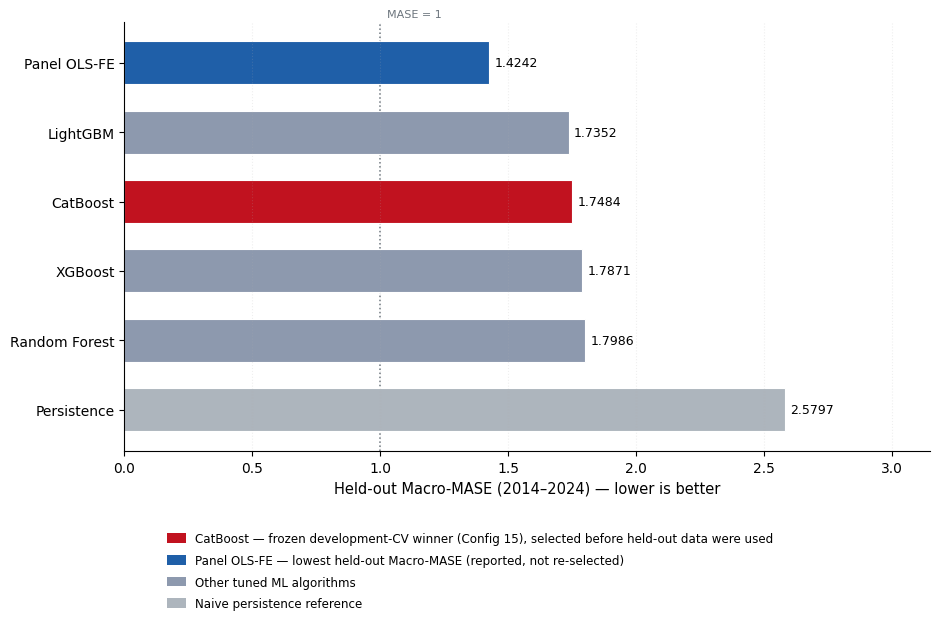

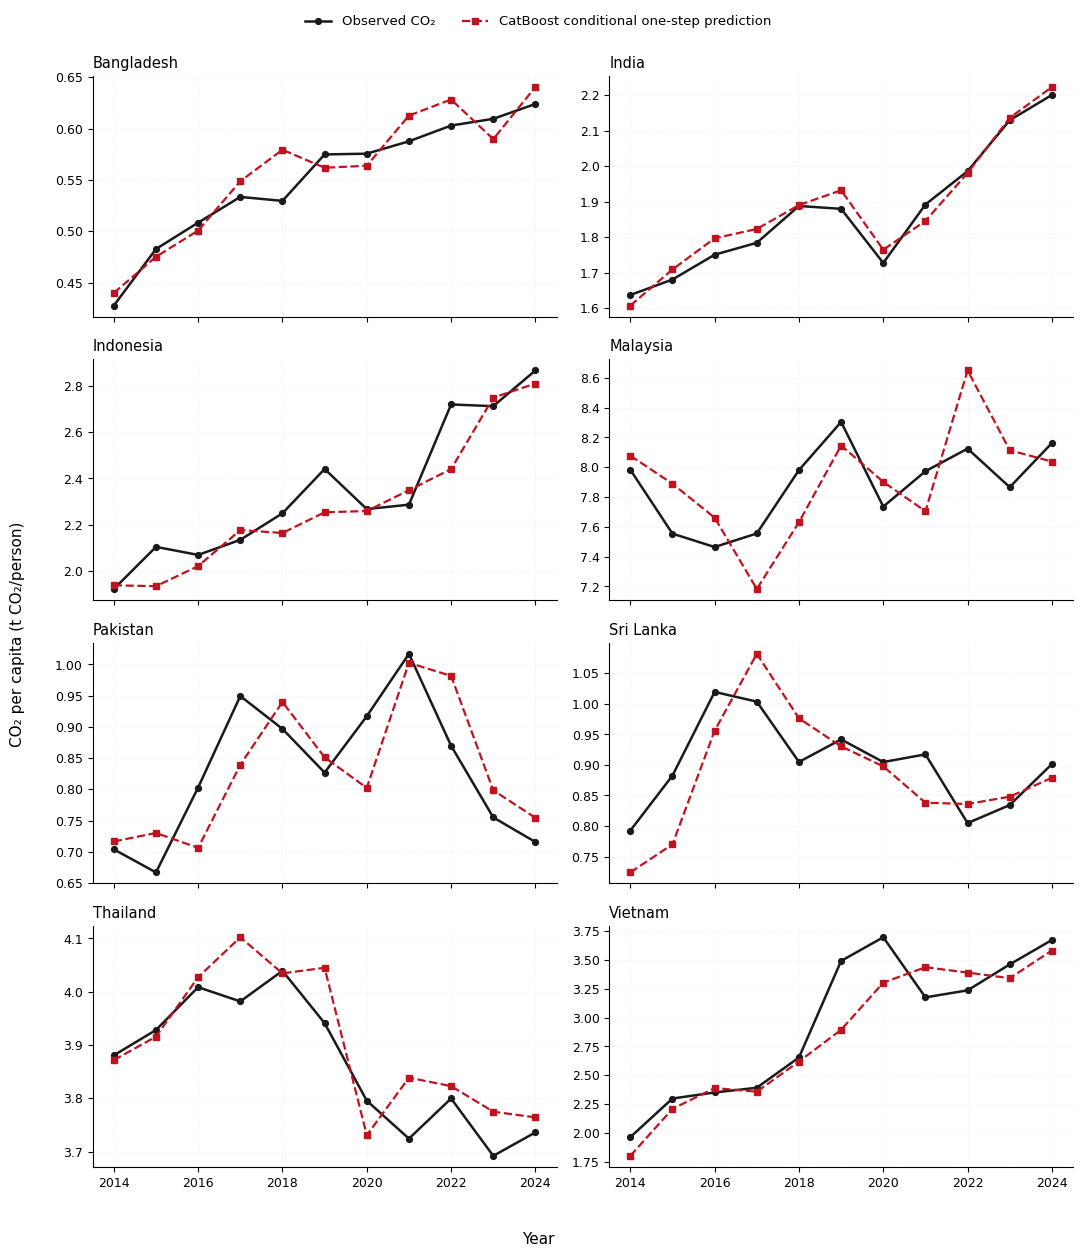

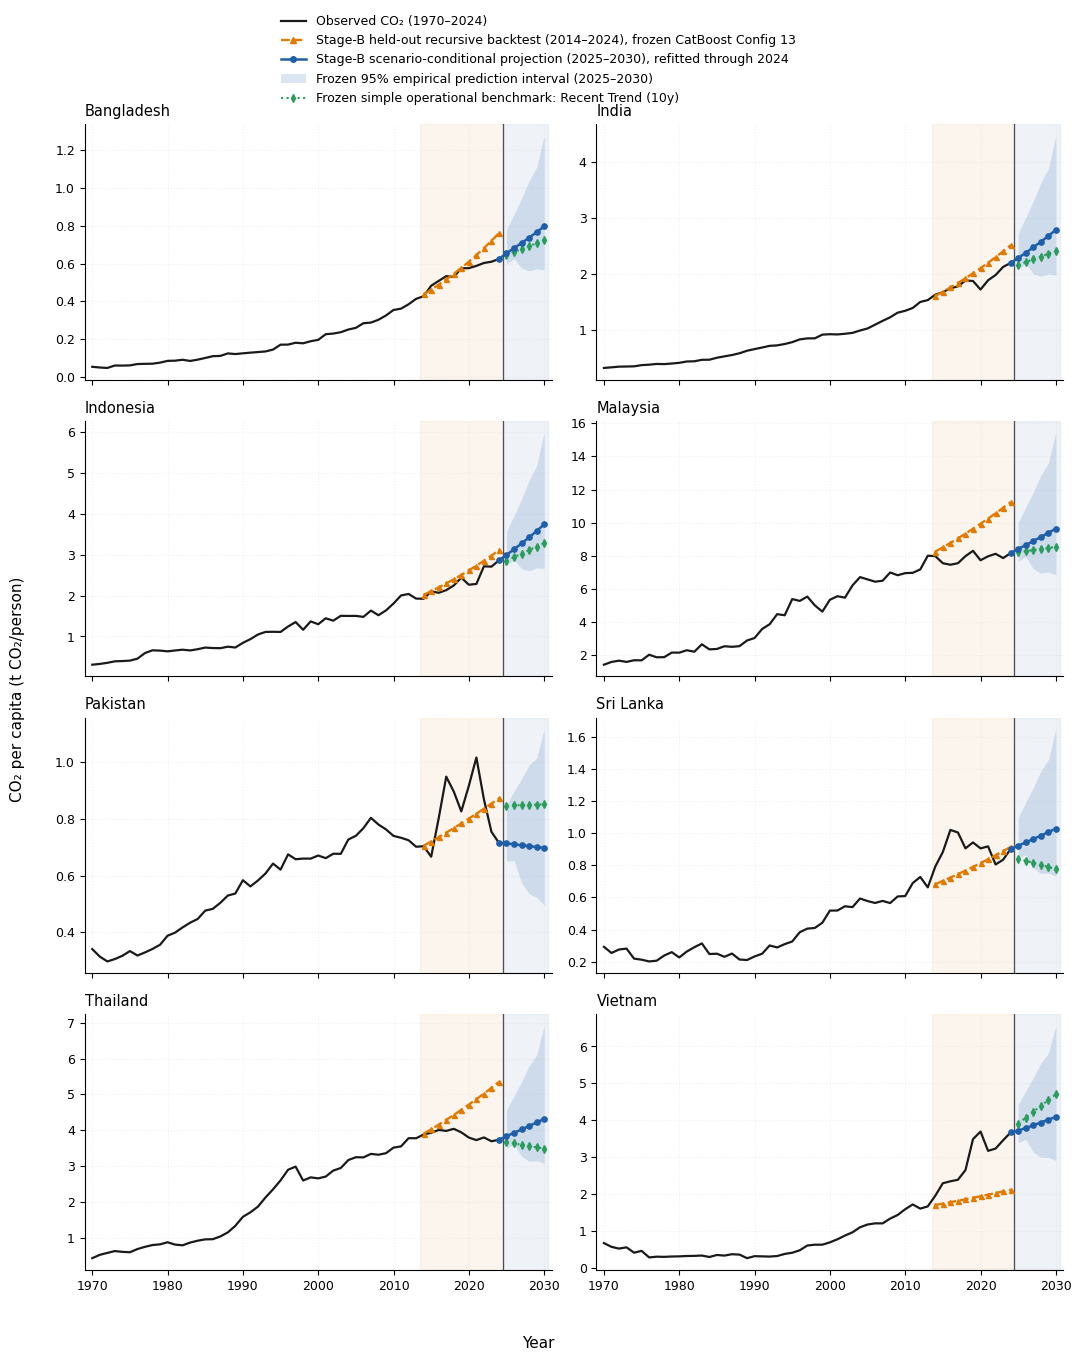

CELL 31 — STUDY FIGURES

SUPPORTING FIGURE — STAGE-A HELD-OUT MACRO-MASE COMPARISON
  Task              : conditional one-step prediction (2014-2024)
  Information set   : observed year-t indicators + observed CO2(t-1)
  Methods compared  : 6
  Frozen CV winner  : CatBoost (Config 15)
  Held-out leader   : Panel OLS-FE
  Both roles are labelled in the figure; no model is re-selected.

SUPERSEDED DRAFT — STAGE-A OBSERVED VERSUS PREDICTED
  Model plotted     : CatBoost (frozen Stage-A winner) only
  Panels            : 8 countries, 2014-2024
  Excluded by design: Panel OLS-FE and persistence (kept in F1 instead)
  Label             : primary Stage-A conditional one-step prediction figure

FIGURE 4.4 — STAGE-B BACKTEST AND PROJECTION
  Observed history  : 1970-2024
  Held-out backtest : 2014-2024, frozen CatBoost Config 13
  Projection        : 2025-2030, refitted through 2024
  Uncertainty       : frozen 95% empirical PI, future years only
  Benchmark         : Recent Trend (10y)
  Separ

In [32]:
# ============================================================
# CELL 31 — STUDY FIGURES
# ============================================================
# Run after Cell 30; plot existing frozen upstream results only.
# No fitting, tuning, prediction, recalibration or re-selection.
# Save three figures as 300-dpi PNGs and vector PDFs:
#   1. Supporting Stage-A held-out Macro-MASE comparison.
#   2. Superseded Stage-A observed/predicted draft (replaced in Cell 32).
#   3. Figure 4.4: Stage-B history, backtest and future projection.
# Stage A is conditional one-step prediction, not forecasting.
# Stage-B 2014–2024 is the held-out operational backtest.
# Stage-B 2025–2030 is scenario-conditional projection, not an operational forecast.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ------------------------------------------------------------
# 1. INTEGRITY GATE + COPIES OF EXISTING PLOTTING DATA
# ------------------------------------------------------------
required_objects = [
    "df", "stage_a_holdout_results", "STAGE_A_HOLDOUT_PREDICTIONS",
    "stage_b_holdout_predictions", "stage_b_projection_intervals",
    "BENCHMARK_PROJECTION", "MODEL_NAMES", "STAGE_A_WINNER",
    "FROZEN_STAGE_A_WINNER", "FROZEN_STAGE_A_CONFIG_ID", "STAGE_B_WINNER",
    "FROZEN_STAGE_B_WINNER", "FROZEN_STAGE_B_CONFIG_ID",
    "FINAL_SIMPLE_OPERATIONAL_BENCHMARK_CV", "TRAIN_END", "TEST_START", "TEST_END",
    "PROJECTION_ORIGIN", "PROJECTION_START", "PROJECTION_END", "FIGURES_DIR",
]
missing_objects = [name for name in required_objects if name not in globals()]
assert not missing_objects, f"Missing objects: {missing_objects}"
assert STAGE_A_WINNER == FROZEN_STAGE_A_WINNER
assert STAGE_B_WINNER == FROZEN_STAGE_B_WINNER

FIGURE_COUNTRIES = sorted(df["country"].unique())
N_FIGURE_COUNTRIES = len(FIGURE_COUNTRIES)
assert N_FIGURE_COUNTRIES == 8
FIGURE_HISTORY_START_YEAR = int(df["year"].min())

stage_a_winner_predictions = STAGE_A_HOLDOUT_PREDICTIONS[
    FROZEN_STAGE_A_WINNER
].copy()
assert len(stage_a_winner_predictions) == (
    N_FIGURE_COUNTRIES * (TEST_END - TEST_START + 1)
)

stage_b_backtest = stage_b_holdout_predictions[
    ["country", "year", "Predicted_CO2"]
].copy()
assert int(stage_b_backtest["year"].min()) == TEST_START
assert int(stage_b_backtest["year"].max()) == TEST_END

stage_b_future = stage_b_projection_intervals[[
    "country", "year", "Projected_CO2", "Lower_95", "Upper_95",
]].copy()
assert int(stage_b_future["year"].min()) == PROJECTION_START
assert int(stage_b_future["year"].max()) == PROJECTION_END

benchmark_future = BENCHMARK_PROJECTION[
    ["country", "year", "Benchmark_CO2"]
].copy()
assert len(benchmark_future) == len(stage_b_future)


# ------------------------------------------------------------
# 2. SHARED STYLE + ORIGINAL PNG/PDF SAVE HELPER
# ------------------------------------------------------------
COLOR_OBSERVED = "#1a1a1a"
COLOR_STAGE_A = "#c1121f"
COLOR_BACKTEST = "#e07a00"
COLOR_PROJECTION = "#1f5fa8"
COLOR_BENCHMARK = "#2a9d5c"
COLOR_PI = "#1f5fa8"

COLOR_FROZEN_WINNER = "#c1121f"
COLOR_HELDOUT_LEADER = "#1f5fa8"
COLOR_OTHER_ML = "#8d99ae"
COLOR_REFERENCE = "#adb5bd"
FIG_DPI = 300


def save_figure(figure, stem):
    """Save one figure as 300-dpi PNG and vector PDF."""
    png_path = FIGURES_DIR / f"{stem}.png"
    pdf_path = FIGURES_DIR / f"{stem}.pdf"
    figure.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
    figure.savefig(pdf_path, bbox_inches="tight")
    return png_path, pdf_path


saved_figures = []


# ============================================================
# SUPPORTING FIGURE — STAGE-A HELD-OUT MACRO-MASE COMPARISON
# ============================================================
# Conditional one-step task: observed indicators(t) + observed CO2(t-1).
# Label the frozen development winner separately from the held-out leader.
f1_data = (
    stage_a_holdout_results[["Method", "Macro_MASE"]].copy()
    .sort_values("Macro_MASE", ascending=False).reset_index(drop=True)
)
expected_f1_methods = set(MODEL_NAMES) | {"Panel OLS-FE", "Persistence"}
assert set(f1_data["Method"]) == expected_f1_methods, (
    "Stage-A supporting figure expects the four ML algorithms plus "
    "Panel OLS-FE and Persistence."
)
HELDOUT_LEADER = str(f1_data.sort_values("Macro_MASE").iloc[0]["Method"])


def f1_role(method):
    if method == FROZEN_STAGE_A_WINNER:
        return "frozen_winner"
    if method == HELDOUT_LEADER:
        return "heldout_leader"
    if method == "Persistence":
        return "reference"
    return "other_ml"


F1_ROLE_COLOR = {
    "frozen_winner": COLOR_FROZEN_WINNER,
    "heldout_leader": COLOR_HELDOUT_LEADER,
    "other_ml": COLOR_OTHER_ML,
    "reference": COLOR_REFERENCE,
}
f1_data["Role_Key"] = f1_data["Method"].apply(f1_role)
f1_data["Bar_Color"] = f1_data["Role_Key"].map(F1_ROLE_COLOR)
f1_data["Display_Method"] = np.where(
    f1_data["Method"] == "Panel OLS-FE", "Panel OLS-FE", f1_data["Method"],
)

fig1, ax1 = plt.subplots(figsize=(9.5, 7.0))
y_positions = np.arange(len(f1_data))
bars_f1 = ax1.barh(
    y_positions, f1_data["Macro_MASE"], height=0.62,
    color=f1_data["Bar_Color"], edgecolor="white", linewidth=0.8,
)
ax1.bar_label(
    bars_f1, labels=[f"{value:.4f}" for value in f1_data["Macro_MASE"]],
    padding=4, fontsize=9,
)
ax1.set_yticks(y_positions)
ax1.set_yticklabels(f1_data["Display_Method"], fontsize=10)
ax1.set_xlabel(
    "Held-out Macro-MASE "
    f"({TEST_START}\u2013{TEST_END}) \u2014 lower is better",
    fontsize=10.5,
)
ax1.set_xlim(0, float(f1_data["Macro_MASE"].max()) * 1.22)
ax1.axvline(1.0, color="#6c757d", linestyle=":", linewidth=1.1, zorder=0)
ax1.text(
    1.0, len(f1_data) - 0.30, "  MASE = 1", fontsize=8,
    color="#6c757d", va="center",
)

f1_legend = [
    Patch(
        facecolor=COLOR_FROZEN_WINNER,
        label=(
            f"{FROZEN_STAGE_A_WINNER} \u2014 frozen development-CV winner "
            f"(Config {FROZEN_STAGE_A_CONFIG_ID}), "
            f"selected before held-out data were used"
        ),
    ),
    Patch(
        facecolor=COLOR_HELDOUT_LEADER,
        label=(
            f"{HELDOUT_LEADER} \u2014 lowest held-out Macro-MASE "
            f"(reported, not re-selected)"
        ),
    ),
    Patch(facecolor=COLOR_OTHER_ML, label="Other tuned ML algorithms"),
    Patch(facecolor=COLOR_REFERENCE, label="Naive persistence reference"),
]
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="x", alpha=0.20, linestyle=":")

# Keep the original lower-quarter space for a legend outside the plot.
fig1.tight_layout(rect=[0, 0.26, 1, 1])
fig1.legend(
    handles=f1_legend, loc="upper center", bbox_to_anchor=(0.5, 0.235),
    ncol=1, frameon=False, fontsize=8.6, handlelength=1.6,
    handleheight=0.9, labelspacing=0.72, borderaxespad=0.0,
)
saved_figures.append(save_figure(fig1, "fig_stage_a_heldout_macro_mase"))
plt.show()
plt.close(fig1)


# ============================================================
# SUPERSEDED DRAFT — STAGE-A OBSERVED VERSUS PREDICTED
# ============================================================
# Preserve the draft output; Cell 32 provides its Figure 4.1 replacement.
# Plot only the frozen winner; Panel OLS-FE and persistence stay in F1.
fig2, axes2 = plt.subplots(4, 2, figsize=(11, 12.5), sharex=True)
axes2 = axes2.ravel()
for ax, country in zip(axes2, FIGURE_COUNTRIES):
    panel = stage_a_winner_predictions[
        stage_a_winner_predictions["country"] == country
    ].sort_values("year")
    assert len(panel) == TEST_END - TEST_START + 1

    ax.plot(
        panel["year"], panel["actual_co2"], color=COLOR_OBSERVED,
        linewidth=1.8, marker="o", markersize=4.2,
        label="Observed CO\u2082", zorder=3,
    )
    ax.plot(
        panel["year"], panel["pred_co2"], color=COLOR_STAGE_A,
        linewidth=1.6, linestyle="--", marker="s", markersize=3.8,
        label=f"{FROZEN_STAGE_A_WINNER} conditional one-step prediction", zorder=4,
    )
    ax.set_title(country, fontsize=10.5, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.18, linestyle=":")
    ax.tick_params(labelsize=9)

for ax in axes2[len(FIGURE_COUNTRIES):]:
    ax.set_visible(False)
fig2.supylabel("CO\u2082 per capita (t CO\u2082/person)", fontsize=11)
fig2.supxlabel("Year", fontsize=11)
f2_handles, f2_labels = axes2[0].get_legend_handles_labels()
fig2.legend(
    f2_handles, f2_labels, loc="upper center", bbox_to_anchor=(0.5, 1.005),
    ncol=2, frameon=False, fontsize=9.5,
)
fig2.tight_layout(rect=[0.02, 0.02, 1, 0.975])
saved_figures.append(save_figure(fig2, "fig_stage_a_observed_vs_predicted"))
plt.show()
plt.close(fig2)


# ============================================================
# FIGURE 4.4 — STAGE-B BACKTEST AND SCENARIO-CONDITIONAL PROJECTION
# ============================================================
# Preserve the separate backtest/future shading and divider at 2024.5.
# Connect the Stage-B future point path to observed 2024 for display only.
# As in the original, the PI band and benchmark use future years only.
fig3, axes3 = plt.subplots(4, 2, figsize=(11, 13.5), sharex=True)
axes3 = axes3.ravel()
for ax, country in zip(axes3, FIGURE_COUNTRIES):
    history = df[
        (df["country"] == country)
        & df["year"].between(FIGURE_HISTORY_START_YEAR, PROJECTION_ORIGIN)
    ].sort_values("year")
    backtest = stage_b_backtest[
        stage_b_backtest["country"] == country
    ].sort_values("year")
    future = stage_b_future[
        stage_b_future["country"] == country
    ].sort_values("year")
    benchmark = benchmark_future[
        benchmark_future["country"] == country
    ].sort_values("year")

    ax.axvspan(
        TEST_START - 0.5, PROJECTION_ORIGIN + 0.5,
        color="#e07a00", alpha=0.07, zorder=0,
    )
    ax.axvspan(
        PROJECTION_ORIGIN + 0.5, PROJECTION_END + 0.5,
        color="#1f5fa8", alpha=0.07, zorder=0,
    )
    ax.axvline(
        PROJECTION_ORIGIN + 0.5, color="#495057", linestyle="-",
        linewidth=0.9, zorder=1,
    )
    ax.fill_between(
        future["year"], future["Lower_95"], future["Upper_95"],
        color=COLOR_PI, alpha=0.16, linewidth=0, zorder=2,
    )
    ax.plot(
        history["year"], history["co2_per_capita"], color=COLOR_OBSERVED,
        linewidth=1.6, zorder=5,
    )
    ax.plot(
        backtest["year"], backtest["Predicted_CO2"], color=COLOR_BACKTEST,
        linewidth=1.7, linestyle="--", marker="^", markersize=3.6, zorder=6,
    )

    anchor_year = int(PROJECTION_ORIGIN)
    anchor_value = float(history.loc[
        history["year"] == anchor_year, "co2_per_capita",
    ].iloc[0])
    projection_years = np.concatenate([
        [anchor_year], future["year"].to_numpy(dtype=float),
    ])
    projection_values = np.concatenate([
        [anchor_value], future["Projected_CO2"].to_numpy(dtype=float),
    ])
    ax.plot(
        projection_years, projection_values, color=COLOR_PROJECTION,
        linewidth=1.8, marker="o", markersize=3.8, zorder=7,
    )
    ax.plot(
        benchmark["year"], benchmark["Benchmark_CO2"], color=COLOR_BENCHMARK,
        linewidth=1.5, linestyle=":", marker="d", markersize=3.6, zorder=6,
    )
    ax.set_title(country, fontsize=10.5, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.16, linestyle=":", zorder=0)
    ax.tick_params(labelsize=9)
    ax.set_xlim(FIGURE_HISTORY_START_YEAR - 1, PROJECTION_END + 1)

for ax in axes3[len(FIGURE_COUNTRIES):]:
    ax.set_visible(False)

f3_legend = [
    Line2D(
        [0], [0], color=COLOR_OBSERVED, linewidth=1.6,
        label=(
            f"Observed CO\u2082 "
            f"({FIGURE_HISTORY_START_YEAR}\u2013{PROJECTION_ORIGIN})"
        ),
    ),
    Line2D(
        [0], [0], color=COLOR_BACKTEST, linewidth=1.7, linestyle="--",
        marker="^", markersize=4,
        label=(
            f"Stage-B held-out recursive backtest ({TEST_START}\u2013{TEST_END}), "
            f"frozen {FROZEN_STAGE_B_WINNER} Config {FROZEN_STAGE_B_CONFIG_ID}"
        ),
    ),
    Line2D(
        [0], [0], color=COLOR_PROJECTION, linewidth=1.8, marker="o", markersize=4,
        label=(
            f"Stage-B scenario-conditional projection "
            f"({PROJECTION_START}\u2013{PROJECTION_END}), "
            f"refitted through {PROJECTION_ORIGIN}"
        ),
    ),
    Patch(
        facecolor=COLOR_PI, alpha=0.16,
        label=(
            "Frozen 95% empirical prediction interval "
            f"({PROJECTION_START}\u2013{PROJECTION_END})"
        ),
    ),
    Line2D(
        [0], [0], color=COLOR_BENCHMARK, linewidth=1.5, linestyle=":",
        marker="d", markersize=4,
        label=(
            f"Frozen simple operational benchmark: "
            f"{FINAL_SIMPLE_OPERATIONAL_BENCHMARK_CV}"
        ),
    ),
]
fig3.legend(
    handles=f3_legend, loc="upper center", bbox_to_anchor=(0.5, 1.008),
    ncol=1, frameon=False, fontsize=9,
)
fig3.supylabel("CO\u2082 per capita (t CO\u2082/person)", fontsize=11)
fig3.supxlabel("Year", fontsize=11)
fig3.tight_layout(rect=[0.02, 0.02, 1, 0.945])
saved_figures.append(save_figure(fig3, "fig_4_4_stage_b_backtest_and_projection"))
plt.show()
plt.close(fig3)


# ------------------------------------------------------------
# 3. REPORT — ORIGINAL TEXT, ROLES AND OUTPUT ORDER
# ------------------------------------------------------------
print("=" * 78)
print("CELL 31 — STUDY FIGURES")
print("=" * 78)

print("\nSUPPORTING FIGURE — STAGE-A HELD-OUT MACRO-MASE COMPARISON")
print(
    f"  Task              : conditional one-step "
    f"prediction ({TEST_START}-{TEST_END})"
)
print("  Information set   : observed year-t indicators + observed CO2(t-1)")
print(f"  Methods compared  : {len(f1_data)}")
print(
    f"  Frozen CV winner  : {FROZEN_STAGE_A_WINNER} "
    f"(Config {FROZEN_STAGE_A_CONFIG_ID})"
)
print(f"  Held-out leader   : {HELDOUT_LEADER}")
if HELDOUT_LEADER != FROZEN_STAGE_A_WINNER:
    print("  Both roles are labelled in the figure; no model is re-selected.")

print("\nSUPERSEDED DRAFT — STAGE-A OBSERVED VERSUS PREDICTED")
print(f"  Model plotted     : {FROZEN_STAGE_A_WINNER} (frozen Stage-A winner) only")
print(
    f"  Panels            : {N_FIGURE_COUNTRIES} "
    f"countries, {TEST_START}-{TEST_END}"
)
print("  Excluded by design: Panel OLS-FE and persistence (kept in F1 instead)")
print("  Label             : primary Stage-A conditional one-step prediction figure")

print("\nFIGURE 4.4 — STAGE-B BACKTEST AND PROJECTION")
print(f"  Observed history  : {FIGURE_HISTORY_START_YEAR}-{PROJECTION_ORIGIN}")
print(
    f"  Held-out backtest : {TEST_START}-{TEST_END}, "
    f"frozen {FROZEN_STAGE_B_WINNER} Config {FROZEN_STAGE_B_CONFIG_ID}"
)
print(
    f"  Projection        : {PROJECTION_START}-{PROJECTION_END}, "
    f"refitted through {PROJECTION_ORIGIN}"
)
print("  Uncertainty       : frozen 95% empirical PI, future years only")
print(f"  Benchmark         : {FINAL_SIMPLE_OPERATIONAL_BENCHMARK_CV}")
print(
    "  Separation        : shaded regions plus a vertical "
    f"divider at {PROJECTION_ORIGIN}/{PROJECTION_START}"
)

print("\nFILES SAVED")
for png_path, pdf_path in saved_figures:
    print(f"  {png_path.name}")
    print(f"  {pdf_path.name}")

print("\nINTEGRITY")
for _line in [
    "Reporting only — no fitting, tuning or prediction",
    "No driver projection or interval recalibration",
    "No model, configuration or benchmark re-selection",
    "All plotted values read from frozen upstream objects",
    "Stage A described as conditional one-step prediction, never as forecasting",
    "Stage-B 2014-2024 described as a held-out operational backtest",
    "Stage-B 2025-2030 described as a scenario-conditional projection, "
    "never as an operational forecast",
    "Backtest and projection are visually distinct",
    "Frozen CV winner and held-out leader both labelled in F1",
    "All figures saved at 300 dpi PNG plus vector PDF",
]:
    print(f"  ✓ {_line}")

print(
    "\nOUTPUTS: "
    "Stage-A held-out comparison → Supporting figure | "
    "Stage-A draft observed vs predicted → Superseded by Figure 4.1 in Cell 32 | "
    "Figure 4.4 Stage-B backtest + scenario-conditional projection "
    "→ Main text | earlier Cell-29 projection-only figure → Notebook only"
)


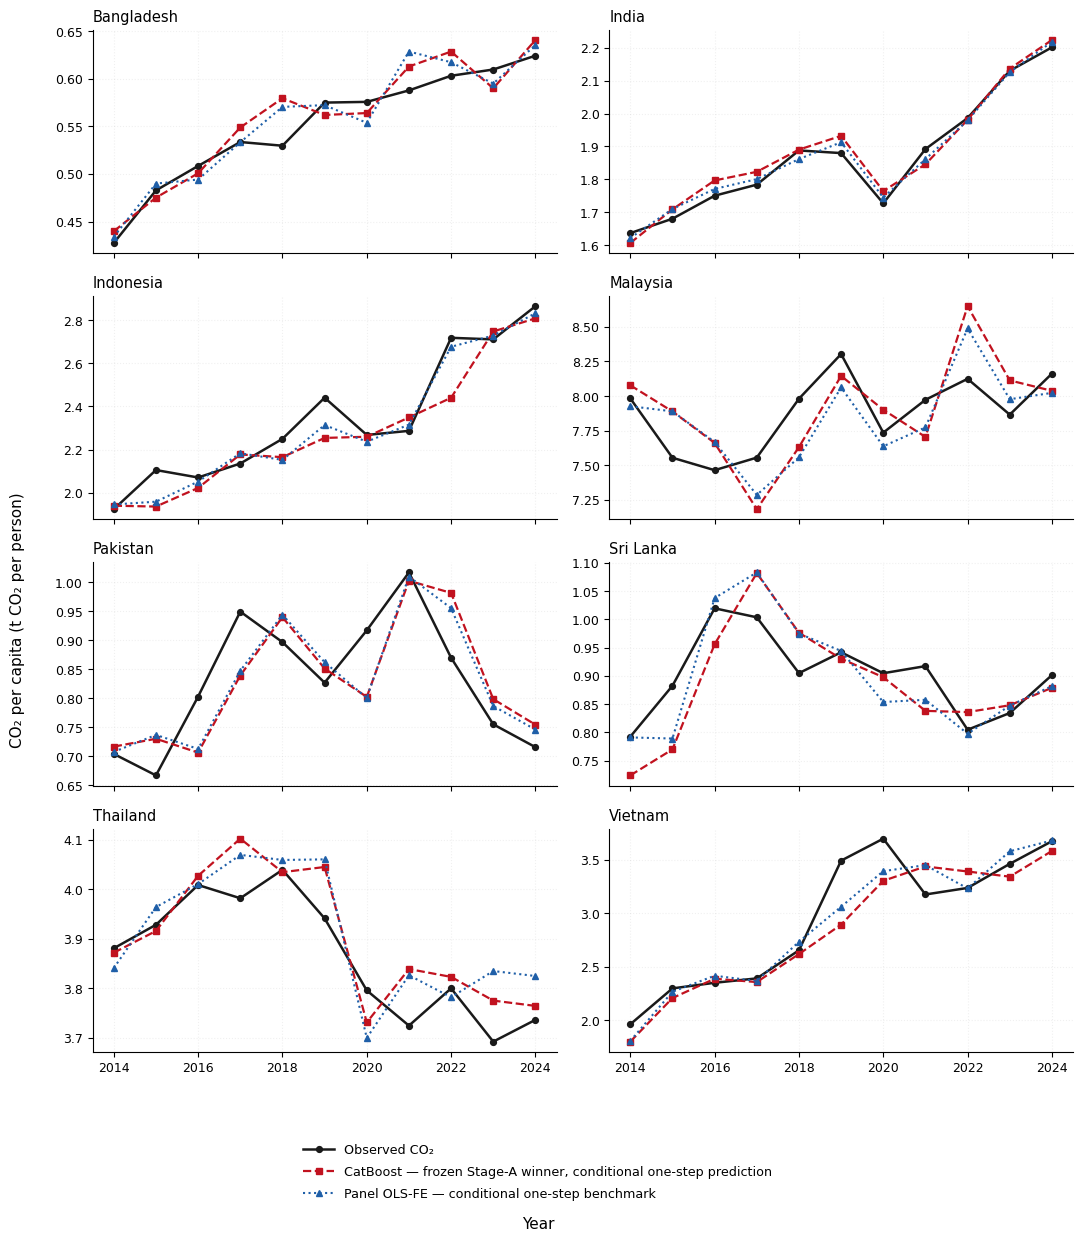

CELL 32 — FIGURE 4.1: STAGE-A OBSERVED VERSUS PREDICTED

Prediction source : in-memory Cell-13 dictionary
Task              : conditional one-step prediction (2014-2024)
Information set   : observed year-t indicators + observed CO2(t-1)
Panels            : 8 countries × 11 years
Series per panel  : observed; CatBoost; Panel OLS-FE
Observations used : 88 per series

FILES SAVED
  fig_4_1_stage_a_observed_vs_predicted.png
  fig_4_1_stage_a_observed_vs_predicted.pdf

VALIDATION PASSED
  ✓ Reporting only — no fitting, tuning or prediction
  ✓ Frozen Stage-A winner identity matches STAGE_A_WINNER
  ✓ Both required series present under identical keys
  ✓ 88 rows in each series
  ✓ No duplicated country-year rows in either series
  ✓ Exactly 11 observations per country, covering 2014-2024
  ✓ Observed CO2 identical across both series (maximum difference 0)
  ✓ All plotted levels finite and strictly positive
  ✓ Panel OLS-FE series is the conditional benchmark, not the operational benchmark of

In [33]:
# ============================================================
# CELL 32 — FIGURE 4.1: STAGE-A OBSERVED VERSUS PREDICTED
# ============================================================
# Reporting only: plot retained Cell 13 predictions, without
# fitting, tuning, predicting, recalibrating or selecting models.
# Stage A is conditional one-step prediction, not forecasting.
# Panel OLS-FE here is the conditional Cell 13 benchmark,
# not the separate operational benchmark from Cell 24.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# 1. CHECK REQUIRED OBJECTS AND FROZEN WINNER
# ------------------------------------------------------------
required_objects = [
    "df",
    "STAGE_A_WINNER",
    "FROZEN_STAGE_A_WINNER",
    "TEST_START",
    "TEST_END",
    "FIGURES_DIR",
]
missing_objects = [name for name in required_objects if name not in globals()]
assert not missing_objects, f"Missing objects: {missing_objects}"
assert STAGE_A_WINNER == FROZEN_STAGE_A_WINNER

PANEL_FE_CONDITIONAL_KEY = "Panel OLS-FE"
REQUIRED_METHODS = [FROZEN_STAGE_A_WINNER, PANEL_FE_CONDITIONAL_KEY]
REQUIRED_COLUMNS = ["country", "year", "actual_co2", "pred_co2"]

FIGURE_COUNTRIES = sorted(df["country"].unique())
N_FIGURE_COUNTRIES = len(FIGURE_COUNTRIES)
assert N_FIGURE_COUNTRIES == 8

HELDOUT_YEARS = sorted(range(TEST_START, TEST_END + 1))
N_HELDOUT_YEARS = len(HELDOUT_YEARS)
EXPECTED_ROWS = N_FIGURE_COUNTRIES * N_HELDOUT_YEARS


# ------------------------------------------------------------
# 2. READ PREDICTIONS: DICTIONARY FIRST, CSV FALLBACK
# ------------------------------------------------------------
# Both sources are read-only and use the same validation below.
def _dictionary_is_usable():
    """In-memory dictionary present and holding both series."""
    obj = globals().get("STAGE_A_HOLDOUT_PREDICTIONS")
    if not isinstance(obj, dict):
        return False
    return all(key in obj for key in REQUIRED_METHODS)


def _load_from_dictionary():
    obj = STAGE_A_HOLDOUT_PREDICTIONS
    return {method: obj[method].copy() for method in REQUIRED_METHODS}


def _load_from_csv():
    assert "TABLES_DIR" in globals(), (
        "TABLES_DIR is required for the CSV fallback."
    )
    csv_path = TABLES_DIR / "stage_a_holdout_predictions.csv"
    assert csv_path.exists(), (
        "Stage-A held-out predictions are unavailable: "
        f"{csv_path} not found and the in-memory "
        "dictionary is not usable."
    )

    raw = pd.read_csv(csv_path)
    assert "Method" in raw.columns, (
        "Prediction CSV is missing the Method column."
    )
    available = set(raw["Method"].unique())
    missing_methods = [
        method for method in REQUIRED_METHODS if method not in available
    ]
    assert not missing_methods, f"Prediction CSV is missing: {missing_methods}"

    return {
        method: (
            raw[raw["Method"] == method]
            .drop(columns=["Method"])
            .reset_index(drop=True)
        )
        for method in REQUIRED_METHODS
    }


if _dictionary_is_usable():
    prediction_frames = _load_from_dictionary()
    PREDICTION_SOURCE = "in-memory Cell-13 dictionary"
else:
    prediction_frames = _load_from_csv()
    PREDICTION_SOURCE = (
        "Cell-13 prediction CSV "
        "(stage_a_holdout_predictions.csv)"
    )

assert set(prediction_frames) == set(REQUIRED_METHODS)


# ------------------------------------------------------------
# 3. VALIDATE ROWS, YEARS, VALUES AND SHARED OBSERVATIONS
# ------------------------------------------------------------
def _validate_prediction_frame(frame, label):
    for column in REQUIRED_COLUMNS:
        assert column in frame.columns, f"{label}: missing column {column}"

    work = frame[REQUIRED_COLUMNS].copy()
    work["year"] = work["year"].astype(int)

    assert len(work) == EXPECTED_ROWS, (
        f"{label}: expected {EXPECTED_ROWS} rows, found {len(work)}"
    )
    n_duplicates = int(work.duplicated(subset=["country", "year"]).sum())
    assert n_duplicates == 0, (
        f"{label}: {n_duplicates} duplicated country-year rows"
    )
    assert sorted(work["country"].unique()) == FIGURE_COUNTRIES, (
        f"{label}: country set does not match the panel"
    )

    for country in FIGURE_COUNTRIES:
        years = sorted(work.loc[work["country"] == country, "year"].tolist())
        assert len(years) == N_HELDOUT_YEARS, (
            f"{label}, {country}: expected "
            f"{N_HELDOUT_YEARS} observations, found {len(years)}"
        )
        assert years == HELDOUT_YEARS, (
            f"{label}, {country}: year coverage is not "
            f"exactly {TEST_START}-{TEST_END}"
        )

    for column in ["actual_co2", "pred_co2"]:
        values = work[column].to_numpy(dtype=float)
        assert np.isfinite(values).all(), (
            f"{label}: non-finite values in {column}"
        )
        assert (values > 0).all(), f"{label}: non-positive values in {column}"

    return work.sort_values(["country", "year"]).reset_index(drop=True)


winner_predictions = _validate_prediction_frame(
    prediction_frames[FROZEN_STAGE_A_WINNER], FROZEN_STAGE_A_WINNER
)
panel_fe_predictions = _validate_prediction_frame(
    prediction_frames[PANEL_FE_CONDITIONAL_KEY], PANEL_FE_CONDITIONAL_KEY
)

# Both methods must contain exactly the same observed CO2 levels.
observed_check = winner_predictions[["country", "year", "actual_co2"]].merge(
    panel_fe_predictions[["country", "year", "actual_co2"]],
    on=["country", "year"],
    suffixes=("_winner", "_fe"),
    validate="one_to_one",
)
assert len(observed_check) == EXPECTED_ROWS, (
    "Observed-series merge did not align on country and year."
)
max_observed_difference = float(
    np.max(
        np.abs(observed_check["actual_co2_winner"] - observed_check["actual_co2_fe"])
    )
)
assert max_observed_difference == 0.0, (
    "Observed CO2 differs between the two prediction "
    f"frames (max difference {max_observed_difference})."
)


# ------------------------------------------------------------
# 4. FIXED FIGURE STYLE
# ------------------------------------------------------------
COLOR_OBSERVED = "#1a1a1a"
COLOR_WINNER = "#c1121f"
COLOR_PANEL_FE = "#1f5fa8"
FIG_DPI = 300
FIGURE_STEM = "fig_4_1_stage_a_observed_vs_predicted"


# ------------------------------------------------------------
# 5. DRAW EIGHT COUNTRY PANELS AND SAVE PNG/PDF
# ------------------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(11, 12.5), sharex=True)
axes = axes.ravel()

for ax, country in zip(axes, FIGURE_COUNTRIES):
    winner_panel = winner_predictions[winner_predictions["country"] == country]
    fe_panel = panel_fe_predictions[panel_fe_predictions["country"] == country]

    ax.plot(
        winner_panel["year"], winner_panel["actual_co2"],
        color=COLOR_OBSERVED, linewidth=1.8,
        marker="o", markersize=4.2, zorder=4,
    )
    ax.plot(
        winner_panel["year"], winner_panel["pred_co2"],
        color=COLOR_WINNER, linewidth=1.6, linestyle="--",
        marker="s", markersize=3.8, zorder=5,
    )
    ax.plot(
        fe_panel["year"], fe_panel["pred_co2"],
        color=COLOR_PANEL_FE, linewidth=1.5, linestyle=":",
        marker="^", markersize=3.8, zorder=6,
    )
    ax.set_title(country, fontsize=10.5, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.18, linestyle=":")
    ax.tick_params(labelsize=9)

for ax in axes[N_FIGURE_COUNTRIES:]:
    ax.set_visible(False)

fig.supylabel("CO\u2082 per capita (t CO\u2082 per person)", fontsize=11)
fig.supxlabel("Year", fontsize=11)

legend_handles = [
    Line2D(
        [0], [0], color=COLOR_OBSERVED, linewidth=1.8,
        marker="o", markersize=4.2, label="Observed CO\u2082",
    ),
    Line2D(
        [0], [0], color=COLOR_WINNER, linewidth=1.6, linestyle="--",
        marker="s", markersize=3.8,
        label=(
            f"{FROZEN_STAGE_A_WINNER} \u2014 frozen "
            "Stage-A winner, conditional one-step prediction"
        ),
    ),
    Line2D(
        [0], [0], color=COLOR_PANEL_FE, linewidth=1.5, linestyle=":",
        marker="^", markersize=3.8,
        label="Panel OLS-FE \u2014 conditional one-step benchmark",
    ),
]

# Keep the legend below the panels, outside the plotting area.
fig.tight_layout(rect=[0.02, 0.10, 1, 1])
fig.legend(
    handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.085),
    ncol=1, frameon=False, fontsize=9.2, handlelength=2.4,
    labelspacing=0.7, borderaxespad=0.0,
)

STAGE_A_OBS_PRED_PNG = FIGURES_DIR / f"{FIGURE_STEM}.png"
STAGE_A_OBS_PRED_PDF = FIGURES_DIR / f"{FIGURE_STEM}.pdf"
fig.savefig(STAGE_A_OBS_PRED_PNG, dpi=FIG_DPI, bbox_inches="tight")
fig.savefig(STAGE_A_OBS_PRED_PDF, bbox_inches="tight")
plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 6. ORIGINAL REPORT
# ------------------------------------------------------------
print("=" * 78)
print("CELL 32 — FIGURE 4.1: STAGE-A OBSERVED VERSUS PREDICTED")
print("=" * 78)
print(f"\nPrediction source : {PREDICTION_SOURCE}")
print(
    f"Task              : conditional one-step "
    f"prediction ({TEST_START}-{TEST_END})"
)
print("Information set   : observed year-t indicators + observed CO2(t-1)")
print(
    f"Panels            : {N_FIGURE_COUNTRIES} countries "
    f"\u00d7 {N_HELDOUT_YEARS} years"
)
print(
    f"Series per panel  : observed; {FROZEN_STAGE_A_WINNER}; "
    f"{PANEL_FE_CONDITIONAL_KEY}"
)
print(f"Observations used : {EXPECTED_ROWS} per series")
print("\nFILES SAVED")
print(f"  {STAGE_A_OBS_PRED_PNG.name}")
print(f"  {STAGE_A_OBS_PRED_PDF.name}")
print("\nVALIDATION PASSED")

for _line in [
    "Reporting only \u2014 no fitting, tuning or prediction",
    "Frozen Stage-A winner identity matches STAGE_A_WINNER",
    "Both required series present under identical keys",
    f"{EXPECTED_ROWS} rows in each series",
    "No duplicated country-year rows in either series",
    f"Exactly {N_HELDOUT_YEARS} observations per country, "
    f"covering {TEST_START}-{TEST_END}",
    "Observed CO2 identical across both series (maximum difference 0)",
    "All plotted levels finite and strictly positive",
    "Panel OLS-FE series is the conditional benchmark, "
    "not the operational benchmark of Cell 24",
    "Stage A described as conditional one-step prediction, never as forecasting",
    "Figure saved at 300 dpi PNG plus vector PDF",
]:
    print(f"  \u2713 {_line}")

print(
    "\nOUTPUTS: "
    "Figure 4.1 Stage-A observed versus predicted, eight countries "
    "\u2192 Main text"
)


**Cell 33 — internal numbering list.** Use article and supplement table numbers when citing results.


In [34]:
# ============================================================
# CELL 33 — RELATIVE MASE AND SCALING-PERIOD DIAGNOSTIC
# ============================================================
# Reporting only: read frozen results; no fitting or selection.
# Write revised tables to a separate folder, not over prior outputs.
#
# MASE uses development-history denominators for every method.
# MASE = 1 means one average development-period annual change;
# held-out persistence does not have to equal 1.
# Relative MASE compares methods with persistence in the same window.
# Held-out change scales are descriptive, never used for modelling.

import numpy as np
import pandas as pd
from pathlib import Path


# ------------------------------------------------------------
# 1. CHECK INPUTS, FROZEN IDENTITIES AND OUTPUT FOLDER
# ------------------------------------------------------------
required_objects = [
    "df",
    "stage_a_holdout_results",
    "stage_a_holdout_reporting",
    "stage_a_skill_summary",
    "all_cv_summary",
    "operational_comparison",
    "benchmark_closure",
    "DEVELOPMENT_DENOMINATORS",
    "STAGE_A_WINNER",
    "FROZEN_STAGE_A_WINNER",
    "FROZEN_STAGE_A_CONFIG_ID",
    "STAGE_B_WINNER",
    "FROZEN_STAGE_B_WINNER",
    "FROZEN_STAGE_B_CONFIG_ID",
    "STAGE_B_HORIZON",
    "TRAIN_START",
    "TRAIN_END",
    "TEST_START",
    "TEST_END",
    "TABLES_DIR",
]
missing_objects = [name for name in required_objects if name not in globals()]
assert not missing_objects, f"Missing objects: {missing_objects}"
assert STAGE_A_WINNER == FROZEN_STAGE_A_WINNER
assert STAGE_B_WINNER == FROZEN_STAGE_B_WINNER

frozen_a_snapshot = (FROZEN_STAGE_A_WINNER, int(FROZEN_STAGE_A_CONFIG_ID))
frozen_b_snapshot = (FROZEN_STAGE_B_WINNER, int(FROZEN_STAGE_B_CONFIG_ID))

revision_tables_dir = Path(TABLES_DIR).parent / "tables_article_supplement"
revision_tables_dir.mkdir(parents=True, exist_ok=True)
revision_countries = sorted(df["country"].dropna().unique())
assert len(revision_countries) == 8


# ------------------------------------------------------------
# 2. HELPERS: READ EXISTING SCORES AND OBSERVED CHANGE SCALES
# ------------------------------------------------------------
def revision_single_macro_mase(
    frame, method, *, method_col="Method", window=None, window_col="Window"
):
    """Return one already-computed Macro-MASE value."""
    selected = frame.loc[frame[method_col] == method]
    if window is not None:
        selected = selected.loc[selected[window_col] == window]

    assert len(selected) == 1, (
        f"Expected one row for method={method!r}, "
        f"window={window!r}; found {len(selected)}."
    )
    value = float(selected.iloc[0]["Macro_MASE"])
    assert np.isfinite(value) and value > 0
    return value


def revision_development_denom(country):
    """Read one frozen development denominator safely."""
    obj = DEVELOPMENT_DENOMINATORS
    if isinstance(obj, dict):
        value = obj[country]
    elif isinstance(obj, pd.Series):
        value = obj.loc[country]
    elif isinstance(obj, pd.DataFrame):
        if {"country", "MASE_Denominator"}.issubset(obj.columns):
            selected = obj.loc[obj["country"] == country, "MASE_Denominator"]
            assert len(selected) == 1
            value = selected.iloc[0]
        else:
            value = obj.loc[country, "MASE_Denominator"]
    else:
        raise TypeError(
            "Unsupported DEVELOPMENT_DENOMINATORS type: "
            f"{type(obj).__name__}"
        )

    value = float(value)
    assert np.isfinite(value) and value > 0
    return value


def revision_mean_absolute_annual_change(frame, first_year, last_year):
    """Return country scales from consecutive observed years."""
    rows = []
    for country in revision_countries:
        series = frame.loc[
            (frame["country"] == country)
            & frame["year"].between(first_year, last_year),
            ["year", "co2_per_capita"],
        ].sort_values("year")

        expected_years = np.arange(first_year, last_year + 1)
        assert np.array_equal(
            series["year"].to_numpy(dtype=int), expected_years
        ), f"Non-consecutive years for {country}."

        changes = series["co2_per_capita"].astype(float).diff().abs().dropna()
        assert len(changes) == last_year - first_year
        rows.append({
            "country": country,
            "N_Changes": int(len(changes)),
            "Mean_Absolute_Annual_Change": float(changes.mean()),
        })

    return pd.DataFrame(rows).set_index("country").sort_index()


# ------------------------------------------------------------
# 3. STAGE-A RELATIVE MASE AND IMPROVEMENT VS PERSISTENCE
# ------------------------------------------------------------
persistence_a = revision_single_macro_mase(stage_a_holdout_results, "Persistence")
stage_a_relative = stage_a_holdout_results.loc[:, ["Method", "Macro_MASE"]].copy()
assert stage_a_relative["Method"].is_unique

stage_a_relative["Relative_MASE_vs_Persistence"] = (
    stage_a_relative["Macro_MASE"] / persistence_a
)
stage_a_relative["Macro_MASE_Improvement_vs_Persistence_Percent"] = (
    100 * (persistence_a - stage_a_relative["Macro_MASE"]) / persistence_a
)
stage_a_relative = stage_a_relative.sort_values("Macro_MASE").reset_index(drop=True)

assert np.allclose(
    stage_a_relative["Relative_MASE_vs_Persistence"],
    1 - stage_a_relative["Macro_MASE_Improvement_vs_Persistence_Percent"] / 100,
)
assert np.isclose(
    stage_a_relative.loc[
        stage_a_relative["Method"] == "Persistence", "Relative_MASE_vs_Persistence"
    ].iloc[0],
    1.0,
)


# ------------------------------------------------------------
# 4. STAGE-B RELATIVE MASE FOR BOTH HELD-OUT WINDOWS
# ------------------------------------------------------------
full_window = f"{TEST_START}-{TEST_END}"
matched_window = f"{TEST_START}-{TEST_START + STAGE_B_HORIZON - 1}"
stage_b_relative_frames = []

for window in [full_window, matched_window]:
    window_frame = operational_comparison.loc[
        operational_comparison["Window"] == window, ["Method", "Macro_MASE"]
    ].copy()

    # Cell 29 scores Recent Trend separately. Add it only if absent.
    if not benchmark_closure.empty:
        recent_candidates = benchmark_closure.loc[
            benchmark_closure["Role"] == "Recent-Trend comparator"
        ]
        assert len(recent_candidates) == 1
        recent_row = recent_candidates.iloc[0]
        recent_value_col = {
            full_window: "Heldout_2014_2024_MASE",
            matched_window: "Heldout_2014_2019_MASE",
        }[window]

        if recent_row["Method"] not in set(window_frame["Method"]):
            window_frame = pd.concat(
                [
                    window_frame,
                    pd.DataFrame([{
                        "Method": recent_row["Method"],
                        "Macro_MASE": float(recent_row[recent_value_col]),
                    }]),
                ],
                ignore_index=True,
            )

    assert not window_frame.empty
    assert window_frame["Method"].is_unique
    persistence_b = revision_single_macro_mase(window_frame, "Persistence")
    window_frame.insert(0, "Window", window)
    window_frame["Relative_MASE_vs_Persistence"] = (
        window_frame["Macro_MASE"] / persistence_b
    )
    window_frame["Macro_MASE_Improvement_vs_Persistence_Percent"] = (
        100 * (persistence_b - window_frame["Macro_MASE"]) / persistence_b
    )
    assert np.isclose(
        window_frame.loc[
            window_frame["Method"] == "Persistence", "Relative_MASE_vs_Persistence"
        ].iloc[0],
        1.0,
    )
    stage_b_relative_frames.append(window_frame)

stage_b_relative = (
    pd.concat(stage_b_relative_frames, ignore_index=True)
    .sort_values(["Window", "Macro_MASE"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. REVISED TABLES 4.2 AND 4.6, NOTES AND NUMBERING
# ------------------------------------------------------------
stage_a_table_4_2 = (
    stage_a_holdout_reporting[["Method", "Macro_MASE", "RMSE", "MAPE_Percent"]]
    .merge(
        stage_a_skill_summary[["Method", "Within_Country_R2"]],
        on="Method", how="left", validate="one_to_one",
    )
    .merge(
        stage_a_relative[[
            "Method", "Relative_MASE_vs_Persistence",
            "Macro_MASE_Improvement_vs_Persistence_Percent",
        ]],
        on="Method", how="left", validate="one_to_one",
    )
    .sort_values("Macro_MASE")
    .reset_index(drop=True)
)
stage_a_table_4_2["Method"] = stage_a_table_4_2["Method"].replace({
    FROZEN_STAGE_A_WINNER: f"{FROZEN_STAGE_A_WINNER} (frozen)",
})
stage_a_table_4_2 = stage_a_table_4_2[[
    "Method", "Macro_MASE", "Relative_MASE_vs_Persistence",
    "Macro_MASE_Improvement_vs_Persistence_Percent",
    "RMSE", "MAPE_Percent", "Within_Country_R2",
]]
assert stage_a_table_4_2["Method"].is_unique
assert stage_a_table_4_2.notna().all().all()

# Construct Table 4.6 here; no variables from "CHECK 2" are needed.
stage_b_table_4_6 = (
    all_cv_summary[["Method", "Mean_CV_Macro_MASE"]].drop_duplicates()
)
assert stage_b_table_4_6["Method"].is_unique
recent_candidates = benchmark_closure.loc[
    benchmark_closure["Role"] == "Recent-Trend comparator"
]
assert len(recent_candidates) == 1
recent_row = recent_candidates.iloc[0]
stage_b_table_4_6 = pd.concat(
    [
        stage_b_table_4_6,
        pd.DataFrame([{
            "Method": str(recent_row["Method"]),
            "Mean_CV_Macro_MASE": float(recent_row["CV_Macro_MASE"]),
        }]),
    ],
    ignore_index=True,
)
stage_b_heldout_wide = stage_b_relative.pivot(
    index="Method", columns="Window", values="Macro_MASE"
).reset_index()
stage_b_table_4_6 = (
    stage_b_table_4_6.merge(
        stage_b_heldout_wide, on="Method", how="left", validate="one_to_one"
    )
    .rename(columns={
        "Mean_CV_Macro_MASE": "Pre_2014_CV_Macro_MASE",
        matched_window: f"Heldout_{matched_window}_Macro_MASE",
        full_window: f"Heldout_{full_window}_Macro_MASE",
    })
    .sort_values("Pre_2014_CV_Macro_MASE")
    .reset_index(drop=True)
)
stage_b_table_4_6["Method"] = stage_b_table_4_6["Method"].replace({
    "Country_Mean": "Country Mean", "Country_Trend": "Country Trend",
})
assert len(stage_b_table_4_6) == 8
assert stage_b_table_4_6.notna().all().all()

# Preserve the original result-consistency assertion and reporting labels.
recent_cv = float(recent_row["CV_Macro_MASE"])
stage_b_cv = float(stage_b_table_4_6.loc[
    stage_b_table_4_6["Method"] == "CatBoost recursive pipeline",
    "Pre_2014_CV_Macro_MASE",
].iloc[0])
assert recent_cv < stage_b_cv

table_reporting_notes = pd.DataFrame([
    {
        "Study_Item": "Table 4.1 / Section 4.2.2",
        "Required_Note": (
            "Between-country percentage = 100 × SS_between / "
            "SS_total, where SS_between = Σ_c n_c(ȳ_c − ȳ)² "
            "and SS_total = Σ_i(y_i − ȳ)²."
        ),
    },
    {
        "Study_Item": "Table 4.2",
        "Required_Note": (
            "Macro-MASE improvement is calculated against "
            "persistence; Relative MASE = model Macro-MASE ÷ "
            "persistence Macro-MASE within 2014–2024."
        ),
    },
    {
        "Study_Item": "Table 4.6 / results text",
        "Required_Note": (
            f"Recent Trend (10y) already beat the frozen Stage-B "
            f"model on pre-2014 CV ({recent_cv:.4f} versus "
            f"{stage_b_cv:.4f}); its held-out advantage is not a "
            "post-hoc discovery."
        ),
    },
])
study_numbering_register = pd.DataFrame([
    ("Figure", "3.1", "Overview of the two-stage analytical design"),
    ("Figure", "4.1", "Observed and conditional one-step predicted CO2 emissions, "
                     "2014-2024"),
    ("Figure", "4.2", "Global SHAP importance in the development and held-out samples"),
    ("Figure", "4.3", "Development-sample SHAP distribution for CatBoost Config 15"),
    ("Figure", "4.4", "Observed emissions, Stage-B operational backtest and "
                     "2025-2030 projection"),
    ("Table", "4.1", "Pooled descriptive statistics, 1970-2024"),
    ("Table", "4.2", "Stage-A held-out conditional performance and skill, 2014-2024"),
    ("Table", "4.3", "DM-style HAC comparisons for Stage-A held-out loss"),
    ("Table", "4.4", "Global SHAP importance and development-to-held-out stability"),
    ("Table", "4.5", "Stage-B recursive development-period model selection"),
    ("Table", "4.6", "Operational benchmark closure"),
    ("Table", "4.7", "Matched A/B/C/D operational error decomposition"),
    ("Table", "4.8", "Held-out driver forecast quality, 2014-2024"),
    ("Table", "4.9", "Stage-A feature ablation and population sensitivity"),
    ("Table", "4.10", "Scenario-conditional per-capita CO2 projections, 2025-2030"),
], columns=["Item_Type", "Number", "Title"])


# ------------------------------------------------------------
# 6. SCALING-PERIOD DIAGNOSTIC: OBSERVED CHANGES ONLY
# ------------------------------------------------------------
# Include the prior year to retain the first change in each window.
development_scale = revision_mean_absolute_annual_change(
    df, TRAIN_START - 1, TRAIN_END
)
heldout_scale = revision_mean_absolute_annual_change(df, TEST_START - 1, TEST_END)
scaling_period_diagnostic = pd.DataFrame({
    "Development_Mean_Absolute_Change": development_scale["Mean_Absolute_Annual_Change"],
    "Development_N_Changes": development_scale["N_Changes"],
    "Heldout_Mean_Absolute_Change": heldout_scale["Mean_Absolute_Annual_Change"],
    "Heldout_N_Changes": heldout_scale["N_Changes"],
})
scaling_period_diagnostic["Scale_Ratio_Heldout_over_Development"] = (
    scaling_period_diagnostic["Heldout_Mean_Absolute_Change"]
    / scaling_period_diagnostic["Development_Mean_Absolute_Change"]
)
scaling_period_diagnostic = scaling_period_diagnostic.sort_values(
    "Scale_Ratio_Heldout_over_Development"
)
for country in revision_countries:
    assert np.isclose(
        revision_development_denom(country),
        scaling_period_diagnostic.loc[country, "Development_Mean_Absolute_Change"],
        atol=1e-12, rtol=1e-10,
    ), f"Development denominator mismatch for {country}."

scale_ratios = scaling_period_diagnostic["Scale_Ratio_Heldout_over_Development"]
mean_scale_ratio = float(scale_ratios.mean())
median_scale_ratio = float(scale_ratios.median())

# One-step persistence identity: Macro-MASE is the mean country scale ratio.
assert np.isclose(mean_scale_ratio, persistence_a, atol=1e-9, rtol=1e-10)
scaling_period_summary = pd.DataFrame([{
    "Mean_Scale_Ratio": mean_scale_ratio,
    "Median_Scale_Ratio": median_scale_ratio,
    "Persistence_Stage_A_Macro_MASE": persistence_a,
    "Countries_Ratio_Above_1": int((scale_ratios > 1).sum()),
    "Countries_Total": len(scale_ratios),
    "Minimum_Ratio_Country": str(scale_ratios.idxmin()),
    "Minimum_Ratio": float(scale_ratios.min()),
    "Maximum_Ratio_Country": str(scale_ratios.idxmax()),
    "Maximum_Ratio": float(scale_ratios.max()),
}])


# ------------------------------------------------------------
# 7. SAVE EIGHT ORIGINAL CSV FILES AT FULL PRECISION
# ------------------------------------------------------------
stage_a_relative.to_csv(
    revision_tables_dir / "revision_stage_a_relative_mase.csv", index=False
)
stage_b_relative.to_csv(
    revision_tables_dir / "revision_stage_b_relative_mase.csv", index=False
)
stage_a_table_4_2.to_csv(
    revision_tables_dir / "table_4_2_stage_a_performance_revised.csv", index=False
)
stage_b_table_4_6.to_csv(
    revision_tables_dir / "table_4_6_operational_benchmark_closure_revised.csv",
    index=False,
)
table_reporting_notes.to_csv(
    revision_tables_dir / "study_table_reporting_notes.csv", index=False
)
study_numbering_register.to_csv(
    revision_tables_dir / "study_table_figure_numbering.csv", index=False
)
scaling_period_diagnostic.to_csv(
    revision_tables_dir / "revision_scaling_period_diagnostic.csv"
)
scaling_period_summary.to_csv(
    revision_tables_dir / "revision_scaling_period_summary.csv", index=False
)


# ------------------------------------------------------------
# 8. FINAL FROZEN-IDENTITY CHECKS AND ORIGINAL REPORT
# ------------------------------------------------------------
assert (STAGE_A_WINNER, int(FROZEN_STAGE_A_CONFIG_ID)) == frozen_a_snapshot
assert (STAGE_B_WINNER, int(FROZEN_STAGE_B_CONFIG_ID)) == frozen_b_snapshot

print("=" * 78)
print("CELL 33 — RELATIVE MASE AND SCALING-PERIOD DIAGNOSTIC")
print("=" * 78)
print(f"\nOutput folder  : {revision_tables_dir}")
print(
    f"Frozen Stage A : {frozen_a_snapshot[0]} "
    f"(Config {frozen_a_snapshot[1]}) — unchanged"
)
print(
    f"Frozen Stage B : {frozen_b_snapshot[0]} "
    f"(Config {frozen_b_snapshot[1]}) — unchanged"
)
with pd.option_context("display.max_colwidth", 90):
    print(f"\n[Table 4.2] REVISED STAGE-A PERFORMANCE")
    display(stage_a_table_4_2.round(4))
    print("\n[Table 4.6] REVISED OPERATIONAL BENCHMARK CLOSURE")
    display(stage_b_table_4_6.round(4))
    print("\nREPORTING NOTES")
    display(table_reporting_notes)
    print("\nSCALING-PERIOD DIAGNOSTIC")
    display(scaling_period_diagnostic.round(5))

print(f"\nMean scale ratio across countries   : {mean_scale_ratio:.4f}")
print(f"Median scale ratio across countries : {median_scale_ratio:.4f}")
print(f"Persistence Stage-A Macro-MASE      : {persistence_a:.4f}")
print(
    "\nThe mean scale ratio equals persistence Macro-MASE "
    "by arithmetic identity. The shift is heterogeneous: "
    f"{int((scale_ratios > 1).sum())} of "
    f"{len(scale_ratios)} countries have a ratio above one."
)
print("\nINTERPRETATION")
for line in [
    "MASE denominators remain fixed from development history.",
    "A value of 1 is one development-period average change; "
    "it is not a requirement that held-out persistence equal 1.",
    "All held-out methods share the same historical scale.",
    "Relative MASE reports error directly against persistence "
    "within the same evaluation window.",
    "Held-out change scales are descriptive only and do not "
    "enter fitting, selection, calibration, or reported MASE.",
]:
    print(f"  • {line}")
print("\nINTEGRITY")
for line in [
    "No model fitting, tuning, selection, or re-selection.",
    "Frozen Stage-A and Stage-B identities verified unchanged.",
    "Development denominators match the frozen Cell 8 values.",
    "Relative MASE and improvement are arithmetically consistent.",
    "All outputs use a separate revision folder.",
]:
    print(f"  ✓ {line}")
print(
    "\nOUTPUTS: revised Tables 4.2 and 4.6 | "
    "Table 4.1/4.2/4.6 reporting notes | "
    "table/figure numbering register | "
    "relative-MASE and scaling diagnostics"
)


CELL 33 — RELATIVE MASE AND SCALING-PERIOD DIAGNOSTIC

Output folder  : /content/study_final_confirmatory_outputs/tables_article_supplement
Frozen Stage A : CatBoost (Config 15) — unchanged
Frozen Stage B : CatBoost (Config 13) — unchanged

[Table 4.2] REVISED STAGE-A PERFORMANCE


,Method,Macro_MASE,Relative_MASE_vs_Persistence,Macro_MASE_Improvement_vs_Persistence_Percent,RMSE,MAPE_Percent,Within_Country_R2
0,Panel OLS-FE,1.4242,0.5521,44.7904,0.1215,3.2840,0.7934
1,LightGBM,1.7352,0.6726,32.7360,0.1596,3.9811,0.6437
2,CatBoost (frozen),1.7484,0.6778,32.2243,0.1465,4.0071,0.6996
3,XGBoost,1.7871,0.6927,30.7253,0.1564,4.0711,0.6579
4,Random Forest,1.7986,0.6972,30.2764,0.1569,4.1395,0.6557
5,Persistence,2.5797,1.0000,0.0000,0.1887,5.7873,0.5020



[Table 4.6] REVISED OPERATIONAL BENCHMARK CLOSURE


,Method,Pre_2014_CV_Macro_MASE,Heldout_2014-2019_Macro_MASE,Heldout_2014-2024_Macro_MASE
0,Recent Trend (10y),3.1047,3.8799,4.8118
1,CatBoost recursive pipeline,3.1247,4.3902,6.9169
2,ETS,3.4294,4.5466,5.9140
3,ARIMA,3.8630,4.9356,7.0784
4,Panel OLS-FE,3.8865,4.9307,7.8658
5,Persistence,4.6393,6.8924,9.0128
6,Country Trend,5.1103,8.5792,10.3108
7,Country Mean,14.9767,23.5632,25.7519



REPORTING NOTES


,Study_Item,Required_Note
0,Table 4.1 / Section 4.2.2,"Between-country percentage = 100 × SS_between / SS_total, where SS_between = Σ_c n_c(ȳ..."
1,Table 4.2,Macro-MASE improvement is calculated against persistence; Relative MASE = model Macro-...
2,Table 4.6 / results text,Recent Trend (10y) already beat the frozen Stage-B model on pre-2014 CV (3.1047 versus...



SCALING-PERIOD DIAGNOSTIC


,Development_Mean_Absolute_Change,Development_N_Changes,Heldout_Mean_Absolute_Change,Heldout_N_Changes,Scale_Ratio_Heldout_over_Development
country,,,,,
Thailand,0.10407,43,0.07801,11,0.74961
Malaysia,0.25888,43,0.26320,11,1.01670
Indonesia,0.06792,43,0.12501,11,1.84045
Bangladesh,0.00923,43,0.01983,11,2.14943
Sri Lanka,0.02720,43,0.06979,11,2.56615
India,0.02839,43,0.08931,11,3.14546
Pakistan,0.01916,43,0.08506,11,4.43958
Vietnam,0.05849,43,0.27666,11,4.72994



Mean scale ratio across countries   : 2.5797
Median scale ratio across countries : 2.3578
Persistence Stage-A Macro-MASE      : 2.5797

The mean scale ratio equals persistence Macro-MASE by arithmetic identity. The shift is heterogeneous: 7 of 8 countries have a ratio above one.

INTERPRETATION
  • MASE denominators remain fixed from development history.
  • A value of 1 is one development-period average change; it is not a requirement that held-out persistence equal 1.
  • All held-out methods share the same historical scale.
  • Relative MASE reports error directly against persistence within the same evaluation window.
  • Held-out change scales are descriptive only and do not enter fitting, selection, calibration, or reported MASE.

INTEGRITY
  ✓ No model fitting, tuning, selection, or re-selection.
  ✓ Frozen Stage-A and Stage-B identities verified unchanged.
  ✓ Development denominators match the frozen Cell 8 values.
  ✓ Relative MASE and improvement are arithmetically consisten

In [35]:

# CELL 34 — ACCOUNTING-IDENTITY BENCHMARK
# ============================================================
# Estimate country-specific, non-negative fuel factors using
# 1970-2013 only, with no intercept. Reconstruct held-out CO2
# from observed year-t oil, coal and gas use (Stage-A setting).
# Held-out outcomes never enter factor fitting or selection.
# The frozen Stage-A model, configuration and results stay unchanged.

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import nnls


# ------------------------------------------------------------
# 1. CHECK INPUTS AND SNAPSHOT THE FROZEN STAGE-A RESULTS
# ------------------------------------------------------------
required_objects = [
    "df", "stage_a_holdout_results", "stage_a_skill_summary",
    "DEVELOPMENT_DENOMINATORS", "STAGE_A_WINNER", "FROZEN_STAGE_A_WINNER",
    "FROZEN_STAGE_A_CONFIG_ID", "TRAIN_END", "TEST_START", "TEST_END", "TABLES_DIR",
]
missing_objects = [name for name in required_objects if name not in globals()]
assert not missing_objects, f"Missing objects: {missing_objects}"
assert STAGE_A_WINNER == FROZEN_STAGE_A_WINNER

frozen_stage_a_snapshot = (
    FROZEN_STAGE_A_WINNER, int(FROZEN_STAGE_A_CONFIG_ID)
)
stage_a_results_checksum = int(
    pd.util.hash_pandas_object(stage_a_holdout_results, index=True).sum()
)
identity_output_dir = Path(TABLES_DIR).parent / "tables_article_supplement"
identity_output_dir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. FIXED FUELS, LABELS AND PERIODS
# ------------------------------------------------------------
IDENTITY_TARGET = "co2_per_capita"
IDENTITY_FUELS = [
    "oil_energy_per_capita", "coal_cons_per_capita", "gas_energy_per_capita",
]
IDENTITY_FUEL_LABELS = {
    "oil_energy_per_capita": "Oil",
    "coal_cons_per_capita": "Coal",
    "gas_energy_per_capita": "Gas",
}
IDENTITY_TRAIN_START = int(df["year"].min())
identity_required_columns = ["country", "year", IDENTITY_TARGET, *IDENTITY_FUELS]
missing_columns = [col for col in identity_required_columns if col not in df.columns]
assert not missing_columns, f"Missing columns: {missing_columns}"
assert IDENTITY_TRAIN_START == 1970
assert int(TRAIN_END) == 2013
assert int(TEST_START) == 2014
assert int(TEST_END) == 2024
identity_countries = sorted(df["country"].dropna().unique())
assert len(identity_countries) == 8


# ------------------------------------------------------------
# 3. HELPERS: FROZEN DENOMINATORS AND R2
# ------------------------------------------------------------
def identity_development_denom(country):
    """Return one frozen development-period MASE denominator."""
    obj = DEVELOPMENT_DENOMINATORS
    if isinstance(obj, dict):
        value = obj[country]
    elif isinstance(obj, pd.Series):
        value = obj.loc[country]
    elif isinstance(obj, pd.DataFrame):
        if {"country", "MASE_Denominator"}.issubset(obj.columns):
            selected = obj.loc[obj["country"] == country, "MASE_Denominator"]
            assert len(selected) == 1
            value = selected.iloc[0]
        else:
            value = obj.loc[country, "MASE_Denominator"]
    else:
        raise TypeError(
            "Unsupported DEVELOPMENT_DENOMINATORS type: "
            f"{type(obj).__name__}"
        )

    value = float(value)
    assert np.isfinite(value) and value > 0
    return value


def identity_r2(actual, predicted):
    """Standard R2 for one vector."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    ss_res = float(np.sum((actual - predicted) ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    return np.nan if ss_tot <= 0 else 1.0 - ss_res / ss_tot


def identity_within_country_r2(frame):
    """Pooled R2 after demeaning actuals within country."""
    actual = frame["Actual_CO2"].to_numpy(dtype=float)
    predicted = frame["Predicted_CO2"].to_numpy(dtype=float)
    country_means = (
        frame.groupby("country")["Actual_CO2"]
        .transform("mean")
        .to_numpy(dtype=float)
    )
    ss_res = float(np.sum((actual - predicted) ** 2))
    ss_tot = float(np.sum((actual - country_means) ** 2))
    assert ss_tot > 0
    return 1.0 - ss_res / ss_tot


# ------------------------------------------------------------
# 4. FIT DEVELOPMENT FACTORS AND RECONSTRUCT HELD-OUT CO2
# ------------------------------------------------------------
factor_rows = []
prediction_frames = []
fit_audit_rows = []

for country in identity_countries:
    country_frame = (
        df.loc[df["country"] == country, identity_required_columns]
        .sort_values("year")
        .copy()
    )
    development = country_frame.loc[
        country_frame["year"].between(IDENTITY_TRAIN_START, TRAIN_END)
    ].copy()
    heldout = country_frame.loc[
        country_frame["year"].between(TEST_START, TEST_END)
    ].copy()

    expected_development_years = np.arange(IDENTITY_TRAIN_START, TRAIN_END + 1)
    expected_heldout_years = np.arange(TEST_START, TEST_END + 1)
    assert np.array_equal(
        development["year"].to_numpy(dtype=int), expected_development_years
    ), f"Development years incomplete for {country}."
    assert np.array_equal(
        heldout["year"].to_numpy(dtype=int), expected_heldout_years
    ), f"Held-out years incomplete for {country}."
    assert not development[identity_required_columns].isna().any().any()
    assert not heldout[identity_required_columns].isna().any().any()

    x_dev_full = development[IDENTITY_FUELS].to_numpy(dtype=float)
    x_test_full = heldout[IDENTITY_FUELS].to_numpy(dtype=float)
    y_dev = development[IDENTITY_TARGET].to_numpy(dtype=float)
    assert np.isfinite(x_dev_full).all()
    assert np.isfinite(x_test_full).all()
    assert np.isfinite(y_dev).all()
    assert (x_dev_full >= 0).all()
    assert (x_test_full >= 0).all()
    assert (y_dev > 0).all()

    # Keep only fuel columns that vary during development.
    active_mask = np.ptp(x_dev_full, axis=0) > 0
    active_indices = np.flatnonzero(active_mask)
    assert len(active_indices) >= 1, f"No varying fuel series for {country}."
    x_dev_active = x_dev_full[:, active_indices]
    x_test_active = x_test_full[:, active_indices]

    # Preserve RMS scaling before NNLS and convert factors back to kWh units.
    column_scales = np.sqrt(np.mean(x_dev_active ** 2, axis=0))
    assert np.isfinite(column_scales).all()
    assert (column_scales > 0).all()
    x_dev_scaled = x_dev_active / column_scales
    x_test_scaled = x_test_active / column_scales
    beta_scaled, residual_norm = nnls(x_dev_scaled, y_dev, maxiter=1000)
    beta_active = beta_scaled / column_scales
    beta_full = np.zeros(len(IDENTITY_FUELS), dtype=float)
    beta_full[active_indices] = beta_active
    assert np.isfinite(beta_full).all()
    assert (beta_full >= 0).all()

    dev_pred = x_dev_full @ beta_full
    test_pred = x_test_full @ beta_full
    assert np.isfinite(dev_pred).all()
    assert np.isfinite(test_pred).all()
    assert (dev_pred >= 0).all()
    assert (test_pred >= 0).all()

    rank = int(np.linalg.matrix_rank(x_dev_scaled))
    condition_number = float(np.linalg.cond(x_dev_scaled))
    fit_audit_rows.append({
        "country": country,
        "Development_First_Year": int(development["year"].min()),
        "Development_Last_Year": int(development["year"].max()),
        "Development_N": int(len(development)),
        "Heldout_First_Year": int(heldout["year"].min()),
        "Heldout_Last_Year": int(heldout["year"].max()),
        "Heldout_N": int(len(heldout)),
        "Active_Fuels": int(active_mask.sum()),
        "Design_Rank": rank,
        "Condition_Number": condition_number,
        "NNLS_Residual_Norm": float(residual_norm),
        "Development_RMSE": float(np.sqrt(np.mean((y_dev - dev_pred) ** 2))),
        "Development_R2": float(identity_r2(y_dev, dev_pred)),
    })

    for fuel_index, fuel in enumerate(IDENTITY_FUELS):
        factor_tonnes_per_kwh = float(beta_full[fuel_index])
        factor_rows.append({
            "country": country,
            "Fuel": IDENTITY_FUEL_LABELS[fuel],
            "Source_Column": fuel,
            "Active_In_Development": bool(active_mask[fuel_index]),
            "Factor_tonnes_CO2_per_kWh": factor_tonnes_per_kwh,
            "Factor_kg_CO2_per_kWh": factor_tonnes_per_kwh * 1000.0,
        })

    country_predictions = pd.DataFrame({
        "country": country,
        "year": heldout["year"].to_numpy(dtype=int),
        "Actual_CO2": heldout[IDENTITY_TARGET].to_numpy(dtype=float),
        "Predicted_CO2": test_pred,
        "Oil_Component_CO2": x_test_full[:, 0] * beta_full[0],
        "Coal_Component_CO2": x_test_full[:, 1] * beta_full[1],
        "Gas_Component_CO2": x_test_full[:, 2] * beta_full[2],
    })
    component_sum = country_predictions[[
        "Oil_Component_CO2", "Coal_Component_CO2", "Gas_Component_CO2",
    ]].sum(axis=1)
    assert np.allclose(
        component_sum, country_predictions["Predicted_CO2"],
        atol=1e-12, rtol=1e-10,
    )
    prediction_frames.append(country_predictions)

identity_factors = pd.DataFrame(factor_rows)
identity_fit_audit = pd.DataFrame(fit_audit_rows)
identity_predictions = (
    pd.concat(prediction_frames, ignore_index=True)
    .sort_values(["country", "year"])
    .reset_index(drop=True)
)
assert len(identity_factors) == 24
assert len(identity_fit_audit) == 8
assert len(identity_predictions) == 88
assert not identity_predictions.duplicated(["country", "year"]).any()


# ------------------------------------------------------------
# 5. SCORE USING THE FROZEN DEVELOPMENT DENOMINATORS
# ------------------------------------------------------------
country_metric_rows = []
for country in identity_countries:
    country_predictions = identity_predictions.loc[
        identity_predictions["country"] == country
    ].copy()
    actual = country_predictions["Actual_CO2"].to_numpy(dtype=float)
    predicted = country_predictions["Predicted_CO2"].to_numpy(dtype=float)
    error = actual - predicted
    denominator = identity_development_denom(country)
    mae = float(np.mean(np.abs(error)))
    country_metric_rows.append({
        "country": country,
        "N": int(len(country_predictions)),
        "MASE_Denominator": denominator,
        "MAE": mae,
        "MASE": mae / denominator,
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "MAPE_Percent": float(100.0 * np.mean(np.abs(error / actual))),
        "Country_R2": float(identity_r2(actual, predicted)),
    })

identity_country_metrics = (
    pd.DataFrame(country_metric_rows).sort_values("MASE").reset_index(drop=True)
)
identity_macro_mase = float(identity_country_metrics["MASE"].mean())
identity_actual = identity_predictions["Actual_CO2"].to_numpy(dtype=float)
identity_predicted = identity_predictions["Predicted_CO2"].to_numpy(dtype=float)
identity_error = identity_actual - identity_predicted
identity_rmse = float(np.sqrt(np.mean(identity_error ** 2)))
identity_mae = float(np.mean(np.abs(identity_error)))
identity_mape = float(100.0 * np.mean(np.abs(identity_error / identity_actual)))
identity_pooled_r2 = float(identity_r2(identity_actual, identity_predicted))
identity_within_r2 = float(identity_within_country_r2(identity_predictions))

identity_summary = pd.DataFrame([{
    "Method": "Accounting identity (country NNLS, no intercept)",
    "Information_Set": "Observed year-t oil, coal and gas use",
    "Factor_Training_Period": f"{IDENTITY_TRAIN_START}-{TRAIN_END}",
    "Heldout_Period": f"{TEST_START}-{TEST_END}",
    "Countries": len(identity_countries),
    "N": len(identity_predictions),
    "Macro_MASE": identity_macro_mase,
    "RMSE": identity_rmse,
    "MAE": identity_mae,
    "MAPE_Percent": identity_mape,
    "Pooled_R2": identity_pooled_r2,
    "Within_Country_R2": identity_within_r2,
}])


# ------------------------------------------------------------
# 6. COMPARE WITH RETAINED STAGE-A SCORES, WITHOUT RE-SELECTION
# ------------------------------------------------------------
comparison_methods = ["Panel OLS-FE", FROZEN_STAGE_A_WINNER, "Persistence"]
existing_comparison = (
    stage_a_holdout_results.loc[
        stage_a_holdout_results["Method"].isin(comparison_methods),
        ["Method", "Macro_MASE", "RMSE", "MAE", "MAPE_Percent"],
    ]
    .merge(
        stage_a_skill_summary[["Method", "Within_Country_R2"]],
        on="Method", how="left", validate="one_to_one",
    )
)
assert len(existing_comparison) == 3
assert existing_comparison.notna().all().all()
identity_comparison_row = pd.DataFrame([{
    "Method": "Accounting identity",
    "Macro_MASE": identity_macro_mase,
    "RMSE": identity_rmse,
    "MAE": identity_mae,
    "MAPE_Percent": identity_mape,
    "Within_Country_R2": identity_within_r2,
}])
identity_benchmark_comparison = (
    pd.concat([existing_comparison, identity_comparison_row], ignore_index=True)
    .sort_values("Macro_MASE")
    .reset_index(drop=True)
)
persistence_macro_mase = float(identity_benchmark_comparison.loc[
    identity_benchmark_comparison["Method"] == "Persistence", "Macro_MASE"
].iloc[0])
identity_benchmark_comparison["Relative_MASE_vs_Persistence"] = (
    identity_benchmark_comparison["Macro_MASE"] / persistence_macro_mase
)
identity_benchmark_comparison["Macro_MASE_Improvement_vs_Persistence_Percent"] = (
    100.0 * (persistence_macro_mase - identity_benchmark_comparison["Macro_MASE"])
    / persistence_macro_mase
)
assert np.isclose(
    identity_benchmark_comparison.loc[
        identity_benchmark_comparison["Method"] == "Persistence",
        "Relative_MASE_vs_Persistence",
    ].iloc[0],
    1.0,
)


# ------------------------------------------------------------
# 7. SAVE SIX ORIGINAL CSV FILES AT FULL PRECISION
# ------------------------------------------------------------
identity_factors.to_csv(
    identity_output_dir / "accounting_identity_country_factors.csv", index=False
)
identity_fit_audit.to_csv(
    identity_output_dir / "accounting_identity_fit_audit.csv", index=False
)
identity_predictions.to_csv(
    identity_output_dir / "accounting_identity_holdout_predictions.csv", index=False
)
identity_country_metrics.to_csv(
    identity_output_dir / "accounting_identity_country_metrics.csv", index=False
)
identity_summary.to_csv(
    identity_output_dir / "accounting_identity_summary.csv", index=False
)
identity_benchmark_comparison.to_csv(
    identity_output_dir / "accounting_identity_benchmark_comparison.csv", index=False
)


# ------------------------------------------------------------
# 8. VERIFY UNCHANGED RESULTS AND PRINT THE ORIGINAL REPORT
# ------------------------------------------------------------
assert (STAGE_A_WINNER, int(FROZEN_STAGE_A_CONFIG_ID)) == frozen_stage_a_snapshot
assert int(pd.util.hash_pandas_object(stage_a_holdout_results, index=True).sum()) == (
    stage_a_results_checksum
)
assert identity_fit_audit["Development_Last_Year"].eq(TRAIN_END).all()
assert identity_fit_audit["Heldout_First_Year"].eq(TEST_START).all()
assert identity_fit_audit["Heldout_Last_Year"].eq(TEST_END).all()
assert identity_factors["Factor_tonnes_CO2_per_kWh"].ge(0).all()

print("=" * 78)
print("CELL 34 — ACCOUNTING-IDENTITY BENCHMARK")
print("=" * 78)
print(f"\nOutput folder    : {identity_output_dir}")
print(f"Factor estimation: {IDENTITY_TRAIN_START}-{TRAIN_END} only")
print(
    f"Held-out test     : {TEST_START}-{TEST_END} "
    f"({len(identity_predictions)} observations)"
)
print("Specification     : country NNLS, non-negative, no intercept")
print("Held-out drivers  : observed oil, coal and gas use")
with pd.option_context("display.max_columns", None):
    print("\nACCOUNTING-IDENTITY SUMMARY")
    display(identity_summary.round(4))
    print("\nCOMPARISON WITH FROZEN STAGE-A RESULTS")
    display(identity_benchmark_comparison.round(4))
    print("\nCOUNTRY-LEVEL HELD-OUT METRICS")
    display(identity_country_metrics.round(4))
    print("\nIMPLIED COUNTRY-SPECIFIC FACTORS (kg CO2/kWh)")
    display(identity_factors[[
        "country", "Fuel", "Active_In_Development", "Factor_kg_CO2_per_kWh",
    ]].round(6))

print("\nINTEGRITY")
for line in [
    "Factors estimated on 1970-2013 development data only.",
    "No held-out outcome used for estimation or selection.",
    "Non-negative factors and no intercept enforced.",
    "Inactive all-zero fuel columns excluded automatically.",
    "All 88 held-out predictions are finite and unique.",
    "Frozen Stage-A winner and Config 15 remain unchanged.",
    "Original Stage-A result table checksum remains unchanged.",
    "All files written to the article-supplement folder.",
]:
    print(f"  ✓ {line}")
print(
    "\nHEADLINE: Accounting-identity Macro-MASE = "
    f"{identity_macro_mase:.4f}; Within-country R2 = {identity_within_r2:.4f}."
)
print(
    "\nOUTPUTS: factor table | fit audit | held-out predictions | "
    "country metrics | benchmark summary | Stage-A comparison"
)


CELL 34 — ACCOUNTING-IDENTITY BENCHMARK

Output folder    : /content/study_final_confirmatory_outputs/tables_article_supplement
Factor estimation: 1970-2013 only
Held-out test     : 2014-2024 (88 observations)
Specification     : country NNLS, non-negative, no intercept
Held-out drivers  : observed oil, coal and gas use

ACCOUNTING-IDENTITY SUMMARY


,Method,Information_Set,Factor_Training_Period,Heldout_Period,Countries,N,Macro_MASE,RMSE,MAE,MAPE_Percent,Pooled_R2,Within_Country_R2
0,"Accounting identity (country NNLS, no intercept)","Observed year-t oil, coal and gas use",1970-2013,2014-2024,8,88,3.5417,0.227,0.1608,8.0188,0.9899,0.2787



COMPARISON WITH FROZEN STAGE-A RESULTS


,Method,Macro_MASE,RMSE,MAE,MAPE_Percent,Within_Country_R2,Relative_MASE_vs_Persistence,Macro_MASE_Improvement_vs_Persistence_Percent
0,Panel OLS-FE,1.4242,0.1215,0.0764,3.2840,0.7934,0.5521,44.7904
1,CatBoost,1.7484,0.1465,0.0925,4.0071,0.6996,0.6778,32.2243
2,Persistence,2.5797,0.1887,0.1259,5.7873,0.5020,1.0000,0.0000
3,Accounting identity,3.5417,0.2270,0.1608,8.0188,0.2787,1.3729,-37.2946



COUNTRY-LEVEL HELD-OUT METRICS


,country,N,MASE_Denominator,MAE,MASE,RMSE,MAPE_Percent,Country_R2
0,Thailand,11,0.1041,0.0636,0.6115,0.0749,1.6449,0.5889
1,Malaysia,11,0.2589,0.3165,1.2228,0.3931,3.9956,-1.2567
2,Vietnam,11,0.0585,0.1313,2.2445,0.1770,4.1596,0.9121
3,Sri Lanka,11,0.0272,0.0911,3.3510,0.1050,10.1343,-1.3155
4,India,11,0.0284,0.1332,4.6920,0.1367,7.0488,0.3649
5,Bangladesh,11,0.0092,0.0443,4.8003,0.0523,7.7167,0.1737
6,Pakistan,11,0.0192,0.1056,5.5111,0.1187,12.5998,-0.2410
7,Indonesia,11,0.0679,0.4008,5.9008,0.4175,16.8510,-1.0719



IMPLIED COUNTRY-SPECIFIC FACTORS (kg CO2/kWh)


,country,Fuel,Active_In_Development,Factor_kg_CO2_per_kWh
0,Bangladesh,Oil,True,0.229953
1,Bangladesh,Coal,True,0.410921
2,Bangladesh,Gas,True,0.186347
3,India,Oil,True,0.206492
4,India,Coal,True,0.306329
5,India,Gas,True,0.519682
6,Indonesia,Oil,True,0.424990
7,Indonesia,Coal,True,0.216977
8,Indonesia,Gas,True,0.000000
9,Malaysia,Oil,True,0.317398



INTEGRITY
  ✓ Factors estimated on 1970-2013 development data only.
  ✓ No held-out outcome used for estimation or selection.
  ✓ Non-negative factors and no intercept enforced.
  ✓ Inactive all-zero fuel columns excluded automatically.
  ✓ All 88 held-out predictions are finite and unique.
  ✓ Frozen Stage-A winner and Config 15 remain unchanged.
  ✓ Original Stage-A result table checksum remains unchanged.
  ✓ All files written to the article-supplement folder.

HEADLINE: Accounting-identity Macro-MASE = 3.5417; Within-country R2 = 0.2787.

OUTPUTS: factor table | fit audit | held-out predictions | country metrics | benchmark summary | Stage-A comparison


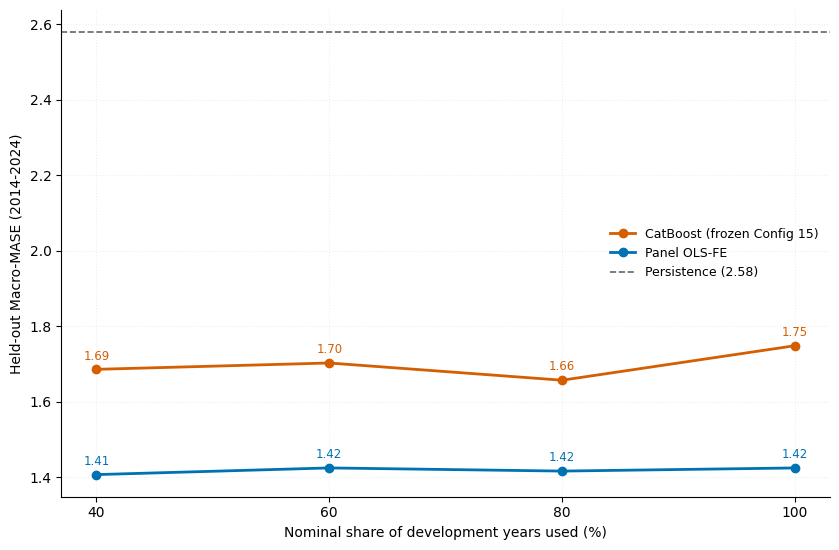

CELL 35 — STAGE-A TEMPORAL LEARNING CURVE

Tables folder : /content/study_final_confirmatory_outputs/tables_article_supplement
Figures folder: /content/study_final_confirmatory_outputs/figures_article_supplement
Model fits    : 8 (4 sizes × 2 methods)
Held-out      : 2014-2024, unchanged
Denominators  : fixed development-period scale, unchanged

TRAINING WINDOWS


,Nominal_Training_Percent,Train_Start,Train_End,N_Years,N_Rows,Actual_Row_Percent,Countries
0,40,1997,2013,17,136,39.65,8
1,60,1988,2013,26,208,60.64,8
2,80,1980,2013,34,272,79.30,8
3,100,1971,2013,43,343,100.00,8



LEARNING-CURVE RESULTS


,Nominal_Training_Percent,Train_Start,Train_End,N_Training_Rows,Method,Macro_MASE,RMSE,MAPE_Percent,Within_Country_R2
0,40,1997,2013,136,CatBoost (frozen Config 15),1.6857,0.1542,3.9370,0.6671
1,40,1997,2013,136,Panel OLS-FE,1.4066,0.1237,3.2389,0.7860
2,60,1988,2013,208,CatBoost (frozen Config 15),1.7025,0.1528,3.9138,0.6734
3,60,1988,2013,208,Panel OLS-FE,1.4243,0.1284,3.2657,0.7693
4,80,1980,2013,272,CatBoost (frozen Config 15),1.6568,0.1532,3.8562,0.6716
5,80,1980,2013,272,Panel OLS-FE,1.4159,0.1211,3.2647,0.7946
6,100,1971,2013,343,CatBoost (frozen Config 15),1.7484,0.1465,4.0071,0.6996
7,100,1971,2013,343,Panel OLS-FE,1.4242,0.1215,3.2840,0.7934



CATBOOST–OLS GAP


Method,Nominal_Training_Percent,Actual_Row_Percent,Train_Start,Train_End,N_Years,N_Training_Rows,CatBoost (frozen Config 15),Panel OLS-FE,CatBoost_minus_Panel_OLS_FE_Macro_MASE,Absolute_Macro_MASE_Gap
0,40,39.6501,1997,2013,17,136,1.6857,1.4066,0.2791,0.2791
1,60,60.6414,1988,2013,26,208,1.7025,1.4243,0.2782,0.2782
2,80,79.3003,1980,2013,34,272,1.6568,1.4159,0.2409,0.2409
3,100,100.0000,1971,2013,43,343,1.7484,1.4242,0.3242,0.3242



GAP SUMMARY
  Absolute gap at 40%  : 0.2791
  Absolute gap at 100% : 0.3242
  Change (100% - 40%)  : +0.0451
  Endpoint comparison  : gap is wider at 100%

INTERPRETATION GUARD
  The curve is a fixed-specification diagnostic, not a new model-selection exercise.
  Non-monotonic points must be reported as observed; four points do not establish a causal sample-size law.

INTEGRITY
  ✓ All four training windows end in 2013.
  ✓ No held-out observation used for fitting or selection.
  ✓ Frozen CatBoost Config 15 reused at every size.
  ✓ Panel OLS-FE specification unchanged at every size.
  ✓ Temperature baseline recomputed inside each window.
  ✓ Held-out years and MASE denominators fixed across sizes.
  ✓ 100% results reproduce the original Cell 13 results.
  ✓ Frozen Stage-A identity and original results unchanged.
  ✓ Figure saved as 300-dpi PNG and vector PDF.

OUTPUTS: training-window register | learning-curve table | gap diagnostic | prediction audit | temperature audit | PNG/PDF fi

In [36]:
# ============================================================
# CELL 35 — STAGE-A TEMPORAL LEARNING CURVE
# ============================================================
# Fixed-specification diagnostic, not a model-selection exercise.
# Use four nested temporal windows, each ending in 2013.
# Refit frozen CatBoost Config 15 and same-information Panel OLS-FE.
# Recompute temperature baselines within each training window.
# Keep the held-out sample and development MASE denominators fixed.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. CHECK INPUTS AND SNAPSHOT THE FROZEN SPECIFICATION
# ------------------------------------------------------------
required_objects = [
    "stage_a_full_train", "stage_a_holdout", "stage_a_holdout_results",
    "PRIMARY_FEATURES", "TARGET", "DEVELOPMENT_DENOMINATORS",
    "build_model", "build_scored_frame", "build_fe_matrix", "evaluation_metrics",
    "within_country_r2", "compute_temperature_baseline", "attach_temperature_anomaly",
    "STAGE_A_WINNER", "FROZEN_STAGE_A_WINNER", "FROZEN_STAGE_A_CONFIG_ID",
    "FROZEN_STAGE_A_PARAMS", "TRAIN_START", "TRAIN_END", "TEST_START", "TEST_END",
    "TABLES_DIR", "FIGURES_DIR",
]
missing_objects = [name for name in required_objects if name not in globals()]
assert not missing_objects, f"Missing objects: {missing_objects}"
assert STAGE_A_WINNER == FROZEN_STAGE_A_WINNER
assert FROZEN_STAGE_A_WINNER == "CatBoost"
assert int(FROZEN_STAGE_A_CONFIG_ID) == 15
assert len(PRIMARY_FEATURES) == 9
assert "temperature_anomaly" in PRIMARY_FEATURES

frozen_stage_a_snapshot = (
    FROZEN_STAGE_A_WINNER, int(FROZEN_STAGE_A_CONFIG_ID), FROZEN_STAGE_A_PARAMS.copy()
)
stage_a_results_checksum = int(
    pd.util.hash_pandas_object(stage_a_holdout_results, index=True).sum()
)
learning_tables_dir = Path(TABLES_DIR).parent / "tables_article_supplement"
learning_figures_dir = Path(FIGURES_DIR).parent / "figures_article_supplement"
learning_tables_dir.mkdir(parents=True, exist_ok=True)
learning_figures_dir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. DEFINE FOUR NESTED WINDOWS, ALL ENDING IN 2013
# ------------------------------------------------------------
LEARNING_FRACTIONS = [0.40, 0.60, 0.80, 1.00]
development_years = np.array(
    sorted(stage_a_full_train["year"].unique()), dtype=int
)
assert development_years[0] == TRAIN_START
assert development_years[-1] == TRAIN_END
assert np.array_equal(development_years, np.arange(TRAIN_START, TRAIN_END + 1))
n_development_years = len(development_years)
assert n_development_years == 43

window_rows = []
for fraction in LEARNING_FRACTIONS:
    n_years = int(round(fraction * n_development_years))
    n_years = max(1, min(n_years, n_development_years))
    start_year = int(TRAIN_END - n_years + 1)
    training_window = stage_a_full_train.loc[
        stage_a_full_train["year"].between(start_year, TRAIN_END)
    ].copy()
    assert int(training_window["year"].min()) == start_year
    assert int(training_window["year"].max()) == TRAIN_END
    assert training_window["country"].nunique() == 8

    window_rows.append({
        "Nominal_Training_Percent": int(round(fraction * 100)),
        "Train_Start": start_year,
        "Train_End": int(TRAIN_END),
        "N_Years": n_years,
        "N_Rows": int(len(training_window)),
        "Actual_Row_Percent": 100.0 * len(training_window) / len(stage_a_full_train),
        "Countries": int(training_window["country"].nunique()),
    })

learning_curve_windows = pd.DataFrame(window_rows)
assert learning_curve_windows["Nominal_Training_Percent"].tolist() == [40, 60, 80, 100]
assert learning_curve_windows["N_Rows"].is_monotonic_increasing
assert learning_curve_windows["N_Years"].is_monotonic_increasing
assert learning_curve_windows["Train_End"].eq(TRAIN_END).all()
assert learning_curve_windows.iloc[-1]["N_Rows"] == len(stage_a_full_train)


# ------------------------------------------------------------
# 3. REFIT BOTH FROZEN SPECIFICATIONS AT EACH SIZE
# ------------------------------------------------------------
curve_result_rows = []
curve_prediction_frames = []
curve_temperature_audits = []
curve_fit_count = 0

for window_info in learning_curve_windows.itertuples(index=False):
    nominal_percent = int(window_info.Nominal_Training_Percent)
    train_start = int(window_info.Train_Start)
    train_raw = (
        stage_a_full_train.loc[
            stage_a_full_train["year"].between(train_start, TRAIN_END)
        ]
        .sort_values(["country", "year"])
        .reset_index(drop=True)
        .copy()
    )
    heldout_raw = stage_a_holdout.reset_index(drop=True).copy()

    # This window's baseline is used for both training and held-out predictors.
    temperature_baseline, temperature_audit = compute_temperature_baseline(
        training_frame=train_raw, cutoff_year=TRAIN_END
    )
    train_window = attach_temperature_anomaly(train_raw, temperature_baseline)
    heldout_window = attach_temperature_anomaly(heldout_raw, temperature_baseline)
    temperature_audit.insert(0, "Nominal_Training_Percent", nominal_percent)
    curve_temperature_audits.append(temperature_audit)

    assert len(train_window) == int(window_info.N_Rows)
    assert len(heldout_window) == 88
    assert train_window["country"].nunique() == 8
    assert heldout_window["country"].nunique() == 8
    assert int(train_window["year"].min()) == train_start
    assert int(train_window["year"].max()) == TRAIN_END
    assert int(heldout_window["year"].min()) == TEST_START
    assert int(heldout_window["year"].max()) == TEST_END

    x_train = train_window[PRIMARY_FEATURES].astype(float).copy()
    y_train = train_window[TARGET].astype(float).copy()
    x_heldout = heldout_window[PRIMARY_FEATURES].astype(float).copy()
    assert np.isfinite(x_train.to_numpy()).all()
    assert np.isfinite(y_train.to_numpy()).all()
    assert np.isfinite(x_heldout.to_numpy()).all()

    # Frozen CatBoost Config 15: same parameters at every training size.
    curve_catboost = build_model(FROZEN_STAGE_A_WINNER, FROZEN_STAGE_A_PARAMS.copy())
    curve_catboost.fit(x_train, y_train)
    curve_fit_count += 1
    catboost_pred_delta = np.asarray(curve_catboost.predict(x_heldout), dtype=float)
    catboost_scored = build_scored_frame(catboost_pred_delta)
    catboost_metrics = evaluation_metrics(
        frame=catboost_scored, denominators=DEVELOPMENT_DENOMINATORS,
        actual_col="actual_co2", pred_col="pred_co2",
    )
    catboost_within_r2 = float(within_country_r2(catboost_scored))

    # Panel OLS-FE: same predictors plus country effects, without re-selection.
    x_fe_train = build_fe_matrix(train_window)
    x_fe_heldout = build_fe_matrix(heldout_window)
    assert list(x_fe_train.columns) == list(x_fe_heldout.columns)
    fe_coefficients, _, _, _ = np.linalg.lstsq(
        x_fe_train.to_numpy(dtype=float), y_train.to_numpy(dtype=float), rcond=None
    )
    curve_fit_count += 1
    fe_pred_delta = np.asarray(
        x_fe_heldout.to_numpy(dtype=float) @ fe_coefficients, dtype=float
    )
    fe_scored = build_scored_frame(fe_pred_delta)
    fe_metrics = evaluation_metrics(
        frame=fe_scored, denominators=DEVELOPMENT_DENOMINATORS,
        actual_col="actual_co2", pred_col="pred_co2",
    )
    fe_within_r2 = float(within_country_r2(fe_scored))

    # Store each method's metrics and its full 88-row prediction audit.
    for method, metrics, within_r2, scored in [
        (f"{FROZEN_STAGE_A_WINNER} (frozen Config 15)",
         catboost_metrics, catboost_within_r2, catboost_scored),
        ("Panel OLS-FE", fe_metrics, fe_within_r2, fe_scored),
    ]:
        curve_result_rows.append({
            "Nominal_Training_Percent": nominal_percent,
            "Actual_Row_Percent": float(window_info.Actual_Row_Percent),
            "Train_Start": train_start,
            "Train_End": int(TRAIN_END),
            "N_Years": int(window_info.N_Years),
            "N_Training_Rows": int(window_info.N_Rows),
            "Method": method,
            "Macro_MASE": float(metrics["Macro_MASE"]),
            "Median_Country_MASE": float(metrics["Median_Country_MASE"]),
            "Worst_Country_MASE": float(metrics["Worst_Country_MASE"]),
            "RMSE": float(metrics["RMSE"]),
            "MAE": float(metrics["MAE"]),
            "MAPE_Percent": float(metrics["MAPE_Percent"]),
            "Within_Country_R2": within_r2,
            "N_Heldout": int(metrics["N"]),
        })
        prediction_output = scored.copy()
        prediction_output.insert(0, "Method", method)
        prediction_output.insert(0, "Nominal_Training_Percent", nominal_percent)
        prediction_output.insert(1, "Train_Start", train_start)
        prediction_output.insert(2, "Train_End", int(TRAIN_END))
        curve_prediction_frames.append(prediction_output)

learning_curve_results = (
    pd.DataFrame(curve_result_rows)
    .sort_values(["Nominal_Training_Percent", "Method"])
    .reset_index(drop=True)
)
learning_curve_predictions = (
    pd.concat(curve_prediction_frames, ignore_index=True)
    .sort_values(["Nominal_Training_Percent", "Method", "country", "year"])
    .reset_index(drop=True)
)
learning_curve_temperature_audit = (
    pd.concat(curve_temperature_audits, ignore_index=True)
    .sort_values(["Nominal_Training_Percent", "country"])
    .reset_index(drop=True)
)
assert curve_fit_count == 8
assert learning_curve_results.shape[0] == 8
assert learning_curve_predictions.shape[0] == 704
assert learning_curve_temperature_audit.shape[0] == 32
assert learning_curve_results["N_Heldout"].eq(88).all()
assert not learning_curve_predictions.duplicated(
    ["Nominal_Training_Percent", "Method", "country", "year"]
).any()


# ------------------------------------------------------------
# 4. COMPUTE GAPS AND REQUIRE 100% REPRODUCTION OF CELL 13
# ------------------------------------------------------------
catboost_label = f"{FROZEN_STAGE_A_WINNER} (frozen Config 15)"
learning_curve_wide = learning_curve_results.pivot(
    index=[
        "Nominal_Training_Percent", "Actual_Row_Percent", "Train_Start",
        "Train_End", "N_Years", "N_Training_Rows",
    ],
    columns="Method", values="Macro_MASE",
).reset_index()
learning_curve_wide["CatBoost_minus_Panel_OLS_FE_Macro_MASE"] = (
    learning_curve_wide[catboost_label] - learning_curve_wide["Panel OLS-FE"]
)
learning_curve_wide["Absolute_Macro_MASE_Gap"] = (
    learning_curve_wide["CatBoost_minus_Panel_OLS_FE_Macro_MASE"].abs()
)
learning_curve_wide = learning_curve_wide.sort_values(
    "Nominal_Training_Percent"
).reset_index(drop=True)

original_catboost_mase = float(stage_a_holdout_results.loc[
    stage_a_holdout_results["Method"] == FROZEN_STAGE_A_WINNER, "Macro_MASE"
].iloc[0])
original_fe_mase = float(stage_a_holdout_results.loc[
    stage_a_holdout_results["Method"] == "Panel OLS-FE", "Macro_MASE"
].iloc[0])
curve_100 = learning_curve_wide.loc[
    learning_curve_wide["Nominal_Training_Percent"] == 100
].iloc[0]
assert np.isclose(
    float(curve_100[catboost_label]), original_catboost_mase, atol=1e-6, rtol=1e-6
), "100% CatBoost result does not reproduce Cell 13."
assert np.isclose(
    float(curve_100["Panel OLS-FE"]), original_fe_mase, atol=1e-10, rtol=1e-10
), "100% Panel OLS-FE result does not reproduce Cell 13."

gap_40 = float(learning_curve_wide.loc[
    learning_curve_wide["Nominal_Training_Percent"] == 40, "Absolute_Macro_MASE_Gap"
].iloc[0])
gap_100 = float(learning_curve_wide.loc[
    learning_curve_wide["Nominal_Training_Percent"] == 100, "Absolute_Macro_MASE_Gap"
].iloc[0])
gap_change = gap_100 - gap_40
if gap_100 < gap_40:
    gap_direction = "narrower"
elif gap_100 > gap_40:
    gap_direction = "wider"
else:
    gap_direction = "unchanged"


# ------------------------------------------------------------
# 5. PLOT THE ORIGINAL LEARNING CURVE AND SAVE PNG/PDF
# ------------------------------------------------------------
FIGURE_COLORS = {catboost_label: "#D55E00", "Panel OLS-FE": "#0072B2"}
fig, ax = plt.subplots(figsize=(8.5, 5.6))
for method in [catboost_label, "Panel OLS-FE"]:
    plot_data = learning_curve_results.loc[
        learning_curve_results["Method"] == method
    ].sort_values("Nominal_Training_Percent")
    ax.plot(
        plot_data["Nominal_Training_Percent"], plot_data["Macro_MASE"],
        marker="o", markersize=6, linewidth=2,
        color=FIGURE_COLORS[method], label=method,
    )
    for row in plot_data.itertuples(index=False):
        ax.annotate(
            f"{row.Macro_MASE:.2f}", (row.Nominal_Training_Percent, row.Macro_MASE),
            textcoords="offset points", xytext=(0, 7), ha="center",
            fontsize=8.5, color=FIGURE_COLORS[method],
        )

persistence_mase = float(stage_a_holdout_results.loc[
    stage_a_holdout_results["Method"] == "Persistence", "Macro_MASE"
].iloc[0])
ax.axhline(
    persistence_mase, color="#666666", linestyle="--", linewidth=1.2,
    label=f"Persistence ({persistence_mase:.2f})",
)
ax.set_xlabel("Nominal share of development years used (%)")
ax.set_ylabel("Held-out Macro-MASE (2014-2024)")
ax.set_xticks([40, 60, 80, 100])
ax.grid(axis="both", alpha=0.20, linestyle=":")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()

learning_curve_png = learning_figures_dir / "fig_stage_a_learning_curve.png"
learning_curve_pdf = learning_figures_dir / "fig_stage_a_learning_curve.pdf"
fig.savefig(learning_curve_png, dpi=300, bbox_inches="tight")
fig.savefig(learning_curve_pdf, bbox_inches="tight")
plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 6. SAVE FIVE ORIGINAL CSV FILES AT FULL PRECISION
# ------------------------------------------------------------
learning_curve_windows.to_csv(
    learning_tables_dir / "learning_curve_training_windows.csv", index=False
)
learning_curve_results.to_csv(
    learning_tables_dir / "learning_curve_stage_a_results.csv", index=False
)
learning_curve_wide.to_csv(
    learning_tables_dir / "learning_curve_stage_a_gap.csv", index=False
)
learning_curve_predictions.to_csv(
    learning_tables_dir / "learning_curve_stage_a_predictions.csv", index=False
)
learning_curve_temperature_audit.to_csv(
    learning_tables_dir / "learning_curve_temperature_baselines.csv", index=False
)


# ------------------------------------------------------------
# 7. VERIFY UNCHANGED INPUTS AND PRINT THE ORIGINAL REPORT
# ------------------------------------------------------------
assert (
    STAGE_A_WINNER, int(FROZEN_STAGE_A_CONFIG_ID), FROZEN_STAGE_A_PARAMS
) == frozen_stage_a_snapshot
assert int(pd.util.hash_pandas_object(stage_a_holdout_results, index=True).sum()) == (
    stage_a_results_checksum
)
assert learning_curve_temperature_audit["Last_Year_Used"].le(TRAIN_END).all()

print("=" * 78)
print("CELL 35 — STAGE-A TEMPORAL LEARNING CURVE")
print("=" * 78)
print(f"\nTables folder : {learning_tables_dir}")
print(f"Figures folder: {learning_figures_dir}")
print(f"Model fits    : {curve_fit_count} (4 sizes × 2 methods)")
print(f"Held-out      : {TEST_START}-{TEST_END}, unchanged")
print("Denominators  : fixed development-period scale, unchanged")
with pd.option_context("display.max_columns", None):
    print("\nTRAINING WINDOWS")
    display(learning_curve_windows.round(2))
    print("\nLEARNING-CURVE RESULTS")
    display(learning_curve_results[[
        "Nominal_Training_Percent", "Train_Start", "Train_End", "N_Training_Rows",
        "Method", "Macro_MASE", "RMSE", "MAPE_Percent", "Within_Country_R2",
    ]].round(4))
    print("\nCATBOOST–OLS GAP")
    display(learning_curve_wide.round(4))

print("\nGAP SUMMARY")
print(f"  Absolute gap at 40%  : {gap_40:.4f}")
print(f"  Absolute gap at 100% : {gap_100:.4f}")
print(f"  Change (100% - 40%)  : {gap_change:+.4f}")
print(f"  Endpoint comparison  : gap is {gap_direction} at 100%")
print("\nINTERPRETATION GUARD")
print(
    "  The curve is a fixed-specification diagnostic, not a new "
    "model-selection exercise."
)
print(
    "  Non-monotonic points must be reported as observed; four "
    "points do not establish a causal sample-size law."
)
print("\nINTEGRITY")
for line in [
    "All four training windows end in 2013.",
    "No held-out observation used for fitting or selection.",
    "Frozen CatBoost Config 15 reused at every size.",
    "Panel OLS-FE specification unchanged at every size.",
    "Temperature baseline recomputed inside each window.",
    "Held-out years and MASE denominators fixed across sizes.",
    "100% results reproduce the original Cell 13 results.",
    "Frozen Stage-A identity and original results unchanged.",
    "Figure saved as 300-dpi PNG and vector PDF.",
]:
    print(f"  ✓ {line}")
print(
    "\nOUTPUTS: training-window register | learning-curve table | "
    "gap diagnostic | prediction audit | temperature audit | PNG/PDF figure"
)


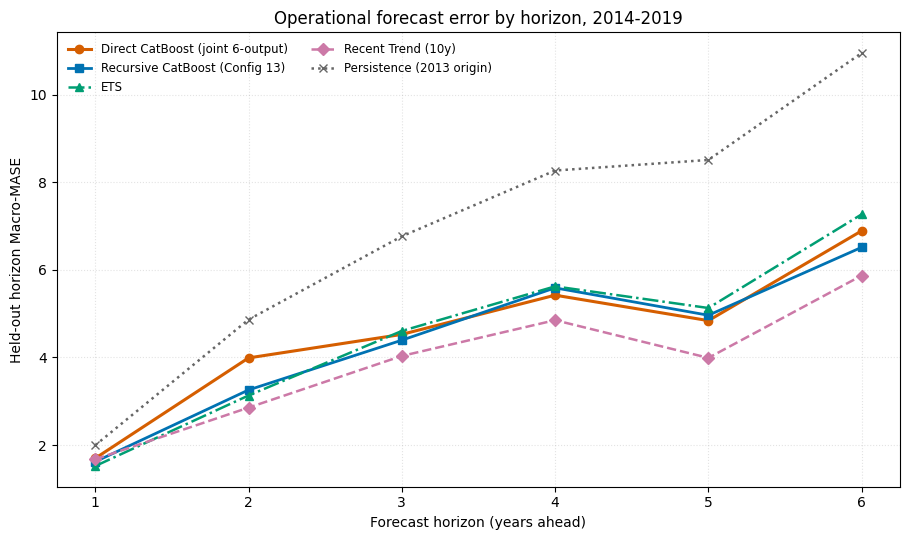

CELL 36 — DIRECT MULTI-HORIZON OPERATIONAL FORECASTS

Tables folder : /content/study_final_confirmatory_outputs/tables_article_supplement
Figures folder: /content/study_final_confirmatory_outputs/figures_article_supplement
Direct fits   : 35
Horizons      : h = 1, ..., 6
Outer origins : 1989, 1995, 2001, 2007
Held-out      : 2014-2019 matched six-year window
Future inputs : no observed future drivers or CO2 lags

DIRECT TRAINING AUDIT


,Fold,Method,Origin_Year,Horizon,Training_Target_End_Max,N_Training_Rows,Countries,Fits
0,1,Direct CatBoost (separate h=1..6),1989,1,1989,143,8,1
1,1,Direct CatBoost (separate h=1..6),1989,2,1989,135,8,1
2,1,Direct CatBoost (separate h=1..6),1989,3,1989,127,8,1
3,1,Direct CatBoost (separate h=1..6),1989,4,1989,119,8,1
4,1,Direct CatBoost (separate h=1..6),1989,5,1989,111,8,1
5,1,Direct CatBoost (separate h=1..6),1989,6,1989,103,8,1
6,1,Direct CatBoost (joint 6-output),1989,1-6 jointly,1989,103,8,1
7,2,Direct CatBoost (separate h=1..6),1995,1,1995,191,8,1
8,2,Direct CatBoost (separate h=1..6),1995,2,1995,183,8,1
9,2,Direct CatBoost (separate h=1..6),1995,3,1995,175,8,1



PRE-2014 OUTER-CV SUMMARY


,Method,Mean_CV_Macro_MASE,SD_CV_Macro_MASE,Mean_RMSE,Mean_MAE,Mean_MAPE_Percent,Mean_Within_Country_R2,Folds
0,Direct CatBoost (joint 6-output),2.6943,0.9645,0.3198,0.1759,9.7561,-3.1818,4
1,Direct CatBoost (separate h=1..6),2.7125,0.9553,0.3377,0.1827,9.8775,-4.1331,4
2,Recursive CatBoost (Config 13),3.1247,0.7900,0.3607,0.1989,11.0375,-4.2765,4



DIRECT STRATEGY LOCK


...


HELD-OUT ERROR BY HORIZON


Method,Direct CatBoost (joint 6-output),Direct CatBoost (separate h=1..6),ETS,Persistence (2013 origin),Recent Trend (10y),Recursive CatBoost (Config 13)
Horizon,,,,,,
1,1.6987,1.6725,1.5215,1.9965,1.6766,1.6201
2,3.9900,3.8200,3.1322,4.8645,2.8554,3.2585
3,4.5269,4.4405,4.6053,6.7657,4.0348,4.3948
4,5.4224,5.3141,5.6233,8.2676,4.8517,5.5892
5,4.8415,4.7230,5.1294,8.5092,3.9909,4.9642
6,6.8911,6.9460,7.2677,10.9507,5.8701,6.5146



DIRECT VS RECURSIVE


,Selected_Direct_Method,Selected_Direct_Heldout_Macro_MASE,Recursive_Heldout_Macro_MASE,Direct_minus_Recursive_Macro_MASE,Direct_Improvement_vs_Recursive_Percent,Conclusion,Caution
0,Direct CatBoost (joint 6-output),4.5618,4.3902,0.1715,-3.9069,The development-selected direct strategy does not improve on the recursive pipeline over the matched six-y...,"This is a predictive strategy contrast, not a causal estimate of recursive feedback. The direct mapping us..."



HEADLINE
  Selected before held-out : Direct CatBoost (joint 6-output)
  Direct Macro-MASE        : 4.5618
  Recursive Macro-MASE     : 4.3902
  Direct minus recursive  : +0.1715
  Improvement percentage  : -3.91%
  Conclusion              : The development-selected direct strategy does not improve on the recursive pipeline over the matched six-year held-out window.

INTERPRETATION GUARD
  This comparison tests a forecasting remedy. It does not identify a causal effect of recursive feedback.
  Both direct variants are reported; only their pre-2014 outer-CV results determine which one is highlighted.
  Held-out 2014-2019 results must be reported whether they favour the direct or recursive strategy.

INTEGRITY
  ✓ Same four Stage-B origins and six forecast horizons used.
  ✓ All direct training targets end on or before each origin.
  ✓ Frozen CatBoost Config 13 hyperparameters reused.
  ✓ Joint model uses native CatBoost MultiRMSE six-output loss.
  ✓ No observed future driver or future

In [37]:

# CELL 36 — DIRECT MULTI-HORIZON OPERATIONAL FORECASTS
# ============================================================
# Reuse frozen CatBoost Config 13; do not retune or change earlier models.
# Separate: fit one model per horizon. Joint: fit one six-output model.
# Both use origin-year predictors and cumulative log-change targets.
# Select the direct variant on pre-2014 CV, then evaluate 2014-2019.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. CHECK INPUTS AND SNAPSHOT THE FROZEN SPECIFICATION
# ------------------------------------------------------------
required_objects = [
    'df', 'stage_a_full_train', 'PRIMARY_FEATURES', 'TARGET', 'build_model',
    'STAGE_B_HORIZON', 'N_STAGE_B_FOLDS', 'stage_b_folds',
    'STAGE_B_FOLD_DATA', 'STAGE_B_DENOMINATORS',
    'STAGE_B_WINNER_CV_PREDICTIONS', 'stage_b_winner_fold_results',
    'STAGE_B_WINNER_CV_MASE', 'FROZEN_STAGE_B_WINNER',
    'FROZEN_STAGE_B_CONFIG_ID', 'FROZEN_STAGE_B_PARAMS',
    'stage_b_holdout_predictions', 'stage_b_persistence_predictions',
    'stage_b_holdout_results', 'operational_predictions',
    'recent_trend_holdout_predictions', 'DEVELOPMENT_DENOMINATORS',
    'TRAIN_END', 'TEST_START', 'TABLES_DIR', 'FIGURES_DIR',
]
missing_objects = [name for name in required_objects if name not in globals()]
assert not missing_objects, f'Missing objects: {missing_objects}'
assert int(STAGE_B_HORIZON) == 6
assert int(N_STAGE_B_FOLDS) == 4
assert FROZEN_STAGE_B_WINNER == 'CatBoost'
assert int(FROZEN_STAGE_B_CONFIG_ID) == 13
assert int(TRAIN_END) == 2013
assert int(TEST_START) == 2014
assert len(PRIMARY_FEATURES) == 9
assert 'co2_lag1' in PRIMARY_FEATURES
DIRECT_HORIZONS = list(range(1, STAGE_B_HORIZON + 1))
DIRECT_MATCHED_END = TEST_START + STAGE_B_HORIZON - 1
assert DIRECT_HORIZONS == [1, 2, 3, 4, 5, 6]
assert DIRECT_MATCHED_END == 2019
frozen_stage_b_snapshot = (
    FROZEN_STAGE_B_WINNER,
    int(FROZEN_STAGE_B_CONFIG_ID),
    FROZEN_STAGE_B_PARAMS.copy(),
)
stage_b_fold_checksum = int(
    pd.util.hash_pandas_object(stage_b_winner_fold_results, index=True).sum()
)
stage_b_holdout_checksum = int(
    pd.util.hash_pandas_object(stage_b_holdout_results, index=True).sum()
)
direct_tables_dir = Path(TABLES_DIR).parent / 'tables_article_supplement'
direct_figures_dir = Path(FIGURES_DIR).parent / 'figures_article_supplement'
direct_tables_dir.mkdir(parents=True, exist_ok=True)
direct_figures_dir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. BUILD ORIGIN-YEAR FEATURES AND CUMULATIVE TARGETS
# ------------------------------------------------------------
# Observed CO2 at the origin replaces the usual lag; other features stay fixed.
DIRECT_NON_CO2_FEATURES = [
    feature for feature in PRIMARY_FEATURES if feature != 'co2_lag1'
]
DIRECT_FEATURES = DIRECT_NON_CO2_FEATURES + ['Origin_CO2']
assert len(DIRECT_NON_CO2_FEATURES) == 8
assert len(DIRECT_FEATURES) == 9
SEPARATE_DIRECT_LABEL = 'Direct CatBoost (separate h=1..6)'
JOINT_DIRECT_LABEL = 'Direct CatBoost (joint 6-output)'
RECURSIVE_LABEL = f'Recursive CatBoost (Config {int(FROZEN_STAGE_B_CONFIG_ID)})'
PERSISTENCE_LABEL = 'Persistence (2013 origin)'


def direct_origin_frame(training_frame, origin_year=None):
    """Return origin-year predictors with observed CO2 at t."""
    out = training_frame[
        ['country', 'year', 'co2_per_capita'] + DIRECT_NON_CO2_FEATURES
    ].copy()
    out = out.rename(columns={'co2_per_capita': 'Origin_CO2'})
    if origin_year is not None:
        out = out.loc[out['year'].eq(int(origin_year))].copy()
    out = out.sort_values(['country', 'year']).reset_index(drop=True)
    assert not out[DIRECT_FEATURES].isna().any().any()
    assert np.isfinite(out[DIRECT_FEATURES].to_numpy()).all()
    assert (out['Origin_CO2'] > 0).all()
    return out


def build_direct_target_pairs(training_frame, cutoff_year, horizon):
    """Build leakage-safe origin/target pairs for one horizon."""
    horizon = int(horizon)
    cutoff_year = int(cutoff_year)
    assert horizon in DIRECT_HORIZONS
    origins = direct_origin_frame(training_frame)
    future = df.loc[
        df['year'].le(cutoff_year),
        ['country', 'year', 'co2_per_capita'],
    ].copy().rename(columns={'co2_per_capita': 'Future_CO2'})
    # Align the future CO2 observation with its origin-year predictors.
    future['year'] = future['year'].astype(int) - horizon
    pairs = origins.merge(
        future,
        on=['country', 'year'],
        how='inner',
        validate='one_to_one',
    ).sort_values(['country', 'year']).reset_index(drop=True)
    pairs['Target_Year'] = pairs['year'].astype(int) + horizon
    assert pairs['Target_Year'].le(cutoff_year).all()
    assert (pairs['Future_CO2'] > 0).all()
    pairs['Cumulative_Log_Change'] = np.log(pairs['Future_CO2'] / pairs['Origin_CO2'])
    assert np.isfinite(pairs['Cumulative_Log_Change'].to_numpy()).all()
    assert pairs['country'].nunique() == 8
    return pairs


def build_joint_direct_pairs(training_frame, cutoff_year):
    """Build rows having all six cumulative-change targets."""
    cutoff_year = int(cutoff_year)
    joint = direct_origin_frame(training_frame)
    for horizon in DIRECT_HORIZONS:
        future = df.loc[
            df['year'].le(cutoff_year),
            ['country', 'year', 'co2_per_capita'],
        ].copy().rename(columns={'co2_per_capita': f'Future_CO2_h{horizon}'})
        future['year'] = future['year'].astype(int) - horizon
        joint = joint.merge(
            future,
            on=['country', 'year'],
            how='inner',
            validate='one_to_one',
        )
        joint[f'Target_h{horizon}'] = np.log(
            joint[f'Future_CO2_h{horizon}'] / joint['Origin_CO2']
        )
    target_columns = [f'Target_h{horizon}' for horizon in DIRECT_HORIZONS]
    joint = joint.sort_values(['country', 'year']).reset_index(drop=True)
    assert (joint['year'].astype(int) + STAGE_B_HORIZON).le(cutoff_year).all()
    assert joint['country'].nunique() == 8
    assert np.isfinite(joint[DIRECT_FEATURES].to_numpy()).all()
    assert np.isfinite(joint[target_columns].to_numpy()).all()
    return (joint, target_columns)



# ------------------------------------------------------------
# 3. READ MASE DENOMINATORS AND SCORE LEVEL PREDICTIONS
# ------------------------------------------------------------

def denominator_value(obj, country):
    """Read a country MASE denominator from dict/Series/DataFrame."""
    if isinstance(obj, dict):
        value = obj[country]
    elif isinstance(obj, pd.Series):
        value = obj.loc[country]
    elif isinstance(obj, pd.DataFrame):
        if {'country', 'MASE_Denominator'}.issubset(obj.columns):
            value = obj.loc[obj['country'].eq(country), 'MASE_Denominator'].iloc[0]
        else:
            value = obj.loc[country, 'MASE_Denominator']
    else:
        raise TypeError('Unsupported MASE denominator object')
    value = float(value)
    assert np.isfinite(value) and value > 0
    return value


def score_level_predictions(predictions, denominator_getter):
    """Score one balanced country-year prediction panel."""
    scored = predictions.copy()
    required = {'country', 'year', 'Actual_CO2', 'Predicted_CO2'}
    assert required.issubset(scored.columns)
    assert not scored[list(required)].isna().any().any()
    assert np.isfinite(scored[['Actual_CO2', 'Predicted_CO2']].to_numpy()).all()
    error = (scored['Predicted_CO2'] - scored['Actual_CO2']).to_numpy(dtype=float)
    country_mase = []
    for country, sub in scored.groupby('country'):
        mae_country = float(np.mean(np.abs(sub['Predicted_CO2'] - sub['Actual_CO2'])))
        country_mase.append(mae_country / float(denominator_getter(country)))
    actual = scored['Actual_CO2'].to_numpy(dtype=float)
    ss_res = float(np.sum(np.square(error)))
    ss_tot_pooled = float(np.sum(np.square(actual - np.mean(actual))))
    country_means = (
        scored.groupby('country')['Actual_CO2']
        .transform('mean')
        .to_numpy(dtype=float)
    )
    ss_tot_within = float(np.sum(np.square(actual - country_means)))
    return {
        'Macro_MASE': float(np.mean(country_mase)),
        'RMSE': float(np.sqrt(np.mean(np.square(error)))),
        'MAE': float(np.mean(np.abs(error))),
        'MAPE_Percent': float(np.mean(np.abs(error / actual)) * 100),
        'Pooled_R2': float(1 - ss_res / ss_tot_pooled),
        'Within_Country_R2': float(1 - ss_res / ss_tot_within),
        'N': int(len(scored)),
    }


def attach_truth(predictions, truth_frame):
    """Merge a prediction frame with unique country-year truth."""
    truth = (
        truth_frame[['country', 'year', 'co2_per_capita']]
        .rename(columns={'co2_per_capita': 'Actual_CO2'})
        .copy()
    )
    out = predictions.merge(
        truth,
        on=['country', 'year'],
        how='inner',
        validate='one_to_one',
    ).sort_values(['country', 'year']).reset_index(drop=True)
    assert len(out) == len(predictions)
    return out



# ------------------------------------------------------------
# 4. FIT SEPARATE-HORIZON AND JOINT DIRECT MODELS
# ------------------------------------------------------------

def predict_separate_direct(training_frame, cutoff_year, origin_year):
    """Fit six horizon-specific CatBoost models and predict one origin."""
    origin = direct_origin_frame(training_frame, origin_year)
    assert len(origin) == 8
    countries = origin['country'].tolist()
    origin_co2 = origin['Origin_CO2'].to_numpy(dtype=float)
    x_origin = origin[DIRECT_FEATURES].astype(float)
    records = []
    audits = []
    for horizon in DIRECT_HORIZONS:
        pairs = build_direct_target_pairs(
            training_frame=training_frame,
            cutoff_year=cutoff_year,
            horizon=horizon,
        )
        model = build_model(FROZEN_STAGE_B_WINNER, FROZEN_STAGE_B_PARAMS.copy())
        model.fit(
            pairs[DIRECT_FEATURES].astype(float),
            pairs['Cumulative_Log_Change'].astype(float),
        )
        predicted_change = np.asarray(model.predict(x_origin), dtype=float).reshape(-1)
        assert predicted_change.shape == (8,)
        assert np.isfinite(predicted_change).all()
        predicted_co2 = origin_co2 * np.exp(predicted_change)
        assert np.isfinite(predicted_co2).all()
        assert (predicted_co2 > 0).all()
        for country, origin_level, change, level in zip(
            countries,
            origin_co2,
            predicted_change,
            predicted_co2,
        ):
            records.append({
                'Method': SEPARATE_DIRECT_LABEL,
                'country': country,
                'Origin_Year': int(origin_year),
                'year': int(origin_year + horizon),
                'Horizon': int(horizon),
                'Origin_CO2': float(origin_level),
                'Predicted_Cumulative_Log_Change': float(change),
                'Predicted_CO2': float(level),
            })
        audits.append({
            'Method': SEPARATE_DIRECT_LABEL,
            'Origin_Year': int(origin_year),
            'Horizon': int(horizon),
            'Training_Target_End_Max': int(pairs['Target_Year'].max()),
            'N_Training_Rows': int(len(pairs)),
            'Countries': int(pairs['country'].nunique()),
            'Fits': 1,
        })
    predictions = pd.DataFrame(records)
    audit = pd.DataFrame(audits)
    assert len(predictions) == 8 * STAGE_B_HORIZON
    assert predictions[['country', 'year']].duplicated().sum() == 0
    assert audit['Training_Target_End_Max'].le(cutoff_year).all()
    return (predictions, audit)


def predict_joint_direct(training_frame, cutoff_year, origin_year):
    """Fit one native CatBoost six-output model and predict one origin."""
    origin = direct_origin_frame(training_frame, origin_year)
    assert len(origin) == 8
    pairs, target_columns = build_joint_direct_pairs(
        training_frame=training_frame,
        cutoff_year=cutoff_year,
    )
    joint_params = FROZEN_STAGE_B_PARAMS.copy()
    joint_params['loss_function'] = 'MultiRMSE'
    model = build_model(FROZEN_STAGE_B_WINNER, joint_params)
    model.fit(pairs[DIRECT_FEATURES].astype(float), pairs[target_columns].astype(float))
    predicted_change = np.asarray(
        model.predict(origin[DIRECT_FEATURES].astype(float)),
        dtype=float,
    )
    if predicted_change.ndim == 1:
        predicted_change = predicted_change.reshape(8, -1)
    assert predicted_change.shape == (8, STAGE_B_HORIZON)
    assert np.isfinite(predicted_change).all()
    countries = origin['country'].tolist()
    origin_co2 = origin['Origin_CO2'].to_numpy(dtype=float)
    records = []
    for row_index, country in enumerate(countries):
        for horizon in DIRECT_HORIZONS:
            change = float(predicted_change[row_index, horizon - 1])
            level = float(origin_co2[row_index] * np.exp(change))
            assert np.isfinite(level) and level > 0
            records.append({
                'Method': JOINT_DIRECT_LABEL,
                'country': country,
                'Origin_Year': int(origin_year),
                'year': int(origin_year + horizon),
                'Horizon': int(horizon),
                'Origin_CO2': float(origin_co2[row_index]),
                'Predicted_Cumulative_Log_Change': change,
                'Predicted_CO2': level,
            })
    predictions = pd.DataFrame(records)
    audit = pd.DataFrame([{
        'Method': JOINT_DIRECT_LABEL,
        'Origin_Year': int(origin_year),
        'Horizon': '1-6 jointly',
        'Training_Target_End_Max': int(pairs['year'].max() + STAGE_B_HORIZON),
        'N_Training_Rows': int(len(pairs)),
        'Countries': int(pairs['country'].nunique()),
        'Fits': 1,
    }])
    assert len(predictions) == 8 * STAGE_B_HORIZON
    assert predictions[['country', 'year']].duplicated().sum() == 0
    assert int(audit.iloc[0]['Training_Target_End_Max']) <= cutoff_year
    return (predictions, audit)


# ------------------------------------------------------------
# 5. EVALUATE THE FOUR PRE-2014 OUTER FOLDS
# ------------------------------------------------------------
cv_prediction_frames = []
training_audits = []
cv_fold_rows = []
direct_fit_count = 0
for fold_info in stage_b_folds.itertuples(index=False):
    fold = int(fold_info.Fold)
    origin_year = int(fold_info.Train_End)
    fold_train = STAGE_B_FOLD_DATA[fold]['train'].copy()
    fold_truth = STAGE_B_FOLD_DATA[fold]['truth'].copy()
    assert int(fold_train['year'].max()) == origin_year
    assert int(fold_truth['year'].min()) == origin_year + 1
    assert int(fold_truth['year'].max()) == origin_year + 6
    separate_predictions, separate_audit = predict_separate_direct(
        training_frame=fold_train,
        cutoff_year=origin_year,
        origin_year=origin_year,
    )
    joint_predictions, joint_audit = predict_joint_direct(
        training_frame=fold_train,
        cutoff_year=origin_year,
        origin_year=origin_year,
    )
    direct_fit_count += 7
    separate_audit.insert(0, 'Fold', fold)
    joint_audit.insert(0, 'Fold', fold)
    training_audits.extend([separate_audit, joint_audit])
    for predictions in [separate_predictions, joint_predictions]:
        scored = attach_truth(predictions, fold_truth)
        scored.insert(0, 'Fold', fold)
        scored['Evaluation_Set'] = 'Pre-2014 outer CV'
        cv_prediction_frames.append(scored)
        metrics = score_level_predictions(
            scored,
            denominator_getter=lambda country, fold=fold: (
                denominator_value(STAGE_B_DENOMINATORS[fold], country)
            ),
        )
        cv_fold_rows.append({
            'Method': str(scored['Method'].iloc[0]),
            'Fold': fold,
            'Origin_Year': origin_year,
            'Forecast_Start': origin_year + 1,
            'Forecast_End': origin_year + 6,
            **metrics,
        })
# Reuse the earlier recursive predictions without refitting that model.
recursive_cv_predictions = STAGE_B_WINNER_CV_PREDICTIONS.copy()
recursive_cv_predictions['Method'] = RECURSIVE_LABEL
recursive_cv_predictions['Evaluation_Set'] = 'Pre-2014 outer CV'
assert len(recursive_cv_predictions) == 4 * 8 * 6
assert {
    'Fold',
    'country',
    'year',
    'Horizon',
    'Actual_CO2',
    'Predicted_CO2',
}.issubset(recursive_cv_predictions.columns)
cv_prediction_frames.append(recursive_cv_predictions)
for fold_info in stage_b_folds.itertuples(index=False):
    fold = int(fold_info.Fold)
    scored = recursive_cv_predictions.loc[
        recursive_cv_predictions['Fold'].eq(fold)
    ].copy()
    metrics = score_level_predictions(
        scored,
        denominator_getter=lambda country, fold=fold: (
            denominator_value(STAGE_B_DENOMINATORS[fold], country)
        ),
    )
    cv_fold_rows.append({
        'Method': RECURSIVE_LABEL,
        'Fold': fold,
        'Origin_Year': int(fold_info.Train_End),
        'Forecast_Start': int(fold_info.Forecast_Start),
        'Forecast_End': int(fold_info.Forecast_End),
        **metrics,
    })
direct_cv_predictions = pd.concat(cv_prediction_frames, ignore_index=True)
direct_training_audit = pd.concat(training_audits, ignore_index=True)
direct_cv_fold_results = pd.DataFrame(cv_fold_rows)
direct_cv_summary = direct_cv_fold_results.groupby(
    'Method',
    as_index=False,
).agg(
    Mean_CV_Macro_MASE=('Macro_MASE', 'mean'),
    SD_CV_Macro_MASE=('Macro_MASE', 'std'),
    Mean_RMSE=('RMSE', 'mean'),
    Mean_MAE=('MAE', 'mean'),
    Mean_MAPE_Percent=('MAPE_Percent', 'mean'),
    Mean_Within_Country_R2=('Within_Country_R2', 'mean'),
    Folds=('Fold', 'nunique'),
).sort_values('Mean_CV_Macro_MASE').reset_index(drop=True)
recursive_cv_reproduced = float(direct_cv_summary.loc[
    direct_cv_summary['Method'].eq(RECURSIVE_LABEL),
    'Mean_CV_Macro_MASE',
].iloc[0])
assert np.isclose(recursive_cv_reproduced, float(STAGE_B_WINNER_CV_MASE), atol=1e-10)
direct_only_cv = direct_cv_summary.loc[
    direct_cv_summary['Method'].isin([SEPARATE_DIRECT_LABEL, JOINT_DIRECT_LABEL])
].copy()
assert len(direct_only_cv) == 2
# The second sort key preserves the original tie-breaking rule.
SELECTED_DIRECT_METHOD = str(direct_only_cv.sort_values([
    'Mean_CV_Macro_MASE',
    'Method',
]).iloc[0]['Method'])
direct_strategy_selection = pd.DataFrame([{
    'Selected_Direct_Method': SELECTED_DIRECT_METHOD,
    'Selection_Criterion': (
        'Lowest mean six-year Macro-MASE across four pre-2014 '
        'Stage-B outer folds'
    ),
    'Last_Selection_Year': int(TRAIN_END),
    'Heldout_Used_For_Selection': False,
    'Frozen_Base_Model': FROZEN_STAGE_B_WINNER,
    'Frozen_Base_Config_ID': int(FROZEN_STAGE_B_CONFIG_ID),
}])


# ------------------------------------------------------------
# 6. EVALUATE THE MATCHED HELD-OUT WINDOW, 2014-2019
# ------------------------------------------------------------
heldout_separate, heldout_separate_audit = predict_separate_direct(
    training_frame=stage_a_full_train,
    cutoff_year=TRAIN_END,
    origin_year=TRAIN_END,
)
heldout_joint, heldout_joint_audit = predict_joint_direct(
    training_frame=stage_a_full_train,
    cutoff_year=TRAIN_END,
    origin_year=TRAIN_END,
)
direct_fit_count += 7
heldout_separate_audit.insert(0, 'Fold', 'Held-out')
heldout_joint_audit.insert(0, 'Fold', 'Held-out')
direct_training_audit = pd.concat(
    [direct_training_audit, heldout_separate_audit, heldout_joint_audit],
    ignore_index=True,
)
heldout_truth_6 = df.loc[
    df['year'].between(TEST_START, DIRECT_MATCHED_END),
    ['country', 'year', 'co2_per_capita'],
].copy()
assert len(heldout_truth_6) == 8 * STAGE_B_HORIZON


def standardize_benchmark_predictions(frame, label):
    out = frame.loc[
        frame['year'].between(TEST_START, DIRECT_MATCHED_END),
        ['country', 'year', 'Horizon', 'Predicted_CO2'],
    ].copy()
    out['Method'] = label
    assert len(out) == 8 * STAGE_B_HORIZON
    assert out[['country', 'year']].duplicated().sum() == 0
    return out


recursive_heldout = standardize_benchmark_predictions(
    stage_b_holdout_predictions,
    RECURSIVE_LABEL,
)
persistence_heldout = standardize_benchmark_predictions(
    stage_b_persistence_predictions,
    PERSISTENCE_LABEL,
)
ets_source = operational_predictions.loc[
    operational_predictions['Method'].eq('ETS')
].copy()
ets_heldout = standardize_benchmark_predictions(ets_source, 'ETS')
recent_method_values = (
    recent_trend_holdout_predictions['Method']
    .dropna().astype(str).unique().tolist()
)
assert len(recent_method_values) == 1
RECENT_TREND_METHOD = recent_method_values[0]
recent_heldout = standardize_benchmark_predictions(
    recent_trend_holdout_predictions,
    RECENT_TREND_METHOD,
)
heldout_prediction_frames = []
for predictions in [
    heldout_separate,
    heldout_joint,
    recursive_heldout,
    ets_heldout,
    recent_heldout,
    persistence_heldout,
]:
    scored = attach_truth(predictions, heldout_truth_6)
    scored['Evaluation_Set'] = 'Held-out matched six-year 2014-2019'
    heldout_prediction_frames.append(scored)
direct_heldout_predictions = pd.concat(heldout_prediction_frames, ignore_index=True)
heldout_summary_rows = []
for method, scored in direct_heldout_predictions.groupby('Method'):
    metrics = score_level_predictions(
        scored,
        denominator_getter=lambda country: denominator_value(
            DEVELOPMENT_DENOMINATORS,
            country,
        ),
    )
    heldout_summary_rows.append({
        'Method': method,
        'Window': f'{TEST_START}-{DIRECT_MATCHED_END}',
        **metrics,
    })
direct_heldout_summary = (
    pd.DataFrame(heldout_summary_rows)
    .sort_values('Macro_MASE')
    .reset_index(drop=True)
)
persistence_mase = float(direct_heldout_summary.loc[
    direct_heldout_summary['Method'].eq(PERSISTENCE_LABEL),
    'Macro_MASE',
].iloc[0])
direct_heldout_summary['Relative_MASE_vs_Persistence'] = (
    direct_heldout_summary['Macro_MASE'] / persistence_mase
)
direct_heldout_summary['Macro_MASE_Improvement_vs_Persistence_Percent'] = (
    100 * (persistence_mase - direct_heldout_summary['Macro_MASE']) / persistence_mase
)

# Reproduce the earlier matched-window scores before interpreting the contrast.
cell21_matched = stage_b_holdout_results.loc[
    stage_b_holdout_results['Window'].eq(f'{TEST_START}-{DIRECT_MATCHED_END}')
].copy()
assert len(cell21_matched) == 2
cell21_recursive_mase = float(cell21_matched.loc[
    cell21_matched['Method'].str.contains(
        'recursive pipeline',
        case=False,
        regex=False,
    ),
    'Macro_MASE',
].iloc[0])
cell21_persistence_mase = float(cell21_matched.loc[
    cell21_matched['Method'].str.contains('Persistence', case=False, regex=False),
    'Macro_MASE',
].iloc[0])
new_recursive_mase = float(direct_heldout_summary.loc[
    direct_heldout_summary['Method'].eq(RECURSIVE_LABEL),
    'Macro_MASE',
].iloc[0])
assert np.isclose(new_recursive_mase, cell21_recursive_mase, atol=1e-10)
assert np.isclose(persistence_mase, cell21_persistence_mase, atol=1e-10)


# ------------------------------------------------------------
# 7. SCORE EACH FORECAST HORIZON
# ------------------------------------------------------------
horizon_rows = []
for (method, horizon), sub in direct_heldout_predictions.groupby(['Method', 'Horizon']):
    assert len(sub) == 8
    scaled_absolute_errors = []
    for row in sub.itertuples(index=False):
        scaled_absolute_errors.append(
            abs(float(row.Predicted_CO2) - float(row.Actual_CO2))
            / denominator_value(DEVELOPMENT_DENOMINATORS, row.country)
        )
    error = (
        sub['Predicted_CO2'].to_numpy(dtype=float)
        - sub['Actual_CO2'].to_numpy(dtype=float)
    )
    horizon_rows.append({
        'Method': method,
        'Horizon': int(horizon),
        'Year': int(TEST_START + int(horizon) - 1),
        'Horizon_Macro_MASE': float(np.mean(scaled_absolute_errors)),
        'RMSE': float(np.sqrt(np.mean(np.square(error)))),
        'MAE': float(np.mean(np.abs(error))),
        'N': int(len(sub)),
    })
direct_heldout_horizon = pd.DataFrame(horizon_rows).sort_values([
    'Method',
    'Horizon',
]).reset_index(drop=True)
assert direct_heldout_horizon.groupby('Method')['Horizon'].nunique().eq(6).all()


# ------------------------------------------------------------
# 8. COMPARE THE SELECTED DIRECT AND RECURSIVE STRATEGIES
# ------------------------------------------------------------
selected_heldout_mase = float(direct_heldout_summary.loc[
    direct_heldout_summary['Method'].eq(SELECTED_DIRECT_METHOD),
    'Macro_MASE',
].iloc[0])
direct_vs_recursive_change = selected_heldout_mase - new_recursive_mase
direct_vs_recursive_improvement = (
    100 * (new_recursive_mase - selected_heldout_mase) / new_recursive_mase
)
if selected_heldout_mase < new_recursive_mase:
    remedy_statement = (
        'The development-selected direct strategy improves on the '
        'recursive pipeline over the matched six-year held-out window.'
    )
else:
    remedy_statement = (
        'The development-selected direct strategy does not improve on '
        'the recursive pipeline over the matched six-year held-out window.'
    )
direct_strategy_comparison = pd.DataFrame([{
    'Selected_Direct_Method': SELECTED_DIRECT_METHOD,
    'Selected_Direct_Heldout_Macro_MASE': selected_heldout_mase,
    'Recursive_Heldout_Macro_MASE': new_recursive_mase,
    'Direct_minus_Recursive_Macro_MASE': direct_vs_recursive_change,
    'Direct_Improvement_vs_Recursive_Percent': direct_vs_recursive_improvement,
    'Conclusion': remedy_statement,
    'Caution': (
        'This is a predictive strategy contrast, not a causal estimate '
        'of recursive feedback. The direct mapping uses origin-year '
        'predictors and a cumulative-change target.'
    ),
}])


# ------------------------------------------------------------
# 9. PLOT HELD-OUT ERROR BY HORIZON
# ------------------------------------------------------------
# Plot only the development-selected direct variant; report both in the tables.
plot_methods = [
    SELECTED_DIRECT_METHOD,
    RECURSIVE_LABEL,
    'ETS',
    RECENT_TREND_METHOD,
    PERSISTENCE_LABEL,
]
plot_styles = {
    SELECTED_DIRECT_METHOD: {
        'color': '#D55E00',
        'marker': 'o',
        'linestyle': '-',
        'linewidth': 2.2,
    },
    RECURSIVE_LABEL: {
        'color': '#0072B2',
        'marker': 's',
        'linestyle': '-',
        'linewidth': 2.0,
    },
    'ETS': {'color': '#009E73', 'marker': '^', 'linestyle': '-.', 'linewidth': 1.8},
    RECENT_TREND_METHOD: {
        'color': '#CC79A7',
        'marker': 'D',
        'linestyle': '--',
        'linewidth': 1.8,
    },
    PERSISTENCE_LABEL: {
        'color': '#666666',
        'marker': 'x',
        'linestyle': ':',
        'linewidth': 1.8,
    },
}
fig, ax = plt.subplots(figsize=(9.2, 5.5))
for method in plot_methods:
    sub = direct_heldout_horizon.loc[
        direct_heldout_horizon['Method'].eq(method)
    ].sort_values('Horizon')
    assert len(sub) == 6
    ax.plot(
        sub['Horizon'],
        sub['Horizon_Macro_MASE'],
        label=method,
        **plot_styles[method],
    )
ax.set_xlabel('Forecast horizon (years ahead)')
ax.set_ylabel('Held-out horizon Macro-MASE')
ax.set_xticks(DIRECT_HORIZONS)
ax.grid(True, linestyle=':', alpha=0.35)
ax.legend(frameon=False, fontsize=8.5, ncol=2)
ax.set_title('Operational forecast error by horizon, 2014-2019')
fig.tight_layout()
fig.savefig(
    direct_figures_dir / 'fig_direct_multi_horizon_comparison.png',
    dpi=300,
    bbox_inches='tight',
)
fig.savefig(
    direct_figures_dir / 'fig_direct_multi_horizon_comparison.pdf',
    bbox_inches='tight',
)
plt.show()


# ------------------------------------------------------------
# 10. SAVE THE ORIGINAL OUTPUT FILENAMES
# ------------------------------------------------------------
direct_training_audit.to_csv(
    direct_tables_dir / 'direct_multi_horizon_training_audit.csv',
    index=False,
)
direct_cv_fold_results.to_csv(
    direct_tables_dir / 'direct_multi_horizon_cv_fold_results.csv',
    index=False,
)
direct_cv_summary.to_csv(
    direct_tables_dir / 'direct_multi_horizon_cv_summary.csv',
    index=False,
)
direct_strategy_selection.to_csv(
    direct_tables_dir / 'direct_multi_horizon_selection.csv',
    index=False,
)
direct_heldout_summary.to_csv(
    direct_tables_dir / 'direct_multi_horizon_heldout_summary_2014_2019.csv',
    index=False,
)
direct_heldout_horizon.to_csv(
    direct_tables_dir / 'direct_multi_horizon_heldout_by_horizon.csv',
    index=False,
)
direct_strategy_comparison.to_csv(
    direct_tables_dir / 'direct_vs_recursive_strategy_comparison.csv',
    index=False,
)
direct_cv_predictions.to_csv(
    direct_tables_dir / 'direct_multi_horizon_cv_predictions.csv',
    index=False,
)
direct_heldout_predictions.to_csv(
    direct_tables_dir / 'direct_multi_horizon_heldout_predictions.csv',
    index=False,
)


# ------------------------------------------------------------
# 11. VERIFY COUNTS AND PRESERVE EARLIER RESULTS
# ------------------------------------------------------------
assert direct_fit_count == 35
assert len(direct_cv_predictions) == 3 * 4 * 8 * 6
assert len(direct_heldout_predictions) == 6 * 8 * 6
assert direct_training_audit['Training_Target_End_Max'].le(TRAIN_END).all()
assert frozen_stage_b_snapshot == (
    FROZEN_STAGE_B_WINNER,
    int(FROZEN_STAGE_B_CONFIG_ID),
    FROZEN_STAGE_B_PARAMS.copy(),
)
assert stage_b_fold_checksum == int(pd.util.hash_pandas_object(
    stage_b_winner_fold_results,
    index=True,
).sum())
assert stage_b_holdout_checksum == int(
    pd.util.hash_pandas_object(stage_b_holdout_results, index=True).sum()
)


# ------------------------------------------------------------
# 12. REPORT
# ------------------------------------------------------------
print('=' * 78)
print('CELL 36 — DIRECT MULTI-HORIZON OPERATIONAL FORECASTS')
print('=' * 78)
print(f'\nTables folder : {direct_tables_dir}')
print(f'Figures folder: {direct_figures_dir}')
print(f'Direct fits   : {direct_fit_count}')
print('Horizons      : h = 1, ..., 6')
print('Outer origins : 1989, 1995, 2001, 2007')
print('Held-out      : 2014-2019 matched six-year window')
print('Future inputs : no observed future drivers or CO2 lags')
print('\nDIRECT TRAINING AUDIT')
display(direct_training_audit)
print('\nPRE-2014 OUTER-CV SUMMARY')
display(direct_cv_summary.round(4))
print('\nDIRECT STRATEGY LOCK')
display(direct_strategy_selection)
print('\nHELD-OUT 2014-2019 SUMMARY')
display(direct_heldout_summary.round(4))
print('\nHELD-OUT ERROR BY HORIZON')
display(direct_heldout_horizon.pivot(
    index='Horizon',
    columns='Method',
    values='Horizon_Macro_MASE',
).round(4))
print('\nDIRECT VS RECURSIVE')
display(direct_strategy_comparison.round(4))
print('\nHEADLINE')
print(f'  Selected before held-out : {SELECTED_DIRECT_METHOD}')
print(f'  Direct Macro-MASE        : {selected_heldout_mase:.4f}')
print(f'  Recursive Macro-MASE     : {new_recursive_mase:.4f}')
print(f'  Direct minus recursive  : {direct_vs_recursive_change:+.4f}')
print(f'  Improvement percentage  : {direct_vs_recursive_improvement:+.2f}%')
print(f'  Conclusion              : {remedy_statement}')
print('\nINTERPRETATION GUARD')
print(
    '  This comparison tests a forecasting remedy. It does not '
    'identify a causal effect of recursive feedback.'
)
print(
    '  Both direct variants are reported; only their pre-2014 '
    'outer-CV results determine which one is highlighted.'
)
print(
    '  Held-out 2014-2019 results must be reported whether they '
    'favour the direct or recursive strategy.'
)
print('\nINTEGRITY')
for line in [
    'Same four Stage-B origins and six forecast horizons used.',
    'All direct training targets end on or before each origin.',
    'Frozen CatBoost Config 13 hyperparameters reused.',
    'Joint model uses native CatBoost MultiRMSE six-output loss.',
    'No observed future driver or future CO2 lag used as a predictor.',
    'Direct variant selected only on pre-2014 outer folds.',
    'Recursive CV and held-out scores reproduce existing cells.',
    'Frozen Stage-B identity and original results remain unchanged.',
    'Figure saved as 300-dpi PNG and vector PDF.',
]:
    print(f'  ✓ {line}')
print(
    '\nOUTPUTS: training audit | pre-2014 CV comparison | '
    'direct-strategy lock | held-out comparison | horizon table | '
    'prediction audit | PNG/PDF figure'
)


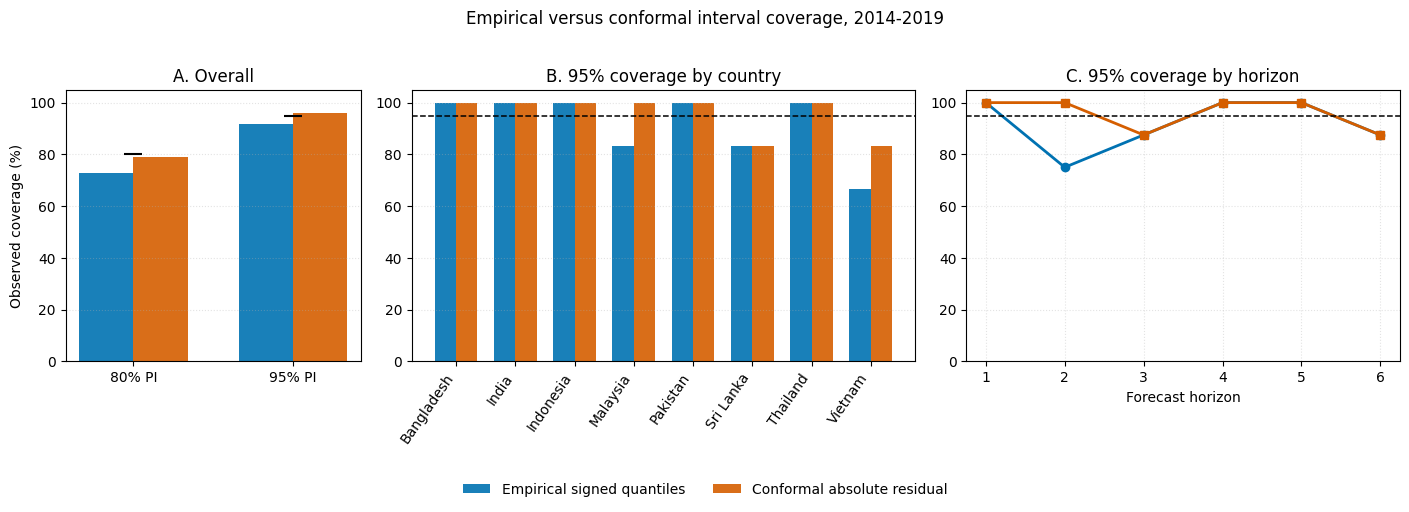

CELL 37 — HORIZON-WISE CONFORMAL PREDICTION INTERVALS

Tables folder : /content/study_final_confirmatory_outputs/tables_article_supplement
Figures folder: /content/study_final_confirmatory_outputs/figures_article_supplement
Model fits    : 0
Calibration   : 4 pre-2014 folds x 8 countries = 32/horizon
Held-out audit: 2014-2019, unchanged
Score         : absolute log(actual / predicted)

CONFORMAL CALIBRATION RADII


,Horizon,Nominal_Coverage_Percent,Alpha,N_Calibration_Scores,Raw_Conformal_Rank,Used_Order_Statistic,Effective_Order_Fraction,Conformal_Log_Radius,Lower_Multiplier,Upper_Multiplier
0,1,80.0,0.20,32,27,27,0.84375,0.10079,0.90412,1.10604
1,1,95.0,0.05,32,32,32,1.00000,0.17944,0.83574,1.19654
2,2,80.0,0.20,32,27,27,0.84375,0.14699,0.86330,1.15834
3,2,95.0,0.05,32,32,32,1.00000,0.31621,0.72891,1.37191
4,3,80.0,0.20,32,27,27,0.84375,0.21937,0.80303,1.24529
5,3,95.0,0.05,32,32,32,1.00000,0.31935,0.72662,1.37624
6,4,80.0,0.20,32,27,27,0.84375,0.26382,0.76811,1.30190
7,4,95.0,0.05,32,32,32,1.00000,0.34680,0.70694,1.41454
8,5,80.0,0.20,32,27,27,0.84375,0.28856,0.74934,1.33450
9,5,95.0,0.05,32,32,32,1.00000,0.40844,0.66469,1.50447



OVERALL COVERAGE AND WIDTH COMPARISON


,Method,Nominal_Coverage_Percent,Observed_Coverage_Percent,Misses,N,Mean_Interval_Width,Median_Relative_Width_Percent
0,Empirical signed quantiles,80.0,72.9167,13,48,1.0583,42.0989
1,Conformal absolute residual,80.0,79.1667,10,48,1.2168,48.8027
2,Empirical signed quantiles,95.0,91.6667,4,48,1.5080,58.1920
3,Conformal absolute residual,95.0,95.8333,2,48,1.8584,67.8607



COVERAGE AND WIDTH CHANGE


...


95% COVERAGE BY COUNTRY


Method,Conformal absolute residual,Empirical signed quantiles
country,,
Bangladesh,100.0,100.0
India,100.0,100.0
Indonesia,100.0,100.0
Malaysia,100.0,83.3
Pakistan,100.0,100.0
Sri Lanka,83.3,83.3
Thailand,100.0,100.0
Vietnam,83.3,66.7



95% COVERAGE BY HORIZON


Method,Conformal absolute residual,Empirical signed quantiles
Horizon,,
1,100.0,100.0
2,100.0,75.0
3,87.5,87.5
4,100.0,100.0
5,100.0,100.0
6,87.5,87.5



HEADLINE
  80% coverage: empirical 72.9% -> conformal 79.2%
  95% coverage: empirical 91.7% -> conformal 95.8%
  Conclusion : The conformal 95% interval attained or exceeded nominal coverage in the 2014-2019 audit.

INTERPRETATION GUARD
  The conformal rank correction is finite-sample, but exact coverage requires exchangeable calibration and test scores.
  Rolling-origin panel errors are dependent and not strictly exchangeable; observed coverage is therefore reported directly.
  Wider intervals may improve coverage at the cost of sharpness; coverage and width must be reported together.

INTEGRITY
  ✓ Exact frozen Cell-20 recursive CV predictions reused.
  ✓ 32 pre-2014 calibration scores retained per horizon.
  ✓ Finite-sample conformal order statistics used (27th and 32nd).
  ✓ No model fitting, tuning, or held-out recalibration.
  ✓ Same 2014-2019 audit observations as Cell 28.
  ✓ Cell-28 empirical coverage reproduced exactly.
  ✓ Existing empirical and projection interval objects 

In [38]:
# ============================================================
# CELL 37 — HORIZON-WISE CONFORMAL PREDICTION INTERVALS
# ============================================================
# Reuse Cell-28 calibration errors: 32 pre-2014 scores per horizon.
# Calibrate absolute log errors, then audit the same 2014-2019 predictions.
# Keep empirical intervals and point forecasts unchanged; fit no models.
# Apply the frozen radii separately to the 2025-2030 point projections.
# Exact coverage needs exchangeable scores, which this panel does not ensure.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. CHECK INPUTS AND SNAPSHOT EXISTING RESULTS
# ------------------------------------------------------------
required_objects = [
    "df", "interval_calibration_errors", "stage_b_interval_quantiles",
    "heldout_interval_audit", "coverage_overall", "pi_coverage_by_country",
    "coverage_by_horizon", "stage_b_projection_intervals", "STAGE_B_PROJECTION",
    "stage_b_holdout_predictions", "FROZEN_STAGE_B_WINNER", "FROZEN_STAGE_B_CONFIG_ID",
    "STAGE_B_HORIZON", "N_STAGE_B_FOLDS", "TRAIN_END", "TEST_START",
    "PROJECTION_START", "PROJECTION_END", "PROJECTION_HORIZON",
    "TABLES_DIR", "FIGURES_DIR",
]
missing_objects = [name for name in required_objects if name not in globals()]
assert not missing_objects, f"Missing objects: {missing_objects}"
assert FROZEN_STAGE_B_WINNER == "CatBoost"
assert int(FROZEN_STAGE_B_CONFIG_ID) == 13
assert int(STAGE_B_HORIZON) == 6
assert int(PROJECTION_HORIZON) == 6
assert int(N_STAGE_B_FOLDS) == 4
assert int(TRAIN_END) == 2013
assert int(TEST_START) == 2014
assert int(PROJECTION_START) == 2025
assert int(PROJECTION_END) == 2030

CONFORMAL_LEVELS = [0.80, 0.95]
CONFORMAL_HELDOUT_END = TEST_START + STAGE_B_HORIZON - 1
assert CONFORMAL_HELDOUT_END == 2019
frozen_interval_snapshot = (FROZEN_STAGE_B_WINNER, int(FROZEN_STAGE_B_CONFIG_ID))
calibration_checksum = int(
    pd.util.hash_pandas_object(interval_calibration_errors, index=True).sum()
)
empirical_audit_checksum = int(
    pd.util.hash_pandas_object(heldout_interval_audit, index=True).sum()
)
projection_checksum = int(
    pd.util.hash_pandas_object(STAGE_B_PROJECTION, index=True).sum()
)
conformal_tables_dir = Path(TABLES_DIR).parent / "tables_article_supplement"
conformal_figures_dir = Path(FIGURES_DIR).parent / "figures_article_supplement"
conformal_tables_dir.mkdir(parents=True, exist_ok=True)
conformal_figures_dir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. COPY AND VERIFY PRE-2014 CALIBRATION SCORES
# ------------------------------------------------------------
required_calibration_columns = {
    "Fold", "country", "year", "Horizon", "Predicted_CO2", "Actual_CO2", "Log_Error",
}
assert required_calibration_columns.issubset(interval_calibration_errors.columns)
conformal_calibration_scores = (
    interval_calibration_errors[[
        "Fold", "country", "year", "Horizon",
        "Predicted_CO2", "Actual_CO2", "Log_Error",
    ]]
    .copy()
    .sort_values(["Horizon", "Fold", "country"])
    .reset_index(drop=True)
)
# Use the stored signed log errors without recomputing or rounding them.
conformal_calibration_scores["Absolute_Log_Error"] = (
    conformal_calibration_scores["Log_Error"].abs()
)
assert len(conformal_calibration_scores) == N_STAGE_B_FOLDS * 8 * STAGE_B_HORIZON
assert int(conformal_calibration_scores["year"].max()) <= TRAIN_END
assert conformal_calibration_scores["Horizon"].between(1, 6).all()
assert np.isfinite(
    conformal_calibration_scores[["Log_Error", "Absolute_Log_Error"]]
    .to_numpy(dtype=float)
).all()
calibration_counts = conformal_calibration_scores.groupby("Horizon").size()
assert calibration_counts.eq(N_STAGE_B_FOLDS * 8).all()
assert calibration_counts.eq(32).all()


# ------------------------------------------------------------
# 3. CALCULATE FINITE-SAMPLE RADII FOR EACH HORIZON
# ------------------------------------------------------------
radius_rows = []
for horizon in range(1, STAGE_B_HORIZON + 1):
    scores = np.sort(
        conformal_calibration_scores.loc[
            conformal_calibration_scores["Horizon"].eq(horizon), "Absolute_Log_Error",
        ].to_numpy(dtype=float)
    )
    n = int(len(scores))
    assert n == 32

    for level in CONFORMAL_LEVELS:
        alpha = 1.0 - level
        raw_rank = int(np.ceil((n + 1) * (1.0 - alpha)))
        rank = int(min(max(raw_rank, 1), n))
        radius = float(scores[rank - 1])
        assert np.isfinite(radius) and radius >= 0

        radius_rows.append({
            "Horizon": int(horizon),
            "Nominal_Coverage_Percent": float(level * 100),
            "Alpha": float(alpha),
            "N_Calibration_Scores": n,
            "Raw_Conformal_Rank": raw_rank,
            "Used_Order_Statistic": rank,
            "Effective_Order_Fraction": float(rank / n),
            "Conformal_Log_Radius": radius,
            "Lower_Multiplier": float(np.exp(-radius)),
            "Upper_Multiplier": float(np.exp(radius)),
        })

conformal_horizon_radii = pd.DataFrame(radius_rows)
assert len(conformal_horizon_radii) == 12
assert conformal_horizon_radii.groupby(
    "Nominal_Coverage_Percent"
)["Horizon"].nunique().eq(6).all()
rank_80 = conformal_horizon_radii.loc[
    conformal_horizon_radii["Nominal_Coverage_Percent"].eq(80), "Used_Order_Statistic",
].unique()
rank_95 = conformal_horizon_radii.loc[
    conformal_horizon_radii["Nominal_Coverage_Percent"].eq(95), "Used_Order_Statistic",
].unique()
assert rank_80.tolist() == [27]
assert rank_95.tolist() == [32]


# ------------------------------------------------------------
# 4. ATTACH FROZEN CONFORMAL INTERVALS TO A COPY
# ------------------------------------------------------------
def attach_conformal_intervals(frame, point_column):
    """Attach 80% and 95% symmetric log-score intervals."""
    radius_wide = (
        conformal_horizon_radii.pivot(
            index="Horizon", columns="Nominal_Coverage_Percent",
            values="Conformal_Log_Radius",
        )
        .rename(columns={80.0: "Conformal_Radius_80", 95.0: "Conformal_Radius_95"})
        .reset_index()
    )
    out = frame.merge(
        radius_wide, on="Horizon", how="left", validate="many_to_one",
    ).copy()
    for label in [80, 95]:
        radius_column = f"Conformal_Radius_{label}"
        out[f"Lower_{label}_Conformal"] = out[point_column] * np.exp(-out[radius_column])
        out[f"Upper_{label}_Conformal"] = (
            out[point_column] * np.exp(out[radius_column])
        )
        assert (out[f"Lower_{label}_Conformal"] <= out[point_column]).all()
        assert (out[point_column] <= out[f"Upper_{label}_Conformal"]).all()

    assert (out["Lower_95_Conformal"] <= out["Lower_80_Conformal"]).all()
    assert (out["Upper_80_Conformal"] <= out["Upper_95_Conformal"]).all()
    assert (out[[
        "Lower_80_Conformal", "Upper_80_Conformal",
        "Lower_95_Conformal", "Upper_95_Conformal",
    ]] > 0).all().all()
    return out


# ------------------------------------------------------------
# 5. AUDIT THE SAME 48 HELD-OUT OBSERVATIONS
# ------------------------------------------------------------
empirical_columns = [
    "country", "year", "Horizon", "Predicted_CO2", "Actual_CO2",
    "Lower_80", "Upper_80", "Lower_95", "Upper_95", "Covered_80", "Covered_95",
]
assert set(empirical_columns).issubset(heldout_interval_audit.columns)
conformal_heldout_audit = attach_conformal_intervals(
    heldout_interval_audit[empirical_columns].copy(), point_column="Predicted_CO2",
)
assert len(conformal_heldout_audit) == 8 * STAGE_B_HORIZON
assert int(conformal_heldout_audit["year"].min()) == TEST_START
assert int(conformal_heldout_audit["year"].max()) == CONFORMAL_HELDOUT_END

for label in [80, 95]:
    # Include both endpoints, exactly as in the empirical audit.
    conformal_heldout_audit[f"Covered_{label}_Conformal"] = (
        conformal_heldout_audit["Actual_CO2"].between(
            conformal_heldout_audit[f"Lower_{label}_Conformal"],
            conformal_heldout_audit[f"Upper_{label}_Conformal"], inclusive="both",
        )
    )
    conformal_heldout_audit[f"Width_{label}_Empirical"] = (
        conformal_heldout_audit[f"Upper_{label}"]
        - conformal_heldout_audit[f"Lower_{label}"]
    )
    conformal_heldout_audit[f"Width_{label}_Conformal"] = (
        conformal_heldout_audit[f"Upper_{label}_Conformal"]
        - conformal_heldout_audit[f"Lower_{label}_Conformal"]
    )
    conformal_heldout_audit[f"Relative_Width_{label}_Empirical_Percent"] = (
        100 * conformal_heldout_audit[f"Width_{label}_Empirical"]
        / conformal_heldout_audit["Predicted_CO2"]
    )
    conformal_heldout_audit[f"Relative_Width_{label}_Conformal_Percent"] = (
        100 * conformal_heldout_audit[f"Width_{label}_Conformal"]
        / conformal_heldout_audit["Predicted_CO2"]
    )


# ------------------------------------------------------------
# 6. COMPARE OVERALL COVERAGE AND INTERVAL WIDTH
# ------------------------------------------------------------
overall_rows = []
for label in [80, 95]:
    for method in ["Empirical signed quantiles", "Conformal absolute residual"]:
        if method.startswith("Empirical"):
            covered_column = f"Covered_{label}"
            width_column = f"Width_{label}_Empirical"
            relative_width_column = f"Relative_Width_{label}_Empirical_Percent"
        else:
            covered_column = f"Covered_{label}_Conformal"
            width_column = f"Width_{label}_Conformal"
            relative_width_column = f"Relative_Width_{label}_Conformal_Percent"

        overall_rows.append({
            "Method": method,
            "Nominal_Coverage_Percent": float(label),
            "Observed_Coverage_Percent": float(
                conformal_heldout_audit[covered_column].mean() * 100
            ),
            "Misses": int((~conformal_heldout_audit[covered_column]).sum()),
            "N": int(len(conformal_heldout_audit)),
            "Mean_Interval_Width": float(conformal_heldout_audit[width_column].mean()),
            "Median_Relative_Width_Percent": float(
                conformal_heldout_audit[relative_width_column].median()
            ),
        })
conformal_coverage_overall = pd.DataFrame(overall_rows)
empirical_coverage_lookup = (
    coverage_overall.assign(
        Nominal_Coverage_Percent=lambda x: x["Nominal_Coverage_Percent"].astype(float)
    )
    .set_index("Nominal_Coverage_Percent")["Observed_Coverage_Percent"]
)
for label in [80, 95]:
    reproduced = float(
        conformal_coverage_overall.loc[
            conformal_coverage_overall["Method"].str.startswith("Empirical")
            & conformal_coverage_overall["Nominal_Coverage_Percent"].eq(label),
            "Observed_Coverage_Percent",
        ].iloc[0]
    )
    assert np.isclose(
        reproduced, float(empirical_coverage_lookup.loc[float(label)]), atol=1e-12,
    )

coverage_change_rows = []
for label in [80, 95]:
    sub = conformal_coverage_overall.loc[
        conformal_coverage_overall["Nominal_Coverage_Percent"].eq(label)
    ].set_index("Method")
    empirical = sub.loc["Empirical signed quantiles"]
    conformal = sub.loc["Conformal absolute residual"]
    coverage_change_rows.append({
        "Nominal_Coverage_Percent": float(label),
        "Empirical_Coverage_Percent": float(empirical["Observed_Coverage_Percent"]),
        "Conformal_Coverage_Percent": float(conformal["Observed_Coverage_Percent"]),
        "Coverage_Change_Percentage_Points": float(
            conformal["Observed_Coverage_Percent"]
            - empirical["Observed_Coverage_Percent"]
        ),
        "Empirical_Mean_Width": float(empirical["Mean_Interval_Width"]),
        "Conformal_Mean_Width": float(conformal["Mean_Interval_Width"]),
        "Width_Change_Percent": float(
            100 * (
                conformal["Mean_Interval_Width"] / empirical["Mean_Interval_Width"] - 1
            )
        ),
    })
conformal_coverage_change = pd.DataFrame(coverage_change_rows)


# ------------------------------------------------------------
# 7. SUMMARIZE COVERAGE BY COUNTRY AND HORIZON
# ------------------------------------------------------------
def grouped_coverage_long(group_column):
    rows = []
    for group_value, group in conformal_heldout_audit.groupby(group_column):
        for label in [80, 95]:
            rows.extend([
                {
                    group_column: group_value,
                    "Method": "Empirical signed quantiles",
                    "Nominal_Coverage_Percent": float(label),
                    "Observed_Coverage_Percent": float(
                        group[f"Covered_{label}"].mean() * 100
                    ),
                    "N": int(len(group)),
                },
                {
                    group_column: group_value,
                    "Method": "Conformal absolute residual",
                    "Nominal_Coverage_Percent": float(label),
                    "Observed_Coverage_Percent": float(
                        group[f"Covered_{label}_Conformal"].mean() * 100
                    ),
                    "N": int(len(group)),
                },
            ])
    return pd.DataFrame(rows)


conformal_coverage_by_country = grouped_coverage_long("country")
conformal_coverage_by_horizon = grouped_coverage_long("Horizon")
assert conformal_coverage_by_country["country"].nunique() == 8
assert conformal_coverage_by_horizon["Horizon"].nunique() == 6
assert conformal_coverage_by_country["N"].eq(6).all()
assert conformal_coverage_by_horizon["N"].eq(8).all()


# ------------------------------------------------------------
# 8. APPLY THE SAME FROZEN RADII TO 2025-2030
# ------------------------------------------------------------
stage_b_projection_conformal_intervals = attach_conformal_intervals(
    STAGE_B_PROJECTION.copy(), point_column="Projected_CO2",
)
assert len(stage_b_projection_conformal_intervals) == 8 * PROJECTION_HORIZON
projection_conformal_numeric = (
    stage_b_projection_conformal_intervals[[
        "country", "year", "Horizon", "Lower_95_Conformal", "Lower_80_Conformal",
        "Projected_CO2", "Upper_80_Conformal", "Upper_95_Conformal",
    ]]
    .sort_values(["country", "year"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 9. PLOT OVERALL, COUNTRY AND HORIZON COVERAGE
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1, 3, figsize=(14.2, 4.8), gridspec_kw={"width_ratios": [0.85, 1.45, 1.25]},
)
method_order = ["Empirical signed quantiles", "Conformal absolute residual"]
colors = {
    "Empirical signed quantiles": "#0072B2",
    "Conformal absolute residual": "#D55E00",
}

# Panel A: observed overall coverage, with nominal-coverage markers.
ax = axes[0]
x = np.arange(2)
width = 0.34
for offset, method in zip([-width / 2, width / 2], method_order):
    values = []
    for label in [80, 95]:
        values.append(float(
            conformal_coverage_overall.loc[
                conformal_coverage_overall["Method"].eq(method)
                & conformal_coverage_overall["Nominal_Coverage_Percent"].eq(label),
                "Observed_Coverage_Percent",
            ].iloc[0]
        ))
    ax.bar(
        x + offset, values, width=width, label=method, color=colors[method], alpha=0.9,
    )
ax.scatter(x, [80, 95], color="black", marker="_", s=180, zorder=5)
ax.set_xticks(x, ["80% PI", "95% PI"])
ax.set_ylim(0, 105)
ax.set_ylabel("Observed coverage (%)")
ax.set_title("A. Overall")
ax.grid(axis="y", linestyle=":", alpha=0.35)

# Panel B: 95% coverage for each country, in alphabetical order.
ax = axes[1]
country_95 = conformal_coverage_by_country.loc[
    conformal_coverage_by_country["Nominal_Coverage_Percent"].eq(95)
].copy()
country_order = sorted(country_95["country"].unique())
x = np.arange(len(country_order))
width = 0.36
for offset, method in zip([-width / 2, width / 2], method_order):
    values = (
        country_95.loc[country_95["Method"].eq(method)]
        .set_index("country")
        .reindex(country_order)["Observed_Coverage_Percent"]
        .to_numpy(dtype=float)
    )
    ax.bar(x + offset, values, width=width, color=colors[method], alpha=0.9)
ax.axhline(95, color="black", linestyle="--", linewidth=1.1)
ax.set_xticks(x, country_order, rotation=55, ha="right")
ax.set_ylim(0, 105)
ax.set_title("B. 95% coverage by country")
ax.grid(axis="y", linestyle=":", alpha=0.35)

# Panel C: 95% coverage for each of the six forecast horizons.
ax = axes[2]
horizon_95 = conformal_coverage_by_horizon.loc[
    conformal_coverage_by_horizon["Nominal_Coverage_Percent"].eq(95)
].copy()
for method in method_order:
    sub = horizon_95.loc[horizon_95["Method"].eq(method)].sort_values("Horizon")
    ax.plot(
        sub["Horizon"], sub["Observed_Coverage_Percent"],
        marker="o" if method.startswith("Empirical") else "s",
        linewidth=2.0, color=colors[method], label=method,
    )
ax.axhline(95, color="black", linestyle="--", linewidth=1.1)
ax.set_xticks(range(1, 7))
ax.set_ylim(0, 105)
ax.set_xlabel("Forecast horizon")
ax.set_title("C. 95% coverage by horizon")
ax.grid(True, linestyle=":", alpha=0.35)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", ncol=2, frameon=False,
    bbox_to_anchor=(0.5, -0.02),
)
fig.suptitle("Empirical versus conformal interval coverage, 2014-2019", y=1.02)
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(
    conformal_figures_dir / "fig_conformal_coverage_comparison.png",
    dpi=300, bbox_inches="tight",
)
fig.savefig(
    conformal_figures_dir / "fig_conformal_coverage_comparison.pdf",
    bbox_inches="tight",
)
plt.show()


# ------------------------------------------------------------
# 10. SAVE — ORIGINAL FILENAMES AND NUMERIC PRECISION
# ------------------------------------------------------------
conformal_calibration_scores.to_csv(
    conformal_tables_dir / "conformal_calibration_scores_pre2014.csv", index=False,
)
conformal_horizon_radii.to_csv(
    conformal_tables_dir / "conformal_horizon_radii_pre2014.csv", index=False,
)
conformal_heldout_audit.to_csv(
    conformal_tables_dir / "conformal_heldout_audit_2014_2019.csv", index=False,
)
conformal_coverage_overall.to_csv(
    conformal_tables_dir / "conformal_vs_empirical_coverage_overall.csv", index=False,
)
conformal_coverage_change.to_csv(
    conformal_tables_dir / "conformal_coverage_and_width_change.csv", index=False,
)
conformal_coverage_by_country.to_csv(
    conformal_tables_dir / "conformal_vs_empirical_coverage_by_country.csv",
    index=False,
)
conformal_coverage_by_horizon.to_csv(
    conformal_tables_dir / "conformal_vs_empirical_coverage_by_horizon.csv",
    index=False,
)
projection_conformal_numeric.to_csv(
    conformal_tables_dir / "stage_b_projection_2025_2030_conformal_intervals.csv",
    index=False,
)


# ------------------------------------------------------------
# 11. VERIFY EXISTING RESULTS AND PREPARE THE HEADLINE
# ------------------------------------------------------------
assert frozen_interval_snapshot == (
    FROZEN_STAGE_B_WINNER, int(FROZEN_STAGE_B_CONFIG_ID),
)
assert calibration_checksum == int(
    pd.util.hash_pandas_object(interval_calibration_errors, index=True).sum()
)
assert empirical_audit_checksum == int(
    pd.util.hash_pandas_object(heldout_interval_audit, index=True).sum()
)
assert projection_checksum == int(
    pd.util.hash_pandas_object(STAGE_B_PROJECTION, index=True).sum()
)
headline = conformal_coverage_change.set_index("Nominal_Coverage_Percent")
empirical_80 = float(headline.loc[80, "Empirical_Coverage_Percent"])
conformal_80 = float(headline.loc[80, "Conformal_Coverage_Percent"])
empirical_95 = float(headline.loc[95, "Empirical_Coverage_Percent"])
conformal_95 = float(headline.loc[95, "Conformal_Coverage_Percent"])
if conformal_95 >= 95.0:
    conformal_95_statement = (
        "The conformal 95% interval attained or exceeded nominal "
        "coverage in the 2014-2019 audit."
    )
else:
    conformal_95_statement = (
        "The conformal 95% interval remained below nominal coverage "
        "in the 2014-2019 audit."
    )


# ------------------------------------------------------------
# 12. REPORT — ORIGINAL WORDING AND DISPLAY PRECISION
# ------------------------------------------------------------
print("=" * 78)
print("CELL 37 — HORIZON-WISE CONFORMAL PREDICTION INTERVALS")
print("=" * 78)
print(f"\nTables folder : {conformal_tables_dir}")
print(f"Figures folder: {conformal_figures_dir}")
print("Model fits    : 0")
print("Calibration   : 4 pre-2014 folds x 8 countries = 32/horizon")
print("Held-out audit: 2014-2019, unchanged")
print("Score         : absolute log(actual / predicted)")

print("\nCONFORMAL CALIBRATION RADII")
display(conformal_horizon_radii.round(5))
print("\nOVERALL COVERAGE AND WIDTH COMPARISON")
display(conformal_coverage_overall.round(4))
print("\nCOVERAGE AND WIDTH CHANGE")
display(conformal_coverage_change.round(4))
print("\n95% COVERAGE BY COUNTRY")
display(
    conformal_coverage_by_country.loc[
        conformal_coverage_by_country["Nominal_Coverage_Percent"].eq(95)
    ]
    .pivot(index="country", columns="Method", values="Observed_Coverage_Percent")
    .round(1)
)
print("\n95% COVERAGE BY HORIZON")
display(
    conformal_coverage_by_horizon.loc[
        conformal_coverage_by_horizon["Nominal_Coverage_Percent"].eq(95)
    ]
    .pivot(index="Horizon", columns="Method", values="Observed_Coverage_Percent")
    .round(1)
)

print("\nHEADLINE")
print(
    f"  80% coverage: empirical {empirical_80:.1f}% -> "
    f"conformal {conformal_80:.1f}%"
)
print(
    f"  95% coverage: empirical {empirical_95:.1f}% -> "
    f"conformal {conformal_95:.1f}%"
)
print(f"  Conclusion : {conformal_95_statement}")
print("\nINTERPRETATION GUARD")
print(
    "  The conformal rank correction is finite-sample, but exact "
    "coverage requires exchangeable calibration and test scores."
)
print(
    "  Rolling-origin panel errors are dependent and not strictly "
    "exchangeable; observed coverage is therefore reported directly."
)
print(
    "  Wider intervals may improve coverage at the cost of sharpness; "
    "coverage and width must be reported together."
)
print("\nINTEGRITY")
for line in [
    "Exact frozen Cell-20 recursive CV predictions reused.",
    "32 pre-2014 calibration scores retained per horizon.",
    "Finite-sample conformal order statistics used (27th and 32nd).",
    "No model fitting, tuning, or held-out recalibration.",
    "Same 2014-2019 audit observations as Cell 28.",
    "Cell-28 empirical coverage reproduced exactly.",
    "Existing empirical and projection interval objects unchanged.",
    "Conformal 2025-2030 intervals saved separately.",
    "Figure saved as 300-dpi PNG and vector PDF.",
]:
    print(f"  ✓ {line}")
print(
    "\nOUTPUTS: conformal radii | coverage/width comparison | "
    "country and horizon audits | 2025-2030 conformal intervals | "
    "prediction-level audit | PNG/PDF figure"
)


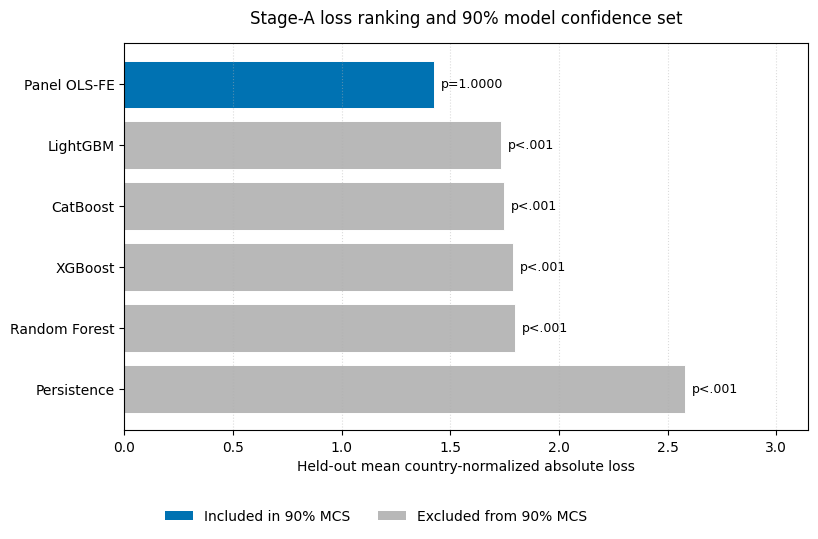

CELL 38 — PANEL INFERENCE, COUNTRY BOOTSTRAP AND MCS

Tables folder : /content/study_final_confirmatory_outputs/tables_article_supplement
Figures folder: /content/study_final_confirmatory_outputs/figures_article_supplement
Model fits    : 0
Panel         : 8 countries x 11 years = 88 rows/method
Primary DK lag: 1
Country bootstrap: 20,000 replications
MCS bootstrap    : 20,000 circular-block replications

DRISCOLL-KRAAY PANEL COMPARISONS


,Method,Reference,N_Countries,N_Years,N_Panel_Rows,Mean_Loss_Difference,DK_SE,DK_t,DK_P_Value_Two_Sided,DK_CI95_Lower,DK_CI95_Upper,Lower_Loss_Method
0,Panel OLS-FE,Persistence,8,11,88,-1.15544,0.15649,-7.38350,0.00002,-1.50412,-0.80676,Panel OLS-FE
1,LightGBM,Persistence,8,11,88,-0.84448,0.12431,-6.79312,0.00005,-1.12147,-0.56749,LightGBM
2,CatBoost,Persistence,8,11,88,-0.83128,0.10507,-7.91175,0.00001,-1.06539,-0.59717,CatBoost
3,XGBoost,Persistence,8,11,88,-0.79261,0.13939,-5.68616,0.00020,-1.10319,-0.48202,XGBoost
4,Random Forest,Persistence,8,11,88,-0.78103,0.09897,-7.89167,0.00001,-1.00155,-0.56051,Random Forest
5,CatBoost,Panel OLS-FE,8,11,88,0.32416,0.08966,3.61562,0.00472,0.12440,0.52393,Panel OLS-FE



COUNTRY-BLOCK BOOTSTRAP


,Method,Reference,Mean_Loss_Difference,Bootstrap_SE,Bootstrap_P_Value_Two_Sided,Bootstrap_CI95_Lower,Bootstrap_CI95_Upper,Bootstrap_CI_Excludes_Zero
0,Panel OLS-FE,Persistence,-1.15544,0.30597,0.00010,-1.76579,-0.57319,True
1,LightGBM,Persistence,-0.84448,0.28668,0.00245,-1.41449,-0.29907,True
2,CatBoost,Persistence,-0.83128,0.25342,0.00120,-1.34381,-0.35672,True
3,XGBoost,Persistence,-0.79261,0.31234,0.00945,-1.40960,-0.18840,True
4,Random Forest,Persistence,-0.78103,0.26682,0.00300,-1.32559,-0.28017,True
5,CatBoost,Panel OLS-FE,0.32416,0.08850,0.00040,0.14933,0.49441,True



INFERENCE TRIANGULATION


...


MODEL CONFIDENCE SET


,Method,Mean_Normalized_Loss,MCS_P_Value,Loss_Rank,Included_in_90pct_MCS,Included_in_95pct_MCS
0,Panel OLS-FE,1.42422,1.00000,1,True,True
1,LightGBM,1.73519,0.00005,2,False,False
2,CatBoost,1.74838,0.00040,3,False,False
3,XGBoost,1.78706,0.00010,4,False,False
4,Random Forest,1.79864,0.00005,5,False,False
5,Persistence,2.57966,0.00005,6,False,False



MCS ELIMINATION HISTORY


,Step,Models_Before_Elimination,Set_Before_Elimination,Range_Statistic,Raw_EPA_P_Value,Monotone_MCS_P_Value,Eliminated_Method
0,1,6,Panel OLS-FE | LightGBM | CatBoost | XGBoost | Random Forest | Persistence,8.02159,0.00005,0.00005,Persistence
1,2,5,Panel OLS-FE | LightGBM | CatBoost | XGBoost | Random Forest,4.77140,0.00005,0.00005,LightGBM
2,3,4,Panel OLS-FE | CatBoost | XGBoost | Random Forest,4.76911,0.00005,0.00005,Random Forest
3,4,3,Panel OLS-FE | CatBoost | XGBoost,4.35909,0.00010,0.00010,XGBoost
4,5,2,Panel OLS-FE | CatBoost,3.54141,0.00040,0.00040,CatBoost



HEADLINE
  CatBoost vs OLS: mean difference +0.3242; DK p=0.0047; country-bootstrap p<.001.
  OLS vs persistence: mean difference -1.1554; DK p<.001; country-bootstrap p<.001.
  90% MCS: Panel OLS-FE
  95% MCS: Panel OLS-FE

INTERPRETATION KEY
  Mean difference < 0: Method has lower normalized loss.
  Mean difference > 0: Reference has lower normalized loss.
  MCS provides the family-wide ranking decision; pairwise DK and bootstrap contrasts are not Holm-adjusted here.

SMALL-SAMPLE CAUTION
  The panel has 88 rows but only 11 time periods and 8 country clusters; 88 is not treated as 88 independent observations.
  Driscoll-Kraay inference uses T-1 = 10 degrees of freedom.
  The country bootstrap has only eight distinct clusters, and the MCS has only eleven annual losses per method.
  Non-rejection is not interpreted as proof of equivalence.

INTEGRITY
  ✓ Frozen Stage-A 2014-2024 predictions reused unchanged.
  ✓ Balanced 8-country x 11-year loss panel verified.
  ✓ Mean panel losses r

In [39]:
# ============================================================
# CELL 38 — PANEL INFERENCE, COUNTRY BOOTSTRAP AND MCS
# ============================================================
# Reuse frozen Stage-A 2014-2024 predictions; do not refit prediction models.
# Compare country-normalized absolute losses using panel DK covariance,
# complete-country bootstrap histories and a circular-block MCS diagnostic.
# Preserve 20,000 replications, seeds, sampling order and elimination rules.
# The panel has only 11 years and 8 country clusters, not 88 independent rows.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from pathlib import Path
from scipy.stats import t as student_t
from statsmodels.stats.sandwich_covariance import cov_nw_groupsum


# ------------------------------------------------------------
# 1. CHECK INPUTS AND SNAPSHOT THE FROZEN RESULTS
# ------------------------------------------------------------
required_objects = [
    "stage_a_holdout_predictions", "stage_a_holdout_results",
    "stage_a_yearly_losses", "stage_a_dm_hac", "METHOD_ORDER",
    "DEVELOPMENT_DENOMINATORS", "STAGE_A_WINNER", "FROZEN_STAGE_A_WINNER",
    "STAGE_A_WINNER_CONFIG_ID", "FROZEN_STAGE_A_CONFIG_ID",
    "TEST_START", "TEST_END", "SEED", "TABLES_DIR", "FIGURES_DIR",
]
missing_objects = [name for name in required_objects if name not in globals()]
assert not missing_objects, f"Missing objects: {missing_objects}"
assert STAGE_A_WINNER == FROZEN_STAGE_A_WINNER
assert STAGE_A_WINNER_CONFIG_ID == FROZEN_STAGE_A_CONFIG_ID
assert FROZEN_STAGE_A_WINNER == "CatBoost"
assert int(FROZEN_STAGE_A_CONFIG_ID) == 15
assert int(TEST_START) == 2014
assert int(TEST_END) == 2024

DK_PRIMARY_LAG = 1
DK_SENSITIVITY_LAGS = [0, 1, 2]
COUNTRY_BOOTSTRAP_REPLICATIONS = 20_000
MCS_BOOTSTRAP_REPLICATIONS = 20_000
MCS_TIME_BLOCK_LENGTH = 2
INFERENCE_SEED = int(SEED)
MCS_SEED = int(SEED) + 1
assert COUNTRY_BOOTSTRAP_REPLICATIONS >= 10_000
assert MCS_BOOTSTRAP_REPLICATIONS >= 10_000

frozen_stage_a_snapshot = (STAGE_A_WINNER, int(STAGE_A_WINNER_CONFIG_ID))
prediction_checksum = int(
    pd.util.hash_pandas_object(stage_a_holdout_predictions, index=True).sum()
)
results_checksum = int(
    pd.util.hash_pandas_object(stage_a_holdout_results, index=True).sum()
)
inference_tables_dir = Path(TABLES_DIR).parent / "tables_article_supplement"
inference_figures_dir = Path(FIGURES_DIR).parent / "figures_article_supplement"
inference_tables_dir.mkdir(parents=True, exist_ok=True)
inference_figures_dir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. READ EACH COUNTRY'S DEVELOPMENT MASE DENOMINATOR
# ------------------------------------------------------------
def inference_denominator(country):
    obj = DEVELOPMENT_DENOMINATORS
    if isinstance(obj, dict):
        value = obj[country]
    elif isinstance(obj, pd.Series):
        value = obj.loc[country]
    elif isinstance(obj, pd.DataFrame):
        if {"country", "MASE_Denominator"}.issubset(obj.columns):
            value = obj.loc[
                obj["country"].eq(country), "MASE_Denominator",
            ].iloc[0]
        else:
            value = obj.loc[country, "MASE_Denominator"]
    else:
        raise TypeError("Unsupported DEVELOPMENT_DENOMINATORS object")
    value = float(value)
    assert np.isfinite(value) and value > 0
    return value


# ------------------------------------------------------------
# 3. BUILD THE BALANCED COUNTRY-YEAR LOSS PANEL
# ------------------------------------------------------------
required_prediction_columns = {"country", "year", "actual_co2", "pred_co2", "Method"}
assert required_prediction_columns.issubset(stage_a_holdout_predictions.columns)
panel_methods = list(dict.fromkeys(METHOD_ORDER))
assert len(panel_methods) == 6
assert set(panel_methods) == set(stage_a_holdout_predictions["Method"].unique())
assert {
    "Panel OLS-FE", "LightGBM", "CatBoost", "XGBoost", "Random Forest", "Persistence",
} == set(panel_methods)

stage_a_country_year_loss_panel = stage_a_holdout_predictions[[
    "country", "year", "actual_co2", "pred_co2", "Method",
]].copy()
stage_a_country_year_loss_panel["MASE_Denominator"] = (
    stage_a_country_year_loss_panel["country"]
    .map({
        country: inference_denominator(country)
        for country in stage_a_country_year_loss_panel["country"].unique()
    })
    .astype(float)
)
stage_a_country_year_loss_panel["Scaled_Absolute_Error"] = (
    (
        stage_a_country_year_loss_panel["actual_co2"]
        - stage_a_country_year_loss_panel["pred_co2"]
    ).abs()
    / stage_a_country_year_loss_panel["MASE_Denominator"]
)
assert len(stage_a_country_year_loss_panel) == 6 * 8 * 11
assert stage_a_country_year_loss_panel["country"].nunique() == 8
assert stage_a_country_year_loss_panel["year"].nunique() == 11
assert stage_a_country_year_loss_panel["Method"].nunique() == 6
assert not stage_a_country_year_loss_panel["Scaled_Absolute_Error"].isna().any()

loss_wide = (
    stage_a_country_year_loss_panel.pivot(
        index=["country", "year"], columns="Method", values="Scaled_Absolute_Error",
    )
    .sort_index()
)
assert loss_wide.shape == (88, 6)
assert not loss_wide.isna().any().any()

# Equal country counts make each panel mean equal the reported Macro-MASE.
macro_lookup = stage_a_holdout_results.set_index("Method")["Macro_MASE"].astype(float)
for method in panel_methods:
    assert np.isclose(
        float(loss_wide[method].mean()), float(macro_lookup.loc[method]),
        atol=1e-10, rtol=1e-10,
    )


# ------------------------------------------------------------
# 4. DEFINE THE SIX PRE-SPECIFIED CONTRASTS
# ------------------------------------------------------------
panel_comparisons = [
    (method, "Persistence") for method in panel_methods if method != "Persistence"
]
panel_comparisons.append((FROZEN_STAGE_A_WINNER, "Panel OLS-FE"))
assert len(panel_comparisons) == 6
assert len(panel_comparisons) == len(set(panel_comparisons))


# ------------------------------------------------------------
# 5. DRISCOLL-KRAAY LOSS-DIFFERENCE TESTS
# ------------------------------------------------------------
# Fit only a constant to the loss differential, not a new prediction model.
# Check the library covariance against the original manual Bartlett formula.
def driscoll_kraay_loss_test(method, reference, maxlags=1):
    differential = (
        loss_wide[[method, reference]]
        .reset_index()
        .assign(Loss_Difference=lambda x: x[method] - x[reference])
        .sort_values(["year", "country"])
        .reset_index(drop=True)
    )
    d = differential["Loss_Difference"].to_numpy(dtype=float)
    years = differential["year"].to_numpy(dtype=int)
    unique_years = np.sort(np.unique(years))
    time_codes = years - int(unique_years.min())
    assert len(d) == 88
    assert len(unique_years) == 11
    assert np.array_equal(unique_years, np.arange(TEST_START, TEST_END + 1))
    assert np.isfinite(d).all()

    x = np.ones((len(d), 1), dtype=float)
    ordinary_fit = sm.OLS(d, x).fit()
    covariance = cov_nw_groupsum(
        ordinary_fit, nlags=int(maxlags), time=time_codes, use_correction="hac",
    )
    dk_variance = float(covariance[0, 0])

    mean_difference = float(np.mean(d))
    residual = d - mean_difference
    time_score_sums = np.array([
        float(residual[years == year].sum()) for year in unique_years
    ])
    inner = float(np.dot(time_score_sums, time_score_sums))
    for lag in range(1, int(maxlags) + 1):
        weight = 1.0 - lag / (int(maxlags) + 1.0)
        inner += 2.0 * weight * float(
            np.dot(time_score_sums[lag:], time_score_sums[:-lag])
        )
    n_panel = len(d)
    manual_variance = inner / (n_panel ** 2) * n_panel / (n_panel - 1)
    assert np.isclose(dk_variance, manual_variance, atol=1e-12, rtol=1e-10)

    dk_se = float(np.sqrt(max(dk_variance, 0.0)))
    assert dk_se > 0
    dk_t = float(mean_difference / dk_se)
    inference_df = len(unique_years) - 1
    p_value = float(2.0 * student_t.sf(abs(dk_t), df=inference_df))
    critical = float(student_t.ppf(0.975, df=inference_df))
    return {
        "Method": method,
        "Reference": reference,
        "Comparison": f"{method} vs {reference}",
        "N_Countries": 8,
        "N_Years": 11,
        "N_Panel_Rows": 88,
        "DK_Lag": int(maxlags),
        "Mean_Loss_Difference": mean_difference,
        "DK_SE": dk_se,
        "DK_t": dk_t,
        "Inference_df": int(inference_df),
        "DK_P_Value_Two_Sided": p_value,
        "DK_CI95_Lower": float(mean_difference - critical * dk_se),
        "DK_CI95_Upper": float(mean_difference + critical * dk_se),
        "Lower_Loss_Method": method if mean_difference < 0 else reference,
    }


dk_rows = []
for lag in DK_SENSITIVITY_LAGS:
    for method, reference in panel_comparisons:
        dk_rows.append(driscoll_kraay_loss_test(
            method=method, reference=reference, maxlags=lag,
        ))
stage_a_dk_panel_sensitivity = pd.DataFrame(dk_rows)
stage_a_dk_panel = (
    stage_a_dk_panel_sensitivity.loc[
        stage_a_dk_panel_sensitivity["DK_Lag"].eq(DK_PRIMARY_LAG)
    ]
    .copy()
    .reset_index(drop=True)
)
assert len(stage_a_dk_panel_sensitivity) == 18
assert len(stage_a_dk_panel) == 6

# Reproduce the earlier Cell-15 mean loss differentials.
cell15_mean_lookup = stage_a_dm_hac.set_index("Comparison")[
    "Mean_Loss_Difference"
].astype(float)
for row in stage_a_dk_panel.itertuples(index=False):
    assert np.isclose(
        float(row.Mean_Loss_Difference), float(cell15_mean_lookup.loc[row.Comparison]),
        atol=1e-12, rtol=1e-10,
    )


# ------------------------------------------------------------
# 6. BOOTSTRAP COMPLETE 11-YEAR COUNTRY HISTORIES
# ------------------------------------------------------------
countries = sorted(loss_wide.index.get_level_values("country").unique())
country_rng = np.random.default_rng(INFERENCE_SEED)
country_bootstrap_indices = country_rng.integers(
    0, len(countries), size=(COUNTRY_BOOTSTRAP_REPLICATIONS, len(countries)),
)
country_bootstrap_rows = []
for method, reference in panel_comparisons:
    difference_matrix = (
        (loss_wide[method] - loss_wide[reference])
        .unstack("year")
        .reindex(index=countries, columns=range(TEST_START, TEST_END + 1))
    )
    assert difference_matrix.shape == (8, 11)
    assert not difference_matrix.isna().any().any()
    country_mean_differences = difference_matrix.mean(axis=1).to_numpy(dtype=float)
    observed_mean = float(country_mean_differences.mean())
    bootstrap_means = country_mean_differences[country_bootstrap_indices].mean(axis=1)
    bootstrap_ci = np.quantile(bootstrap_means, [0.025, 0.975])
    centered_bootstrap = bootstrap_means - observed_mean
    bootstrap_p = float(
        (1 + np.sum(np.abs(centered_bootstrap) >= abs(observed_mean)))
        / (COUNTRY_BOOTSTRAP_REPLICATIONS + 1)
    )
    assert np.isclose(
        observed_mean,
        float(stage_a_dk_panel.loc[
            stage_a_dk_panel["Comparison"].eq(f"{method} vs {reference}"),
            "Mean_Loss_Difference",
        ].iloc[0]),
        atol=1e-12,
    )
    country_bootstrap_rows.append({
        "Method": method,
        "Reference": reference,
        "Comparison": f"{method} vs {reference}",
        "N_Country_Clusters": 8,
        "Years_Per_Cluster": 11,
        "Bootstrap_Replications": COUNTRY_BOOTSTRAP_REPLICATIONS,
        "Mean_Loss_Difference": observed_mean,
        "Bootstrap_SE": float(np.std(bootstrap_means, ddof=1)),
        "Bootstrap_CI95_Lower": float(bootstrap_ci[0]),
        "Bootstrap_CI95_Upper": float(bootstrap_ci[1]),
        "Bootstrap_P_Value_Two_Sided": bootstrap_p,
        "Bootstrap_CI_Excludes_Zero": bool(bootstrap_ci[0] > 0 or bootstrap_ci[1] < 0),
    })
stage_a_country_block_bootstrap = pd.DataFrame(country_bootstrap_rows)
assert len(stage_a_country_block_bootstrap) == 6


# ------------------------------------------------------------
# 7. COMPARE DK AND COUNTRY-BOOTSTRAP FINDINGS
# ------------------------------------------------------------
stage_a_inference_triangulation = stage_a_dk_panel.merge(
    stage_a_country_block_bootstrap[[
        "Comparison", "Bootstrap_SE", "Bootstrap_CI95_Lower", "Bootstrap_CI95_Upper",
        "Bootstrap_P_Value_Two_Sided", "Bootstrap_CI_Excludes_Zero",
    ]],
    on="Comparison", validate="one_to_one",
)
stage_a_inference_triangulation["DK_Reject_5pct"] = (
    stage_a_inference_triangulation["DK_P_Value_Two_Sided"] < 0.05
)
stage_a_inference_triangulation["Methods_Agree_5pct"] = (
    stage_a_inference_triangulation["DK_Reject_5pct"]
    == stage_a_inference_triangulation["Bootstrap_CI_Excludes_Zero"]
)


# ------------------------------------------------------------
# 8. MCS RANGE STATISTIC AND SEQUENTIAL ELIMINATION
# ------------------------------------------------------------
annual_loss_wide = (
    stage_a_country_year_loss_panel
    .groupby(["year", "Method"], as_index=False)["Scaled_Absolute_Error"]
    .mean()
    .pivot(index="year", columns="Method", values="Scaled_Absolute_Error")
    .reindex(index=range(TEST_START, TEST_END + 1), columns=panel_methods)
)
assert annual_loss_wide.shape == (11, 6)
assert not annual_loss_wide.isna().any().any()
cell15_annual_wide = (
    stage_a_yearly_losses.pivot(
        index="year", columns="Method", values="Yearly_Normalized_Loss",
    )
    .reindex(index=range(TEST_START, TEST_END + 1), columns=panel_methods)
)
assert np.allclose(
    annual_loss_wide.to_numpy(dtype=float), cell15_annual_wide.to_numpy(dtype=float),
    atol=1e-12, rtol=1e-10,
)


def circular_time_indices(n_periods, block_length, rng):
    n_blocks = int(np.ceil(n_periods / block_length))
    starts = rng.integers(0, n_periods, size=n_blocks)
    indices = np.concatenate([
        np.arange(start, start + block_length) % n_periods for start in starts
    ])
    return indices[:n_periods]


mcs_losses = annual_loss_wide.to_numpy(dtype=float)
mcs_observed_means = mcs_losses.mean(axis=0)
mcs_rng = np.random.default_rng(MCS_SEED)
mcs_bootstrap_means = np.empty(
    (MCS_BOOTSTRAP_REPLICATIONS, len(panel_methods)), dtype=float,
)
# Keep the original draw-by-draw order; do not replace it with new sampling logic.
for replication in range(MCS_BOOTSTRAP_REPLICATIONS):
    time_indices = circular_time_indices(
        n_periods=len(annual_loss_wide), block_length=MCS_TIME_BLOCK_LENGTH,
        rng=mcs_rng,
    )
    mcs_bootstrap_means[replication] = mcs_losses[time_indices].mean(axis=0)


def run_mcs_range_elimination():
    remaining = list(range(len(panel_methods)))
    mcs_p_values = np.zeros(len(panel_methods), dtype=float)
    history = []
    running_p = 0.0
    while len(remaining) > 1:
        observed = mcs_observed_means[remaining]
        centered_bootstrap = mcs_bootstrap_means[:, remaining] - observed[None, :]
        observed_differences = observed[:, None] - observed[None, :]
        bootstrap_differences = (
            centered_bootstrap[:, :, None] - centered_bootstrap[:, None, :]
        )
        standard_errors = bootstrap_differences.std(axis=0, ddof=1)
        off_diagonal = ~np.eye(len(remaining), dtype=bool)

        observed_t = np.zeros_like(observed_differences)
        np.divide(
            np.abs(observed_differences), standard_errors, out=observed_t,
            where=off_diagonal & (standard_errors > 0),
        )
        range_statistic = float(observed_t[off_diagonal].max())
        bootstrap_t = np.zeros_like(bootstrap_differences)
        np.divide(
            np.abs(bootstrap_differences), standard_errors[None, :, :], out=bootstrap_t,
            where=off_diagonal[None, :, :] & (standard_errors[None, :, :] > 0),
        )
        bootstrap_range = bootstrap_t[:, off_diagonal].max(axis=1)
        raw_p = float(
            (1 + np.sum(bootstrap_range >= range_statistic))
            / (MCS_BOOTSTRAP_REPLICATIONS + 1)
        )
        running_p = max(running_p, raw_p)

        # Remove the largest standardized loss relative to its best comparator.
        # Preserve the original zero-SE masks and first-maximum tie handling.
        elimination_scores = np.full_like(observed_differences, -np.inf)
        np.divide(
            observed_differences, standard_errors, out=elimination_scores,
            where=off_diagonal & (standard_errors > 0),
        )
        worst_local = int(np.argmax(elimination_scores.max(axis=1)))
        eliminated_index = remaining[worst_local]
        history.append({
            "Step": len(history) + 1,
            "Models_Before_Elimination": len(remaining),
            "Set_Before_Elimination": " | ".join(
                panel_methods[index] for index in remaining
            ),
            "Range_Statistic": range_statistic,
            "Raw_EPA_P_Value": raw_p,
            "Monotone_MCS_P_Value": running_p,
            "Eliminated_Method": panel_methods[eliminated_index],
        })
        mcs_p_values[eliminated_index] = running_p
        remaining.remove(eliminated_index)
    mcs_p_values[remaining[0]] = 1.0
    return mcs_p_values, pd.DataFrame(history)


mcs_p_values, stage_a_mcs_elimination_history = run_mcs_range_elimination()
stage_a_mcs_results = pd.DataFrame({
    "Method": panel_methods,
    "Mean_Normalized_Loss": mcs_observed_means,
    "MCS_P_Value": mcs_p_values,
})
stage_a_mcs_results["Loss_Rank"] = (
    stage_a_mcs_results["Mean_Normalized_Loss"].rank(method="min").astype(int)
)
stage_a_mcs_results["Included_in_90pct_MCS"] = (
    stage_a_mcs_results["MCS_P_Value"] >= 0.10
)
stage_a_mcs_results["Included_in_95pct_MCS"] = (
    stage_a_mcs_results["MCS_P_Value"] >= 0.05
)
stage_a_mcs_results = (
    stage_a_mcs_results.sort_values("Mean_Normalized_Loss").reset_index(drop=True)
)
assert len(stage_a_mcs_results) == 6
assert stage_a_mcs_results["Included_in_90pct_MCS"].any()
assert stage_a_mcs_results["Included_in_95pct_MCS"].any()
assert len(stage_a_mcs_elimination_history) == 5


# ------------------------------------------------------------
# 9. PLOT MEAN LOSS AND 90% MCS MEMBERSHIP
# ------------------------------------------------------------
plot_data = (
    stage_a_mcs_results.sort_values("Mean_Normalized_Loss", ascending=True)
    .reset_index(drop=True)
    .copy()
)
assert plot_data["Method"].is_unique
assert np.isfinite(plot_data["Mean_Normalized_Loss"]).all()
assert plot_data["MCS_P_Value"].between(0.0, 1.0).all()
included_color = "#0072B2"
excluded_color = "#B8B8B8"
bar_colors = np.where(
    plot_data["Included_in_90pct_MCS"].astype(bool), included_color, excluded_color,
)
fig, ax = plt.subplots(figsize=(9.0, 5.7))
y = np.arange(len(plot_data))
bars = ax.barh(
    y, plot_data["Mean_Normalized_Loss"], color=bar_colors,
    edgecolor="white", linewidth=0.7, height=0.78,
)
ax.set_yticks(y)
ax.set_yticklabels(plot_data["Method"])
ax.invert_yaxis()
ax.set_xlabel("Held-out mean country-normalized absolute loss")
ax.set_title("Stage-A loss ranking and 90% model confidence set", pad=14)
ax.xaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.45)
ax.yaxis.grid(False)
max_loss = float(plot_data["Mean_Normalized_Loss"].max())
ax.set_xlim(0.0, max_loss * 1.22)


def format_mcs_p_value(value):
    """Avoid reporting very small bootstrap p-values as p=0.0000."""
    value = float(value)
    if value < 0.001:
        return "p<.001"
    return f"p={value:.4f}"


label_offset = max_loss * 0.012
for bar, p_value in zip(bars, plot_data["MCS_P_Value"]):
    ax.text(
        bar.get_width() + label_offset, bar.get_y() + bar.get_height() / 2,
        format_mcs_p_value(p_value), va="center", ha="left", fontsize=9, color="black",
    )
from matplotlib.patches import Patch

fig.legend(
    handles=[
        Patch(facecolor=included_color, label="Included in 90% MCS"),
        Patch(facecolor=excluded_color, label="Excluded from 90% MCS"),
    ],
    frameon=False, loc="lower center", bbox_to_anchor=(0.5, 0.015), ncol=2,
)
# Keep space for the title, long method names, p-values and legend.
fig.subplots_adjust(left=0.22, right=0.98, top=0.88, bottom=0.20)
fig.savefig(
    inference_figures_dir / "fig_stage_a_model_confidence_set.png",
    dpi=300, facecolor="white", bbox_inches="tight", pad_inches=0.12,
)
fig.savefig(
    inference_figures_dir / "fig_stage_a_model_confidence_set.pdf",
    facecolor="white", bbox_inches="tight", pad_inches=0.12,
)
plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 10. SAVE — ORIGINAL FILENAMES AND FULL NUMERIC PRECISION
# ------------------------------------------------------------
stage_a_country_year_loss_panel.to_csv(
    inference_tables_dir / "stage_a_country_year_loss_panel.csv", index=False,
)
stage_a_dk_panel.to_csv(
    inference_tables_dir / "stage_a_driscoll_kraay_primary.csv", index=False,
)
stage_a_dk_panel_sensitivity.to_csv(
    inference_tables_dir / "stage_a_driscoll_kraay_lag_sensitivity.csv", index=False,
)
stage_a_country_block_bootstrap.to_csv(
    inference_tables_dir / "stage_a_country_block_bootstrap.csv", index=False,
)
stage_a_inference_triangulation.to_csv(
    inference_tables_dir / "stage_a_inference_triangulation.csv", index=False,
)
stage_a_mcs_results.to_csv(
    inference_tables_dir / "stage_a_model_confidence_set.csv", index=False,
)
stage_a_mcs_elimination_history.to_csv(
    inference_tables_dir / "stage_a_mcs_elimination_history.csv", index=False,
)


# ------------------------------------------------------------
# 11. VERIFY UNCHANGED INPUTS AND PREPARE HEADLINES
# ------------------------------------------------------------
assert frozen_stage_a_snapshot == (STAGE_A_WINNER, int(STAGE_A_WINNER_CONFIG_ID))
assert prediction_checksum == int(
    pd.util.hash_pandas_object(stage_a_holdout_predictions, index=True).sum()
)
assert results_checksum == int(
    pd.util.hash_pandas_object(stage_a_holdout_results, index=True).sum()
)


def inference_format_p(value):
    value = float(value)
    if value < 0.001:
        return "<.001"
    return f"={value:.4f}"


catboost_vs_ols = stage_a_inference_triangulation.loc[
    stage_a_inference_triangulation["Comparison"].eq("CatBoost vs Panel OLS-FE")
].iloc[0]
ols_vs_persistence = stage_a_inference_triangulation.loc[
    stage_a_inference_triangulation["Comparison"].eq("Panel OLS-FE vs Persistence")
].iloc[0]
mcs_90_methods = stage_a_mcs_results.loc[
    stage_a_mcs_results["Included_in_90pct_MCS"], "Method",
].tolist()
mcs_95_methods = stage_a_mcs_results.loc[
    stage_a_mcs_results["Included_in_95pct_MCS"], "Method",
].tolist()


# ------------------------------------------------------------
# 12. REPORT — ORIGINAL WORDING AND DISPLAY PRECISION
# ------------------------------------------------------------
print("=" * 78)
print("CELL 38 — PANEL INFERENCE, COUNTRY BOOTSTRAP AND MCS")
print("=" * 78)
print(f"\nTables folder : {inference_tables_dir}")
print(f"Figures folder: {inference_figures_dir}")
print("Model fits    : 0")
print("Panel         : 8 countries x 11 years = 88 rows/method")
print(f"Primary DK lag: {DK_PRIMARY_LAG}")
print(f"Country bootstrap: {COUNTRY_BOOTSTRAP_REPLICATIONS:,} replications")
print(f"MCS bootstrap    : {MCS_BOOTSTRAP_REPLICATIONS:,} circular-block replications")

print("\nDRISCOLL-KRAAY PANEL COMPARISONS")
display(stage_a_dk_panel[[
    "Method", "Reference", "N_Countries", "N_Years", "N_Panel_Rows",
    "Mean_Loss_Difference", "DK_SE", "DK_t", "DK_P_Value_Two_Sided",
    "DK_CI95_Lower", "DK_CI95_Upper", "Lower_Loss_Method",
]].round(5))
print("\nCOUNTRY-BLOCK BOOTSTRAP")
display(stage_a_country_block_bootstrap[[
    "Method", "Reference", "Mean_Loss_Difference", "Bootstrap_SE",
    "Bootstrap_P_Value_Two_Sided", "Bootstrap_CI95_Lower", "Bootstrap_CI95_Upper",
    "Bootstrap_CI_Excludes_Zero",
]].round(5))
print("\nINFERENCE TRIANGULATION")
display(stage_a_inference_triangulation[[
    "Comparison", "Mean_Loss_Difference", "DK_P_Value_Two_Sided",
    "Bootstrap_P_Value_Two_Sided", "DK_Reject_5pct", "Bootstrap_CI_Excludes_Zero",
    "Methods_Agree_5pct", "Lower_Loss_Method",
]].round(5))
print("\nMODEL CONFIDENCE SET")
display(stage_a_mcs_results.round(5))
print("\nMCS ELIMINATION HISTORY")
display(stage_a_mcs_elimination_history.round(5))

print("\nHEADLINE")
print(
    "  CatBoost vs OLS: mean difference "
    f"{catboost_vs_ols['Mean_Loss_Difference']:+.4f}; "
    f"DK p{inference_format_p(catboost_vs_ols['DK_P_Value_Two_Sided'])}; "
    "country-bootstrap p"
    f"{inference_format_p(catboost_vs_ols['Bootstrap_P_Value_Two_Sided'])}."
)
print(
    "  OLS vs persistence: mean difference "
    f"{ols_vs_persistence['Mean_Loss_Difference']:+.4f}; "
    f"DK p{inference_format_p(ols_vs_persistence['DK_P_Value_Two_Sided'])}; "
    "country-bootstrap p"
    f"{inference_format_p(ols_vs_persistence['Bootstrap_P_Value_Two_Sided'])}."
)
print("  90% MCS: " + ", ".join(mcs_90_methods))
print("  95% MCS: " + ", ".join(mcs_95_methods))
print("\nINTERPRETATION KEY")
print("  Mean difference < 0: Method has lower normalized loss.")
print("  Mean difference > 0: Reference has lower normalized loss.")
print(
    "  MCS provides the family-wide ranking decision; pairwise DK "
    "and bootstrap contrasts are not Holm-adjusted here."
)
print("\nSMALL-SAMPLE CAUTION")
print(
    "  The panel has 88 rows but only 11 time periods and 8 country "
    "clusters; 88 is not treated as 88 independent observations."
)
print("  Driscoll-Kraay inference uses T-1 = 10 degrees of freedom.")
print(
    "  The country bootstrap has only eight distinct clusters, and "
    "the MCS has only eleven annual losses per method."
)
print("  Non-rejection is not interpreted as proof of equivalence.")
print("\nINTEGRITY")
for line in [
    "Frozen Stage-A 2014-2024 predictions reused unchanged.",
    "Balanced 8-country x 11-year loss panel verified.",
    "Mean panel losses reproduce every reported Macro-MASE.",
    "Driscoll-Kraay covariance independently reproduced.",
    "Country bootstrap resamples complete country histories.",
    "MCS uses circular two-year blocks and a fixed seed.",
    "No model fitting, tuning, switching, or held-out re-selection.",
    "Original Stage-A winner and result table unchanged.",
    "Figure saved as 300-dpi PNG and vector PDF.",
]:
    print(f"  ✓ {line}")
print(
    "\nOUTPUTS: country-year loss panel | DK comparisons and lag "
    "sensitivity | country-block bootstrap | inference triangulation | "
    "Model Confidence Set and elimination history | PNG/PDF figure"
)


In [40]:
# MCS sensitivity: annual panel losses, circular blocks, 20,000 draws.
# Run after Cell 38. This cell reuses its observed losses and block-2 draws.

assert annual_loss_wide.shape == (11, 6)
assert not annual_loss_wide.isna().any().any()
assert MCS_BOOTSTRAP_REPLICATIONS == 20_000
assert MCS_TIME_BLOCK_LENGTH == 2
assert mcs_bootstrap_means.shape == (MCS_BOOTSTRAP_REPLICATIONS, 6)
assert np.array_equal(mcs_losses, annual_loss_wide.to_numpy(dtype=float))


def mcs_sensitivity_bootstrap(block_length):
    if block_length == MCS_TIME_BLOCK_LENGTH:
        return mcs_bootstrap_means
    rng = np.random.default_rng(MCS_SEED)
    bootstrap_means = np.empty_like(mcs_bootstrap_means)
    for draw in range(MCS_BOOTSTRAP_REPLICATIONS):
        indices = circular_time_indices(len(mcs_losses), block_length, rng)
        bootstrap_means[draw] = mcs_losses[indices].mean(axis=0)
    return bootstrap_means


def run_mcs_sensitivity(block_length, statistic, bootstrap_means):
    """Return monotone MCS p-values and the complete elimination path."""
    assert statistic in {"Range", "Semi-quadratic"}
    assert bootstrap_means.shape == mcs_bootstrap_means.shape
    remaining = list(range(len(panel_methods)))
    p_values = np.zeros(len(panel_methods), dtype=float)
    history = []
    running_p = 0.0

    while len(remaining) > 1:
        observed = mcs_observed_means[remaining]
        centered = bootstrap_means[:, remaining] - observed[None, :]
        observed_differences = observed[:, None] - observed[None, :]
        bootstrap_differences = centered[:, :, None] - centered[:, None, :]
        standard_errors = bootstrap_differences.std(axis=0, ddof=1)
        upper = np.triu_indices(len(remaining), k=1)
        assert np.all(standard_errors[upper] > 0)

        observed_t = observed_differences / np.where(
            standard_errors > 0, standard_errors, 1.0
        )
        bootstrap_t = bootstrap_differences / np.where(
            standard_errors[None, :, :] > 0,
            standard_errors[None, :, :], 1.0,
        )

        if statistic == "Range":
            observed_statistic = float(np.max(np.abs(observed_t[upper])))
            simulated = np.max(np.abs(bootstrap_t[:, upper[0], upper[1]]), axis=1)
            # Keep Cell 38's first-maximum tie rule and pairwise elimination.
            elimination_scores = np.full_like(observed_differences, -np.inf)
            off_diagonal = ~np.eye(len(remaining), dtype=bool)
            np.divide(
                observed_differences, standard_errors,
                out=elimination_scores,
                where=off_diagonal & (standard_errors > 0),
            )
            worst_local = int(np.argmax(elimination_scores.max(axis=1)))
        else:
            # T_SQ is the sum over unique pairs of squared studentized losses.
            observed_statistic = float(np.sum(observed_t[upper] ** 2))
            simulated = np.sum(bootstrap_t[:, upper[0], upper[1]] ** 2, axis=1)
            # Remove the worst standardized loss relative to the set average.
            centered_average = centered - centered.mean(axis=1, keepdims=True)
            average_se = centered_average.std(axis=0, ddof=1)
            assert np.all(average_se > 0)
            worst_local = int(np.argmax((observed - observed.mean()) / average_se))

        raw_p = float((1 + np.count_nonzero(simulated >= observed_statistic))
                      / (MCS_BOOTSTRAP_REPLICATIONS + 1))
        running_p = max(running_p, raw_p)
        eliminated_index = remaining[worst_local]
        history.append({
            "Step": len(history) + 1,
            "Models_Before_Elimination": len(remaining),
            "Set_Before_Elimination": " | ".join(panel_methods[i] for i in remaining),
            "Test_Statistic": observed_statistic,
            "Raw_EPA_P_Value": raw_p,
            "Monotone_MCS_P_Value": running_p,
            "Eliminated_Method": panel_methods[eliminated_index],
        })
        p_values[eliminated_index] = running_p
        remaining.remove(eliminated_index)

    p_values[remaining[0]] = 1.0
    return p_values, pd.DataFrame(history)


mcs_sensitivity_rows = []
mcs_sensitivity_paths = []
for mcs_block_length in (1, 2, 3):
    mcs_draws = mcs_sensitivity_bootstrap(mcs_block_length)
    for mcs_statistic in ("Range", "Semi-quadratic"):
        mcs_variant_p, mcs_variant_history = run_mcs_sensitivity(
            mcs_block_length, mcs_statistic, mcs_draws,
        )
        if mcs_block_length == 2 and mcs_statistic == "Range":
            # The primary analysis must reproduce Cell 38 exactly.
            assert np.array_equal(mcs_variant_p, mcs_p_values)
            assert mcs_variant_history["Eliminated_Method"].tolist() == (
                stage_a_mcs_elimination_history["Eliminated_Method"].tolist()
            )
            assert np.array_equal(
                mcs_variant_history["Raw_EPA_P_Value"].to_numpy(),
                stage_a_mcs_elimination_history["Raw_EPA_P_Value"].to_numpy(),
            )
        for _, mcs_step in mcs_variant_history.iterrows():
            mcs_sensitivity_paths.append({
                "Block_Length": mcs_block_length,
                "Statistic": mcs_statistic,
                **mcs_step.to_dict(),
            })
        mcs_sensitivity_rows.append({
            "Block_Length": mcs_block_length,
            "Statistic": mcs_statistic,
            "90pct_MCS": " | ".join(
                panel_methods[i] for i in range(len(panel_methods))
                if mcs_variant_p[i] >= 0.10
            ),
            "95pct_MCS": " | ".join(
                panel_methods[i] for i in range(len(panel_methods))
                if mcs_variant_p[i] >= 0.05
            ),
            "Max_Excluded_P": float(
                mcs_variant_history["Monotone_MCS_P_Value"].max()
            ),
            "Draws": MCS_BOOTSTRAP_REPLICATIONS,
        })

stage_a_mcs_sensitivity = pd.DataFrame(mcs_sensitivity_rows)
stage_a_mcs_sensitivity_paths = pd.DataFrame(mcs_sensitivity_paths)
assert len(stage_a_mcs_sensitivity) == 6
assert len(stage_a_mcs_sensitivity_paths) == 30
stage_a_mcs_sensitivity.to_csv(
    inference_tables_dir / "stage_a_mcs_sensitivity.csv", index=False,
)
stage_a_mcs_sensitivity_paths.to_csv(
    inference_tables_dir / "stage_a_mcs_sensitivity_elimination.csv", index=False,
)
print(stage_a_mcs_sensitivity.to_string(index=False))


 Block_Length      Statistic    90pct_MCS    95pct_MCS  Max_Excluded_P  Draws
            1          Range Panel OLS-FE Panel OLS-FE         0.00545  20000
            1 Semi-quadratic Panel OLS-FE Panel OLS-FE         0.00545  20000
            2          Range Panel OLS-FE Panel OLS-FE         0.00040  20000
            2 Semi-quadratic Panel OLS-FE Panel OLS-FE         0.00055  20000
            3          Range Panel OLS-FE Panel OLS-FE         0.00005  20000
            3 Semi-quadratic Panel OLS-FE Panel OLS-FE         0.00005  20000
